# Autoencoder NetFlow Multidomain: storico e PFS29, codice leggibile
Il notebook contiene entrambe le pipeline eseguibili e i risultati conservati. Tutto il codice necessario è incorporato nelle celle: non occorrono script o contratti esterni del progetto. Servono comunque le librerie Python e, per le run reali, i dati e gli artefatti indicati.

Scegli `AUTOENCODER_PIPELINE = 'pfs29'` oppure `'historical'` nella cella successiva. Il default mostra i risultati PFS29 senza addestrare. Dopo ogni cambio usa **Restart Kernel → Run All**.

* **PFS29 attuale:** viste `semantic29_masked_proxy` e `volume3_proxy`, LODO sui sette target, esclusione congiunta delle due viste CSE2018. I 29 campi sono un catalogo semantico con maschere e proxy dichiarati; la disponibilità varia tra dataset. La full attuale rimane sospesa dopo la diagnostica.
* **Storico V11:** vista `behavior12`, latente 3, encoder B1 riusato da D2, score `.5 reconstruction + .5 input_prototype`, ECDF condizionale source-only e quattro gruppi locali. LODO sui quattro domini NF. D2 è il riferimento selezionato a posteriori; il primario preregistrato era B1.
* **Controllo storico V10:** vista `invariant24`, latente 3, score `REC_LOCAL`. Il codice appropriato è incluso anche per questo confronto.

I sorgenti V11/V10 recuperati dai backup coincidono con gli hash registrati nei checkpoint. I risultati congelati e gli artefatti precedenti restano distinti dalle nuove run. L'adattatore del notebook ha una propria identità: riaddestrare non garantisce risultati numerici identici.

Modalità storiche: `report`, `test`, `verify`, `checkpoint_test`, `pilot`, `full`. **Inizia con `test`**: usa soltanto fixture sintetiche, compreso `train_on_batch`. `verify` controlla i vecchi artefatti; `checkpoint_test` ne carica i pesi e valuta sonde sintetiche. Non ricalcolano le metriche sui target. `pilot`/`full` richiedono prepared e audit storico completi, usano nuovi percorsi e non ricostruiscono automaticamente i dati.

Revisione 9 ottobre 2026: contratti come dizionari Python e sorgenti completi in celle leggibili. Le celle magic sono definite nel notebook e non caricano script esterni. La struttura è stata controllata staticamente; i test Python devono essere eseguiti dall'utente.


In [ ]:
from pathlib import Path
import os
import json
import hashlib
import numpy as np
import pandas as pd
from IPython.display import HTML, display

# Point to the CSV parent folder when notebooks and datasets are stored separately.
NOTEBOOK_DIR = Path('.').resolve()
ROOT = Path(os.environ.get('NIDS_PROJECT_ROOT', str(NOTEBOOK_DIR))).resolve()
NOTEBOOK_NAMES = ('Autoencoder_2.0.ipynb', 'Autoencoder_NetFlow_Multidomain.ipynb',
                  'Dataset.ipynb', 'Dataset_2018.ipynb', 'Dataset_NetFlow_Preparation.ipynb')
def show_table(rows, title):
    print(title)
    display(pd.DataFrame(rows))
AUTOENCODER_PIPELINE = 'pfs29'  # 'pfs29' oppure 'historical'
AUTOENCODER_PFS_MODE = 'report'  # 'report', 'test', 'sources', 'pilot', 'diagnostics'
PFS_RUN_ROOT = Path(os.environ.get('NIDS_STANDALONE_RUNS', str(Path(ROOT.anchor)/'NIDS_runs'/'pfs_notebook_v1')))
PILOT_RUN_ROOT = PFS_RUN_ROOT/'pilot'
DIAGNOSTIC_RUN_ROOT = PFS_RUN_ROOT/'diagnostics'

# Historical execution is independent of AUTOENCODER_PFS_MODE.
HISTORICAL_VERSION = 'v11'       # 'v11' behavior12 combined; 'v10' invariant24 reconstruction
HISTORICAL_MODE = 'report'       # 'report', 'test', 'verify', 'checkpoint_test', 'pilot', 'full'
HISTORICAL_SCOPE = 'selected'    # 'selected' (B1 + D2 / C1) or 'saved_plan' (original ablations)
HISTORICAL_RUN_ROOT = PFS_RUN_ROOT/'historical'
HISTORICAL_PREP = Path(os.environ.get('NIDS_HISTORICAL_PREP', str(ROOT/'dataset_netflow_v2_prepared')))
HISTORICAL_AUDIT_ROOT = Path(os.environ.get('NIDS_LEAKAGE_DIR', str(Path(ROOT.anchor)/'NIDS_audits'/'25456e1dea'/'v7')))
_PFS_CONTRACT_CELL_HASHES = {
  "feature_contracts/portable_general29_v1.json": "828c75694fab80547f644c88b97e74b09c9ed94476188a5938211fd82008bf20",
  "feature_contracts/portable_general_semantics_v1.json": "4e6db5bde1341ab131d43c47e33d7d49958846206231379618dcc075d86158a9",
  "feature_contracts/portable_general_masked_pilot_v1.json": "972a70d9bacc7eb7101d1353ed50f99aa6f387fb22c14c46b067b9f962ab59af",
  "feature_contracts/netflow_v2_43.json": "dc61f52800774b2b91805107d65664ad1733c3fe5f2f4473d47e36262e23a0fb"
}


## Codice completo e leggibile
I contratti sono dizionari Python nelle celle. Funzioni, classi e test sono mostrati per intero nelle celle successive, senza racchiudere il codice in stringhe.

Le celle `%%pfs_source` registrano il modulo il cui codice è visibile subito sotto; la cella «Caricamento dei moduli» lo inizializza in un namespace separato. Questo evita collisioni di nomi fra pipeline. Le celle `%%pfs_history` conservano i sorgenti storici completi e il selettore ne controlla il caricamento. Sono due magic Jupyter definite nel runtime qui sotto: non richiedono plugin né file Python esterni. Eseguire le celle in ordine, come in un normale notebook.

Non usare il solo corpo di una cella magic come uno script: i namespace e i contratti vengono predisposti dal runtime. I nomi che assomigliano a percorsi `.py` identificano moduli in memoria e non file da cercare sul disco.

In [ ]:
# Runtime comune: celle leggibili, contratti Python e moduli isolati in memoria.
import builtins
import hashlib
import io
import json
import linecache
import os
import pathlib
import shlex
import sys
import types
from pathlib import Path as _RealPath
from IPython import get_ipython
from IPython.core.magic import register_cell_magic

_PFS_TEXT = {}
_PFS_HASHES = {}
_PFS_VIRTUAL = {}
_PFS_MODULES = {}
_PFS_HISTORY = {}
_REAL_IMPORT = builtins.__import__


def _pfs_current_cell_source():
    shell = get_ipython()
    code = shell.get_parent().get('content', {}).get('code')
    if not isinstance(code, str) or not code:
        raise RuntimeError('Eseguire il notebook in un kernel Jupyter/IPython.')
    return code.replace('\r\n', '\n').rstrip('\n') + '\n'


def _pfs_verified_source(body, expected):
    # IPython può aggiungere il newline finale al corpo di una cella magic.
    candidates = (body,) + tuple(body.rstrip('\n') + '\n' * count for count in range(6))
    for source in candidates:
        if hashlib.sha256(source.encode('utf-8')).hexdigest() == expected:
            return source
    raise ValueError('Sorgente della cella diverso dall\'hash dichiarato.')


@register_cell_magic
def pfs_source(line, body):
    """Registra il codice visibile; _pfs_initialize lo carica nel proprio modulo."""
    parts = shlex.split(line)
    if len(parts) != 2:
        raise ValueError('Sintassi: %%pfs_source nome_modulo.py sha256')
    name, expected = parts
    source = _pfs_verified_source(body, expected)
    _PFS_TEXT[name], _PFS_HASHES[name] = source, expected


@register_cell_magic
def pfs_history(line, body):
    """Conserva una cella storica completa; il selettore decide quando caricarla."""
    parts = shlex.split(line)
    if len(parts) != 3 or parts[0] not in ('v10', 'v11'):
        raise ValueError('Sintassi: %%pfs_history versione indice sha256')
    version, number, expected = parts
    source = _pfs_verified_source(body, expected)
    _PFS_HISTORY.setdefault(version, {})[int(number)] = source


def _pfs_contract(name, data):
    """Il contratto è un dizionario Python visibile; nessun JSON esterno necessario."""
    source = json.dumps(data, sort_keys=True, indent=2, ensure_ascii=False, allow_nan=False) + '\n'
    _PFS_TEXT[name] = source
    _PFS_HASHES[name] = hashlib.sha256(source.encode('utf-8')).hexdigest()


def _pfs_virtual_data(path):
    return _PFS_VIRTUAL.get(str(_RealPath(path).resolve()).casefold())


class _NotebookPath(type(_RealPath())):
    """Sorgenti/contratti in memoria; dati e artefatti usano il normale filesystem."""
    def exists(self):
        return _pfs_virtual_data(self) is not None or super().exists()
    def is_file(self):
        return _pfs_virtual_data(self) is not None or super().is_file()
    def open(self, mode='r', buffering=-1, encoding=None, errors=None, newline=None):
        data = _pfs_virtual_data(self)
        if data is None:
            return super().open(mode, buffering, encoding, errors, newline)
        if mode not in ('r', 'rb', 'rt'):
            raise PermissionError('Sorgenti incorporati di sola lettura: ' + str(self))
        raw = io.BytesIO(data)
        return raw if 'b' in mode else io.TextIOWrapper(raw, encoding=encoding or 'utf-8', errors=errors, newline=newline)
    def read_bytes(self):
        data = _pfs_virtual_data(self)
        return super().read_bytes() if data is None else data
    def read_text(self, encoding=None, errors=None):
        data = _pfs_virtual_data(self)
        return super().read_text(encoding=encoding, errors=errors) if data is None else data.decode(encoding or 'utf-8', errors or 'strict')


_PATHLIB = types.ModuleType('pathlib')
_PATHLIB.__dict__.update(pathlib.__dict__)
_PATHLIB.Path = _NotebookPath


def _pfs_import(name, globals=None, locals=None, fromlist=(), level=0):
    if name == 'pathlib' and level == 0:
        return _PATHLIB
    return _REAL_IMPORT(name, globals, locals, fromlist, level)


def _pfs_initialize(root, runtime_text):
    _PFS_TEXT['notebook_runtime.py'] = runtime_text
    _PFS_HASHES['notebook_runtime.py'] = hashlib.sha256(runtime_text.encode('utf-8')).hexdigest()
    _PFS_VIRTUAL.clear()
    _PFS_MODULES.clear()
    sys.modules.pop('notebook_nf_roles', None)
    for relative, source in _PFS_TEXT.items():
        if hashlib.sha256(source.encode('utf-8')).hexdigest() != _PFS_HASHES[relative]:
            raise ValueError('Hash non coerente: ' + relative)
        _PFS_VIRTUAL[str((_RealPath(root) / relative).resolve()).casefold()] = source.encode('utf-8')
    for package in ('flow_pipeline', 'models', 'tools'):
        for name in list(sys.modules):
            if name == package or name.startswith(package + '.'):
                del sys.modules[name]
        module = types.ModuleType(package)
        module.__path__ = []
        sys.modules[package] = module
    for relative, source in _PFS_TEXT.items():
        if not relative.endswith('.py') or relative == 'notebook_runtime.py':
            continue
        name = relative[:-3].replace('/', '.')
        module = types.ModuleType(name)
        module.__file__ = str(_RealPath(root) / relative)
        module.__package__ = name.rpartition('.')[0]
        module.__dict__['__builtins__'] = dict(vars(builtins), __import__=_pfs_import)
        sys.modules[name] = module
        _PFS_MODULES[name] = module
        if module.__package__:
            setattr(sys.modules[module.__package__], name.rsplit('.', 1)[-1], module)
        linecache.cache[module.__file__] = (len(source), None, source.splitlines(keepends=True), module.__file__)
        exec(compile(source, module.__file__, 'exec'), module.__dict__)
    return _NotebookPath(root)


def _pfs_check_bundle(notebook_names):
    """Verifiche eseguite dall'utente: sorgenti, contratti e tutte le celle presenti."""
    for relative, source in _PFS_TEXT.items():
        if relative.endswith('.py'):
            compile(source, relative, 'exec')
        else:
            json.loads(source)
    checked = []
    for name in notebook_names:
        path = _RealPath(NOTEBOOK_DIR) / name
        if not path.exists():
            continue
        nb = json.loads(path.read_text(encoding='utf-8'))
        for number, cell in enumerate(nb['cells']):
            if cell['cell_type'] != 'code':
                continue
            source = ''.join(cell['source'])
            if source.startswith(('%%pfs_source ', '%%pfs_history ')):
                source = source.split('\n', 1)[1]
            compile(source, name + ':cell' + str(number + 1), 'exec')
        checked.append(name)
    return {'embedded_resources': len(_PFS_TEXT), 'notebooks_syntax_checked': checked,
            'external_project_modules_required': False}


NOTEBOOK_RUNTIME_SOURCE = _pfs_current_cell_source()


In [ ]:
# Contratto PFS: feature_contracts/portable_general29_v1.json
PFS_GENERAL29_CONTRACT = {
  "version": "portable_general29_v1",
  "feature_count": 29,
  "scope": "exported_flow_record",
  "primary_profile": "common9",
  "quality_codes": {
    "missing": 0,
    "proxy": 1,
    "native_or_exact_derived": 2
  },
  "profiles": {
    "common9": [
      "packets",
      "duration_ms",
      "packet_rate_s",
      "tcp_fin",
      "tcp_syn",
      "tcp_rst",
      "tcp_psh",
      "tcp_ack",
      "tcp_urg"
    ],
    "common12_bytes_proxy": [
      "ip_bytes",
      "packets",
      "duration_ms",
      "mean_ip_packet_bytes",
      "byte_rate_s",
      "packet_rate_s",
      "tcp_fin",
      "tcp_syn",
      "tcp_rst",
      "tcp_psh",
      "tcp_ack",
      "tcp_urg"
    ],
    "extended29_masked": "all"
  },
  "features": [
    {
      "name": "ip_bytes",
      "group": "volume",
      "kind": "continuous",
      "unit": "bytes",
      "definition": "IP octets represented by the exported record; sum both directions when present"
    },
    {
      "name": "packets",
      "group": "volume",
      "kind": "continuous",
      "unit": "packets",
      "definition": "Packets represented by the exported record; sum both directions when present"
    },
    {
      "name": "duration_ms",
      "group": "time",
      "kind": "continuous",
      "unit": "ms",
      "definition": "Total duration of the exported record; not directional IAT Total"
    },
    {
      "name": "mean_ip_packet_bytes",
      "group": "size",
      "kind": "continuous",
      "unit": "bytes/packet",
      "definition": "ip_bytes / packets; missing when packets <= 0"
    },
    {
      "name": "byte_rate_s",
      "group": "rate",
      "kind": "continuous",
      "unit": "bytes/s",
      "definition": "1000 * ip_bytes / duration_ms; missing at zero duration; not native nProbe SECOND_BYTES"
    },
    {
      "name": "packet_rate_s",
      "group": "rate",
      "kind": "continuous",
      "unit": "packets/s",
      "definition": "1000 * packets / duration_ms; missing at zero duration"
    },
    {
      "name": "tcp_fin",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "FIN observed at least once; bit presence, never packet count"
    },
    {
      "name": "tcp_syn",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "SYN observed at least once"
    },
    {
      "name": "tcp_rst",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "RST observed at least once"
    },
    {
      "name": "tcp_psh",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "PSH observed at least once"
    },
    {
      "name": "tcp_ack",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "ACK observed at least once"
    },
    {
      "name": "tcp_urg",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "URG observed at least once"
    },
    {
      "name": "tcp_ece",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "ECE observed at least once; missing in six-character nfdump flags"
    },
    {
      "name": "tcp_cwr",
      "group": "tcp_flags",
      "kind": "binary",
      "unit": "indicator",
      "definition": "CWR observed at least once; missing in six-character nfdump flags"
    },
    {
      "name": "protocol_tcp",
      "group": "protocol",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed IP protocol is TCP (6); missing if protocol absent"
    },
    {
      "name": "protocol_udp",
      "group": "protocol",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed IP protocol is UDP (17)"
    },
    {
      "name": "protocol_icmp",
      "group": "protocol",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed IP protocol is ICMP (1) or ICMPv6 (58)"
    },
    {
      "name": "src_port_system",
      "group": "src_service",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed TCP/UDP source port in [0,1023]"
    },
    {
      "name": "src_port_user",
      "group": "src_service",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed TCP/UDP source port in [1024,49151]"
    },
    {
      "name": "src_port_dynamic",
      "group": "src_service",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed TCP/UDP source port in [49152,65535]"
    },
    {
      "name": "dst_port_system",
      "group": "dst_service",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed TCP/UDP destination port in [0,1023]"
    },
    {
      "name": "dst_port_user",
      "group": "dst_service",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed TCP/UDP destination port in [1024,49151]"
    },
    {
      "name": "dst_port_dynamic",
      "group": "dst_service",
      "kind": "binary",
      "unit": "indicator",
      "definition": "Observed TCP/UDP destination port in [49152,65535]"
    },
    {
      "name": "ip_packet_min_bytes",
      "group": "size",
      "kind": "continuous",
      "unit": "bytes",
      "definition": "Minimum IP packet length; CIC payload minimum is only a proxy"
    },
    {
      "name": "ip_packet_max_bytes",
      "group": "size",
      "kind": "continuous",
      "unit": "bytes",
      "definition": "Maximum IP packet length; CIC payload maximum is only a proxy"
    },
    {
      "name": "reverse_packet_share",
      "group": "direction",
      "kind": "bounded",
      "unit": "fraction",
      "definition": "Backward packets / total packets; missing on unidirectional records"
    },
    {
      "name": "reverse_byte_share",
      "group": "direction",
      "kind": "bounded",
      "unit": "fraction",
      "definition": "Backward IP octets / total IP octets; CIC estimate remains proxy"
    },
    {
      "name": "tcp_window_max_fwd",
      "group": "window",
      "kind": "continuous",
      "unit": "bytes",
      "definition": "Maximum unscaled forward TCP window; CIC initial window is only a proxy"
    },
    {
      "name": "tcp_window_max_bwd",
      "group": "window",
      "kind": "continuous",
      "unit": "bytes",
      "definition": "Maximum unscaled backward TCP window; CIC initial window is only a proxy"
    }
  ],
  "cic_bytes_policy": "optional_ipv4_no_options_proxy: payload + transport_headers + 20 * packets",
  "zero_duration_policy": "retain zero duration; rates missing, no epsilon denominator",
  "absent_feature_policy": "NaN + explicit per-cell quality; source-only imputation after conversion",
  "preprocessing": "continuous log1p + source-benign robust scaling; binary and bounded retain original scale; identical clipping in training and scoring",
  "fitting": "source benign TRAIN only; no target fitting; calibration on disjoint source benign CALIBRATION",
  "identifiers_as_input": False,
  "labels_as_input": False,
  "limits": [
    "29 semantic coordinates in the catalog, not 29 observed or independent measurements on every exporter",
    "Port and protocol indicators are encodings of categorical primitives, not independent measurements",
    "Record directionality, flow timeouts and segmentation remain exporter dependent",
    "The common9 profile excludes byte proxies, ports, protocol, windows and unavailable ECE/CWR",
    "The common12 profile deliberately accepts the CIC byte proxy and its dependent quantities",
    "CIC historical flag extraction bugs require per-file diagnostics; column presence does not certify correct values",
    "Importance is motivated by flow behavior; predictive importance is not established before source-only experiments"
  ],
  "sources": [
    "https://www.ntop.org/guides/nprobe/flow_information_elements.html",
    "https://github.com/ahlashkari/CICFlowMeter/blob/master/src/main/java/cic/cs/unb/ca/jnetpcap/BasicFlow.java",
    "https://github.com/phaag/nfdump"
  ]
}

_pfs_contract('feature_contracts/portable_general29_v1.json', PFS_GENERAL29_CONTRACT)


In [ ]:
# Contratto PFS: feature_contracts/portable_general_semantics_v1.json
PFS_SEMANTICS_CONTRACT = {
  "version": "portable_general_semantics_v1",
  "catalog": "portable_general29_v1",
  "scope": "current_local_csv_inventory_only",
  "notice": "Eligibility is a conservative review decision, not a certification of physical accuracy, session equivalence or predictive importance. Mapping quality is preserved separately.",
  "quality_codes": {
    "0": "missing, invalid, or excluded by a semantic rule; inspect exclusion reasons",
    "1": "declared proxy without a known semantic exclusion",
    "2": "direct or exact derivation without a known semantic exclusion"
  },
  "domains": {
    "NF-CSE-CIC-IDS2018-v2": "netflow_v2",
    "NF-UNSW-NB15-v2": "netflow_v2",
    "NF-ToN-IoT-v2": "netflow_v2",
    "NF-BoT-IoT-v2": "netflow_v2",
    "CIC2017": "cicflowmeter",
    "CIC2018": "cicflowmeter",
    "UGR16": "ugr16"
  },
  "rules": [
    {
      "id": "nf_v2_duration_unresolved",
      "domains": [
        "NF-CSE-CIC-IDS2018-v2",
        "NF-UNSW-NB15-v2",
        "NF-ToN-IoT-v2",
        "NF-BoT-IoT-v2"
      ],
      "features": [
        "duration_ms",
        "byte_rate_s",
        "packet_rate_s"
      ],
      "evidence_level": "local_sample_signal_conservative_exclusion",
      "reason": "I campioni di tutti i quattro NF mostrano durata totale prossima a 2^32/1000 meno il massimo dei tempi direzionali. Causa e correzione non dimostrate; escluse durata e derivate dall'intero profilo del file, compresi gli zeri. DURATION_IN/OUT non sostituiscono la durata biflow.",
      "evidence": [
        "local_nf_duration_samples_20261003"
      ]
    },
    {
      "id": "cic2017_historical_flags",
      "domains": [
        "CIC2017"
      ],
      "features": [
        "tcp_fin",
        "tcp_syn",
        "tcp_rst",
        "tcp_psh",
        "tcp_ack",
        "tcp_urg",
        "tcp_ece",
        "tcp_cwr"
      ],
      "evidence_level": "published_dataset_defect_and_unknown_local_extraction_provenance",
      "reason": "Lo studio sui CSV storici CICIDS2017 documenta conteggi TCP aggiornati solo per il primo pacchetto. Il PFS richiede presenza nell'intero flusso. La versione di estrazione locale non e' attestata; raw conservati, flag esclusi. Nessuna unione dei conteggi direzionali o scambio automatico di colonne.",
      "evidence": [
        "cic_historical_flags_wtmc2021"
      ]
    },
    {
      "id": "cic2018_historical_flags_unverified",
      "domains": [
        "CIC2018"
      ],
      "features": [
        "tcp_fin",
        "tcp_syn",
        "tcp_rst",
        "tcp_psh",
        "tcp_ack",
        "tcp_urg",
        "tcp_ece",
        "tcp_cwr"
      ],
      "evidence_level": "historical_tool_risk_and_local_inconsistency_conservative_exclusion",
      "reason": "Lo stesso difetto puo' interessare dataset prodotti con CICFlowMeter-V3 prima della correzione del 2019. I campioni CIC2018 locali hanno conteggi binari e PSH/URG discordanti dalle direzioni; non provano da soli il difetto. Provenienza non attestata: flag esclusi in via conservativa, senza dichiarare dimostrato il bug per ogni riga.",
      "evidence": [
        "cic_historical_flags_wtmc2021",
        "local_cic_flag_samples_20261003"
      ]
    }
  ],
  "row_rules": [
    {
      "id": "nf_zero_ip_minimum",
      "domains": [
        "NF-CSE-CIC-IDS2018-v2",
        "NF-UNSW-NB15-v2",
        "NF-ToN-IoT-v2",
        "NF-BoT-IoT-v2"
      ],
      "features": [
        "ip_packet_min_bytes"
      ],
      "reason": "Minimo IP uguale a zero con pacchetti positivi: valore escluso per riga, possibile sentinella non ricostruita."
    }
  ],
  "dependencies": {
    "mean_ip_packet_bytes": [
      "ip_bytes",
      "packets"
    ],
    "byte_rate_s": [
      "ip_bytes",
      "duration_ms"
    ],
    "packet_rate_s": [
      "packets",
      "duration_ms"
    ],
    "reverse_byte_share": [
      "ip_bytes"
    ],
    "reverse_packet_share": [
      "packets"
    ]
  },
  "exploratory_common_volume": [
    "packets",
    "ip_bytes",
    "mean_ip_packet_bytes"
  ],
  "exploratory_common_volume_notice": "Three coordinates from two counters. CIC IP bytes are estimated, so this is not an exact universal core or a selected training profile.",
  "retired_training_profiles": [
    "common7_no_time",
    "common9_no_time_bytes_proxy"
  ],
  "accepted_training_profile": None,
  "evidence": [
    {
      "id": "cic_historical_flags_wtmc2021",
      "kind": "primary_research_documentation",
      "url": "https://intrusion-detection.distrinet-research.be/WTMC2021/extended_doc.html",
      "section": "TCP flag count",
      "accessed": "2026-10-03"
    },
    {
      "id": "local_nf_duration_samples_20261003",
      "kind": "saved_user_run_bounded_samples",
      "report": "outputs/pfsa/7bd2efc1b319e7cf/report.json",
      "check": "nf_near_unsigned32_microseconds_pattern",
      "counts_by_domain": {
        "NF-CSE-CIC-IDS2018-v2": 521,
        "NF-UNSW-NB15-v2": 199,
        "NF-ToN-IoT-v2": 846,
        "NF-BoT-IoT-v2": 3667
      },
      "notice": "Four byte windows of at most 1000 candidate lines per file; not a full scan or proof of an overflow repair."
    },
    {
      "id": "local_cic_flag_samples_20261003",
      "kind": "saved_user_run_bounded_samples",
      "report": "outputs/pfsa/7bd2efc1b319e7cf/report.json",
      "checks": [
        "cic_psh_directional_presence_vs_total",
        "cic_urg_directional_presence_vs_total"
      ],
      "notice": "Local inconsistencies motivate review; they do not identify the historical tool build or recover cumulative flags."
    }
  ]
}

_pfs_contract('feature_contracts/portable_general_semantics_v1.json', PFS_SEMANTICS_CONTRACT)


In [ ]:
# Contratto PFS: feature_contracts/portable_general_masked_pilot_v1.json
PFS_MASKED_PILOT_CONTRACT = {
  "version": "portable_general_masked_pilot_v1",
  "catalog": "portable_general29_v1",
  "semantic_policy": "portable_general_semantics_v1",
  "status": "exploratory_pilot_not_validated_detector",
  "profiles": {
    "volume3_proxy": [
      "ip_bytes",
      "packets",
      "mean_ip_packet_bytes"
    ],
    "semantic29_masked_proxy": "all"
  },
  "primary_profile": "semantic29_masked_proxy",
  "primary_threshold_policy": "balanced_p99",
  "input_channels": [
    "source_scaled_value",
    "observed_mask",
    "proxy_mask"
  ],
  "proxy_error_weight": 0.5,
  "minimum_observed_group_weight": 0.5,
  "coverage_comparison_tolerance": 1E-07,
  "minimum_scored_fraction_per_test_class_for_gate": 0.95,
  "input_view": "audited_original_csvs",
  "fitting": "Source benign TRAIN only; early stopping on source benign STOP; thresholds on disjoint source benign CALIBRATION. No target fitting.",
  "coverage": "Eligibility applied before every fit and score; rows below minimum group coverage are excluded from fit/score and counted by class on test.",
  "comparison": "Report both each-profile coverage and metrics on the intersection of scored holdout rows.",
  "limitations": [
    "29 coordinates in the model output are not 29 observed, independent, native measurements in every record.",
    "The volume comparator contains three coordinates from two counters and accepts the CIC byte estimate.",
    "The extended profile also accepts declared payload-size, initial-window and byte-share proxies; a separate proxy channel and lower loss weight do not make them exact.",
    "Availability patterns can reveal the exporter; measured LODO performance is required before recommending deployment.",
    "Fixed raw prefixes and grouped-record splits do not certify time/session/host disjointness or full-dataset performance.",
    "The current semantic audit remains an information audit, not an accepted training profile; this separate contract authorizes only an explicitly requested exploratory pilot."
  ]
}

_pfs_contract('feature_contracts/portable_general_masked_pilot_v1.json', PFS_MASKED_PILOT_CONTRACT)


In [ ]:
# Contratto PFS: feature_contracts/netflow_v2_43.json
NETFLOW_NATIVE43_CONTRACT = {
  "contract_name": "netflow_v2_standard_43_portable_v1",
  "contract_version": 1,
  "status": "frozen_before_data_download",
  "source": {
    "paper": "Towards a Standard Feature Set for Network Intrusion Detection System Datasets",
    "paper_url": "https://arxiv.org/abs/2101.11315",
    "dataset_url": "https://www.cyber.uq.edu.au/project/machine-learning-based-nids-datasets",
    "extractor": "nProbe",
    "flow_format": "NetFlow v9"
  },
  "expected_dataset_names": [
    "NF-CSE-CIC-IDS2018-v2",
    "NF-UNSW-NB15-v2",
    "NF-ToN-IoT-v2",
    "NF-BoT-IoT-v2",
    "NF-UQ-NIDS-v2"
  ],
  "label_columns": [
    "Label",
    "Attack",
    "Dataset"
  ],
  "feature_sets": {
    "standard_43": [
      "IPV4_SRC_ADDR",
      "L4_SRC_PORT",
      "IPV4_DST_ADDR",
      "L4_DST_PORT",
      "PROTOCOL",
      "L7_PROTO",
      "IN_BYTES",
      "IN_PKTS",
      "OUT_BYTES",
      "OUT_PKTS",
      "TCP_FLAGS",
      "CLIENT_TCP_FLAGS",
      "SERVER_TCP_FLAGS",
      "FLOW_DURATION_MILLISECONDS",
      "DURATION_IN",
      "DURATION_OUT",
      "MIN_TTL",
      "MAX_TTL",
      "LONGEST_FLOW_PKT",
      "SHORTEST_FLOW_PKT",
      "MIN_IP_PKT_LEN",
      "MAX_IP_PKT_LEN",
      "SRC_TO_DST_SECOND_BYTES",
      "DST_TO_SRC_SECOND_BYTES",
      "RETRANSMITTED_IN_BYTES",
      "RETRANSMITTED_IN_PKTS",
      "RETRANSMITTED_OUT_BYTES",
      "RETRANSMITTED_OUT_PKTS",
      "SRC_TO_DST_AVG_THROUGHPUT",
      "DST_TO_SRC_AVG_THROUGHPUT",
      "NUM_PKTS_UP_TO_128_BYTES",
      "NUM_PKTS_128_TO_256_BYTES",
      "NUM_PKTS_256_TO_512_BYTES",
      "NUM_PKTS_512_TO_1024_BYTES",
      "NUM_PKTS_1024_TO_1514_BYTES",
      "TCP_WIN_MAX_IN",
      "TCP_WIN_MAX_OUT",
      "ICMP_TYPE",
      "ICMP_IPV4_TYPE",
      "DNS_QUERY_ID",
      "DNS_QUERY_TYPE",
      "DNS_TTL_ANSWER",
      "FTP_COMMAND_RET_CODE"
    ],
    "portable_core_29": [
      "IN_BYTES",
      "OUT_BYTES",
      "IN_PKTS",
      "OUT_PKTS",
      "FLOW_DURATION_MILLISECONDS",
      "DURATION_IN",
      "DURATION_OUT",
      "MIN_TTL",
      "MAX_TTL",
      "LONGEST_FLOW_PKT",
      "SHORTEST_FLOW_PKT",
      "MIN_IP_PKT_LEN",
      "MAX_IP_PKT_LEN",
      "SRC_TO_DST_SECOND_BYTES",
      "DST_TO_SRC_SECOND_BYTES",
      "RETRANSMITTED_IN_BYTES",
      "RETRANSMITTED_IN_PKTS",
      "RETRANSMITTED_OUT_BYTES",
      "RETRANSMITTED_OUT_PKTS",
      "SRC_TO_DST_AVG_THROUGHPUT",
      "DST_TO_SRC_AVG_THROUGHPUT",
      "NUM_PKTS_UP_TO_128_BYTES",
      "NUM_PKTS_128_TO_256_BYTES",
      "NUM_PKTS_256_TO_512_BYTES",
      "NUM_PKTS_512_TO_1024_BYTES",
      "NUM_PKTS_1024_TO_1514_BYTES",
      "TCP_WIN_MAX_IN",
      "TCP_WIN_MAX_OUT",
      "DNS_TTL_ANSWER"
    ],
    "excluded_identifiers_3": [
      "IPV4_SRC_ADDR",
      "IPV4_DST_ADDR",
      "DNS_QUERY_ID"
    ],
    "semantic_codes_11": [
      "L4_SRC_PORT",
      "L4_DST_PORT",
      "PROTOCOL",
      "L7_PROTO",
      "TCP_FLAGS",
      "CLIENT_TCP_FLAGS",
      "SERVER_TCP_FLAGS",
      "ICMP_TYPE",
      "ICMP_IPV4_TYPE",
      "DNS_QUERY_TYPE",
      "FTP_COMMAND_RET_CODE"
    ]
  },
  "preprocessing_policy": {
    "fit_scope": "source_benign_only",
    "portable_core_29": "log1p_then_source_median_iqr_then_clip",
    "clip_range": [
      -8.0,
      8.0
    ],
    "missing_values": "source_median; halt_and_review_contract_if_any_core_feature_exceeds_0.5_percent_nonstructural_missing",
    "raw_numeric_codes_forbidden": True,
    "target_refit_forbidden_in_zero_shot": True
  },
  "mask_groups_portable_core_29": {
    "bidirectional_volume": [
      "IN_BYTES",
      "OUT_BYTES",
      "IN_PKTS",
      "OUT_PKTS"
    ],
    "duration": [
      "FLOW_DURATION_MILLISECONDS",
      "DURATION_IN",
      "DURATION_OUT"
    ],
    "ttl": [
      "MIN_TTL",
      "MAX_TTL"
    ],
    "packet_extrema": [
      "LONGEST_FLOW_PKT",
      "SHORTEST_FLOW_PKT",
      "MIN_IP_PKT_LEN",
      "MAX_IP_PKT_LEN"
    ],
    "rates": [
      "SRC_TO_DST_SECOND_BYTES",
      "DST_TO_SRC_SECOND_BYTES",
      "SRC_TO_DST_AVG_THROUGHPUT",
      "DST_TO_SRC_AVG_THROUGHPUT"
    ],
    "retransmissions": [
      "RETRANSMITTED_IN_BYTES",
      "RETRANSMITTED_IN_PKTS",
      "RETRANSMITTED_OUT_BYTES",
      "RETRANSMITTED_OUT_PKTS"
    ],
    "packet_size_histogram": [
      "NUM_PKTS_UP_TO_128_BYTES",
      "NUM_PKTS_128_TO_256_BYTES",
      "NUM_PKTS_256_TO_512_BYTES",
      "NUM_PKTS_512_TO_1024_BYTES",
      "NUM_PKTS_1024_TO_1514_BYTES"
    ],
    "tcp_window": [
      "TCP_WIN_MAX_IN",
      "TCP_WIN_MAX_OUT"
    ],
    "dns_answer": [
      "DNS_TTL_ANSWER"
    ]
  },
  "features": [
    {
      "position": 1,
      "name": "IPV4_SRC_ADDR",
      "description": "IPv4 source address",
      "group": "identifier",
      "model_action": "drop"
    },
    {
      "position": 2,
      "name": "L4_SRC_PORT",
      "description": "Layer-4 source port",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bucket_encoding"
    },
    {
      "position": 3,
      "name": "IPV4_DST_ADDR",
      "description": "IPv4 destination address",
      "group": "identifier",
      "model_action": "drop"
    },
    {
      "position": 4,
      "name": "L4_DST_PORT",
      "description": "Layer-4 destination port",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bucket_encoding"
    },
    {
      "position": 5,
      "name": "PROTOCOL",
      "description": "IP protocol identifier",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_one_hot"
    },
    {
      "position": 6,
      "name": "L7_PROTO",
      "description": "Layer-7 protocol numeric code",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_source_vocabulary"
    },
    {
      "position": 7,
      "name": "IN_BYTES",
      "description": "Incoming bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 8,
      "name": "IN_PKTS",
      "description": "Incoming packets",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 9,
      "name": "OUT_BYTES",
      "description": "Outgoing bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 10,
      "name": "OUT_PKTS",
      "description": "Outgoing packets",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 11,
      "name": "TCP_FLAGS",
      "description": "Cumulative TCP flags",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bit_decomposition"
    },
    {
      "position": 12,
      "name": "CLIENT_TCP_FLAGS",
      "description": "Cumulative client TCP flags",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bit_decomposition"
    },
    {
      "position": 13,
      "name": "SERVER_TCP_FLAGS",
      "description": "Cumulative server TCP flags",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bit_decomposition"
    },
    {
      "position": 14,
      "name": "FLOW_DURATION_MILLISECONDS",
      "description": "Flow duration in milliseconds",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 15,
      "name": "DURATION_IN",
      "description": "Client-to-server stream duration",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 16,
      "name": "DURATION_OUT",
      "description": "Server-to-client stream duration",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 17,
      "name": "MIN_TTL",
      "description": "Minimum flow TTL",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 18,
      "name": "MAX_TTL",
      "description": "Maximum flow TTL",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 19,
      "name": "LONGEST_FLOW_PKT",
      "description": "Longest packet in the flow",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 20,
      "name": "SHORTEST_FLOW_PKT",
      "description": "Shortest packet in the flow",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 21,
      "name": "MIN_IP_PKT_LEN",
      "description": "Minimum IP packet length",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 22,
      "name": "MAX_IP_PKT_LEN",
      "description": "Maximum IP packet length",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 23,
      "name": "SRC_TO_DST_SECOND_BYTES",
      "description": "Source-to-destination bytes per second",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 24,
      "name": "DST_TO_SRC_SECOND_BYTES",
      "description": "Destination-to-source bytes per second",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 25,
      "name": "RETRANSMITTED_IN_BYTES",
      "description": "Retransmitted source-to-destination bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 26,
      "name": "RETRANSMITTED_IN_PKTS",
      "description": "Retransmitted source-to-destination packets",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 27,
      "name": "RETRANSMITTED_OUT_BYTES",
      "description": "Retransmitted destination-to-source bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 28,
      "name": "RETRANSMITTED_OUT_PKTS",
      "description": "Retransmitted destination-to-source packets",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 29,
      "name": "SRC_TO_DST_AVG_THROUGHPUT",
      "description": "Source-to-destination average throughput",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 30,
      "name": "DST_TO_SRC_AVG_THROUGHPUT",
      "description": "Destination-to-source average throughput",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 31,
      "name": "NUM_PKTS_UP_TO_128_BYTES",
      "description": "Packets with IP size up to 128 bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 32,
      "name": "NUM_PKTS_128_TO_256_BYTES",
      "description": "Packets with IP size between 128 and 256 bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 33,
      "name": "NUM_PKTS_256_TO_512_BYTES",
      "description": "Packets with IP size between 256 and 512 bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 34,
      "name": "NUM_PKTS_512_TO_1024_BYTES",
      "description": "Packets with IP size between 512 and 1024 bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 35,
      "name": "NUM_PKTS_1024_TO_1514_BYTES",
      "description": "Packets with IP size between 1024 and 1514 bytes",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 36,
      "name": "TCP_WIN_MAX_IN",
      "description": "Maximum source-to-destination TCP window",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 37,
      "name": "TCP_WIN_MAX_OUT",
      "description": "Maximum destination-to-source TCP window",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 38,
      "name": "ICMP_TYPE",
      "description": "ICMP type times 256 plus ICMP code",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bucket_encoding"
    },
    {
      "position": 39,
      "name": "ICMP_IPV4_TYPE",
      "description": "ICMP type",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bucket_encoding"
    },
    {
      "position": 40,
      "name": "DNS_QUERY_ID",
      "description": "DNS transaction identifier",
      "group": "identifier",
      "model_action": "drop"
    },
    {
      "position": 41,
      "name": "DNS_QUERY_TYPE",
      "description": "DNS query type",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_bucket_encoding"
    },
    {
      "position": 42,
      "name": "DNS_TTL_ANSWER",
      "description": "TTL of the first DNS A record",
      "group": "portable_numeric",
      "model_action": "portable_core_log_robust"
    },
    {
      "position": 43,
      "name": "FTP_COMMAND_RET_CODE",
      "description": "FTP client command return code",
      "group": "semantic_code",
      "model_action": "exclude_from_core_optional_return_class_encoding"
    }
  ]
}

_pfs_contract('feature_contracts/netflow_v2_43.json', NETFLOW_NATIVE43_CONTRACT)


### flow_pipeline/portable_general.py (incorporato)

In [ ]:
%%pfs_source flow_pipeline/portable_general.py 05f96bdb754f9bd95c01e20336ef32dfc4710ac492cbf104a4deebd3084e3a39
"""Shared, fit-free PFS conversion. No training or dataset scan at import time."""
from __future__ import annotations

import csv
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

CONTRACT_PATH = Path(__file__).resolve().parents[1] / 'feature_contracts' / 'portable_general29_v1.json'
CONTRACT = json.loads(CONTRACT_PATH.read_text(encoding='utf-8'))
FEATURES = tuple(item['name'] for item in CONTRACT['features'])
INDEX = {name: i for i, name in enumerate(FEATURES)}
if len(FEATURES) != 29 or CONTRACT['feature_count'] != len(FEATURES) or len(INDEX) != len(FEATURES):
    raise ValueError('Contratto PFS generale: numero o nomi delle feature non validi.')
UGR_COLUMNS = ('ts', 'td', 'sa', 'da', 'sp', 'dp', 'pr', 'flg', 'fwd', 'stos', 'ipkt', 'ibyt', 'label')
UGR_LABELS = ('background', 'dos', 'scan11', 'scan44', 'nerisbotnet', 'blacklist',
              'anomaly-udpscan', 'anomaly-sshscan', 'anomaly-spam')
NF_DOMAINS = ('NF-CSE-CIC-IDS2018-v2', 'NF-UNSW-NB15-v2', 'NF-ToN-IoT-v2', 'NF-BoT-IoT-v2')
FLAG_BITS = {'fin': 1, 'syn': 2, 'rst': 4, 'psh': 8, 'ack': 16, 'urg': 32, 'ece': 64, 'cwr': 128}
FLAG_CHARS = {'fin': 'F', 'syn': 'S', 'rst': 'R', 'psh': 'P', 'ack': 'A', 'urg': 'U', 'ece': 'E', 'cwr': 'C'}


def key(value):
    return ''.join(c for c in str(value).lower() if c.isalnum())


def profile_indices(name):
    names = CONTRACT['profiles'][name]
    return np.arange(len(FEATURES)) if names == 'all' else np.array([INDEX[n] for n in names])


def convert(frame, exporter, cic_byte_proxy=True):
    """One exported record -> 29 values and quality codes (0 missing, 1 proxy, 2 direct/derived).

    Missing, invalid and zero are separate. Rates at duration=0 stay missing.
    Aggregating forward/backward is explicit: this does not harmonize flow segmentation.
    """
    n = len(frame)
    values = np.full((n, len(FEATURES)), np.nan, np.float64)
    quality = np.zeros_like(values, np.uint8)
    capability = np.zeros(len(FEATURES), np.uint8)
    columns = {}
    for column in frame.columns:
        columns.setdefault(key(column), []).append(column)

    def take(*aliases):
        found = list(dict.fromkeys(c for a in aliases for c in columns.get(key(a), [])))
        if len(found) > 1:
            raise ValueError('Colonne ambigue per ' + str(aliases) + ': ' + str(found))
        return None if not found else frame[found[0]]

    def number(*aliases, factor=1., integer=False, maximum=None):
        column = take(*aliases)
        if column is None:
            return np.full(n, np.nan), False
        raw = pd.to_numeric(column, errors='coerce').to_numpy(dtype=float, na_value=np.nan) * factor
        valid = np.isfinite(raw) & (raw >= 0)
        if integer:
            valid &= raw == np.floor(raw)
        if maximum is not None:
            valid &= raw <= maximum
        return np.where(valid, raw, np.nan), True

    def put(name, raw, cap):
        j = INDEX[name]
        valid = np.isfinite(raw) & (raw >= 0)
        values[:, j] = np.where(valid, raw, np.nan)
        quality[:, j] = np.where(valid, cap, 0)
        capability[j] = cap

    def direct(name, aliases, factor=1., proxy=False, integer=False, maximum=None):
        raw, present = number(*aliases, factor=factor, integer=integer, maximum=maximum)
        put(name, raw, (1 if proxy else 2) if present else 0)
        return raw

    if exporter == 'netflow_v2':
        fwd_p, fp = number('IN_PKTS', integer=True)
        bwd_p, bp = number('OUT_PKTS', integer=True)
        fwd_b, fb = number('IN_BYTES', integer=True)
        bwd_b, bb = number('OUT_BYTES', integer=True)
        put('packets', fwd_p + bwd_p, 2 if fp and bp else 0)
        put('ip_bytes', fwd_b + bwd_b, 2 if fb and bb else 0)
        direct('duration_ms', ['FLOW_DURATION_MILLISECONDS'])
        direct('ip_packet_min_bytes', ['MIN_IP_PKT_LEN'])
        direct('ip_packet_max_bytes', ['MAX_IP_PKT_LEN'])
        direct('tcp_window_max_fwd', ['TCP_WIN_MAX_IN'])
        direct('tcp_window_max_bwd', ['TCP_WIN_MAX_OUT'])
        flags, flags_present = number('TCP_FLAGS', integer=True, maximum=255)
    elif exporter == 'cicflowmeter':
        fwd_p, fp = number('Total Fwd Packets', 'Tot Fwd Pkts', integer=True)
        bwd_p, bp = number('Total Backward Packets', 'Tot Bwd Pkts', integer=True)
        payload_f, pf = number('Total Length of Fwd Packets', 'TotLen Fwd Pkts')
        payload_b, pb = number('Total Length of Bwd Packets', 'TotLen Bwd Pkts')
        h_f, hf = number('Fwd Header Length', 'Fwd Header Len')
        h_b, hb = number('Bwd Header Length', 'Bwd Header Len')
        fwd_b = payload_f + h_f + 20. * fwd_p
        bwd_b = payload_b + h_b + 20. * bwd_p
        fb, bb = bool(cic_byte_proxy and pf and hf and fp), bool(cic_byte_proxy and pb and hb and bp)
        put('ip_bytes', fwd_b + bwd_b if fb and bb else np.full(n, np.nan), 1 if fb and bb else 0)
        put('packets', fwd_p + bwd_p, 2 if fp and bp else 0)
        direct('duration_ms', ['Flow Duration', 'Flow Duration usec'], factor=.001)
        direct('ip_packet_min_bytes', ['Min Packet Length', 'Pkt Len Min'], proxy=True)
        direct('ip_packet_max_bytes', ['Max Packet Length', 'Pkt Len Max'], proxy=True)
        direct('tcp_window_max_fwd', ['Init_Win_bytes_forward', 'Init Fwd Win Byts'], proxy=True)
        direct('tcp_window_max_bwd', ['Init_Win_bytes_backward', 'Init Bwd Win Byts'], proxy=True)
        for flag in FLAG_BITS:
            aliases = [flag.upper() + ' Flag Count', flag.upper() + ' Flag Cnt']
            # Historical CIC calls CWR 'CWE'; retains a declared proxy, not silently exact.
            cap = 2
            if flag == 'cwr' and take(*aliases) is None:
                aliases, cap = ['CWE Flag Count'], 1
            counts, present = number(*aliases, integer=True)
            put('tcp_' + flag, np.where(np.isfinite(counts), (counts > 0).astype(float), np.nan), cap if present else 0)
    elif exporter == 'ugr16':
        fwd_p, fp = number('ipkt', integer=True)
        fwd_b, fb = number('ibyt', integer=True)
        bwd_p = bwd_b = np.full(n, np.nan)
        bp = bb = False
        put('packets', fwd_p, 2 if fp else 0)
        put('ip_bytes', fwd_b, 2 if fb else 0)
        direct('duration_ms', ['td'], factor=1000.)
        flag_column = take('flg')
        strings = [] if flag_column is None else flag_column.fillna('').astype(str).str.strip().str.upper().tolist()
        for flag, letter in FLAG_CHARS.items():
            raw = np.full(n, np.nan)
            for row, text in enumerate(strings):
                # Six-flag nfdump export: absent ECE/CWR are unknown, not false.
                allowed = 'UAPRSF' if len(text) <= 6 else 'CEUAPRSF'
                if not text or len(text) > 8 or any(c not in allowed + '.' for c in text):
                    continue
                if flag in ('ece', 'cwr') and len(text) <= 6:
                    continue
                raw[row] = float(letter in text)
            cap = 2 if flag_column is not None and (flag not in ('ece', 'cwr') or np.isfinite(raw).any()) else 0
            put('tcp_' + flag, raw, cap)
    else:
        raise ValueError('Exporter non supportato: ' + exporter)

    if exporter == 'netflow_v2':
        valid = np.isfinite(flags)
        safe_flags = np.where(valid, flags, 0).astype(np.uint16)
        for flag, bit in FLAG_BITS.items():
            put('tcp_' + flag, np.where(valid, ((safe_flags & bit) != 0).astype(float), np.nan), 2 if flags_present else 0)

    protocol_column = take('PROTOCOL', 'Protocol', 'pr')
    protocol = np.full(n, np.nan)
    if protocol_column is not None:
        text = protocol_column.astype('string').fillna('').str.strip().str.upper()
        protocol = pd.to_numeric(text, errors='coerce').to_numpy(dtype=float, na_value=np.nan).copy()
        for name, code in {'TCP': 6, 'UDP': 17, 'ICMP': 1, 'ICMP6': 58, 'ICMPV6': 58}.items():
            protocol[text.eq(name).to_numpy(dtype=bool)] = code
        protocol[~(np.isfinite(protocol) & (protocol >= 0) & (protocol <= 255) & (protocol == np.floor(protocol)))] = np.nan
    for name, codes in [('tcp', (6,)), ('udp', (17,)), ('icmp', (1, 58))]:
        put('protocol_' + name, np.where(np.isfinite(protocol), np.isin(protocol, codes).astype(float), np.nan), 2 if protocol_column is not None else 0)
    # Ports are meaningful here only with an observed TCP/UDP protocol.
    for direction, aliases in [('src', ['L4_SRC_PORT', 'Src Port', 'Source Port', 'sp']),
                               ('dst', ['L4_DST_PORT', 'Dst Port', 'Destination Port', 'dp'])]:
        port, present = number(*aliases, integer=True, maximum=65535)
        valid = np.isfinite(port) & np.isin(protocol, [6, 17])
        cap = 2 if present and protocol_column is not None else 0
        for name, lo, hi in [('system', 0, 1023), ('user', 1024, 49151), ('dynamic', 49152, 65535)]:
            put(direction + '_port_' + name, np.where(valid, ((port >= lo) & (port <= hi)).astype(float), np.nan), cap)

    def ratio(name, numerator, denominator, factor=1.):
        a, b = INDEX[numerator], INDEX[denominator]
        valid = (quality[:, a] > 0) & (quality[:, b] > 0) & (values[:, b] > 0)
        raw = np.full(n, np.nan)
        np.divide(values[:, a] * factor, values[:, b], out=raw, where=valid)
        put(name, raw, min(capability[a], capability[b]))
        quality[:, INDEX[name]] = np.where(np.isfinite(raw), np.minimum(quality[:, a], quality[:, b]), 0)

    ratio('mean_ip_packet_bytes', 'ip_bytes', 'packets')
    ratio('byte_rate_s', 'ip_bytes', 'duration_ms', 1000.)
    ratio('packet_rate_s', 'packets', 'duration_ms', 1000.)
    if exporter != 'ugr16':
        for name, back, total, cap in [('reverse_packet_share', bwd_p, 'packets', 2 if bp and fp else 0),
                                      ('reverse_byte_share', bwd_b, 'ip_bytes', 1 if exporter == 'cicflowmeter' and fb and bb else 2 if fb and bb else 0)]:
            denominator = values[:, INDEX[total]]
            valid = np.isfinite(back) & (denominator > 0) & (quality[:, INDEX[total]] > 0)
            raw = np.full(n, np.nan)
            np.divide(back, denominator, out=raw, where=valid)
            put(name, raw, cap)
    # Do not present a missing structural field as an observed zero.
    values[quality == 0] = np.nan
    valid_record = (quality[:, INDEX['packets']] == 2) & (values[:, INDEX['packets']] > 0) & (quality[:, INDEX['duration_ms']] == 2)
    return {'values': values, 'quality': quality, 'capability': capability, 'valid_record': valid_record,
            'scope': CONTRACT['scope'], 'exporter': exporter}


def inventory(root):
    root = Path(root).resolve()
    result = {}
    for domain in NF_DOMAINS:
        paths = sorted((root / 'dataset_netflow' / domain).rglob(domain + '.csv'))
        if len(paths) != 1:
            raise ValueError('Atteso un solo CSV raw per ' + domain)
        result[domain] = {'exporter': 'netflow_v2', 'paths': paths, 'lineage': 'CSE2018' if 'CSE-CIC' in domain else domain}
    for domain, folder, lineage in [('CIC2017', 'dataset_final_2017', 'CIC2017'), ('CIC2018', 'dataset_final_2018', 'CSE2018')]:
        paths = sorted((root / folder).glob('*.csv'))
        if not paths:
            raise FileNotFoundError(root / folder)
        result[domain] = {'exporter': 'cicflowmeter', 'paths': paths, 'lineage': lineage}
    path = root / 'dataset_netflow_v9' / 'august.week1.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    result['UGR16'] = {'exporter': 'ugr16', 'paths': [path], 'lineage': 'UGR16'}
    return result


def fingerprints(specs):
    return {d: [{'path': str(p.resolve()), 'bytes': p.stat().st_size, 'mtime_ns': p.stat().st_mtime_ns}
                for p in s['paths']] for d, s in specs.items()}


def iter_frames(spec, rows_per_file, chunk=10000, counters=None):
    """Bounded pilot/preflight prefix per CSV; None scans the full collection.

    UGR budget counts physical CSV records including rejected/blank records.
    No on_bad_lines='skip': malformed quoted CSV interrupts, with no false completion.
    """
    counters = {} if counters is None else counters
    counters.update(records_read=0, rejected=0, blank=0, files=0)
    for path in spec['paths']:
        counters['files'] += 1
        if spec['exporter'] != 'ugr16':
            with pd.read_csv(path, dtype=str, chunksize=chunk, nrows=rows_per_file) as reader:
                for frame in reader:
                    counters['records_read'] += len(frame)
                    yield path, frame
            continue
        with path.open('r', encoding='utf-8', newline='') as handle:
            reader = csv.reader(handle, strict=True)
            batch, read = [], 0
            while rows_per_file is None or read < rows_per_file:
                try:
                    fields = next(reader)
                except StopIteration:
                    break
                read += 1
                counters['records_read'] += 1
                if not fields:
                    counters['blank'] += 1
                    continue
                if len(fields) != 13:
                    counters['rejected'] += 1
                    continue
                batch.append(fields)
                if len(batch) >= chunk:
                    yield path, pd.DataFrame(batch, columns=UGR_COLUMNS)
                    batch = []
            if batch:
                yield path, pd.DataFrame(batch, columns=UGR_COLUMNS)


def labels(frame, exporter):
    columns = {key(c): c for c in frame.columns}
    if 'label' not in columns:
        raise ValueError('Label assente: valutazione impossibile.')
    text = frame[columns['label']].astype('string').fillna('').str.strip()
    y = np.full(len(frame), -1, np.int8)
    if exporter == 'netflow_v2':
        numeric = pd.to_numeric(text, errors='coerce')
        valid = numeric.isin([0, 1]).to_numpy(dtype=bool)
        y[valid] = numeric[valid].to_numpy(dtype=np.int8)
        names = frame[columns['attack']].fillna('unknown').astype(str) if 'attack' in columns else text
    elif exporter == 'ugr16':
        names = text.str.lower()
        known = names.isin(UGR_LABELS).to_numpy(dtype=bool)
        y[known] = names[known].ne('background').to_numpy(dtype=np.int8)
    else:
        names = text
        known = ~text.str.lower().isin(['', 'nan', 'unknown', 'none', '<na>']).to_numpy(dtype=bool)
        y[known] = ~text[known].str.upper().isin(['BENIGN', 'NORMAL']).to_numpy(dtype=bool)
    return y, np.asarray(names, dtype=str)


def preflight(root, rows_per_file=1000, cic_byte_proxy=True):
    if type(rows_per_file) is not int or rows_per_file < 1:
        raise ValueError('Budget positivo richiesto.')
    specs = inventory(root)
    before = fingerprints(specs)
    rows, parsers, label_counts = [], {}, {}
    for domain, spec in specs.items():
        counters, per_file = {}, {}
        for path, frame in iter_frames(spec, rows_per_file, counters=counters):
            converted = convert(frame, spec['exporter'], cic_byte_proxy)
            y, _ = labels(frame, spec['exporter'])
            class_counts = label_counts.setdefault(domain, {}).setdefault(Path(path).name,
                {'benign': 0, 'attack': 0, 'unknown': 0})
            for name, code in [('benign', 0), ('attack', 1), ('unknown', -1)]:
                class_counts[name] += int((y == code).sum())
            q, v = converted['quality'], converted['values']
            record = per_file.setdefault(str(path), {'rows': 0, 'invalid_records': 0, 'observed': np.zeros(29, int),
                'proxy': np.zeros(29, int), 'zeros': np.zeros(29, int), 'capability': converted['capability']})
            record['rows'] += len(frame)
            record['invalid_records'] += int((~converted['valid_record']).sum())
            record['observed'] += (q > 0).sum(axis=0)
            record['proxy'] += (q == 1).sum(axis=0)
            record['zeros'] += ((q > 0) & (v == 0)).sum(axis=0)
            profiles_to_check = ('common9', 'common12_bytes_proxy') if cic_byte_proxy else ('common9',)
            for profile in profiles_to_check:
                ids = profile_indices(profile)
                if np.any(converted['capability'][ids] == 0):
                    missing = [FEATURES[j] for j in ids if converted['capability'][j] == 0]
                    raise ValueError(domain + ': profilo ' + profile + ' non disponibile: ' + str(missing))
        parsers[domain] = counters
        if not per_file:
            raise ValueError('Nessun record nel budget: ' + domain)
        for path, data in per_file.items():
            for j, feature in enumerate(FEATURES):
                count = int(data['observed'][j])
                rows.append({'domain': domain, 'file': Path(path).name, 'feature': feature,
                    'rows': data['rows'], 'invalid_records': data['invalid_records'],
                    'capability': int(data['capability'][j]), 'observed_rows': count,
                    'proxy_rows': int(data['proxy'][j]), 'missing_rows': data['rows'] - count,
                    'zero_fraction_observed': float(data['zeros'][j] / count) if count else None,
                    'primary_common9': j in profile_indices('common9')})
    if fingerprints(specs) != before:
        raise ValueError('CSV modificati durante il preflight.')
    return {'contract_version': CONTRACT['version'], 'contract_sha256': hashlib.sha256(CONTRACT_PATH.read_bytes()).hexdigest(),
        'scope': 'prefix_per_file_diagnostic', 'rows_per_file': rows_per_file,
        'cic_byte_proxy': cic_byte_proxy, 'input_fingerprints': before, 'features': rows, 'parsers': parsers,
        'label_counts_in_prefixes': label_counts,
        'training_started': False, 'dataset_rebuilt': False,
        'notice': 'Header e prefissi non certificano semantica dell’estrattore, intero dataset o importanza predittiva.'}


def fold_plan(specs):
    """Actual seven-domain LODO, excluding every known representation of the target capture."""
    return [{'target': target, 'sources': [d for d in specs if specs[d]['lineage'] != spec['lineage']],
             'excluded_same_capture': [d for d in specs if d != target and specs[d]['lineage'] == spec['lineage']]}
            for target, spec in specs.items()]


### flow_pipeline/portable_general_semantics.py (incorporato)

In [ ]:
%%pfs_source flow_pipeline/portable_general_semantics.py aa6e831ad390394f6236cce68d8af48dc28e17815097a9e95513964b49d5ff69
"""Conservative eligibility for the known local CSV collection, separate from mapping.

No repaired values, exporter-version inference, training or scans on import.
Historical converter outputs remain intact for comparison and provenance.
"""
from __future__ import annotations

import json
from pathlib import Path

import numpy as np

from flow_pipeline import portable_general as pfs

POLICY_PATH = Path(__file__).resolve().parents[1] / 'feature_contracts' / 'portable_general_semantics_v1.json'
POLICY = json.loads(POLICY_PATH.read_text(encoding='utf-8'))
if POLICY['catalog'] != pfs.CONTRACT['version']:
    raise ValueError('Politica semantica e catalogo PFS non corrispondono.')
for rule in POLICY['rules'] + POLICY['row_rules']:
    if set(rule['features']) - set(pfs.FEATURES) or set(rule['domains']) - set(POLICY['domains']):
        raise ValueError('Regola semantica con feature o domini sconosciuti: ' + rule['id'])


def reject_retired_profiles(profiles):
    retired = sorted(set(profiles) & set(POLICY['retired_training_profiles']))
    if retired:
        raise ValueError('Profili storici sospesi dopo la revisione semantica dei flag CIC: ' +
                         ', '.join(retired) + '. Eseguire solo Dataset, sezione 16; '
                         'i report precedenti restano consultabili. Questo audit non abilita un nuovo fit.')


def apply_semantic_policy(converted, domain, view='original'):
    """Return an independent eligible view; never change mapped values/quality.

    A rule applies to a known collection, not every future CSV from an exporter.
    Missing and excluded values share quality=0, with separate reasons/counts.
    """
    if domain not in POLICY['domains'] or POLICY['domains'][domain] != converted['exporter']:
        raise ValueError('Dominio/exporter non coperto dalla politica semantica: ' + str(domain))
    if view not in ('original', 'final'):
        raise ValueError('Vista semantica non supportata: ' + str(view))
    values = np.array(converted['values'], dtype=np.float64, copy=True)
    quality = np.array(converted['quality'], dtype=np.uint8, copy=True)
    capability = np.array(converted['capability'], dtype=np.uint8, copy=True)
    original_quality = np.asarray(converted['quality'])
    reasons = {name: [] for name in pfs.FEATURES}
    rules_applied = []
    for rule in POLICY['rules']:
        if domain not in rule['domains']:
            continue
        rules_applied.append(rule['id'])
        for name in rule['features']:
            j = pfs.INDEX[name]
            quality[:, j] = 0
            capability[j] = 0
            reasons[name].append(rule['id'])
    if converted['exporter'] == 'netflow_v2':
        j = pfs.INDEX['ip_packet_min_bytes']
        packets = values[:, pfs.INDEX['packets']]
        excluded = (original_quality[:, j] > 0) & (values[:, j] == 0) & (packets > 0)
        if excluded.any():
            quality[excluded, j] = 0
            reasons['ip_packet_min_bytes'].append('nf_zero_ip_minimum')
            rules_applied.append('nf_zero_ip_minimum')
    # Propagate exclusions/proxy quality to exact derivations. Fixed point also
    # handles future dependency chains, without treating zero as missing.
    for _ in range(len(pfs.FEATURES)):
        previous = quality.copy(), capability.copy()
        previous_reasons = {name: tuple(codes) for name, codes in reasons.items()}
        for child, parents in POLICY['dependencies'].items():
            j = pfs.INDEX[child]
            for parent in parents:
                k = pfs.INDEX[parent]
                quality[:, j] = np.minimum(quality[:, j], quality[:, k])
                capability[j] = min(capability[j], capability[k])
                if reasons[parent]:
                    reasons[child] = list(dict.fromkeys(reasons[child] + reasons[parent]))
        if (np.array_equal(previous[0], quality) and np.array_equal(previous[1], capability)
                and previous_reasons == {name: tuple(codes) for name, codes in reasons.items()}):
            break
    values[quality == 0] = np.nan
    features = []
    for j, name in enumerate(pfs.FEATURES):
        mapped_cap = int(converted['capability'][j])
        cap = int(capability[j])
        features.append({
            'feature': name, 'mapping_capability': mapped_cap, 'eligible_capability': cap,
            'status': 'missing' if mapped_cap == 0 else 'excluded' if cap == 0 else
                      'proxy_candidate' if cap == 1 else 'exact_mapping_candidate',
            'excluded_observed_rows': int(((original_quality[:, j] > 0) & (quality[:, j] == 0)).sum()),
            'eligible_exact_rows': int((quality[:, j] == 2).sum()),
            'eligible_proxy_rows': int((quality[:, j] == 1).sum()),
            'unavailable_rows': int((quality[:, j] == 0).sum()),
            'exclusion_reasons': reasons[name],
        })
    return {'values': values, 'quality': quality, 'capability': capability,
            'features': features, 'rules_applied': rules_applied, 'policy_version': POLICY['version'],
            'notice': POLICY['notice']}


def eligibility_tables(file_reports):
    matrix, domains = [], []
    for report in file_reports:
        matrix.extend({'domain': report['domain'], 'view': report['view'], 'file': report['file'], **f}
                      for f in report['eligibility']['features'])
    for domain, view in dict.fromkeys((r['domain'], r['view']) for r in file_reports):
        group = [r for r in file_reports if r['domain'] == domain and r['view'] == view]
        mapped = np.min([[f['mapping_capability'] for f in r['eligibility']['features']] for r in group], axis=0)
        caps = np.min([[f['eligible_capability'] for f in r['eligibility']['features']] for r in group], axis=0)
        domains.append({
            'domain': domain, 'view': view, 'files': len(group),
            'exact_mapping_candidates_on_every_file': int((caps == 2).sum()),
            'proxy_candidates_on_every_file': int((caps == 1).sum()),
            'semantically_excluded_on_at_least_one_file': int(((mapped > 0) & (caps == 0)).sum()),
            'structurally_missing_on_at_least_one_file': int((mapped == 0).sum()),
            'excluded_observed_cells': sum(f['excluded_observed_rows'] for r in group for f in r['eligibility']['features']),
            'notice': 'Conteggi del catalogo dopo esclusioni; non tutte le righe sono valide/osservate e non sono informazioni indipendenti.',
        })
    originals = [r for r in file_reports if r['view'] == 'original']
    caps = np.min([[f['eligible_capability'] for f in r['eligibility']['features']] for r in originals], axis=0)
    observed = np.min([[f['eligible_exact_rows'] + f['eligible_proxy_rows']
                        for f in r['eligibility']['features']] for r in originals], axis=0)
    exact = [pfs.FEATURES[j] for j in np.flatnonzero((caps == 2) & (observed > 0))]
    with_proxy = [pfs.FEATURES[j] for j in np.flatnonzero((caps > 0) & (observed > 0))]
    exploratory = [n for n in POLICY['exploratory_common_volume'] if n in with_proxy]
    return matrix, domains, {
        'exact_mapping_candidates_on_every_original_file': exact,
        'candidates_allowing_declared_proxies_on_every_original_file': with_proxy,
        'exploratory_common_volume_coordinates': exploratory,
        'exploratory_volume_complete_in_samples': len(exploratory) == len(POLICY['exploratory_common_volume']),
        'exploratory_volume_notice': POLICY['exploratory_common_volume_notice'],
        'all29_exact_eligible_on_every_original_file': len(exact) == 29,
        'accepted_training_profile': None, 'ready_for_training': False,
        'next_decision': 'Valutare un PFS a nucleo ridotto con estensioni dichiarate, oppure CSV CIC riestratti con tool verificato. Nessun riempimento artificiale fino a 29.',
        'notice': POLICY['notice'],
    }


### models/portable_general_experiment.py (incorporato)

In [ ]:
%%pfs_source models/portable_general_experiment.py 4db478e41ffb902e530cfa0e5f32f2833a397958d92da21e6db6895df067271a
"""Fit-free helpers for the current PFS experiment; obsolete training is disabled."""
from __future__ import annotations
import hashlib
import json
import os
from decimal import Decimal, InvalidOperation
from functools import lru_cache
from pathlib import Path
import numpy as np
import pandas as pd
from flow_pipeline.portable_general import CONTRACT, FEATURES, inventory, key
from flow_pipeline.portable_general_semantics import reject_retired_profiles
ROLE_BOUNDARIES = np.array([.80, .84, .86, .88, .90])
ROLE_NAMES = {0: 'train', 1: 'stop', 3: 'calibration'}
SPLIT_NOTICE = 'Grouped native-record hash split; no proof of session/host/capture disjointness. Historically inspected data; exploratory.'
def atomic_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix('.tmp')
    temporary.write_text(json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False), encoding='utf-8')
    os.replace(temporary, path)

def native_roles(frame, exporter, nf_roles):
    if exporter == 'netflow_v2':
        result = np.asarray(nf_roles(frame), np.uint8)
        if result.shape != (len(frame),) or np.any(result > 5):
            raise ValueError('Ruoli V7 non validi.')
        return result

    @lru_cache(maxsize=65536)
    def canonical(text):
        text = str(text).strip().lower()
        if text in ('', 'nan', 'none', 'null', '<na>'):
            return '?'
        try:
            number = Decimal(text)
        except InvalidOperation:
            return text
        if not number.is_finite():
            return text
        if number == 0:
            return '0'
        sign, digits, exponent = number.as_tuple()
        digits = list(digits)
        while digits[-1] == 0:
            digits.pop()
            exponent += 1
        return ('-' if sign else '') + ''.join(map(str, digits)) + 'e' + str(exponent)

    columns = sorted((key(c), c) for c in frame.columns if key(c) not in {'label', 'attack', 'dataset', 'class'})
    if len({k for k, _ in columns}) != len(columns):
        raise ValueError('Colonne native duplicate: gruppi ambigui.')
    arrays = []
    for _, column in columns:
        strings = frame[column].fillna('').astype(str)
        mapping = {text: canonical(text) for text in strings.unique()}
        arrays.append(strings.map(mapping).to_numpy())
    prefix = json.dumps([exporter, [k for k, _ in columns], 'pfs_general_roles_v1_seed42']).encode()
    draws = np.array([int.from_bytes(hashlib.sha256(prefix + json.dumps(list(row), separators=(',', ':')).encode()).digest()[:4], 'big')
                      for row in zip(*arrays)], np.uint64)
    return np.searchsorted(np.floor(ROLE_BOUNDARIES * 2**32).astype(np.uint64), draws, side='right').astype(np.uint8)

def raw_budget(domain, cfg):
    return cfg.get('raw_rows_by_domain', {}).get(domain, cfg['raw_rows_per_domain'])

def feature_weights(ids):
    groups = [CONTRACT['features'][j]['group'] for j in ids]
    distinct = set(groups)
    return np.asarray([1. / (len(distinct) * groups.count(g)) for g in groups], np.float32)

def lineage_weights(sources, specs):
    groups = {specs[d]['lineage'] for d in sources}
    return {d: 1. / (len(groups) * sum(specs[s]['lineage'] == specs[d]['lineage'] for s in sources)) for d in sources}

def fit_scaler(pools, sources, specs, ids, allow_proxy):
    medians, scales = np.zeros(len(ids)), np.ones(len(ids))
    mixing = lineage_weights(sources, specs)
    observed_counts = {}
    for k, j in enumerate(ids):
        item = CONTRACT['features'][j]
        arrays, masses = [], []
        for domain in sources:
            pool = pools[domain]['train']
            valid = pool['quality'][:, j] >= (1 if allow_proxy else 2)
            raw = pool['values'][valid, j].astype(float)
            observed_counts[domain + '|' + item['name']] = len(raw)
            if len(raw):
                arrays.append(np.log1p(raw) if item['kind'] == 'continuous' else raw)
                masses.append(np.full(len(raw), mixing[domain] / len(raw)))
        if not arrays:
            raise ValueError('Feature senza osservazioni sorgente TRAIN: ' + item['name'])
        if item['kind'] != 'continuous':
            continue
        raw, weights = np.concatenate(arrays), np.concatenate(masses)
        order = np.argsort(raw, kind='stable')
        raw, weights = raw[order], weights[order]
        cumulative = np.cumsum(weights) / weights.sum()
        q10, q25, q50, q75, q90 = np.interp([.10, .25, .50, .75, .90], cumulative, raw)
        medians[k], scales[k] = q50, max(q75-q25, (q90-q10)/2.563, .25)
    return {'feature_names': [FEATURES[j] for j in ids], 'indices': ids.tolist(),
        'median': medians.tolist(), 'scale': scales.tolist(), 'clip': 8., 'allow_proxy': allow_proxy,
        'source_weights': mixing, 'observed_train_rows': observed_counts, 'fit_scope': 'source_benign_train_only'}

def transform(pool, scaler):
    ids = np.asarray(scaler['indices'])
    values = pool['values'][:, ids].astype(float)
    observed = pool['quality'][:, ids] >= (1 if scaler['allow_proxy'] else 2)
    # Impute only after preserving the observed mask; missing terms never enter the loss/score.
    for k, j in enumerate(ids):
        if CONTRACT['features'][j]['kind'] == 'continuous':
            values[:, k] = np.log1p(values[:, k])
    scaled = (values - scaler['median']) / scaler['scale']
    clipped = np.clip(np.where(observed, scaled, 0.), -scaler['clip'], scaler['clip']).astype(np.float32)
    if not np.isfinite(clipped).all():
        raise ValueError('Input normalizzato non finito.')
    return clipped, observed.astype(np.float32)

def metrics(tn, fp, fn, tp):
    precision, recall = tp/max(tp+fp, 1), tp/max(tp+fn, 1)
    return {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp, 'precision': precision, 'recall': recall,
            'f1': 2*tp/max(2*tp+fp+fn, 1), 'specificity': tn/max(tn+fp, 1),
            'accuracy': (tn+tp)/max(tn+fp+fn+tp, 1)}

def run_pilot(root, output_root, cfg, nf_roles, mode='pilot'):
    """Compatibility guard: retired protocols cannot scan inputs or fit models."""
    if mode not in ('sources', 'pilot'):
        raise ValueError('Modalita eseguibili: sources o pilot.')
    reject_retired_profiles(cfg['profiles'])
    raise ValueError('Usare esclusivamente il pilot PFS mascherato corrente.')

### flow_pipeline/portable_general_audit.py (incorporato)

In [ ]:
%%pfs_source flow_pipeline/portable_general_audit.py 87e60df5fa4791c78b1297b2d5ebb41f263810411902b0ecfe4f82ca6c7e7ccc
"""Bounded PFS information audit, explicitly run by the user from Dataset.

Reads original CIC columns and final CSVs independently. No positional joins,
training, feature selection on labels, full scans, or source rewrites.
"""
from __future__ import annotations

import csv
import hashlib
import json
import os
import uuid
from collections import Counter
from html import escape
from pathlib import Path

import numpy as np
import pandas as pd

from flow_pipeline import portable_general as pfs
from flow_pipeline import portable_general_semantics as semantics

AUDIT_VERSION = 'portable_general_information_audit_v3_semantic_eligibility'
OFFSETS = (0., .25, .50, .75)
TIME_FEATURES = ('duration_ms', 'byte_rate_s', 'packet_rate_s')
META_ALIASES = {
    'source_port': ('Src Port', 'Source Port'),
    'destination_port': ('Dst Port', 'Destination Port'),
    'protocol': ('Protocol',), 'timestamp': ('Timestamp',),
    'source_address': ('Src IP', 'Source IP'),
    'destination_address': ('Dst IP', 'Destination IP'),
    'flow_id': ('Flow ID',), 'cwr_historical_alias': ('CWE Flag Count',),
}
PROXY_NOTES = {
    'ip_bytes': 'CIC: stima IPv4 senza opzioni, payload + header trasporto + 20*pacchetti.',
    'mean_ip_packet_bytes': 'Eredita la qualità dei byte; su CIC dipende dalla stima IP.',
    'byte_rate_s': 'Eredita la qualità dei byte; indefinito quando durata=0.',
    'reverse_byte_share': 'Su CIC dipende dalla stessa stima dei byte IP.',
    'ip_packet_min_bytes': 'CIC: minimo di payload usato come proxy del minimo IP.',
    'ip_packet_max_bytes': 'CIC: massimo di payload usato come proxy del massimo IP.',
    'tcp_window_max_fwd': 'CIC: finestra iniziale usata come proxy del massimo forward.',
    'tcp_window_max_bwd': 'CIC: finestra iniziale usata come proxy del massimo backward.',
    'tcp_cwr': 'CIC: alias storico CWE conservato come proxy dichiarato.',
}


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def file_identity(path):
    path = Path(path).resolve()
    stat = path.stat()
    return {'path': str(path), 'bytes': stat.st_size, 'mtime_ns': stat.st_mtime_ns}


def audit_output_paths(root, identity, nonce):
    """Keep output paths short even in the project's deeply nested Windows checkout."""
    if len(identity) != 16 or len(nonce) != 8 or any(c not in '0123456789abcdef' for c in identity + nonce):
        raise ValueError('Identità/nonce di output non validi.')
    base = Path(root).resolve() / 'outputs' / 'pfsa'
    final = base / identity
    stage = base / ('.p' + nonce + '.partial')
    longest = max(len(str(parent / 's' / '99' / 'original_columns.csv')) for parent in (final, stage))
    if os.name == 'nt' and longest > 240:
        raise ValueError('Percorso output Windows ancora troppo lungo (' + str(longest) +
                         ' caratteri): usare un percorso più corto per il progetto.')
    return base, final, stage


def sample_relative_directory(index):
    """File/domain/view remain in report.json, not repeated in directory names."""
    if type(index) is not int or not 0 <= index <= 99:
        raise ValueError('Indice campione fuori dal layout corto 00..99.')
    return Path('s') / f'{index:02d}'


def audit_inventory(root):
    """Originals are the recovered input view; old final data remain comparators."""
    root = Path(root).resolve()
    specs = pfs.inventory(root)
    records = []
    for domain, spec in specs.items():
        if spec['exporter'] != 'cicflowmeter':
            records.extend({'domain': domain, 'view': 'original', 'exporter': spec['exporter'],
                            'path': path} for path in spec['paths'])
            continue
        folder = root / ('dataset' if domain == 'CIC2017' else 'dataset_2018')
        originals = {path.name: path for path in folder.glob('*.csv')}
        final_names = {path.name for path in spec['paths']}
        if set(originals) != final_names:
            raise ValueError('Inventario CIC original/final differente per ' + domain + ': ' +
                             str(sorted(set(originals) ^ final_names)))
        for path in spec['paths']:
            records.append({'domain': domain, 'view': 'original', 'exporter': 'cicflowmeter',
                            'path': originals[path.name]})
            records.append({'domain': domain, 'view': 'final', 'exporter': 'cicflowmeter', 'path': path})
    return records


def unique_columns(header):
    """Preserve duplicate-column values under explicit, reproducible suffixes."""
    columns, seen, duplicates = [], set(), []
    for index, original in enumerate(header):
        name = str(original).strip()
        if not name or name.startswith('_pfs_audit_'):
            raise ValueError('Nome colonna vuoto/riservato nell’header.')
        proposed, suffix = name, 1
        while proposed in seen:
            proposed = name + '__duplicate_' + str(suffix)
            suffix += 1
        if proposed != name:
            duplicates.append({'original': original, 'column': proposed, 'position': index,
                               'compared_with': name})
        columns.append(proposed)
        seen.add(proposed)
    if len({pfs.key(c) for c in columns}) != len(columns):
        raise ValueError('Alias normalizzati ambigui nell’header: ' + str(columns))
    return columns, duplicates


def sample_windows(path, exporter, rows_per_window=1000, fractions=OFFSETS,
                   max_bytes_per_window=8 * 1024**2, max_line_bytes=64 * 1024):
    """Seek byte windows in one-physical-line CSVs, validating every parsed row.

    Fractions are byte positions, not row/time quantiles or random samples.
    Blank/malformed/repeated-header lines consume the same rigid line budget.
    Multiline quoted records and invalid UTF-8 interrupt rather than fabricate rows.
    """
    if type(rows_per_window) is not int or rows_per_window < 1:
        raise ValueError('rows_per_window deve essere un intero positivo.')
    fractions = tuple(fractions)
    if not fractions or any(not np.isfinite(f) or not 0 <= f < 1 for f in fractions):
        raise ValueError('Frazioni byte richieste in [0,1).')
    if tuple(sorted(set(fractions))) != fractions:
        raise ValueError('Frazioni byte uniche e ordinate richieste.')
    if max_line_bytes < 1 or max_bytes_per_window < max_line_bytes:
        raise ValueError('Budget byte/linea incoerenti.')
    path = Path(path)
    before = file_identity(path)
    records, offsets, window_ids, windows, seen_offsets = [], [], [], [], set()
    with path.open('rb') as handle:
        if exporter == 'ugr16':
            header, data_start = list(pfs.UGR_COLUMNS), 0
        else:
            raw_header = handle.readline(max_line_bytes + 1)
            if len(raw_header) > max_line_bytes or not raw_header:
                raise ValueError('Header assente/troppo lungo: ' + str(path))
            header = next(csv.reader([raw_header.decode('utf-8-sig')], strict=True))
            data_start = handle.tell()
        columns, duplicates = unique_columns(header)
        for window_index, fraction in enumerate(fractions):
            desired = max(data_start, int(before['bytes'] * fraction))
            handle.seek(desired)
            alignment_bytes = 0
            if desired > data_start:
                handle.seek(desired - 1)
                previous = handle.read(1)
                if previous != b'\n':
                    partial = handle.readline(max_line_bytes + 1)
                    alignment_bytes = len(partial)
                    if alignment_bytes > max_line_bytes:
                        raise ValueError('Linea troppo lunga durante allineamento: ' + str(path))
            start = handle.tell()
            info = {'fraction_of_file_bytes': fraction, 'start_byte': start,
                    'lines_read': 0, 'accepted': 0, 'blank': 0, 'wrong_field_count': 0,
                    'repeated_header': 0, 'duplicate_offsets': 0,
                    'bytes_read': alignment_bytes, 'ended_at_eof': False, 'reject_examples': []}
            for _ in range(rows_per_window):
                if info['bytes_read'] >= max_bytes_per_window:
                    break
                offset = handle.tell()
                raw = handle.readline(min(max_line_bytes, max_bytes_per_window - info['bytes_read']) + 1)
                if not raw:
                    info['ended_at_eof'] = True
                    break
                if len(raw) > max_line_bytes or info['bytes_read'] + len(raw) > max_bytes_per_window:
                    raise ValueError('Budget byte/linea superato: ' + str(path))
                info['lines_read'] += 1
                info['bytes_read'] += len(raw)
                if offset in seen_offsets:
                    info['duplicate_offsets'] += 1
                    continue
                seen_offsets.add(offset)
                if not raw.strip():
                    info['blank'] += 1
                    continue
                try:
                    row = next(csv.reader([raw.decode('utf-8-sig')], strict=True))
                except (UnicodeDecodeError, csv.Error) as error:
                    raise ValueError('CSV non UTF-8 o record su più linee, offset ' + str(offset) +
                                     ' in ' + str(path) + ': ' + str(error)) from error
                if len(row) != len(header):
                    info['wrong_field_count'] += 1
                    if len(info['reject_examples']) < 3:
                        info['reject_examples'].append({'byte_offset': offset, 'fields': len(row)})
                    continue
                if [value.strip() for value in row] == [value.strip() for value in header]:
                    info['repeated_header'] += 1
                    continue
                records.append(row)
                offsets.append(offset)
                window_ids.append(window_index)
                info['accepted'] += 1
            info['byte_budget_reached'] = info['bytes_read'] >= max_bytes_per_window
            windows.append(info)
    if before != file_identity(path):
        raise ValueError('CSV modificato durante il campionamento: ' + str(path))
    frame = pd.DataFrame(records, columns=columns, dtype=str)
    if not len(frame):
        raise ValueError('Nessun record accettato nelle finestre: ' + str(path))
    provenance = pd.DataFrame({'_pfs_audit_source_byte': offsets, '_pfs_audit_window': window_ids})
    return frame, provenance, {'fingerprint': before, 'original_header': header,
                              'columns': columns, 'duplicate_columns': duplicates, 'windows': windows}


def numeric(frame, *aliases):
    selected = [c for c in frame.columns if pfs.key(c) in {pfs.key(a) for a in aliases}]
    if len(selected) > 1:
        raise ValueError('Colonne ambigue nell’audit: ' + str(selected))
    if not selected:
        return np.full(len(frame), np.nan)
    return pd.to_numeric(frame[selected[0]], errors='coerce').to_numpy(dtype=float, na_value=np.nan)


def metadata_fields(frame):
    result = []
    for name, aliases in META_ALIASES.items():
        columns = [c for c in frame.columns if pfs.key(c) in {pfs.key(a) for a in aliases}]
        result.append({'field': name, 'columns': columns, 'present': bool(columns),
                       'nonempty_rows': int(frame[columns[0]].str.strip().ne('').sum()) if columns else 0})
    return result


def feature_statistics(converted):
    result = []
    for j, definition in enumerate(pfs.CONTRACT['features']):
        quality, values = converted['quality'][:, j], converted['values'][:, j]
        observed = values[quality > 0]
        quantiles = np.quantile(observed, [0, .01, .5, .99, 1]).tolist() if len(observed) else [None] * 5
        result.append({'feature': pfs.FEATURES[j], 'unit': definition['unit'],
            'definition': definition['definition'], 'capability': int(converted['capability'][j]),
            'rows': len(values), 'exact_rows': int((quality == 2).sum()),
            'proxy_rows': int((quality == 1).sum()), 'missing_rows': int((quality == 0).sum()),
            'zero_observed_rows': int((observed == 0).sum()),
            'constant_observed': bool(len(observed) and observed.min() == observed.max()),
            **dict(zip(('min', 'p01', 'median', 'p99', 'max'), quantiles)),
            'proxy_note': PROXY_NOTES.get(pfs.FEATURES[j], '')})
    return result


def semantic_diagnostics(frame, converted, exporter, provenance, duplicates=()):
    """Comparisons are review signals, not a repair or proof of an exporter bug."""
    checks = []
    values = converted['values']
    packets, duration = values[:, pfs.INDEX['packets']], values[:, pfs.INDEX['duration_ms']]

    def add(code, eligible, condition, features, note, examples_fields=()):
        eligible = np.asarray(eligible, bool)
        hit = eligible & np.asarray(condition, bool)
        examples = []
        for row in np.flatnonzero(hit)[:3]:
            example = {'source_byte': int(provenance.iloc[row]['_pfs_audit_source_byte'])}
            for name, array in examples_fields:
                value = array[row]
                example[name] = float(value) if np.isfinite(value) else None
            examples.append(example)
        checks.append({'check': code, 'compared_rows': int(eligible.sum()),
                       'flagged_rows': int(hit.sum()), 'features_to_review': list(features),
                       'note': note, 'examples': examples})

    available = np.isfinite(duration) & np.isfinite(packets) & (packets > 0)
    add('zero_duration', available, duration == 0, TIME_FEATURES,
        'Durata zero conservata; rate mancanti. Il campione non ne stabilisce la causa.')
    if exporter == 'netflow_v2':
        fwd, bwd = numeric(frame, 'DURATION_IN'), numeric(frame, 'DURATION_OUT')
        span = np.maximum(fwd, bwd)
        both = available & np.isfinite(span) & (fwd >= 0) & (bwd >= 0)
        examples = [('duration_ms', duration), ('directional_max_ms', span)]
        add('nf_total_shorter_than_directional_span', both, duration + 1 < span, TIME_FEATURES,
            'Confronto tra campi dichiarati in ms; nessuna sostituzione con durata direzionale.', examples)
        add('nf_near_unsigned32_microseconds_pattern', both & (span > 0),
            (duration > 4_000_000) & np.isclose(duration + span, 2**32 / 1000., rtol=0, atol=2),
            TIME_FEATURES, 'Pattern numerico sospetto, non prova di overflow né formula di correzione.', examples)
        total, client, server = [numeric(frame, name) for name in ('TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS')]
        valid = np.isfinite(total) & np.isfinite(client) & np.isfinite(server)
        valid &= (total >= 0) & (client >= 0) & (server >= 0) & (total <= 255) & (client <= 255) & (server <= 255)
        valid &= (total == np.floor(total)) & (client == np.floor(client)) & (server == np.floor(server))
        union = np.bitwise_or(np.where(valid, client, 0).astype(np.uint16),
                              np.where(valid, server, 0).astype(np.uint16))
        add('nf_total_flags_vs_directional_union', valid, total != union,
            ['tcp_' + flag for flag in pfs.FLAG_BITS],
            'Confronto della maschera totale con OR delle due direzioni; differenze da chiarire.')
        minimum = values[:, pfs.INDEX['ip_packet_min_bytes']]
        add('nf_zero_ip_minimum_with_packets', np.isfinite(minimum) & np.isfinite(packets) & (packets > 0),
            minimum == 0, ['ip_packet_min_bytes'],
            'Possibile sentinella: raw e qualità del mapping conservati, correttezza fisica da chiarire.')
    if exporter == 'cicflowmeter':
        raw_duration = numeric(frame, 'Flow Duration')
        add('cic_negative_or_nonfinite_duration', np.ones(len(frame), bool),
            ~np.isfinite(raw_duration) | (raw_duration < 0), TIME_FEATURES,
            'Durata raw invalida: il converter conserva il valore mancante, senza imputare.')
        observed_rate = numeric(frame, 'Flow Packets/s', 'Flow Pkts/s', 'Flow Packets per sec')
        expected = np.full(len(frame), np.nan)
        np.divide(packets * 1000., duration, out=expected, where=available & (duration > 0))
        compared = available & (duration > 0) & np.isfinite(observed_rate)
        add('cic_reported_packet_rate_vs_counters', compared,
            ~np.isclose(observed_rate, expected, rtol=1e-4, atol=1e-3), TIME_FEATURES,
            'Confronto del rate CIC con pacchetti/durata convertiti; tolleranza esplicita.',
            [('reported_packets_per_s', observed_rate), ('derived_packets_per_s', expected)])
        for flag in pfs.FLAG_BITS:
            aliases = (flag.upper() + ' Flag Count', flag.upper() + ' Flag Cnt')
            if flag == 'cwr':
                aliases += ('CWE Flag Count',)
            count = numeric(frame, *aliases)
            add('cic_' + flag + '_count_exceeds_packets', np.isfinite(count) & np.isfinite(packets),
                (count > packets) | (count < 0) | (count != np.floor(count)), ['tcp_' + flag],
                'Conteggio non intero/negativo o maggiore dei pacchetti: semantica da verificare.')
            finite = count[np.isfinite(count)]
            binary_only = bool(len(finite) and np.isin(finite, [0, 1]).all())
            add('cic_' + flag + '_binary_only_count_in_multipacket_sample',
                np.isfinite(count) & np.isfinite(packets) & (packets > 1),
                np.full(len(frame), binary_only), ['tcp_' + flag],
                'Tutti i conteggi osservati sono 0/1 anche con flussi multipacchetto. '
                'Compatibile con il difetto storico del primo pacchetto, ma non ne prova la causa. '
                'Non si ricostruiscono presenze cumulative dai conteggi direzionali.',
                [('flag_count', count), ('packets', packets)])
        for flag in ('psh', 'urg'):
            fwd = numeric(frame, 'Fwd ' + flag.upper() + ' Flags')
            bwd = numeric(frame, 'Bwd ' + flag.upper() + ' Flags')
            total = numeric(frame, flag.upper() + ' Flag Count', flag.upper() + ' Flag Cnt')
            compared = np.isfinite(fwd) & np.isfinite(bwd) & np.isfinite(total)
            add('cic_' + flag + '_directional_presence_vs_total', compared,
                (np.maximum(fwd, bwd) > 0) != (total > 0), ['tcp_' + flag],
                'Presenze direzionali e totale discordanti; non si assume che il CSV storico implementi lo stesso conteggio.')
    for duplicate in duplicates:
        left, right = frame[duplicate['compared_with']].str.strip(), frame[duplicate['column']].str.strip()
        a, b = pd.to_numeric(left, errors='coerce'), pd.to_numeric(right, errors='coerce')
        same = left.eq(right).to_numpy() | np.isclose(a.to_numpy(dtype=float), b.to_numpy(dtype=float),
                                                   rtol=0, atol=0, equal_nan=False)
        add('duplicate_column_' + duplicate['compared_with'], np.ones(len(frame), bool), ~same,
            [name for name in PROXY_NOTES if name != 'tcp_cwr'],
            'Colonne duplicate conservate; l’eventuale discordanza richiede revisione del proxy/header.')
    return checks


def coverage_tables(file_reports):
    feature_rows, domain_rows = [], []
    for report in file_reports:
        for feature in report['features']:
            feature_rows.append({'domain': report['domain'], 'view': report['view'],
                                 'file': report['file'], **feature})
    for domain, view in dict.fromkeys((r['domain'], r['view']) for r in file_reports):
        group = [r for r in file_reports if r['domain'] == domain and r['view'] == view]
        caps = np.min([[f['capability'] for f in r['features']] for r in group], axis=0)
        domain_rows.append({'domain': domain, 'view': view, 'files': len(group),
            'sample_rows': sum(r['rows'] for r in group),
            'exact_catalog_on_every_file': int((caps == 2).sum()),
            'proxy_catalog_on_every_file': int((caps == 1).sum()),
            'not_available_on_every_file': int((caps == 0).sum()),
            'invalid_records': sum(r['invalid_records'] for r in group),
            'benign_sample_rows': sum(r['label_counts']['benign'] for r in group),
            'attack_sample_rows': sum(r['label_counts']['attack'] for r in group),
            'unknown_label_sample_rows': sum(r['label_counts']['unknown'] for r in group),
            'rejected_candidate_lines': sum(w['blank'] + w['wrong_field_count'] + w['repeated_header']
                                            for r in group for w in r['parser']['windows']),
            'semantic_checks_flagged': sum(c['flagged_rows'] > 0 for r in group for c in r['semantic_checks'])})
    original = [r for r in file_reports if r['view'] == 'original']
    caps = np.min([[f['capability'] for f in r['features']] for r in original], axis=0)
    common = [pfs.FEATURES[j] for j in np.flatnonzero(caps == 2)]
    suspect = set()
    for report in original:
        suspect.update(f['feature'] for f in report.get('eligibility', {}).get('features', [])
                       if f['exclusion_reasons'])
        for check in report['semantic_checks']:
            if check['flagged_rows'] and check['check'] != 'zero_duration':
                suspect.update(check['features_to_review'])
        suspect.update(f['feature'] for f in report['features'] if f['exact_rows'] == 0)
    return feature_rows, domain_rows, {
        'structurally_exact_on_every_original_file': common,
        'exact_common_feature_count': len(common),
        'all29_exact_on_every_original_file': len(common) == 29,
        'common_features_with_review_signals': [name for name in common if name in suspect],
        'common_features_without_detected_signals_in_samples': [name for name in common if name not in suspect],
        'accepted_training_profile': None,
        'notice': 'Candidati, non selezione definitiva: mapping esatto non certifica valori, timeout o importanza.'}


def recovery_table(file_reports):
    result = []
    finals = {(r['domain'], r['file']): r for r in file_reports if r['view'] == 'final'}
    for original in (r for r in file_reports if r['view'] == 'original' and r['exporter'] == 'cicflowmeter'):
        final = finals[(original['domain'], original['file'])]
        final_meta = {f['field']: f for f in final['metadata']}
        for field in original['metadata']:
            result.append({'domain': original['domain'], 'file': original['file'], 'field': field['field'],
                'original_present': field['present'], 'final_present': final_meta[field['field']]['present'],
                'recovered_in_sample': bool(field['present'] and not final_meta[field['field']]['present']),
                'original_nonempty_sample_rows': field['nonempty_rows'],
                'columns': ', '.join(field['columns']),
                'note': 'Timestamp/IP/flow ID sono provenienza, non input AE. Porta senza protocollo non viene inferita.'})
    return result


def write_json(path, payload):
    Path(path).write_text(json.dumps(payload, indent=2, ensure_ascii=False, allow_nan=False), encoding='utf-8')


def render_report(report):
    def table(rows):
        if not rows:
            return '<p>Nessuna riga.</p>'
        return pd.DataFrame(rows).to_html(index=False, escape=True, border=0)
    anomalies = [{'domain': r['domain'], 'view': r['view'], 'file': r['file'],
                  'check': c['check'], 'compared_rows': c['compared_rows'],
                  'flagged_rows': c['flagged_rows'], 'note': c['note']}
                 for r in report['files'] for c in r['semantic_checks'] if c['flagged_rows']]
    recovered = [r for r in report['recovery'] if r['recovered_in_sample']]
    return ('<!doctype html><html lang="it"><meta charset="utf-8"><title>Audit informazioni PFS</title>'
            '<style>body{font:15px system-ui;margin:28px}table{border-collapse:collapse;margin:18px 0}'
            'th,td{padding:7px;border:1px solid #ccc;text-align:left}th{background:#eee}</style>'
            '<h1>Audit informazioni PFS: catalogo 29</h1><p>' + escape(report['notice']) + '</p>'
            '<h2>Copertura minima fra i file di ciascun dominio</h2>' + table(report['domain_summary']) +
            '<h2>Utilizzabilità dopo la revisione semantica</h2>' + table(report['eligibility_summary']) +
            '<p>La qualità del mapping è conservata. Il CSV eligible29 esclude valori da rivedere, '
            'senza ripararli o sostituirli. Le ragioni sono nella matrice di utilizzabilità.</p>'
            '<h2>Nucleo ed estensioni possibili</h2><pre>' +
            escape(json.dumps(report['semantic_candidates'], indent=2, ensure_ascii=False)) + '</pre>' +
            '<h2>Colonne originali recuperate nei campioni</h2>' + table(recovered) +
            '<h2>Relazioni da chiarire</h2>' + table(anomalies) +
            '<h2>Candidati comuni, soggetti a revisione</h2><pre>' +
            escape(json.dumps(report['core_candidates'], indent=2, ensure_ascii=False)) + '</pre>'
            '<p>I CSV campionari conservano tutte le colonne e le etichette delle righe originali accettate. '
            'Non sono dataset completi per il training. Nessuna equivalenza di sessioni, direzioni o timeout è certificata.</p></html>')


def verify_saved_audit(directory, seal):
    directory = Path(directory)
    manifest = json.loads((directory / 'manifest.json').read_text(encoding='utf-8'))
    if manifest['seal'] != seal or manifest['status'] != 'complete':
        raise ValueError('Audit salvato non coerente con configurazione/codice/input.')
    for name, digest in manifest['artifacts_sha256'].items():
        if sha256_file(directory / name) != digest:
            raise ValueError('Artefatto audit modificato: ' + name)
    return json.loads((directory / 'report.json').read_text(encoding='utf-8'))


def run_information_audit(root, rows_per_window=1000, fractions=OFFSETS,
                          cic_byte_proxy=True, fixtures=None, progress=print):
    root = Path(root).resolve()
    records = audit_inventory(root)
    before = [file_identity(r['path']) for r in records]
    code_paths = [Path(__file__).resolve().parents[1] / 'notebook_runtime.py', Path(__file__), Path(pfs.__file__), pfs.CONTRACT_PATH,
                  Path(semantics.__file__), semantics.POLICY_PATH,
                  Path(__file__).resolve().parents[1] / 'models' / 'portable_general_experiment.py',
                  root / 'tools' / 'test_portable_general.py', root / 'tools' / 'test_portable_general_audit.py']
    seal = {'version': AUDIT_VERSION, 'rows_per_window': rows_per_window, 'fractions': list(fractions),
            'max_bytes_per_window': 8 * 1024**2, 'max_line_bytes': 64 * 1024,
            'cic_byte_proxy': bool(cic_byte_proxy), 'inputs': before,
            'runtime': {'numpy': np.__version__, 'pandas': pd.__version__},
            'code_sha256': {str(path.resolve()): sha256_file(path) for path in code_paths}, 'fixtures': fixtures}
    identity = hashlib.sha256(json.dumps(seal, sort_keys=True, allow_nan=False).encode()).hexdigest()[:16]
    base, final, stage = audit_output_paths(root, identity, uuid.uuid4().hex[:8])
    base.mkdir(parents=True, exist_ok=True)
    if final.exists():
        report = verify_saved_audit(final, seal)
        if [file_identity(r['path']) for r in records] != before:
            raise ValueError('Input cambiati durante verifica audit salvato.')
        progress('Audit già completo, verificati gli hash: ' + str(final))
    else:
        stage.mkdir(exist_ok=False)
        files = []
        for index, record in enumerate(records):
            progress('Audit ' + str(index + 1) + '/' + str(len(records)) + ': ' + record['domain'] +
                     ' / ' + record['view'] + ' / ' + record['path'].name)
            frame, provenance, parser = sample_windows(record['path'], record['exporter'], rows_per_window, fractions)
            converted = pfs.convert(frame, record['exporter'], cic_byte_proxy)
            binary, names = pfs.labels(frame, record['exporter'])
            relative = sample_relative_directory(index)
            sample_dir = stage / relative
            sample_dir.mkdir(parents=True, exist_ok=False)
            pd.concat([provenance, frame], axis=1).to_csv(sample_dir / 'original_columns.csv', index=False)
            derived = pd.DataFrame(converted['values'], columns=pfs.FEATURES)
            quality = pd.DataFrame(converted['quality'], columns=['quality_' + name for name in pfs.FEATURES])
            status = pd.DataFrame({'valid_record': converted['valid_record'], 'binary_label': binary,
                                   'attack_label': names})
            pd.concat([provenance, status, derived, quality], axis=1).to_csv(sample_dir / 'pfs29.csv', index=False)
            eligible = semantics.apply_semantic_policy(converted, record['domain'], record['view'])
            eligible_values = pd.DataFrame(eligible['values'], columns=pfs.FEATURES)
            eligible_quality = pd.DataFrame(eligible['quality'], columns=['eligible_quality_' + name for name in pfs.FEATURES])
            pd.concat([provenance, eligible_values, eligible_quality], axis=1).to_csv(
                sample_dir / 'eligible29.csv', index=False)
            features = feature_statistics(converted)
            checks = semantic_diagnostics(frame, converted, record['exporter'], provenance, parser['duplicate_columns'])
            files.append({'domain': record['domain'], 'view': record['view'], 'exporter': record['exporter'],
                'file': record['path'].name, 'sample_directory': str(relative), 'rows': len(frame),
                'invalid_records': int((~converted['valid_record']).sum()), 'parser': parser,
                'label_counts': {'benign': int((binary == 0).sum()), 'attack': int((binary == 1).sum()),
                                 'unknown': int((binary == -1).sum())},
                'attack_names': dict(Counter(names.tolist())), 'metadata': metadata_fields(frame),
                'features': features, 'semantic_checks': checks,
                'eligibility': {k: v for k, v in eligible.items() if k not in ('values', 'quality', 'capability')}})
        if before != [file_identity(r['path']) for r in records]:
            raise ValueError('Input modificati durante l’audit; risultato parziale non pubblicato.')
        features, summary, core = coverage_tables(files)
        eligibility_matrix, eligibility_summary, semantic_candidates = semantics.eligibility_tables(files)
        report = {'version': AUDIT_VERSION, 'artifact_id': identity, 'directory': str(final), 'seal': seal,
            'scope': 'bounded_byte_windows_per_file', 'files': files, 'feature_matrix': features,
            'domain_summary': summary, 'recovery': recovery_table(files), 'core_candidates': core,
            'semantic_policy': semantics.POLICY, 'eligibility_matrix': eligibility_matrix,
            'eligibility_summary': eligibility_summary, 'semantic_candidates': semantic_candidates,
            'training_started': False, 'scaler_fitted': False, 'sources_rewritten': False,
            'ready_for_training': False, 'full_datasets_prepared': False,
            'max_candidate_lines': len(records) * len(fractions) * rows_per_window,
            'notice': 'Audit campionario di informazioni e valori; nessun training. Finestre per byte '
                      'distribuite nel file, non campione casuale o certificazione del dataset completo.'}
        write_json(stage / 'report.json', report)
        pd.DataFrame(features).to_csv(stage / 'feature_matrix.csv', index=False)
        pd.DataFrame(summary).to_csv(stage / 'domain_summary.csv', index=False)
        pd.DataFrame(eligibility_matrix).to_csv(stage / 'eligibility_matrix.csv', index=False)
        pd.DataFrame(eligibility_summary).to_csv(stage / 'eligibility_summary.csv', index=False)
        pd.DataFrame(report['recovery']).to_csv(stage / 'recovered_metadata.csv', index=False)
        (stage / 'report.html').write_text(render_report(report), encoding='utf-8')
        artifacts = {str(path.relative_to(stage)): sha256_file(path) for path in sorted(stage.rglob('*')) if path.is_file()}
        write_json(stage / 'manifest.json', {'status': 'complete', 'seal': seal, 'artifacts_sha256': artifacts,
                                           'purpose': 'audit_samples_only_not_training_dataset'})
        stage.rename(final)
    pointer_payload = {'report': str(final / 'report.json'), 'sha256': sha256_file(final / 'report.json')}
    # Keep the previous pointer location usable without putting sample files there.
    for pointer in (base / 'latest.json', root / 'outputs' / 'pfs_general_audit_v2' / 'latest.json'):
        pointer.parent.mkdir(parents=True, exist_ok=True)
        temporary = pointer.parent / ('.l' + uuid.uuid4().hex[:8] + '.tmp')
        write_json(temporary, pointer_payload)
        os.replace(temporary, pointer)
    return report


### models/portable_general_masked_experiment.py (incorporato)

In [ ]:
%%pfs_source models/portable_general_masked_experiment.py 076bc41fd28bb2097e2d1d37dd6370a7f849137b553f9427fdba78b48f4e0dbc
"""User-run exploratory LODO with audited PFS eligibility and declared proxies.

The historical runner stays intact. Shared fit-free helpers have no import-time
training. TensorFlow is imported only inside train_model.
"""
from __future__ import annotations

import hashlib
import json
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd

from flow_pipeline import portable_general as pfs
from flow_pipeline import portable_general_semantics as semantics
from flow_pipeline.portable_general_audit import sha256_file, file_identity, verify_saved_audit, AUDIT_VERSION
from models.portable_general_experiment import (
    ROLE_NAMES, SPLIT_NOTICE, native_roles, raw_budget, feature_weights, lineage_weights,
    fit_scaler, transform, atomic_json, metrics)

CONTRACT_PATH = Path(__file__).resolve().parents[1] / 'feature_contracts' / 'portable_general_masked_pilot_v1.json'
CONTRACT = json.loads(CONTRACT_PATH.read_text(encoding='utf-8'))
if CONTRACT['catalog'] != pfs.CONTRACT['version'] or CONTRACT['semantic_policy'] != semantics.POLICY['version']:
    raise ValueError('Contratto del pilot non corrispondente a catalogo/politica.')


def profile_indices(profile):
    names = CONTRACT['profiles'][profile]
    return np.arange(len(pfs.FEATURES)) if names == 'all' else np.array([pfs.INDEX[n] for n in names])


def load_audited_inventory(root):
    """Validate the completed user audit and use original CIC files, never finals."""
    root = Path(root).resolve()
    pointer = json.loads((root / 'outputs' / 'pfsa' / 'latest.json').read_text(encoding='utf-8'))
    report_path = Path(pointer['report'])
    if sha256_file(report_path) != pointer['sha256']:
        raise ValueError('Puntatore audit alterato.')
    report = json.loads(report_path.read_text(encoding='utf-8'))
    if report['version'] != AUDIT_VERSION or report['semantic_policy'] != semantics.POLICY:
        raise ValueError('Serve il report semantico v3 corrente, prodotto da Dataset.')
    verify_saved_audit(report_path.parent, report['seal'])
    for path, digest in report['seal']['code_sha256'].items():
        if sha256_file(path) != digest:
            raise ValueError('Codice audit cambiato: ' + path)
    if any(file_identity(item['path']) != item for item in report['seal']['inputs']):
        raise ValueError('Input modificati dopo l’audit; rieseguire Dataset prima del pilot.')
    fixtures = report['seal']['fixtures']
    if not fixtures or any(v.get('passed') is not True for v in fixtures.values()):
        raise ValueError('Fixture dell’audit non superate.')
    if report['seal']['runtime'] != {'numpy': np.__version__, 'pandas': pd.__version__}:
        raise ValueError('Runtime NumPy/pandas diverso dall’audit: eseguire Dataset nello stesso ambiente.')
    expected = pfs.inventory(root)
    specs = {}
    for domain, definition in expected.items():
        rows = [r for r in report['files'] if r['domain'] == domain and r['view'] == 'original']
        if not rows or any(r['exporter'] != definition['exporter'] for r in rows):
            raise ValueError('Dominio originale non coperto dall’audit: ' + domain)
        paths = [Path(r['parser']['fingerprint']['path']) for r in rows]
        if sorted(p.name for p in paths) != sorted(p.name for p in definition['paths']):
            raise ValueError('Inventario originale differente: ' + domain)
        specs[domain] = dict(definition, paths=paths)
    return specs, {'report': str(report_path), 'sha256': pointer['sha256'], 'version': report['version']}


def eligible_data(frame, domain, spec, cfg):
    mapped = pfs.convert(frame, spec['exporter'], cfg['cic_byte_proxy'])
    data = semantics.apply_semantic_policy(mapped, domain, 'original')
    # Duration can be intentionally excluded: it must not reject a whole record.
    j = pfs.INDEX['packets']
    data['valid_record'] = (data['quality'][:, j] == 2) & (data['values'][:, j] > 0)
    return data


def coverage(pool, ids):
    observed = pool['quality'][:, ids] > 0
    return observed @ feature_weights(ids)


def usable_rows(pool, ids, cfg):
    return coverage(pool, ids) + CONTRACT['coverage_comparison_tolerance'] >= cfg['min_observed_weight']


def encoded(pool, scaler, proxy_weight):
    x, observed = transform(pool, scaler)
    proxies = (pool['quality'][:, np.asarray(scaler['indices'])] == 1).astype(np.float32)
    reliability = observed * (1. - (1. - proxy_weight) * proxies)
    return np.hstack([x, observed, proxies]), x, observed, reliability


def reconstruction_scores(x, prediction, observed, reliability, weights, minimum):
    if prediction.shape != x.shape:
        raise ValueError('Predizione con dimensioni diverse dal profilo PFS.')
    error = np.abs(x - prediction)
    huber = np.where(error <= 1., .5 * error**2, error - .5)
    mass, trusted_mass = observed @ weights, reliability @ weights
    scores = np.full(len(x), np.nan)
    valid = (mass + CONTRACT['coverage_comparison_tolerance'] >= minimum) & (trusted_mass > 0)
    # Missing coordinates contribute neither a numerator nor a denominator.
    masked_error = np.where(reliability > 0, huber, 0.)
    scores[valid] = (masked_error * reliability * weights).sum(axis=1)[valid] / trusted_mass[valid]
    return scores, mass


def score(model, pool, scaler, weights, cfg):
    inputs, x, observed, reliability = encoded(pool, scaler, cfg['proxy_error_weight'])
    prediction = model.predict(inputs, batch_size=cfg['batch_size'], verbose=0)
    return reconstruction_scores(x, prediction, observed, reliability, weights, cfg['min_observed_weight'])


def source_diagnostics(pools, cfg):
    features, profiles = [], []
    for role, pool in pools.items():
        for j, name in enumerate(pfs.FEATURES):
            quality = pool['quality'][:, j]
            raw = pool['values'][quality > 0, j]
            features.append({'role': role, 'feature': name, 'rows': len(quality),
                'exact': int((quality == 2).sum()), 'proxy': int((quality == 1).sum()),
                'unavailable': int((quality == 0).sum()),
                'constant_observed': bool(len(raw) and raw.min() == raw.max())})
        for profile in cfg['profiles']:
            ids = profile_indices(profile)
            usable = usable_rows(pool, ids, cfg)
            observed_dimensions = (pool['quality'][:, ids] > 0).sum(axis=1)
            profiles.append({'role': role, 'profile': profile, 'rows': len(usable),
                'coverage_usable_rows': int(usable.sum()), 'excluded_rows': int((~usable).sum()),
                'observed_dimensions_min': int(observed_dimensions.min()) if len(usable) else None,
                'observed_dimensions_median': float(np.median(observed_dimensions)) if len(usable) else None})
    return {'features': features, 'profiles': profiles}


def sample_sources(domain, spec, cfg, nf_roles):
    per_file = max(1, raw_budget(domain, cfg) // len(spec['paths']))
    pools = {role: {'values': np.empty((0, 29), np.float32), 'quality': np.empty((0, 29), np.uint8),
                    'priority': np.empty(0)} for role in ROLE_NAMES.values()}
    counts = {'rows_read': 0, 'attack_excluded': 0, 'unknown_excluded': 0, 'invalid_packets_excluded': 0}
    parser = {}
    rng = np.random.default_rng(int(hashlib.sha256(domain.encode()).hexdigest()[:8], 16))
    for _, frame in pfs.iter_frames(spec, per_file, chunk=cfg['io_chunk'], counters=parser):
        data = eligible_data(frame, domain, spec, cfg)
        y, _ = pfs.labels(frame, spec['exporter'])
        valid = (y == 0) & data['valid_record']
        roles = np.full(len(frame), 255, np.uint8)
        if valid.any():
            roles[valid] = native_roles(frame.loc[valid], spec['exporter'], nf_roles)
        counts['rows_read'] += len(frame)
        counts['attack_excluded'] += int((y == 1).sum())
        counts['unknown_excluded'] += int((y < 0).sum())
        counts['invalid_packets_excluded'] += int((~data['valid_record']).sum())
        for code, role in ROLE_NAMES.items():
            take = valid & (roles == code)
            counts[role + '_eligible_rows'] = counts.get(role + '_eligible_rows', 0) + int(take.sum())
            pool = pools[role]
            pool['values'] = np.vstack([pool['values'], data['values'][take].astype(np.float32)])
            pool['quality'] = np.vstack([pool['quality'], data['quality'][take]])
            pool['priority'] = np.r_[pool['priority'], rng.random(int(take.sum()))]
            limit = cfg['source_budgets'][role]
            if len(pool['priority']) > limit:
                selected = np.argpartition(pool['priority'], limit - 1)[:limit]
                for field in pool:
                    pool[field] = pool[field][selected]
    for role, pool in pools.items():
        del pool['priority']
        counts[role + '_rows'] = len(pool['values'])
    counts['parser'], counts['diagnostics'] = parser, source_diagnostics(pools, cfg)
    return pools, counts


def freeze_thresholds(calibration, source_weights, percentiles):
    if not calibration or any(not len(values) or not np.isfinite(values).all() for values in calibration.values()):
        raise ValueError('Score di calibrazione sorgente assenti/non finiti.')
    merged = np.concatenate(list(calibration.values()))
    weights = np.concatenate([np.full(len(values), source_weights[domain] / len(values))
                              for domain, values in calibration.items()])
    order = np.argsort(merged, kind='stable')
    cumulative = np.cumsum(weights[order]) / weights.sum()
    thresholds = {}
    for percentile in percentiles:
        thresholds['balanced_p' + str(percentile)] = float(np.interp(percentile / 100., cumulative, merged[order]))
        thresholds['conservative_p' + str(percentile)] = max(float(np.percentile(v, percentile)) for v in calibration.values())
    return thresholds


def train_model(directory, pools, sources, specs, profile, cfg):
    import tensorflow as tf

    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    ids, dimension = profile_indices(profile), len(profile_indices(profile))
    train_pools = {}
    for domain in sources:
        take = usable_rows(pools[domain]['train'], ids, cfg)
        train_pools[domain] = {'train': {k: pools[domain]['train'][k][take] for k in ('values', 'quality')}}
    scaler = fit_scaler(train_pools, sources, specs, ids, allow_proxy=True)
    scaler_path = directory / 'scaler.json'
    if scaler_path.exists() and json.loads(scaler_path.read_text(encoding='utf-8')) != scaler:
        raise ValueError('Scaler persistente incompatibile.')
    atomic_json(scaler_path, scaler)
    weights = feature_weights(ids)
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(cfg['seed'])
    inputs = tf.keras.Input((3 * dimension,))
    hidden = tf.keras.layers.Dense(32, activation='elu')(inputs)
    hidden = tf.keras.layers.Dense(16, activation='elu')(hidden)
    latent = tf.keras.layers.Dense(max(2, dimension // 3), name='latent')(hidden)
    hidden = tf.keras.layers.Dense(16, activation='elu')(latent)
    hidden = tf.keras.layers.Dense(32, activation='elu')(hidden)
    model = tf.keras.Model(inputs, tf.keras.layers.Dense(dimension)(hidden))
    tf_weights = tf.constant(weights[None, :])

    def masked_huber(target, prediction):
        clean, reliability = target[:, :dimension], target[:, dimension:]
        error = tf.abs(clean - prediction)
        residual = tf.where(error <= 1., .5 * tf.square(error), error - .5)
        residual = tf.where(reliability > 0, residual, tf.zeros_like(residual))
        mass = reliability * tf_weights
        return tf.reduce_sum(residual * mass, axis=1) / tf.maximum(tf.reduce_sum(mass, axis=1), 1e-8)

    model.compile(optimizer=tf.keras.optimizers.Adam(cfg['learning_rate']), loss=masked_huber)
    arrays, retained = {}, {}
    for role in ('train', 'stop'):
        arrays[role], retained[role] = {}, {}
        for domain in sources:
            pool = pools[domain][role]
            take = usable_rows(pool, ids, cfg)
            if int(take.sum()) < cfg['min_source_role_rows']:
                raise ValueError('Benigni utilizzabili insufficienti prima del fit: ' + domain + '/' + role)
            selected = {k: pool[k][take] for k in ('values', 'quality')}
            encoded_input, clean, _, reliability = encoded(selected, scaler, cfg['proxy_error_weight'])
            arrays[role][domain] = encoded_input, np.hstack([clean, reliability])
            retained[role][domain] = int(take.sum())
    probabilities = np.array([scaler['source_weights'][d] for d in sources])

    class BalancedSequence(tf.keras.utils.Sequence):
        def __init__(self, role, steps):
            super().__init__()
            self.role, self.steps, self.epoch = role, steps, 0
        def __len__(self):
            return self.steps
        def __getitem__(self, batch):
            rng = np.random.default_rng(cfg['seed'] + (self.epoch * 100003 if self.role == 'train' else 0) + batch)
            domains = rng.choice(len(sources), cfg['batch_size'], p=probabilities)
            inputs, targets = [], []
            for index, domain in enumerate(sources):
                count = int((domains == index).sum())
                if count:
                    x, y = arrays[self.role][domain]
                    rows = rng.integers(0, len(x), count)
                    inputs.append(x[rows])
                    targets.append(y[rows])
            return np.vstack(inputs), np.vstack(targets)

    train, stop = BalancedSequence('train', cfg['steps_per_epoch']), BalancedSequence('stop', cfg['validation_steps'])
    epoch_variable = tf.Variable(0, dtype=tf.int64)
    checkpoint = tf.train.Checkpoint(model=model, optimizer=model.optimizer, epoch=epoch_variable)
    manager = tf.train.CheckpointManager(checkpoint, str(directory / 'resume'), max_to_keep=3)
    state_path = directory / 'state.json'
    state = {'epoch': 0, 'best': None, 'bad_epochs': 0, 'history': [], 'finished': False}
    if state_path.exists():
        state = json.loads(state_path.read_text(encoding='utf-8'))
        if sha256_file(directory / state['best_weights_file']) != state['best_weights_sha256']:
            raise ValueError('Pesi persistenti alterati.')
        if not state['finished']:
            checkpoint.restore(state['checkpoint']).expect_partial()
            if int(epoch_variable.numpy()) != state['epoch']:
                raise ValueError('Epoca discordante dal checkpoint.')
    for epoch in range(state['epoch'], cfg['epochs'] if not state['finished'] else state['epoch']):
        train.epoch = epoch
        history = model.fit(train, validation_data=stop, epochs=epoch + 1, initial_epoch=epoch, verbose=2).history
        loss, validation = float(history['loss'][-1]), float(history['val_loss'][-1])
        if not math.isfinite(loss) or not math.isfinite(validation):
            raise ValueError('Loss non finita: checkpoint precedente conservato.')
        if state['best'] is None or validation < state['best'] - cfg['min_delta']:
            name = 'best_e' + str(epoch + 1).zfill(4) + '.weights.h5'
            model.save_weights(str(directory / name))
            state.update(best=validation, bad_epochs=0, best_weights_file=name,
                         best_weights_sha256=sha256_file(directory / name))
        else:
            state['bad_epochs'] += 1
        state['epoch'] = epoch + 1
        state['history'].append({'epoch': epoch + 1, 'loss': loss, 'val_loss': validation})
        epoch_variable.assign(epoch + 1)
        state['checkpoint'] = manager.save(checkpoint_number=epoch + 1)
        state['finished'] = epoch + 1 >= cfg['epochs'] or state['bad_epochs'] >= cfg['patience']
        atomic_json(state_path, state)
        if state['finished']:
            break
    model.load_weights(str(directory / state['best_weights_file']))
    calibration = {}
    for domain in sources:
        scores, _ = score(model, pools[domain]['calibration'], scaler, weights, cfg)
        calibration[domain] = scores[np.isfinite(scores)]
        if len(calibration[domain]) < cfg['min_source_role_rows']:
            raise ValueError('CALIBRATION insufficienti: ' + domain)
    thresholds = freeze_thresholds(calibration, scaler['source_weights'], cfg['threshold_percentiles'])
    frozen = {'profile': profile, 'sources': sources, 'feature_names': scaler['feature_names'],
        'catalog_dimensions': dimension, 'input_dimensions': 3 * dimension,
        'thresholds': thresholds, 'epochs_completed': state['epoch'],
        'target_fit_rows': 0, 'attack_fit_rows': 0, 'source_fit_rows': retained,
        'proxy_error_weight': cfg['proxy_error_weight'], 'weights_file': state['best_weights_file'],
        'weights_sha256': state['best_weights_sha256'], 'scaler_sha256': sha256_file(scaler_path),
        'calibration_false_alarm_rates': {d: {p: float((s > t).mean()) for p, t in thresholds.items()}
                                          for d, s in calibration.items()}}
    atomic_json(directory / 'frozen.json', frozen)
    return model, scaler, weights, frozen


def evaluate(target, spec, models, cfg, nf_roles):
    from sklearn.metrics import average_precision_score, roc_auc_score

    counts = {(f['profile'], policy): [0, 0, 0, 0] for _, _, _, f in models for policy in f['thresholds']}
    common_counts = {key: [0, 0, 0, 0] for key in counts}
    samples = {f['profile']: ([], []) for _, _, _, f in models}
    attacks, parsers = {}, {}
    diagnostics = {'holdout_rows': 0, 'unknown_label_rows': 0, 'invalid_packet_rows': 0, 'profiles': {}}
    per_file = max(1, raw_budget(target, cfg) // len(spec['paths']))
    for _, frame in pfs.iter_frames(spec, per_file, chunk=cfg['io_chunk'], counters=parsers):
        roles = native_roles(frame, spec['exporter'], nf_roles)
        frame = frame.loc[roles == 5].reset_index(drop=True)
        if frame.empty:
            continue
        data = eligible_data(frame, target, spec, cfg)
        y, names = pfs.labels(frame, spec['exporter'])
        base = (y >= 0) & data['valid_record']
        diagnostics['holdout_rows'] += len(frame)
        diagnostics['unknown_label_rows'] += int((y < 0).sum())
        diagnostics['invalid_packet_rows'] += int((~data['valid_record']).sum())
        scores_by_profile = {}
        for model, scaler, weights, frozen in models:
            scores, mass = score(model, data, scaler, weights, cfg)
            valid = base & np.isfinite(scores)
            profile = frozen['profile']
            scores_by_profile[profile] = scores, valid
            summary = diagnostics['profiles'].setdefault(profile, {
                'eligible_holdout_rows': 0, 'scored_rows': 0, 'excluded_benign': 0, 'excluded_attack': 0})
            summary['eligible_holdout_rows'] += int(base.sum())
            summary['scored_rows'] += int(valid.sum())
            summary['excluded_benign'] += int((base & (y == 0) & ~valid).sum())
            summary['excluded_attack'] += int((base & (y == 1) & ~valid).sum())
            samples[profile][0].extend(y[valid].tolist())
            samples[profile][1].extend(scores[valid].tolist())
        common = np.logical_and.reduce([valid for _, valid in scores_by_profile.values()])
        for _, _, _, frozen in models:
            profile = frozen['profile']
            scores, valid = scores_by_profile[profile]
            for policy, threshold in frozen['thresholds'].items():
                predicted = scores > threshold
                key = profile, policy
                for mask, table in ((valid, counts), (common, common_counts)):
                    additions = [int((mask & (y == 0) & ~predicted).sum()), int((mask & (y == 0) & predicted).sum()),
                                 int((mask & (y == 1) & ~predicted).sum()), int((mask & (y == 1) & predicted).sum())]
                    table[key] = [a + b for a, b in zip(table[key], additions)]
                attack_table = attacks.setdefault(key, {})
                for attack in np.unique(names[valid & (y == 1)]):
                    selected = valid & (y == 1) & (names == attack)
                    pair = attack_table.setdefault(str(attack), [0, 0])
                    pair[0] += int(selected.sum())
                    pair[1] += int((selected & predicted).sum())
    variants = []
    for _, _, _, frozen in models:
        profile = frozen['profile']
        y, scores = samples[profile]
        for policy, threshold in frozen['thresholds'].items():
            key = profile, policy
            total = sum(counts[key])
            if not total:
                raise ValueError('Nessun holdout valutabile: ' + target + '/' + profile)
            record = metrics(*counts[key])
            profile_diagnostics = diagnostics['profiles'][profile]
            benign = record['tn'] + record['fp']
            attack = record['fn'] + record['tp']
            benign_coverage = benign / (benign + profile_diagnostics['excluded_benign']) if benign + profile_diagnostics['excluded_benign'] else None
            attack_coverage = attack / (attack + profile_diagnostics['excluded_attack']) if attack + profile_diagnostics['excluded_attack'] else None
            gate_coverage = CONTRACT['minimum_scored_fraction_per_test_class_for_gate']
            record.update(target=target, profile=profile, policy=policy, threshold=threshold,
                primary=profile == CONTRACT['primary_profile'] and policy == CONTRACT['primary_threshold_policy'],
                catalog_dimensions=frozen['catalog_dimensions'], model_input_dimensions=frozen['input_dimensions'],
                rows_evaluated=total, scope='group_holdout_within_bounded_original_csv_prefixes',
                benign_coverage=benign_coverage, attack_coverage=attack_coverage,
                gate_pass=(record['f1'] >= .8 and record['specificity'] >= .8 and
                           benign_coverage is not None and attack_coverage is not None and
                           benign_coverage >= gate_coverage and attack_coverage >= gate_coverage),
                roc_auc=float(roc_auc_score(y, scores)) if len(set(y)) == 2 else None,
                average_precision=float(average_precision_score(y, scores)) if len(set(y)) == 2 else None,
                **diagnostics['profiles'][profile])
            variants.append({'metric': record,
                'common_coverage_metric': dict(metrics(*common_counts[key]), rows_evaluated=sum(common_counts[key])),
                'attack_breakdown': [{'attack': attack, 'flows': n, 'detected': hits, 'recall': hits / n}
                                     for attack, (n, hits) in attacks.get(key, {}).items()]})
    return {'target': target, 'variants': variants, 'diagnostics': diagnostics, 'parser': parsers,
            'frozen_models': [f for _, _, _, f in models], 'target_fit_rows': 0, 'attack_fit_rows': 0}


def validate_configuration(cfg, specs):
    if set(cfg['targets']) - set(specs) or not cfg['targets'] or len(set(cfg['targets'])) != len(cfg['targets']):
        raise ValueError('Target LODO non validi.')
    if set(cfg['profiles']) - set(CONTRACT['profiles']) or not cfg['profiles'] or len(set(cfg['profiles'])) != len(cfg['profiles']):
        raise ValueError('Usare solo volume3_proxy e semantic29_masked_proxy.')
    if cfg['seed'] != 42 or cfg['cic_byte_proxy'] is not True:
        raise ValueError('Pilot: seed 42 e proxy CIC dichiarati richiesti da questo contratto.')
    if cfg['proxy_error_weight'] != CONTRACT['proxy_error_weight'] or cfg['min_observed_weight'] != CONTRACT['minimum_observed_group_weight']:
        raise ValueError('Peso proxy/copertura diversi dal contratto del pilot.')
    for field in ('epochs', 'patience', 'batch_size', 'steps_per_epoch', 'validation_steps', 'io_chunk', 'min_source_role_rows'):
        if type(cfg[field]) is not int or cfg[field] < 1:
            raise ValueError('Configurazione non valida: ' + field)
    if cfg['epochs'] > 30:
        raise ValueError('Pilot limitato a massimo 30 epoche.')
    if type(cfg['raw_rows_per_domain']) is not int or not 1000 <= cfg['raw_rows_per_domain'] <= 1_000_000:
        raise ValueError('Budget raw per dominio non valido.')
    overrides = cfg.get('raw_rows_by_domain', {})
    if set(overrides) - set(specs) or any(type(n) is not int or not 1000 <= n <= 1_000_000 for n in overrides.values()):
        raise ValueError('Budget raw specifici non validi.')
    if set(cfg['source_budgets']) != set(ROLE_NAMES.values()) or any(
            type(n) is not int or n < cfg['min_source_role_rows'] for n in cfg['source_budgets'].values()):
        raise ValueError('Reservoir sorgente non validi.')
    if not cfg['threshold_percentiles'] or any(type(p) is not int or not 0 < p < 100 for p in cfg['threshold_percentiles']):
        raise ValueError('Percentili sorgente non validi.')
    if (not math.isfinite(cfg['learning_rate']) or cfg['learning_rate'] <= 0 or
            not math.isfinite(cfg['min_delta']) or cfg['min_delta'] < 0):
        raise ValueError('Learning rate/min_delta non validi.')
    if len(set(cfg['threshold_percentiles'])) != len(cfg['threshold_percentiles']):
        raise ValueError('Percentili sorgente duplicati.')
    if CONTRACT['primary_profile'] in cfg['profiles'] and 99 not in cfg['threshold_percentiles']:
        raise ValueError('Il confronto esteso richiede la soglia primaria prestabilita balanced_p99.')


def run_pilot(root, output_root, cfg, nf_roles, mode='pilot', fixtures=None):
    """One user run: tests, audit binding, source readiness, then bounded training."""
    if mode not in ('sources', 'pilot'):
        raise ValueError('Usare sources o pilot; nessuna full automatica.')
    if not fixtures or fixtures.get('passed') is not True:
        raise ValueError('Eseguire le nuove fixture prima di sorgenti/training.')
    specs, audit = load_audited_inventory(root)
    validate_configuration(cfg, specs)
    before = pfs.fingerprints(specs)
    folds = [f for f in pfs.fold_plan(specs) if f['target'] in cfg['targets']]
    code_paths = (Path(__file__).resolve().parents[1] / 'notebook_runtime.py', Path(__file__).resolve().parents[1] / 'notebook_nf_roles.py', Path(__file__), CONTRACT_PATH, Path(semantics.__file__), semantics.POLICY_PATH,
                  Path(__file__).resolve().parents[1] / 'tools' / 'test_portable_general_masked.py')
    plan = {'contract': CONTRACT, 'configuration': cfg, 'folds': folds, 'full_lodo_plan': pfs.fold_plan(specs),
            'audit': audit, 'input_fingerprints': before, 'fixtures': fixtures,
            'code_sha256': {str(p.resolve()): sha256_file(p) for p in code_paths},
            'split_notice': SPLIT_NOTICE, 'profile_status': CONTRACT['status']}
    identity = hashlib.sha256(json.dumps(plan, sort_keys=True, allow_nan=False).encode()).hexdigest()[:16]
    directory = Path(output_root) / identity
    if os.name == 'nt' and len(str((directory / 'f6' / 'v29' / 'resume' / 'checkpoint').resolve())) > 220:
        raise ValueError('Percorso checkpoint troppo lungo: usare il percorso D:\\NIDS_runs predefinito.')
    directory.mkdir(parents=True, exist_ok=True)
    plan_path = directory / 'plan.json'
    if plan_path.exists() and json.loads(plan_path.read_text(encoding='utf-8')) != plan:
        raise ValueError('Piano persistente incompatibile.')
    atomic_json(plan_path, plan)
    required = [d for d in specs if any(d in f['sources'] for f in folds)]
    pools, audits = {}, {}
    for domain in required:
        print('PFS sorgenti:', domain, 'budget raw:', raw_budget(domain, cfg), flush=True)
        pools[domain], audits[domain] = sample_sources(domain, specs[domain], cfg, nf_roles)
        atomic_json(directory / ('source_' + domain + '.json'), audits[domain])
    shortages = [dict(domain=d, **r) for d, audit_record in audits.items()
                 for r in audit_record['diagnostics']['profiles'] if r['coverage_usable_rows'] < cfg['min_source_role_rows']]
    unsupported = []
    for fold in folds:
        for profile in cfg['profiles']:
            ids = profile_indices(profile)
            supported = np.zeros(len(ids), bool)
            for domain in fold['sources']:
                train = pools[domain]['train']
                selected = usable_rows(train, ids, cfg)
                supported |= (train['quality'][selected][:, ids] > 0).any(axis=0)
            unsupported.extend({'target': fold['target'], 'profile': profile, 'feature': pfs.FEATURES[ids[j]]}
                               for j in np.flatnonzero(~supported))
    if pfs.fingerprints(specs) != before:
        raise ValueError('Input cambiati durante il controllo sorgenti.')
    readiness = {'plan': plan, 'directory': str(directory), 'source_sampling_audits': audits,
        'ready_for_pilot': not shortages and not unsupported, 'shortages': shortages,
        'unsupported_source_features': unsupported, 'models_trained': 0, 'results': []}
    atomic_json(directory / 'source_readiness.json', readiness)
    atomic_json(Path(output_root) / 'latest_sources.json',
                {'report': str(directory / 'source_readiness.json'), 'sha256': sha256_file(directory / 'source_readiness.json')})
    pd.DataFrame([dict(domain=d, **r) for d, a in audits.items() for r in a['diagnostics']['profiles']]).to_csv(
        directory / 'source_profiles.csv', index=False)
    pd.DataFrame([dict(domain=d, **r) for d, a in audits.items() for r in a['diagnostics']['features']]).to_csv(
        directory / 'source_features.csv', index=False)
    if mode == 'sources' or not readiness['ready_for_pilot']:
        print('Sorgenti controllate; modelli addestrati: 0. Pronto per il pilot:', readiness['ready_for_pilot'], flush=True)
        return readiness
    results = []
    for fold in folds:
        print('LODO:', fold, flush=True)
        trained = []
        for profile in cfg['profiles']:
            suffix = 'v29' if profile == 'semantic29_masked_proxy' else 'v3'
            model_dir = directory / ('f' + str(list(specs).index(fold['target']))) / suffix
            trained.append(train_model(model_dir, pools, fold['sources'], specs, profile, cfg))
        evaluation_path = directory / ('evaluation_' + fold['target'] + '.json')
        if evaluation_path.exists():
            result = json.loads(evaluation_path.read_text(encoding='utf-8'))
            if result['frozen_models'] != [f for _, _, _, f in trained]:
                raise ValueError('Valutazione non corrispondente ai modelli congelati.')
        else:
            print('Modelli/soglie congelati; valuto holdout:', fold['target'], flush=True)
            result = evaluate(fold['target'], specs[fold['target']], trained, cfg, nf_roles)
            atomic_json(evaluation_path, result)
        results.append(result)
        del trained
    if pfs.fingerprints(specs) != before:
        raise ValueError('Input cambiati: recap non pubblicato.')
    if any(sha256_file(path) != digest for path, digest in plan['code_sha256'].items()):
        raise ValueError('Codice modificato durante il pilot: recap non pubblicato.')
    recap = dict(readiness, results=results, models_trained=len(folds) * len(cfg['profiles']))
    atomic_json(directory / 'recap.json', recap)
    table = pd.DataFrame([v['metric'] for r in results for v in r['variants']])
    table.to_csv(directory / 'summary.csv', index=False)
    common = [dict(target=r['target'], profile=v['metric']['profile'], policy=v['metric']['policy'],
                   **v['common_coverage_metric']) for r in results for v in r['variants']]
    pd.DataFrame(common).to_csv(directory / 'common_coverage_metrics.csv', index=False)
    atomic_json(Path(output_root) / 'latest_pilot.json',
                {'recap': str(directory / 'recap.json'), 'sha256': sha256_file(directory / 'recap.json')})
    return recap


def write_thesis_exports(recap):
    """Export observed audit facts and, when present, actual pilot metrics only."""
    from html import escape
    import matplotlib.pyplot as plt

    directory = Path(recap['directory']) / 'tesi'
    directory.mkdir(exist_ok=True)
    audit_link = recap['plan']['audit']
    if sha256_file(audit_link['report']) != audit_link['sha256']:
        raise ValueError('Report audit cambiato prima dell’export per la tesi.')
    audit = json.loads(Path(audit_link['report']).read_text(encoding='utf-8'))
    originals = [r for r in audit['eligibility_summary'] if r['view'] == 'original']
    pd.DataFrame(originals).to_csv(directory / 'copertura_pfs.csv', index=False)
    definitions = []
    for index, feature in enumerate(pfs.CONTRACT['features']):
        row = dict(position=index + 1, **feature)
        for domain in recap['plan']['input_fingerprints']:
            candidates = [r['eligibility']['features'][index] for r in audit['files']
                          if r['domain'] == domain and r['view'] == 'original']
            mapped = min(r['mapping_capability'] for r in candidates)
            eligible = min(r['eligible_capability'] for r in candidates)
            row[domain] = 'mancante' if mapped == 0 else 'escluso' if eligible == 0 else 'proxy' if eligible == 1 else 'mapping_esatto_candidato'
        definitions.append(row)
    pd.DataFrame(definitions).to_csv(directory / 'catalogo_pfs29.csv', index=False)
    pd.DataFrame([{'target': f['target'], 'sources': ', '.join(f['sources']),
                   'excluded_same_capture': ', '.join(f['excluded_same_capture'])}
                  for f in recap['plan']['folds']]).to_csv(directory / 'piano_lodo.csv', index=False)
    profiles = [dict(domain=d, **r) for d, a in recap['source_sampling_audits'].items()
                for r in a['diagnostics']['profiles']]
    pd.DataFrame(profiles).to_csv(directory / 'sorgenti_ruoli_copertura.csv', index=False)
    pd.DataFrame([dict(domain=d, **r) for d, a in recap['source_sampling_audits'].items()
                  for r in a['diagnostics']['features']]).to_csv(directory / 'qualita_sorgenti.csv', index=False)
    fig, ax = plt.subplots(figsize=(12, 5))
    positions, bottom = np.arange(len(originals)), np.zeros(len(originals))
    for key, label, color in (
        ('exact_mapping_candidates_on_every_file', 'Mapping esatto candidato', '#277da1'),
        ('proxy_candidates_on_every_file', 'Proxy', '#f9c74f'),
        ('semantically_excluded_on_at_least_one_file', 'Escluso', '#777777'),
        ('structurally_missing_on_at_least_one_file', 'Mancante', '#dddddd')):
        values = np.array([r[key] for r in originals])
        ax.bar(positions, values, bottom=bottom, label=label, color=color)
        bottom += values
    ax.set_xticks(positions)
    ax.set_xticklabels([r['domain'].replace('NF-CSE-CIC-IDS2018-v2', 'NF-CSE2018').replace('-v2', '') for r in originals], rotation=18, ha='right')
    ax.set_ylim(0, 29)
    ax.set_ylabel('Coordinate del catalogo (non misure indipendenti)')
    ax.set_title('Copertura strutturale minima dopo le esclusioni semantiche')
    ax.legend(loc='upper center', bbox_to_anchor=(.5, 1.25), ncol=2, frameon=False)
    fig.tight_layout()
    fig.savefig(directory / 'copertura_pfs.png', dpi=180, bbox_inches='tight')
    fig.savefig(directory / 'copertura_pfs.pdf', bbox_inches='tight')
    plt.close(fig)
    variants = [dict(target=r['target'], **v) for r in recap.get('results', []) for v in r['variants']]
    metric_rows = [v['metric'] for v in variants]
    if metric_rows:
        pd.DataFrame(metric_rows).to_csv(directory / 'metriche_tutte.csv', index=False)
        pd.DataFrame([dict(target=v['target'], profile=v['metric']['profile'], policy=v['metric']['policy'],
                          **v['common_coverage_metric']) for v in variants]).to_csv(directory / 'metriche_righe_comuni.csv', index=False)
        primary = [r for r in metric_rows if r['primary']]
        pd.DataFrame(primary).to_csv(directory / 'metriche_primario.csv', index=False)
        pd.DataFrame([dict(target=v['target'], profile=v['metric']['profile'], policy=v['metric']['policy'], **r)
                      for v in variants for r in v['attack_breakdown']]).to_csv(directory / 'recall_attacchi.csv', index=False)
        histories, calibration_rows, model_rows = [], [], []
        for result in recap['results']:
            fold_index = list(recap['plan']['input_fingerprints']).index(result['target'])
            for frozen in result['frozen_models']:
                profile = frozen['profile']
                suffix = 'v29' if profile == 'semantic29_masked_proxy' else 'v3'
                state = json.loads((Path(recap['directory']) / ('f' + str(fold_index)) / suffix / 'state.json').read_text(encoding='utf-8'))
                histories.extend(dict(target=result['target'], profile=profile, **r) for r in state['history'])
                model_rows.append({'target': result['target'], 'profile': profile,
                    'sources': ', '.join(frozen['sources']), 'epochs_completed': frozen['epochs_completed'],
                    'catalog_dimensions': frozen['catalog_dimensions'], 'input_dimensions': frozen['input_dimensions'],
                    'best_weights_file': frozen['weights_file'], 'weights_sha256': frozen['weights_sha256'],
                    'scaler_sha256': frozen['scaler_sha256'], 'target_fit_rows': frozen['target_fit_rows'],
                    'attack_fit_rows': frozen['attack_fit_rows']})
                calibration_rows.extend({'target': result['target'], 'profile': profile, 'source': source,
                    'policy': policy, 'threshold': frozen['thresholds'][policy], 'false_alarm_rate': rate}
                    for source, policies in frozen['calibration_false_alarm_rates'].items() for policy, rate in policies.items())
        pd.DataFrame(histories).to_csv(directory / 'curve_training.csv', index=False)
        pd.DataFrame(calibration_rows).to_csv(directory / 'soglie_e_falsi_allarmi_calibrazione.csv', index=False)
        pd.DataFrame(model_rows).to_csv(directory / 'modelli_e_provenienza.csv', index=False)
        if primary:
            columns, rows = 3, math.ceil(len(primary) / 3)
            fig, axes = plt.subplots(rows, columns, figsize=(12, 3.8 * rows), squeeze=False)
            for ax, record in zip(axes.ravel(), primary):
                matrix = np.array([[record['tn'], record['fp']], [record['fn'], record['tp']]])
                ax.imshow(matrix, cmap='Blues')
                for i in range(2):
                    for j in range(2):
                        ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                                color='white' if matrix[i, j] > matrix.max() / 2 else 'black')
                ax.set_xticks([0, 1]); ax.set_xticklabels(['Benigno', 'Attacco'])
                ax.set_yticks([0, 1]); ax.set_yticklabels(['Benigno', 'Attacco'])
                ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
                ax.set_title(record['target'].replace('-v2', ''))
            for ax in axes.ravel()[len(primary):]:
                ax.set_visible(False)
            fig.suptitle('Primario prestabilito: semantic29_masked_proxy / balanced_p99')
            fig.tight_layout()
            fig.savefig(directory / 'confusion_primario.png', dpi=180)
            fig.savefig(directory / 'confusion_primario.pdf')
            plt.close(fig)
    table = pd.DataFrame(metric_rows).to_html(index=False, escape=True) if metric_rows else '<p>Training non completato: nessuna metrica di rilevamento disponibile.</p>'
    notice = ('Audit di copertura e pilot esplorativo su prefissi originali. 29 coordinate non significano '
              '29 misure native osservate per record. I valori delle metriche sono fra 0 e 1. '
              'Le figure di copertura descrivono colonne, non la validita di tutte le righe.')
    (directory / 'risultati.html').write_text('<!doctype html><html lang="it"><meta charset="utf-8">'
        '<title>PFS: dati per la tesi</title><style>body{font:14px system-ui;margin:24px}td,th{padding:6px}</style>'
        '<h1>PFS: dati e risultati osservati</h1><p>' + escape(notice) + '</p>'
        '<h2>Copertura</h2>' + pd.DataFrame(originals).to_html(index=False, escape=True) +
        '<h2>Metriche del pilot</h2>' + table + '</html>', encoding='utf-8')
    identity = {'audit': audit_link, 'plan_sha256': sha256_file(Path(recap['directory']) / 'plan.json'),
                'models_trained': recap.get('models_trained', 0),
                'artifacts_sha256': {p.name: sha256_file(p) for p in directory.iterdir() if p.is_file() and p.name != 'manifest.json'}}
    atomic_json(directory / 'manifest.json', identity)
    return str(directory)


### models/portable_general_masked_diagnostics.py (incorporato)

In [ ]:
%%pfs_source models/portable_general_masked_diagnostics.py dedb1b25f05221c730846e09ed5e2fffca424a3fd4675c4f500ba2666dd98967
"""User-run decomposition of frozen PFS scores; no fitting or threshold selection."""
from __future__ import annotations

import hashlib
import json
from pathlib import Path
from unittest.mock import patch

import numpy as np
import pandas as pd

from flow_pipeline import portable_general as pfs
from flow_pipeline.portable_general_audit import sha256_file
from models import portable_general_masked_experiment as pilot

VERSION = 'portable_general_frozen_diagnostics_v2'
PRIMARY_POLICY = 'balanced_p99'
THRESHOLD_RTOL = 2e-5
THRESHOLD_ATOL = 1e-8


class FrozenReproductionError(ValueError):
    """Persist the evidence before stopping; never publish a complete report."""
    def __init__(self, message, details):
        super().__init__(message)
        self.details = details


def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def quantiles(values):
    values = np.asarray(values, float)
    if not len(values):
        return {key: None for key in ('min', 'q05', 'q25', 'median', 'q75', 'q95', 'q99', 'max')}
    return dict(zip(('min', 'q05', 'q25', 'median', 'q75', 'q95', 'q99', 'max'),
                    map(float, np.quantile(values, [0, .05, .25, .5, .75, .95, .99, 1]))))


def decompose(model, pool, scaler, weights, cfg, blocks=None):
    """Additive score terms with the original masks, weights, Huber and clipping."""
    inputs, x, observed, reliability = pilot.encoded(pool, scaler, cfg['proxy_error_weight'])
    prediction = np.empty_like(x)
    prediction_blocks = blocks if blocks is not None else [(0, len(x))]
    for start, stop in prediction_blocks:
        if stop > start:
            prediction[start:stop] = model.predict(inputs[start:stop], batch_size=cfg['batch_size'], verbose=0)
    score, mass = pilot.reconstruction_scores(x, prediction, observed, reliability, weights,
                                              cfg['min_observed_weight'])
    error = np.abs(x - prediction)
    huber = np.where(error <= 1, .5 * error**2, error - .5)
    denominator = reliability @ weights
    terms = np.zeros_like(x, dtype=float)
    valid = np.isfinite(score)
    terms[valid] = (np.where(reliability[valid] > 0, huber[valid], 0.) *
                    reliability[valid] * weights) / denominator[valid, None]
    terms[~valid] = np.nan
    np.testing.assert_allclose(terms[valid].sum(axis=1), score[valid], rtol=2e-6, atol=1e-7)
    ids = np.asarray(scaler['indices'])
    raw = pool['values'][:, ids].astype(float)
    normalized = raw.copy()
    for k, j in enumerate(ids):
        if pfs.CONTRACT['features'][j]['kind'] == 'continuous':
            normalized[:, k] = np.log1p(raw[:, k])
    normalized = (normalized - scaler['median']) / scaler['scale']
    clipped = (observed > 0) & (np.abs(normalized) > scaler['clip'])
    return {'score': score, 'terms': terms, 'x': x, 'prediction': prediction,
            'observed': observed, 'quality': pool['quality'][:, ids], 'raw': raw,
            'normalized': normalized, 'clipped': clipped, 'coverage': mass}


def training_masks(pools, sources, ids, cfg):
    patterns = [pool['quality'][pilot.usable_rows(pool, ids, cfg)][:, ids]
                for domain in sources for pool in [pools[domain]['train']]]
    return np.unique(np.vstack(patterns), axis=0)


def mask_diagnostics(quality, patterns):
    if not len(patterns):
        raise ValueError('Nessuna maschera TRAIN sorgente disponibile.')
    unique, inverse = np.unique(quality, axis=0, return_inverse=True)
    distance = np.array([np.count_nonzero(patterns != row, axis=1).min() for row in unique])
    nearest = distance[inverse]
    return nearest == 0, nearest


def cohort_tables(detail, selection, names, threshold, seen, context):
    """Feature means include missing terms as zero, over scored cohort rows only."""
    selected = np.asarray(selection, bool)
    valid = selected & np.isfinite(detail['score'])
    n, requested = int(valid.sum()), int(selected.sum())
    scores = detail['score'][valid]
    score_summary = dict(context, selected_rows=requested, scored_rows=n, excluded_rows=requested-n,
                         mean_score=float(scores.mean()) if n else None, **quantiles(scores))
    score_summary.update(threshold=threshold,
        fraction_above_threshold=float((scores > threshold).mean()) if n else None,
        median_over_threshold=float(np.median(scores) / threshold) if n and threshold > 0 else None,
        unseen_train_mask_fraction=float((~seen[valid]).mean()) if n else None,
        mean_group_coverage=float(detail['coverage'][valid].mean()) if n else None,
        mean_observed_dimensions=float(detail['observed'][valid].sum(axis=1).mean()) if n else None,
        proxy_error_share=float(detail['terms'][valid][detail['quality'][valid] == 1].sum() /
                                scores.sum()) if n and scores.sum() > 0 else None)
    rows = []
    for j, name in enumerate(names):
        definition = pfs.CONTRACT['features'][pfs.INDEX[name]]
        observed = valid & (detail['observed'][:, j] > 0)
        count = int(observed.sum())
        terms = detail['terms'][valid, j]
        raw = detail['raw'][observed, j]
        residual = detail['x'][observed, j] - detail['prediction'][observed, j]
        rows.append(dict(context, feature=name, group=definition['group'], unit=definition['unit'],
            kind=definition['kind'], scored_rows=n, observed_rows=count,
            observed_fraction=count/n if n else None,
            proxy_fraction=float((detail['quality'][valid, j] == 1).mean()) if n else None,
            mean_contribution=float(terms.mean()) if n else None,
            contribution_share=float(terms.sum()/scores.sum()) if n and scores.sum() > 0 else None,
            mean_contribution_when_observed=float(detail['terms'][observed, j].mean()) if count else None,
            clipped_fraction_observed=float(detail['clipped'][observed, j].mean()) if count else None,
            raw_median=float(np.median(raw)) if count else None,
            normalized_median_before_clip=float(np.median(detail['normalized'][observed, j])) if count else None,
            normalized_median_used=float(np.median(detail['x'][observed, j])) if count else None,
            reconstruction_median=float(np.median(detail['prediction'][observed, j])) if count else None,
            mean_signed_residual=float(residual.mean()) if count else None))
    return score_summary, rows


def weighted_reference(rows, sources, weights, cohort, feature):
    selected = {r['domain']: r for r in rows if r['cohort'] == cohort and r['feature'] == feature
                and r['scored_rows'] > 0 and r['domain'] in sources}
    if set(selected) != set(sources):
        raise ValueError('Riferimento benigno sorgente incompleto: ' + cohort + '/' + feature)
    return {'contribution': sum(weights[d] * selected[d]['mean_contribution'] for d in sources),
            'observed_fraction': sum(weights[d] * selected[d]['observed_fraction'] for d in sources),
            'proxy_fraction': sum(weights[d] * selected[d]['proxy_fraction'] for d in sources)}


def feature_shift(rows, sources, weights, target, profile, names):
    result = []
    for feature in names:
        cal = weighted_reference(rows, sources, weights, 'source_calibration_benign', feature)
        test = weighted_reference(rows, sources, weights, 'source_holdout_benign', feature)
        external = next(r for r in rows if r['cohort'] == 'target_benign' and r['feature'] == feature)
        value = external['mean_contribution']
        result.append({'target': target, 'profile': profile, 'feature': feature,
            'source_calibration_mean_contribution': cal['contribution'],
            'source_holdout_mean_contribution': test['contribution'],
            'target_benign_mean_contribution': value,
            'increase_vs_source_holdout': value-test['contribution'] if value is not None else None,
            'ratio_vs_source_holdout': value/test['contribution'] if value is not None and test['contribution'] > 0 else None,
            'source_holdout_observed_fraction': test['observed_fraction'],
            'target_benign_observed_fraction': external['observed_fraction'],
            'source_holdout_proxy_fraction': test['proxy_fraction'],
            'target_benign_proxy_fraction': external['proxy_fraction'],
            'target_benign_clipped_fraction_observed': external['clipped_fraction_observed']})
    total_increase = sum(max(0., r['increase_vs_source_holdout'] or 0.) for r in result)
    for r in result:
        r['share_positive_error_increase'] = max(0., r['increase_vs_source_holdout'] or 0.)/total_increase if total_increase else None
    return result


def load_frozen_model(directory, expected):
    import tensorflow as tf

    directory = Path(directory)
    frozen = read_json(directory / 'frozen.json')
    state = read_json(directory / 'state.json')
    scaler = read_json(directory / 'scaler.json')
    if (frozen != expected or not state['finished'] or state['epoch'] != frozen['epochs_completed'] or
            state['best_weights_file'] != frozen['weights_file'] or state['best_weights_sha256'] != frozen['weights_sha256']):
        raise ValueError('Modello non completato/non corrispondente al recap.')
    weights_path = directory / frozen['weights_file']
    if sha256_file(weights_path) != frozen['weights_sha256'] or sha256_file(directory/'scaler.json') != frozen['scaler_sha256']:
        raise ValueError('Pesi/scaler del modello congelato alterati.')
    ids = pilot.profile_indices(frozen['profile'])
    dimension = len(ids)
    if scaler['indices'] != ids.tolist() or frozen['input_dimensions'] != 3*dimension:
        raise ValueError('Dimensioni/ordine del profilo discordanti.')
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)
    inputs = tf.keras.Input((3*dimension,))
    hidden = tf.keras.layers.Dense(32, activation='elu')(inputs)
    hidden = tf.keras.layers.Dense(16, activation='elu')(hidden)
    latent = tf.keras.layers.Dense(max(2, dimension//3), name='latent')(hidden)
    hidden = tf.keras.layers.Dense(16, activation='elu')(latent)
    hidden = tf.keras.layers.Dense(32, activation='elu')(hidden)
    model = tf.keras.Model(inputs, tf.keras.layers.Dense(dimension)(hidden))
    model.load_weights(str(weights_path))
    return model, scaler, pilot.feature_weights(ids)


def load_holdout(domain, spec, cfg, nf_roles):
    pieces, qualities, labels, blocks, base, offset = [], [], [], [], [], 0
    parser = {}
    per_file = max(1, pilot.raw_budget(domain, cfg)//len(spec['paths']))
    for _, frame in pfs.iter_frames(spec, per_file, chunk=cfg['io_chunk'], counters=parser):
        roles = pilot.native_roles(frame, spec['exporter'], nf_roles)
        frame = frame.loc[roles == 5].reset_index(drop=True)
        if frame.empty:
            continue
        data = pilot.eligible_data(frame, domain, spec, cfg)
        y, _ = pfs.labels(frame, spec['exporter'])
        pieces.append(data['values'])  # Float64, exactly as the original target evaluation.
        qualities.append(data['quality'])
        labels.append(y)
        base.append((y >= 0) & data['valid_record'])
        blocks.append((offset, offset+len(frame)))
        offset += len(frame)
    if not pieces:
        raise ValueError('Holdout vuoto: ' + domain)
    return {'values': np.vstack(pieces), 'quality': np.vstack(qualities), 'y': np.concatenate(labels),
            'base': np.concatenate(base), 'blocks': blocks, 'parser': parser}


def check_calibration_reproduction(scores, threshold, expected_rate, context):
    """Exact count or compatibility at the frozen boundary, explicitly labelled.

    The old pilot saved rates and thresholds, not paired CAL scores. A boundary
    interval can explain an aggregate count but cannot prove floating point drift.
    It never changes the threshold, predictions or exact target-count checks.
    """
    scores = np.asarray(scores, float)
    if (scores.ndim != 1 or not len(scores) or not np.isfinite(scores).all() or
            not np.isfinite(threshold) or threshold < 0 or
            not np.isfinite(expected_rate) or not 0 <= expected_rate <= 1):
        raise FrozenReproductionError('Calibrazione non verificabile: input invalidi.', dict(context, status='invalid'))
    n = len(scores)
    expected = int(round(expected_rate*n))
    current = int((scores > threshold).sum())
    band = THRESHOLD_ATOL + THRESHOLD_RTOL*abs(threshold)
    lower = int((scores > threshold+band).sum())
    upper = int((scores > threshold-band).sum())
    distance = np.abs(scores-threshold)
    integral = bool(np.isclose(expected_rate*n, expected, atol=1e-8, rtol=0))
    exact = integral and current == expected
    compatible = integral and lower <= expected <= upper
    status = 'exact' if exact else 'compatible_at_threshold' if compatible else 'rejected'
    row = dict(context, status=status, exact_count_match=bool(exact), frozen_rate_yields_integer_count=integral,
        threshold=float(threshold), scored_rows=n,
        frozen_false_alarm_rate=float(expected_rate), current_false_alarm_rate=current/n,
        frozen_false_positives=expected, current_false_positives=current, count_difference=current-expected,
        boundary_half_width=float(band), rows_near_threshold=int((distance <= band).sum()),
        boundary_min_false_positives=lower, boundary_max_false_positives=upper,
        nearest_score_distance=float(distance.min()),
        interpretation='Aggregate boundary compatibility only; old paired CAL scores were not saved.')
    if status == 'rejected':
        raise FrozenReproductionError(
            'Falsi allarmi CALIBRATION non riprodotti: '+context.get('domain', '?')+'/'+context.get('policy', '?')+
            '; congelati='+str(expected)+', attuali='+str(current)+', intervallo vicino alla soglia=['+
            str(lower)+','+str(upper)+'].', row)
    return row


def check_target_reproduction(detail, pool, variants):
    valid = pool['base'] & np.isfinite(detail['score'])
    y = pool['y']
    checks = []
    for variant in variants:
        record = variant['metric']
        predicted = detail['score'] > record['threshold']
        counts = [int((valid & (y == 0) & ~predicted).sum()), int((valid & (y == 0) & predicted).sum()),
                  int((valid & (y == 1) & ~predicted).sum()), int((valid & (y == 1) & predicted).sum())]
        expected = [record[k] for k in ('tn', 'fp', 'fn', 'tp')]
        if counts != expected or int(valid.sum()) != record['rows_evaluated']:
            raise FrozenReproductionError(
                'Inferenza non riproduce le metriche congelate: '+record['target']+'/'+record['profile']+'/'+record['policy']+
                '; TN/FP/FN/TP congelati='+str(expected)+', attuali='+str(counts)+'.',
                {'stage': 'target_confusion', 'target': record['target'], 'profile': record['profile'],
                 'policy': record['policy'], 'expected_counts': expected, 'current_counts': counts,
                 'expected_rows': record['rows_evaluated'], 'current_rows': int(valid.sum())})
        checks.append({'target': record['target'], 'profile': record['profile'], 'policy': record['policy'],
                       'passed': True, 'scored_rows': int(valid.sum())})
    return valid, checks


def validate_run(root, pilot_root, nf_code_sha, native_contract_sha):
    import tensorflow as tf

    pointer = read_json(Path(pilot_root)/'latest_pilot.json')
    recap_path = Path(pointer['recap'])
    if sha256_file(recap_path) != pointer['sha256']:
        raise ValueError('Recap congelato alterato.')
    recap = read_json(recap_path)
    specs, audit = pilot.load_audited_inventory(root)
    cfg = recap['plan']['configuration']
    if (recap['plan']['audit'] != audit or pfs.fingerprints(specs) != recap['plan']['input_fingerprints'] or
            cfg['nf_role_code_sha256'] != nf_code_sha or cfg['nf_native_contract_sha256'] != native_contract_sha or
            cfg['runtime'] != {'tensorflow': tf.__version__, 'numpy': np.__version__, 'pandas': pd.__version__}):
        raise ValueError('Input, callback, audit o runtime diversi dalla run congelata.')
    for path, digest in recap['plan']['code_sha256'].items():
        if sha256_file(path) != digest:
            raise ValueError('Codice del pilot cambiato: '+path)
    if recap['models_trained'] != len(recap['results'])*len(cfg['profiles']) or not recap['ready_for_pilot']:
        raise ValueError('Serve il pilot completato.')
    for result in recap['results']:
        allowed = [d for d in specs if specs[d]['lineage'] != specs[result['target']]['lineage']]
        if any(f['sources'] != allowed or f['target_fit_rows'] or f['attack_fit_rows'] for f in result['frozen_models']):
            raise ValueError('Sorgenti o purezza del fit non coerenti con LODO.')
        index = list(specs).index(result['target'])
        for frozen in result['frozen_models']:
            suffix = 'v29' if frozen['profile'] == 'semantic29_masked_proxy' else 'v3'
            model_dir = Path(recap['directory'])/('f'+str(index))/suffix
            if (sha256_file(model_dir/frozen['weights_file']) != frozen['weights_sha256'] or
                    sha256_file(model_dir/'scaler.json') != frozen['scaler_sha256'] or
                    read_json(model_dir/'frozen.json') != frozen):
                raise ValueError('Modello congelato cambiato: '+result['target']+'/'+frozen['profile'])
    return recap, specs, cfg, {'recap': str(recap_path), 'sha256': pointer['sha256']}


def analyze_model(model, scaler, weights, frozen, result, pools, holdouts, cfg):
    target, profile = result['target'], frozen['profile']
    context = {'target': target, 'profile': profile}
    ids, names = np.asarray(scaler['indices']), scaler['feature_names']
    patterns = training_masks(pools, frozen['sources'], ids, cfg)
    threshold = frozen['thresholds'][PRIMARY_POLICY]
    summaries, features, transfers, curves, calibration, calibration_checks = [], [], [], {}, {}, []
    for domain in frozen['sources']:
        for role, cohort in (('calibration', 'source_calibration_benign'), ('holdout', 'source_holdout_benign')):
            pool = pools[domain][role] if role == 'calibration' else holdouts[domain]
            blocks = pool['blocks'] if role == 'holdout' else None
            detail = decompose(model, pool, scaler, weights, cfg, blocks)
            selection = np.ones(len(detail['score']), bool) if role == 'calibration' else pool['base'] & (pool['y'] == 0)
            seen, _ = mask_diagnostics(pool['quality'][:, ids], patterns)
            summary, rows = cohort_tables(detail, selection, names, threshold, seen,
                                         dict(context, domain=domain, cohort=cohort))
            if not summary['scored_rows']:
                raise ValueError('Benigni sorgente non valutabili: '+domain+'/'+role)
            summaries.append(summary)
            features.extend(rows)
            scores = detail['score'][selection & np.isfinite(detail['score'])]
            curves[domain+'__'+role] = scores
            if role == 'calibration':
                calibration[domain] = scores
            for policy, value in frozen['thresholds'].items():
                rate = float((scores > value).mean())
                if role == 'calibration':
                    check = check_calibration_reproduction(scores, value,
                        frozen['calibration_false_alarm_rates'][domain][policy],
                        dict(context, stage='source_calibration', domain=domain, policy=policy))
                    calibration_checks.append(check)
                    if not check['exact_count_match']:
                        print('CAL: compatibilita vicino alla soglia, non riproduzione esatta:', target, profile,
                              domain, policy, 'FP congelati/attuali:', check['frozen_false_positives'],
                              check['current_false_positives'], 'righe vicine:', check['rows_near_threshold'], flush=True)
                transfers.append(dict(context, domain=domain, cohort=cohort, policy=policy,
                                      threshold=value, scored_rows=len(scores), fraction_above_threshold=rate))
    thresholds = pilot.freeze_thresholds(calibration, scaler['source_weights'], cfg['threshold_percentiles'])
    for policy, value in thresholds.items():
        if not np.isclose(value, frozen['thresholds'][policy], rtol=THRESHOLD_RTOL, atol=THRESHOLD_ATOL):
            raise FrozenReproductionError('Soglia sorgente non riprodotta: '+target+'/'+policy,
                dict(context, stage='source_quantile', policy=policy,
                     frozen_threshold=frozen['thresholds'][policy], current_quantile=value,
                     threshold_rtol=THRESHOLD_RTOL, threshold_atol=THRESHOLD_ATOL))
    pool = holdouts[target]
    detail = decompose(model, pool, scaler, weights, cfg, pool['blocks'])
    variants = [v for v in result['variants'] if v['metric']['profile'] == profile]
    valid, checks = check_target_reproduction(detail, pool, variants)
    seen, distance = mask_diagnostics(pool['quality'][:, ids], patterns)
    benign, attack = pool['base'] & (pool['y'] == 0), pool['base'] & (pool['y'] == 1)
    above = detail['score'] > threshold
    cohorts = {'target_benign': benign, 'target_attack': attack,
        'target_false_positive': valid & benign & above, 'target_true_negative': valid & benign & ~above,
        'target_false_negative': valid & attack & ~above, 'target_true_positive': valid & attack & above,
        'target_benign_seen_mask': benign & seen, 'target_benign_unseen_mask': benign & ~seen}
    for cohort, selection in cohorts.items():
        summary, rows = cohort_tables(detail, selection, names, threshold, seen,
                                     dict(context, domain=target, cohort=cohort))
        summaries.append(summary)
        features.extend(rows)
    for cohort, selection in (('target_benign', benign), ('target_attack', attack)):
        scores = detail['score'][selection & valid]
        curves[cohort] = scores
        for policy, value in frozen['thresholds'].items():
            transfers.append(dict(context, domain=target, cohort=cohort, policy=policy, threshold=value,
                                  scored_rows=len(scores), fraction_above_threshold=float((scores > value).mean()) if len(scores) else None))
    patterns_rows = []
    unique, inverse = np.unique(pool['quality'][:, ids], axis=0, return_inverse=True)
    for index, pattern in enumerate(unique):
        take = valid & (inverse == index)
        if not take.any():
            continue
        first = np.flatnonzero(take)[0]
        patterns_rows.append(dict(context, pattern=''.join(map(str, pattern)), scored_rows=int(take.sum()),
            seen_in_source_train=bool(seen[first]), nearest_train_quality_hamming=int(distance[first]),
            benign=int((take & benign).sum()), attack=int((take & attack).sum()),
            mean_score=float(detail['score'][take].mean())))
    shifts = feature_shift(features, frozen['sources'], scaler['source_weights'], target, profile, names)
    target_mean = next(r['mean_score'] for r in summaries if r['cohort'] == 'target_benign')
    source_mean = sum(scaler['source_weights'][r['domain']] * r['mean_score'] for r in summaries
                      if r['cohort'] == 'source_holdout_benign')
    if target_mean is not None:
        np.testing.assert_allclose(sum(r['increase_vs_source_holdout'] for r in shifts),
                                   target_mean-source_mean, rtol=2e-5, atol=1e-7)
    return {'context': context, 'summaries': summaries, 'features': features, 'transfers': transfers,
            'shifts': shifts, 'patterns': patterns_rows, 'checks': checks, 'calibration_checks': calibration_checks,
            'source_weights': scaler['source_weights'], 'threshold': threshold}, curves, detail['score'], valid


def run_diagnostics(root, pilot_root, output_root, nf_roles, nf_code_sha, native_contract_sha, fixtures):
    import tensorflow as tf

    if not fixtures or fixtures.get('passed') is not True:
        raise ValueError('Eseguire i test della diagnostica prima della lettura dei dataset.')
    recap, specs, cfg, binding = validate_run(root, pilot_root, nf_code_sha, native_contract_sha)
    paths = (Path(__file__).resolve().parents[1] / 'notebook_runtime.py', Path(__file__).resolve().parents[1] / 'notebook_nf_roles.py', Path(__file__), Path(__file__).resolve().parents[1]/'tools'/'test_portable_general_diagnostics.py')
    plan = {'version': VERSION, 'pilot': binding, 'fixtures': fixtures, 'code_sha256':
            {str(p.resolve()): sha256_file(p) for p in paths}, 'model_count': recap['models_trained'],
            'fitting': 'None; frozen source preprocessing, weights and thresholds; post-hoc target diagnosis only.',
            'calibration_verification': {'threshold_rtol': THRESHOLD_RTOL, 'threshold_atol': THRESHOLD_ATOL,
                'counts': 'Exact or explicitly labelled compatibility within the same frozen-threshold band.',
                'target_counts': 'Exact; no boundary tolerance.'}}
    identity = hashlib.sha256(json.dumps(plan, sort_keys=True, allow_nan=False).encode()).hexdigest()[:16]
    directory = Path(output_root)/identity
    directory.mkdir(parents=True, exist_ok=True)
    pilot.atomic_json(directory/'plan.json', plan)
    pools, holdouts = {}, {}
    with patch.object(tf.keras.Model, 'fit', side_effect=AssertionError('Fit vietato nella diagnostica')):
        for domain, spec in specs.items():
            print('Diagnostica: ricostruisco reservoir benigni e TEST', domain, flush=True)
            pools[domain], audit = pilot.sample_sources(domain, spec, cfg, nf_roles)
            if audit != recap['source_sampling_audits'][domain]:
                raise ValueError('Reservoir sorgente non riprodotto: '+domain)
            holdouts[domain] = load_holdout(domain, spec, cfg, nf_roles)
        models = []
        for result in recap['results']:
            target = result['target']
            fold_index = list(specs).index(target)
            target_scores = {}
            for frozen in result['frozen_models']:
                profile = frozen['profile']
                suffix = 'v29' if profile == 'semantic29_masked_proxy' else 'v3'
                model_dir = Path(recap['directory'])/('f'+str(fold_index))/suffix
                print('Diagnostica: inferenza congelata', target, profile, flush=True)
                model, scaler, weights = load_frozen_model(model_dir, frozen)
                try:
                    report, curves, scores, valid = analyze_model(model, scaler, weights, frozen, result, pools, holdouts, cfg)
                except ValueError as error:
                    pilot.atomic_json(directory/'failure.json', {'status': 'incomplete', 'pilot': binding,
                        'target': target, 'profile': profile, 'completed_models': len(models),
                        'error': str(error), 'details': getattr(error, 'details', None), 'fit_calls': 0})
                    print('Diagnostica incompleta: dettaglio salvato in', directory/'failure.json', flush=True)
                    raise
                target_scores[profile] = scores, valid
                key = 'f'+str(fold_index)+'_'+suffix
                pilot.atomic_json(directory/(key+'.json'), report)
                np.savez_compressed(directory/(key+'_cdf.npz'), **curves)
                models.append(dict(report, key=key))
                del model
            common = np.logical_and.reduce([v for _, v in target_scores.values()])
            y = holdouts[target]['y']
            for variant in result['variants']:
                m = variant['metric']
                predicted = target_scores[m['profile']][0] > m['threshold']
                counts = [int((common & (y == 0) & ~predicted).sum()), int((common & (y == 0) & predicted).sum()),
                          int((common & (y == 1) & ~predicted).sum()), int((common & (y == 1) & predicted).sum())]
                if counts != [variant['common_coverage_metric'][k] for k in ('tn', 'fp', 'fn', 'tp')]:
                    raise ValueError('Metriche sulle righe comuni non riprodotte: '+target)
    validate_run(root, pilot_root, nf_code_sha, native_contract_sha)
    if any(sha256_file(path) != digest for path, digest in plan['code_sha256'].items()):
        raise ValueError('Codice diagnostica modificato durante la run.')
    for field, filename in (('summaries', 'distribuzioni_score.csv'), ('features', 'contributi_coordinate.csv'),
                            ('transfers', 'trasferimento_soglie.csv'), ('shifts', 'coordinate_scostamento.csv'),
                            ('patterns', 'maschere_target.csv'), ('checks', 'riproduzione_metriche.csv'),
                            ('calibration_checks', 'riproduzione_calibrazione.csv')):
        pd.DataFrame([r for m in models for r in m[field]]).to_csv(directory/filename, index=False)
    errors = pd.DataFrame([r for m in models for r in m['features']
                          if r['cohort'] in ('target_false_positive', 'target_false_negative') and r['scored_rows'] > 0])
    if not errors.empty:
        errors = errors.sort_values('mean_contribution', ascending=False)
        errors['rank_within_error_cohort'] = errors.groupby(['target', 'profile', 'cohort']).cumcount()+1
    errors.to_csv(directory/'coordinate_errori.csv', index=False)
    export_figures(directory, models)
    from html import escape
    summary_table = pd.DataFrame([r for m in models for r in m['summaries']
        if r['cohort'] in ('target_benign', 'target_attack')])
    shifts_table = pd.DataFrame([r for m in models for r in m['shifts']])
    top_table = shifts_table.sort_values('increase_vs_source_holdout', ascending=False).groupby(
        ['target', 'profile'], sort=False).head(5)
    calibration_checks = [r for m in models for r in m['calibration_checks']]
    boundary_checks = [r for r in calibration_checks if not r['exact_count_match']]
    (directory/'report.html').write_text('<!doctype html><html lang="it"><meta charset="utf-8">'
        '<title>Diagnostica PFS congelata</title><style>body{font:14px system-ui;margin:24px}td,th{padding:6px}img{max-width:100%}</style>'
        '<h1>Diagnostica PFS: modelli e soglie congelati</h1><p>' + escape(
            'Nessun training o fit sul target. I conteggi target del pilot sono riprodotti esattamente. '
            'I contributi sono additivi allo score, non importanza causale. Metriche e frazioni sono su scala 0–1. '
            'Controlli CAL con conteggi diversi ma compatibili vicino alla soglia: '+str(len(boundary_checks))+
            '. I conteggi dei target restano esatti; vedere riproduzione_calibrazione.csv.') + '</p>'
        '<h2>Score dei target</h2>' + summary_table.to_html(index=False, escape=True) +
        '<h2>Coordinate con maggiore incremento di errore nei benigni target</h2>' + top_table.to_html(index=False, escape=True) +
        '<h2>Distribuzioni, primario 29</h2><img src="score_cdf_v29.png" alt="Distribuzioni degli score">'
        '<h2>Scostamento dei contributi, primario 29</h2><img src="scostamento_coordinate_v29.png" alt="Scostamento per coordinata"></html>', encoding='utf-8')
    report = {'version': VERSION, 'directory': str(directory), 'plan': plan, 'models_analyzed': len(models),
              'fit_calls': 0, 'target_fit_rows': 0, 'thresholds_changed': False,
              'reproduced_variants': sum(len(m['checks']) for m in models), 'models': models,
              'calibration_checks': len(calibration_checks),
              'calibration_exact_count_checks': len(calibration_checks)-len(boundary_checks),
              'calibration_boundary_compatible_checks': len(boundary_checks),
              'notice': 'Contributi additivi al punteggio, non importanza causale. Diagnostica post-hoc sui prefissi del pilot.'}
    pilot.atomic_json(directory/'report.json', report)
    if (directory/'failure.json').exists():
        previous_failure = read_json(directory/'failure.json')
        pilot.atomic_json(directory/'failure.json', dict(previous_failure, status='resolved',
            resolution='The subsequent run completed all model, quantile and exact target-count checks.'))
    hashes = {p.name: sha256_file(p) for p in directory.iterdir() if p.is_file() and p.name != 'manifest.json'}
    pilot.atomic_json(directory/'manifest.json', {'status': 'complete', 'pilot': binding, 'artifacts_sha256': hashes})
    pilot.atomic_json(Path(output_root)/'latest.json', {'report': str(directory/'report.json'),
                                                     'sha256': sha256_file(directory/'report.json')})
    return report


def load_diagnostic_report(output_root):
    pointer = read_json(Path(output_root)/'latest.json')
    if sha256_file(pointer['report']) != pointer['sha256']:
        raise ValueError('Report diagnostica alterato.')
    report = read_json(pointer['report'])
    directory = Path(report['directory'])
    manifest = read_json(directory/'manifest.json')
    if manifest['status'] != 'complete' or manifest['pilot'] != report['plan']['pilot']:
        raise ValueError('Manifest diagnostica incompleto/non corrispondente.')
    for name, digest in manifest['artifacts_sha256'].items():
        if sha256_file(directory/name) != digest:
            raise ValueError('Artefatto diagnostica alterato: '+name)
    return report


def export_figures(directory, models):
    import matplotlib.pyplot as plt

    for profile, suffix in (('semantic29_masked_proxy', 'v29'), ('volume3_proxy', 'v3')):
        subset = [m for m in models if m['context']['profile'] == profile]
        if not subset:
            continue
        columns, rows = 3, (len(subset)+2)//3
        fig, axes = plt.subplots(rows, columns, figsize=(13, 3.8*rows), squeeze=False)
        for ax, model in zip(axes.ravel(), subset):
            with np.load(directory/(model['key']+'_cdf.npz')) as curves:
                for role, label in (('calibration', 'Sorgenti CAL'), ('holdout', 'Sorgenti TEST benigni')):
                    arrays = [curves[d+'__'+role] for d in model['source_weights']]
                    values = np.concatenate(arrays)
                    weights = np.concatenate([np.full(len(a), model['source_weights'][d]/len(a))
                                              for d, a in zip(model['source_weights'], arrays)])
                    order = np.argsort(values, kind='stable')
                    ax.plot(values[order], np.cumsum(weights[order])/weights.sum(), label=label)
                for cohort, label in (('target_benign', 'Target benigni'), ('target_attack', 'Target attacchi')):
                    values = np.sort(curves[cohort])
                    if len(values):
                        ax.plot(values, np.arange(1, len(values)+1)/len(values), label=label)
            ax.axvline(model['threshold'], color='black', linestyle='--', label='Soglia sorgente p99')
            ax.set_xscale('symlog', linthresh=max(model['threshold']/100, 1e-7))
            ax.set_ylim(0, 1.02)
            ax.set_xlabel('Score congelato'); ax.set_ylabel('Frazione cumulativa')
            ax.set_title(model['context']['target'].replace('-v2', ''))
        for ax in axes.ravel()[len(subset):]:
            ax.set_visible(False)
        handles, labels = axes.ravel()[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=3)
        fig.suptitle(profile, y=1.04)
        fig.tight_layout(rect=(0, 0, 1, .95))
        fig.savefig(directory/('score_cdf_'+suffix+'.png'), dpi=180, bbox_inches='tight')
        fig.savefig(directory/('score_cdf_'+suffix+'.pdf'), bbox_inches='tight')
        plt.close(fig)
        names = [r['feature'] for r in subset[0]['shifts']]
        matrix = np.array([[r['increase_vs_source_holdout'] for r in m['shifts']] for m in subset], float)
        finite = np.abs(matrix[np.isfinite(matrix)])
        limit = max(float(finite.max()), 1e-7) if len(finite) else 1e-7
        fig, ax = plt.subplots(figsize=(max(8, len(names)*.42), 5))
        graphic = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
        ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=60, ha='right')
        ax.set_yticks(range(len(subset))); ax.set_yticklabels([m['context']['target'] for m in subset])
        ax.set_title('Errore medio per coordinata: benigni target meno benigni TEST sorgenti')
        fig.colorbar(graphic, ax=ax, label='Differenza del contributo allo score')
        fig.tight_layout()
        fig.savefig(directory/('scostamento_coordinate_'+suffix+'.png'), dpi=180)
        fig.savefig(directory/('scostamento_coordinate_'+suffix+'.pdf'))
        plt.close(fig)


### tools/test_portable_general.py (incorporato)

In [ ]:
%%pfs_source tools/test_portable_general.py 74b2458c5dbc318ff84b83d08ee994e2eaddc8af99244c4033f6497a7cc512ab
"""Semantic fixtures for the user to run; imports never execute tests automatically."""
import unittest

import numpy as np
import pandas as pd

from flow_pipeline.portable_general import FEATURES, INDEX, convert, fold_plan, labels, profile_indices


class PortableGeneralTests(unittest.TestCase):
    def fixtures(self):
        nf = pd.DataFrame({'IN_BYTES': [190], 'OUT_BYTES': [0], 'IN_PKTS': [3], 'OUT_PKTS': [0],
            'FLOW_DURATION_MILLISECONDS': [52], 'TCP_FLAGS': [26], 'PROTOCOL': [6],
            'L4_SRC_PORT': [52000], 'L4_DST_PORT': [443]})
        cic = pd.DataFrame({'Total Length of Fwd Packets': [70], 'Total Length of Bwd Packets': [0],
            'Total Fwd Packets': [3], 'Total Backward Packets': [0], 'Flow Duration': [52000],
            'Fwd Header Length': [60], 'Bwd Header Length': [0], 'FIN Flag Count': [0],
            'SYN Flag Count': [1], 'RST Flag Count': [0], 'PSH Flag Count': [1],
            'ACK Flag Count': [2], 'URG Flag Count': [0], 'ECE Flag Count': [0]})
        ugr = pd.DataFrame({'ibyt': [190], 'ipkt': [3], 'td': [.052], 'flg': ['.AP.S.'],
            'pr': ['TCP'], 'sp': [52000], 'dp': [443]})
        return nf, cic, ugr

    def test_common_profiles_compare_the_same_fixture_across_exporters(self):
        nf, cic, ugr = [convert(f, e) for f, e in zip(self.fixtures(), ['netflow_v2', 'cicflowmeter', 'ugr16'])]
        for profile in ('common9', 'common12_bytes_proxy'):
            ids = profile_indices(profile)
            np.testing.assert_allclose(nf['values'][:, ids], cic['values'][:, ids])
            np.testing.assert_allclose(nf['values'][:, ids], ugr['values'][:, ids])
        self.assertEqual(cic['quality'][0, INDEX['ip_bytes']], 1)
        self.assertEqual(cic['quality'][0, INDEX['mean_ip_packet_bytes']], 1)
        self.assertEqual(cic['values'][0, INDEX['tcp_ack']], 1)  # presence, not ACK packet count

    def test_zero_duration_is_observed_but_undefined_rate_is_missing(self):
        nf = self.fixtures()[0]
        nf['FLOW_DURATION_MILLISECONDS'] = 0
        result = convert(nf, 'netflow_v2')
        self.assertEqual(result['values'][0, INDEX['duration_ms']], 0)
        self.assertTrue(result['valid_record'][0])
        for name in ('byte_rate_s', 'packet_rate_s'):
            self.assertEqual(result['quality'][0, INDEX[name]], 0)
            self.assertTrue(np.isnan(result['values'][0, INDEX[name]]))

    def test_unavailable_reverse_direction_and_flags_are_not_zeros(self):
        result = convert(self.fixtures()[2], 'ugr16')
        for name in ('reverse_packet_share', 'reverse_byte_share', 'tcp_ece', 'tcp_cwr'):
            self.assertEqual(result['quality'][0, INDEX[name]], 0)
            self.assertTrue(np.isnan(result['values'][0, INDEX[name]]))
        self.assertEqual(result['quality'][0, INDEX['tcp_fin']], 2)
        self.assertEqual(result['values'][0, INDEX['tcp_fin']], 0)

    def test_no_protocol_or_ports_are_inferred(self):
        cic = self.fixtures()[1]
        cic['Destination Port'] = 443
        result = convert(cic, 'cicflowmeter')
        for name in ('protocol_tcp', 'protocol_udp', 'dst_port_system'):
            self.assertEqual(result['quality'][0, INDEX[name]], 0)

    def test_labels_never_affect_features(self):
        nf = self.fixtures()[0]
        left = convert(nf.assign(Label=0, Attack='Benign'), 'netflow_v2')
        right = convert(nf.assign(Label=1, Attack='DoS'), 'netflow_v2')
        np.testing.assert_allclose(left['values'], right['values'], equal_nan=True)
        np.testing.assert_array_equal(left['quality'], right['quality'])

    def test_labels_preserve_benign_attack_unknown_across_csv_types(self):
        cases = [('netflow_v2', ['0', '1', '?']),
                 ('cicflowmeter', [' BENIGN ', 'DDoS', 'unknown']),
                 ('ugr16', ['background', 'dos', 'unlisted'])]
        for exporter, values in cases:
            y, _ = labels(pd.DataFrame({'Label': pd.Series(values, dtype='string')}), exporter)
            np.testing.assert_array_equal(y, [0, 1, -1])

    def test_invalid_packet_counters_are_not_rounded_or_imputed(self):
        nf = self.fixtures()[0]
        for invalid in (-1, .5, np.inf):
            nf['IN_PKTS'] = invalid
            result = convert(nf, 'netflow_v2')
            self.assertFalse(result['valid_record'][0])
            self.assertEqual(result['quality'][0, INDEX['packets']], 0)

    def test_proxy_can_be_disabled(self):
        result = convert(self.fixtures()[1], 'cicflowmeter', cic_byte_proxy=False)
        for name in ('ip_bytes', 'byte_rate_s', 'mean_ip_packet_bytes', 'reverse_byte_share'):
            self.assertEqual(result['quality'][0, INDEX[name]], 0)

    def test_lodo_excludes_every_known_representation_of_target_capture(self):
        specs = {name: {'lineage': lineage} for name, lineage in [
            ('NF-CSE-CIC-IDS2018-v2', 'CSE2018'), ('CIC2018', 'CSE2018'),
            ('CIC2017', 'CIC2017'), ('UGR16', 'UGR16')]}
        for fold in fold_plan(specs):
            self.assertNotIn(fold['target'], fold['sources'])
            for domain in fold['sources']:
                self.assertNotEqual(specs[domain]['lineage'], specs[fold['target']]['lineage'])
        self.assertEqual(len(FEATURES), 29)

    def test_scaler_ignores_target_pool_and_transform_never_refits(self):
        import copy
        from models.portable_general_experiment import fit_scaler, transform

        source = convert(self.fixtures()[0], 'netflow_v2')
        target_frame = self.fixtures()[0]
        target_frame['IN_PKTS'] = 4096
        target_frame['FLOW_DURATION_MILLISECONDS'] = 52000
        target = convert(target_frame, 'netflow_v2')
        pools = {'source': {'train': source}, 'target': {'train': target}}
        specs = {'source': {'lineage': 'source'}, 'target': {'lineage': 'target'}}
        scaler = fit_scaler(pools, ['source'], specs, profile_indices('common9'), False)
        without_target = fit_scaler({'source': pools['source']}, ['source'], specs, profile_indices('common9'), False)
        self.assertEqual(scaler, without_target)
        frozen = copy.deepcopy(scaler)
        values, observed = transform(target, scaler)
        self.assertEqual(scaler, frozen)
        self.assertTrue(np.isfinite(values).all())
        self.assertEqual(values[0, scaler['feature_names'].index('packets')], 8)
        self.assertEqual(values[0, scaler['feature_names'].index('tcp_ack')], 1)
        self.assertEqual(observed.shape, values.shape)

    def test_missing_terms_are_imputed_only_with_an_explicit_zero_mask(self):
        from models.portable_general_experiment import fit_scaler, transform

        source = convert(self.fixtures()[0], 'netflow_v2')
        scaler = fit_scaler({'source': {'train': source}}, ['source'],
                            {'source': {'lineage': 'source'}}, profile_indices('common9'), False)
        missing = convert(self.fixtures()[0], 'netflow_v2')
        missing['values'][0, INDEX['packet_rate_s']] = np.nan
        missing['quality'][0, INDEX['packet_rate_s']] = 0
        values, observed = transform(missing, scaler)
        j = scaler['feature_names'].index('packet_rate_s')
        self.assertEqual(values[0, j], 0)
        self.assertEqual(observed[0, j], 0)
        self.assertEqual(observed[0, scaler['feature_names'].index('tcp_fin')], 1)


def run_fixtures():
    suite = unittest.defaultTestLoader.loadTestsFromTestCase(PortableGeneralTests)
    result = unittest.TextTestRunner(verbosity=2).run(suite)
    if not result.wasSuccessful():
        raise AssertionError('Fixture PFS generale fallite; non avviare training.')
    return {'tests_run': result.testsRun, 'passed': True}


if __name__ == '__main__':
    run_fixtures()


### tools/test_portable_general_audit.py (incorporato)

In [ ]:
%%pfs_source tools/test_portable_general_audit.py b24912891933877954c560848b61accf75aac16f3afd2bb37af1d3c54ed797c9
"""Information-audit regression fixtures. Run explicitly by the user, never on import."""
import json
import tempfile
import unittest
from pathlib import Path
from unittest.mock import patch

import numpy as np
import pandas as pd

from flow_pipeline import portable_general as pfs
from flow_pipeline import portable_general_semantics as semantics
from flow_pipeline.portable_general_audit import (feature_statistics, metadata_fields,
    sample_windows, semantic_diagnostics, unique_columns, verify_saved_audit, sha256_file,
    audit_output_paths, sample_relative_directory, run_information_audit)


class PortableGeneralAuditTests(unittest.TestCase):
    def test_output_creation_in_a_172_character_project_path(self):
        with tempfile.TemporaryDirectory() as directory:
            parent = Path(directory).resolve()
            if len(str(parent)) >= 171:
                self.skipTest('Il percorso temporaneo è già più lungo della fixture Windows.')
            root = parent / ('r' * (172 - len(str(parent)) - 1))
            root.mkdir()
            self.assertEqual(len(str(root)), 172)
            _, final, stage = audit_output_paths(root, '0123456789abcdef', '12345678')
            relative = sample_relative_directory(40)
            sample = stage / relative
            sample.mkdir(parents=True)
            csv_path = sample / 'original_columns.csv'
            csv_path.write_text('Label\nBENIGN\n', encoding='utf-8')
            self.assertLessEqual(len(str(csv_path)), 240)
            self.assertLessEqual(len(str(final / relative / csv_path.name)), 240)
            stage.rename(final)
            self.assertEqual((final / relative / csv_path.name).read_text(encoding='utf-8'), 'Label\nBENIGN\n')

    def test_sample_path_is_independent_of_long_source_names(self):
        self.assertEqual(sample_relative_directory(0), Path('s') / '00')
        self.assertEqual(sample_relative_directory(40), Path('s') / '40')
        with self.assertRaises(ValueError):
            sample_relative_directory(100)
        with self.assertRaises(ValueError):
            audit_output_paths(Path('.'), '../invalid', '12345678')

    def sample(self, content, **kwargs):
        with tempfile.TemporaryDirectory() as directory:
            path = Path(directory) / 'fixture.csv'
            path.write_bytes(content)
            return sample_windows(path, 'cicflowmeter', **kwargs)

    def test_line_budget_accounts_for_blank_malformed_and_repeated_header(self):
        frame, provenance, parser = self.sample(
            b'a,b,Label\n1,2,BENIGN\ninvalid,row\n\na,b,Label\n3,4,DoS\n',
            rows_per_window=5, fractions=(0.,))
        window = parser['windows'][0]
        self.assertEqual(window['lines_read'], 5)
        self.assertEqual(window['accepted'], 2)
        self.assertEqual(window['blank'], 1)
        self.assertEqual(window['wrong_field_count'], 1)
        self.assertEqual(window['repeated_header'], 1)
        self.assertEqual(frame['Label'].tolist(), ['BENIGN', 'DoS'])
        self.assertEqual(frame['a'].tolist(), ['1', '3'])
        self.assertEqual(len(provenance), len(frame))

    def test_distributed_windows_preserve_alignment_and_never_duplicate_offsets(self):
        content = b'a,b,Label\n' + b''.join(
            ('%d,%d,BENIGN\n' % (i, i + 100)).encode() for i in range(300))
        frame, provenance, parser = self.sample(content, rows_per_window=3)
        self.assertEqual(len(frame), 12)
        self.assertEqual(provenance['_pfs_audit_source_byte'].nunique(), 12)
        self.assertEqual(len(parser['windows']), 4)
        self.assertTrue((frame['b'].astype(int) == frame['a'].astype(int) + 100).all())
        self.assertGreater(int(frame['a'].iloc[-1]), 150)

    def test_overlapping_windows_are_deduplicated(self):
        frame, provenance, parser = self.sample(b'a,b,Label\n1,2,BENIGN\n3,4,DoS\n',
                                              rows_per_window=10, fractions=(0., .01))
        self.assertEqual(len(frame), 2)
        self.assertEqual(provenance['_pfs_audit_source_byte'].nunique(), 2)
        self.assertEqual(parser['windows'][1]['duplicate_offsets'], 2)

    def test_multiline_csv_is_rejected_instead_of_inventing_records(self):
        with self.assertRaises(ValueError):
            self.sample(b'a,b,Label\n"quoted\nvalue",2,BENIGN\n', fractions=(0.,))

    def test_headerless_ugr_preserves_13_fields_and_accounts_for_rejects(self):
        with tempfile.TemporaryDirectory() as directory:
            path = Path(directory) / 'ugr.csv'
            path.write_bytes(b'\nmalformed,row\n2016-08-01 00:10:09,0.052,1.2.3.4,5.6.7.8,56097,443,TCP,.AP.S.,0,0,3,190,background\n')
            frame, provenance, parser = sample_windows(path, 'ugr16', rows_per_window=3, fractions=(0.,))
            self.assertEqual(tuple(frame.columns), pfs.UGR_COLUMNS)
            self.assertEqual(parser['windows'][0]['blank'], 1)
            self.assertEqual(parser['windows'][0]['wrong_field_count'], 1)
            self.assertEqual(parser['windows'][0]['accepted'], 1)
            converted = pfs.convert(frame, 'ugr16')
            self.assertEqual(converted['values'][0, pfs.INDEX['ip_bytes']], 190)
            self.assertEqual(converted['quality'][0, pfs.INDEX['reverse_byte_share']], 0)
            self.assertEqual(frame['label'].iloc[0], 'background')
            self.assertEqual(len(provenance), 1)

    def test_duplicate_columns_and_their_values_are_preserved(self):
        frame, _, parser = self.sample(b'a,a,Label\n1,2,BENIGN\n', fractions=(0.,))
        self.assertEqual(frame['a'].tolist(), ['1'])
        self.assertEqual(frame['a__duplicate_1'].tolist(), ['2'])
        self.assertEqual(parser['duplicate_columns'][0]['position'], 1)
        with self.assertRaises(ValueError):
            unique_columns(['Dst Port', 'DstPort'])

    def test_recovered_port_is_not_inferred_to_have_a_protocol(self):
        frame = pd.DataFrame({'Destination Port': ['443'], 'Total Fwd Packets': ['2'],
                              'Total Backward Packets': ['0'], 'Flow Duration': ['1000000'],
                              'Label': ['BENIGN']})
        converted = pfs.convert(frame, 'cicflowmeter')
        self.assertEqual(converted['capability'][pfs.INDEX['dst_port_system']], 0)
        self.assertTrue(next(f for f in metadata_fields(frame) if f['field'] == 'destination_port')['present'])
        self.assertFalse(next(f for f in metadata_fields(frame) if f['field'] == 'protocol')['present'])
        self.assertEqual(frame['Label'].iloc[0], 'BENIGN')

    def test_suspicious_nf_duration_is_reported_without_repair(self):
        frame = pd.DataFrame({'IN_PKTS': [2], 'OUT_PKTS': [0], 'FLOW_DURATION_MILLISECONDS': [4294467],
                              'DURATION_IN': [500], 'DURATION_OUT': [0], 'TCP_FLAGS': [2]})
        converted = pfs.convert(frame, 'netflow_v2')
        provenance = pd.DataFrame({'_pfs_audit_source_byte': [123]})
        checks = semantic_diagnostics(frame, converted, 'netflow_v2', provenance)
        signal = next(c for c in checks if c['check'] == 'nf_near_unsigned32_microseconds_pattern')
        self.assertEqual(signal['flagged_rows'], 1)
        self.assertEqual(signal['examples'][0]['source_byte'], 123)
        self.assertEqual(converted['values'][0, pfs.INDEX['duration_ms']], 4294467)
        self.assertEqual(frame['FLOW_DURATION_MILLISECONDS'].iloc[0], 4294467)

    def test_directional_flags_and_total_are_compared_without_overwriting(self):
        frame = pd.DataFrame({'Total Fwd Packets': [2], 'Total Backward Packets': [0],
                              'Flow Duration': [1000], 'PSH Flag Count': [0],
                              'Fwd PSH Flags': [1], 'Bwd PSH Flags': [0]})
        converted = pfs.convert(frame, 'cicflowmeter')
        checks = semantic_diagnostics(frame, converted, 'cicflowmeter',
                                      pd.DataFrame({'_pfs_audit_source_byte': [100]}))
        signal = next(c for c in checks if c['check'] == 'cic_psh_directional_presence_vs_total')
        self.assertEqual(signal['flagged_rows'], 1)
        self.assertEqual(converted['values'][0, pfs.INDEX['tcp_psh']], 0)

    def test_statistics_distinguish_exact_zero_proxy_and_missing(self):
        frame = pd.DataFrame({'Total Fwd Packets': [2], 'Total Backward Packets': [0],
            'Flow Duration': [0], 'Total Length of Fwd Packets': [20],
            'Total Length of Bwd Packets': [0], 'Fwd Header Length': [40], 'Bwd Header Length': [0]})
        statistics = {f['feature']: f for f in feature_statistics(pfs.convert(frame, 'cicflowmeter'))}
        self.assertEqual(statistics['duration_ms']['exact_rows'], 1)
        self.assertEqual(statistics['duration_ms']['zero_observed_rows'], 1)
        self.assertEqual(statistics['ip_bytes']['proxy_rows'], 1)
        self.assertEqual(statistics['byte_rate_s']['missing_rows'], 1)
        self.assertIsNone(statistics['byte_rate_s']['median'])
        json.dumps(statistics, allow_nan=False)

    def test_saved_audit_rejects_changed_artifacts(self):
        with tempfile.TemporaryDirectory() as directory:
            path = Path(directory)
            report = path / 'report.json'
            report.write_text('{"training_started":false}', encoding='utf-8')
            seal = {'fixture': True}
            (path / 'manifest.json').write_text(json.dumps({'status': 'complete', 'seal': seal,
                'artifacts_sha256': {'report.json': sha256_file(report)}}), encoding='utf-8')
            self.assertFalse(verify_saved_audit(path, seal)['training_started'])
            report.write_text('{"training_started":true}', encoding='utf-8')
            with self.assertRaises(ValueError):
                verify_saved_audit(path, seal)

    def cic_volume_frame(self):
        return pd.DataFrame({'Total Fwd Packets': [2, 3], 'Total Backward Packets': [1, 1],
            'Flow Duration': [1000, 0], 'Total Length of Fwd Packets': [20, 40],
            'Total Length of Bwd Packets': [10, 10], 'Fwd Header Length': [40, 60],
            'Bwd Header Length': [20, 20], 'Label': ['BENIGN', 'DoS']})

    def test_cic_flags_are_excluded_without_mutating_raw_mapping(self):
        frame = self.cic_volume_frame()
        for flag in pfs.FLAG_BITS:
            frame[('CWE' if flag == 'cwr' else flag.upper()) + ' Flag Count'] = [0, 1]
        mapped = pfs.convert(frame, 'cicflowmeter')
        before_values, before_quality = mapped['values'].copy(), mapped['quality'].copy()
        for domain in ('CIC2017', 'CIC2018'):
            for view in ('original', 'final'):
                eligible = semantics.apply_semantic_policy(mapped, domain, view)
                for flag in pfs.FLAG_BITS:
                    j = pfs.INDEX['tcp_' + flag]
                    self.assertTrue(np.isnan(eligible['values'][:, j]).all())
                    self.assertTrue((eligible['quality'][:, j] == 0).all())
                self.assertEqual(eligible['quality'][0, pfs.INDEX['packets']], 2)
                self.assertEqual(eligible['quality'][0, pfs.INDEX['ip_bytes']], 1)
        np.testing.assert_allclose(mapped['values'], before_values, equal_nan=True)
        np.testing.assert_array_equal(mapped['quality'], before_quality)
        self.assertEqual(frame['CWE Flag Count'].tolist(), [0, 1])

    def test_nf_time_exclusions_propagate_without_directional_repair(self):
        frame = pd.DataFrame({'IN_PKTS': [2, 2], 'OUT_PKTS': [0, 0],
            'IN_BYTES': [100, 100], 'OUT_BYTES': [0, 0], 'FLOW_DURATION_MILLISECONDS': [4294467, 0],
            'DURATION_IN': [500, 0], 'DURATION_OUT': [0, 0], 'MIN_IP_PKT_LEN': [0, 40], 'TCP_FLAGS': [2, 0]})
        mapped = pfs.convert(frame, 'netflow_v2')
        eligible = semantics.apply_semantic_policy(mapped, 'NF-UNSW-NB15-v2')
        for name in ('duration_ms', 'byte_rate_s', 'packet_rate_s'):
            self.assertTrue(np.isnan(eligible['values'][:, pfs.INDEX[name]]).all())
            self.assertEqual(eligible['capability'][pfs.INDEX[name]], 0)
        self.assertEqual(mapped['values'][0, pfs.INDEX['duration_ms']], 4294467)
        self.assertEqual(mapped['values'][1, pfs.INDEX['duration_ms']], 0)
        self.assertTrue(np.isnan(eligible['values'][0, pfs.INDEX['ip_packet_min_bytes']]))
        self.assertEqual(eligible['values'][1, pfs.INDEX['ip_packet_min_bytes']], 40)
        self.assertEqual(eligible['quality'][1, pfs.INDEX['tcp_syn']], 2)
        self.assertEqual(eligible['values'][1, pfs.INDEX['tcp_syn']], 0)

    def test_ugr_observed_zero_flags_remain_distinct_from_absent_flags(self):
        frame = pd.DataFrame({'ipkt': [2], 'ibyt': [100], 'td': [.05], 'flg': ['......']})
        mapped = pfs.convert(frame, 'ugr16')
        eligible = semantics.apply_semantic_policy(mapped, 'UGR16')
        self.assertEqual(eligible['quality'][0, pfs.INDEX['tcp_syn']], 2)
        self.assertEqual(eligible['values'][0, pfs.INDEX['tcp_syn']], 0)
        self.assertEqual(eligible['quality'][0, pfs.INDEX['tcp_ece']], 0)
        ece = next(f for f in eligible['features'] if f['feature'] == 'tcp_ece')
        self.assertEqual(ece['status'], 'missing')
        self.assertEqual(ece['excluded_observed_rows'], 0)

    def test_policy_rejects_unknown_collection_or_mismatched_exporter(self):
        mapped = pfs.convert(self.cic_volume_frame(), 'cicflowmeter')
        with self.assertRaises(ValueError):
            semantics.apply_semantic_policy(mapped, 'new_unverified_collection')
        with self.assertRaises(ValueError):
            semantics.apply_semantic_policy(mapped, 'UGR16')
        with self.assertRaises(ValueError):
            semantics.apply_semantic_policy(mapped, 'CIC2017', 'unverified')

    def test_disabling_byte_proxy_never_recovers_missing_bytes(self):
        mapped = pfs.convert(self.cic_volume_frame(), 'cicflowmeter', cic_byte_proxy=False)
        eligible = semantics.apply_semantic_policy(mapped, 'CIC2017')
        for name in ('ip_bytes', 'mean_ip_packet_bytes', 'byte_rate_s', 'reverse_byte_share'):
            self.assertEqual(eligible['capability'][pfs.INDEX[name]], 0)
            self.assertTrue(np.isnan(eligible['values'][:, pfs.INDEX[name]]).all())

    def test_binary_only_counts_are_a_signal_not_a_flag_reconstruction(self):
        frame = self.cic_volume_frame()
        frame['SYN Flag Count'] = [0, 1]
        mapped = pfs.convert(frame, 'cicflowmeter')
        checks = semantic_diagnostics(frame, mapped, 'cicflowmeter',
                                     pd.DataFrame({'_pfs_audit_source_byte': [100, 200]}))
        signal = next(c for c in checks if c['check'] == 'cic_syn_binary_only_count_in_multipacket_sample')
        self.assertEqual(signal['flagged_rows'], 2)
        np.testing.assert_array_equal(mapped['values'][:, pfs.INDEX['tcp_syn']], [0, 1])
        frame['SYN Flag Count'] = [0, 2]
        checks = semantic_diagnostics(frame, pfs.convert(frame, 'cicflowmeter'), 'cicflowmeter',
                                     pd.DataFrame({'_pfs_audit_source_byte': [100, 200]}))
        signal = next(c for c in checks if c['check'] == 'cic_syn_binary_only_count_in_multipacket_sample')
        self.assertEqual(signal['flagged_rows'], 0)

    def test_retired_profiles_cannot_start_new_sampling_or_training(self):
        from models.portable_general_experiment import run_pilot
        for profile in semantics.POLICY['retired_training_profiles']:
            with self.assertRaisesRegex(ValueError, 'Profili storici sospesi'):
                semantics.reject_retired_profiles([profile])
            with tempfile.TemporaryDirectory() as directory:
                output = Path(directory) / 'must_not_exist'
                with patch('models.portable_general_experiment.inventory', side_effect=AssertionError('Input letti prima del controllo')):
                    for mode in ('sources', 'pilot'):
                        with self.assertRaisesRegex(ValueError, 'Profili storici sospesi'):
                            run_pilot(Path(directory), output, {'profiles': [profile]}, nf_roles=None, mode=mode)
                self.assertFalse(output.exists())

    def test_published_audit_keeps_mapping_and_eligibility_separate_and_reuses_hashes(self):
        with tempfile.TemporaryDirectory() as directory:
            root = Path(directory)
            (root / 'tools').mkdir()
            for name in ('test_portable_general.py', 'test_portable_general_audit.py'):
                (root / 'tools' / name).write_text('# synthetic test identity\n', encoding='utf-8')
            nf = root / 'nf.csv'
            pd.DataFrame({'IN_PKTS': [2], 'OUT_PKTS': [0], 'IN_BYTES': [100], 'OUT_BYTES': [0],
                'FLOW_DURATION_MILLISECONDS': [4294467], 'DURATION_IN': [500], 'DURATION_OUT': [0],
                'TCP_FLAGS': [2], 'Label': [0]}).to_csv(nf, index=False)
            original, final = root / 'cic_original.csv', root / 'cic_final.csv'
            frame = self.cic_volume_frame()
            frame['SYN Flag Count'] = [0, 1]
            frame.to_csv(original, index=False)
            frame.to_csv(final, index=False)
            ugr = root / 'ugr.csv'
            ugr.write_text('2016-08-01 00:10:09,0.05,1.2.3.4,5.6.7.8,1234,443,TCP,.AP.S.,0,0,2,100,background\n', encoding='utf-8')
            records = [
                {'domain': 'NF-UNSW-NB15-v2', 'view': 'original', 'exporter': 'netflow_v2', 'path': nf},
                {'domain': 'CIC2017', 'view': 'original', 'exporter': 'cicflowmeter', 'path': original},
                {'domain': 'CIC2017', 'view': 'final', 'exporter': 'cicflowmeter', 'path': final},
                {'domain': 'UGR16', 'view': 'original', 'exporter': 'ugr16', 'path': ugr}]
            # recovery pairs are keyed by original filename, as in the real inventory.
            final_dir = root / 'final'
            final_dir.mkdir()
            final.rename(final_dir / original.name)
            records[2]['path'] = final_dir / original.name
            with patch('flow_pipeline.portable_general_audit.audit_inventory', return_value=records):
                first = run_information_audit(root, rows_per_window=2, fractions=(0.,), progress=lambda _: None)
                second = run_information_audit(root, rows_per_window=2, fractions=(0.,), progress=lambda _: None)
            self.assertEqual(first, second)
            self.assertFalse(first['ready_for_training'])
            candidates = first['semantic_candidates']
            self.assertEqual(candidates['exact_mapping_candidates_on_every_original_file'], ['packets'])
            self.assertEqual(set(candidates['candidates_allowing_declared_proxies_on_every_original_file']),
                             {'ip_bytes', 'packets', 'mean_ip_packet_bytes'})
            self.assertIsNone(candidates['accepted_training_profile'])
            saved = Path(first['directory'])
            mapped_csv = pd.read_csv(saved / 's' / '00' / 'pfs29.csv')
            eligible_csv = pd.read_csv(saved / 's' / '00' / 'eligible29.csv')
            self.assertEqual(mapped_csv['duration_ms'].iloc[0], 4294467)
            self.assertTrue(eligible_csv['duration_ms'].isna().all())
            self.assertEqual(eligible_csv['_pfs_audit_source_byte'].tolist(), mapped_csv['_pfs_audit_source_byte'].tolist())
            manifest = json.loads((saved / 'manifest.json').read_text(encoding='utf-8'))
            self.assertIn('s/00/eligible29.csv',
                          {name.replace('\\', '/') for name in manifest['artifacts_sha256']})
            self.assertEqual(verify_saved_audit(saved, first['seal']), first)
            self.assertTrue((saved / 'eligibility_matrix.csv').is_file())


def run_audit_fixtures():
    result = unittest.TextTestRunner(verbosity=2).run(
        unittest.defaultTestLoader.loadTestsFromTestCase(PortableGeneralAuditTests))
    if not result.wasSuccessful():
        raise AssertionError('Fixture audit informazioni fallite; nessun audit pubblicato.')
    return {'tests_run': result.testsRun, 'passed': True}


if __name__ == '__main__':
    run_audit_fixtures()


### tools/test_portable_general_masked.py (incorporato)

In [ ]:
%%pfs_source tools/test_portable_general_masked.py b1584e1dbd541d8423f0cec3c6c1e2893f419c0a525fff7be96a67725c5965cf
"""User-run regression checks for the new masked pilot; includes a tiny TF resume check."""
import json
import tempfile
import unittest
from pathlib import Path
from unittest.mock import patch

import numpy as np
import pandas as pd

from flow_pipeline import portable_general as pfs
from models import portable_general_masked_experiment as experiment


def configuration():
    return {'seed': 42, 'profiles': ['volume3_proxy', 'semantic29_masked_proxy'],
        'targets': ['CIC2017'], 'raw_rows_per_domain': 1000, 'raw_rows_by_domain': {},
        'source_budgets': {'train': 64, 'stop': 64, 'calibration': 64},
        'min_source_role_rows': 4, 'io_chunk': 1000, 'batch_size': 8,
        'steps_per_epoch': 1, 'validation_steps': 1, 'epochs': 2, 'patience': 2,
        'min_delta': 0., 'learning_rate': .001, 'min_observed_weight': .5,
        'proxy_error_weight': .5, 'cic_byte_proxy': True, 'threshold_percentiles': [95, 99]}


def volume_pool(rows=64):
    values = np.full((rows, 29), np.nan, np.float32)
    quality = np.zeros((rows, 29), np.uint8)
    packets = np.arange(1, rows + 1, dtype=np.float32)
    byte_values = packets * (40 + np.arange(rows, dtype=np.float32))
    for name, data in (('packets', packets), ('ip_bytes', byte_values), ('mean_ip_packet_bytes', byte_values / packets)):
        values[:, pfs.INDEX[name]], quality[:, pfs.INDEX[name]] = data, 2
    return {'values': values, 'quality': quality}


class MaskedPilotTests(unittest.TestCase):
    def test_profiles_have_three_and_29_coordinates(self):
        self.assertEqual(len(experiment.profile_indices('volume3_proxy')), 3)
        self.assertEqual(len(experiment.profile_indices('semantic29_masked_proxy')), 29)

    def test_eligible_nf_rows_do_not_require_excluded_duration(self):
        frame = pd.DataFrame({'IN_PKTS': [2], 'OUT_PKTS': [0], 'IN_BYTES': [100], 'OUT_BYTES': [0],
                              'FLOW_DURATION_MILLISECONDS': [4294467]})
        data = experiment.eligible_data(frame, 'NF-UNSW-NB15-v2', {'exporter': 'netflow_v2'}, configuration())
        self.assertTrue(data['valid_record'][0])
        self.assertEqual(data['quality'][0, pfs.INDEX['duration_ms']], 0)
        self.assertTrue(np.isnan(data['values'][0, pfs.INDEX['duration_ms']]))

    def test_cic_flags_are_not_inputs_even_when_raw_count_is_positive(self):
        frame = pd.DataFrame({'Total Fwd Packets': [2], 'Total Backward Packets': [0],
                              'Flow Duration': [1000], 'SYN Flag Count': [1], 'ACK Flag Count': [2]})
        data = experiment.eligible_data(frame, 'CIC2017', {'exporter': 'cicflowmeter'}, configuration())
        for name in ('tcp_syn', 'tcp_ack'):
            self.assertEqual(data['quality'][0, pfs.INDEX[name]], 0)

    def test_inputs_distinguish_exact_zero_proxy_and_missing(self):
        pool = volume_pool(3)
        j = pfs.INDEX['ip_bytes']
        pool['values'][:, j], pool['quality'][:, j] = [0, 100, np.nan], [2, 1, 0]
        scaler = {'indices': [j], 'median': [0], 'scale': [1], 'clip': 8., 'allow_proxy': True}
        inputs, x, observed, reliability = experiment.encoded(pool, scaler, .5)
        self.assertEqual(inputs.shape, (3, 3))
        np.testing.assert_array_equal(inputs[:, 1], [1, 1, 0])
        np.testing.assert_array_equal(inputs[:, 2], [0, 1, 0])
        np.testing.assert_array_equal(reliability[:, 0], [1, .5, 0])
        self.assertEqual(x[0, 0], 0)
        self.assertEqual(x[2, 0], 0)

    def test_missing_predictions_do_not_enter_score(self):
        x = np.array([[1., 0.]])
        observed, reliability = np.array([[1., 0.]]), np.array([[1., 0.]])
        first, _ = experiment.reconstruction_scores(x, np.array([[0., 0.]]), observed, reliability, np.array([.5, .5]), .5)
        second, _ = experiment.reconstruction_scores(x, np.array([[0., np.nan]]), observed, reliability, np.array([.5, .5]), .5)
        np.testing.assert_array_equal(first, second)
        self.assertEqual(first[0], .5)

    def test_proxy_weight_changes_error_contribution(self):
        x, prediction = np.array([[0., 2.]]), np.zeros((1, 2))
        observed, weights = np.ones((1, 2)), np.array([.5, .5])
        exact, _ = experiment.reconstruction_scores(x, prediction, observed, observed, weights, .5)
        proxy, _ = experiment.reconstruction_scores(x, prediction, observed, np.array([[1., .5]]), weights, .5)
        self.assertLess(proxy[0], exact[0])

    def test_rows_below_coverage_are_neither_trained_nor_scored(self):
        pool = volume_pool(2)
        pool['quality'][1, experiment.profile_indices('volume3_proxy')] = 0
        usable = experiment.usable_rows(pool, experiment.profile_indices('volume3_proxy'), configuration())
        np.testing.assert_array_equal(usable, [True, False])
        scores, _ = experiment.reconstruction_scores(np.zeros((2, 3)), np.zeros((2, 3)),
            np.array([[1, 1, 1], [0, 0, 0]]), np.array([[1, 1, 1], [0, 0, 0]]),
            experiment.feature_weights(experiment.profile_indices('volume3_proxy')), .5)
        self.assertTrue(np.isfinite(scores[0]))
        self.assertTrue(np.isnan(scores[1]))

    def test_source_reservoirs_exclude_attacks_unknowns_and_invalid_packets(self):
        cfg = configuration()
        frame = pd.DataFrame({'IN_PKTS': [2, 50000, -1, 3, 4, 5], 'OUT_PKTS': [0] * 6,
            'IN_BYTES': [100] * 6, 'OUT_BYTES': [0] * 6, 'FLOW_DURATION_MILLISECONDS': [0] * 6,
            'Label': ['0', '1', '0', '0', '?', '0']})
        with tempfile.TemporaryDirectory() as directory:
            path = Path(directory) / 'nf.csv'
            frame.to_csv(path, index=False)
            def roles(selected):
                self.assertEqual(selected['Label'].tolist(), ['0', '0', '0'])
                return np.array([0, 1, 3], np.uint8)
            pools, audit = experiment.sample_sources('NF-UNSW-NB15-v2',
                {'exporter': 'netflow_v2', 'paths': [path]}, cfg, roles)
        self.assertEqual(audit['attack_excluded'], 1)
        self.assertEqual(audit['unknown_excluded'], 1)
        self.assertEqual(audit['invalid_packets_excluded'], 1)
        for role in ('train', 'stop', 'calibration'):
            self.assertEqual(len(pools[role]['values']), 1)
            self.assertLess(pools[role]['values'][0, pfs.INDEX['packets']], 50000)

    def test_thresholds_only_use_source_calibration_scores(self):
        calibration = {'a': np.array([1., 2.]), 'b': np.array([3., 4.])}
        thresholds = experiment.freeze_thresholds(calibration, {'a': .5, 'b': .5}, [95, 99])
        self.assertLessEqual(max(thresholds.values()), 4)
        with self.assertRaises(ValueError):
            experiment.freeze_thresholds({'a': np.array([np.nan])}, {'a': 1}, [99])

    def test_configuration_rejects_retired_profiles_and_full_epochs(self):
        cfg = configuration()
        specs = {'CIC2017': {'lineage': 'CIC2017'}}
        cfg['profiles'] = ['common7_no_time']
        with self.assertRaises(ValueError):
            experiment.validate_configuration(cfg, specs)
        cfg = configuration()
        cfg['min_delta'] = float('nan')
        with self.assertRaises(ValueError):
            experiment.validate_configuration(cfg, specs)
        cfg = configuration()
        cfg['epochs'] = 31
        with self.assertRaises(ValueError):
            experiment.validate_configuration(cfg, specs)

    def test_source_gate_stops_before_training_when_rows_are_insufficient(self):
        cfg = configuration()
        cfg['profiles'] = ['volume3_proxy']
        specs = {'NF-UNSW-NB15-v2': {'lineage': 'NF-UNSW-NB15-v2', 'paths': []},
                 'CIC2017': {'lineage': 'CIC2017', 'paths': []}}
        pool = volume_pool(1)
        pools = {role: pool for role in ('train', 'stop', 'calibration')}
        counts = {'diagnostics': experiment.source_diagnostics(pools, cfg)}
        with tempfile.TemporaryDirectory() as directory:
            with patch.object(experiment, 'load_audited_inventory', return_value=(specs, {'synthetic': True})), \
                 patch.object(experiment, 'sample_sources', return_value=(pools, counts)), \
                 patch.object(experiment, 'train_model', side_effect=AssertionError('Fit avviato prima del gate')):
                result = experiment.run_pilot(directory, Path(directory) / 'runs', cfg, None,
                                              fixtures={'passed': True, 'tests_run': 1})
        self.assertFalse(result['ready_for_pilot'])
        self.assertEqual(result['models_trained'], 0)
        self.assertEqual(len(result['shortages']), 3)

    def test_tensorflow_checkpoint_reuses_finished_model_without_new_fit(self):
        import tensorflow as tf
        cfg = configuration()
        pools = {domain: {role: volume_pool(16) for role in ('train', 'stop', 'calibration')}
                 for domain in ('source_a', 'source_b')}
        specs = {domain: {'lineage': domain} for domain in pools}
        with tempfile.TemporaryDirectory() as directory:
            original_fit = tf.keras.Model.fit
            calls = []
            def interrupt_after_first_epoch(model, *args, **kwargs):
                calls.append(kwargs['initial_epoch'])
                if len(calls) == 2:
                    raise RuntimeError('Interruzione sintetica prima della seconda epoca')
                return original_fit(model, *args, **kwargs)
            with patch.object(tf.keras.Model, 'fit', new=interrupt_after_first_epoch):
                with self.assertRaisesRegex(RuntimeError, 'Interruzione sintetica'):
                    experiment.train_model(directory, pools, list(pools), specs, 'volume3_proxy', cfg)
            partial_state = json.loads((Path(directory) / 'state.json').read_text(encoding='utf-8'))
            self.assertEqual(partial_state['epoch'], 1)
            self.assertFalse(partial_state['finished'])
            first = experiment.train_model(directory, pools, list(pools), specs, 'volume3_proxy', cfg)[3]
            with patch.object(tf.keras.Model, 'fit', side_effect=AssertionError('Modello finito riaddestrato')):
                second = experiment.train_model(directory, pools, list(pools), specs, 'volume3_proxy', cfg)[3]
            self.assertEqual(first['weights_sha256'], second['weights_sha256'])
            state = json.loads((Path(directory) / 'state.json').read_text(encoding='utf-8'))
            self.assertEqual(len(state['history']), 2)
            self.assertTrue(state['finished'])
            self.assertEqual(first['input_dimensions'], 9)
            self.assertEqual(first['catalog_dimensions'], 3)
            self.assertEqual(first['target_fit_rows'], 0)

    def test_metrics_show_excluded_attacks_and_compare_identical_scored_rows(self):
        cfg = configuration()
        frame = pd.DataFrame({'IN_PKTS': [2] * 4, 'OUT_PKTS': [0] * 4, 'IN_BYTES': [100] * 4,
            'OUT_BYTES': [0] * 4, 'FLOW_DURATION_MILLISECONDS': [0] * 4, 'Label': [0, 1, 1, 0]})
        models = []
        for profile in cfg['profiles']:
            dimension = len(experiment.profile_indices(profile))
            frozen = {'profile': profile, 'thresholds': {'balanced_p99': .5},
                      'catalog_dimensions': dimension, 'input_dimensions': 3 * dimension}
            models.append((object(), {}, np.ones(dimension) / dimension, frozen))
        with tempfile.TemporaryDirectory() as directory:
            path = Path(directory) / 'nf.csv'
            frame.to_csv(path, index=False)
            with patch.object(experiment, 'native_roles', return_value=np.array([5] * 4)), \
                 patch.object(experiment, 'score', side_effect=[
                     (np.array([.1, .9, .9, .1]), np.ones(4)),
                     (np.array([.1, .9, np.nan, .1]), np.ones(4))]):
                result = experiment.evaluate('NF-UNSW-NB15-v2', {'exporter': 'netflow_v2', 'paths': [path]}, models, cfg, None)
        primary = next(v for v in result['variants'] if v['metric']['primary'])
        self.assertEqual(primary['metric']['f1'], 1)
        self.assertEqual(primary['metric']['excluded_attack'], 1)
        self.assertEqual(primary['metric']['attack_coverage'], .5)
        self.assertFalse(primary['metric']['gate_pass'])
        self.assertEqual([v['common_coverage_metric']['rows_evaluated'] for v in result['variants']], [3, 3])


def run_masked_fixtures():
    result = unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(MaskedPilotTests))
    if not result.wasSuccessful():
        raise AssertionError('Fixture pilot mascherato fallite: nessun training sui dataset reali.')
    return {'tests_run': result.testsRun, 'passed': True, 'synthetic_training_epochs': 2}


if __name__ == '__main__':
    run_masked_fixtures()


### tools/test_portable_general_diagnostics.py (incorporato)

In [ ]:
%%pfs_source tools/test_portable_general_diagnostics.py 7068a108a0dcfffb15954933268c7760b829f22c0b31ac88d3617b749ae8de92
"""User-run checks of score attribution and frozen inference; zero training epochs."""
import json
import tempfile
import unittest
from pathlib import Path
from unittest.mock import patch

import numpy as np

from flow_pipeline import portable_general as pfs
from models import portable_general_masked_diagnostics as diagnostic
from models import portable_general_masked_experiment as pilot


def fixture():
    ids = pilot.profile_indices('volume3_proxy')
    values = np.full((3, 29), np.nan)
    quality = np.zeros((3, 29), np.uint8)
    values[:, ids] = [[100, 2, 50], [200, 4, 50], [300, 6, 50]]
    quality[:, ids] = 2
    pool = {'values': values, 'quality': quality}
    scaler = {'indices': ids.tolist(), 'feature_names': [pfs.FEATURES[j] for j in ids],
              'median': [0]*3, 'scale': [1]*3, 'clip': 8., 'allow_proxy': True}
    cfg = {'batch_size': 8, 'proxy_error_weight': .5, 'min_observed_weight': .5}
    return pool, scaler, cfg, pilot.feature_weights(ids)


class Predictor:
    def __init__(self, prediction):
        self.prediction = prediction
        self.offset = 0
        self.calls = []
    def predict(self, inputs, batch_size, verbose):
        self.calls.append(len(inputs))
        result = self.prediction[self.offset:self.offset+len(inputs)]
        self.offset += len(inputs)
        return result


class FrozenDiagnosticTests(unittest.TestCase):
    def test_additive_terms_equal_the_original_score(self):
        pool, scaler, cfg, weights = fixture()
        detail = diagnostic.decompose(Predictor(np.zeros((3, 3))), pool, scaler, weights, cfg)
        np.testing.assert_allclose(detail['terms'].sum(axis=1), detail['score'], rtol=2e-6)

    def test_missing_coordinate_and_nan_prediction_have_zero_contribution(self):
        pool, scaler, cfg, weights = fixture()
        j = pfs.INDEX['mean_ip_packet_bytes']
        pool['values'][:, j], pool['quality'][:, j] = np.nan, 0
        prediction = np.zeros((3, 3))
        prediction[:, 2] = np.nan
        detail = diagnostic.decompose(Predictor(prediction), pool, scaler, weights, cfg)
        np.testing.assert_array_equal(detail['terms'][:, 2], 0)
        self.assertTrue(np.isfinite(detail['score']).all())

    def test_proxy_reliability_matches_masked_pilot(self):
        pool, scaler, cfg, weights = fixture()
        pool['quality'][:, pfs.INDEX['ip_bytes']] = 1
        prediction = np.zeros((3, 3))
        detail = diagnostic.decompose(Predictor(prediction), pool, scaler, weights, cfg)
        _, x, observed, reliability = pilot.encoded(pool, scaler, .5)
        expected, _ = pilot.reconstruction_scores(x, prediction, observed, reliability, weights, .5)
        np.testing.assert_allclose(detail['score'], expected)
        self.assertEqual(reliability[0, 0], .5)

    def test_low_coverage_is_excluded_and_does_not_become_zero_error(self):
        pool, scaler, cfg, weights = fixture()
        pool['quality'][2] = 0
        detail = diagnostic.decompose(Predictor(np.zeros((3, 3))), pool, scaler, weights, cfg)
        self.assertTrue(np.isnan(detail['score'][2]))
        self.assertTrue(np.isnan(detail['terms'][2]).all())
        summary, _ = diagnostic.cohort_tables(detail, np.ones(3, bool), scaler['feature_names'],
                                              .1, np.ones(3, bool), {})
        self.assertEqual(summary['scored_rows'], 2)
        self.assertEqual(summary['excluded_rows'], 1)

    def test_original_prediction_chunk_boundaries_are_preserved(self):
        pool, scaler, cfg, weights = fixture()
        predictor = Predictor(np.arange(9).reshape(3, 3))
        detail = diagnostic.decompose(predictor, pool, scaler, weights, cfg, [(0, 1), (1, 3)])
        self.assertEqual(predictor.calls, [1, 2])
        np.testing.assert_array_equal(detail['prediction'], np.arange(9).reshape(3, 3))

    def test_clipping_is_reported_before_the_shared_transform(self):
        pool, scaler, cfg, weights = fixture()
        pool['values'][0, pfs.INDEX['ip_bytes']] = np.expm1(20)
        detail = diagnostic.decompose(Predictor(np.zeros((3, 3))), pool, scaler, weights, cfg)
        self.assertTrue(detail['clipped'][0, 0])
        self.assertEqual(detail['x'][0, 0], 8)
        self.assertAlmostEqual(detail['normalized'][0, 0], 20)

    def test_quality_mask_novelty_distinguishes_exact_proxy_and_missing(self):
        patterns = np.array([[2, 2, 0], [1, 2, 1]], np.uint8)
        quality = np.array([[2, 2, 0], [1, 2, 0], [2, 0, 2]], np.uint8)
        seen, distance = diagnostic.mask_diagnostics(quality, patterns)
        np.testing.assert_array_equal(seen, [True, False, False])
        np.testing.assert_array_equal(distance, [0, 1, 2])

    def test_reference_is_balanced_by_frozen_source_weights(self):
        rows = [{'domain': d, 'cohort': 'source_holdout_benign', 'feature': 'packets',
                 'scored_rows': n, 'mean_contribution': v, 'observed_fraction': 1, 'proxy_fraction': 0}
                for d, n, v in [('a', 1000, 1), ('b', 10, 9)]]
        reference = diagnostic.weighted_reference(rows, ['a', 'b'], {'a': .75, 'b': .25},
                                                  'source_holdout_benign', 'packets')
        self.assertEqual(reference['contribution'], 3)
        cal_rows = [dict(r, cohort='source_calibration_benign') for r in rows]
        external = dict(rows[0], domain='target', cohort='target_benign', mean_contribution=6,
                        clipped_fraction_observed=0)
        shift = diagnostic.feature_shift(rows+cal_rows+[external], ['a', 'b'], {'a': .75, 'b': .25},
                                          'target', 'volume3_proxy', ['packets'])[0]
        self.assertEqual(shift['increase_vs_source_holdout'], 3)
        self.assertEqual(shift['ratio_vs_source_holdout'], 2)
        self.assertEqual(shift['share_positive_error_increase'], 1)
        with self.assertRaises(ValueError):
            diagnostic.weighted_reference(rows[:1], ['a', 'b'], {'a': .75, 'b': .25},
                                            'source_holdout_benign', 'packets')

    def test_cohort_error_share_keeps_unobserved_terms_out(self):
        pool, scaler, cfg, weights = fixture()
        pool['quality'][:, pfs.INDEX['mean_ip_packet_bytes']] = 0
        detail = diagnostic.decompose(Predictor(np.zeros((3, 3))), pool, scaler, weights, cfg)
        summary, rows = diagnostic.cohort_tables(detail, np.ones(3, bool), scaler['feature_names'],
                                                .1, np.ones(3, bool), {})
        self.assertAlmostEqual(sum(r['mean_contribution'] for r in rows), summary['mean_score'], places=6)
        self.assertEqual(rows[2]['observed_rows'], 0)
        self.assertEqual(rows[2]['mean_contribution'], 0)
        self.assertIsNone(rows[2]['raw_median'])

    def test_reproduction_rejects_changed_confusion_counts(self):
        detail = {'score': np.array([.1, .9, np.nan])}
        pool = {'base': np.array([True]*3), 'y': np.array([0, 1, 0])}
        record = {'tn': 1, 'fp': 0, 'fn': 0, 'tp': 1, 'rows_evaluated': 2,
                  'target': 'synthetic', 'profile': 'volume3_proxy', 'policy': 'balanced_p99', 'threshold': .5}
        valid, checks = diagnostic.check_target_reproduction(detail, pool, [{'metric': record}])
        self.assertEqual(checks[0]['scored_rows'], 2)
        self.assertEqual(int(valid.sum()), 2)
        record['fp'] = 1
        with self.assertRaises(ValueError):
            diagnostic.check_target_reproduction(detail, pool, [{'metric': record}])

    def test_calibration_exact_count_is_labelled_exact(self):
        row = diagnostic.check_calibration_reproduction(np.array([.1, .9]), .5, .5, {})
        self.assertEqual(row['status'], 'exact')
        self.assertTrue(row['exact_count_match'])
        self.assertEqual(row['count_difference'], 0)

    def test_calibration_boundary_compatibility_never_claims_exact_reproduction(self):
        row = diagnostic.check_calibration_reproduction(np.array([.1, .5+1e-8]), .5, 0., {})
        self.assertEqual(row['status'], 'compatible_at_threshold')
        self.assertFalse(row['exact_count_match'])
        self.assertEqual(row['frozen_false_positives'], 0)
        self.assertEqual(row['current_false_positives'], 1)
        self.assertEqual(row['rows_near_threshold'], 1)
        self.assertEqual(row['boundary_min_false_positives'], 0)
        self.assertEqual(row['boundary_max_false_positives'], 1)
        # The target check remains exact, including a difference inside the CAL band.
        detail = {'score': np.array([.1, .5+1e-8])}
        pool = {'base': np.array([True, True]), 'y': np.array([0, 0])}
        record = {'tn': 2, 'fp': 0, 'fn': 0, 'tp': 0, 'rows_evaluated': 2,
                  'target': 'synthetic', 'profile': 'volume3_proxy', 'policy': 'balanced_p99', 'threshold': .5}
        with self.assertRaises(diagnostic.FrozenReproductionError):
            diagnostic.check_target_reproduction(detail, pool, [{'metric': record}])

    def test_calibration_changed_count_outside_boundary_is_rejected_with_evidence(self):
        with self.assertRaises(diagnostic.FrozenReproductionError) as failure:
            diagnostic.check_calibration_reproduction(np.array([.1, .6]), .5, 0.,
                                                     {'domain': 'synthetic', 'policy': 'p99'})
        row = failure.exception.details
        self.assertEqual(row['status'], 'rejected')
        self.assertEqual(row['current_false_positives'], 1)
        self.assertEqual(row['rows_near_threshold'], 0)
        self.assertEqual(row['boundary_min_false_positives'], 1)

    def test_calibration_noninteger_frozen_count_rejects_a_changed_cohort_size(self):
        with self.assertRaises(diagnostic.FrozenReproductionError) as failure:
            diagnostic.check_calibration_reproduction(np.array([.1, .5, .9]), .5, .5, {})
        self.assertFalse(failure.exception.details['frozen_rate_yields_integer_count'])

    def test_calibration_invalid_or_empty_scores_are_rejected(self):
        for scores in (np.array([]), np.array([np.nan]), np.array([np.inf])):
            with self.assertRaises(diagnostic.FrozenReproductionError):
                diagnostic.check_calibration_reproduction(scores, .5, 0., {})

    def test_frozen_weight_loading_uses_no_compile_fit_or_scaler_fit(self):
        import tensorflow as tf
        pool, scaler, cfg, _ = fixture()
        dimension = 3
        tf.keras.backend.clear_session()
        inputs = tf.keras.Input((9,))
        hidden = tf.keras.layers.Dense(32, activation='elu')(inputs)
        hidden = tf.keras.layers.Dense(16, activation='elu')(hidden)
        hidden = tf.keras.layers.Dense(2, name='latent')(hidden)
        hidden = tf.keras.layers.Dense(16, activation='elu')(hidden)
        hidden = tf.keras.layers.Dense(32, activation='elu')(hidden)
        original = tf.keras.Model(inputs, tf.keras.layers.Dense(dimension)(hidden))
        data = pilot.encoded(pool, scaler, .5)[0]
        expected_prediction = original.predict(data, verbose=0)
        with tempfile.TemporaryDirectory() as directory:
            path = Path(directory)
            original.save_weights(str(path/'best.weights.h5'))
            pilot.atomic_json(path/'scaler.json', scaler)
            frozen = {'profile': 'volume3_proxy', 'epochs_completed': 1, 'input_dimensions': 9,
                      'weights_file': 'best.weights.h5', 'weights_sha256': diagnostic.sha256_file(path/'best.weights.h5'),
                      'scaler_sha256': diagnostic.sha256_file(path/'scaler.json')}
            pilot.atomic_json(path/'frozen.json', frozen)
            pilot.atomic_json(path/'state.json', {'finished': True, 'epoch': 1,
                'best_weights_file': frozen['weights_file'], 'best_weights_sha256': frozen['weights_sha256']})
            with patch.object(tf.keras.Model, 'fit', side_effect=AssertionError('Fit vietato')), \
                 patch.object(tf.keras.Model, 'compile', side_effect=AssertionError('Compile vietato')), \
                 patch.object(pilot, 'fit_scaler', side_effect=AssertionError('Fit scaler vietato')):
                model, _, _ = diagnostic.load_frozen_model(path, frozen)
                actual_prediction = model.predict(data, verbose=0)
            np.testing.assert_allclose(actual_prediction, expected_prediction, rtol=1e-6, atol=1e-6)
            (path/'best.weights.h5').write_bytes(b'alterato')
            with self.assertRaises(ValueError):
                diagnostic.load_frozen_model(path, frozen)


def run_diagnostic_fixtures():
    result = unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(FrozenDiagnosticTests))
    if not result.wasSuccessful():
        raise AssertionError('Test diagnostica falliti: inferenza sui dataset non avviata.')
    return {'tests_run': result.testsRun, 'passed': True, 'synthetic_training_epochs': 0}


if __name__ == '__main__':
    run_diagnostic_fixtures()


### notebook_nf_roles.py (incorporato)

In [ ]:
%%pfs_source notebook_nf_roles.py d3264f100be297ba5aa8a716148d0edd9fc333db6792bf5290cd84f0288520e1
import hashlib
import numpy as np
RAW_ID_COLUMNS = sorted(["CLIENT_TCP_FLAGS","DNS_QUERY_ID","DNS_QUERY_TYPE","DNS_TTL_ANSWER","DST_TO_SRC_AVG_THROUGHPUT","DST_TO_SRC_SECOND_BYTES","DURATION_IN","DURATION_OUT","FLOW_DURATION_MILLISECONDS","FTP_COMMAND_RET_CODE","ICMP_IPV4_TYPE","ICMP_TYPE","IN_BYTES","IN_PKTS","IPV4_DST_ADDR","IPV4_SRC_ADDR","L4_DST_PORT","L4_SRC_PORT","L7_PROTO","LONGEST_FLOW_PKT","MAX_IP_PKT_LEN","MAX_TTL","MIN_IP_PKT_LEN","MIN_TTL","NUM_PKTS_1024_TO_1514_BYTES","NUM_PKTS_128_TO_256_BYTES","NUM_PKTS_256_TO_512_BYTES","NUM_PKTS_512_TO_1024_BYTES","NUM_PKTS_UP_TO_128_BYTES","OUT_BYTES","OUT_PKTS","PROTOCOL","RETRANSMITTED_IN_BYTES","RETRANSMITTED_IN_PKTS","RETRANSMITTED_OUT_BYTES","RETRANSMITTED_OUT_PKTS","SERVER_TCP_FLAGS","SHORTEST_FLOW_PKT","SRC_TO_DST_AVG_THROUGHPUT","SRC_TO_DST_SECOND_BYTES","TCP_FLAGS","TCP_WIN_MAX_IN","TCP_WIN_MAX_OUT"])
GROUP_PROTOCOL = 'raw43_decimal_sha256_global_roles_v7'
ROLE_CODES = {'train': 0, 'stop': 1, 'reference': 2, 'calibration': 3, 'inner_check': 4, 'test': 5}
ROLE_FRACTIONS = [0.80, 0.04, 0.02, 0.02, 0.02, 0.10]

def raw_record_signatures(frame):
    """SHA256 raw43 con numeri Decimal canonici, senza perdita oltre 2**53.
    Il CSV di audit deve essere letto dtype=str; label/Attack/Dataset non partecipano.
    Identità del record esportato, NON prova dell'identità della sessione/PCAP.
    """
    from decimal import Decimal, InvalidOperation
    from functools import lru_cache
    import ipaddress
    if not frame.columns.is_unique or not set(RAW_ID_COLUMNS).issubset(frame.columns):
        raise ValueError('Schema raw43 incompleto o duplicato.')
    @lru_cache(maxsize=65536)
    def number_text(text):
        text = str(text).strip().lower()
        if text in {'', 'nan', 'na', 'null', 'none', '<na>'}:
            return '?'
        try:
            number = Decimal(text)
        except InvalidOperation as error:
            raise ValueError('Valore raw non numerico: ' + text[:40]) from error
        if number.is_nan():
            return '?'
        if number.is_infinite():
            return '-inf' if number.is_signed() else '+inf'
        sign, digits, exponent = number.as_tuple()
        if not any(digits):
            return '0'
        digits = list(digits)
        while digits[-1] == 0:
            digits.pop()
            exponent += 1
        return ('-' if sign else '') + ''.join(map(str, digits)) + 'e' + str(exponent)
    @lru_cache(maxsize=65536)
    def address_text(text):
        return str(ipaddress.IPv4Address(str(text).strip()))
    columns = []
    for name in RAW_ID_COLUMNS:
        values = frame[name].astype('string').fillna('').str.strip()
        canonicalize = address_text if name in {'IPV4_SRC_ADDR', 'IPV4_DST_ADDR'} else number_text
        mapping = {text: canonicalize(text) for text in values.unique()}
        columns.append(values.map(mapping).to_numpy(dtype=object))
    prefix = (GROUP_PROTOCOL + '|seed=42|').encode()
    return np.asarray([np.void(hashlib.sha256(prefix + '\\x1f'.join(row).encode('ascii')).digest())
                       for row in zip(*columns)], dtype='V32')

def signature_roles(signatures):
    signatures = np.asarray(signatures, dtype='V32')
    # uint32 big endian: frazioni fissate a priori, indipendenti da label/dominio.
    first = np.frombuffer(signatures.tobytes(), dtype=np.uint8).reshape(-1, 32)[:, :4]
    u = first.astype(np.uint64) @ np.array([2**24, 2**16, 2**8, 1], dtype=np.uint64)
    boundaries = np.floor(np.cumsum(ROLE_FRACTIONS)[:-1] * 2**32).astype(np.uint64)
    return np.searchsorted(boundaries, u, side='right').astype(np.uint8)

assert len(RAW_ID_COLUMNS) == 43


### tools/test_notebook_standalone.py (incorporato)

In [ ]:
%%pfs_source tools/test_notebook_standalone.py 005d57658044056fab9ea80c2d4220bf97beb603832629f86551062938b736f1
import hashlib
import tempfile
import unittest
from pathlib import Path
from unittest.mock import patch
import sys

def run_standalone_fixtures(resources, expected, path_type, real_path_type, runtime, notebook_names, notebook_dir):
    class StandaloneTests(unittest.TestCase):
        def test_all_resources_match_their_actual_in_memory_bytes(self):
            for relative, text in resources.items():
                path = path_type(runtime['ROOT'])/relative
                self.assertEqual(hashlib.sha256(path.read_bytes()).hexdigest(), expected[relative])
                with path.open('rb') as handle:
                    self.assertEqual(handle.read(), text.encode('utf-8'))
        def test_source_access_does_not_open_external_project_files(self):
            with patch.object(real_path_type, 'open', side_effect=AssertionError('External file was opened')):
                for relative, text in resources.items():
                    path = path_type(runtime['ROOT'])/relative
                    with path.open('rb') as handle:
                        self.assertEqual(handle.read(), text.encode('utf-8'))
        def test_embedded_sources_cannot_be_overwritten(self):
            for relative in resources:
                with self.assertRaises(PermissionError):
                    (path_type(runtime['ROOT'])/relative).open('w')
        def test_ordinary_data_files_still_use_real_io(self):
            with tempfile.TemporaryDirectory() as directory:
                path = path_type(directory)/'ordinary.csv'
                path.write_text('a,b\n1,2\n', encoding='utf-8')
                self.assertEqual(path.read_text(encoding='utf-8'), 'a,b\n1,2\n')
        def test_project_modules_are_registered_from_embedded_sources(self):
            for relative in resources:
                if relative.endswith('.py') and '/' in relative:
                    module = sys.modules[relative[:-3].replace('/', '.')]
                    self.assertEqual(path_type(module.__file__).read_text(encoding='utf-8'), resources[relative])
        def test_function_inspection_uses_embedded_source_without_file_access(self):
            import inspect
            with patch('linecache.tokenize.open', side_effect=AssertionError('External source inspected')):
                source = inspect.getsource(sys.modules['flow_pipeline.portable_general'].convert)
            self.assertIn(source, resources['flow_pipeline/portable_general.py'])
        def test_shared_code_matches_the_other_final_notebook(self):
            import json
            for name in ('Dataset_NetFlow_Preparation.ipynb', 'Autoencoder_NetFlow_Multidomain.ipynb'):
                path = real_path_type(notebook_dir)/name
                if not path.exists():
                    continue
                nb = json.loads(path.read_text(encoding='utf-8'))
                for relative, digest in nb['metadata']['standalone_release']['shared_resource_sha256'].items():
                    self.assertEqual(expected[relative], digest)
        def test_shared_contract_cells_match_the_other_final_notebook(self):
            import json
            current = runtime['_PFS_CONTRACT_CELL_HASHES']
            for name in ('Dataset_NetFlow_Preparation.ipynb', 'Autoencoder_NetFlow_Multidomain.ipynb'):
                path = real_path_type(notebook_dir)/name
                if not path.exists():
                    continue
                nb = json.loads(path.read_text(encoding='utf-8'))
                for cell in nb['cells']:
                    relative = cell.get('metadata', {}).get('pfs_contract')
                    if relative:
                        source = ''.join(cell['source'])
                        self.assertEqual(hashlib.sha256(source.encode('utf-8')).hexdigest(), current[relative])

        def test_nf_signatures_preserve_decimal_precision_and_ignore_labels(self):
            if 'notebook_nf_roles' not in sys.modules:
                return
            import numpy as np
            import pandas as pd
            roles = sys.modules['notebook_nf_roles']
            frame = pd.DataFrame({name:['0','0','0'] for name in roles.RAW_ID_COLUMNS})
            frame['IPV4_SRC_ADDR'] = '1.2.3.4'
            frame['IPV4_DST_ADDR'] = '5.6.7.8'
            frame['IN_BYTES'] = ['9007199254740992','9007199254740993','900719925474099200e-2']
            frame['Label'] = ['0','1','1']
            signatures = roles.raw_record_signatures(frame)
            self.assertEqual(signatures[0], signatures[2])
            self.assertNotEqual(signatures[0], signatures[1])
            changed = frame.copy()
            changed['Label'] = ['1','0','0']
            np.testing.assert_array_equal(signatures, roles.raw_record_signatures(changed))
            np.testing.assert_array_equal(roles.signature_roles(signatures), roles.signature_roles(roles.raw_record_signatures(changed)))
    result = unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(StandaloneTests))
    if not result.wasSuccessful():
        raise AssertionError('Fixture autonomia notebook fallite: non avviare audit o training.')
    return {'tests_run':result.testsRun, 'passed':True}

## Caricamento dei moduli definiti nelle celle precedenti

In [ ]:
ROOT = _pfs_initialize(ROOT, NOTEBOOK_RUNTIME_SOURCE)
print('Codice PFS caricato dal notebook; nessun modulo locale esterno necessario.')


## Risultati congelati e provenienza
Gli hash qui riportati identificano i file originali da cui sono state estratte le tabelle. Non dichiarano che il codice riorganizzato sia quello gia eseguito. Il confronto NetFlow storico riguarda quattro domini; quello PFS attuale riguarda sette rappresentazioni e usa prefissi e partizioni di record.


In [ ]:
FROZEN_RESULTS = {
  "pilot_origin": {
    "path": "D:\\NIDS_runs\\25456e1dea\\pfs_semantic29_v1\\ab76747d36db4d1f\\recap.json",
    "sha256": "b9d45ab9ef16e0a9b4c88a2fc2854a7189a090d85ce41e56f9177b8b34714387"
  },
  "diagnostics_origin": {
    "path": "D:\\Users\\Anton\\Desktop\\Progetti VsCode\\Antigravity\\Rilevamento di Anomalie del Traffico di Rete con Autoencoder\\Rilevamento-di-Anomalie-del-Traffico-di-Rete-con-Autoencoder\\docs\\pfs_diagnosi_2026-10-04\\diagnostica_af3b1a45dfaf05bb\\report.json",
    "sha256": "a4cef3e28825e9eda86255ca11aa8a7d25af5f75bf5e823054638643cc10678b"
  },
  "configuration": {
    "seed": 42,
    "targets": [
      "NF-CSE-CIC-IDS2018-v2",
      "NF-UNSW-NB15-v2",
      "NF-ToN-IoT-v2",
      "NF-BoT-IoT-v2",
      "CIC2017",
      "CIC2018",
      "UGR16"
    ],
    "profiles": [
      "volume3_proxy",
      "semantic29_masked_proxy"
    ],
    "raw_rows_per_domain": 100000,
    "raw_rows_by_domain": {
      "NF-BoT-IoT-v2": 1000000
    },
    "io_chunk": 10000,
    "source_budgets": {
      "train": 20000,
      "stop": 3000,
      "calibration": 3000
    },
    "min_source_role_rows": 32,
    "batch_size": 768,
    "steps_per_epoch": 80,
    "validation_steps": 12,
    "epochs": 30,
    "patience": 12,
    "min_delta": 1E-05,
    "learning_rate": 0.001,
    "min_observed_weight": 0.5,
    "proxy_error_weight": 0.5,
    "threshold_percentiles": [
      95,
      99
    ],
    "cic_byte_proxy": True,
    "nf_role_code_sha256": "ea98a7d7687b4d8bb38c2db351b7355d9bb56e3785d7376ebb5c8c18a69eb457",
    "nf_native_contract_sha256": "607479ba0b4c0bd768ad5c7280f652d79008eb050d68bf1a5f888c92d02240c6",
    "runtime": {
      "tensorflow": "2.10.0",
      "numpy": "1.23.5",
      "pandas": "1.5.3"
    }
  },
  "folds": [
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "sources": [
        "NF-UNSW-NB15-v2",
        "NF-ToN-IoT-v2",
        "NF-BoT-IoT-v2",
        "CIC2017",
        "UGR16"
      ],
      "excluded_same_capture": [
        "CIC2018"
      ]
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "sources": [
        "NF-CSE-CIC-IDS2018-v2",
        "NF-ToN-IoT-v2",
        "NF-BoT-IoT-v2",
        "CIC2017",
        "CIC2018",
        "UGR16"
      ],
      "excluded_same_capture": []
    },
    {
      "target": "NF-ToN-IoT-v2",
      "sources": [
        "NF-CSE-CIC-IDS2018-v2",
        "NF-UNSW-NB15-v2",
        "NF-BoT-IoT-v2",
        "CIC2017",
        "CIC2018",
        "UGR16"
      ],
      "excluded_same_capture": []
    },
    {
      "target": "NF-BoT-IoT-v2",
      "sources": [
        "NF-CSE-CIC-IDS2018-v2",
        "NF-UNSW-NB15-v2",
        "NF-ToN-IoT-v2",
        "CIC2017",
        "CIC2018",
        "UGR16"
      ],
      "excluded_same_capture": []
    },
    {
      "target": "CIC2017",
      "sources": [
        "NF-CSE-CIC-IDS2018-v2",
        "NF-UNSW-NB15-v2",
        "NF-ToN-IoT-v2",
        "NF-BoT-IoT-v2",
        "CIC2018",
        "UGR16"
      ],
      "excluded_same_capture": []
    },
    {
      "target": "CIC2018",
      "sources": [
        "NF-UNSW-NB15-v2",
        "NF-ToN-IoT-v2",
        "NF-BoT-IoT-v2",
        "CIC2017",
        "UGR16"
      ],
      "excluded_same_capture": [
        "NF-CSE-CIC-IDS2018-v2"
      ]
    },
    {
      "target": "UGR16",
      "sources": [
        "NF-CSE-CIC-IDS2018-v2",
        "NF-UNSW-NB15-v2",
        "NF-ToN-IoT-v2",
        "NF-BoT-IoT-v2",
        "CIC2017",
        "CIC2018"
      ],
      "excluded_same_capture": []
    }
  ],
  "metrics": [
    {
      "tn": 7781,
      "fp": 1048,
      "fn": 1119,
      "tp": 41,
      "precision": 0.03764921946740129,
      "recall": 0.0353448275862069,
      "f1": 0.03646064917741218,
      "specificity": 0.8813002605051534,
      "accuracy": 0.7830613675042547,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "threshold": 5.903327837586403E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.2116725446315239,
      "average_precision": 0.08232976103034606,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 8793,
      "fp": 36,
      "fn": 1147,
      "tp": 13,
      "precision": 0.2653061224489796,
      "recall": 0.011206896551724138,
      "f1": 0.021505376344086023,
      "specificity": 0.9959225280326198,
      "accuracy": 0.8815697266993693,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "threshold": 0.00015208781842375173,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.2116725446315239,
      "average_precision": 0.08232976103034606,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 8796,
      "fp": 33,
      "fn": 1152,
      "tp": 8,
      "precision": 0.1951219512195122,
      "recall": 0.006896551724137931,
      "f1": 0.013322231473771857,
      "specificity": 0.9962623173632348,
      "accuracy": 0.8813695064571028,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "threshold": 0.00016169804653630839,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.2116725446315239,
      "average_precision": 0.08232976103034606,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 8802,
      "fp": 27,
      "fn": 1152,
      "tp": 8,
      "precision": 0.22857142857142856,
      "recall": 0.006896551724137931,
      "f1": 0.013389121338912133,
      "specificity": 0.9969418960244648,
      "accuracy": 0.8819701671839023,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "threshold": 0.00034156806796090686,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.2116725446315239,
      "average_precision": 0.08232976103034606,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 4900,
      "fp": 3929,
      "fn": 349,
      "tp": 811,
      "precision": 0.1710970464135021,
      "recall": 0.6991379310344827,
      "f1": 0.27491525423728813,
      "specificity": 0.5549892400045305,
      "accuracy": 0.5717289017919712,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "threshold": 0.010572642828804614,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6658405294464559,
      "average_precision": 0.20273593009423943,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 5778,
      "fp": 3051,
      "fn": 370,
      "tp": 790,
      "precision": 0.2056756053111169,
      "recall": 0.6810344827586207,
      "f1": 0.31593681263747253,
      "specificity": 0.654434250764526,
      "accuracy": 0.6575232756031635,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "threshold": 0.020534954499453306,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6658405294464559,
      "average_precision": 0.20273593009423943,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 6172,
      "fp": 2657,
      "fn": 382,
      "tp": 778,
      "precision": 0.2264919941775837,
      "recall": 0.6706896551724137,
      "f1": 0.3386289445048966,
      "specificity": 0.6990599161852985,
      "accuracy": 0.6957653418760636,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "threshold": 0.023671124538991634,
      "primary": True,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6658405294464559,
      "average_precision": 0.20273593009423943,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 6299,
      "fp": 2530,
      "fn": 387,
      "tp": 773,
      "precision": 0.23402966999697244,
      "recall": 0.6663793103448276,
      "f1": 0.34640376428411385,
      "specificity": 0.7134443311813342,
      "accuracy": 0.7079787766543197,
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "threshold": 0.024734514765441418,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9989,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6658405294464559,
      "average_precision": 0.20273593009423943,
      "eligible_holdout_rows": 9989,
      "scored_rows": 9989,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 8160,
      "fp": 1370,
      "fn": 239,
      "tp": 100,
      "precision": 0.06802721088435375,
      "recall": 0.2949852507374631,
      "f1": 0.11055831951354339,
      "specificity": 0.8562434417628542,
      "accuracy": 0.836964231431756,
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "threshold": 8.289041227646281E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6164789347101375,
      "average_precision": 0.06726442324421508,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9327,
      "fp": 203,
      "fn": 321,
      "tp": 18,
      "precision": 0.08144796380090498,
      "recall": 0.05309734513274336,
      "f1": 0.06428571428571428,
      "specificity": 0.9786988457502623,
      "accuracy": 0.946904448272368,
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "threshold": 0.0002081627615552861,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6164789347101375,
      "average_precision": 0.06726442324421508,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9330,
      "fp": 200,
      "fn": 330,
      "tp": 9,
      "precision": 0.0430622009569378,
      "recall": 0.02654867256637168,
      "f1": 0.032846715328467155,
      "specificity": 0.9790136411332634,
      "accuracy": 0.9462964839396089,
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "threshold": 0.00022390812163767846,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6164789347101375,
      "average_precision": 0.06726442324421508,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9521,
      "fp": 9,
      "fn": 337,
      "tp": 2,
      "precision": 0.18181818181818182,
      "recall": 0.0058997050147492625,
      "f1": 0.011428571428571429,
      "specificity": 0.9990556138509968,
      "accuracy": 0.964940723477556,
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "threshold": 0.00047683765296824276,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6164789347101375,
      "average_precision": 0.06726442324421508,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 2702,
      "fp": 6828,
      "fn": 49,
      "tp": 290,
      "precision": 0.040741781399269456,
      "recall": 0.855457227138643,
      "f1": 0.07777926780206518,
      "specificity": 0.28352570828961177,
      "accuracy": 0.30317154726922685,
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "threshold": 0.011087817480130675,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5156951963524594,
      "average_precision": 0.04320106184339771,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 4248,
      "fp": 5282,
      "fn": 165,
      "tp": 174,
      "precision": 0.03189149560117302,
      "recall": 0.5132743362831859,
      "f1": 0.06005176876617774,
      "specificity": 0.44575026232948584,
      "accuracy": 0.4480697132434897,
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "threshold": 0.015766888856887817,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5156951963524594,
      "average_precision": 0.04320106184339771,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 5478,
      "fp": 4052,
      "fn": 224,
      "tp": 115,
      "precision": 0.02759779217662587,
      "recall": 0.3392330383480826,
      "f1": 0.05104305370616955,
      "specificity": 0.5748163693599161,
      "accuracy": 0.5667240855203162,
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "threshold": 0.01943022617341888,
      "primary": True,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5156951963524594,
      "average_precision": 0.04320106184339771,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 6595,
      "fp": 2935,
      "fn": 256,
      "tp": 83,
      "precision": 0.027501656726308814,
      "recall": 0.2448377581120944,
      "f1": 0.0494489127196902,
      "specificity": 0.6920251836306401,
      "accuracy": 0.6766643023609281,
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "threshold": 0.024196980744600294,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9869,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5156951963524594,
      "average_precision": 0.04320106184339771,
      "eligible_holdout_rows": 9869,
      "scored_rows": 9869,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9688,
      "fp": 10,
      "fn": 133,
      "tp": 1,
      "precision": 0.09090909090909091,
      "recall": 0.007462686567164179,
      "f1": 0.013793103448275862,
      "specificity": 0.9989688595586719,
      "accuracy": 0.9854556550040684,
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "threshold": 5.328642873791978E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.21784342363250772,
      "average_precision": 0.02871420900768966,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9692,
      "fp": 6,
      "fn": 134,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.9993813157352032,
      "accuracy": 0.9857607811228641,
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "threshold": 0.00013602864055428654,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.21784342363250772,
      "average_precision": 0.02871420900768966,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9693,
      "fp": 5,
      "fn": 134,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.9994844297793359,
      "accuracy": 0.9858624898291294,
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "threshold": 0.00015099449956323951,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.21784342363250772,
      "average_precision": 0.02871420900768966,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9693,
      "fp": 5,
      "fn": 134,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.9994844297793359,
      "accuracy": 0.9858624898291294,
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "threshold": 0.00024176901875762286,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.21784342363250772,
      "average_precision": 0.02871420900768966,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9613,
      "fp": 85,
      "fn": 124,
      "tp": 10,
      "precision": 0.10526315789473684,
      "recall": 0.07462686567164178,
      "f1": 0.08733624454148471,
      "specificity": 0.991235306248711,
      "accuracy": 0.9787428803905615,
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "threshold": 0.009847549777291874,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.30124844944179907,
      "average_precision": 0.035831423674717325,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9632,
      "fp": 66,
      "fn": 124,
      "tp": 10,
      "precision": 0.13157894736842105,
      "recall": 0.07462686567164178,
      "f1": 0.09523809523809523,
      "specificity": 0.9931944730872345,
      "accuracy": 0.9806753458096013,
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "threshold": 0.012483661994338036,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.30124844944179907,
      "average_precision": 0.035831423674717325,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9688,
      "fp": 10,
      "fn": 133,
      "tp": 1,
      "precision": 0.09090909090909091,
      "recall": 0.007462686567164179,
      "f1": 0.013793103448275862,
      "specificity": 0.9989688595586719,
      "accuracy": 0.9854556550040684,
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "threshold": 0.01486001407234371,
      "primary": True,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.30124844944179907,
      "average_precision": 0.035831423674717325,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9689,
      "fp": 9,
      "fn": 133,
      "tp": 1,
      "precision": 0.1,
      "recall": 0.007462686567164179,
      "f1": 0.013888888888888888,
      "specificity": 0.9990719736028048,
      "accuracy": 0.9855573637103336,
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "threshold": 0.017526855804026128,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9832,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.30124844944179907,
      "average_precision": 0.035831423674717325,
      "eligible_holdout_rows": 9832,
      "scored_rows": 9832,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 343,
      "fp": 27,
      "fn": 42586,
      "tp": 56642,
      "precision": 0.999523549030334,
      "recall": 0.5708267827629299,
      "f1": 0.7266592686196656,
      "specificity": 0.927027027027027,
      "accuracy": 0.5721500431735577,
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "threshold": 5.557446419297255E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.8929164909860883,
      "average_precision": 0.9990218961985209,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 359,
      "fp": 11,
      "fn": 99208,
      "tp": 20,
      "precision": 0.6451612903225806,
      "recall": 0.00020155601241585036,
      "f1": 0.00040298612720257105,
      "specificity": 0.9702702702702702,
      "accuracy": 0.003805297295126408,
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "threshold": 0.00013502176589099684,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.8929164909860883,
      "average_precision": 0.9990218961985209,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 359,
      "fp": 11,
      "fn": 99226,
      "tp": 2,
      "precision": 0.15384615384615385,
      "recall": 2.0155601241585035E-05,
      "f1": 4.030592194758215E-05,
      "specificity": 0.9702702702702702,
      "accuracy": 0.0036245707745135446,
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "threshold": 0.0001913658376464617,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.8929164909860883,
      "average_precision": 0.9990218961985209,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 361,
      "fp": 9,
      "fn": 99228,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.9756756756756757,
      "accuracy": 0.0036245707745135446,
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "threshold": 0.000404900928842837,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.8929164909860883,
      "average_precision": 0.9990218961985209,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 94,
      "fp": 276,
      "fn": 42486,
      "tp": 56742,
      "precision": 0.9951594233399979,
      "recall": 0.5718345628250091,
      "f1": 0.7263161936945586,
      "specificity": 0.25405405405405407,
      "accuracy": 0.5706540291973734,
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "threshold": 0.008643520064651966,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.22458207088452584,
      "average_precision": 0.9861106127234744,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 102,
      "fp": 268,
      "fn": 82480,
      "tp": 16748,
      "precision": 0.9842501175364363,
      "recall": 0.1687830047970331,
      "f1": 0.2881525067960497,
      "specificity": 0.2756756756756757,
      "accuracy": 0.16918010401815298,
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "threshold": 0.012556699104607105,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.22458207088452584,
      "average_precision": 0.9861106127234744,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 102,
      "fp": 268,
      "fn": 91383,
      "tp": 7845,
      "precision": 0.9669665968199187,
      "recall": 0.0790603458701173,
      "f1": 0.14616968353192164,
      "specificity": 0.2756756756756757,
      "accuracy": 0.07979075885057933,
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "threshold": 0.014628955894799206,
      "primary": True,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.22458207088452584,
      "average_precision": 0.9861106127234744,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 109,
      "fp": 261,
      "fn": 95415,
      "tp": 3813,
      "precision": 0.9359351988217968,
      "recall": 0.038426653767081875,
      "f1": 0.07382238485218098,
      "specificity": 0.2945945945945946,
      "accuracy": 0.03937830076909175,
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "threshold": 0.019847052823752164,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 99598,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.22458207088452584,
      "average_precision": 0.9861106127234744,
      "eligible_holdout_rows": 99598,
      "scored_rows": 99598,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 9412,
      "fp": 581,
      "fn": 12,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.9418593015110578,
      "accuracy": 0.9407296351824088,
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "threshold": 4.765586709254421E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 10005,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.999499899979996,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5035399779845893,
      "average_precision": 0.0014200888105379936,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10005,
      "excluded_benign": 5,
      "excluded_attack": 0
    },
    {
      "tn": 9870,
      "fp": 123,
      "fn": 12,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.9876913839687781,
      "accuracy": 0.9865067466266867,
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "threshold": 9.926530765369534E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 10005,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.999499899979996,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5035399779845893,
      "average_precision": 0.0014200888105379936,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10005,
      "excluded_benign": 5,
      "excluded_attack": 0
    },
    {
      "tn": 9875,
      "fp": 118,
      "fn": 12,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.9881917342139498,
      "accuracy": 0.9870064967516242,
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "threshold": 0.00010732722280299088,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 10005,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.999499899979996,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5035399779845893,
      "average_precision": 0.0014200888105379936,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10005,
      "excluded_benign": 5,
      "excluded_attack": 0
    },
    {
      "tn": 9913,
      "fp": 80,
      "fn": 12,
      "tp": 0,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "specificity": 0.991994396077254,
      "accuracy": 0.9908045977011494,
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "threshold": 0.00021852649588254287,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 10005,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.999499899979996,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5035399779845893,
      "average_precision": 0.0014200888105379936,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10005,
      "excluded_benign": 5,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 9991,
      "fn": 0,
      "tp": 12,
      "precision": 0.0011996401079676098,
      "recall": 1.0,
      "f1": 0.002396405391912132,
      "specificity": 0.0,
      "accuracy": 0.0011996401079676098,
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "threshold": 0.013936462861746383,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 10003,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9992998599719944,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.3742201314516398,
      "average_precision": 0.000998670664028267,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10003,
      "excluded_benign": 7,
      "excluded_attack": 0
    },
    {
      "tn": 21,
      "fp": 9970,
      "fn": 0,
      "tp": 12,
      "precision": 0.0012021638950110197,
      "recall": 1.0,
      "f1": 0.0024014408645187113,
      "specificity": 0.002101891702532279,
      "accuracy": 0.0032990102969109266,
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "threshold": 0.017374527547508477,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 10003,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9992998599719944,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.3742201314516398,
      "average_precision": 0.000998670664028267,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10003,
      "excluded_benign": 7,
      "excluded_attack": 0
    },
    {
      "tn": 194,
      "fp": 9797,
      "fn": 0,
      "tp": 12,
      "precision": 0.0012233662962585381,
      "recall": 1.0,
      "f1": 0.002443742999694532,
      "specificity": 0.019417475728155338,
      "accuracy": 0.020593821853443967,
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "threshold": 0.02142813840061085,
      "primary": True,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 10003,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9992998599719944,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.3742201314516398,
      "average_precision": 0.000998670664028267,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10003,
      "excluded_benign": 7,
      "excluded_attack": 0
    },
    {
      "tn": 1011,
      "fp": 8980,
      "fn": 0,
      "tp": 12,
      "precision": 0.0013345195729537367,
      "recall": 1.0,
      "f1": 0.0026654820079964462,
      "specificity": 0.10119107196476829,
      "accuracy": 0.10226931920423873,
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "threshold": 0.02764507895335555,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 10003,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9992998599719944,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.3742201314516398,
      "average_precision": 0.000998670664028267,
      "eligible_holdout_rows": 10010,
      "scored_rows": 10003,
      "excluded_benign": 7,
      "excluded_attack": 0
    },
    {
      "tn": 3767,
      "fp": 484,
      "fn": 5302,
      "tp": 204,
      "precision": 0.29651162790697677,
      "recall": 0.0370504903741373,
      "f1": 0.06587019696480464,
      "specificity": 0.8861444366031522,
      "accuracy": 0.4069898534385569,
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "threshold": 5.903327837586403E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.43622683853024735,
      "average_precision": 0.5485328941415,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 4050,
      "fp": 201,
      "fn": 5319,
      "tp": 187,
      "precision": 0.48195876288659795,
      "recall": 0.03396294950962586,
      "f1": 0.06345436036647438,
      "specificity": 0.9527170077628794,
      "accuracy": 0.43425233165932153,
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "threshold": 0.00015208781842375173,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.43622683853024735,
      "average_precision": 0.5485328941415,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 4054,
      "fp": 197,
      "fn": 5319,
      "tp": 187,
      "precision": 0.4869791666666667,
      "recall": 0.03396294950962586,
      "f1": 0.06349745331069609,
      "specificity": 0.9536579628322748,
      "accuracy": 0.4346622937378293,
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "threshold": 0.00016169804653630839,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.43622683853024735,
      "average_precision": 0.5485328941415,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 4068,
      "fp": 183,
      "fn": 5320,
      "tp": 186,
      "precision": 0.5040650406504065,
      "recall": 0.03378132945877225,
      "f1": 0.06331914893617022,
      "specificity": 0.9569513055751588,
      "accuracy": 0.4359946704929794,
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "threshold": 0.00034156806796090686,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.43622683853024735,
      "average_precision": 0.5485328941415,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 4251,
      "fn": 0,
      "tp": 5506,
      "precision": 0.5643128010659014,
      "recall": 1.0,
      "f1": 0.7214833256895761,
      "specificity": 0.0,
      "accuracy": 0.5643128010659014,
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "threshold": 0.010572642828804614,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6061768077817291,
      "average_precision": 0.6487099002985031,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 4251,
      "fn": 0,
      "tp": 5506,
      "precision": 0.5643128010659014,
      "recall": 1.0,
      "f1": 0.7214833256895761,
      "specificity": 0.0,
      "accuracy": 0.5643128010659014,
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "threshold": 0.020534954499453306,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6061768077817291,
      "average_precision": 0.6487099002985031,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 4251,
      "fn": 0,
      "tp": 5506,
      "precision": 0.5643128010659014,
      "recall": 1.0,
      "f1": 0.7214833256895761,
      "specificity": 0.0,
      "accuracy": 0.5643128010659014,
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "threshold": 0.023671124538991634,
      "primary": True,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6061768077817291,
      "average_precision": 0.6487099002985031,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 4251,
      "fn": 0,
      "tp": 5506,
      "precision": 0.5643128010659014,
      "recall": 1.0,
      "f1": 0.7214833256895761,
      "specificity": 0.0,
      "accuracy": 0.5643128010659014,
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "threshold": 0.024734514765441418,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9757,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.6061768077817291,
      "average_precision": 0.6487099002985031,
      "eligible_holdout_rows": 9757,
      "scored_rows": 9757,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 5056,
      "fp": 4851,
      "fn": 12,
      "tp": 11,
      "precision": 0.0022624434389140274,
      "recall": 0.4782608695652174,
      "f1": 0.004503582395087001,
      "specificity": 0.5103462198445543,
      "accuracy": 0.5102719033232629,
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "threshold": 2.6744799470179714E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9930,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5019068642725171,
      "average_precision": 0.0028122169091737747,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9930,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 7213,
      "fp": 2694,
      "fn": 19,
      "tp": 4,
      "precision": 0.0014825796886582653,
      "recall": 0.17391304347826086,
      "f1": 0.002940095553105476,
      "specificity": 0.7280710608660543,
      "accuracy": 0.7267875125881168,
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "threshold": 6.17273326497525E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9930,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5019068642725171,
      "average_precision": 0.0028122169091737747,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9930,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 7213,
      "fp": 2694,
      "fn": 19,
      "tp": 4,
      "precision": 0.0014825796886582653,
      "recall": 0.17391304347826086,
      "f1": 0.002940095553105476,
      "specificity": 0.7280710608660543,
      "accuracy": 0.7267875125881168,
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "threshold": 6.17273326497525E-05,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9930,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5019068642725171,
      "average_precision": 0.0028122169091737747,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9930,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 8948,
      "fp": 959,
      "fn": 21,
      "tp": 2,
      "precision": 0.002081165452653486,
      "recall": 0.08695652173913043,
      "f1": 0.0040650406504065045,
      "specificity": 0.9031997577470475,
      "accuracy": 0.9013091641490433,
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "threshold": 0.00023946988629176892,
      "primary": False,
      "catalog_dimensions": 3,
      "model_input_dimensions": 9,
      "rows_evaluated": 9930,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 1.0,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5019068642725171,
      "average_precision": 0.0028122169091737747,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9930,
      "excluded_benign": 0,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 9830,
      "fn": 0,
      "tp": 23,
      "precision": 0.002334314422003451,
      "recall": 1.0,
      "f1": 0.004657756176589712,
      "specificity": 0.0,
      "accuracy": 0.002334314422003451,
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "threshold": 0.0075605485832493085,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9853,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9922277177753104,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5543898447520899,
      "average_precision": 0.0028613528774176535,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9853,
      "excluded_benign": 77,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 9830,
      "fn": 0,
      "tp": 23,
      "precision": 0.002334314422003451,
      "recall": 1.0,
      "f1": 0.004657756176589712,
      "specificity": 0.0,
      "accuracy": 0.002334314422003451,
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "threshold": 0.011397864669561386,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9853,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9922277177753104,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5543898447520899,
      "average_precision": 0.0028613528774176535,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9853,
      "excluded_benign": 77,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 9830,
      "fn": 0,
      "tp": 23,
      "precision": 0.002334314422003451,
      "recall": 1.0,
      "f1": 0.004657756176589712,
      "specificity": 0.0,
      "accuracy": 0.002334314422003451,
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "threshold": 0.014149553731089051,
      "primary": True,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9853,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9922277177753104,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5543898447520899,
      "average_precision": 0.0028613528774176535,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9853,
      "excluded_benign": 77,
      "excluded_attack": 0
    },
    {
      "tn": 0,
      "fp": 9830,
      "fn": 0,
      "tp": 23,
      "precision": 0.002334314422003451,
      "recall": 1.0,
      "f1": 0.004657756176589712,
      "specificity": 0.0,
      "accuracy": 0.002334314422003451,
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "threshold": 0.01661175817251198,
      "primary": False,
      "catalog_dimensions": 29,
      "model_input_dimensions": 87,
      "rows_evaluated": 9853,
      "scope": "group_holdout_within_bounded_original_csv_prefixes",
      "benign_coverage": 0.9922277177753104,
      "attack_coverage": 1.0,
      "gate_pass": False,
      "roc_auc": 0.5543898447520899,
      "average_precision": 0.0028613528774176535,
      "eligible_holdout_rows": 9930,
      "scored_rows": 9853,
      "excluded_benign": 77,
      "excluded_attack": 0
    }
  ],
  "common_metrics": [
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 7781,
        "fp": 1048,
        "fn": 1119,
        "tp": 41,
        "precision": 0.03764921946740129,
        "recall": 0.0353448275862069,
        "f1": 0.03646064917741218,
        "specificity": 0.8813002605051534,
        "accuracy": 0.7830613675042547,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 8793,
        "fp": 36,
        "fn": 1147,
        "tp": 13,
        "precision": 0.2653061224489796,
        "recall": 0.011206896551724138,
        "f1": 0.021505376344086023,
        "specificity": 0.9959225280326198,
        "accuracy": 0.8815697266993693,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 8796,
        "fp": 33,
        "fn": 1152,
        "tp": 8,
        "precision": 0.1951219512195122,
        "recall": 0.006896551724137931,
        "f1": 0.013322231473771857,
        "specificity": 0.9962623173632348,
        "accuracy": 0.8813695064571028,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 8802,
        "fp": 27,
        "fn": 1152,
        "tp": 8,
        "precision": 0.22857142857142856,
        "recall": 0.006896551724137931,
        "f1": 0.013389121338912133,
        "specificity": 0.9969418960244648,
        "accuracy": 0.8819701671839023,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 4900,
        "fp": 3929,
        "fn": 349,
        "tp": 811,
        "precision": 0.1710970464135021,
        "recall": 0.6991379310344827,
        "f1": 0.27491525423728813,
        "specificity": 0.5549892400045305,
        "accuracy": 0.5717289017919712,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 5778,
        "fp": 3051,
        "fn": 370,
        "tp": 790,
        "precision": 0.2056756053111169,
        "recall": 0.6810344827586207,
        "f1": 0.31593681263747253,
        "specificity": 0.654434250764526,
        "accuracy": 0.6575232756031635,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 6172,
        "fp": 2657,
        "fn": 382,
        "tp": 778,
        "precision": 0.2264919941775837,
        "recall": 0.6706896551724137,
        "f1": 0.3386289445048966,
        "specificity": 0.6990599161852985,
        "accuracy": 0.6957653418760636,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 6299,
        "fp": 2530,
        "fn": 387,
        "tp": 773,
        "precision": 0.23402966999697244,
        "recall": 0.6663793103448276,
        "f1": 0.34640376428411385,
        "specificity": 0.7134443311813342,
        "accuracy": 0.7079787766543197,
        "rows_evaluated": 9989
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 8160,
        "fp": 1370,
        "fn": 239,
        "tp": 100,
        "precision": 0.06802721088435375,
        "recall": 0.2949852507374631,
        "f1": 0.11055831951354339,
        "specificity": 0.8562434417628542,
        "accuracy": 0.836964231431756,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 9327,
        "fp": 203,
        "fn": 321,
        "tp": 18,
        "precision": 0.08144796380090498,
        "recall": 0.05309734513274336,
        "f1": 0.06428571428571428,
        "specificity": 0.9786988457502623,
        "accuracy": 0.946904448272368,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 9330,
        "fp": 200,
        "fn": 330,
        "tp": 9,
        "precision": 0.0430622009569378,
        "recall": 0.02654867256637168,
        "f1": 0.032846715328467155,
        "specificity": 0.9790136411332634,
        "accuracy": 0.9462964839396089,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 9521,
        "fp": 9,
        "fn": 337,
        "tp": 2,
        "precision": 0.18181818181818182,
        "recall": 0.0058997050147492625,
        "f1": 0.011428571428571429,
        "specificity": 0.9990556138509968,
        "accuracy": 0.964940723477556,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 2702,
        "fp": 6828,
        "fn": 49,
        "tp": 290,
        "precision": 0.040741781399269456,
        "recall": 0.855457227138643,
        "f1": 0.07777926780206518,
        "specificity": 0.28352570828961177,
        "accuracy": 0.30317154726922685,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 4248,
        "fp": 5282,
        "fn": 165,
        "tp": 174,
        "precision": 0.03189149560117302,
        "recall": 0.5132743362831859,
        "f1": 0.06005176876617774,
        "specificity": 0.44575026232948584,
        "accuracy": 0.4480697132434897,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 5478,
        "fp": 4052,
        "fn": 224,
        "tp": 115,
        "precision": 0.02759779217662587,
        "recall": 0.3392330383480826,
        "f1": 0.05104305370616955,
        "specificity": 0.5748163693599161,
        "accuracy": 0.5667240855203162,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 6595,
        "fp": 2935,
        "fn": 256,
        "tp": 83,
        "precision": 0.027501656726308814,
        "recall": 0.2448377581120944,
        "f1": 0.0494489127196902,
        "specificity": 0.6920251836306401,
        "accuracy": 0.6766643023609281,
        "rows_evaluated": 9869
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 9688,
        "fp": 10,
        "fn": 133,
        "tp": 1,
        "precision": 0.09090909090909091,
        "recall": 0.007462686567164179,
        "f1": 0.013793103448275862,
        "specificity": 0.9989688595586719,
        "accuracy": 0.9854556550040684,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 9692,
        "fp": 6,
        "fn": 134,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9993813157352032,
        "accuracy": 0.9857607811228641,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 9693,
        "fp": 5,
        "fn": 134,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9994844297793359,
        "accuracy": 0.9858624898291294,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 9693,
        "fp": 5,
        "fn": 134,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9994844297793359,
        "accuracy": 0.9858624898291294,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 9613,
        "fp": 85,
        "fn": 124,
        "tp": 10,
        "precision": 0.10526315789473684,
        "recall": 0.07462686567164178,
        "f1": 0.08733624454148471,
        "specificity": 0.991235306248711,
        "accuracy": 0.9787428803905615,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 9632,
        "fp": 66,
        "fn": 124,
        "tp": 10,
        "precision": 0.13157894736842105,
        "recall": 0.07462686567164178,
        "f1": 0.09523809523809523,
        "specificity": 0.9931944730872345,
        "accuracy": 0.9806753458096013,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 9688,
        "fp": 10,
        "fn": 133,
        "tp": 1,
        "precision": 0.09090909090909091,
        "recall": 0.007462686567164179,
        "f1": 0.013793103448275862,
        "specificity": 0.9989688595586719,
        "accuracy": 0.9854556550040684,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-ToN-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 9689,
        "fp": 9,
        "fn": 133,
        "tp": 1,
        "precision": 0.1,
        "recall": 0.007462686567164179,
        "f1": 0.013888888888888888,
        "specificity": 0.9990719736028048,
        "accuracy": 0.9855573637103336,
        "rows_evaluated": 9832
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 343,
        "fp": 27,
        "fn": 42586,
        "tp": 56642,
        "precision": 0.999523549030334,
        "recall": 0.5708267827629299,
        "f1": 0.7266592686196656,
        "specificity": 0.927027027027027,
        "accuracy": 0.5721500431735577,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 359,
        "fp": 11,
        "fn": 99208,
        "tp": 20,
        "precision": 0.6451612903225806,
        "recall": 0.00020155601241585036,
        "f1": 0.00040298612720257105,
        "specificity": 0.9702702702702702,
        "accuracy": 0.003805297295126408,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 359,
        "fp": 11,
        "fn": 99226,
        "tp": 2,
        "precision": 0.15384615384615385,
        "recall": 2.0155601241585035E-05,
        "f1": 4.030592194758215E-05,
        "specificity": 0.9702702702702702,
        "accuracy": 0.0036245707745135446,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 361,
        "fp": 9,
        "fn": 99228,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9756756756756757,
        "accuracy": 0.0036245707745135446,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 94,
        "fp": 276,
        "fn": 42486,
        "tp": 56742,
        "precision": 0.9951594233399979,
        "recall": 0.5718345628250091,
        "f1": 0.7263161936945586,
        "specificity": 0.25405405405405407,
        "accuracy": 0.5706540291973734,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 102,
        "fp": 268,
        "fn": 82480,
        "tp": 16748,
        "precision": 0.9842501175364363,
        "recall": 0.1687830047970331,
        "f1": 0.2881525067960497,
        "specificity": 0.2756756756756757,
        "accuracy": 0.16918010401815298,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 102,
        "fp": 268,
        "fn": 91383,
        "tp": 7845,
        "precision": 0.9669665968199187,
        "recall": 0.0790603458701173,
        "f1": 0.14616968353192164,
        "specificity": 0.2756756756756757,
        "accuracy": 0.07979075885057933,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "NF-BoT-IoT-v2",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 109,
        "fp": 261,
        "fn": 95415,
        "tp": 3813,
        "precision": 0.9359351988217968,
        "recall": 0.038426653767081875,
        "f1": 0.07382238485218098,
        "specificity": 0.2945945945945946,
        "accuracy": 0.03937830076909175,
        "rows_evaluated": 99598
      }
    },
    {
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 9410,
        "fp": 581,
        "fn": 12,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9418476628966069,
        "accuracy": 0.9407177846646007,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 9868,
        "fp": 123,
        "fn": 12,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9876889200280252,
        "accuracy": 0.9865040487853644,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 9873,
        "fp": 118,
        "fn": 12,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9881893704333901,
        "accuracy": 0.9870038988303509,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2017",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 9911,
        "fp": 80,
        "fn": 12,
        "tp": 0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "specificity": 0.9919927935141627,
        "accuracy": 0.9908027591722484,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 0,
        "fp": 9991,
        "fn": 0,
        "tp": 12,
        "precision": 0.0011996401079676098,
        "recall": 1.0,
        "f1": 0.002396405391912132,
        "specificity": 0.0,
        "accuracy": 0.0011996401079676098,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 21,
        "fp": 9970,
        "fn": 0,
        "tp": 12,
        "precision": 0.0012021638950110197,
        "recall": 1.0,
        "f1": 0.0024014408645187113,
        "specificity": 0.002101891702532279,
        "accuracy": 0.0032990102969109266,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 194,
        "fp": 9797,
        "fn": 0,
        "tp": 12,
        "precision": 0.0012233662962585381,
        "recall": 1.0,
        "f1": 0.002443742999694532,
        "specificity": 0.019417475728155338,
        "accuracy": 0.020593821853443967,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2017",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 1011,
        "fp": 8980,
        "fn": 0,
        "tp": 12,
        "precision": 0.0013345195729537367,
        "recall": 1.0,
        "f1": 0.0026654820079964462,
        "specificity": 0.10119107196476829,
        "accuracy": 0.10226931920423873,
        "rows_evaluated": 10003
      }
    },
    {
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 3767,
        "fp": 484,
        "fn": 5302,
        "tp": 204,
        "precision": 0.29651162790697677,
        "recall": 0.0370504903741373,
        "f1": 0.06587019696480464,
        "specificity": 0.8861444366031522,
        "accuracy": 0.4069898534385569,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 4050,
        "fp": 201,
        "fn": 5319,
        "tp": 187,
        "precision": 0.48195876288659795,
        "recall": 0.03396294950962586,
        "f1": 0.06345436036647438,
        "specificity": 0.9527170077628794,
        "accuracy": 0.43425233165932153,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 4054,
        "fp": 197,
        "fn": 5319,
        "tp": 187,
        "precision": 0.4869791666666667,
        "recall": 0.03396294950962586,
        "f1": 0.06349745331069609,
        "specificity": 0.9536579628322748,
        "accuracy": 0.4346622937378293,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "CIC2018",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 4068,
        "fp": 183,
        "fn": 5320,
        "tp": 186,
        "precision": 0.5040650406504065,
        "recall": 0.03378132945877225,
        "f1": 0.06331914893617022,
        "specificity": 0.9569513055751588,
        "accuracy": 0.4359946704929794,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 0,
        "fp": 4251,
        "fn": 0,
        "tp": 5506,
        "precision": 0.5643128010659014,
        "recall": 1.0,
        "f1": 0.7214833256895761,
        "specificity": 0.0,
        "accuracy": 0.5643128010659014,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 0,
        "fp": 4251,
        "fn": 0,
        "tp": 5506,
        "precision": 0.5643128010659014,
        "recall": 1.0,
        "f1": 0.7214833256895761,
        "specificity": 0.0,
        "accuracy": 0.5643128010659014,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 0,
        "fp": 4251,
        "fn": 0,
        "tp": 5506,
        "precision": 0.5643128010659014,
        "recall": 1.0,
        "f1": 0.7214833256895761,
        "specificity": 0.0,
        "accuracy": 0.5643128010659014,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "CIC2018",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 0,
        "fp": 4251,
        "fn": 0,
        "tp": 5506,
        "precision": 0.5643128010659014,
        "recall": 1.0,
        "f1": 0.7214833256895761,
        "specificity": 0.0,
        "accuracy": 0.5643128010659014,
        "rows_evaluated": 9757
      }
    },
    {
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 5022,
        "fp": 4808,
        "fn": 12,
        "tp": 11,
        "precision": 0.0022826312512969496,
        "recall": 0.4782608695652174,
        "f1": 0.004543577034283354,
        "specificity": 0.5108850457782299,
        "accuracy": 0.5108088906931899,
        "rows_evaluated": 9853
      }
    },
    {
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 7170,
        "fp": 2660,
        "fn": 19,
        "tp": 4,
        "precision": 0.0015015015015015015,
        "recall": 0.17391304347826086,
        "f1": 0.00297729810197246,
        "specificity": 0.7293997965412004,
        "accuracy": 0.7281031158022937,
        "rows_evaluated": 9853
      }
    },
    {
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 7170,
        "fp": 2660,
        "fn": 19,
        "tp": 4,
        "precision": 0.0015015015015015015,
        "recall": 0.17391304347826086,
        "f1": 0.00297729810197246,
        "specificity": 0.7293997965412004,
        "accuracy": 0.7281031158022937,
        "rows_evaluated": 9853
      }
    },
    {
      "target": "UGR16",
      "profile": "volume3_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 8879,
        "fp": 951,
        "fn": 21,
        "tp": 2,
        "precision": 0.002098635886673662,
        "recall": 0.08695652173913043,
        "f1": 0.004098360655737705,
        "specificity": 0.9032553407934893,
        "accuracy": 0.9013498426875064,
        "rows_evaluated": 9853
      }
    },
    {
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p95",
      "metric": {
        "tn": 0,
        "fp": 9830,
        "fn": 0,
        "tp": 23,
        "precision": 0.002334314422003451,
        "recall": 1.0,
        "f1": 0.004657756176589712,
        "specificity": 0.0,
        "accuracy": 0.002334314422003451,
        "rows_evaluated": 9853
      }
    },
    {
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p95",
      "metric": {
        "tn": 0,
        "fp": 9830,
        "fn": 0,
        "tp": 23,
        "precision": 0.002334314422003451,
        "recall": 1.0,
        "f1": 0.004657756176589712,
        "specificity": 0.0,
        "accuracy": 0.002334314422003451,
        "rows_evaluated": 9853
      }
    },
    {
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "balanced_p99",
      "metric": {
        "tn": 0,
        "fp": 9830,
        "fn": 0,
        "tp": 23,
        "precision": 0.002334314422003451,
        "recall": 1.0,
        "f1": 0.004657756176589712,
        "specificity": 0.0,
        "accuracy": 0.002334314422003451,
        "rows_evaluated": 9853
      }
    },
    {
      "target": "UGR16",
      "profile": "semantic29_masked_proxy",
      "policy": "conservative_p99",
      "metric": {
        "tn": 0,
        "fp": 9830,
        "fn": 0,
        "tp": 23,
        "precision": 0.002334314422003451,
        "recall": 1.0,
        "f1": 0.004657756176589712,
        "specificity": 0.0,
        "accuracy": 0.002334314422003451,
        "rows_evaluated": 9853
      }
    }
  ],
  "attacks": [
    {
      "target": "NF-CSE-CIC-IDS2018-v2",
      "attacks": [
        {
          "attack": "Bot",
          "flows": 77,
          "detected": 77,
          "recall": 1.0
        },
        {
          "attack": "DDOS attack-HOIC",
          "flows": 521,
          "detected": 521,
          "recall": 1.0
        },
        {
          "attack": "DDoS attacks-LOIC-HTTP",
          "flows": 166,
          "detected": 158,
          "recall": 0.9518072289156626
        },
        {
          "attack": "DoS attacks-GoldenEye",
          "flows": 14,
          "detected": 3,
          "recall": 0.21428571428571427
        },
        {
          "attack": "DoS attacks-Hulk",
          "flows": 226,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "DoS attacks-Slowloris",
          "flows": 9,
          "detected": 6,
          "recall": 0.6666666666666666
        },
        {
          "attack": "FTP-BruteForce",
          "flows": 10,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Infilteration",
          "flows": 74,
          "detected": 9,
          "recall": 0.12162162162162163
        },
        {
          "attack": "SSH-Bruteforce",
          "flows": 54,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "DoS attacks-SlowHTTPTest",
          "flows": 5,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "DDOS attack-LOIC-UDP",
          "flows": 2,
          "detected": 2,
          "recall": 1.0
        },
        {
          "attack": "SQL Injection",
          "flows": 1,
          "detected": 1,
          "recall": 1.0
        },
        {
          "attack": "Brute Force -Web",
          "flows": 1,
          "detected": 1,
          "recall": 1.0
        }
      ]
    },
    {
      "target": "NF-UNSW-NB15-v2",
      "attacks": [
        {
          "attack": "Exploits",
          "flows": 102,
          "detected": 46,
          "recall": 0.45098039215686275
        },
        {
          "attack": "Fuzzers",
          "flows": 152,
          "detected": 51,
          "recall": 0.3355263157894737
        },
        {
          "attack": "Generic",
          "flows": 15,
          "detected": 8,
          "recall": 0.5333333333333333
        },
        {
          "attack": "Backdoor",
          "flows": 2,
          "detected": 1,
          "recall": 0.5
        },
        {
          "attack": "DoS",
          "flows": 14,
          "detected": 4,
          "recall": 0.2857142857142857
        },
        {
          "attack": "Reconnaissance",
          "flows": 45,
          "detected": 5,
          "recall": 0.1111111111111111
        },
        {
          "attack": "Shellcode",
          "flows": 8,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Worms",
          "flows": 1,
          "detected": 0,
          "recall": 0.0
        }
      ]
    },
    {
      "target": "NF-ToN-IoT-v2",
      "attacks": [
        {
          "attack": "dos",
          "flows": 43,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "ransomware",
          "flows": 2,
          "detected": 1,
          "recall": 0.5
        },
        {
          "attack": "scanning",
          "flows": 52,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "xss",
          "flows": 23,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "ddos",
          "flows": 10,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "mitm",
          "flows": 2,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "password",
          "flows": 2,
          "detected": 0,
          "recall": 0.0
        }
      ]
    },
    {
      "target": "NF-BoT-IoT-v2",
      "attacks": [
        {
          "attack": "DDoS",
          "flows": 48543,
          "detected": 819,
          "recall": 0.016871639577281997
        },
        {
          "attack": "DoS",
          "flows": 43858,
          "detected": 4713,
          "recall": 0.10746044051256327
        },
        {
          "attack": "Reconnaissance",
          "flows": 6816,
          "detected": 2309,
          "recall": 0.3387617370892019
        },
        {
          "attack": "Theft",
          "flows": 11,
          "detected": 4,
          "recall": 0.36363636363636365
        }
      ]
    },
    {
      "target": "CIC2017",
      "attacks": [
        {
          "attack": "FTP-Patator",
          "flows": 12,
          "detected": 12,
          "recall": 1.0
        }
      ]
    },
    {
      "target": "CIC2018",
      "attacks": [
        {
          "attack": "Bot",
          "flows": 837,
          "detected": 837,
          "recall": 1.0
        },
        {
          "attack": "DoS attacks-SlowHTTPTest",
          "flows": 1037,
          "detected": 1037,
          "recall": 1.0
        },
        {
          "attack": "Brute Force -Web",
          "flows": 49,
          "detected": 49,
          "recall": 1.0
        },
        {
          "attack": "Brute Force -XSS",
          "flows": 28,
          "detected": 28,
          "recall": 1.0
        },
        {
          "attack": "SQL Injection",
          "flows": 8,
          "detected": 8,
          "recall": 1.0
        },
        {
          "attack": "DDoS attacks-LOIC-HTTP",
          "flows": 966,
          "detected": 966,
          "recall": 1.0
        },
        {
          "attack": "DoS attacks-GoldenEye",
          "flows": 978,
          "detected": 978,
          "recall": 1.0
        },
        {
          "attack": "FTP-BruteForce",
          "flows": 805,
          "detected": 805,
          "recall": 1.0
        },
        {
          "attack": "DDOS attack-HOIC",
          "flows": 613,
          "detected": 613,
          "recall": 1.0
        },
        {
          "attack": "DDOS attack-LOIC-UDP",
          "flows": 185,
          "detected": 185,
          "recall": 1.0
        }
      ]
    },
    {
      "target": "UGR16",
      "attacks": [
        {
          "attack": "blacklist",
          "flows": 23,
          "detected": 23,
          "recall": 1.0
        }
      ]
    }
  ],
  "diagnostics": [
    {
      "context": {
        "target": "NF-CSE-CIC-IDS2018-v2",
        "profile": "semantic29_masked_proxy"
      },
      "threshold": 0.023671124538991634,
      "source_weights": {
        "NF-UNSW-NB15-v2": 0.2,
        "NF-ToN-IoT-v2": 0.2,
        "NF-BoT-IoT-v2": 0.2,
        "CIC2017": 0.2,
        "UGR16": 0.2
      },
      "summaries": [
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1920,
          "scored_rows": 1920,
          "excluded_rows": 0,
          "mean_score": 0.002114183062697824,
          "min": 0.000423629826400429,
          "q05": 0.0004667393513955176,
          "q25": 0.000746734207496047,
          "median": 0.0010479718912392855,
          "q75": 0.0020185663015581667,
          "q95": 0.008550498634576797,
          "q99": 0.014848018940538145,
          "max": 0.052230674773454666,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0015625,
          "median_over_threshold": 0.044272163306523164,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7999480366706848,
          "mean_observed_dimensions": 25.998437881469727,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.00206528453277959,
          "min": 0.000416363007389009,
          "q05": 0.0004694997041951865,
          "q25": 0.000746734207496047,
          "median": 0.0010479718912392855,
          "q75": 0.001925593795021996,
          "q95": 0.008550498634576797,
          "q99": 0.014364233715459612,
          "max": 0.05685204267501831,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0014690451206715634,
          "median_over_threshold": 0.044272163306523164,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 2058,
          "scored_rows": 2058,
          "excluded_rows": 0,
          "mean_score": 0.0004241238926020084,
          "min": 3.8934547774260864E-05,
          "q05": 3.893455505021848E-05,
          "q25": 3.893476241501048E-05,
          "median": 5.903054989175871E-05,
          "q75": 0.0006135333678685129,
          "q95": 0.0012798200943507255,
          "q99": 0.001795452437363565,
          "max": 0.018313124775886536,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.002493778856789089,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7740687131881714,
          "mean_observed_dimensions": 25.222061157226562,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.00046173927201034645,
          "min": 3.8934547774260864E-05,
          "q05": 3.893455505021848E-05,
          "q25": 3.893476241501048E-05,
          "median": 5.903054989175871E-05,
          "q75": 0.0006135329022072256,
          "q95": 0.0012798196403309703,
          "q99": 0.0029448006534950146,
          "max": 0.05262193828821182,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0008249123530624871,
          "median_over_threshold": 0.002493778856789089,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 76,
          "scored_rows": 76,
          "excluded_rows": 0,
          "mean_score": 0.003601458483899478,
          "min": 0.00025931160780601203,
          "q05": 0.00025931160780601203,
          "q25": 0.000445814075646922,
          "median": 0.0010408771922811866,
          "q75": 0.0029176112730056047,
          "q95": 0.020534954499453306,
          "q99": 0.024734513834118843,
          "max": 0.024791516363620758,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.039473684210526314,
          "median_over_threshold": 0.043972443749625376,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7938597202301025,
          "mean_observed_dimensions": 25.8157901763916,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.003045322634185337,
          "min": 0.0002593107637949288,
          "q05": 0.0002593107637949288,
          "q25": 0.00028015882708132267,
          "median": 0.0010408750968053937,
          "q75": 0.002731580985710025,
          "q95": 0.017468915041536096,
          "q99": 0.025100629478693008,
          "max": 0.02730293944478035,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.016216216216216217,
          "median_over_threshold": 0.043972355225069246,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "selected_rows": 1972,
          "scored_rows": 1968,
          "excluded_rows": 4,
          "mean_score": 0.0015713661357420914,
          "min": 4.553616599878296E-05,
          "q05": 0.0001418524952896405,
          "q25": 0.0003773448770516552,
          "median": 0.0008110562048386782,
          "q75": 0.001767217239830643,
          "q95": 0.005271179415285585,
          "q99": 0.011554385889321563,
          "max": 0.03344572335481644,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.002540650406504065,
          "median_over_threshold": 0.03426352658077935,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.551067054271698,
          "mean_observed_dimensions": 11.021341323852539,
          "proxy_error_share": 0.7165753201891322
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.0015319627975203499,
          "min": 4.5490291086025536E-05,
          "q05": 0.00014523269783239812,
          "q25": 0.000365714164217934,
          "median": 0.0008005726267583668,
          "q75": 0.0016978069324977696,
          "q95": 0.0052861059084534645,
          "q99": 0.011542813945561664,
          "max": 0.0484190508723259,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0013011710539485538,
          "median_over_threshold": 0.033820641914989916,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.7182108348784119
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "selected_rows": 2080,
          "scored_rows": 2063,
          "excluded_rows": 17,
          "mean_score": 0.0037374313469803284,
          "min": 0.00031690634205006063,
          "q05": 0.0005066197365522385,
          "q25": 0.0008471381443087012,
          "median": 0.001530103967525065,
          "q75": 0.0055016453843563795,
          "q95": 0.01122653065249323,
          "q99": 0.02008290350437164,
          "max": 0.04887467250227928,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0067862336403296175,
          "median_over_threshold": 0.06464010465597617,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6705727577209473,
          "mean_observed_dimensions": 20.2341251373291,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.003804804403434928,
          "min": 0.0003168882103636861,
          "q05": 0.0004811789040104486,
          "q25": 0.0008476984803564847,
          "median": 0.0015901661827228963,
          "q75": 0.005545096937566996,
          "q95": 0.011384080396965132,
          "q99": 0.02007756382226944,
          "max": 0.07158561795949936,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.008036622583926754,
          "median_over_threshold": 0.0671774667951891,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_benign",
          "selected_rows": 8829,
          "scored_rows": 8829,
          "excluded_rows": 0,
          "mean_score": 0.017051572835600447,
          "min": 3.893455505021848E-05,
          "q05": 0.001061571529135108,
          "q25": 0.0013715014792978764,
          "median": 0.0031723263673484325,
          "q75": 0.03870466724038124,
          "q95": 0.051150351762771606,
          "q99": 0.05422112569212906,
          "max": 0.08666214346885681,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.30094008381470155,
          "median_over_threshold": 0.13401671568762616,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7974592447280884,
          "mean_observed_dimensions": 25.92377471923828,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_attack",
          "selected_rows": 1160,
          "scored_rows": 1160,
          "excluded_rows": 0,
          "mean_score": 0.03283946929328396,
          "min": 0.0002670956018846482,
          "q05": 0.000995093851815909,
          "q25": 0.0020647612982429564,
          "median": 0.044539324939250946,
          "q75": 0.04956851154565811,
          "q95": 0.04965231195092201,
          "q99": 0.049702309221029285,
          "max": 0.05642927810549736,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.6706896551724137,
          "median_over_threshold": 1.8815888896991235,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7994541525840759,
          "mean_observed_dimensions": 25.98362159729004,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "selected_rows": 2657,
          "scored_rows": 2657,
          "excluded_rows": 0,
          "mean_score": 0.044718637521980534,
          "min": 0.02367555722594261,
          "q05": 0.02475367933511734,
          "q25": 0.04101506993174553,
          "median": 0.0458298996090889,
          "q75": 0.0509110689163208,
          "q95": 0.05296960100531578,
          "q99": 0.06241350248456001,
          "max": 0.08666214346885681,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 1.9361099441472165,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7983943223953247,
          "mean_observed_dimensions": 25.951826095581055,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_true_negative",
          "selected_rows": 6172,
          "scored_rows": 6172,
          "excluded_rows": 0,
          "mean_score": 0.005141107691123475,
          "min": 3.893455505021848E-05,
          "q05": 0.0007821766339475289,
          "q25": 0.0012130338000133634,
          "median": 0.0016062763752415776,
          "q75": 0.004845475312322378,
          "q95": 0.022317351680248974,
          "q99": 0.023181515373289587,
          "max": 0.023668939247727394,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.067858050959754,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7970566153526306,
          "mean_observed_dimensions": 25.911697387695312,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "selected_rows": 382,
          "scored_rows": 382,
          "excluded_rows": 0,
          "mean_score": 0.0030576019335010318,
          "min": 0.0002670956018846482,
          "q05": 0.0008982638304587453,
          "q25": 0.0010704062588047236,
          "median": 0.0012973870034329593,
          "q75": 0.0019524500821717083,
          "q95": 0.017047837190330026,
          "q99": 0.023110361769795418,
          "max": 0.023110369220376015,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.05480884532105236,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7990403175354004,
          "mean_observed_dimensions": 25.97120475769043,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_true_positive",
          "selected_rows": 778,
          "scored_rows": 778,
          "excluded_rows": 0,
          "mean_score": 0.04746244272700772,
          "min": 0.023959647864103317,
          "q05": 0.04365358129143715,
          "q25": 0.044539324939250946,
          "median": 0.0494893416762352,
          "q75": 0.049586355686187744,
          "q95": 0.049652356654405594,
          "q99": 0.04973167926073074,
          "max": 0.05642927810549736,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 2.0907051371689245,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7996573448181152,
          "mean_observed_dimensions": 25.989717483520508,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_benign_seen_mask",
          "selected_rows": 8829,
          "scored_rows": 8829,
          "excluded_rows": 0,
          "mean_score": 0.017051572835600447,
          "min": 3.893455505021848E-05,
          "q05": 0.001061571529135108,
          "q25": 0.0013715014792978764,
          "median": 0.0031723263673484325,
          "q75": 0.03870466724038124,
          "q95": 0.051150351762771606,
          "q99": 0.05422112569212906,
          "max": 0.08666214346885681,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.30094008381470155,
          "median_over_threshold": 0.13401671568762616,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7974592447280884,
          "mean_observed_dimensions": 25.92377471923828,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_benign_unseen_mask",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        }
      ],
      "transfers": [
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.03854166666666667
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0036458333333333334
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0015625
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0015625
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.03945435466946485
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.002938090241343127
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0014690451206715634
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0013641133263378805
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.006316812439261419
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.008970921839554547
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.000928026397195298
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0008249123530624871
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0007217983089296762
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 76,
          "fraction_above_threshold": 0.13157894736842105
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 76,
          "fraction_above_threshold": 0.05263157894736842
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 76,
          "fraction_above_threshold": 0.039473684210526314
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 76,
          "fraction_above_threshold": 0.013157894736842105
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 370,
          "fraction_above_threshold": 0.0945945945945946
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 370,
          "fraction_above_threshold": 0.024324324324324326
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 370,
          "fraction_above_threshold": 0.016216216216216217
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 370,
          "fraction_above_threshold": 0.013513513513513514
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.011686991869918699
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.002540650406504065
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.002540650406504065
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.002540650406504065
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.01181062956660995
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0019017115403863478
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0013011710539485538
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.001201080972875588
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.06204556471158507
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.008240426563257392
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.0067862336403296175
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.006301502666020358
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.06612410986775177
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.008952187182095625
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.008036622583926754
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.007833163784333673
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.44501075999546946
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.345565749235474
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.30094008381470155
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.2865556688186658
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_attack",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 1160,
          "fraction_above_threshold": 0.6991379310344827
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_attack",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 1160,
          "fraction_above_threshold": 0.6810344827586207
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_attack",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 1160,
          "fraction_above_threshold": 0.6706896551724137
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_attack",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 1160,
          "fraction_above_threshold": 0.6663793103448276
        }
      ],
      "shifts": [
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_bytes",
          "source_calibration_mean_contribution": 3.0333274719699133E-05,
          "source_holdout_mean_contribution": 3.222852995715128E-05,
          "target_benign_mean_contribution": 0.00021083800499020573,
          "increase_vs_source_holdout": 0.00017860947503305446,
          "ratio_vs_source_holdout": 6.54196779283823,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.011928840106436663
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packets",
          "source_calibration_mean_contribution": 3.738138887851377E-05,
          "source_holdout_mean_contribution": 3.610663491004294E-05,
          "target_benign_mean_contribution": 0.0010414214159889979,
          "increase_vs_source_holdout": 0.001005314781078955,
          "ratio_vs_source_holdout": 28.842937553821443,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0671422346317791
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "duration_ms",
          "source_calibration_mean_contribution": 4.767406114721017E-05,
          "source_holdout_mean_contribution": 4.638981197684164E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.638981197684164E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.4,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "mean_ip_packet_bytes",
          "source_calibration_mean_contribution": 0.00011697561237272567,
          "source_holdout_mean_contribution": 0.00011723669344853742,
          "target_benign_mean_contribution": 0.00024167883437281276,
          "increase_vs_source_holdout": 0.00012444214092427534,
          "ratio_vs_source_holdout": 2.0614606849083548,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.008311151473423335
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "byte_rate_s",
          "source_calibration_mean_contribution": 2.4968011611500842E-05,
          "source_holdout_mean_contribution": 2.5218947233690866E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -2.5218947233690866E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.32514881908468385,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.19991992793514163,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packet_rate_s",
          "source_calibration_mean_contribution": 3.2351291045797084E-05,
          "source_holdout_mean_contribution": 3.155329236981602E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -3.155329236981602E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.32514881908468385,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_fin",
          "source_calibration_mean_contribution": 0.00028797540609518406,
          "source_holdout_mean_contribution": 0.00027673400544764076,
          "target_benign_mean_contribution": 0.0015677421839597977,
          "increase_vs_source_holdout": 0.001291008178512157,
          "ratio_vs_source_holdout": 5.6651591531869805,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.08622291809952137
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_syn",
          "source_calibration_mean_contribution": 0.00024335719283805911,
          "source_holdout_mean_contribution": 0.00021977780160674514,
          "target_benign_mean_contribution": 0.0002917082351784585,
          "increase_vs_source_holdout": 7.193043357171333E-05,
          "ratio_vs_source_holdout": 1.3272870737892837,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.004804037639687577
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_rst",
          "source_calibration_mean_contribution": 0.00014829489550968478,
          "source_holdout_mean_contribution": 0.00014853367909312346,
          "target_benign_mean_contribution": 0.0017845356952753296,
          "increase_vs_source_holdout": 0.001636002016182206,
          "ratio_vs_source_holdout": 12.014350591534946,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.10926411637027586
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_psh",
          "source_calibration_mean_contribution": 0.00014558895657802438,
          "source_holdout_mean_contribution": 0.0001401331431657338,
          "target_benign_mean_contribution": 0.00018640411913810323,
          "increase_vs_source_holdout": 4.627097597236944E-05,
          "ratio_vs_source_holdout": 1.3301929502690546,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0030903123915515633
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ack",
          "source_calibration_mean_contribution": 8.921218975698757E-05,
          "source_holdout_mean_contribution": 8.259511831937775E-05,
          "target_benign_mean_contribution": 0.000292100915608688,
          "increase_vs_source_holdout": 0.00020950579728931022,
          "ratio_vs_source_holdout": 3.5365397078214222,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.013992321273959316
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_urg",
          "source_calibration_mean_contribution": 2.0309349107361853E-06,
          "source_holdout_mean_contribution": 2.112707351494786E-06,
          "target_benign_mean_contribution": 4.008994212508426E-06,
          "increase_vs_source_holdout": 1.8962868610136402E-06,
          "ratio_vs_source_holdout": 1.8975624852500164,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.00012664783185092573
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ece",
          "source_calibration_mean_contribution": 1.683546781351139E-07,
          "source_holdout_mean_contribution": 2.060312216483624E-07,
          "target_benign_mean_contribution": 0.002138912725735301,
          "increase_vs_source_holdout": 0.0021387066945136525,
          "ratio_vs_source_holdout": 10381.49804977532,
          "source_holdout_observed_fraction": 0.6000000000000001,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.14283839190892642
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_cwr",
          "source_calibration_mean_contribution": 8.95531015427023E-07,
          "source_holdout_mean_contribution": 9.177559800009145E-07,
          "target_benign_mean_contribution": 0.0022115579052628654,
          "increase_vs_source_holdout": 0.0022106401492828645,
          "ratio_vs_source_holdout": 2409.7450231385706,
          "source_holdout_observed_fraction": 0.6000000000000001,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.14764263132616184
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_tcp",
          "source_calibration_mean_contribution": 4.151928429634006E-05,
          "source_holdout_mean_contribution": 4.259208469412612E-05,
          "target_benign_mean_contribution": 8.914506966495184E-05,
          "increase_vs_source_holdout": 4.6552984970825724E-05,
          "ratio_vs_source_holdout": 2.0929961589141435,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.003109147004052041
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_udp",
          "source_calibration_mean_contribution": 5.5224738038467226E-05,
          "source_holdout_mean_contribution": 6.114632753124785E-05,
          "target_benign_mean_contribution": 0.0001351083829065158,
          "increase_vs_source_holdout": 7.396205537526794E-05,
          "ratio_vs_source_holdout": 2.2095911293686576,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.004939724123547789
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_icmp",
          "source_calibration_mean_contribution": 3.396395626191021E-05,
          "source_holdout_mean_contribution": 4.218114340801347E-05,
          "target_benign_mean_contribution": 4.2191880626487405E-05,
          "increase_vs_source_holdout": 1.0737218473931738E-08,
          "ratio_vs_source_holdout": 1.0002545501996016,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 7.171095617391289E-07
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_system",
          "source_calibration_mean_contribution": 0.00015514548232114183,
          "source_holdout_mean_contribution": 0.00013113119332881887,
          "target_benign_mean_contribution": 0.00016226525646743665,
          "increase_vs_source_holdout": 3.113406313861778E-05,
          "ratio_vs_source_holdout": 1.2374268268919613,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9983010533469249,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0020793592331848185
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_user",
          "source_calibration_mean_contribution": 5.160698299460033E-05,
          "source_holdout_mean_contribution": 4.807143728279906E-05,
          "target_benign_mean_contribution": 0.0006112390683753995,
          "increase_vs_source_holdout": 0.0005631676310926004,
          "ratio_vs_source_holdout": 12.715223486652713,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9983010533469249,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03761243138518312
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_dynamic",
          "source_calibration_mean_contribution": 4.807382064706591E-05,
          "source_holdout_mean_contribution": 4.141705512683137E-05,
          "target_benign_mean_contribution": 0.000583415783020251,
          "increase_vs_source_holdout": 0.0005419987278934196,
          "ratio_vs_source_holdout": 14.08636565863164,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9983010533469249,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03619861802816536
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_system",
          "source_calibration_mean_contribution": 6.56433941793576E-05,
          "source_holdout_mean_contribution": 4.900209467674305E-05,
          "target_benign_mean_contribution": 0.0005123708528299558,
          "increase_vs_source_holdout": 0.00046336875815321276,
          "ratio_vs_source_holdout": 10.456101034250946,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9983010533469249,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.030947136624777907
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_user",
          "source_calibration_mean_contribution": 4.32755809757942E-05,
          "source_holdout_mean_contribution": 3.836616465566828E-05,
          "target_benign_mean_contribution": 0.0016770241386050272,
          "increase_vs_source_holdout": 0.001638657973949359,
          "ratio_vs_source_holdout": 43.7110186451035,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9983010533469249,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.10944150055175869
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_dynamic",
          "source_calibration_mean_contribution": 2.3317000859690222E-05,
          "source_holdout_mean_contribution": 2.2978119052940015E-05,
          "target_benign_mean_contribution": 0.0005322403217179474,
          "increase_vs_source_holdout": 0.0005092622026650074,
          "ratio_vs_source_holdout": 23.16291949274447,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9983010533469249,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.034012234718893614
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_min_bytes",
          "source_calibration_mean_contribution": 8.255260038574059E-05,
          "source_holdout_mean_contribution": 7.55574723276159E-05,
          "target_benign_mean_contribution": 0.00025613436084147474,
          "increase_vs_source_holdout": 0.00018057688851385884,
          "ratio_vs_source_holdout": 3.389927600156879,
          "source_holdout_observed_fraction": 0.6059335330749154,
          "target_benign_observed_fraction": 0.9339676067504814,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.012060238291395329
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_max_bytes",
          "source_calibration_mean_contribution": 0.00014872882295207974,
          "source_holdout_mean_contribution": 0.00014819884786264863,
          "target_benign_mean_contribution": 0.0003273961622274519,
          "increase_vs_source_holdout": 0.00017919731436480326,
          "ratio_vs_source_holdout": 2.2091680667509923,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.011968100293475498
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_packet_share",
          "source_calibration_mean_contribution": 7.022656195735763E-05,
          "source_holdout_mean_contribution": 6.92996735261628E-05,
          "target_benign_mean_contribution": 0.0003641241624808728,
          "increase_vs_source_holdout": 0.00029482448895471,
          "ratio_vs_source_holdout": 5.254341672236082,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.01969052418720663
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_byte_share",
          "source_calibration_mean_contribution": 0.00010298982377949774,
          "source_holdout_mean_contribution": 9.152130067382502E-05,
          "target_benign_mean_contribution": 0.0009811260996768342,
          "increase_vs_source_holdout": 0.0008896047990030092,
          "ratio_vs_source_holdout": 10.720194014434883,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.059414280251715176
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_fwd",
          "source_calibration_mean_contribution": 6.797758122372224E-05,
          "source_holdout_mean_contribution": 7.066442961637129E-05,
          "target_benign_mean_contribution": 0.000526899185577527,
          "increase_vs_source_holdout": 0.00045623475596115573,
          "ratio_vs_source_holdout": 7.456356591824196,
          "source_holdout_observed_fraction": 0.7178060254228806,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1178060254228806,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03047067605933328
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_bwd",
          "source_calibration_mean_contribution": 9.225987525301763E-05,
          "source_holdout_mean_contribution": 8.995122081097667E-05,
          "target_benign_mean_contribution": 0.00027998306603401705,
          "increase_vs_source_holdout": 0.00019003184522304039,
          "ratio_vs_source_holdout": 3.1126099624859225,
          "source_holdout_observed_fraction": 0.6879191272144931,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.08791912721449305,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.012691709084175131
        }
      ],
      "features": [
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004575803914728122,
          "contribution_share": 0.010232431416272418,
          "mean_contribution_when_observed": 0.0004575803914728122,
          "clipped_fraction_observed": 0.0,
          "raw_median": 3465.0,
          "normalized_median_before_clip": 0.889259757262857,
          "normalized_median_used": 0.8892597556114197,
          "reconstruction_median": 0.7759378552436829,
          "mean_signed_residual": 0.10950054228305817
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0033287619493526602,
          "contribution_share": 0.07443791076408522,
          "mean_contribution_when_observed": 0.0033287619493526602,
          "clipped_fraction_observed": 0.0,
          "raw_median": 19.0,
          "normalized_median_before_clip": 1.160964047443681,
          "normalized_median_used": 1.160964012145996,
          "reconstruction_median": 0.8592138886451721,
          "mean_signed_residual": 0.30910253524780273
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004158218259475417,
          "contribution_share": 0.00929862466724647,
          "mean_contribution_when_observed": 0.0004158218259475417,
          "clipped_fraction_observed": 0.0,
          "raw_median": 194.27777777777777,
          "normalized_median_before_clip": 0.8739916329557365,
          "normalized_median_used": 0.8739916086196899,
          "reconstruction_median": 0.9823147058486938,
          "mean_signed_residual": -0.10609341412782669
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0028760427176350994,
          "contribution_share": 0.06431418480094434,
          "mean_contribution_when_observed": 0.0028760427176350994,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8941558003425598,
          "mean_signed_residual": -0.2979631721973419
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00036719541444723246,
          "contribution_share": 0.008211238865825128,
          "mean_contribution_when_observed": 0.00036719541444723246,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.1934661865234375,
          "mean_signed_residual": -0.14925743639469147
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0043346680736539075,
          "contribution_share": 0.09693202462895453,
          "mean_contribution_when_observed": 0.0043346680736539075,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.12140596657991409,
          "mean_signed_residual": 0.6690393686294556
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00014029241373094236,
          "contribution_share": 0.0031372246898619055,
          "mean_contribution_when_observed": 0.00014029241373094236,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9418373703956604,
          "mean_signed_residual": 0.0047767022624611855
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004041146419512967,
          "contribution_share": 0.009036828140228163,
          "mean_contribution_when_observed": 0.0004041146419512967,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.2139172554016113,
          "mean_signed_residual": -0.1393616497516632
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 4.548698857643271E-06,
          "contribution_share": 0.00010171818976835892,
          "mean_contribution_when_observed": 4.548698857643271E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.01037769764661789,
          "mean_signed_residual": 0.014205718412995338
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.007105552729132602,
          "contribution_share": 0.15889466054595272,
          "mean_contribution_when_observed": 0.007105552729132602,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.0012698648497462273,
          "mean_signed_residual": 0.9081742763519287
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00734183930944518,
          "contribution_share": 0.1641785107123724,
          "mean_contribution_when_observed": 0.00734183930944518,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": -0.01444343850016594,
          "mean_signed_residual": 0.9226400256156921
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00011534922852066169,
          "contribution_share": 0.00257944416271547,
          "mean_contribution_when_observed": 0.00011534922852066169,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.0394643545150757,
          "mean_signed_residual": -0.04453416168689728
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00022005637997173802,
          "contribution_share": 0.004920909763039489,
          "mean_contribution_when_observed": 0.00022005637997173802,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.05093562602996826,
          "mean_signed_residual": 0.05434611067175865
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00013302083786846105,
          "contribution_share": 0.0029746174132223363,
          "mean_contribution_when_observed": 0.00013302083786846105,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.01279325783252716,
          "mean_signed_residual": -0.0047765132039785385
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2642,
          "observed_fraction": 0.994354535190064,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00015185140962091674,
          "contribution_share": 0.003395707428391066,
          "mean_contribution_when_observed": 0.0001527135485854564,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.06082697957754135,
          "mean_signed_residual": 0.044175904244184494
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2642,
          "observed_fraction": 0.994354535190064,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0018333777462951914,
          "contribution_share": 0.04099806809619439,
          "mean_contribution_when_observed": 0.0018437867796768826,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.3150734305381775,
          "mean_signed_residual": -0.2613085210323334
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2642,
          "observed_fraction": 0.994354535190064,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0016897305637308803,
          "contribution_share": 0.03778582392856508,
          "mean_contribution_when_observed": 0.0016993240377868846,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.7253849506378174,
          "mean_signed_residual": 0.23742781579494476
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2642,
          "observed_fraction": 0.994354535190064,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0014247947267143986,
          "contribution_share": 0.03186131791278457,
          "mean_contribution_when_observed": 0.0014328840230432086,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.32053694128990173,
          "mean_signed_residual": -0.24898141622543335
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2642,
          "observed_fraction": 0.994354535190064,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.005307247422263772,
          "contribution_share": 0.11868088377368614,
          "mean_contribution_when_observed": 0.005337379409899637,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.4660528600215912,
          "mean_signed_residual": 0.48919621109962463
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 2657,
          "observed_rows": 2642,
          "observed_fraction": 0.994354535190064,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.001690958206795009,
          "contribution_share": 0.03781327653294118,
          "mean_contribution_when_observed": 0.0017005586508154198,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.257641077041626,
          "mean_signed_residual": -0.2670847773551941
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 2619,
          "observed_fraction": 0.9856981558148288,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00039814620571935566,
          "contribution_share": 0.008903361725268464,
          "mean_contribution_when_observed": 0.00040392305024678426,
          "clipped_fraction_observed": 0.0,
          "raw_median": 40.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.013248479925096035,
          "mean_signed_residual": 0.018246037885546684
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0005964511581293785,
          "contribution_share": 0.01333786517615178,
          "mean_contribution_when_observed": 0.0005964511581293785,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1213.0,
          "normalized_median_before_clip": 1.866223161049437,
          "normalized_median_used": 1.8662232160568237,
          "reconstruction_median": 1.7168946266174316,
          "mean_signed_residual": 0.09001950919628143
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0006354058022499675,
          "contribution_share": 0.014208970520124787,
          "mean_contribution_when_observed": 0.0006354058022499675,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.4666666666666667,
          "normalized_median_before_clip": 0.4666666666666667,
          "normalized_median_used": 0.46666666865348816,
          "reconstruction_median": 0.5910919904708862,
          "mean_signed_residual": -0.08840972185134888
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0018135202540877121,
          "contribution_share": 0.04055401404383828,
          "mean_contribution_when_observed": 0.0018135202540877121,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5586042350134208,
          "normalized_median_before_clip": 0.5586042350134208,
          "normalized_median_used": 0.5586042404174805,
          "reconstruction_median": 0.7829105854034424,
          "mean_signed_residual": -0.12606720626354218
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0014461639585765784,
          "contribution_share": 0.03233917754908669,
          "mean_contribution_when_observed": 0.0014461639585765784,
          "clipped_fraction_observed": 0.0,
          "raw_median": 8192.0,
          "normalized_median_before_clip": 0.518132800068134,
          "normalized_median_used": 0.5181328058242798,
          "reconstruction_median": 0.7461158037185669,
          "mean_signed_residual": -0.1984490007162094
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 2657,
          "observed_rows": 2657,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00048614534975806713,
          "contribution_share": 0.010871202180949996,
          "mean_contribution_when_observed": 0.00048614534975806713,
          "clipped_fraction_observed": 0.0,
          "raw_median": 64000.0,
          "normalized_median_before_clip": 0.8288017132669374,
          "normalized_median_used": 0.828801691532135,
          "reconstruction_median": 0.7183211445808411,
          "mean_signed_residual": 0.08534474670886993
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.244148853690819E-05,
          "contribution_share": 0.010610108589171992,
          "mean_contribution_when_observed": 3.244148853690819E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 7206.0,
          "normalized_median_before_clip": 1.1273094293324708,
          "normalized_median_used": 1.1273094415664673,
          "reconstruction_median": 1.1460552215576172,
          "mean_signed_residual": -0.01999303139746189
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.32216250826112E-05,
          "contribution_share": 0.02721793970980399,
          "mean_contribution_when_observed": 8.32216250826112E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 42.0,
          "normalized_median_before_clip": 1.7131323773510492,
          "normalized_median_used": 1.713132381439209,
          "reconstruction_median": 1.7070029973983765,
          "mean_signed_residual": -0.0019943478982895613
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00019380811803243732,
          "contribution_share": 0.06338566047756325,
          "mean_contribution_when_observed": 0.00019380811803243732,
          "clipped_fraction_observed": 0.0,
          "raw_median": 177.2025963808025,
          "normalized_median_before_clip": 0.7904206717736045,
          "normalized_median_used": 0.790420651435852,
          "reconstruction_median": 0.8684892654418945,
          "mean_signed_residual": -0.06236005946993828
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.000141469097513147,
          "contribution_share": 0.04626799059848883,
          "mean_contribution_when_observed": 0.000141469097513147,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9066062569618225,
          "mean_signed_residual": 0.08254548162221909
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00011620387337611634,
          "contribution_share": 0.038004905773676025,
          "mean_contribution_when_observed": 0.00011620387337611634,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9242193698883057,
          "mean_signed_residual": 0.053531136363744736
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00043319540183958135,
          "contribution_share": 0.14167815538485143,
          "mean_contribution_when_observed": 0.00043319540183958135,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.07246461510658264,
          "mean_signed_residual": 0.12086977809667587
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00012665831309009715,
          "contribution_share": 0.041424068876444675,
          "mean_contribution_when_observed": 0.00012665831309009715,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.0879576206207275,
          "mean_signed_residual": -0.08880817145109177
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002062301767713138,
          "contribution_share": 0.06744834064621846,
          "mean_contribution_when_observed": 0.0002062301767713138,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.0947012901306152,
          "mean_signed_residual": -0.07585945725440979
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 6.275555169562252E-06,
          "contribution_share": 0.002052443485465939,
          "mean_contribution_when_observed": 6.275555169562252E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.005717122927308083,
          "mean_signed_residual": -0.00079715735046193
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 1.2470558355252986E-06,
          "contribution_share": 0.00040785421472355884,
          "mean_contribution_when_observed": 1.2470558355252986E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.006602048873901367,
          "mean_signed_residual": -0.000310770352371037
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 1.1358323379622452E-06,
          "contribution_share": 0.00037147815924543467,
          "mean_contribution_when_observed": 1.1358323379622452E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.004038697108626366,
          "mean_signed_residual": 0.003043869975954294
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.3982313481739854E-05,
          "contribution_share": 0.01765511490893412,
          "mean_contribution_when_observed": 5.3982313481739854E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.007472038269043,
          "mean_signed_residual": -0.0007919801864773035
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 4.2165866008357866E-05,
          "contribution_share": 0.013790502140374068,
          "mean_contribution_when_observed": 4.2165866008357866E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.01244056224822998,
          "mean_signed_residual": 0.009260313585400581
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.517856286094424E-06,
          "contribution_share": 0.00180463526845574,
          "mean_contribution_when_observed": 5.517856286094424E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.0034518130123615265,
          "mean_signed_residual": -0.00810304470360279
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00015417287144044842,
          "contribution_share": 0.050422806759517116,
          "mean_contribution_when_observed": 0.00015417287144044842,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.07780735939741135,
          "mean_signed_residual": 0.07122685760259628
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 4.938615751314783E-05,
          "contribution_share": 0.016151925131928282,
          "mean_contribution_when_observed": 4.938615751314783E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.045724883675575256,
          "mean_signed_residual": -0.0010081137297675014
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.659193216333543E-05,
          "contribution_share": 0.018508600332593404,
          "mean_contribution_when_observed": 5.659193216333543E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9594892263412476,
          "mean_signed_residual": -0.012383605353534222
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00017121965257121282,
          "contribution_share": 0.05599801945937481,
          "mean_contribution_when_observed": 0.00017121965257121282,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9515300989151001,
          "mean_signed_residual": 0.03889590501785278
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00011801827949314419,
          "contribution_share": 0.03859831399243336,
          "mean_contribution_when_observed": 0.00011801827949314419,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.03269486501812935,
          "mean_signed_residual": -0.017741262912750244
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.0541188999992004E-05,
          "contribution_share": 0.01652968244369242,
          "mean_contribution_when_observed": 5.0541188999992004E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.011031955480575562,
          "mean_signed_residual": 3.9215097785927355E-05
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 371,
          "observed_fraction": 0.9712041884816754,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0001391465204281088,
          "contribution_share": 0.045508383188645654,
          "mean_contribution_when_observed": 0.00014327215850010126,
          "clipped_fraction_observed": 0.0,
          "raw_median": 52.0,
          "normalized_median_before_clip": 0.16070288112582526,
          "normalized_median_used": 0.1607028841972351,
          "reconstruction_median": 0.10572841763496399,
          "mean_signed_residual": 0.05025418475270271
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002597200153562014,
          "contribution_share": 0.08494238982208367,
          "mean_contribution_when_observed": 0.0002597200153562014,
          "clipped_fraction_observed": 0.0,
          "raw_median": 987.0,
          "normalized_median_before_clip": 1.7184717494841864,
          "normalized_median_used": 1.7184717655181885,
          "reconstruction_median": 1.6259528398513794,
          "mean_signed_residual": 0.044855497777462006
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0001576291021118106,
          "contribution_share": 0.0515531797598392,
          "mean_contribution_when_observed": 0.0001576291021118106,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.48936170212765956,
          "normalized_median_before_clip": 0.48936170212765956,
          "normalized_median_used": 0.4893617033958435,
          "reconstruction_median": 0.5250132083892822,
          "mean_signed_residual": -0.04397645965218544
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0001715397699860494,
          "contribution_share": 0.056102715041664045,
          "mean_contribution_when_observed": 0.0001715397699860494,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.6278379340369704,
          "normalized_median_before_clip": 0.6278379340369704,
          "normalized_median_used": 0.6278378963470459,
          "reconstruction_median": 0.6217567920684814,
          "mean_signed_residual": -0.018092138692736626
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.677248706831552E-05,
          "contribution_share": 0.02837926223082899,
          "mean_contribution_when_observed": 8.677248706831552E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 26883.0,
          "normalized_median_before_clip": 0.8143300528202861,
          "normalized_median_used": 0.8143300414085388,
          "reconstruction_median": 0.7840772271156311,
          "mean_signed_residual": 0.014788325875997543
        },
        {
          "target": "NF-CSE-CIC-IDS2018-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 382,
          "observed_rows": 382,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0001993113527595407,
          "contribution_share": 0.06518551371117304,
          "mean_contribution_when_observed": 0.0001993113527595407,
          "clipped_fraction_observed": 0.0,
          "raw_median": 26847.0,
          "normalized_median_before_clip": 0.7149108811092013,
          "normalized_median_used": 0.7149108648300171,
          "reconstruction_median": 0.7709318399429321,
          "mean_signed_residual": -0.05831841379404068
        }
      ]
    },
    {
      "context": {
        "target": "NF-UNSW-NB15-v2",
        "profile": "semantic29_masked_proxy"
      },
      "threshold": 0.01943022617341888,
      "source_weights": {
        "NF-CSE-CIC-IDS2018-v2": 0.1,
        "NF-ToN-IoT-v2": 0.2,
        "NF-BoT-IoT-v2": 0.2,
        "CIC2017": 0.2,
        "CIC2018": 0.1,
        "UGR16": 0.2
      },
      "summaries": [
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1798,
          "scored_rows": 1798,
          "excluded_rows": 0,
          "mean_score": 0.003723880936105971,
          "min": 5.319946285453625E-05,
          "q05": 0.00016328449491993525,
          "q25": 0.0003922355535905808,
          "median": 0.0025157168274745345,
          "q75": 0.005817793193273246,
          "q95": 0.011221691081300377,
          "q99": 0.024196980744600294,
          "max": 0.05475830286741257,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.017241379310344827,
          "median_over_threshold": 0.1294743975196804,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7976641654968262,
          "mean_observed_dimensions": 25.929922103881836,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 8829,
          "scored_rows": 8829,
          "excluded_rows": 0,
          "mean_score": 0.003728557100124281,
          "min": 5.319946285453625E-05,
          "q05": 0.000164260360179469,
          "q25": 0.00039466950693167746,
          "median": 0.002436772221699357,
          "q75": 0.005462953355163336,
          "q95": 0.01144720315933228,
          "q99": 0.020992359146475792,
          "max": 0.0765656977891922,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.013478310114395741,
          "median_over_threshold": 0.1254114182691776,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7974592447280884,
          "mean_observed_dimensions": 25.92377471923828,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 2058,
          "scored_rows": 2058,
          "excluded_rows": 0,
          "mean_score": 0.0004808014252965406,
          "min": 5.3199455578578636E-05,
          "q05": 5.319946285453625E-05,
          "q25": 5.319962292560376E-05,
          "median": 0.00011806209658971056,
          "q75": 0.0006322258850559592,
          "q95": 0.0012416571553330868,
          "q99": 0.0052172522991895676,
          "max": 0.01813148893415928,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.006076208044928627,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7740687131881714,
          "mean_observed_dimensions": 25.222061157226562,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.0005143602936664377,
          "min": 5.3199455578578636E-05,
          "q05": 5.319946285453625E-05,
          "q25": 5.319946285453625E-05,
          "median": 0.00011806209658971056,
          "q75": 0.000564664020203054,
          "q95": 0.0012670764699578285,
          "q99": 0.007225412796252183,
          "max": 0.08293985575437546,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.000928026397195298,
          "median_over_threshold": 0.006076208044928627,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 76,
          "scored_rows": 76,
          "excluded_rows": 0,
          "mean_score": 0.0033143528325078812,
          "min": 0.0002746665268205106,
          "q05": 0.0002746665268205106,
          "q25": 0.0005722987116314471,
          "median": 0.0008435192285105586,
          "q75": 0.003486588131636381,
          "q95": 0.015766888856887817,
          "q99": 0.01998411351814866,
          "max": 0.021567098796367645,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.02631578947368421,
          "median_over_threshold": 0.04341273338673318,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7938597202301025,
          "mean_observed_dimensions": 25.8157901763916,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.003238446531798439,
          "min": 0.0002746665268205106,
          "q05": 0.0002746671671047807,
          "q25": 0.0004122935060877353,
          "median": 0.0006664202664978802,
          "q75": 0.003241222817450762,
          "q95": 0.015394500456750393,
          "q99": 0.023742601554840804,
          "max": 0.04473826289176941,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.02972972972972973,
          "median_over_threshold": 0.03429812193383332,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "selected_rows": 1972,
          "scored_rows": 1968,
          "excluded_rows": 4,
          "mean_score": 0.0017257996245345522,
          "min": 2.4994522391352803E-05,
          "q05": 0.0001580498952534981,
          "q25": 0.00038701702578691766,
          "median": 0.0009466916671954095,
          "q75": 0.0019550278957467526,
          "q95": 0.005945216421969228,
          "q99": 0.011753175156190983,
          "max": 0.045639075338840485,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.003048780487804878,
          "median_over_threshold": 0.048722627248184665,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.551067054271698,
          "mean_observed_dimensions": 11.021341323852539,
          "proxy_error_share": 0.7013811231927997
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.0017295352024320435,
          "min": 2.7019450499210507E-05,
          "q05": 0.00014770511188544333,
          "q25": 0.0004052815056638792,
          "median": 0.0009734717314131558,
          "q75": 0.0019167436985298991,
          "q95": 0.005871289409697056,
          "q99": 0.012238831352442511,
          "max": 0.05095294862985611,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.00440396356721049,
          "median_over_threshold": 0.050100895518390504,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.6929358489076576
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "selected_rows": 857,
          "scored_rows": 857,
          "excluded_rows": 0,
          "mean_score": 0.00333710929413914,
          "min": 0.00025113625451922417,
          "q05": 0.0006191206746734679,
          "q25": 0.0011009147856384516,
          "median": 0.0019637467339634895,
          "q75": 0.003617727430537343,
          "q95": 0.010794198140501973,
          "q99": 0.017690961658954563,
          "max": 0.041821714490652084,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.008168028004667444,
          "median_over_threshold": 0.1010665916308248,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7622520327568054,
          "mean_observed_dimensions": 17.21120262145996,
          "proxy_error_share": 0.4676421953663389
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.003263750607196011,
          "min": 0.00023242016322910786,
          "q05": 0.0007101226365193725,
          "q25": 0.0010986076085828245,
          "median": 0.0019647867884486914,
          "q75": 0.0036000623367726803,
          "q95": 0.010260269977152348,
          "q99": 0.0154923927038908,
          "max": 0.10373580455780029,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.0051752528816749,
          "median_over_threshold": 0.10112011928798736,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.47122515037776863
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "selected_rows": 2080,
          "scored_rows": 2063,
          "excluded_rows": 17,
          "mean_score": 0.004077231409701948,
          "min": 0.000336058292305097,
          "q05": 0.000434081515413709,
          "q25": 0.0007857528398744762,
          "median": 0.0020099624525755644,
          "q75": 0.005848516011610627,
          "q95": 0.012959473207592961,
          "q99": 0.022432115115225287,
          "max": 0.03752167522907257,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.016480853126514785,
          "median_over_threshold": 0.10344513927095982,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6705727577209473,
          "mean_observed_dimensions": 20.2341251373291,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.0041021888012888145,
          "min": 0.0003355389926582575,
          "q05": 0.00043412885861471295,
          "q25": 0.000839562198962085,
          "median": 0.0020428692223504186,
          "q75": 0.005767957307398319,
          "q95": 0.012984235351905222,
          "q99": 0.020508245620876542,
          "max": 0.055154986679553986,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.014649033570701932,
          "median_over_threshold": 0.10513872582425848,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_benign",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.018718307728171624,
          "min": 0.0009142351918853819,
          "q05": 0.0015296258497983217,
          "q25": 0.010705076158046722,
          "median": 0.017373401671648026,
          "q75": 0.026207754388451576,
          "q95": 0.03942619636654854,
          "q99": 0.06051679022610181,
          "max": 0.09498380869626999,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.42518363064008396,
          "median_over_threshold": 0.8941430489067261,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_attack",
          "selected_rows": 339,
          "scored_rows": 339,
          "excluded_rows": 0,
          "mean_score": 0.020263959948663052,
          "min": 0.0014184063766151667,
          "q05": 0.0017024842090904713,
          "q25": 0.012968366034328938,
          "median": 0.01605796441435814,
          "q75": 0.02309318445622921,
          "q95": 0.05097386613488197,
          "q99": 0.06560828864574432,
          "max": 0.06737879663705826,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.3392330383480826,
          "median_over_threshold": 0.8264424855911305,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7912489771842957,
          "mean_observed_dimensions": 25.737462997436523,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "selected_rows": 4052,
          "scored_rows": 4052,
          "excluded_rows": 0,
          "mean_score": 0.030535131959044184,
          "min": 0.0194559283554554,
          "q05": 0.021072357892990112,
          "q25": 0.02384171634912491,
          "median": 0.028150172904133797,
          "q75": 0.03574889153242111,
          "q95": 0.047775283083319665,
          "q99": 0.0649799107015133,
          "max": 0.09498380869626999,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 1.448782564489345,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7996546626091003,
          "mean_observed_dimensions": 25.989635467529297,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_true_negative",
          "selected_rows": 5478,
          "scored_rows": 5478,
          "excluded_rows": 0,
          "mean_score": 0.00997756808167735,
          "min": 0.0009142351918853819,
          "q05": 0.0011511821066960692,
          "q25": 0.0016281205462291837,
          "median": 0.01194255705922842,
          "q75": 0.015022073406726122,
          "q95": 0.018712351098656654,
          "q99": 0.018875958397984505,
          "max": 0.019399961456656456,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.6146380877216031,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7999818921089172,
          "mean_observed_dimensions": 25.999452590942383,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "selected_rows": 224,
          "scored_rows": 224,
          "excluded_rows": 0,
          "mean_score": 0.012622895477501775,
          "min": 0.0014184063766151667,
          "q05": 0.0017024811822921038,
          "q25": 0.011287836590781808,
          "median": 0.013781115878373384,
          "q75": 0.015979725867509842,
          "q95": 0.01851490940898657,
          "q99": 0.019228091053664683,
          "max": 0.019384989514946938,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.709261732487003,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7933036684989929,
          "mean_observed_dimensions": 25.79910659790039,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_true_positive",
          "selected_rows": 115,
          "scored_rows": 115,
          "excluded_rows": 0,
          "mean_score": 0.03514742465770763,
          "min": 0.019662829115986824,
          "q05": 0.020274661667644977,
          "q25": 0.022719718515872955,
          "median": 0.03048885054886341,
          "q75": 0.04421486333012581,
          "q95": 0.06531235352158546,
          "q99": 0.06719904094934463,
          "max": 0.06737879663705826,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 1.5691454271681642,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.787246584892273,
          "mean_observed_dimensions": 25.61739158630371,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_benign_seen_mask",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.018718307728171624,
          "min": 0.0009142351918853819,
          "q05": 0.0015296258497983217,
          "q25": 0.010705076158046722,
          "median": 0.017373401671648026,
          "q75": 0.026207754388451576,
          "q95": 0.03942619636654854,
          "q99": 0.06051679022610181,
          "max": 0.09498380869626999,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": 0.42518363064008396,
          "median_over_threshold": 0.8941430489067261,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_benign_unseen_mask",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.01943022617341888,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        }
      ],
      "transfers": [
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.05172413793103448
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.02224694104560623
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.017241379310344827
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.010011123470522803
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.05379997734737796
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.021180201608336165
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.013478310114395741
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.00781515460414543
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.007288629737609329
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0029154518950437317
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.008867807795421737
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.00350587750051557
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.000928026397195298
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0008249123530624871
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 76,
          "fraction_above_threshold": 0.10526315789473684
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 76,
          "fraction_above_threshold": 0.039473684210526314
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 76,
          "fraction_above_threshold": 0.02631578947368421
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 76,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 370,
          "fraction_above_threshold": 0.0891891891891892
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 370,
          "fraction_above_threshold": 0.04594594594594595
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 370,
          "fraction_above_threshold": 0.02972972972972973
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 370,
          "fraction_above_threshold": 0.008108108108108109
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.010670731707317074
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.00508130081300813
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.003048780487804878
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.0020325203252032522
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.012110899809828846
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.006305675107596837
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.00440396356721049
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0026023421078971076
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 857,
          "fraction_above_threshold": 0.045507584597432905
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 857,
          "fraction_above_threshold": 0.01750291715285881
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 857,
          "fraction_above_threshold": 0.008168028004667444
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 857,
          "fraction_above_threshold": 0.005834305717619603
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.03787344154316631
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.008939073159256645
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.0051752528816749
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.004234297812279464
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.07852641783809985
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.02666020358700921
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.016480853126514785
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.007270964614638876
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.07934893184130214
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.026144455747711088
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.014649033570701932
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.008036622583926754
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_benign",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.7164742917103882
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_benign",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.5542497376705142
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_benign",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.42518363064008396
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_benign",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.3079748163693599
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_attack",
          "policy": "balanced_p95",
          "threshold": 0.011087817480130675,
          "scored_rows": 339,
          "fraction_above_threshold": 0.855457227138643
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_attack",
          "policy": "conservative_p95",
          "threshold": 0.015766888856887817,
          "scored_rows": 339,
          "fraction_above_threshold": 0.5132743362831859
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_attack",
          "policy": "balanced_p99",
          "threshold": 0.01943022617341888,
          "scored_rows": 339,
          "fraction_above_threshold": 0.3392330383480826
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_attack",
          "policy": "conservative_p99",
          "threshold": 0.024196980744600294,
          "scored_rows": 339,
          "fraction_above_threshold": 0.2448377581120944
        }
      ],
      "shifts": [
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_bytes",
          "source_calibration_mean_contribution": 5.16525749370829E-05,
          "source_holdout_mean_contribution": 4.888432842612086E-05,
          "target_benign_mean_contribution": 0.00015252513154320578,
          "increase_vs_source_holdout": 0.00010364080311708491,
          "ratio_vs_source_holdout": 3.1201232880537124,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.006373475525229952
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packets",
          "source_calibration_mean_contribution": 6.246138752006447E-05,
          "source_holdout_mean_contribution": 5.422239190207071E-05,
          "target_benign_mean_contribution": 0.00011475344678456802,
          "increase_vs_source_holdout": 6.053105488249731E-05,
          "ratio_vs_source_holdout": 2.1163479285794047,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0037224064770523826
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "duration_ms",
          "source_calibration_mean_contribution": 6.487207464458015E-05,
          "source_holdout_mean_contribution": 6.574036404313843E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -6.574036404313843E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "mean_ip_packet_bytes",
          "source_calibration_mean_contribution": 8.94771652929052E-05,
          "source_holdout_mean_contribution": 8.794580787128029E-05,
          "target_benign_mean_contribution": 0.0002983653202839615,
          "increase_vs_source_holdout": 0.0002104195124126812,
          "ratio_vs_source_holdout": 3.392604235561251,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.012939919144373811
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "byte_rate_s",
          "source_calibration_mean_contribution": 4.1437598773045215E-05,
          "source_holdout_mean_contribution": 4.01557297677569E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.01557297677569E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.4239255774944698,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.2986966863449276,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packet_rate_s",
          "source_calibration_mean_contribution": 5.39562562859646E-05,
          "source_holdout_mean_contribution": 5.3202642633921415E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -5.3202642633921415E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.4239255774944698,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_fin",
          "source_calibration_mean_contribution": 0.00024172585708580785,
          "source_holdout_mean_contribution": 0.00023813183998646004,
          "target_benign_mean_contribution": 0.0012758694714098118,
          "increase_vs_source_holdout": 0.0010377376314233517,
          "ratio_vs_source_holdout": 5.357828132022818,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.06381652010178734
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_syn",
          "source_calibration_mean_contribution": 0.00022466302139740438,
          "source_holdout_mean_contribution": 0.00020010477625778732,
          "target_benign_mean_contribution": 0.0005782808392928527,
          "increase_vs_source_holdout": 0.0003781760630350654,
          "ratio_vs_source_holdout": 2.8898902370419965,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.023256244736533482
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_rst",
          "source_calibration_mean_contribution": 0.0002109837107302897,
          "source_holdout_mean_contribution": 0.00022013509718533106,
          "target_benign_mean_contribution": 0.00246476578402401,
          "increase_vs_source_holdout": 0.002244630686838679,
          "ratio_vs_source_holdout": 11.19660524622719,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.13803539065192844
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_psh",
          "source_calibration_mean_contribution": 0.00011363166366585718,
          "source_holdout_mean_contribution": 0.00011771438922041467,
          "target_benign_mean_contribution": 0.0006704609195094405,
          "increase_vs_source_holdout": 0.0005527465302890258,
          "ratio_vs_source_holdout": 5.695658142982282,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03399159767676616
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ack",
          "source_calibration_mean_contribution": 7.17005959651984E-05,
          "source_holdout_mean_contribution": 6.842646163417406E-05,
          "target_benign_mean_contribution": 0.0002984644134476772,
          "increase_vs_source_holdout": 0.00023003795181350317,
          "ratio_vs_source_holdout": 4.361827373792128,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.014146371039802375
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_urg",
          "source_calibration_mean_contribution": 1.5268664507146802E-06,
          "source_holdout_mean_contribution": 1.6227603199240432E-06,
          "target_benign_mean_contribution": 4.6870006223049455E-06,
          "increase_vs_source_holdout": 3.0642403023809024E-06,
          "ratio_vs_source_holdout": 2.888288901791936,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.00018843795091576693
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ece",
          "source_calibration_mean_contribution": 3.1976778403900046E-05,
          "source_holdout_mean_contribution": 3.32468713831663E-05,
          "target_benign_mean_contribution": 0.001343242107327106,
          "increase_vs_source_holdout": 0.0013099952359439397,
          "ratio_vs_source_holdout": 40.402060447926004,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.08055922304098963
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_cwr",
          "source_calibration_mean_contribution": 3.576559066567394E-05,
          "source_holdout_mean_contribution": 3.861743572636556E-05,
          "target_benign_mean_contribution": 0.0011692545835108395,
          "increase_vs_source_holdout": 0.001130637147784474,
          "ratio_vs_source_holdout": 30.27789291334396,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.06952945145725373
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_tcp",
          "source_calibration_mean_contribution": 5.468466714292796E-05,
          "source_holdout_mean_contribution": 5.924012335837954E-05,
          "target_benign_mean_contribution": 0.00012668639126453546,
          "increase_vs_source_holdout": 6.744626790615592E-05,
          "ratio_vs_source_holdout": 2.1385234209951323,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0041476631291862765
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_udp",
          "source_calibration_mean_contribution": 4.407647752349022E-05,
          "source_holdout_mean_contribution": 4.8642030675553975E-05,
          "target_benign_mean_contribution": 0.000133505496145285,
          "increase_vs_source_holdout": 8.486346546973103E-05,
          "ratio_vs_source_holdout": 2.7446530149157784,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.005218747866576171
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_icmp",
          "source_calibration_mean_contribution": 3.2585514087481414E-05,
          "source_holdout_mean_contribution": 4.249555898252222E-05,
          "target_benign_mean_contribution": 5.8257473137043495E-05,
          "increase_vs_source_holdout": 1.5761914154521274E-05,
          "ratio_vs_source_holdout": 1.3709073261279823,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0009692917371657904
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_system",
          "source_calibration_mean_contribution": 0.00014520075582807637,
          "source_holdout_mean_contribution": 0.00013176774785619787,
          "target_benign_mean_contribution": 0.00024369136403730747,
          "increase_vs_source_holdout": 0.0001119236161811096,
          "ratio_vs_source_holdout": 1.8494006917630195,
          "source_holdout_observed_fraction": 0.6985131483442869,
          "target_benign_observed_fraction": 0.9993704092339979,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0068828338547285975
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_user",
          "source_calibration_mean_contribution": 7.502498410982245E-05,
          "source_holdout_mean_contribution": 8.452916576464056E-05,
          "target_benign_mean_contribution": 0.0016752617594571902,
          "increase_vs_source_holdout": 0.0015907325936925496,
          "ratio_vs_source_holdout": 19.81874237493031,
          "source_holdout_observed_fraction": 0.6985131483442869,
          "target_benign_observed_fraction": 0.9993704092339979,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.09782339530533533
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_dynamic",
          "source_calibration_mean_contribution": 6.299277104683929E-05,
          "source_holdout_mean_contribution": 5.207729994089857E-05,
          "target_benign_mean_contribution": 0.0012801074839773917,
          "increase_vs_source_holdout": 0.0012280301840364933,
          "ratio_vs_source_holdout": 24.58091117300933,
          "source_holdout_observed_fraction": 0.6985131483442869,
          "target_benign_observed_fraction": 0.9993704092339979,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.07551871547500574
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_system",
          "source_calibration_mean_contribution": 0.00011444880873445477,
          "source_holdout_mean_contribution": 0.00010193282101143654,
          "target_benign_mean_contribution": 0.0009241378199379528,
          "increase_vs_source_holdout": 0.0008222049989265163,
          "ratio_vs_source_holdout": 9.066145827890582,
          "source_holdout_observed_fraction": 0.7943258982854773,
          "target_benign_observed_fraction": 0.9993704092339979,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.050562165477044826
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_user",
          "source_calibration_mean_contribution": 5.312417945846669E-05,
          "source_holdout_mean_contribution": 4.754460229122684E-05,
          "target_benign_mean_contribution": 0.0005760306815274674,
          "increase_vs_source_holdout": 0.0005284860792362406,
          "ratio_vs_source_holdout": 12.11558523508271,
          "source_holdout_observed_fraction": 0.7943258982854773,
          "target_benign_observed_fraction": 0.9993704092339979,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.032499681497370245
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_dynamic",
          "source_calibration_mean_contribution": 8.584314198243691E-05,
          "source_holdout_mean_contribution": 8.599559326347467E-05,
          "target_benign_mean_contribution": 0.0002781534485729558,
          "increase_vs_source_holdout": 0.00019215785530948113,
          "ratio_vs_source_holdout": 3.234508165095679,
          "source_holdout_observed_fraction": 0.7943258982854773,
          "target_benign_observed_fraction": 0.9993704092339979,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.01181690368041702
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_min_bytes",
          "source_calibration_mean_contribution": 8.906776915171089E-05,
          "source_holdout_mean_contribution": 9.101986017470568E-05,
          "target_benign_mean_contribution": 0.0008734787216343956,
          "increase_vs_source_holdout": 0.0007824588614596899,
          "ratio_vs_source_holdout": 9.59657287934545,
          "source_holdout_observed_fraction": 0.5995191709797641,
          "target_benign_observed_fraction": 0.9990556138509968,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.04811794441016385
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_max_bytes",
          "source_calibration_mean_contribution": 0.00013261543785056368,
          "source_holdout_mean_contribution": 0.00014285414369700792,
          "target_benign_mean_contribution": 0.0011094482158735448,
          "increase_vs_source_holdout": 0.0009665940721765369,
          "ratio_vs_source_holdout": 7.766300557768015,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.05944148903294208
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_packet_share",
          "source_calibration_mean_contribution": 0.00011032114483489666,
          "source_holdout_mean_contribution": 0.00011448929206712769,
          "target_benign_mean_contribution": 0.00021555569933831448,
          "increase_vs_source_holdout": 0.00010106640727118678,
          "ratio_vs_source_holdout": 1.8827586007949917,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.00621516095777577
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_byte_share",
          "source_calibration_mean_contribution": 0.00012740381025491096,
          "source_holdout_mean_contribution": 0.0001373746729972806,
          "target_benign_mean_contribution": 0.0013454448424377748,
          "increase_vs_source_holdout": 0.0012080701694404943,
          "ratio_vs_source_holdout": 9.793980310070754,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.07429125813499349
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_fwd",
          "source_calibration_mean_contribution": 7.494574975339028E-05,
          "source_holdout_mean_contribution": 8.144980196383078E-05,
          "target_benign_mean_contribution": 0.0006734657795840615,
          "increase_vs_source_holdout": 0.0005920159776202307,
          "ratio_vs_source_holdout": 8.268476575095,
          "source_holdout_observed_fraction": 0.69214147590512,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1921414759051201,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03640650429585124
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_bwd",
          "source_calibration_mean_contribution": 0.00012756972139606453,
          "source_holdout_mean_contribution": 0.0001265733250204467,
          "target_benign_mean_contribution": 0.0008344134963995007,
          "increase_vs_source_holdout": 0.000707840171379054,
          "ratio_vs_source_holdout": 6.592332912678949,
          "source_holdout_observed_fraction": 0.6401891813194095,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.14018918131940955,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.043529207342810364
        }
      ],
      "features": [
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00014460926632455426,
          "contribution_share": 0.0047358323690401645,
          "mean_contribution_when_observed": 0.00014460926632455426,
          "clipped_fraction_observed": 0.0,
          "raw_median": 21704.0,
          "normalized_median_before_clip": 2.278010995676543,
          "normalized_median_used": 2.2780110836029053,
          "reconstruction_median": 2.3831708431243896,
          "mean_signed_residual": -0.055600591003894806
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00013430965262700186,
          "contribution_share": 0.004398528645861009,
          "mean_contribution_when_observed": 0.00013430965262700186,
          "clipped_fraction_observed": 0.0,
          "raw_median": 92.0,
          "normalized_median_before_clip": 2.7411308370725065,
          "normalized_median_used": 2.741130828857422,
          "reconstruction_median": 2.725409984588623,
          "mean_signed_residual": -0.0010320877190679312
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0005772143714628065,
          "contribution_share": 0.018903287276996413,
          "mean_contribution_when_observed": 0.0005772143714628065,
          "clipped_fraction_observed": 0.0,
          "raw_median": 278.2564102564103,
          "normalized_median_before_clip": 1.2931461635513974,
          "normalized_median_used": 1.2931461334228516,
          "reconstruction_median": 1.2787134647369385,
          "mean_signed_residual": 0.10747522860765457
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0015092711298407765,
          "contribution_share": 0.04942736556256297,
          "mean_contribution_when_observed": 0.0015092711298407765,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.5491526126861572,
          "mean_signed_residual": 0.19286763668060303
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0008259511964772856,
          "contribution_share": 0.027049209991465175,
          "mean_contribution_when_observed": 0.0008259511964772856,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9627875089645386,
          "mean_signed_residual": -0.1669386476278305
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0026693554143820274,
          "contribution_share": 0.0874191543682323,
          "mean_contribution_when_observed": 0.0026693554143820274,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.5271681547164917,
          "mean_signed_residual": -0.5680338144302368
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.000932892552107797,
          "contribution_share": 0.030551449830282594,
          "mean_contribution_when_observed": 0.000932892552107797,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8198301792144775,
          "mean_signed_residual": 0.25910767912864685
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0005488577376766207,
          "contribution_share": 0.01797463126777334,
          "mean_contribution_when_observed": 0.0005488577376766207,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8169940710067749,
          "mean_signed_residual": 0.21732448041439056
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.334819678864495E-06,
          "contribution_share": 0.00017471087683589912,
          "mean_contribution_when_observed": 5.334819678864495E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.010782983154058456,
          "mean_signed_residual": -0.007623729296028614
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0022084637346110347,
          "contribution_share": 0.07232533782965726,
          "mean_contribution_when_observed": 0.0022084637346110347,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.5429040193557739,
          "mean_signed_residual": -0.5072373151779175
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.001767340728456969,
          "contribution_share": 0.05787892879675279,
          "mean_contribution_when_observed": 0.001767340728456969,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.5226646661758423,
          "mean_signed_residual": -0.44512680172920227
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00018275985323710204,
          "contribution_share": 0.005985232141201554,
          "mean_contribution_when_observed": 0.00018275985323710204,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9979352951049805,
          "mean_signed_residual": 0.04473099485039711
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002089014740345562,
          "contribution_share": 0.006841348330007193,
          "mean_contribution_when_observed": 0.0002089014740345562,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.053065717220306396,
          "mean_signed_residual": 0.0032607694156467915
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.750813192437675E-05,
          "contribution_share": 0.0028658180368026135,
          "mean_contribution_when_observed": 8.750813192437675E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.05893228203058243,
          "mean_signed_residual": -0.050347305834293365
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4046,
          "observed_fraction": 0.9985192497532083,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004261212493218772,
          "contribution_share": 0.013955114059877661,
          "mean_contribution_when_observed": 0.00042675316417504854,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.06448592990636826,
          "mean_signed_residual": -0.09372936189174652
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4046,
          "observed_fraction": 0.9985192497532083,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0034753714080283907,
          "contribution_share": 0.1138155031617285,
          "mean_contribution_when_observed": 0.00348052519657218,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.5763344168663025,
          "mean_signed_residual": 0.3812847435474396
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4046,
          "observed_fraction": 0.9985192497532083,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0024825377029803015,
          "contribution_share": 0.0813010307703943,
          "mean_contribution_when_observed": 0.002486219172633757,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.3891617953777313,
          "mean_signed_residual": -0.3083341121673584
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4046,
          "observed_fraction": 0.9985192497532083,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0018497287823045151,
          "contribution_share": 0.060577068564350675,
          "mean_contribution_when_observed": 0.0018524718304245911,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.6123539805412292,
          "mean_signed_residual": -0.19422146677970886
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4046,
          "observed_fraction": 0.9985192497532083,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0011408838826152876,
          "contribution_share": 0.037362991721978454,
          "mean_contribution_when_observed": 0.0011425757519419539,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.056112196296453476,
          "mean_signed_residual": 0.14986279606819153
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4052,
          "observed_rows": 4046,
          "observed_fraction": 0.9985192497532083,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004959581603405761,
          "contribution_share": 0.01624221441079047,
          "mean_contribution_when_observed": 0.0004966936395699492,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.023997202515602112,
          "mean_signed_residual": 0.0672437846660614
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 4046,
          "observed_fraction": 0.9985192497532083,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0015905821579972658,
          "contribution_share": 0.05209023364073434,
          "mean_contribution_when_observed": 0.0015929409056364115,
          "clipped_fraction_observed": 0.0,
          "raw_median": 52.0,
          "normalized_median_before_clip": 0.15942610685398328,
          "normalized_median_used": 0.15942610800266266,
          "reconstruction_median": 0.39776790142059326,
          "mean_signed_residual": -0.2172413468360901
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00196393922334476,
          "contribution_share": 0.06431736486283832,
          "mean_contribution_when_observed": 0.00196393922334476,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1352.0,
          "normalized_median_before_clip": 2.2378472275745738,
          "normalized_median_used": 2.237847328186035,
          "reconstruction_median": 2.292008876800537,
          "mean_signed_residual": -0.15285831689834595
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00019955205042843953,
          "contribution_share": 0.00653516253658548,
          "mean_contribution_when_observed": 0.00019955205042843953,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5114957716701902,
          "normalized_median_before_clip": 0.5114957716701902,
          "normalized_median_used": 0.5114957690238953,
          "reconstruction_median": 0.5048083066940308,
          "mean_signed_residual": -0.02302609011530876
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.002528823050253887,
          "contribution_share": 0.08281683713192128,
          "mean_contribution_when_observed": 0.002528823050253887,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.8629547689282202,
          "normalized_median_before_clip": 0.8629547689282202,
          "normalized_median_used": 0.8629547953605652,
          "reconstruction_median": 0.590099573135376,
          "mean_signed_residual": 0.09878721088171005
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0010812228963680997,
          "contribution_share": 0.03540914438550028,
          "mean_contribution_when_observed": 0.0010812228963680997,
          "clipped_fraction_observed": 0.0,
          "raw_median": 24616.0,
          "normalized_median_before_clip": 0.7923707088400432,
          "normalized_median_used": 0.7923707365989685,
          "reconstruction_median": 0.7520220279693604,
          "mean_signed_residual": 0.07253827899694443
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4052,
          "observed_rows": 4052,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0014976412644057602,
          "contribution_share": 0.04904649720900173,
          "mean_contribution_when_observed": 0.0014976412644057602,
          "clipped_fraction_observed": 0.0,
          "raw_median": 14480.0,
          "normalized_median_before_clip": 0.9799016859584895,
          "normalized_median_used": 0.9799016714096069,
          "reconstruction_median": 0.8346720933914185,
          "mean_signed_residual": 0.1571662873029709
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 9.556589012024223E-05,
          "contribution_share": 0.007570837474696089,
          "mean_contribution_when_observed": 9.556589012024223E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 960.0,
          "normalized_median_before_clip": 0.7876868322655244,
          "normalized_median_used": 0.787686824798584,
          "reconstruction_median": 0.8398754596710205,
          "mean_signed_residual": -0.028091896325349808
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 4.502683897498822E-05,
          "contribution_share": 0.003567076908403553,
          "mean_contribution_when_observed": 4.502683897498822E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 16.0,
          "normalized_median_before_clip": 1.3846203144649545,
          "normalized_median_used": 1.3846203088760376,
          "reconstruction_median": 1.4191241264343262,
          "mean_signed_residual": -0.005457955878227949
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.620594365982975E-05,
          "contribution_share": 0.006829331971692041,
          "mean_contribution_when_observed": 8.620594365982975E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 70.9375,
          "normalized_median_before_clip": -0.014131840467596496,
          "normalized_median_used": -0.014131840318441391,
          "reconstruction_median": 0.009534453973174095,
          "mean_signed_residual": 0.018897905945777893
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0015759493129030894,
          "contribution_share": 0.12484847994756501,
          "mean_contribution_when_observed": 0.0015759493129030894,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.43417879939079285,
          "mean_signed_residual": 0.3376341462135315
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0006939403184407708,
          "contribution_share": 0.05497473378256239,
          "mean_contribution_when_observed": 0.0006939403184407708,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.7481244802474976,
          "mean_signed_residual": 0.01637209579348564
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0018873069892794295,
          "contribution_share": 0.1495145858288411,
          "mean_contribution_when_observed": 0.0018873069892794295,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.5094430446624756,
          "mean_signed_residual": -0.38051944971084595
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.001508776018476559,
          "contribution_share": 0.11952693588928964,
          "mean_contribution_when_observed": 0.001508776018476559,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.5135191679000854,
          "mean_signed_residual": -0.26492729783058167
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 9.276596732164105E-05,
          "contribution_share": 0.0073490244363490975,
          "mean_contribution_when_observed": 9.276596732164105E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8843823075294495,
          "mean_signed_residual": 0.0874418169260025
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.5364786502947867E-06,
          "contribution_share": 0.0002801638226822028,
          "mean_contribution_when_observed": 3.5364786502947867E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.00014397501945495605,
          "mean_signed_residual": -0.005509027745574713
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0006663183765437079,
          "contribution_share": 0.05278649242808913,
          "mean_contribution_when_observed": 0.0006663183765437079,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.30353474617004395,
          "mean_signed_residual": -0.2339002788066864
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0006874201958900761,
          "contribution_share": 0.05445820232887842,
          "mean_contribution_when_observed": 0.0006874201958900761,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.2677624523639679,
          "mean_signed_residual": -0.2265913486480713
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00012235660712381656,
          "contribution_share": 0.009693228256694114,
          "mean_contribution_when_observed": 0.00012235660712381656,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9472329020500183,
          "mean_signed_residual": 0.026366140693426132
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00013537433552343207,
          "contribution_share": 0.01072450736558141,
          "mean_contribution_when_observed": 0.00013537433552343207,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.03845856711268425,
          "mean_signed_residual": -0.01696893572807312
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 4.68953749647945E-05,
          "contribution_share": 0.003715104434507737,
          "mean_contribution_when_observed": 4.68953749647945E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.03454887494444847,
          "mean_signed_residual": -0.037694014608860016
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002210665778857947,
          "contribution_share": 0.017513143341779967,
          "mean_contribution_when_observed": 0.0002210665778857947,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.05628803372383118,
          "mean_signed_residual": 0.04038674756884575
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002480461259904234,
          "contribution_share": 0.019650493536330443,
          "mean_contribution_when_observed": 0.0002480461259904234,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9461895227432251,
          "mean_signed_residual": 0.02319333888590336
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00034827613686224626,
          "contribution_share": 0.02759082791131329,
          "mean_contribution_when_observed": 0.00034827613686224626,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.12707139551639557,
          "mean_signed_residual": -0.05801914259791374
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00028634172514709663,
          "contribution_share": 0.022684314043275842,
          "mean_contribution_when_observed": 0.00028634172514709663,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9989238381385803,
          "mean_signed_residual": -0.019455740228295326
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00016654064776703916,
          "contribution_share": 0.013193537731804112,
          "mean_contribution_when_observed": 0.00016654064776703916,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.030430197715759277,
          "mean_signed_residual": 0.04486243799328804
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00040520491932445016,
          "contribution_share": 0.0321007901908608,
          "mean_contribution_when_observed": 0.00040520491932445016,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.052822716534137726,
          "mean_signed_residual": -0.061025798320770264
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 179,
          "observed_fraction": 0.7991071428571429,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.000615638446459954,
          "contribution_share": 0.048771571273582025,
          "mean_contribution_when_observed": 0.0007704078883074285,
          "clipped_fraction_observed": 0.0,
          "raw_median": 40.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.18583819270133972,
          "mean_signed_residual": -0.16983793675899506
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00048163816246453043,
          "contribution_share": 0.03815591781798169,
          "mean_contribution_when_observed": 0.00048163816246453043,
          "clipped_fraction_observed": 0.0,
          "raw_median": 144.0,
          "normalized_median_before_clip": 0.7316699214896444,
          "normalized_median_used": 0.7316699028015137,
          "reconstruction_median": 0.7886759638786316,
          "mean_signed_residual": -0.048443038016557693
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004164012183895949,
          "contribution_share": 0.0329877736159474,
          "mean_contribution_when_observed": 0.0004164012183895949,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.4444444444444444,
          "normalized_median_before_clip": 0.4444444444444444,
          "normalized_median_used": 0.4444444477558136,
          "reconstruction_median": 0.545975387096405,
          "mean_signed_residual": -0.09321755170822144
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004328503363471649,
          "contribution_share": 0.03429089127123401,
          "mean_contribution_when_observed": 0.0004328503363471649,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.3783783783783784,
          "normalized_median_before_clip": 0.3783783783783784,
          "normalized_median_used": 0.37837839126586914,
          "reconstruction_median": 0.48017600178718567,
          "mean_signed_residual": -0.06228107959032059
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004280112771354356,
          "contribution_share": 0.03390753554905806,
          "mean_contribution_when_observed": 0.0004280112771354356,
          "clipped_fraction_observed": 0.0,
          "raw_median": 16383.0,
          "normalized_median_before_clip": 0.6908842678520193,
          "normalized_median_used": 0.6908842921257019,
          "reconstruction_median": 0.6748861074447632,
          "mean_signed_residual": 0.0007407050579786301
        },
        {
          "target": "NF-UNSW-NB15-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 224,
          "observed_rows": 224,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0009254413237914808,
          "contribution_share": 0.07331450422297539,
          "mean_contribution_when_observed": 0.0009254413237914808,
          "clipped_fraction_observed": 0.0,
          "raw_median": 16383.0,
          "normalized_median_before_clip": 0.9996873182885381,
          "normalized_median_used": 0.9996873140335083,
          "reconstruction_median": 0.8026490211486816,
          "mean_signed_residual": 0.15526904165744781
        }
      ]
    },
    {
      "context": {
        "target": "NF-ToN-IoT-v2",
        "profile": "semantic29_masked_proxy"
      },
      "threshold": 0.01486001407234371,
      "source_weights": {
        "NF-CSE-CIC-IDS2018-v2": 0.1,
        "NF-UNSW-NB15-v2": 0.2,
        "NF-BoT-IoT-v2": 0.2,
        "CIC2017": 0.2,
        "CIC2018": 0.1,
        "UGR16": 0.2
      },
      "summaries": [
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1798,
          "scored_rows": 1798,
          "excluded_rows": 0,
          "mean_score": 0.0041757521716615205,
          "min": 0.00014934585487935692,
          "q05": 0.00025977373006753625,
          "q25": 0.00036905226443195716,
          "median": 0.0030410580802708864,
          "q75": 0.006046971655450761,
          "q95": 0.01248366478830576,
          "q99": 0.01752685574814677,
          "max": 0.045570239424705505,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.017241379310344827,
          "median_over_threshold": 0.20464705251730983,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7976641654968262,
          "mean_observed_dimensions": 25.929922103881836,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 8829,
          "scored_rows": 8829,
          "excluded_rows": 0,
          "mean_score": 0.004130236462446913,
          "min": 0.00015329507004935294,
          "q05": 0.0002599758736323565,
          "q25": 0.0003661417285911739,
          "median": 0.0030123242177069187,
          "q75": 0.005883571691811085,
          "q95": 0.012483666650950909,
          "q99": 0.017526855692267418,
          "max": 0.07886266708374023,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.016083361649110884,
          "median_over_threshold": 0.20271341622167233,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7974592447280884,
          "mean_observed_dimensions": 25.92377471923828,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1920,
          "scored_rows": 1920,
          "excluded_rows": 0,
          "mean_score": 0.0025150085645388267,
          "min": 0.00025391788221895695,
          "q05": 0.00045285042142495513,
          "q25": 0.0010429584654048085,
          "median": 0.0019696622621268034,
          "q75": 0.002793450839817524,
          "q95": 0.008257795823737977,
          "q99": 0.010740114375948906,
          "max": 0.027190905064344406,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.005208333333333333,
          "median_over_threshold": 0.1325478059803849,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7999480366706848,
          "mean_observed_dimensions": 25.998437881469727,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.002496087061454921,
          "min": 0.00025391788221895695,
          "q05": 0.00045285042142495513,
          "q25": 0.0010134094627574086,
          "median": 0.0020588269690051675,
          "q75": 0.002740269061177969,
          "q95": 0.007191343232989311,
          "q99": 0.010740114375948906,
          "max": 0.058425068855285645,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.004302203567681007,
          "median_over_threshold": 0.13854811704632866,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 76,
          "scored_rows": 76,
          "excluded_rows": 0,
          "mean_score": 0.0022809153493941075,
          "min": 0.0002602961321827024,
          "q05": 0.0002602961321827024,
          "q25": 0.0005051717162132263,
          "median": 0.0006869483622722328,
          "q75": 0.002702033380046487,
          "q95": 0.009367623133584857,
          "q99": 0.015011328039690852,
          "max": 0.015418377704918385,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.02631578947368421,
          "median_over_threshold": 0.04622797521778442,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7938597202301025,
          "mean_observed_dimensions": 25.8157901763916,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.002166732624991218,
          "min": 0.0002602961321827024,
          "q05": 0.0002602966851554811,
          "q25": 0.0005051724729128182,
          "median": 0.000686949526425451,
          "q75": 0.0026721858303062618,
          "q95": 0.008704266883432869,
          "q99": 0.016790992598980675,
          "max": 0.023450423032045364,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.021621621621621623,
          "median_over_threshold": 0.04622805355911119,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "selected_rows": 1972,
          "scored_rows": 1968,
          "excluded_rows": 4,
          "mean_score": 0.0013769326089082248,
          "min": 6.718048098264262E-05,
          "q05": 0.00014594884269172325,
          "q25": 0.00038945311825955287,
          "median": 0.0008235550485551357,
          "q75": 0.0016257450042758137,
          "q95": 0.00441876261029391,
          "q99": 0.00934445462189614,
          "max": 0.027630241587758064,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.0020325203252032522,
          "median_over_threshold": 0.05542087945178138,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.551067054271698,
          "mean_observed_dimensions": 11.021341323852539,
          "proxy_error_share": 0.7099371414642969
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.0013842768411197403,
          "min": 6.131443660706282E-05,
          "q05": 0.00013847104855813086,
          "q25": 0.00039252196438610554,
          "median": 0.000820851419121027,
          "q75": 0.0016035680891945958,
          "q95": 0.004515254637226462,
          "q99": 0.009667125530540947,
          "max": 0.029606007039546967,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.0031027925132619356,
          "median_over_threshold": 0.05523893955448744,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.7060922712865745
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "selected_rows": 857,
          "scored_rows": 857,
          "excluded_rows": 0,
          "mean_score": 0.001931575125247966,
          "min": 0.00016870391846168786,
          "q05": 0.00028501847991719843,
          "q25": 0.0005642754258587956,
          "median": 0.0013419014867395163,
          "q75": 0.001996393082663417,
          "q95": 0.0065638192929327365,
          "q99": 0.013180300258100025,
          "max": 0.047835566103458405,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.003500583430571762,
          "median_over_threshold": 0.09030284091298121,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7622520327568054,
          "mean_observed_dimensions": 17.21120262145996,
          "proxy_error_share": 0.5573622431588063
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.001866872783795372,
          "min": 0.00016117040649987757,
          "q05": 0.00029689102666452527,
          "q25": 0.0005850219167768955,
          "median": 0.0012693636817857623,
          "q75": 0.0019202695693820715,
          "q95": 0.005257986718788743,
          "q99": 0.01137505378574133,
          "max": 0.15129761397838593,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.0051752528816749,
          "median_over_threshold": 0.08542143201251755,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.5281423227126801
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "selected_rows": 2080,
          "scored_rows": 2063,
          "excluded_rows": 17,
          "mean_score": 0.0035710194827555924,
          "min": 0.00012364353460725397,
          "q05": 0.00022908427636139094,
          "q25": 0.0007774462865199894,
          "median": 0.0016224273713305593,
          "q75": 0.005309832980856299,
          "q95": 0.010761766694486134,
          "q99": 0.016702675037085946,
          "max": 0.044479623436927795,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.01793504604944256,
          "median_over_threshold": 0.10918074259095713,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6705727577209473,
          "mean_observed_dimensions": 20.2341251373291,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.0035759141606517115,
          "min": 0.00012364181748125702,
          "q05": 0.00022948662808630615,
          "q25": 0.0007783377077430487,
          "median": 0.0015636681928299367,
          "q75": 0.005281076766550541,
          "q95": 0.01071155071258545,
          "q99": 0.017893126234412193,
          "max": 0.04739183560013771,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.024415055951169887,
          "median_over_threshold": 0.10522656204882827,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_benign",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.004974527928831119,
          "min": 0.00022303873265627772,
          "q05": 0.0005691010737791657,
          "q25": 0.005309173837304115,
          "median": 0.00530917476862669,
          "q75": 0.005853221286088228,
          "q95": 0.006114669609814882,
          "q99": 0.006748591084033251,
          "max": 0.04287290200591087,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.0010311404413281089,
          "median_over_threshold": 0.35727925577861386,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_attack",
          "selected_rows": 134,
          "scored_rows": 134,
          "excluded_rows": 0,
          "mean_score": 0.0032129226597338747,
          "min": 0.0005734600126743317,
          "q05": 0.0007184528512880206,
          "q25": 0.0009149159304797649,
          "median": 0.0012367439921945333,
          "q75": 0.0036399345844984055,
          "q95": 0.013827829621732235,
          "q99": 0.014520454220473766,
          "max": 0.018974142149090767,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.007462686567164179,
          "median_over_threshold": 0.08322630020224975,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7945274710655212,
          "mean_observed_dimensions": 25.8358211517334,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "selected_rows": 10,
          "scored_rows": 10,
          "excluded_rows": 0,
          "mean_score": 0.027619679644703864,
          "min": 0.016432562842965126,
          "q05": 0.017518747691065074,
          "q25": 0.020089695695787668,
          "median": 0.024093573912978172,
          "q75": 0.033916572108864784,
          "q95": 0.04287290200591087,
          "q99": 0.04287290200591087,
          "max": 0.04287290200591087,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 1.6213695219723403,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7133333683013916,
          "mean_observed_dimensions": 23.399999618530273,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_true_negative",
          "selected_rows": 9688,
          "scored_rows": 9688,
          "excluded_rows": 0,
          "mean_score": 0.004951153494772621,
          "min": 0.00022303873265627772,
          "q05": 0.0005691010737791657,
          "q25": 0.005309173837304115,
          "median": 0.00530917476862669,
          "q75": 0.005853221286088228,
          "q95": 0.006114669609814882,
          "q99": 0.006748591084033251,
          "max": 0.014668038114905357,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.35727925577861386,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7737235426902771,
          "mean_observed_dimensions": 25.21170425415039,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "selected_rows": 133,
          "scored_rows": 133,
          "excluded_rows": 0,
          "mean_score": 0.003094417250039462,
          "min": 0.0005734600126743317,
          "q05": 0.0007184528512880206,
          "q25": 0.0009149159304797649,
          "median": 0.0012367439921945333,
          "q75": 0.0036399345844984055,
          "q95": 0.013827829621732235,
          "q99": 0.014520454220473766,
          "max": 0.014520454220473766,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.08322630020224975,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7944863438606262,
          "mean_observed_dimensions": 25.83458709716797,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_true_positive",
          "selected_rows": 1,
          "scored_rows": 1,
          "excluded_rows": 0,
          "mean_score": 0.018974142149090767,
          "min": 0.018974142149090767,
          "q05": 0.018974142149090767,
          "q25": 0.018974142149090767,
          "median": 0.018974142149090767,
          "q75": 0.018974142149090767,
          "q95": 0.018974142149090767,
          "q99": 0.018974142149090767,
          "max": 0.018974142149090767,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 1.2768589623615463,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.8000000715255737,
          "mean_observed_dimensions": 26.0,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_benign_seen_mask",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.004974527928831119,
          "min": 0.00022303873265627772,
          "q05": 0.0005691010737791657,
          "q25": 0.005309173837304115,
          "median": 0.00530917476862669,
          "q75": 0.005853221286088228,
          "q95": 0.006114669609814882,
          "q99": 0.006748591084033251,
          "max": 0.04287290200591087,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": 0.0010311404413281089,
          "median_over_threshold": 0.35727925577861386,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_benign_unseen_mask",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.01486001407234371,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        }
      ],
      "transfers": [
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.14516129032258066
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.05116796440489433
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.017241379310344827
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.010011123470522803
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.14441046551138295
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.052554083135122893
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.016083361649110884
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.009400838147015518
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0328125
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0067708333333333336
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.005208333333333333
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0036458333333333334
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.030640083945435468
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0062959076600209865
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.004302203567681007
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0026232948583420775
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 76,
          "fraction_above_threshold": 0.05263157894736842
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 76,
          "fraction_above_threshold": 0.02631578947368421
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 76,
          "fraction_above_threshold": 0.02631578947368421
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 76,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 370,
          "fraction_above_threshold": 0.03513513513513514
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 370,
          "fraction_above_threshold": 0.02702702702702703
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 370,
          "fraction_above_threshold": 0.021621621621621623
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 370,
          "fraction_above_threshold": 0.010810810810810811
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.008638211382113821
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.004573170731707317
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.0020325203252032522
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.0010162601626016261
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.00950855770193174
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.004804323891502352
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0031027925132619356
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.002101891702532279
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 857,
          "fraction_above_threshold": 0.019836639439906652
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 857,
          "fraction_above_threshold": 0.014002333722287048
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 857,
          "fraction_above_threshold": 0.003500583430571762
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 857,
          "fraction_above_threshold": 0.002333722287047841
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.013173370971536109
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.009174311926605505
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.0051752528816749
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.0030581039755351682
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.07367910809500727
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.031022782355792537
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.01793504604944256
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.009209888511875909
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.07222787385554426
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.034282807731434384
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.024415055951169887
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.011291963377416073
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_benign",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.008764693751288926
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_benign",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.006805526912765519
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_benign",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0010311404413281089
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_benign",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.000928026397195298
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_attack",
          "policy": "balanced_p95",
          "threshold": 0.009847549777291874,
          "scored_rows": 134,
          "fraction_above_threshold": 0.07462686567164178
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_attack",
          "policy": "conservative_p95",
          "threshold": 0.012483661994338036,
          "scored_rows": 134,
          "fraction_above_threshold": 0.07462686567164178
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_attack",
          "policy": "balanced_p99",
          "threshold": 0.01486001407234371,
          "scored_rows": 134,
          "fraction_above_threshold": 0.007462686567164179
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_attack",
          "policy": "conservative_p99",
          "threshold": 0.017526855804026128,
          "scored_rows": 134,
          "fraction_above_threshold": 0.007462686567164179
        }
      ],
      "shifts": [
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_bytes",
          "source_calibration_mean_contribution": 3.664119188224079E-05,
          "source_holdout_mean_contribution": 3.832762523300621E-05,
          "target_benign_mean_contribution": 1.2419015642838666E-05,
          "increase_vs_source_holdout": -2.5908609590167546E-05,
          "ratio_vs_source_holdout": 0.32402257033508847,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packets",
          "source_calibration_mean_contribution": 4.550240512580336E-05,
          "source_holdout_mean_contribution": 4.621875657715913E-05,
          "target_benign_mean_contribution": 0.00022564465450253314,
          "increase_vs_source_holdout": 0.000179425897925374,
          "ratio_vs_source_holdout": 4.88210136345478,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.05652558340955786
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "duration_ms",
          "source_calibration_mean_contribution": 4.406782614640646E-05,
          "source_holdout_mean_contribution": 4.400534753099341E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.400534753099341E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "mean_ip_packet_bytes",
          "source_calibration_mean_contribution": 8.455365090732492E-05,
          "source_holdout_mean_contribution": 8.315893264079552E-05,
          "target_benign_mean_contribution": 2.5600334972009246E-05,
          "increase_vs_source_holdout": -5.755859766878627E-05,
          "ratio_vs_source_holdout": 0.3078482871177499,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "byte_rate_s",
          "source_calibration_mean_contribution": 3.176610891636328E-05,
          "source_holdout_mean_contribution": 3.1820439870500094E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -3.1820439870500094E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.4239255774944698,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.2986966863449276,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packet_rate_s",
          "source_calibration_mean_contribution": 4.3437254672367583E-05,
          "source_holdout_mean_contribution": 4.4329557494558156E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.4329557494558156E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.4239255774944698,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_fin",
          "source_calibration_mean_contribution": 0.00040685639832438875,
          "source_holdout_mean_contribution": 0.0003887666513915922,
          "target_benign_mean_contribution": 2.3270218547960842E-05,
          "increase_vs_source_holdout": -0.00036549643284363136,
          "ratio_vs_source_holdout": 0.05985651923760687,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_syn",
          "source_calibration_mean_contribution": 0.0002586620031359643,
          "source_holdout_mean_contribution": 0.0002523434334996675,
          "target_benign_mean_contribution": 0.001104283352851298,
          "increase_vs_source_holdout": 0.0008519399193516305,
          "ratio_vs_source_holdout": 4.37611289319622,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.26839158409156505
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_rst",
          "source_calibration_mean_contribution": 0.00032635849623136655,
          "source_holdout_mean_contribution": 0.00032257837903169173,
          "target_benign_mean_contribution": 0.0003620251165470109,
          "increase_vs_source_holdout": 3.944673751531916E-05,
          "ratio_vs_source_holdout": 1.1222857453550652,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.012427134975712902
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_psh",
          "source_calibration_mean_contribution": 0.00016081724733694284,
          "source_holdout_mean_contribution": 0.00015327967140943218,
          "target_benign_mean_contribution": 0.0001137832509929709,
          "increase_vs_source_holdout": -3.949642041646128E-05,
          "ratio_vs_source_holdout": 0.742324470992891,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ack",
          "source_calibration_mean_contribution": 8.497654762566566E-05,
          "source_holdout_mean_contribution": 7.47545732427283E-05,
          "target_benign_mean_contribution": 0.000734236829493132,
          "increase_vs_source_holdout": 0.0006594822562504038,
          "ratio_vs_source_holdout": 9.821965368045953,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.20776052796074035
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_urg",
          "source_calibration_mean_contribution": 1.0469481998316793E-06,
          "source_holdout_mean_contribution": 9.83806298943731E-07,
          "target_benign_mean_contribution": 1.7642478086671792E-06,
          "increase_vs_source_holdout": 7.804415097234482E-07,
          "ratio_vs_source_holdout": 1.7932877748001548,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0002458670245724622
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ece",
          "source_calibration_mean_contribution": 7.615325530413509E-06,
          "source_holdout_mean_contribution": 6.874673823568232E-06,
          "target_benign_mean_contribution": 2.7103862688210515E-05,
          "increase_vs_source_holdout": 2.022918886464228E-05,
          "ratio_vs_source_holdout": 3.9425670779159265,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.006372918935880826
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_cwr",
          "source_calibration_mean_contribution": 1.2060395462901419E-05,
          "source_holdout_mean_contribution": 1.0186253439191146E-05,
          "target_benign_mean_contribution": 8.964653076219158E-05,
          "increase_vs_source_holdout": 7.946027732300044E-05,
          "ratio_vs_source_holdout": 8.800736335233976,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.025032832971726076
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_tcp",
          "source_calibration_mean_contribution": 4.866783375382436E-05,
          "source_holdout_mean_contribution": 4.952732759786518E-05,
          "target_benign_mean_contribution": 0.00010856197138907995,
          "increase_vs_source_holdout": 5.9034643791214774E-05,
          "ratio_vs_source_holdout": 2.191961017370931,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.018598026930659383
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_udp",
          "source_calibration_mean_contribution": 4.072283276148117E-05,
          "source_holdout_mean_contribution": 4.2448597657596655E-05,
          "target_benign_mean_contribution": 0.0001224577746947405,
          "increase_vs_source_holdout": 8.000917703714386E-05,
          "ratio_vs_source_holdout": 2.884848533337245,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.02520575603876404
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_icmp",
          "source_calibration_mean_contribution": 3.539623750706729E-05,
          "source_holdout_mean_contribution": 4.529628320918897E-05,
          "target_benign_mean_contribution": 1.0891748110541563E-05,
          "increase_vs_source_holdout": -3.440453509864741E-05,
          "ratio_vs_source_holdout": 0.24045566962394882,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_system",
          "source_calibration_mean_contribution": 5.119925413504477E-05,
          "source_holdout_mean_contribution": 4.778338225368123E-05,
          "target_benign_mean_contribution": 5.632983805866304E-05,
          "increase_vs_source_holdout": 8.546455804981807E-06,
          "ratio_vs_source_holdout": 1.178858326930664,
          "source_holdout_observed_fraction": 0.6984490986175661,
          "target_benign_observed_fraction": 0.9996906578676016,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0026924396424730453
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_user",
          "source_calibration_mean_contribution": 2.6681190204665377E-05,
          "source_holdout_mean_contribution": 2.754809979114859E-05,
          "target_benign_mean_contribution": 0.00018481763096134284,
          "increase_vs_source_holdout": 0.00015726953117019426,
          "ratio_vs_source_holdout": 6.708906689118577,
          "source_holdout_observed_fraction": 0.6984490986175661,
          "target_benign_observed_fraction": 0.9996906578676016,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.04954553442246258
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_dynamic",
          "source_calibration_mean_contribution": 3.466198479711303E-05,
          "source_holdout_mean_contribution": 3.337624274613419E-05,
          "target_benign_mean_contribution": 0.00010414379988806415,
          "increase_vs_source_holdout": 7.076755714192996E-05,
          "ratio_vs_source_holdout": 3.1202972929038464,
          "source_holdout_observed_fraction": 0.6984490986175661,
          "target_benign_observed_fraction": 0.9996906578676016,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.02229431481279558
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_system",
          "source_calibration_mean_contribution": 3.251302890562267E-05,
          "source_holdout_mean_contribution": 2.5971342741906995E-05,
          "target_benign_mean_contribution": 3.6255317806444367E-05,
          "increase_vs_source_holdout": 1.0283975064537372E-05,
          "ratio_vs_source_holdout": 1.3959739458500655,
          "source_holdout_observed_fraction": 0.7942618485587565,
          "target_benign_observed_fraction": 0.9996906578676016,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0032398204329126177
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_user",
          "source_calibration_mean_contribution": 3.169115913640023E-05,
          "source_holdout_mean_contribution": 3.051769849831879E-05,
          "target_benign_mean_contribution": 1.868927693350658E-05,
          "increase_vs_source_holdout": -1.1828421564812209E-05,
          "ratio_vs_source_holdout": 0.6124078109801159,
          "source_holdout_observed_fraction": 0.7942618485587565,
          "target_benign_observed_fraction": 0.9996906578676016,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_dynamic",
          "source_calibration_mean_contribution": 4.250222795365653E-05,
          "source_holdout_mean_contribution": 3.681023909214707E-05,
          "target_benign_mean_contribution": 3.379270647443866E-05,
          "increase_vs_source_holdout": -3.0175326177084096E-06,
          "ratio_vs_source_holdout": 0.9180246395532878,
          "source_holdout_observed_fraction": 0.7942618485587565,
          "target_benign_observed_fraction": 0.9996906578676016,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_min_bytes",
          "source_calibration_mean_contribution": 7.029577998608774E-05,
          "source_holdout_mean_contribution": 8.347519589094524E-05,
          "target_benign_mean_contribution": 1.731351325812675E-05,
          "increase_vs_source_holdout": -6.616168263281848E-05,
          "ratio_vs_source_holdout": 0.20740907611340856,
          "source_holdout_observed_fraction": 0.7569916672290312,
          "target_benign_observed_fraction": 0.21169313260466074,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_max_bytes",
          "source_calibration_mean_contribution": 0.00012399907675277258,
          "source_holdout_mean_contribution": 0.00012049645299554414,
          "target_benign_mean_contribution": 0.00023075456504248115,
          "increase_vs_source_holdout": 0.00011025811204693701,
          "ratio_vs_source_holdout": 1.9150320138553312,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03473525383543945
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_packet_share",
          "source_calibration_mean_contribution": 8.810284228853733E-05,
          "source_holdout_mean_contribution": 8.498866776988014E-05,
          "target_benign_mean_contribution": 0.00010966716634886497,
          "increase_vs_source_holdout": 2.467849857898483E-05,
          "ratio_vs_source_holdout": 1.2903739901630844,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.007774610833655965
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_byte_share",
          "source_calibration_mean_contribution": 0.00016874299401229637,
          "source_holdout_mean_contribution": 0.00017646701145769282,
          "target_benign_mean_contribution": 0.00020250072708354852,
          "increase_vs_source_holdout": 2.6033715625855706E-05,
          "ratio_vs_source_holdout": 1.147527378691383,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.008201552736172263
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_fwd",
          "source_calibration_mean_contribution": 0.00011390040760567974,
          "source_holdout_mean_contribution": 0.00011260406416472497,
          "target_benign_mean_contribution": 0.00033602707704053305,
          "increase_vs_source_holdout": 0.00022342301287580808,
          "ratio_vs_source_holdout": 2.9841469713648126,
          "source_holdout_observed_fraction": 0.69214147590512,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1921414759051201,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.07038625023450545
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_bwd",
          "source_calibration_mean_contribution": 0.00010606927180643796,
          "source_holdout_mean_contribution": 0.00010937435541501538,
          "target_benign_mean_contribution": 0.0006825472581490438,
          "increase_vs_source_holdout": 0.0005731729027340284,
          "ratio_vs_source_holdout": 6.240468851762858,
          "source_holdout_observed_fraction": 0.6401891813194095,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.14018918131940955,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.1805699907104042
        }
      ],
      "features": [
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00031928467844863915,
          "contribution_share": 0.011560042786733145,
          "mean_contribution_when_observed": 0.00031928467844863915,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1140.5,
          "normalized_median_before_clip": 0.3380586385434171,
          "normalized_median_used": 0.3380586504936218,
          "reconstruction_median": 0.35854431986808777,
          "mean_signed_residual": 0.03324051946401596
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.000314240633460372,
          "contribution_share": 0.011377417750774974,
          "mean_contribution_when_observed": 0.000314240633460372,
          "clipped_fraction_observed": 0.0,
          "raw_median": 5.5,
          "normalized_median_before_clip": 0.1405315558838044,
          "normalized_median_used": 0.14053155481815338,
          "reconstruction_median": 0.08988483995199203,
          "mean_signed_residual": 0.0024868070613592863
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002927415213889617,
          "contribution_share": 0.01059901943667531,
          "mean_contribution_when_observed": 0.0002927415213889617,
          "clipped_fraction_observed": 0.0,
          "raw_median": 347.975,
          "normalized_median_before_clip": 1.1826937590112374,
          "normalized_median_used": 1.1826937198638916,
          "reconstruction_median": 1.1831189393997192,
          "mean_signed_residual": 0.08302374929189682
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00021601766531489374,
          "contribution_share": 0.007821150284641901,
          "mean_contribution_when_observed": 0.00021601766531489374,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.038970038294792175,
          "mean_signed_residual": -0.07785917073488235
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00037384327979452794,
          "contribution_share": 0.013535395218322642,
          "mean_contribution_when_observed": 0.00037384327979452794,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.06713789701461792,
          "mean_signed_residual": -0.1019822508096695
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004427072608450544,
          "contribution_share": 0.016028689200598478,
          "mean_contribution_when_observed": 0.0004427072608450544,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.2118266373872757,
          "mean_signed_residual": 0.1711651086807251
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0001692332871812141,
          "contribution_share": 0.006127271907502554,
          "mean_contribution_when_observed": 0.0001692332871812141,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.060069598257541656,
          "mean_signed_residual": 0.0860210657119751
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0005294284375850112,
          "contribution_share": 0.019168522024712555,
          "mean_contribution_when_observed": 0.0005294284375850112,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.05810549855232239,
          "mean_signed_residual": 0.11223836243152618
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 2.1335941339906126E-06,
          "contribution_share": 7.724905434954001E-05,
          "mean_contribution_when_observed": 2.1335941339906126E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.006480135023593903,
          "mean_signed_residual": -0.011236190795898438
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.2089566361246396E-05,
          "contribution_share": 0.0018859583829834423,
          "mean_contribution_when_observed": 5.2089566361246396E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.0581684447824955,
          "mean_signed_residual": 0.06836046278476715
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00013754390142821648,
          "contribution_share": 0.004979923851310521,
          "mean_contribution_when_observed": 0.00013754390142821648,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.13059253990650177,
          "mean_signed_residual": 0.10823743045330048
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0007153774275971969,
          "contribution_share": 0.02590100380597181,
          "mean_contribution_when_observed": 0.0007153774275971969,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.08561429381370544,
          "mean_signed_residual": -0.06538592278957367
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.004807799652019185,
          "contribution_share": 0.1740715212437698,
          "mean_contribution_when_observed": 0.004807799652019185,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8717175722122192,
          "mean_signed_residual": -0.1990065574645996
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.005116343050131889,
          "contribution_share": 0.1852426645040019,
          "mean_contribution_when_observed": 0.005116343050131889,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.004581245128065348,
          "mean_signed_residual": 0.20824798941612244
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 7,
          "observed_fraction": 0.7,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00023150719061959535,
          "contribution_share": 0.00838196509147373,
          "mean_contribution_when_observed": 0.00033072455802799335,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.10960286855697632,
          "mean_signed_residual": -0.056101057678461075
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 7,
          "observed_fraction": 0.7,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00034123986798704207,
          "contribution_share": 0.012354953872626672,
          "mean_contribution_when_observed": 0.0004874855256957744,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.2347462922334671,
          "mean_signed_residual": -0.06488726288080215
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 7,
          "observed_fraction": 0.7,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0010133523046420123,
          "contribution_share": 0.03668950247351348,
          "mean_contribution_when_observed": 0.001447646149488589,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.008684217929840088,
          "mean_signed_residual": 0.23193097114562988
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 7,
          "observed_fraction": 0.7,
          "proxy_fraction": 0.0,
          "mean_contribution": 2.806096478639164E-05,
          "contribution_share": 0.0010159771998576527,
          "mean_contribution_when_observed": 4.008709255198806E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.00017593428492546082,
          "mean_signed_residual": 0.025671740993857384
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 7,
          "observed_fraction": 0.7,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00042786496633198114,
          "contribution_share": 0.015491308075835165,
          "mean_contribution_when_observed": 0.0006112356661885444,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.819646954536438,
          "mean_signed_residual": 0.12749025225639343
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 10,
          "observed_rows": 7,
          "observed_fraction": 0.7,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00010282335820193112,
          "contribution_share": 0.0037228295014510686,
          "mean_contribution_when_observed": 0.00014689051171704444,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.06191043555736542,
          "mean_signed_residual": -0.045201417058706284
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 2,
          "observed_fraction": 0.2,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0005807728273794055,
          "contribution_share": 0.02102750049422713,
          "mean_contribution_when_observed": 0.0029038641368970275,
          "clipped_fraction_observed": 0.0,
          "raw_median": 64.0,
          "normalized_median_before_clip": 0.27129455727171475,
          "normalized_median_used": 0.27129456400871277,
          "reconstruction_median": 0.644340991973877,
          "mean_signed_residual": -0.3730464577674866
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.276738137737993E-05,
          "contribution_share": 0.002996681440266117,
          "mean_contribution_when_observed": 8.276738137737993E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 380.5,
          "normalized_median_before_clip": 0.33699995193285603,
          "normalized_median_used": 0.33699995279312134,
          "reconstruction_median": 0.36723583936691284,
          "mean_signed_residual": -0.013689172454178333
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0035232466427260077,
          "contribution_share": 0.12756290760966876,
          "mean_contribution_when_observed": 0.0035232466427260077,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.3574554920196533,
          "mean_signed_residual": -0.17583246529102325
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.005874716828111559,
          "contribution_share": 0.21270039709667846,
          "mean_contribution_when_observed": 0.005874716828111559,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.45955249667167664,
          "mean_signed_residual": -0.21136502921581268
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0008155526002788658,
          "contribution_share": 0.029527952922337744,
          "mean_contribution_when_observed": 0.0008155526002788658,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": -1.9398157216704404,
          "normalized_median_used": -1.9398157596588135,
          "reconstruction_median": -1.8852075338363647,
          "mean_signed_residual": -0.04195219278335571
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 10,
          "observed_rows": 10,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0011089906019151386,
          "contribution_share": 0.04015218917022414,
          "mean_contribution_when_observed": 0.0011089906019151386,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": -0.6765298620225557,
          "normalized_median_used": -0.6765298843383789,
          "reconstruction_median": -0.5285216569900513,
          "mean_signed_residual": -0.05597429350018501
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 1.9750521731477654E-05,
          "contribution_share": 0.006382630439132208,
          "mean_contribution_when_observed": 1.9750521731477654E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 100.0,
          "normalized_median_before_clip": -0.3829839575557862,
          "normalized_median_used": -0.3829839527606964,
          "reconstruction_median": -0.3502321243286133,
          "mean_signed_residual": -0.005459945183247328
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 6.993835794070462E-05,
          "contribution_share": 0.02260146330938813,
          "mean_contribution_when_observed": 6.993835794070462E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 2.0,
          "normalized_median_before_clip": -0.2767462548870606,
          "normalized_median_used": -0.2767462432384491,
          "reconstruction_median": -0.2715781331062317,
          "mean_signed_residual": 0.011924813501536846
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.071763723336055E-05,
          "contribution_share": 0.009926792268550345,
          "mean_contribution_when_observed": 3.071763723336055E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 50.0,
          "normalized_median_before_clip": -0.49339522615529197,
          "normalized_median_used": -0.49339523911476135,
          "reconstruction_median": -0.48286810517311096,
          "mean_signed_residual": 0.0029789258260279894
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 6.137218702934504E-05,
          "contribution_share": 0.019833197035261606,
          "mean_contribution_when_observed": 6.137218702934504E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.013545408844947815,
          "mean_signed_residual": -0.0010776735143736005
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0006095590203120525,
          "contribution_share": 0.19698669282698672,
          "mean_contribution_when_observed": 0.0006095590203120525,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.019142240285873413,
          "mean_signed_residual": 0.14082330465316772
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00032621838972020606,
          "contribution_share": 0.1054215910010345,
          "mean_contribution_when_observed": 0.00032621838972020606,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.07628628611564636,
          "mean_signed_residual": 0.019324947148561478
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00020073338284223592,
          "contribution_share": 0.0648695268356832,
          "mean_contribution_when_observed": 0.00020073338284223592,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.0012360550463199615,
          "mean_signed_residual": -0.024169236421585083
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00012644002370855976,
          "contribution_share": 0.040860689910821604,
          "mean_contribution_when_observed": 0.00012644002370855976,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.042132049798965454,
          "mean_signed_residual": -0.009869304485619068
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 1.3001909999971737E-06,
          "contribution_share": 0.00042017313598565056,
          "mean_contribution_when_observed": 1.3001909999971737E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.002596907317638397,
          "mean_signed_residual": -0.0016885192599147558
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 6.007557658516294E-06,
          "contribution_share": 0.0019414181001090535,
          "mean_contribution_when_observed": 6.007557658516294E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.006975341588258743,
          "mean_signed_residual": 3.1673203920945525E-05
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.395831569943503E-05,
          "contribution_share": 0.010974058426995252,
          "mean_contribution_when_observed": 3.395831569943503E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.008298709988594055,
          "mean_signed_residual": 0.01899752765893936
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.324223984147425E-05,
          "contribution_share": 0.02690078070124922,
          "mean_contribution_when_observed": 8.324223984147425E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.013367034494876862,
          "mean_signed_residual": -0.021566515788435936
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 7.273631566819181E-05,
          "contribution_share": 0.023505658672004957,
          "mean_contribution_when_observed": 7.273631566819181E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.0003966093063354,
          "mean_signed_residual": 0.013120685704052448
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 1.586076282735721E-06,
          "contribution_share": 0.0005125605742779175,
          "mean_contribution_when_observed": 1.586076282735721E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.006672598421573639,
          "mean_signed_residual": -0.004743318073451519
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0001311185731220008,
          "contribution_share": 0.042372622218393045,
          "mean_contribution_when_observed": 0.0001311185731220008,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.051721811294555664,
          "mean_signed_residual": 0.019772343337535858
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 7.143581738057407E-05,
          "contribution_share": 0.023085386232145347,
          "mean_contribution_when_observed": 7.143581738057407E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.04916670173406601,
          "mean_signed_residual": -0.00807439349591732
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00010792016427214712,
          "contribution_share": 0.034875763528907054,
          "mean_contribution_when_observed": 0.00010792016427214712,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8199023008346558,
          "mean_signed_residual": -0.022012745961546898
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 4.4747312660335336E-05,
          "contribution_share": 0.014460659001227028,
          "mean_contribution_when_observed": 4.4747312660335336E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9689260125160217,
          "mean_signed_residual": 0.024879978969693184
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.412193212310643E-06,
          "contribution_share": 0.0027185064367784804,
          "mean_contribution_when_observed": 8.412193212310643E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.008696436882019043,
          "mean_signed_residual": -0.004607281181961298
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 2.3231976830449358E-05,
          "contribution_share": 0.007507706606196397,
          "mean_contribution_when_observed": 2.3231976830449358E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.00280153751373291,
          "mean_signed_residual": -0.00855293683707714
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 111,
          "observed_fraction": 0.8345864661654135,
          "proxy_fraction": 0.0,
          "mean_contribution": 6.366409559393924E-05,
          "contribution_share": 0.020573856222242604,
          "mean_contribution_when_observed": 7.628220463057584E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 50.0,
          "normalized_median_before_clip": 0.13351551002475837,
          "normalized_median_used": 0.13351550698280334,
          "reconstruction_median": 0.11971703171730042,
          "mean_signed_residual": 0.013181596994400024
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 6.39362028826205E-05,
          "contribution_share": 0.020661791127814178,
          "mean_contribution_when_observed": 6.39362028826205E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 50.0,
          "normalized_median_before_clip": -0.3443315629662662,
          "normalized_median_used": -0.3443315625190735,
          "reconstruction_median": -0.3209667205810547,
          "mean_signed_residual": -0.017878584563732147
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00023470529573845633,
          "contribution_share": 0.07584797936847826,
          "mean_contribution_when_observed": 0.00023470529573845633,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5,
          "normalized_median_before_clip": 0.5,
          "normalized_median_used": 0.5,
          "reconstruction_median": 0.410178005695343,
          "mean_signed_residual": 0.033718083053827286
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00015240796067229168,
          "contribution_share": 0.049252556574375383,
          "mean_contribution_when_observed": 0.00015240796067229168,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5,
          "normalized_median_before_clip": 0.5,
          "normalized_median_used": 0.5,
          "reconstruction_median": 0.42572739720344543,
          "mean_signed_residual": 0.038675546646118164
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002222216376101375,
          "contribution_share": 0.07181372764364714,
          "mean_contribution_when_observed": 0.0002222216376101375,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": -1.9398157216704404,
          "normalized_median_used": -1.9398157596588135,
          "reconstruction_median": -1.8840917348861694,
          "mean_signed_residual": -0.03591121360659599
        },
        {
          "target": "NF-ToN-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 133,
          "observed_rows": 133,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0003270559003097408,
          "contribution_share": 0.10569224312124358,
          "mean_contribution_when_observed": 0.0003270559003097408,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": -0.6765298620225557,
          "normalized_median_used": -0.6765298843383789,
          "reconstruction_median": -0.70982825756073,
          "mean_signed_residual": 0.05765996128320694
        }
      ]
    },
    {
      "context": {
        "target": "NF-BoT-IoT-v2",
        "profile": "semantic29_masked_proxy"
      },
      "threshold": 0.014628955894799206,
      "source_weights": {
        "NF-CSE-CIC-IDS2018-v2": 0.1,
        "NF-UNSW-NB15-v2": 0.2,
        "NF-ToN-IoT-v2": 0.2,
        "CIC2017": 0.2,
        "CIC2018": 0.1,
        "UGR16": 0.2
      },
      "summaries": [
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1798,
          "scored_rows": 1798,
          "excluded_rows": 0,
          "mean_score": 0.003799740173590575,
          "min": 4.437219104147516E-05,
          "q05": 0.00016337057240889408,
          "q25": 0.000334535026922822,
          "median": 0.0012539854506030679,
          "q75": 0.006196762900799513,
          "q95": 0.012556697241961956,
          "q99": 0.019847052823752164,
          "max": 0.09780442714691162,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.03114571746384872,
          "median_over_threshold": 0.08571940879587155,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7976641654968262,
          "mean_observed_dimensions": 25.929922103881836,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 8829,
          "scored_rows": 8829,
          "excluded_rows": 0,
          "mean_score": 0.00371037077253019,
          "min": 4.437219104147516E-05,
          "q05": 0.00016608182340860367,
          "q25": 0.0003315042413305491,
          "median": 0.001207144116051495,
          "q75": 0.005958301015198231,
          "q95": 0.012352153286337868,
          "q99": 0.022622155323624153,
          "max": 0.07015608251094818,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.02763619889002152,
          "median_over_threshold": 0.08251744859526518,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7974592447280884,
          "mean_observed_dimensions": 25.92377471923828,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1920,
          "scored_rows": 1920,
          "excluded_rows": 0,
          "mean_score": 0.0021242763535762304,
          "min": 0.00027640408370643854,
          "q05": 0.00031645569833926857,
          "q25": 0.0006027068593539298,
          "median": 0.0011487037409096956,
          "q75": 0.002249601122457534,
          "q95": 0.010233995877206326,
          "q99": 0.013392807608470295,
          "max": 0.057919107377529144,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.005729166666666666,
          "median_over_threshold": 0.07852260606774236,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7999480366706848,
          "mean_observed_dimensions": 25.998437881469727,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.0020515192572765515,
          "min": 0.00027640408370643854,
          "q05": 0.00031645569833926857,
          "q25": 0.0006209819111973047,
          "median": 0.001172636344563216,
          "q75": 0.0021137744188308716,
          "q95": 0.007520520593971014,
          "q99": 0.012490333747118627,
          "max": 0.07290606200695038,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.005876180482686254,
          "median_over_threshold": 0.0801585808991402,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 2058,
          "scored_rows": 2058,
          "excluded_rows": 0,
          "mean_score": 0.0005678706970167229,
          "min": 4.437218376551755E-05,
          "q05": 4.437219104147516E-05,
          "q25": 4.4372311094775796E-05,
          "median": 4.559419539873488E-05,
          "q75": 0.0007744755130261183,
          "q95": 0.0026870823930948973,
          "q99": 0.004676525890827179,
          "max": 0.019988249987363815,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.004859086491739553,
          "median_over_threshold": 0.0031167087881469545,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7740687131881714,
          "mean_observed_dimensions": 25.222061157226562,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.0005920317902720848,
          "min": 4.437218376551755E-05,
          "q05": 4.437219104147516E-05,
          "q25": 4.4372311094775796E-05,
          "median": 4.559419539873488E-05,
          "q75": 0.0005426757852546871,
          "q95": 0.0026870823930948973,
          "q99": 0.00703894661739493,
          "max": 0.04719717428088188,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.006496184780367086,
          "median_over_threshold": 0.0031167087881469545,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "selected_rows": 1972,
          "scored_rows": 1968,
          "excluded_rows": 4,
          "mean_score": 0.001253210565169215,
          "min": 6.837509863544255E-05,
          "q05": 0.00016546256083529442,
          "q25": 0.00037041723408037797,
          "median": 0.0007486488029826432,
          "q75": 0.0013991572486702353,
          "q95": 0.003542886779177925,
          "q99": 0.008377909036353225,
          "max": 0.09219630807638168,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.003048780487804878,
          "median_over_threshold": 0.05117581927010923,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.551067054271698,
          "mean_observed_dimensions": 11.021341323852539,
          "proxy_error_share": 0.5861217217671676
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.0011954953458297702,
          "min": 6.445350300054997E-05,
          "q05": 0.0001740136940497905,
          "q25": 0.00037422012246679515,
          "median": 0.0007525140536017716,
          "q75": 0.001399646804202348,
          "q95": 0.0036681771744042635,
          "q99": 0.00800584293901921,
          "max": 0.09497741609811783,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.0019017115403863478,
          "median_over_threshold": 0.05144003844247699,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.6206166352780171
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "selected_rows": 857,
          "scored_rows": 857,
          "excluded_rows": 0,
          "mean_score": 0.001785799784323254,
          "min": 0.00018024948076345026,
          "q05": 0.0004116332798730582,
          "q25": 0.0006627669790759683,
          "median": 0.0010868690442293882,
          "q75": 0.0017634609248489141,
          "q95": 0.00530191259458661,
          "q99": 0.010180597528815154,
          "max": 0.03857329860329628,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.003500583430571762,
          "median_over_threshold": 0.0742957359394176,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7622520327568054,
          "mean_observed_dimensions": 17.21120262145996,
          "proxy_error_share": 0.4120975597845277
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.001766795919974855,
          "min": 0.00017035927157849073,
          "q05": 0.00044265438918955624,
          "q25": 0.0006742678815498948,
          "median": 0.0010802813339978456,
          "q75": 0.0017126772436313331,
          "q95": 0.004877203376963735,
          "q99": 0.008838710375130177,
          "max": 0.12959907948970795,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.004469536579628322,
          "median_over_threshold": 0.07384541602055827,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.3954549016169553
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "selected_rows": 2080,
          "scored_rows": 2063,
          "excluded_rows": 17,
          "mean_score": 0.0031131839327145907,
          "min": 0.00016348260396625847,
          "q05": 0.00021609962277580053,
          "q25": 0.000500862835906446,
          "median": 0.0010691698407754302,
          "q75": 0.004424338461831212,
          "q95": 0.011711733415722847,
          "q99": 0.015781128890812388,
          "max": 0.041485272347927094,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.019389238972370333,
          "median_over_threshold": 0.07308586125107772,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6705727577209473,
          "mean_observed_dimensions": 20.2341251373291,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.0031279135300135495,
          "min": 0.0001630081533221528,
          "q05": 0.00022427853618864902,
          "q25": 0.0005013702320866287,
          "median": 0.0010886408272199333,
          "q75": 0.004317892249673605,
          "q95": 0.011740399524569511,
          "q99": 0.01575463078916073,
          "max": 0.044953662902116776,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.017599186164801627,
          "median_over_threshold": 0.07441685073416347,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_benign",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.044512670043450026,
          "min": 0.0003544663486536592,
          "q05": 0.0012513733236119151,
          "q25": 0.008382704108953476,
          "median": 0.051120031625032425,
          "q75": 0.05833498015999794,
          "q95": 0.10615652054548264,
          "q99": 0.12268227398395538,
          "max": 0.18935170769691467,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.7243243243243244,
          "median_over_threshold": 3.494441571404716,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_attack",
          "selected_rows": 99228,
          "scored_rows": 99228,
          "excluded_rows": 0,
          "mean_score": 0.008985044108549962,
          "min": 4.437219104147516E-05,
          "q05": 0.002972216811031103,
          "q25": 0.0029722233302891254,
          "median": 0.01010366901755333,
          "q75": 0.012245208956301212,
          "q95": 0.017171086743474007,
          "q99": 0.027259446680545807,
          "max": 0.10615654289722443,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.0790603458701173,
          "median_over_threshold": 0.6906623473480649,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7705516219139099,
          "mean_observed_dimensions": 25.11655044555664,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "selected_rows": 268,
          "scored_rows": 268,
          "excluded_rows": 0,
          "mean_score": 0.06004217574928901,
          "min": 0.015383019112050533,
          "q05": 0.03257225714623928,
          "q25": 0.04753892868757248,
          "median": 0.05698219686746597,
          "q75": 0.06084860488772392,
          "q95": 0.10615654289722443,
          "q99": 0.12387511871755122,
          "max": 0.18935170769691467,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 3.895164991762941,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7939055562019348,
          "mean_observed_dimensions": 25.817163467407227,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_true_negative",
          "selected_rows": 102,
          "scored_rows": 102,
          "excluded_rows": 0,
          "mean_score": 0.003709655051637788,
          "min": 0.0003544663486536592,
          "q05": 0.0012513733236119151,
          "q25": 0.0012513733236119151,
          "median": 0.0012513743713498116,
          "q75": 0.0071240157121792436,
          "q95": 0.009437734400853506,
          "q99": 0.010764429373666643,
          "max": 0.012077251449227333,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.08554092174101723,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7941179275512695,
          "mean_observed_dimensions": 25.823530197143555,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "selected_rows": 91383,
          "scored_rows": 91383,
          "excluded_rows": 0,
          "mean_score": 0.007848525246075877,
          "min": 4.437219104147516E-05,
          "q05": 0.002972216811031103,
          "q25": 0.0029722233302891254,
          "median": 0.010103659704327583,
          "q75": 0.012245208956301212,
          "q95": 0.012882908806204796,
          "q99": 0.0142136225476861,
          "max": 0.014407561160624027,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.6906617107185054,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7685390114784241,
          "mean_observed_dimensions": 25.056169509887695,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_true_positive",
          "selected_rows": 7845,
          "scored_rows": 7845,
          "excluded_rows": 0,
          "mean_score": 0.022223859049208875,
          "min": 0.01483035460114479,
          "q05": 0.015365077182650566,
          "q25": 0.017171086743474007,
          "median": 0.01894231326878071,
          "q75": 0.02669055387377739,
          "q95": 0.03107304684817791,
          "q99": 0.06310581415891647,
          "max": 0.10615654289722443,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 1.294850665009863,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793996274471283,
          "mean_observed_dimensions": 25.81988525390625,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_benign_seen_mask",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.044512670043450026,
          "min": 0.0003544663486536592,
          "q05": 0.0012513733236119151,
          "q25": 0.008382704108953476,
          "median": 0.051120031625032425,
          "q75": 0.05833498015999794,
          "q95": 0.10615652054548264,
          "q99": 0.12268227398395538,
          "max": 0.18935170769691467,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": 0.7243243243243244,
          "median_over_threshold": 3.494441571404716,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_benign_unseen_mask",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.014628955894799206,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        }
      ],
      "transfers": [
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.1507230255839822
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.048943270300333706
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.03114571746384872
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.010011123470522803
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.15063993657265828
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.04417261297995243
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.02763619889002152
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.012232415902140673
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.057291666666666664
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.011458333333333333
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.005729166666666666
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0020833333333333333
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.048478488982161595
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.009968520461699895
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.005876180482686254
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0015739769150052466
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.006316812439261419
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.004859086491739553
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.004859086491739553
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.001943634596695821
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.008970921839554547
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.007630439265828006
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.006496184780367086
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.002680965147453083
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.009146341463414634
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.0040650406504065045
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.003048780487804878
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.0010162601626016261
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.008407566810129117
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.002502252026824142
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0019017115403863478
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.000900810729656691
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 857,
          "fraction_above_threshold": 0.014002333722287048
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 857,
          "fraction_above_threshold": 0.007001166861143524
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 857,
          "fraction_above_threshold": 0.003500583430571762
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 857,
          "fraction_above_threshold": 0.0011668611435239206
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.012702893436838392
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.004940014114326041
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.004469536579628322
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.0018819101387908728
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.0954920019389239
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.04217159476490548
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.019389238972370333
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.0058167716917111
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.09562563580874874
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.04404883011190234
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.017599186164801627
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.006917599186164801
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_benign",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 370,
          "fraction_above_threshold": 0.745945945945946
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_benign",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 370,
          "fraction_above_threshold": 0.7243243243243244
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_benign",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 370,
          "fraction_above_threshold": 0.7243243243243244
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_benign",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 370,
          "fraction_above_threshold": 0.7054054054054054
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_attack",
          "policy": "balanced_p95",
          "threshold": 0.008643520064651966,
          "scored_rows": 99228,
          "fraction_above_threshold": 0.5718345628250091
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_attack",
          "policy": "conservative_p95",
          "threshold": 0.012556699104607105,
          "scored_rows": 99228,
          "fraction_above_threshold": 0.1687830047970331
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_attack",
          "policy": "balanced_p99",
          "threshold": 0.014628955894799206,
          "scored_rows": 99228,
          "fraction_above_threshold": 0.0790603458701173
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_attack",
          "policy": "conservative_p99",
          "threshold": 0.019847052823752164,
          "scored_rows": 99228,
          "fraction_above_threshold": 0.038426653767081875
        }
      ],
      "shifts": [
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_bytes",
          "source_calibration_mean_contribution": 3.145696577015968E-05,
          "source_holdout_mean_contribution": 3.160534278718501E-05,
          "target_benign_mean_contribution": 0.00022535577547905952,
          "increase_vs_source_holdout": 0.0001937504326918745,
          "ratio_vs_source_holdout": 7.130306321829686,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.00453610057440463
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packets",
          "source_calibration_mean_contribution": 5.946650868363097E-05,
          "source_holdout_mean_contribution": 5.340042478562767E-05,
          "target_benign_mean_contribution": 0.0010959473971706862,
          "increase_vs_source_holdout": 0.0010425469723850586,
          "ratio_vs_source_holdout": 20.523196239923028,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.02440819282091854
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "duration_ms",
          "source_calibration_mean_contribution": 6.684853343601912E-05,
          "source_holdout_mean_contribution": 6.556033441489788E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -6.556033441489788E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "mean_ip_packet_bytes",
          "source_calibration_mean_contribution": 7.775180665903923E-05,
          "source_holdout_mean_contribution": 7.760910439178506E-05,
          "target_benign_mean_contribution": 0.0002536340383885424,
          "increase_vs_source_holdout": 0.00017602493399675732,
          "ratio_vs_source_holdout": 3.268096447913521,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.004121109786020694
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "byte_rate_s",
          "source_calibration_mean_contribution": 2.8325420212908006E-05,
          "source_holdout_mean_contribution": 2.707420437804093E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -2.707420437804093E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.4239255774944698,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.2986966863449276,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "packet_rate_s",
          "source_calibration_mean_contribution": 4.2238824831755494E-05,
          "source_holdout_mean_contribution": 3.937551332412761E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -3.937551332412761E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.4239255774944698,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_fin",
          "source_calibration_mean_contribution": 0.00023749022985172254,
          "source_holdout_mean_contribution": 0.00023093994023442422,
          "target_benign_mean_contribution": 0.0008317612755138501,
          "increase_vs_source_holdout": 0.0006008213352794258,
          "ratio_vs_source_holdout": 3.6016345837343673,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0140664769941949
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_syn",
          "source_calibration_mean_contribution": 0.00014439045297861164,
          "source_holdout_mean_contribution": 0.00013761156115956342,
          "target_benign_mean_contribution": 0.0012016912493901894,
          "increase_vs_source_holdout": 0.001064079688230626,
          "ratio_vs_source_holdout": 8.732487585085993,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.024912318480709475
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_rst",
          "source_calibration_mean_contribution": 0.0002690617566384397,
          "source_holdout_mean_contribution": 0.00027583240986093485,
          "target_benign_mean_contribution": 0.0009383269738416813,
          "increase_vs_source_holdout": 0.0006624945639807465,
          "ratio_vs_source_holdout": 3.4018010222756394,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.015510375540642796
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_psh",
          "source_calibration_mean_contribution": 7.514725943560805E-05,
          "source_holdout_mean_contribution": 7.099319740832066E-05,
          "target_benign_mean_contribution": 0.00028502040458352264,
          "increase_vs_source_holdout": 0.00021402720717520198,
          "ratio_vs_source_holdout": 4.014756553986639,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.005010822034909282
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ack",
          "source_calibration_mean_contribution": 7.70744963514094E-05,
          "source_holdout_mean_contribution": 7.748082926304663E-05,
          "target_benign_mean_contribution": 0.0002735953508070762,
          "increase_vs_source_holdout": 0.0001961145215440296,
          "ratio_vs_source_holdout": 3.531136068229507,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0045914488110573885
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_urg",
          "source_calibration_mean_contribution": 1.589211602347157E-06,
          "source_holdout_mean_contribution": 1.5651637297492425E-06,
          "target_benign_mean_contribution": 8.695373312926886E-06,
          "increase_vs_source_holdout": 7.130209583177644E-06,
          "ratio_vs_source_holdout": 5.555567860188011,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.00016693303512417868
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ece",
          "source_calibration_mean_contribution": 1.9789634686690343E-05,
          "source_holdout_mean_contribution": 1.8688817239390362E-05,
          "target_benign_mean_contribution": 0.00040211655459435823,
          "increase_vs_source_holdout": 0.00038342773735496787,
          "ratio_vs_source_holdout": 21.51642607681017,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.008976840750722507
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_cwr",
          "source_calibration_mean_contribution": 2.1490394950962887E-05,
          "source_holdout_mean_contribution": 2.0587306833903708E-05,
          "target_benign_mean_contribution": 0.0005036077271738945,
          "increase_vs_source_holdout": 0.00048302042033999086,
          "ratio_vs_source_holdout": 24.462049904679148,
          "source_holdout_observed_fraction": 0.5,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.01130851258349363
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_tcp",
          "source_calibration_mean_contribution": 3.469180815751283E-05,
          "source_holdout_mean_contribution": 3.7197135421646976E-05,
          "target_benign_mean_contribution": 0.00029364642888005983,
          "increase_vs_source_holdout": 0.00025644929345841285,
          "ratio_vs_source_holdout": 7.894329107643366,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.006004011300518523
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_udp",
          "source_calibration_mean_contribution": 2.2465771306912236E-05,
          "source_holdout_mean_contribution": 2.383353846777927E-05,
          "target_benign_mean_contribution": 0.00030902328179139877,
          "increase_vs_source_holdout": 0.0002851897433236195,
          "ratio_vs_source_holdout": 12.965900225397482,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.006676885003719697
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_icmp",
          "source_calibration_mean_contribution": 3.658644071287629E-05,
          "source_holdout_mean_contribution": 4.683470876131894E-05,
          "target_benign_mean_contribution": 3.7413744463875186E-05,
          "increase_vs_source_holdout": -9.420964297443756E-06,
          "ratio_vs_source_holdout": 0.7988465275730595,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_system",
          "source_calibration_mean_contribution": 2.6812233492380134E-05,
          "source_holdout_mean_contribution": 2.7262154966299698E-05,
          "target_benign_mean_contribution": 0.0014457945880687285,
          "increase_vs_source_holdout": 0.0014185324331024288,
          "ratio_vs_source_holdout": 53.03302654745956,
          "source_holdout_observed_fraction": 0.6983872301910865,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03321079439776332
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_user",
          "source_calibration_mean_contribution": 2.4899666640674642E-05,
          "source_holdout_mean_contribution": 2.507316986024935E-05,
          "target_benign_mean_contribution": 0.0014629860613335282,
          "increase_vs_source_holdout": 0.0014379128914732788,
          "ratio_vs_source_holdout": 58.348667898306935,
          "source_holdout_observed_fraction": 0.6983872301910865,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03366453123399555
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_dynamic",
          "source_calibration_mean_contribution": 2.6131975980127707E-05,
          "source_holdout_mean_contribution": 2.5124976940460222E-05,
          "target_benign_mean_contribution": 0.00044549670172970666,
          "increase_vs_source_holdout": 0.0004203717247892464,
          "ratio_vs_source_holdout": 17.731228282733156,
          "source_holdout_observed_fraction": 0.6983872301910865,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.009841776329410669
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_system",
          "source_calibration_mean_contribution": 3.244670062296113E-05,
          "source_holdout_mean_contribution": 3.0695553867298146E-05,
          "target_benign_mean_contribution": 0.0009777072092826428,
          "increase_vs_source_holdout": 0.0009470116554153447,
          "ratio_vs_source_holdout": 31.851753303081924,
          "source_holdout_observed_fraction": 0.7941999801322768,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.022171512364718343
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_user",
          "source_calibration_mean_contribution": 2.299134229040032E-05,
          "source_holdout_mean_contribution": 2.243287873474416E-05,
          "target_benign_mean_contribution": 0.0003524563423754161,
          "increase_vs_source_holdout": 0.00033002346364067195,
          "ratio_vs_source_holdout": 15.71159664985528,
          "source_holdout_observed_fraction": 0.7941999801322768,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.00772653563756526
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_dynamic",
          "source_calibration_mean_contribution": 3.7708716523975216E-05,
          "source_holdout_mean_contribution": 3.6892593168860444E-05,
          "target_benign_mean_contribution": 0.0007955647530197156,
          "increase_vs_source_holdout": 0.0007586721598508552,
          "ratio_vs_source_holdout": 21.56434895693968,
          "source_holdout_observed_fraction": 0.7941999801322768,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.017762093081656334
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_min_bytes",
          "source_calibration_mean_contribution": 3.5981530004739044E-05,
          "source_holdout_mean_contribution": 3.4454678649969086E-05,
          "target_benign_mean_contribution": 0.016710924403539933,
          "increase_vs_source_holdout": 0.016676469724889963,
          "ratio_vs_source_holdout": 485.0117620689208,
          "source_holdout_observed_fraction": 0.6355465099661796,
          "target_benign_observed_fraction": 0.8189189189189189,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.3904308385128434
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_max_bytes",
          "source_calibration_mean_contribution": 7.95275606455646E-05,
          "source_holdout_mean_contribution": 7.698990597519483E-05,
          "target_benign_mean_contribution": 0.0006308143672192502,
          "increase_vs_source_holdout": 0.0005538244612440554,
          "ratio_vs_source_holdout": 8.193468471340783,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.012966182433066901
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_packet_share",
          "source_calibration_mean_contribution": 8.240078083910385E-05,
          "source_holdout_mean_contribution": 7.730113044217354E-05,
          "target_benign_mean_contribution": 0.002389529594105735,
          "increase_vs_source_holdout": 0.0023122284636635615,
          "ratio_vs_source_holdout": 30.911961835969066,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.05413407710350307
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_byte_share",
          "source_calibration_mean_contribution": 0.00018439052472231103,
          "source_holdout_mean_contribution": 0.0001766762460099079,
          "target_benign_mean_contribution": 0.004711030633097299,
          "increase_vs_source_holdout": 0.004534354387087392,
          "ratio_vs_source_holdout": 26.664765295234467,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.10615866635266545
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_fwd",
          "source_calibration_mean_contribution": 9.984387885298907E-05,
          "source_holdout_mean_contribution": 0.0001015362469089367,
          "target_benign_mean_contribution": 0.006749482090471225,
          "increase_vs_source_holdout": 0.006647945843562288,
          "ratio_vs_source_holdout": 66.47362194236442,
          "source_holdout_observed_fraction": 0.69214147590512,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1921414759051201,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.15564223801012672
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_bwd",
          "source_calibration_mean_contribution": 7.126187519550161E-05,
          "source_holdout_mean_contribution": 7.04795807470209E-05,
          "target_benign_mean_contribution": 0.001181048447168186,
          "increase_vs_source_holdout": 0.0011105688664211652,
          "ratio_vs_source_holdout": 16.75731374463529,
          "source_holdout_observed_fraction": 0.6401891813194095,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.14018918131940955,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.026000726826248863
        }
      ],
      "features": [
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00024368772143363012,
          "contribution_share": 0.004058609109222957,
          "mean_contribution_when_observed": 0.00024368772143363012,
          "clipped_fraction_observed": 0.0,
          "raw_median": 224.0,
          "normalized_median_before_clip": -0.0928569084332642,
          "normalized_median_used": -0.09285690635442734,
          "reconstruction_median": -0.09293469041585922,
          "mean_signed_residual": -0.0018434275407344103
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0014795988723991784,
          "contribution_share": 0.024642659163075033,
          "mean_contribution_when_observed": 0.0014795988723991784,
          "clipped_fraction_observed": 0.0,
          "raw_median": 3.0,
          "normalized_median_before_clip": -0.12864257785446967,
          "normalized_median_used": -0.12864257395267487,
          "reconstruction_median": -0.008343728259205818,
          "mean_signed_residual": -0.07313160598278046
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002670343653684587,
          "contribution_share": 0.004447446516320168,
          "mean_contribution_when_observed": 0.0002670343653684587,
          "clipped_fraction_observed": 0.0,
          "raw_median": 74.66666666666667,
          "normalized_median_before_clip": -0.07045894252171468,
          "normalized_median_used": -0.07045894116163254,
          "reconstruction_median": -0.2211405634880066,
          "mean_signed_residual": 0.042251165956258774
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0010589414872159597,
          "contribution_share": 0.01763662748727921,
          "mean_contribution_when_observed": 0.0010589414872159597,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.4085692763328552,
          "mean_signed_residual": -0.2681891620159149
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0015318781973482104,
          "contribution_share": 0.0255133691980899,
          "mean_contribution_when_observed": 0.0015318781973482104,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.7139608860015869,
          "mean_signed_residual": 0.1873406022787094
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0011373737268025497,
          "contribution_share": 0.018942913254039066,
          "mean_contribution_when_observed": 0.0011373737268025497,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8993800282478333,
          "mean_signed_residual": 0.11652093380689621
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0003801467800320563,
          "contribution_share": 0.006331329191323614,
          "mean_contribution_when_observed": 0.0003801467800320563,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.06880433857440948,
          "mean_signed_residual": -0.03828218951821327
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00027894683409474067,
          "contribution_share": 0.0046458481994307785,
          "mean_contribution_when_observed": 0.00027894683409474067,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.035152792930603,
          "mean_signed_residual": -0.048867661505937576
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 1.1279452035016996E-05,
          "contribution_share": 0.00018785881581165987,
          "mean_contribution_when_observed": 1.1279452035016996E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.03147267550230026,
          "mean_signed_residual": 0.023943960666656494
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0005367545846498053,
          "contribution_share": 0.00893962582054101,
          "mean_contribution_when_observed": 0.0005367545846498053,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.008106246590614319,
          "mean_signed_residual": 0.1086139976978302
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0006637143060195184,
          "contribution_share": 0.01105413482667436,
          "mean_contribution_when_observed": 0.0006637143060195184,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.013882673345506191,
          "mean_signed_residual": 0.11361944675445557
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00037889017406945774,
          "contribution_share": 0.006310400470022014,
          "mean_contribution_when_observed": 0.00037889017406945774,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9599026441574097,
          "mean_signed_residual": 0.06524525582790375
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00039015796138366796,
          "contribution_share": 0.0064980650103821066,
          "mean_contribution_when_observed": 0.00039015796138366796,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.020147763192653656,
          "mean_signed_residual": -0.013557825237512589
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.8478773648003204E-05,
          "contribution_share": 0.0006408624132588807,
          "mean_contribution_when_observed": 3.8478773648003204E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.008603431284427643,
          "mean_signed_residual": -0.02027817815542221
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0019810596975106303,
          "contribution_share": 0.03299446885107406,
          "mean_contribution_when_observed": 0.0019810596975106303,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.7360983490943909,
          "mean_signed_residual": 0.2721632421016693
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.001982438410375597,
          "contribution_share": 0.033017431257878295,
          "mean_contribution_when_observed": 0.001982438410375597,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.2394169420003891,
          "mean_signed_residual": -0.23872160911560059
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0005552340711345218,
          "contribution_share": 0.009247400917863916,
          "mean_contribution_when_observed": 0.0005552340711345218,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.09128463268280029,
          "mean_signed_residual": 0.030862558633089066
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0013230438421704882,
          "contribution_share": 0.022035241489165306,
          "mean_contribution_when_observed": 0.0013230438421704882,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.32734736800193787,
          "mean_signed_residual": -0.1572239100933075
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004638273755912028,
          "contribution_share": 0.0077250261137762856,
          "mean_contribution_when_observed": 0.0004638273755912028,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.840002715587616,
          "mean_signed_residual": 0.1046590805053711
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0010750098230882534,
          "contribution_share": 0.017904244969020516,
          "mean_contribution_when_observed": 0.0010750098230882534,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.06372237205505371,
          "mean_signed_residual": 0.09570983052253723
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 219,
          "observed_fraction": 0.8171641791044776,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.02305013904024643,
          "contribution_share": 0.3838991301130419,
          "mean_contribution_when_observed": 0.02820747608578102,
          "clipped_fraction_observed": 0.0,
          "raw_median": 40.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 1.2397562265396118,
          "mean_signed_residual": -1.1304850578308105
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0007581727494494144,
          "contribution_share": 0.012627336367942867,
          "mean_contribution_when_observed": 0.0007581727494494144,
          "clipped_fraction_observed": 0.0,
          "raw_median": 140.0,
          "normalized_median_before_clip": 0.13553292713983797,
          "normalized_median_used": 0.1355329304933548,
          "reconstruction_median": 0.2703666090965271,
          "mean_signed_residual": -0.09144052863121033
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.003231571082405528,
          "contribution_share": 0.05382168520839777,
          "mean_contribution_when_observed": 0.003231571082405528,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5,
          "normalized_median_before_clip": 0.5,
          "normalized_median_used": 0.5,
          "reconstruction_median": 0.2526857852935791,
          "mean_signed_residual": 0.22271275520324707
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0063826012997929655,
          "contribution_share": 0.10630196557906291,
          "mean_contribution_when_observed": 0.0063826012997929655,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.7142857142857143,
          "normalized_median_before_clip": 0.7142857142857143,
          "normalized_median_used": 0.7142857313156128,
          "reconstruction_median": 0.21185338497161865,
          "mean_signed_residual": 0.3511185646057129
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00922604551555777,
          "contribution_share": 0.15365941357758042,
          "mean_contribution_when_observed": 0.00922604551555777,
          "clipped_fraction_observed": 0.0,
          "raw_median": 29200.0,
          "normalized_median_before_clip": 0.8349377436369751,
          "normalized_median_used": 0.8349377512931824,
          "reconstruction_median": 0.8353167772293091,
          "mean_signed_residual": -0.30730894207954407
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 268,
          "observed_rows": 268,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.001616150596452899,
          "contribution_share": 0.026916922584572338,
          "mean_contribution_when_observed": 0.001616150596452899,
          "clipped_fraction_observed": 0.0,
          "raw_median": 512.0,
          "normalized_median_before_clip": 0.12746607272648958,
          "normalized_median_used": 0.12746606767177582,
          "reconstruction_median": 0.01941634714603424,
          "mean_signed_residual": -0.07696189731359482
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0003580604106398134,
          "contribution_share": 0.04562136190093002,
          "mean_contribution_when_observed": 0.0003580604106398134,
          "clipped_fraction_observed": 0.0,
          "raw_median": 84.0,
          "normalized_median_before_clip": -0.3615015939375036,
          "normalized_median_used": -0.3615016043186188,
          "reconstruction_median": -0.2471952587366104,
          "mean_signed_residual": -0.05468630790710449
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.693870992711147E-05,
          "contribution_share": 0.007254701761401585,
          "mean_contribution_when_observed": 5.693870992711147E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 2.0,
          "normalized_median_before_clip": -0.2944917058474269,
          "normalized_median_used": -0.294491708278656,
          "reconstruction_median": -0.29891884326934814,
          "mean_signed_residual": 0.016966769471764565
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0011837781609957726,
          "contribution_share": 0.15082810131593075,
          "mean_contribution_when_observed": 0.0011837781609957726,
          "clipped_fraction_observed": 0.0,
          "raw_median": 28.0,
          "normalized_median_before_clip": -0.8286861132558304,
          "normalized_median_used": -0.8286861181259155,
          "reconstruction_median": -0.48636528849601746,
          "mean_signed_residual": -0.158303365111351
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0004592729219814798,
          "contribution_share": 0.058517098127588756,
          "mean_contribution_when_observed": 0.0004592729219814798,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.2992706894874573,
          "mean_signed_residual": 0.13796155154705048
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0001545762979194552,
          "contribution_share": 0.019694948168350556,
          "mean_contribution_when_observed": 0.0001545762979194552,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.15851272642612457,
          "mean_signed_residual": 0.05003261938691139
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00021348332169093777,
          "contribution_share": 0.027200437661543564,
          "mean_contribution_when_observed": 0.00021348332169093777,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.032513849437236786,
          "mean_signed_residual": 0.07066597789525986
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 9.713626327979949E-05,
          "contribution_share": 0.012376371386250671,
          "mean_contribution_when_observed": 9.713626327979949E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.055208608508110046,
          "mean_signed_residual": -0.08822809159755707
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0009206924381209735,
          "contribution_share": 0.11730769912236738,
          "mean_contribution_when_observed": 0.0009206924381209735,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.3871499300003052,
          "mean_signed_residual": 0.3232894837856293
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.805368616034923E-06,
          "contribution_share": 0.0007396763639051175,
          "mean_contribution_when_observed": 5.805368616034923E-06,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.008706662803888321,
          "mean_signed_residual": -0.005015861243009567
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 4.410812500822974E-05,
          "contribution_share": 0.005619925224841828,
          "mean_contribution_when_observed": 4.410812500822974E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.02598811686038971,
          "mean_signed_residual": -0.05172184854745865
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 7.191679285333523E-05,
          "contribution_share": 0.009163096326828067,
          "mean_contribution_when_observed": 7.191679285333523E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.06766947358846664,
          "mean_signed_residual": -0.07605147361755371
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.3041011120990404E-05,
          "contribution_share": 0.004209836891014693,
          "mean_contribution_when_observed": 3.3041011120990404E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.03451961278915405,
          "mean_signed_residual": 0.012931754812598228
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00041914829350255315,
          "contribution_share": 0.05340472004114656,
          "mean_contribution_when_observed": 0.00041914829350255315,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.7912761569023132,
          "mean_signed_residual": 0.08608227968215942
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.684677795106355E-05,
          "contribution_share": 0.004694739049159112,
          "mean_contribution_when_observed": 3.684677795106355E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.02856793999671936,
          "mean_signed_residual": 0.00949289184063673
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.97375940673725E-05,
          "contribution_share": 0.007611314507428033,
          "mean_contribution_when_observed": 5.97375940673725E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.05632242560386658,
          "mean_signed_residual": 0.038284990936517715
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00035236464968319334,
          "contribution_share": 0.04489565091981699,
          "mean_contribution_when_observed": 0.00035236464968319334,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.8351677656173706,
          "mean_signed_residual": 0.1133745014667511
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0007106060375497811,
          "contribution_share": 0.09054007157651323,
          "mean_contribution_when_observed": 0.0007106060375497811,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.24762380123138428,
          "mean_signed_residual": -0.1286475658416748
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 8.036906713329778E-05,
          "contribution_share": 0.010240021483460333,
          "mean_contribution_when_observed": 8.036906713329778E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.9275158047676086,
          "mean_signed_residual": 0.034492917358875275
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0002392016043322201,
          "contribution_share": 0.03047726761811929,
          "mean_contribution_when_observed": 0.0002392016043322201,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.0941900908946991,
          "mean_signed_residual": 0.09767335653305054
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0003296312033530943,
          "contribution_share": 0.04199912633496389,
          "mean_contribution_when_observed": 0.0003296312033530943,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.10963216423988342,
          "mean_signed_residual": -0.11393168568611145
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 5133,
          "observed_fraction": 0.05617018482649946,
          "proxy_fraction": 0.0,
          "mean_contribution": 1.1406396266236801E-05,
          "contribution_share": 0.001453317140304772,
          "mean_contribution_when_observed": 0.00020306851938389198,
          "clipped_fraction_observed": 0.0,
          "raw_median": 40.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.006040075793862343,
          "mean_signed_residual": -0.003876321017742157
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00020958044089073306,
          "contribution_share": 0.026703161972438008,
          "mean_contribution_when_observed": 0.00020958044089073306,
          "clipped_fraction_observed": 0.0,
          "raw_median": 28.0,
          "normalized_median_before_clip": -0.40726191065980705,
          "normalized_median_used": -0.4072619080543518,
          "reconstruction_median": -0.26620209217071533,
          "mean_signed_residual": -0.0817607045173645
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0009625848788884513,
          "contribution_share": 0.12264531854181479,
          "mean_contribution_when_observed": 0.0009625848788884513,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.17514628171920776,
          "mean_signed_residual": -0.06933003664016724
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00044448670862744667,
          "contribution_share": 0.05663315013857948,
          "mean_contribution_when_observed": 0.00044448670862744667,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.09427608549594879,
          "mean_signed_residual": -0.006369335576891899
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00034181279335285746,
          "contribution_share": 0.043551212824824354,
          "mean_contribution_when_observed": 0.00034181279335285746,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": -1.7280622563630248,
          "normalized_median_used": -1.7280622720718384,
          "reconstruction_median": -1.8259812593460083,
          "mean_signed_residual": 0.015604010783135891
        },
        {
          "target": "NF-BoT-IoT-v2",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 91383,
          "observed_rows": 91383,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 5.1939028453147734E-05,
          "contribution_share": 0.006617679987602297,
          "mean_contribution_when_observed": 5.1939028453147734E-05,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": -0.5490637892960661,
          "normalized_median_used": -0.5490638017654419,
          "reconstruction_median": -0.5542045831680298,
          "mean_signed_residual": -0.016257639974355698
        }
      ]
    },
    {
      "context": {
        "target": "CIC2017",
        "profile": "semantic29_masked_proxy"
      },
      "threshold": 0.02142813840061085,
      "source_weights": {
        "NF-CSE-CIC-IDS2018-v2": 0.1,
        "NF-UNSW-NB15-v2": 0.2,
        "NF-ToN-IoT-v2": 0.2,
        "NF-BoT-IoT-v2": 0.2,
        "CIC2018": 0.1,
        "UGR16": 0.2
      },
      "summaries": [
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1798,
          "scored_rows": 1798,
          "excluded_rows": 0,
          "mean_score": 0.006593270165010125,
          "min": 9.501157910563052E-05,
          "q05": 0.0003976240404881537,
          "q25": 0.0006239602225832641,
          "median": 0.0033807781292125583,
          "q75": 0.011205162154510617,
          "q95": 0.017374527547508477,
          "q99": 0.023975640535354614,
          "max": 0.0435367077589035,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.017241379310344827,
          "median_over_threshold": 0.15777283429885738,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7976641654968262,
          "mean_observed_dimensions": 25.929922103881836,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 8829,
          "scored_rows": 8829,
          "excluded_rows": 0,
          "mean_score": 0.006490542943908374,
          "min": 9.501157910563052E-05,
          "q05": 0.0004026878043077886,
          "q25": 0.0006223871023394167,
          "median": 0.0030996566638350487,
          "q75": 0.01118321530520916,
          "q95": 0.017310278490185738,
          "q99": 0.023975642397999763,
          "max": 0.059680722653865814,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.013704836334805754,
          "median_over_threshold": 0.14465356746747013,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7974592447280884,
          "mean_observed_dimensions": 25.92377471923828,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1920,
          "scored_rows": 1920,
          "excluded_rows": 0,
          "mean_score": 0.002918438479158188,
          "min": 0.00046320288674905896,
          "q05": 0.0005508499452844262,
          "q25": 0.0013100370997563004,
          "median": 0.002065842505544424,
          "q75": 0.002994384616613388,
          "q95": 0.010054036974906921,
          "q99": 0.014095702320337291,
          "max": 0.028392605483531952,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.0020833333333333333,
          "median_over_threshold": 0.09640793180081073,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7999480366706848,
          "mean_observed_dimensions": 25.998437881469727,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.0028675032093267595,
          "min": 0.00046320288674905896,
          "q05": 0.0005508499452844262,
          "q25": 0.0012882896699011326,
          "median": 0.0020664960611611605,
          "q75": 0.002991974586620927,
          "q95": 0.009956235997378826,
          "q99": 0.01358888633549213,
          "max": 0.059439487755298615,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.0017838405036726128,
          "median_over_threshold": 0.09643843167926576,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 2058,
          "scored_rows": 2058,
          "excluded_rows": 0,
          "mean_score": 0.0005006441740977915,
          "min": 9.501156455371529E-05,
          "q05": 9.501157910563052E-05,
          "q25": 9.501219028607011E-05,
          "median": 0.00012651160068344325,
          "q75": 0.0005206484929658473,
          "q95": 0.001617866917513311,
          "q99": 0.0027375374920666218,
          "max": 0.016219433397054672,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.0059039940063032635,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7740687131881714,
          "mean_observed_dimensions": 25.222061157226562,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.0005236327589225935,
          "min": 9.501156455371529E-05,
          "q05": 9.501157910563052E-05,
          "q25": 9.501157910563052E-05,
          "median": 0.00012651160068344325,
          "q75": 0.00046409244532696903,
          "q95": 0.001617866917513311,
          "q99": 0.004025074872188412,
          "max": 0.04428691789507866,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.0006186842647968653,
          "median_over_threshold": 0.0059039940063032635,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 76,
          "scored_rows": 76,
          "excluded_rows": 0,
          "mean_score": 0.003911426881371115,
          "min": 0.000385029154131189,
          "q05": 0.000385029154131189,
          "q25": 0.0005240726168267429,
          "median": 0.001474413787946105,
          "q75": 0.004381421837024391,
          "q95": 0.01621313043870032,
          "q99": 0.02764507895335555,
          "max": 0.035126809030771255,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.02631578947368421,
          "median_over_threshold": 0.06880736722813374,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7938597202301025,
          "mean_observed_dimensions": 25.8157901763916,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.0032165008792936853,
          "min": 0.000385029154131189,
          "q05": 0.00038503066753037274,
          "q25": 0.000524074537679553,
          "median": 0.001366345793940127,
          "q75": 0.004077510442584753,
          "q95": 0.014129537157714369,
          "q99": 0.017611481919884684,
          "max": 0.027308614924550056,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.008108108108108109,
          "median_over_threshold": 0.06376409226016463,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "selected_rows": 857,
          "scored_rows": 857,
          "excluded_rows": 0,
          "mean_score": 0.0037204635599120046,
          "min": 0.0002647029759828001,
          "q05": 0.0005162835586816072,
          "q25": 0.001372920349240303,
          "median": 0.0021558203734457493,
          "q75": 0.004743228200823069,
          "q95": 0.010441155172884464,
          "q99": 0.018364584445953368,
          "max": 0.046751298010349274,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.007001166861143524,
          "median_over_threshold": 0.10060698382386281,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7622520327568054,
          "mean_observed_dimensions": 17.21120262145996,
          "proxy_error_share": 0.4936503552833513
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.003948414137845497,
          "min": 0.0002308489492861554,
          "q05": 0.0005162826273590326,
          "q25": 0.001332030980847776,
          "median": 0.0021182734053581953,
          "q75": 0.004467856837436557,
          "q95": 0.010445503983646631,
          "q99": 0.022199638187885284,
          "max": 0.13117870688438416,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.0103505057633498,
          "median_over_threshold": 0.09885475657081857,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.4876682437425655
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "selected_rows": 2080,
          "scored_rows": 2063,
          "excluded_rows": 17,
          "mean_score": 0.004259086203721559,
          "min": 0.00024566793581470847,
          "q05": 0.0004172467772150412,
          "q25": 0.0010363920591771603,
          "median": 0.0023141996935009956,
          "q75": 0.005942305084317923,
          "q95": 0.013298892881721251,
          "q99": 0.020938970223069175,
          "max": 0.05099299177527428,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.009694619486185167,
          "median_over_threshold": 0.10799816812061588,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6705727577209473,
          "mean_observed_dimensions": 20.2341251373291,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.00426382280064634,
          "min": 0.0002478390815667808,
          "q05": 0.00041679691639728844,
          "q25": 0.0010367724753450602,
          "median": 0.0023141996935009956,
          "q75": 0.005788829876109958,
          "q95": 0.013329862337559457,
          "q99": 0.020838555078953505,
          "max": 0.06930992752313614,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.009766022380467955,
          "median_over_threshold": 0.10799816812061588,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_benign",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.08137791538309966,
          "min": 0.014284583739936352,
          "q05": 0.024959538131952286,
          "q25": 0.03522350266575813,
          "median": 0.050446849316358566,
          "q75": 0.13975432515144348,
          "q95": 0.1539303958415985,
          "q99": 0.16024260371923446,
          "max": 0.2274492383003235,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.9805825242718447,
          "median_over_threshold": 2.3542338757211163,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.8070734978431274
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_attack",
          "selected_rows": 12,
          "scored_rows": 12,
          "excluded_rows": 0,
          "mean_score": 0.04227571949983636,
          "min": 0.028495432808995247,
          "q05": 0.028537805285304786,
          "q25": 0.038990285247564316,
          "median": 0.047304535284638405,
          "q75": 0.04739972855895758,
          "q95": 0.04741792511194944,
          "q99": 0.04742248680442571,
          "max": 0.047423627227544785,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 2.207589590857314,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.5999999642372131,
          "mean_observed_dimensions": 12.0,
          "proxy_error_share": 0.6418236974910982
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "selected_rows": 9797,
          "scored_rows": 9797,
          "excluded_rows": 0,
          "mean_score": 0.08260823517138129,
          "min": 0.021429352462291718,
          "q05": 0.026213705912232398,
          "q25": 0.03601190075278282,
          "median": 0.052055973559617996,
          "q75": 0.14045263826847076,
          "q95": 0.15404051542282102,
          "q99": 0.16024261713027954,
          "max": 0.2274492383003235,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 2.429327857903608,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.5511176586151123,
          "mean_observed_dimensions": 11.022354125976562,
          "proxy_error_share": 0.8078830736582339
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_true_negative",
          "selected_rows": 194,
          "scored_rows": 194,
          "excluded_rows": 0,
          "mean_score": 0.019246766074877426,
          "min": 0.014284583739936352,
          "q05": 0.016414936818182468,
          "q25": 0.018306495621800423,
          "median": 0.01967387367039919,
          "q75": 0.020470107439905405,
          "q95": 0.021163760032504798,
          "q99": 0.02133519295603037,
          "max": 0.021394921466708183,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.9181326582172135,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.5652062296867371,
          "mean_observed_dimensions": 11.304123878479004,
          "proxy_error_share": 0.6315988093842134
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_true_positive",
          "selected_rows": 12,
          "scored_rows": 12,
          "excluded_rows": 0,
          "mean_score": 0.04227571949983636,
          "min": 0.028495432808995247,
          "q05": 0.028537805285304786,
          "q25": 0.038990285247564316,
          "median": 0.047304535284638405,
          "q75": 0.04739972855895758,
          "q95": 0.04741792511194944,
          "q99": 0.04742248680442571,
          "max": 0.047423627227544785,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 2.207589590857314,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.5999999642372131,
          "mean_observed_dimensions": 12.0,
          "proxy_error_share": 0.6418236974910982
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_benign_seen_mask",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_benign_unseen_mask",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.08137791538309966,
          "min": 0.014284583739936352,
          "q05": 0.024959538131952286,
          "q25": 0.03522350266575813,
          "median": 0.050446849316358566,
          "q75": 0.13975432515144348,
          "q95": 0.1539303958415985,
          "q99": 0.16024260371923446,
          "max": 0.2274492383003235,
          "threshold": 0.02142813840061085,
          "fraction_above_threshold": 0.9805825242718447,
          "median_over_threshold": 2.3542338757211163,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.8070734978431274
        }
      ],
      "transfers": [
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.19299221357063404
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.05005561735261402
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.017241379310344827
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.006117908787541713
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.19073507758523048
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.04858987427794767
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.013704836334805754
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.007928417714350437
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0109375
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.007291666666666667
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0020833333333333333
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0010416666666666667
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.009338929695697797
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.005561385099685205
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0017838405036726128
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0012591815320041973
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.004859086491739553
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.006599298824499897
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0007217983089296762
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0006186842647968653
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0005155702206640544
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 76,
          "fraction_above_threshold": 0.09210526315789473
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 76,
          "fraction_above_threshold": 0.05263157894736842
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 76,
          "fraction_above_threshold": 0.02631578947368421
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 76,
          "fraction_above_threshold": 0.013157894736842105
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 370,
          "fraction_above_threshold": 0.05675675675675676
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 370,
          "fraction_above_threshold": 0.010810810810810811
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 370,
          "fraction_above_threshold": 0.008108108108108109
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 370,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 857,
          "fraction_above_threshold": 0.021003500583430573
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 857,
          "fraction_above_threshold": 0.014002333722287048
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 857,
          "fraction_above_threshold": 0.007001166861143524
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 857,
          "fraction_above_threshold": 0.005834305717619603
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.021877205363443897
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.014114326040931546
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.0103505057633498
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.007998118089861209
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.03732428502181289
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.016965584100824042
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.009694619486185167
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.006301502666020358
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.03784333672431333
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.0167853509664293
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.009766022380467955
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.007324516785350966
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_benign",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 9991,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_benign",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.9978981082974677
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_benign",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.9805825242718447
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_benign",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.8988089280352317
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_attack",
          "policy": "balanced_p95",
          "threshold": 0.013936462861746383,
          "scored_rows": 12,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_attack",
          "policy": "conservative_p95",
          "threshold": 0.017374527547508477,
          "scored_rows": 12,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_attack",
          "policy": "balanced_p99",
          "threshold": 0.02142813840061085,
          "scored_rows": 12,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_attack",
          "policy": "conservative_p99",
          "threshold": 0.02764507895335555,
          "scored_rows": 12,
          "fraction_above_threshold": 1.0
        }
      ],
      "shifts": [
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_bytes",
          "source_calibration_mean_contribution": 4.8179913055414344E-05,
          "source_holdout_mean_contribution": 4.9996153917923587E-05,
          "target_benign_mean_contribution": 0.0006385932115661642,
          "increase_vs_source_holdout": 0.0005885970576482406,
          "ratio_vs_source_holdout": 12.772846739661489,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.007330456886615575
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "packets",
          "source_calibration_mean_contribution": 9.018756782545401E-05,
          "source_holdout_mean_contribution": 8.773656388457822E-05,
          "target_benign_mean_contribution": 0.00223247525945069,
          "increase_vs_source_holdout": 0.002144738695566112,
          "ratio_vs_source_holdout": 25.445209620787306,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.026710827613921396
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "duration_ms",
          "source_calibration_mean_contribution": 5.071288325340329E-05,
          "source_holdout_mean_contribution": 4.932649748565882E-05,
          "target_benign_mean_contribution": 0.0022406144997538665,
          "increase_vs_source_holdout": 0.0021912880022682078,
          "ratio_vs_source_holdout": 45.42415565600016,
          "source_holdout_observed_fraction": 0.30000000000000004,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.027290558146800623
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "mean_ip_packet_bytes",
          "source_calibration_mean_contribution": 7.803067304626223E-05,
          "source_holdout_mean_contribution": 8.015125721155004E-05,
          "target_benign_mean_contribution": 0.0010667668305606496,
          "increase_vs_source_holdout": 0.0009866155733490995,
          "ratio_vs_source_holdout": 13.309421058050791,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.012287426228388144
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "byte_rate_s",
          "source_calibration_mean_contribution": 2.6144535879353518E-05,
          "source_holdout_mean_contribution": 2.5044926408966175E-05,
          "target_benign_mean_contribution": 0.0015671206117313702,
          "increase_vs_source_holdout": 0.001542075685322404,
          "ratio_vs_source_holdout": 62.5723783788135,
          "source_holdout_observed_fraction": 0.22400564955932817,
          "target_benign_observed_fraction": 0.9995996396757081,
          "source_holdout_proxy_fraction": 0.09877675840978595,
          "target_benign_proxy_fraction": 0.9995996396757081,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.019205191701637175
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "packet_rate_s",
          "source_calibration_mean_contribution": 3.7245097241465314E-05,
          "source_holdout_mean_contribution": 4.045828702638088E-05,
          "target_benign_mean_contribution": 0.0034732673957717534,
          "increase_vs_source_holdout": 0.0034328091087453727,
          "ratio_vs_source_holdout": 85.84810804043693,
          "source_holdout_observed_fraction": 0.22400564955932817,
          "target_benign_observed_fraction": 0.9995996396757081,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.04275260782339456
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_fin",
          "source_calibration_mean_contribution": 0.0004110386679845315,
          "source_holdout_mean_contribution": 0.00040275769727905194,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00040275769727905194,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_syn",
          "source_calibration_mean_contribution": 0.00027920051945669804,
          "source_holdout_mean_contribution": 0.00026106895661029026,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00026106895661029026,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_rst",
          "source_calibration_mean_contribution": 0.00032152619084333233,
          "source_holdout_mean_contribution": 0.0003189312372367003,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.0003189312372367003,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_psh",
          "source_calibration_mean_contribution": 0.00016065752901955058,
          "source_holdout_mean_contribution": 0.00014822556787682774,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00014822556787682774,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ack",
          "source_calibration_mean_contribution": 0.00010750823303378395,
          "source_holdout_mean_contribution": 0.00010022732282049939,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00010022732282049939,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_urg",
          "source_calibration_mean_contribution": 2.8033673613284817E-06,
          "source_holdout_mean_contribution": 2.8445828191844765E-06,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -2.8445828191844765E-06,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ece",
          "source_calibration_mean_contribution": 0.00012676260730079222,
          "source_holdout_mean_contribution": 0.00012137905415694307,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00012137905415694307,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_cwr",
          "source_calibration_mean_contribution": 0.0001366127210505691,
          "source_holdout_mean_contribution": 0.00013067756670793985,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00013067756670793985,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_tcp",
          "source_calibration_mean_contribution": 0.00011362455792689892,
          "source_holdout_mean_contribution": 0.00011928397154969316,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00011928397154969316,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_udp",
          "source_calibration_mean_contribution": 6.778184008304518E-05,
          "source_holdout_mean_contribution": 7.741485326438958E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -7.741485326438958E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_icmp",
          "source_calibration_mean_contribution": 3.6255185870270975E-05,
          "source_holdout_mean_contribution": 4.5835953347877E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.5835953347877E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_system",
          "source_calibration_mean_contribution": 0.00018766589323832578,
          "source_holdout_mean_contribution": 0.0001343652370238702,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.0001343652370238702,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8983872301910865,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_user",
          "source_calibration_mean_contribution": 6.254527319697987E-05,
          "source_holdout_mean_contribution": 5.396489438690929E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -5.396489438690929E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8983872301910865,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_dynamic",
          "source_calibration_mean_contribution": 6.597065755012598E-05,
          "source_holdout_mean_contribution": 5.322088070061265E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -5.322088070061265E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8983872301910865,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_system",
          "source_calibration_mean_contribution": 6.714591279046043E-05,
          "source_holdout_mean_contribution": 5.6478354623169124E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -5.6478354623169124E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.9941999801322767,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_user",
          "source_calibration_mean_contribution": 4.682099540723143E-05,
          "source_holdout_mean_contribution": 4.604792441354555E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.604792441354555E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.9941999801322767,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_dynamic",
          "source_calibration_mean_contribution": 8.267870201031207E-05,
          "source_holdout_mean_contribution": 6.227859859187361E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -6.227859859187361E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.9941999801322767,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_min_bytes",
          "source_calibration_mean_contribution": 0.00010032680220774374,
          "source_holdout_mean_contribution": 0.00010304982929495527,
          "target_benign_mean_contribution": 0.045785193037558854,
          "increase_vs_source_holdout": 0.0456821432082639,
          "ratio_vs_source_holdout": 444.3014932757413,
          "source_holdout_observed_fraction": 0.5993302937499634,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.44560104093684316,
          "share_positive_error_increase": 0.568930776878779
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_max_bytes",
          "source_calibration_mean_contribution": 0.00014198861742458234,
          "source_holdout_mean_contribution": 0.00014663900074885058,
          "target_benign_mean_contribution": 0.0007506399582077996,
          "increase_vs_source_holdout": 0.000604000957458949,
          "ratio_vs_source_holdout": 5.11896531191879,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.007522298864044598
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_packet_share",
          "source_calibration_mean_contribution": 0.00010346660934951273,
          "source_holdout_mean_contribution": 0.00010617392180538761,
          "target_benign_mean_contribution": 0.007753599170205575,
          "increase_vs_source_holdout": 0.007647425248400188,
          "ratio_vs_source_holdout": 73.02734078541057,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.09524193223289136
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_byte_share",
          "source_calibration_mean_contribution": 0.00016858498644075823,
          "source_holdout_mean_contribution": 0.00016606871517165758,
          "target_benign_mean_contribution": 0.005561309388966564,
          "increase_vs_source_holdout": 0.005395240673794907,
          "ratio_vs_source_holdout": 33.48800153730397,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.1,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.06719296102190861
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_fwd",
          "source_calibration_mean_contribution": 7.83075238428496E-05,
          "source_holdout_mean_contribution": 8.111026917500695E-05,
          "target_benign_mean_contribution": 0.009323645841143815,
          "increase_vs_source_holdout": 0.009242535571968807,
          "ratio_vs_source_holdout": 114.95025150300908,
          "source_holdout_observed_fraction": 0.7743354504822394,
          "target_benign_observed_fraction": 0.589030127114403,
          "source_holdout_proxy_fraction": 0.07433545048223948,
          "target_benign_proxy_fraction": 0.589030127114403,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.11510762354815975
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_bwd",
          "source_calibration_mean_contribution": 0.0001495184458574544,
          "source_holdout_mean_contribution": 0.00014742956011788358,
          "target_benign_mean_contribution": 0.000984689935685071,
          "increase_vs_source_holdout": 0.0008372603755671874,
          "ratio_vs_source_holdout": 6.67905360972196,
          "source_holdout_observed_fraction": 0.7522700541049164,
          "target_benign_observed_fraction": 0.4395956360724652,
          "source_holdout_proxy_fraction": 0.05227005410491649,
          "target_benign_proxy_fraction": 0.4395956360724652,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.010427339053459465
        }
      ],
      "features": [
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0006318848267403001,
          "contribution_share": 0.0076491747515169,
          "mean_contribution_when_observed": 0.0006318848267403001,
          "clipped_fraction_observed": 0.0,
          "raw_median": 421.0,
          "normalized_median_before_clip": 0.18710391356108905,
          "normalized_median_used": 0.18710391223430634,
          "reconstruction_median": 0.14398005604743958,
          "mean_signed_residual": 0.09500766545534134
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0022477215354702136,
          "contribution_share": 0.027209412364360884,
          "mean_contribution_when_observed": 0.0022477215354702136,
          "clipped_fraction_observed": 0.0,
          "raw_median": 4.0,
          "normalized_median_before_clip": 0.11467310113087179,
          "normalized_median_used": 0.11467310041189194,
          "reconstruction_median": 0.13964448869228363,
          "mean_signed_residual": 0.040020279586315155
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0022406478492717017,
          "contribution_share": 0.0271237830541131,
          "mean_contribution_when_observed": 0.0022406478492717017,
          "clipped_fraction_observed": 0.0,
          "raw_median": 59.757,
          "normalized_median_before_clip": -0.18196854701837392,
          "normalized_median_used": -0.1819685399532318,
          "reconstruction_median": -0.0832112729549408,
          "mean_signed_residual": 0.012663164176046848
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0010794404910978936,
          "contribution_share": 0.013066984046547624,
          "mean_contribution_when_observed": 0.0010794404910978936,
          "clipped_fraction_observed": 0.0,
          "raw_median": 117.5,
          "normalized_median_before_clip": 0.4362202893584914,
          "normalized_median_used": 0.43622028827667236,
          "reconstruction_median": 0.1563912332057953,
          "mean_signed_residual": 0.1374269723892212
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9793,
          "observed_fraction": 0.9995917117484945,
          "proxy_fraction": 0.9995917117484945,
          "mean_contribution": 0.0015793038437722407,
          "contribution_share": 0.019117995203453676,
          "mean_contribution_when_observed": 0.0015799489183535834,
          "clipped_fraction_observed": 0.0,
          "raw_median": 8325.59750476117,
          "normalized_median_before_clip": 0.4870655405234455,
          "normalized_median_used": 0.48706555366516113,
          "reconstruction_median": 0.3352971076965332,
          "mean_signed_residual": 0.05522641912102699
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9793,
          "observed_fraction": 0.9995917117484945,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.003510833732975905,
          "contribution_share": 0.04249980314543984,
          "mean_contribution_when_observed": 0.0035122677506346307,
          "clipped_fraction_observed": 0.0,
          "raw_median": 65.1508241579256,
          "normalized_median_before_clip": 0.7596780388927415,
          "normalized_median_used": 0.759678065776825,
          "reconstruction_median": 0.7384088635444641,
          "mean_signed_residual": -0.049343522638082504
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9797,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0466722113115782,
          "contribution_share": 0.5649825494365152,
          "mean_contribution_when_observed": 0.0466722113115782,
          "clipped_fraction_observed": 0.43492905991630093,
          "raw_median": 6.0,
          "normalized_median_before_clip": -6.14225052398305,
          "normalized_median_used": -6.1422505378723145,
          "reconstruction_median": -6.874216079711914,
          "mean_signed_residual": 1.2216705083847046
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0007475697769399843,
          "contribution_share": 0.009049579323284849,
          "mean_contribution_when_observed": 0.0007475697769399843,
          "clipped_fraction_observed": 0.0,
          "raw_median": 107.0,
          "normalized_median_before_clip": 0.09150712533119235,
          "normalized_median_used": 0.09150712192058563,
          "reconstruction_median": 0.22147423028945923,
          "mean_signed_residual": -0.03306269273161888
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.007871236867655408,
          "contribution_share": 0.09528392479666858,
          "mean_contribution_when_observed": 0.007871236867655408,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5,
          "normalized_median_before_clip": 0.5,
          "normalized_median_used": 0.5,
          "reconstruction_median": 0.10704055428504944,
          "mean_signed_residual": 0.3072071671485901
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 9797,
          "observed_rows": 9797,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.005656653114668796,
          "contribution_share": 0.06847565624581314,
          "mean_contribution_when_observed": 0.005656653114668796,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5793357933579336,
          "normalized_median_before_clip": 0.5793357933579336,
          "normalized_median_used": 0.5793358087539673,
          "reconstruction_median": 0.10970643907785416,
          "mean_signed_residual": 0.36449095606803894
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 5692,
          "observed_fraction": 0.580994181892416,
          "proxy_fraction": 0.580994181892416,
          "mean_contribution": 0.009371450301704554,
          "contribution_share": 0.11344450444029326,
          "mean_contribution_when_observed": 0.016130024350983752,
          "clipped_fraction_observed": 0.0,
          "raw_median": 8192.0,
          "normalized_median_before_clip": 0.518132800068134,
          "normalized_median_used": 0.5181328058242798,
          "reconstruction_median": -0.19489452242851257,
          "mean_signed_residual": 0.7145698070526123
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9797,
          "observed_rows": 4332,
          "observed_fraction": 0.44217617638052464,
          "proxy_fraction": 0.44217617638052464,
          "mean_contribution": 0.0009992812732357694,
          "contribution_share": 0.01209663021080929,
          "mean_contribution_when_observed": 0.0022599165821539317,
          "clipped_fraction_observed": 0.0,
          "raw_median": 260.0,
          "normalized_median_before_clip": 0.6135209538905568,
          "normalized_median_used": 0.6135209798812866,
          "reconstruction_median": 0.7119799852371216,
          "mean_signed_residual": -0.011421008966863155
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2017",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        }
      ]
    },
    {
      "context": {
        "target": "CIC2018",
        "profile": "semantic29_masked_proxy"
      },
      "threshold": 0.023671124538991634,
      "source_weights": {
        "NF-UNSW-NB15-v2": 0.2,
        "NF-ToN-IoT-v2": 0.2,
        "NF-BoT-IoT-v2": 0.2,
        "CIC2017": 0.2,
        "UGR16": 0.2
      },
      "summaries": [
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1920,
          "scored_rows": 1920,
          "excluded_rows": 0,
          "mean_score": 0.002114183062697824,
          "min": 0.000423629826400429,
          "q05": 0.0004667393513955176,
          "q25": 0.000746734207496047,
          "median": 0.0010479718912392855,
          "q75": 0.0020185663015581667,
          "q95": 0.008550498634576797,
          "q99": 0.014848018940538145,
          "max": 0.052230674773454666,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0015625,
          "median_over_threshold": 0.044272163306523164,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7999480366706848,
          "mean_observed_dimensions": 25.998437881469727,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.00206528453277959,
          "min": 0.000416363007389009,
          "q05": 0.0004694997041951865,
          "q25": 0.000746734207496047,
          "median": 0.0010479718912392855,
          "q75": 0.001925593795021996,
          "q95": 0.008550498634576797,
          "q99": 0.014364233715459612,
          "max": 0.05685204267501831,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0014690451206715634,
          "median_over_threshold": 0.044272163306523164,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 2058,
          "scored_rows": 2058,
          "excluded_rows": 0,
          "mean_score": 0.0004241238926020084,
          "min": 3.8934547774260864E-05,
          "q05": 3.893455505021848E-05,
          "q25": 3.893476241501048E-05,
          "median": 5.903054989175871E-05,
          "q75": 0.0006135333678685129,
          "q95": 0.0012798200943507255,
          "q99": 0.001795452437363565,
          "max": 0.018313124775886536,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0,
          "median_over_threshold": 0.002493778856789089,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7740687131881714,
          "mean_observed_dimensions": 25.222061157226562,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.00046173927201034645,
          "min": 3.8934547774260864E-05,
          "q05": 3.893455505021848E-05,
          "q25": 3.893476241501048E-05,
          "median": 5.903054989175871E-05,
          "q75": 0.0006135329022072256,
          "q95": 0.0012798196403309703,
          "q99": 0.0029448006534950146,
          "max": 0.05262193828821182,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0008249123530624871,
          "median_over_threshold": 0.002493778856789089,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 76,
          "scored_rows": 76,
          "excluded_rows": 0,
          "mean_score": 0.003601458483899478,
          "min": 0.00025931160780601203,
          "q05": 0.00025931160780601203,
          "q25": 0.000445814075646922,
          "median": 0.0010408771922811866,
          "q75": 0.0029176112730056047,
          "q95": 0.020534954499453306,
          "q99": 0.024734513834118843,
          "max": 0.024791516363620758,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.039473684210526314,
          "median_over_threshold": 0.043972443749625376,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7938597202301025,
          "mean_observed_dimensions": 25.8157901763916,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.003045322634185337,
          "min": 0.0002593107637949288,
          "q05": 0.0002593107637949288,
          "q25": 0.00028015882708132267,
          "median": 0.0010408750968053937,
          "q75": 0.002731580985710025,
          "q95": 0.017468915041536096,
          "q99": 0.025100629478693008,
          "max": 0.02730293944478035,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.016216216216216217,
          "median_over_threshold": 0.043972355225069246,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "selected_rows": 1972,
          "scored_rows": 1968,
          "excluded_rows": 4,
          "mean_score": 0.0015713661357420914,
          "min": 4.553616599878296E-05,
          "q05": 0.0001418524952896405,
          "q25": 0.0003773448770516552,
          "median": 0.0008110562048386782,
          "q75": 0.001767217239830643,
          "q95": 0.005271179415285585,
          "q99": 0.011554385889321563,
          "max": 0.03344572335481644,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.002540650406504065,
          "median_over_threshold": 0.03426352658077935,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.551067054271698,
          "mean_observed_dimensions": 11.021341323852539,
          "proxy_error_share": 0.7165753201891322
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.0015319627975203499,
          "min": 4.5490291086025536E-05,
          "q05": 0.00014523269783239812,
          "q25": 0.000365714164217934,
          "median": 0.0008005726267583668,
          "q75": 0.0016978069324977696,
          "q95": 0.0052861059084534645,
          "q99": 0.011542813945561664,
          "max": 0.0484190508723259,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0013011710539485538,
          "median_over_threshold": 0.033820641914989916,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.7182108348784119
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "selected_rows": 2080,
          "scored_rows": 2063,
          "excluded_rows": 17,
          "mean_score": 0.0037374313469803284,
          "min": 0.00031690634205006063,
          "q05": 0.0005066197365522385,
          "q25": 0.0008471381443087012,
          "median": 0.001530103967525065,
          "q75": 0.0055016453843563795,
          "q95": 0.01122653065249323,
          "q99": 0.02008290350437164,
          "max": 0.04887467250227928,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.0067862336403296175,
          "median_over_threshold": 0.06464010465597617,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6705727577209473,
          "mean_observed_dimensions": 20.2341251373291,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.003804804403434928,
          "min": 0.0003168882103636861,
          "q05": 0.0004811789040104486,
          "q25": 0.0008476984803564847,
          "median": 0.0015901661827228963,
          "q75": 0.005545096937566996,
          "q95": 0.011384080396965132,
          "q99": 0.02007756382226944,
          "max": 0.07158561795949936,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 0.008036622583926754,
          "median_over_threshold": 0.0671774667951891,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_benign",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.5219399617449013,
          "min": 0.05600757151842117,
          "q05": 0.08094093203544617,
          "q25": 0.28519199788570404,
          "median": 0.5971239805221558,
          "q75": 0.6497704088687897,
          "q95": 0.7590029239654541,
          "q99": 0.7983925342559814,
          "max": 0.815578818321228,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 25.225839166979966,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.030641945000853158
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_attack",
          "selected_rows": 5506,
          "scored_rows": 5506,
          "excluded_rows": 0,
          "mean_score": 0.6310879601591226,
          "min": 0.07498782128095627,
          "q05": 0.5491049885749817,
          "q25": 0.5682763457298279,
          "median": 0.6019099056720734,
          "q75": 0.7236415147781372,
          "q95": 0.7702925205230713,
          "q99": 0.7713174492120742,
          "max": 0.7859203815460205,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 25.428023272852677,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.8068107962608337,
          "mean_observed_dimensions": 18.311477661132812,
          "proxy_error_share": 0.02038310959602947
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.5219399617449013,
          "min": 0.05600757151842117,
          "q05": 0.08094093203544617,
          "q25": 0.28519199788570404,
          "median": 0.5971239805221558,
          "q75": 0.6497704088687897,
          "q95": 0.7590029239654541,
          "q99": 0.7983925342559814,
          "max": 0.815578818321228,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 25.225839166979966,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.030641945000853158
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_true_negative",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_true_positive",
          "selected_rows": 5506,
          "scored_rows": 5506,
          "excluded_rows": 0,
          "mean_score": 0.6310879601591226,
          "min": 0.07498782128095627,
          "q05": 0.5491049885749817,
          "q25": 0.5682763457298279,
          "median": 0.6019099056720734,
          "q75": 0.7236415147781372,
          "q95": 0.7702925205230713,
          "q99": 0.7713174492120742,
          "max": 0.7859203815460205,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 25.428023272852677,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.8068107962608337,
          "mean_observed_dimensions": 18.311477661132812,
          "proxy_error_share": 0.02038310959602947
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_benign_seen_mask",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_benign_unseen_mask",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.5219399617449013,
          "min": 0.05600757151842117,
          "q05": 0.08094093203544617,
          "q25": 0.28519199788570404,
          "median": 0.5971239805221558,
          "q75": 0.6497704088687897,
          "q95": 0.7590029239654541,
          "q99": 0.7983925342559814,
          "max": 0.815578818321228,
          "threshold": 0.023671124538991634,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 25.225839166979966,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.030641945000853158
        }
      ],
      "transfers": [
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.03854166666666667
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0036458333333333334
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0015625
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0015625
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.03945435466946485
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.002938090241343127
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0014690451206715634
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0013641133263378805
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.006316812439261419
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.008970921839554547
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.000928026397195298
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0008249123530624871
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.0007217983089296762
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 76,
          "fraction_above_threshold": 0.13157894736842105
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 76,
          "fraction_above_threshold": 0.05263157894736842
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 76,
          "fraction_above_threshold": 0.039473684210526314
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 76,
          "fraction_above_threshold": 0.013157894736842105
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 370,
          "fraction_above_threshold": 0.0945945945945946
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 370,
          "fraction_above_threshold": 0.024324324324324326
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 370,
          "fraction_above_threshold": 0.016216216216216217
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 370,
          "fraction_above_threshold": 0.013513513513513514
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.011686991869918699
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.002540650406504065
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.002540650406504065
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.002540650406504065
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.01181062956660995
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0019017115403863478
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0013011710539485538
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.001201080972875588
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.06204556471158507
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.008240426563257392
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.0067862336403296175
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 2063,
          "fraction_above_threshold": 0.006301502666020358
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.06612410986775177
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.008952187182095625
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.008036622583926754
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 9830,
          "fraction_above_threshold": 0.007833163784333673
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_benign",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 4251,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_benign",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 4251,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_benign",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 4251,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_benign",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 4251,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_attack",
          "policy": "balanced_p95",
          "threshold": 0.010572642828804614,
          "scored_rows": 5506,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_attack",
          "policy": "conservative_p95",
          "threshold": 0.020534954499453306,
          "scored_rows": 5506,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_attack",
          "policy": "balanced_p99",
          "threshold": 0.023671124538991634,
          "scored_rows": 5506,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_attack",
          "policy": "conservative_p99",
          "threshold": 0.024734514765441418,
          "scored_rows": 5506,
          "fraction_above_threshold": 1.0
        }
      ],
      "shifts": [
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_bytes",
          "source_calibration_mean_contribution": 3.0333274719699133E-05,
          "source_holdout_mean_contribution": 3.222852995715128E-05,
          "target_benign_mean_contribution": 0.0010235520389679355,
          "increase_vs_source_holdout": 0.0009913235090107842,
          "ratio_vs_source_holdout": 31.759191012707564,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0019033257624789669
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "packets",
          "source_calibration_mean_contribution": 3.738138887851377E-05,
          "source_holdout_mean_contribution": 3.610663491004294E-05,
          "target_benign_mean_contribution": 0.017637286855196402,
          "increase_vs_source_holdout": 0.01760118022028636,
          "ratio_vs_source_holdout": 488.47772436114366,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03379399303940224
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "duration_ms",
          "source_calibration_mean_contribution": 4.767406114721017E-05,
          "source_holdout_mean_contribution": 4.638981197684164E-05,
          "target_benign_mean_contribution": 0.004005322148079561,
          "increase_vs_source_holdout": 0.0039589323361027195,
          "ratio_vs_source_holdout": 86.34055576856115,
          "source_holdout_observed_fraction": 0.4,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0076010886846963445
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "mean_ip_packet_bytes",
          "source_calibration_mean_contribution": 0.00011697561237272567,
          "source_holdout_mean_contribution": 0.00011723669344853742,
          "target_benign_mean_contribution": 0.0015262160104989799,
          "increase_vs_source_holdout": 0.0014089793170504424,
          "ratio_vs_source_holdout": 13.018245104029075,
          "source_holdout_observed_fraction": 1.0,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.002705218436328795
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "byte_rate_s",
          "source_calibration_mean_contribution": 2.4968011611500842E-05,
          "source_holdout_mean_contribution": 2.5218947233690866E-05,
          "target_benign_mean_contribution": 0.0010482929601003338,
          "increase_vs_source_holdout": 0.001023074012866643,
          "ratio_vs_source_holdout": 41.56767332063263,
          "source_holdout_observed_fraction": 0.32514881908468385,
          "target_benign_observed_fraction": 0.9877675840978594,
          "source_holdout_proxy_fraction": 0.19991992793514163,
          "target_benign_proxy_fraction": 0.9877675840978594,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0019642862374513064
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "packet_rate_s",
          "source_calibration_mean_contribution": 3.2351291045797084E-05,
          "source_holdout_mean_contribution": 3.155329236981602E-05,
          "target_benign_mean_contribution": 0.0009694858377043029,
          "increase_vs_source_holdout": 0.0009379325453344869,
          "ratio_vs_source_holdout": 30.72534638672813,
          "source_holdout_observed_fraction": 0.32514881908468385,
          "target_benign_observed_fraction": 0.9877675840978594,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.001800815940281691
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_fin",
          "source_calibration_mean_contribution": 0.00028797540609518406,
          "source_holdout_mean_contribution": 0.00027673400544764076,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00027673400544764076,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_syn",
          "source_calibration_mean_contribution": 0.00024335719283805911,
          "source_holdout_mean_contribution": 0.00021977780160674514,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00021977780160674514,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_rst",
          "source_calibration_mean_contribution": 0.00014829489550968478,
          "source_holdout_mean_contribution": 0.00014853367909312346,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00014853367909312346,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_psh",
          "source_calibration_mean_contribution": 0.00014558895657802438,
          "source_holdout_mean_contribution": 0.0001401331431657338,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.0001401331431657338,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ack",
          "source_calibration_mean_contribution": 8.921218975698757E-05,
          "source_holdout_mean_contribution": 8.259511831937775E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -8.259511831937775E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_urg",
          "source_calibration_mean_contribution": 2.0309349107361853E-06,
          "source_holdout_mean_contribution": 2.112707351494786E-06,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -2.112707351494786E-06,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ece",
          "source_calibration_mean_contribution": 1.683546781351139E-07,
          "source_holdout_mean_contribution": 2.060312216483624E-07,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -2.060312216483624E-07,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.6000000000000001,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_cwr",
          "source_calibration_mean_contribution": 8.95531015427023E-07,
          "source_holdout_mean_contribution": 9.177559800009145E-07,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -9.177559800009145E-07,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.6000000000000001,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_tcp",
          "source_calibration_mean_contribution": 4.151928429634006E-05,
          "source_holdout_mean_contribution": 4.259208469412612E-05,
          "target_benign_mean_contribution": 0.023509892547393774,
          "increase_vs_source_holdout": 0.023467300462699646,
          "ratio_vs_source_holdout": 551.9779723446134,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0450568529248961
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_udp",
          "source_calibration_mean_contribution": 5.5224738038467226E-05,
          "source_holdout_mean_contribution": 6.114632753124785E-05,
          "target_benign_mean_contribution": 0.02742179159913903,
          "increase_vs_source_holdout": 0.027360645271607784,
          "ratio_vs_source_holdout": 448.46179167711364,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.05253201457460131
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_icmp",
          "source_calibration_mean_contribution": 3.396395626191021E-05,
          "source_holdout_mean_contribution": 4.218114340801347E-05,
          "target_benign_mean_contribution": 0.00023684627554089978,
          "increase_vs_source_holdout": 0.0001946651321328863,
          "ratio_vs_source_holdout": 5.614979974580402,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0003737540345579195
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_system",
          "source_calibration_mean_contribution": 0.00015514548232114183,
          "source_holdout_mean_contribution": 0.00013113119332881887,
          "target_benign_mean_contribution": 3.330967312587118E-06,
          "increase_vs_source_holdout": -0.00012780022601623176,
          "ratio_vs_source_holdout": 0.02540179211390633,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.0004704775346977182,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_user",
          "source_calibration_mean_contribution": 5.160698299460033E-05,
          "source_holdout_mean_contribution": 4.807143728279906E-05,
          "target_benign_mean_contribution": 6.824720543998742E-06,
          "increase_vs_source_holdout": -4.124671673880032E-05,
          "ratio_vs_source_holdout": 0.14197038677769608,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.0004704775346977182,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_dynamic",
          "source_calibration_mean_contribution": 4.807382064706591E-05,
          "source_holdout_mean_contribution": 4.141705512683137E-05,
          "target_benign_mean_contribution": 2.0740831578653187E-06,
          "increase_vs_source_holdout": -3.934297196896605E-05,
          "ratio_vs_source_holdout": 0.05007799689074604,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.0004704775346977182,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_system",
          "source_calibration_mean_contribution": 6.56433941793576E-05,
          "source_holdout_mean_contribution": 4.900209467674305E-05,
          "target_benign_mean_contribution": 0.14300252161911692,
          "increase_vs_source_holdout": 0.1429535195244402,
          "ratio_vs_source_holdout": 2918.2940558454848,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9585979769466008,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.27446854036520896
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_user",
          "source_calibration_mean_contribution": 4.32755809757942E-05,
          "source_holdout_mean_contribution": 3.836616465566828E-05,
          "target_benign_mean_contribution": 0.2349037879968307,
          "increase_vs_source_holdout": 0.23486542183217504,
          "ratio_vs_source_holdout": 6122.681016074032,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9585979769466008,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.4509379672986306
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_dynamic",
          "source_calibration_mean_contribution": 2.3317000859690222E-05,
          "source_holdout_mean_contribution": 2.2978119052940015E-05,
          "target_benign_mean_contribution": 0.052312601446180655,
          "increase_vs_source_holdout": 0.052289623327127714,
          "ratio_vs_source_holdout": 2276.6267911510076,
          "source_holdout_observed_fraction": 0.7985100771029241,
          "target_benign_observed_fraction": 0.9585979769466008,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.10039526580798626
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_min_bytes",
          "source_calibration_mean_contribution": 8.255260038574059E-05,
          "source_holdout_mean_contribution": 7.55574723276159E-05,
          "target_benign_mean_contribution": 0.0021691690310761545,
          "increase_vs_source_holdout": 0.0020936115587485388,
          "ratio_vs_source_holdout": 28.708861800864316,
          "source_holdout_observed_fraction": 0.6059335330749154,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.004019701722161511
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_max_bytes",
          "source_calibration_mean_contribution": 0.00014872882295207974,
          "source_holdout_mean_contribution": 0.00014819884786264863,
          "target_benign_mean_contribution": 0.003507377104960246,
          "increase_vs_source_holdout": 0.0033591782570975975,
          "ratio_vs_source_holdout": 23.666696168993834,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.006449570154825713
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_packet_share",
          "source_calibration_mean_contribution": 7.022656195735763E-05,
          "source_holdout_mean_contribution": 6.92996735261628E-05,
          "target_benign_mean_contribution": 0.0019349414203092565,
          "increase_vs_source_holdout": 0.0018656417467830936,
          "ratio_vs_source_holdout": 27.921364154461067,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.003582003218860307
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_byte_share",
          "source_calibration_mean_contribution": 0.00010298982377949774,
          "source_holdout_mean_contribution": 9.152130067382502E-05,
          "target_benign_mean_contribution": 0.0025534075720836918,
          "increase_vs_source_holdout": 0.0024618862714098667,
          "ratio_vs_source_holdout": 27.89959881780792,
          "source_holdout_observed_fraction": 0.8,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.2,
          "target_benign_proxy_fraction": 1.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.004726783458755553
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_fwd",
          "source_calibration_mean_contribution": 6.797758122372224E-05,
          "source_holdout_mean_contribution": 7.066442961637129E-05,
          "target_benign_mean_contribution": 0.0032014602663733025,
          "increase_vs_source_holdout": 0.003130795836756931,
          "ratio_vs_source_holdout": 45.30511721036519,
          "source_holdout_observed_fraction": 0.7178060254228806,
          "target_benign_observed_fraction": 0.7433545048223947,
          "source_holdout_proxy_fraction": 0.1178060254228806,
          "target_benign_proxy_fraction": 0.7433545048223947,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.006011079449843388
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_bwd",
          "source_calibration_mean_contribution": 9.225987525301763E-05,
          "source_holdout_mean_contribution": 8.995122081097667E-05,
          "target_benign_mean_contribution": 0.0009637806174740247,
          "increase_vs_source_holdout": 0.000873829396663048,
          "ratio_vs_source_holdout": 10.714480679470839,
          "source_holdout_observed_fraction": 0.6879191272144931,
          "target_benign_observed_fraction": 0.5227005410491649,
          "source_holdout_proxy_fraction": 0.08791912721449305,
          "target_benign_proxy_fraction": 0.5227005410491649,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.001677738889033185
        }
      ],
      "features": [
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0010235520389679355,
          "contribution_share": 0.0019610532129904195,
          "mean_contribution_when_observed": 0.0010235520389679355,
          "clipped_fraction_observed": 0.0,
          "raw_median": 409.0,
          "normalized_median_before_clip": 0.1951273992891427,
          "normalized_median_used": 0.19512739777565002,
          "reconstruction_median": 0.40850630402565,
          "mean_signed_residual": -0.19625931978225708
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.017637286855196402,
          "contribution_share": 0.03379179244339341,
          "mean_contribution_when_observed": 0.017637286855196402,
          "clipped_fraction_observed": 0.0,
          "raw_median": 4.0,
          "normalized_median_before_clip": 0.16096404744368115,
          "normalized_median_used": 0.16096404194831848,
          "reconstruction_median": 0.9680966138839722,
          "mean_signed_residual": -0.6462116837501526
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.004005322148079561,
          "contribution_share": 0.007673913556435378,
          "mean_contribution_when_observed": 0.004005322148079561,
          "clipped_fraction_observed": 0.0,
          "raw_median": 411.58,
          "normalized_median_before_clip": 0.1728233384684846,
          "normalized_median_used": 0.17282333970069885,
          "reconstruction_median": 0.33627721667289734,
          "mean_signed_residual": -0.10669893771409988
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0015262160104989799,
          "contribution_share": 0.002924121780973957,
          "mean_contribution_when_observed": 0.0015262160104989799,
          "clipped_fraction_observed": 0.0,
          "raw_median": 84.0,
          "normalized_median_before_clip": 0.11431450137864539,
          "normalized_median_used": 0.114314503967762,
          "reconstruction_median": -0.03578348830342293,
          "mean_signed_residual": 0.1176055297255516
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4199,
          "observed_fraction": 0.9877675840978594,
          "proxy_fraction": 0.9877675840978594,
          "mean_contribution": 0.0010482929601003338,
          "contribution_share": 0.002008455065589877,
          "mean_contribution_when_observed": 0.001061274916262567,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1058.3159631662402,
          "normalized_median_before_clip": -0.156714587438076,
          "normalized_median_used": -0.15671458840370178,
          "reconstruction_median": -0.19285908341407776,
          "mean_signed_residual": -0.008361496962606907
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4199,
          "observed_fraction": 0.9877675840978594,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0009694858377043029,
          "contribution_share": 0.001857466200639644,
          "mean_contribution_when_observed": 0.0009814918542703005,
          "clipped_fraction_observed": 0.0,
          "raw_median": 10.800092448791363,
          "normalized_median_before_clip": -0.03163475081689238,
          "normalized_median_used": -0.031634751707315445,
          "reconstruction_median": -0.001928124576807022,
          "mean_signed_residual": -0.020859330892562866
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.023509892547393774,
          "contribution_share": 0.045043289018908764,
          "mean_contribution_when_observed": 0.023509892547393774,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 1.4598716497421265,
          "mean_signed_residual": -0.8129820823669434
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.02742179159913903,
          "contribution_share": 0.05253821053951308,
          "mean_contribution_when_observed": 0.02742179159913903,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.6426384449005127,
          "mean_signed_residual": 0.915702760219574
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00023684627554089978,
          "contribution_share": 0.00045378068916029587,
          "mean_contribution_when_observed": 0.00023684627554089978,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.09773452579975128,
          "mean_signed_residual": -0.06656137108802795
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 2,
          "observed_fraction": 0.0004704775346977182,
          "proxy_fraction": 0.0,
          "mean_contribution": 3.330967312587118E-06,
          "contribution_share": 6.381897453207714E-06,
          "mean_contribution_when_observed": 0.007079971022903919,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5,
          "normalized_median_before_clip": 0.5,
          "normalized_median_used": 0.5,
          "reconstruction_median": 0.6249035000801086,
          "mean_signed_residual": -0.12490350008010864
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 2,
          "observed_fraction": 0.0004704775346977182,
          "proxy_fraction": 0.0,
          "mean_contribution": 6.824720543998742E-06,
          "contribution_share": 1.307568119747522E-05,
          "mean_contribution_when_observed": 0.014505943516269326,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.7307456731796265,
          "mean_signed_residual": 0.7307456731796265
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 2,
          "observed_fraction": 0.0004704775346977182,
          "proxy_fraction": 0.0,
          "mean_contribution": 2.0740831578653187E-06,
          "contribution_share": 3.973796432316537E-06,
          "mean_contribution_when_observed": 0.004408463752042735,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.5,
          "normalized_median_before_clip": 0.5,
          "normalized_median_used": 0.5,
          "reconstruction_median": 0.8422904014587402,
          "mean_signed_residual": -0.34229037165641785
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 4075,
          "observed_fraction": 0.9585979769466008,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.14300252161911692,
          "contribution_share": 0.27398270318494894,
          "mean_contribution_when_observed": 0.14917882684732908,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 4.356349945068359,
          "mean_signed_residual": -3.218266010284424
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 4075,
          "observed_fraction": 0.9585979769466008,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.2349037879968307,
          "contribution_share": 0.45005902060367653,
          "mean_contribution_when_observed": 0.24504932583423983,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -5.67166805267334,
          "mean_signed_residual": 4.991227626800537
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 4251,
          "observed_rows": 4075,
          "observed_fraction": 0.9585979769466008,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.052312601446180655,
          "contribution_share": 0.10022723930027126,
          "mean_contribution_when_observed": 0.054571992330727355,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 1.6363760232925415,
          "mean_signed_residual": -1.4864352941513062
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0021691690310761545,
          "contribution_share": 0.004155974230875883,
          "mean_contribution_when_observed": 0.0021691690310761545,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": -2.324641969506727,
          "normalized_median_used": -2.3246419429779053,
          "reconstruction_median": -2.5611908435821533,
          "mean_signed_residual": 0.29527682065963745
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.003507377104960246,
          "contribution_share": 0.006719886121067848,
          "mean_contribution_when_observed": 0.003507377104960246,
          "clipped_fraction_observed": 0.0,
          "raw_median": 86.0,
          "normalized_median_before_clip": -0.02431633819974636,
          "normalized_median_used": -0.024316338822245598,
          "reconstruction_median": -0.7852556109428406,
          "mean_signed_residual": 0.3933001160621643
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0019349414203092565,
          "contribution_share": 0.00370721071795411,
          "mean_contribution_when_observed": 0.0019349414203092565,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.38095238095238093,
          "normalized_median_before_clip": 0.38095238095238093,
          "normalized_median_used": 0.380952388048172,
          "reconstruction_median": 0.3783748745918274,
          "mean_signed_residual": 0.006451109424233437
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 4251,
          "observed_rows": 4251,
          "observed_fraction": 1.0,
          "proxy_fraction": 1.0,
          "mean_contribution": 0.0025534075720836918,
          "contribution_share": 0.004892148061526801,
          "mean_contribution_when_observed": 0.0025534075720836918,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.45454545454545453,
          "normalized_median_before_clip": 0.45454545454545453,
          "normalized_median_used": 0.4545454680919647,
          "reconstruction_median": 0.18664060533046722,
          "mean_signed_residual": 0.2060728669166565
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 3160,
          "observed_fraction": 0.7433545048223947,
          "proxy_fraction": 0.7433545048223947,
          "mean_contribution": 0.0032014602663733025,
          "contribution_share": 0.00613377112507438,
          "mean_contribution_when_observed": 0.00430677455454206,
          "clipped_fraction_observed": 0.0,
          "raw_median": 8192.0,
          "normalized_median_before_clip": 0.518132800068134,
          "normalized_median_used": 0.5181328058242798,
          "reconstruction_median": 0.7854079008102417,
          "mean_signed_residual": -0.4237561821937561
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 4251,
          "observed_rows": 2222,
          "observed_fraction": 0.5227005410491649,
          "proxy_fraction": 0.5227005410491649,
          "mean_contribution": 0.0009637806174740247,
          "contribution_share": 0.0018465354027539923,
          "mean_contribution_when_observed": 0.0018438485170486406,
          "clipped_fraction_observed": 0.0,
          "raw_median": 253.5,
          "normalized_median_before_clip": 0.10414449750247289,
          "normalized_median_used": 0.10414449870586395,
          "reconstruction_median": -0.16464045643806458,
          "mean_signed_residual": 0.24848878383636475
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "CIC2018",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        }
      ]
    },
    {
      "context": {
        "target": "UGR16",
        "profile": "semantic29_masked_proxy"
      },
      "threshold": 0.014149553731089051,
      "source_weights": {
        "NF-CSE-CIC-IDS2018-v2": 0.1,
        "NF-UNSW-NB15-v2": 0.2,
        "NF-ToN-IoT-v2": 0.2,
        "NF-BoT-IoT-v2": 0.2,
        "CIC2017": 0.2,
        "CIC2018": 0.1
      },
      "summaries": [
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1798,
          "scored_rows": 1798,
          "excluded_rows": 0,
          "mean_score": 0.0037871853695108765,
          "min": 3.829242996289395E-05,
          "q05": 0.00014985936795710585,
          "q25": 0.0002837075153365731,
          "median": 0.0026979048270732164,
          "q75": 0.006402707193046808,
          "q95": 0.011397863738238811,
          "q99": 0.016611758116632624,
          "max": 0.04421759024262428,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.01835372636262514,
          "median_over_threshold": 0.19067066554512221,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7976641654968262,
          "mean_observed_dimensions": 25.929922103881836,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 8829,
          "scored_rows": 8829,
          "excluded_rows": 0,
          "mean_score": 0.0037398393030031434,
          "min": 3.829242996289395E-05,
          "q05": 0.00014996224490460008,
          "q25": 0.0002837075153365731,
          "median": 0.0026522683911025524,
          "q75": 0.0060622370801866055,
          "q95": 0.011397863738238811,
          "q99": 0.022175378799438438,
          "max": 0.06234389916062355,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.018122097632800996,
          "median_over_threshold": 0.1874453740032135,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7974592447280884,
          "mean_observed_dimensions": 25.92377471923828,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 1920,
          "scored_rows": 1920,
          "excluded_rows": 0,
          "mean_score": 0.00222996075018879,
          "min": 0.00018084284965880215,
          "q05": 0.00018084284965880215,
          "q25": 0.0008127849432639778,
          "median": 0.0013954914174973965,
          "q75": 0.003093865467235446,
          "q95": 0.006853498052805658,
          "q99": 0.010921447109431028,
          "max": 0.029476622119545937,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.0036458333333333334,
          "median_over_threshold": 0.09862441204991908,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7999480366706848,
          "mean_observed_dimensions": 25.998437881469727,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9530,
          "scored_rows": 9530,
          "excluded_rows": 0,
          "mean_score": 0.002220615784636775,
          "min": 0.00018084284965880215,
          "q05": 0.00018084284965880215,
          "q25": 0.0008153943927027285,
          "median": 0.0014509031316265464,
          "q75": 0.0030846893787384033,
          "q95": 0.006815389264374956,
          "q99": 0.01000000225380062,
          "max": 0.05014580488204956,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.004092339979013641,
          "median_over_threshold": 0.10254055775898131,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7998427152633667,
          "mean_observed_dimensions": 25.995277404785156,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 2058,
          "scored_rows": 2058,
          "excluded_rows": 0,
          "mean_score": 0.00030795444251388343,
          "min": 3.8292422686936334E-05,
          "q05": 3.829242996289395E-05,
          "q25": 3.8292972021736205E-05,
          "median": 5.428095755632967E-05,
          "q75": 0.0003263518738094717,
          "q95": 0.0008306492818519473,
          "q99": 0.001764348028227687,
          "max": 0.014184337109327316,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.001943634596695821,
          "median_over_threshold": 0.0038362310633914118,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7740687131881714,
          "mean_observed_dimensions": 25.222061157226562,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 9698,
          "scored_rows": 9698,
          "excluded_rows": 0,
          "mean_score": 0.0003288612686564658,
          "min": 3.8292422686936334E-05,
          "q05": 3.829242996289395E-05,
          "q25": 3.829242996289395E-05,
          "median": 5.428095755632967E-05,
          "q75": 0.0003150499251205474,
          "q95": 0.0007942313095554709,
          "q99": 0.004202903467230605,
          "max": 0.04312201589345932,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.002680965147453083,
          "median_over_threshold": 0.0038362310633914118,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7736613154411316,
          "mean_observed_dimensions": 25.209836959838867,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "selected_rows": 76,
          "scored_rows": 76,
          "excluded_rows": 0,
          "mean_score": 0.002407901443037094,
          "min": 0.000104942599136848,
          "q05": 0.000104942599136848,
          "q25": 0.0001926567783812061,
          "median": 0.0007865992374718189,
          "q75": 0.0027827306766994298,
          "q95": 0.010144485859200358,
          "q99": 0.015485838986933231,
          "max": 0.018749788403511047,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.039473684210526314,
          "median_over_threshold": 0.05559180539690962,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7938597202301025,
          "mean_observed_dimensions": 25.8157901763916,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "selected_rows": 370,
          "scored_rows": 370,
          "excluded_rows": 0,
          "mean_score": 0.002213947215342479,
          "min": 0.00010494262096472085,
          "q05": 0.0001049430575221777,
          "q25": 0.00013410378596745431,
          "median": 0.0006736238137818873,
          "q75": 0.0025423939805477858,
          "q95": 0.009006419545039541,
          "q99": 0.017495751678943638,
          "max": 0.021872157230973244,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.03513513513513514,
          "median_over_threshold": 0.04760742469932586,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.793964147567749,
          "mean_observed_dimensions": 25.818918228149414,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "selected_rows": 1972,
          "scored_rows": 1968,
          "excluded_rows": 4,
          "mean_score": 0.0013385788631722325,
          "min": 2.086692984448746E-05,
          "q05": 8.137389049807097E-05,
          "q25": 0.00027149758534505963,
          "median": 0.0006415503448806703,
          "q75": 0.0016801386955194175,
          "q95": 0.004290698887780307,
          "q99": 0.011448614886030526,
          "max": 0.03333846479654312,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.006097560975609756,
          "median_over_threshold": 0.045340676962204944,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.551067054271698,
          "mean_observed_dimensions": 11.021341323852539,
          "proxy_error_share": 0.6990311218114801
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "selected_rows": 9998,
          "scored_rows": 9991,
          "excluded_rows": 7,
          "mean_score": 0.0013203669524850462,
          "min": 2.0857292838627473E-05,
          "q05": 8.25796669232659E-05,
          "q25": 0.0002825971314450726,
          "median": 0.0006733405170962214,
          "q75": 0.0016278657712973654,
          "q95": 0.004416086245328188,
          "q99": 0.010823412518948316,
          "max": 0.03541361540555954,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.0038034230807726956,
          "median_over_threshold": 0.04758740310069103,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.5513912439346313,
          "mean_observed_dimensions": 11.027825355529785,
          "proxy_error_share": 0.7029474669235151
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "selected_rows": 857,
          "scored_rows": 857,
          "excluded_rows": 0,
          "mean_score": 0.00205509954297118,
          "min": 0.00014994267257861793,
          "q05": 0.00025668038870207965,
          "q25": 0.0005562135484069586,
          "median": 0.0010520912474021316,
          "q75": 0.0019587783608585596,
          "q95": 0.009432843327522278,
          "q99": 0.0126244680210948,
          "max": 0.041579194366931915,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.004667444574095682,
          "median_over_threshold": 0.07435508337556276,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7622520327568054,
          "mean_observed_dimensions": 17.21120262145996,
          "proxy_error_share": 0.5168764156458625
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "selected_rows": 4251,
          "scored_rows": 4251,
          "excluded_rows": 0,
          "mean_score": 0.0021685634798329113,
          "min": 0.0001616131339687854,
          "q05": 0.0002507157187210396,
          "q25": 0.0005559946584980935,
          "median": 0.0010295603424310684,
          "q75": 0.0019586972193792462,
          "q95": 0.0070839140098541975,
          "q99": 0.012993657030165195,
          "max": 0.4622303545475006,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 0.007527640555163491,
          "median_over_threshold": 0.07276274305167263,
          "unseen_train_mask_fraction": 0.0,
          "mean_group_coverage": 0.7579864263534546,
          "mean_observed_dimensions": 17.11879539489746,
          "proxy_error_share": 0.4539761077224752
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_benign",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.15506769024131256,
          "min": 0.04577511176466942,
          "q05": 0.08882771134376526,
          "q25": 0.11099343746900558,
          "median": 0.15363093465566635,
          "q75": 0.18543649092316628,
          "q95": 0.24951970949769017,
          "q99": 0.2779871466755866,
          "max": 0.36021846532821655,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 10.857652303062551,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_attack",
          "selected_rows": 23,
          "scored_rows": 23,
          "excluded_rows": 0,
          "mean_score": 0.16541272401809692,
          "min": 0.087226003408432,
          "q05": 0.09392342939972878,
          "q25": 0.14048434048891068,
          "median": 0.15562085807323456,
          "q75": 0.21059385687112808,
          "q95": 0.23569248318672179,
          "q99": 0.2520067486166954,
          "max": 0.25631070137023926,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 10.998287368689816,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.6865941286087036,
          "mean_observed_dimensions": 20.565217971801758,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "selected_rows": 9830,
          "scored_rows": 9830,
          "excluded_rows": 0,
          "mean_score": 0.15506769024131256,
          "min": 0.04577511176466942,
          "q05": 0.08882771134376526,
          "q25": 0.11099343746900558,
          "median": 0.15363093465566635,
          "q75": 0.18543649092316628,
          "q95": 0.24951970949769017,
          "q99": 0.2779871466755866,
          "max": 0.36021846532821655,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 10.857652303062551,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_true_negative",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_true_positive",
          "selected_rows": 23,
          "scored_rows": 23,
          "excluded_rows": 0,
          "mean_score": 0.16541272401809692,
          "min": 0.087226003408432,
          "q05": 0.09392342939972878,
          "q25": 0.14048434048891068,
          "median": 0.15562085807323456,
          "q75": 0.21059385687112808,
          "q95": 0.23569248318672179,
          "q99": 0.2520067486166954,
          "max": 0.25631070137023926,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 10.998287368689816,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.6865941286087036,
          "mean_observed_dimensions": 20.565217971801758,
          "proxy_error_share": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_benign_seen_mask",
          "selected_rows": 0,
          "scored_rows": 0,
          "excluded_rows": 0,
          "mean_score": None,
          "min": None,
          "q05": None,
          "q25": None,
          "median": None,
          "q75": None,
          "q95": None,
          "q99": None,
          "max": None,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": None,
          "median_over_threshold": None,
          "unseen_train_mask_fraction": None,
          "mean_group_coverage": None,
          "mean_observed_dimensions": None,
          "proxy_error_share": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_benign_unseen_mask",
          "selected_rows": 9907,
          "scored_rows": 9830,
          "excluded_rows": 77,
          "mean_score": 0.15506769024131256,
          "min": 0.04577511176466942,
          "q05": 0.08882771134376526,
          "q25": 0.11099343746900558,
          "median": 0.15363093465566635,
          "q75": 0.18543649092316628,
          "q95": 0.24951970949769017,
          "q99": 0.2779871466755866,
          "max": 0.36021846532821655,
          "threshold": 0.014149553731089051,
          "fraction_above_threshold": 1.0,
          "median_over_threshold": 10.857652303062551,
          "unseen_train_mask_fraction": 1.0,
          "mean_group_coverage": 0.6696456670761108,
          "mean_observed_dimensions": 20.213224411010742,
          "proxy_error_share": 0.0
        }
      ],
      "transfers": [
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.20411568409343714
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.047274749721913235
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.01835372636262514
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 1798,
          "fraction_above_threshold": 0.010011123470522803
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.200022652622041
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.04621134896364254
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.018122097632800996
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-CSE-CIC-IDS2018-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 8829,
          "fraction_above_threshold": 0.01291199456337071
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.022916666666666665
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.008333333333333333
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0036458333333333334
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 1920,
          "fraction_above_threshold": 0.0026041666666666665
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.022560335781741866
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0064008394543546695
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.004092339979013641
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-UNSW-NB15-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 9530,
          "fraction_above_threshold": 0.0031479538300104933
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.006316812439261419
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.004859086491739553
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.001943634596695821
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 2058,
          "fraction_above_threshold": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.008661579707156114
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.006702412868632708
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.002680965147453083
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-ToN-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 9698,
          "fraction_above_threshold": 0.00041245617653124357
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 76,
          "fraction_above_threshold": 0.07894736842105263
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 76,
          "fraction_above_threshold": 0.05263157894736842
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 76,
          "fraction_above_threshold": 0.039473684210526314
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 76,
          "fraction_above_threshold": 0.013157894736842105
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 370,
          "fraction_above_threshold": 0.07567567567567568
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 370,
          "fraction_above_threshold": 0.03783783783783784
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 370,
          "fraction_above_threshold": 0.03513513513513514
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "NF-BoT-IoT-v2",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 370,
          "fraction_above_threshold": 0.01891891891891892
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.021341463414634148
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.01016260162601626
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.006097560975609756
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 1968,
          "fraction_above_threshold": 0.003556910569105691
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.020518466619957963
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.006906215594034631
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0038034230807726956
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2017",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 9991,
          "fraction_above_threshold": 0.0017015313782404165
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 857,
          "fraction_above_threshold": 0.058343057176196034
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 857,
          "fraction_above_threshold": 0.029171528588098017
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 857,
          "fraction_above_threshold": 0.004667444574095682
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_calibration_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 857,
          "fraction_above_threshold": 0.004667444574095682
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.048694424841213835
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.030110562220653964
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.007527640555163491
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "CIC2018",
          "cohort": "source_holdout_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 4251,
          "fraction_above_threshold": 0.004940014114326041
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_benign",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 9830,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_benign",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 9830,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_benign",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 9830,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_benign",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 9830,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_attack",
          "policy": "balanced_p95",
          "threshold": 0.0075605485832493085,
          "scored_rows": 23,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_attack",
          "policy": "conservative_p95",
          "threshold": 0.011397864669561386,
          "scored_rows": 23,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_attack",
          "policy": "balanced_p99",
          "threshold": 0.014149553731089051,
          "scored_rows": 23,
          "fraction_above_threshold": 1.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_attack",
          "policy": "conservative_p99",
          "threshold": 0.01661175817251198,
          "scored_rows": 23,
          "fraction_above_threshold": 1.0
        }
      ],
      "shifts": [
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_bytes",
          "source_calibration_mean_contribution": 2.450900057639597E-05,
          "source_holdout_mean_contribution": 2.6744496370706873E-05,
          "target_benign_mean_contribution": 0.0015178315047178524,
          "increase_vs_source_holdout": 0.0014910870083471456,
          "ratio_vs_source_holdout": 56.753041211885616,
          "source_holdout_observed_fraction": 0.9999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.009683108907800074
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "packets",
          "source_calibration_mean_contribution": 3.998103831530418E-05,
          "source_holdout_mean_contribution": 4.2237929518482674E-05,
          "target_benign_mean_contribution": 0.0014521648599444589,
          "increase_vs_source_holdout": 0.0014099269304259762,
          "ratio_vs_source_holdout": 34.38058817037927,
          "source_holdout_observed_fraction": 0.9999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.009156055912852875
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "duration_ms",
          "source_calibration_mean_contribution": 2.764754282107782E-05,
          "source_holdout_mean_contribution": 2.7331773303817627E-05,
          "target_benign_mean_contribution": 0.01437500028825619,
          "increase_vs_source_holdout": 0.014347668514952373,
          "ratio_vs_source_holdout": 525.9446625897607,
          "source_holdout_observed_fraction": 0.30000000000000004,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.09317366191614833
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "mean_ip_packet_bytes",
          "source_calibration_mean_contribution": 8.91950580228517E-05,
          "source_holdout_mean_contribution": 9.5024560312815E-05,
          "target_benign_mean_contribution": 0.005076094122710748,
          "increase_vs_source_holdout": 0.004981069562397933,
          "ratio_vs_source_holdout": 53.41875938179097,
          "source_holdout_observed_fraction": 0.9999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.03234703191699871
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "byte_rate_s",
          "source_calibration_mean_contribution": 1.6815811809844978E-05,
          "source_holdout_mean_contribution": 1.545324530171736E-05,
          "target_benign_mean_contribution": 0.019572828842029388,
          "increase_vs_source_holdout": 0.01955737559672767,
          "ratio_vs_source_holdout": 1266.583714933601,
          "source_holdout_observed_fraction": 0.2986966863449276,
          "target_benign_observed_fraction": 0.626144455747711,
          "source_holdout_proxy_fraction": 0.2986966863449276,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.1270054643315463
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "packet_rate_s",
          "source_calibration_mean_contribution": 2.9517421609198842E-05,
          "source_holdout_mean_contribution": 2.9323957466098705E-05,
          "target_benign_mean_contribution": 0.019280214425228804,
          "increase_vs_source_holdout": 0.019250890467762707,
          "ratio_vs_source_holdout": 657.4901920219525,
          "source_holdout_observed_fraction": 0.2986966863449276,
          "target_benign_observed_fraction": 0.626144455747711,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.12501515198506655
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_fin",
          "source_calibration_mean_contribution": 0.0001765107070752211,
          "source_holdout_mean_contribution": 0.00017279363743981482,
          "target_benign_mean_contribution": 0.0029044817879206124,
          "increase_vs_source_holdout": 0.0027316881504807974,
          "ratio_vs_source_holdout": 16.80896259234234,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.017739564301196237
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_syn",
          "source_calibration_mean_contribution": 0.00015820484926042577,
          "source_holdout_mean_contribution": 0.00014009171870521336,
          "target_benign_mean_contribution": 0.0024045207689956482,
          "increase_vs_source_holdout": 0.002264429050290435,
          "ratio_vs_source_holdout": 17.163903699799256,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.01470518687722597
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_rst",
          "source_calibration_mean_contribution": 0.0001416570864140394,
          "source_holdout_mean_contribution": 0.00013393242264509678,
          "target_benign_mean_contribution": 0.004761372704899735,
          "increase_vs_source_holdout": 0.004627440282254638,
          "ratio_vs_source_holdout": 35.55056058021696,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.030050565772873298
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_psh",
          "source_calibration_mean_contribution": 6.96885598312116E-05,
          "source_holdout_mean_contribution": 8.068856547532573E-05,
          "target_benign_mean_contribution": 0.004026005519163057,
          "increase_vs_source_holdout": 0.003945316953687731,
          "ratio_vs_source_holdout": 49.89561402469344,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.025620861508743126
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ack",
          "source_calibration_mean_contribution": 4.65714969195167E-05,
          "source_holdout_mean_contribution": 3.7533883667814806E-05,
          "target_benign_mean_contribution": 0.008863017536642157,
          "increase_vs_source_holdout": 0.008825483652974342,
          "ratio_vs_source_holdout": 236.13377222251498,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.05731263091782231
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_urg",
          "source_calibration_mean_contribution": 1.3494993153280032E-06,
          "source_holdout_mean_contribution": 1.3674197809590234E-06,
          "target_benign_mean_contribution": 0.00010608215638621205,
          "increase_vs_source_holdout": 0.00010471473660525303,
          "ratio_vs_source_holdout": 77.57833977786441,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0006800167885066833
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_ece",
          "source_calibration_mean_contribution": 4.533198207605937E-05,
          "source_holdout_mean_contribution": 4.1993144959798074E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.1993144959798074E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_cwr",
          "source_calibration_mean_contribution": 4.8013504862881884E-05,
          "source_holdout_mean_contribution": 4.5522882315850666E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -4.5522882315850666E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.7,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_tcp",
          "source_calibration_mean_contribution": 4.33729766062906E-05,
          "source_holdout_mean_contribution": 4.180928715880016E-05,
          "target_benign_mean_contribution": 0.00408313235951278,
          "increase_vs_source_holdout": 0.00404132307235398,
          "ratio_vs_source_holdout": 97.66089395411633,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.026244324591484996
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_udp",
          "source_calibration_mean_contribution": 3.890757887232257E-05,
          "source_holdout_mean_contribution": 3.801643833260255E-05,
          "target_benign_mean_contribution": 0.0038873560904288266,
          "increase_vs_source_holdout": 0.003849339652096224,
          "ratio_vs_source_holdout": 102.25461039823568,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.02499758556388896
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "protocol_icmp",
          "source_calibration_mean_contribution": 4.726457702938376E-06,
          "source_holdout_mean_contribution": 9.426473029774148E-06,
          "target_benign_mean_contribution": 0.00021300055121963168,
          "increase_vs_source_holdout": 0.00020357407818985754,
          "ratio_vs_source_holdout": 22.595996460909095,
          "source_holdout_observed_fraction": 0.7999999999999999,
          "target_benign_observed_fraction": 1.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0013220086815071148
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_system",
          "source_calibration_mean_contribution": 4.9273994753616035E-05,
          "source_holdout_mean_contribution": 4.37007767829515E-05,
          "target_benign_mean_contribution": 0.011121138938689644,
          "increase_vs_source_holdout": 0.011077438161906693,
          "ratio_vs_source_holdout": 254.48378169397236,
          "source_holdout_observed_fraction": 0.6996893665084822,
          "target_benign_observed_fraction": 0.9934893184130213,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.07193680820817039
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_user",
          "source_calibration_mean_contribution": 2.2869885542067915E-05,
          "source_holdout_mean_contribution": 2.2441850796034143E-05,
          "target_benign_mean_contribution": 0.01664132132038413,
          "increase_vs_source_holdout": 0.016618879469588094,
          "ratio_vs_source_holdout": 741.5306995680113,
          "source_holdout_observed_fraction": 0.6996893665084822,
          "target_benign_observed_fraction": 0.9934893184130213,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.10792289043414378
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "src_port_dynamic",
          "source_calibration_mean_contribution": 1.6223679575370183E-05,
          "source_holdout_mean_contribution": 3.00942209859782E-05,
          "target_benign_mean_contribution": 0.022456789589840216,
          "increase_vs_source_holdout": 0.02242669536885424,
          "ratio_vs_source_holdout": 746.2160127123246,
          "source_holdout_observed_fraction": 0.6996893665084822,
          "target_benign_observed_fraction": 0.9934893184130213,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.14563880744919835
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_system",
          "source_calibration_mean_contribution": 3.784721439357159E-05,
          "source_holdout_mean_contribution": 3.07392030998705E-05,
          "target_benign_mean_contribution": 0.004225640868342537,
          "increase_vs_source_holdout": 0.0041949016652426665,
          "ratio_vs_source_holdout": 137.46748263491384,
          "source_holdout_observed_fraction": 0.7955021164496725,
          "target_benign_observed_fraction": 0.9934893184130213,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.027241662930913152
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_user",
          "source_calibration_mean_contribution": 3.926733145948708E-05,
          "source_holdout_mean_contribution": 3.6099641698335576E-05,
          "target_benign_mean_contribution": 0.007339539511234433,
          "increase_vs_source_holdout": 0.007303439869536098,
          "ratio_vs_source_holdout": 203.31336173823667,
          "source_holdout_observed_fraction": 0.7955021164496725,
          "target_benign_observed_fraction": 0.9934893184130213,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0474284889227756
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "dst_port_dynamic",
          "source_calibration_mean_contribution": 2.420982960773256E-05,
          "source_holdout_mean_contribution": 2.438110934183511E-05,
          "target_benign_mean_contribution": 0.0007601567602530097,
          "increase_vs_source_holdout": 0.0007357756509111746,
          "ratio_vs_source_holdout": 31.17810389983652,
          "source_holdout_observed_fraction": 0.7955021164496725,
          "target_benign_observed_fraction": 0.9934893184130213,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": 0.0,
          "share_positive_error_increase": 0.0047781220811372585
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_min_bytes",
          "source_calibration_mean_contribution": 9.880523081237942E-05,
          "source_holdout_mean_contribution": 9.993675515509094E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -9.993675515509094E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.7993302937499634,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "ip_packet_max_bytes",
          "source_calibration_mean_contribution": 0.00011485778285729101,
          "source_holdout_mean_contribution": 0.00011599050772041059,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00011599050772041059,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.9999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_packet_share",
          "source_calibration_mean_contribution": 0.00010165544283337972,
          "source_holdout_mean_contribution": 0.00010176458492287024,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00010176458492287024,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.9999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.0,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "reverse_byte_share",
          "source_calibration_mean_contribution": 0.00010903057762145397,
          "source_holdout_mean_contribution": 0.00010924536505110133,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.00010924536505110133,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.9999999999999999,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.30000000000000004,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_fwd",
          "source_calibration_mean_contribution": 5.6313248245080634E-05,
          "source_holdout_mean_contribution": 5.360707389398844E-05,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -5.360707389398844E-05,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8921414759051199,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.1921414759051201,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "feature": "tcp_window_max_bwd",
          "source_calibration_mean_contribution": 0.000168752806059505,
          "source_holdout_mean_contribution": 0.0001603055972581568,
          "target_benign_mean_contribution": 0.0,
          "increase_vs_source_holdout": -0.0001603055972581568,
          "ratio_vs_source_holdout": 0.0,
          "source_holdout_observed_fraction": 0.8401891813194095,
          "target_benign_observed_fraction": 0.0,
          "source_holdout_proxy_fraction": 0.14018918131940955,
          "target_benign_proxy_fraction": 0.0,
          "target_benign_clipped_fraction_observed": None,
          "share_positive_error_increase": 0.0
        }
      ],
      "features": [
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0015178315047178524,
          "contribution_share": 0.009788186709661051,
          "mean_contribution_when_observed": 0.0015178315047178524,
          "clipped_fraction_observed": 0.0,
          "raw_median": 189.0,
          "normalized_median_before_clip": -0.04795079816147174,
          "normalized_median_used": -0.04795079678297043,
          "reconstruction_median": -0.11745154857635498,
          "mean_signed_residual": 0.12712517380714417
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0014521648599444589,
          "contribution_share": 0.009364715871401936,
          "mean_contribution_when_observed": 0.0014521648599444589,
          "clipped_fraction_observed": 0.0,
          "raw_median": 2.0,
          "normalized_median_before_clip": -0.16584912799295726,
          "normalized_median_used": -0.16584913432598114,
          "reconstruction_median": 0.020688200369477272,
          "mean_signed_residual": -0.04966361075639725
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.01437500028825619,
          "contribution_share": 0.0927014535773775,
          "mean_contribution_when_observed": 0.01437500028825619,
          "clipped_fraction_observed": 0.0,
          "raw_median": 272.0,
          "normalized_median_before_clip": 0.1291143522594188,
          "normalized_median_used": 0.12911435961723328,
          "reconstruction_median": -0.35246542096138,
          "mean_signed_residual": 0.37300020456314087
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.005076094122710748,
          "contribution_share": 0.03273469872938362,
          "mean_contribution_when_observed": 0.005076094122710748,
          "clipped_fraction_observed": 0.0,
          "raw_median": 84.0,
          "normalized_median_before_clip": 0.10437694929394774,
          "normalized_median_used": 0.10437694936990738,
          "reconstruction_median": -0.15157756209373474,
          "mean_signed_residual": 0.29079511761665344
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 6155,
          "observed_fraction": 0.626144455747711,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.019572828842029388,
          "contribution_share": 0.12622119289692538,
          "mean_contribution_when_observed": 0.03125928635534506,
          "clipped_fraction_observed": 0.0,
          "raw_median": 707.1428571428571,
          "normalized_median_before_clip": -0.279759740064167,
          "normalized_median_used": -0.2797597348690033,
          "reconstruction_median": 0.5737088322639465,
          "mean_signed_residual": -0.8900516033172607
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 6155,
          "observed_fraction": 0.626144455747711,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.019280214425228804,
          "contribution_share": 0.1243341820286702,
          "mean_contribution_when_observed": 0.030791959025182638,
          "clipped_fraction_observed": 0.0,
          "raw_median": 4.68299711815562,
          "normalized_median_before_clip": -0.25221758216643514,
          "normalized_median_used": -0.2522175908088684,
          "reconstruction_median": 0.6604989767074585,
          "mean_signed_residual": -0.8697172999382019
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0029044817879206124,
          "contribution_share": 0.018730412398615913,
          "mean_contribution_when_observed": 0.0029044817879206124,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.155804842710495,
          "mean_signed_residual": 0.2078256756067276
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0024045207689956482,
          "contribution_share": 0.015506265458999174,
          "mean_contribution_when_observed": 0.0024045207689956482,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.46639013290405273,
          "mean_signed_residual": 0.10589275509119034
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.004761372704899735,
          "contribution_share": 0.030705124307263507,
          "mean_contribution_when_observed": 0.004761372704899735,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.48655086755752563,
          "mean_signed_residual": 0.5116075277328491
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.004026005519163057,
          "contribution_share": 0.025962890869773617,
          "mean_contribution_when_observed": 0.004026005519163057,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.40152889490127563,
          "mean_signed_residual": 0.05801590904593468
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.008863017536642157,
          "contribution_share": 0.05715579772194804,
          "mean_contribution_when_observed": 0.008863017536642157,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": -0.10046890377998352,
          "mean_signed_residual": 0.9281661510467529
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00010608215638621205,
          "contribution_share": 0.0006841022538036748,
          "mean_contribution_when_observed": 0.00010608215638621205,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.09211796522140503,
          "mean_signed_residual": 0.09691967070102692
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00408313235951278,
          "contribution_share": 0.026331290245948134,
          "mean_contribution_when_observed": 0.00408313235951278,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.7111915946006775,
          "mean_signed_residual": 0.06596652418375015
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0038873560904288266,
          "contribution_share": 0.025068768899436225,
          "mean_contribution_when_observed": 0.0038873560904288266,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.29064255952835083,
          "mean_signed_residual": -0.046172820031642914
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9830,
          "observed_fraction": 1.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.00021300055121963168,
          "contribution_share": 0.0013735972392970154,
          "mean_contribution_when_observed": 0.00021300055121963168,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.02828233316540718,
          "mean_signed_residual": -0.02266375534236431
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9766,
          "observed_fraction": 0.9934893184130213,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.011121138938689644,
          "contribution_share": 0.07171796343508567,
          "mean_contribution_when_observed": 0.011194019636219457,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": -0.2332056164741516,
          "mean_signed_residual": 0.554757297039032
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9766,
          "observed_fraction": 0.9934893184130213,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.01664132132038413,
          "contribution_share": 0.10731649703743772,
          "mean_contribution_when_observed": 0.016750377696024575,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.17076513171195984,
          "mean_signed_residual": 0.3050170838832855
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9766,
          "observed_fraction": 0.9934893184130213,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.022456789589840216,
          "contribution_share": 0.14481926928100564,
          "mean_contribution_when_observed": 0.022603956754877055,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 1.0669437646865845,
          "mean_signed_residual": -0.8859390616416931
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9766,
          "observed_fraction": 0.9934893184130213,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.004225640868342537,
          "contribution_share": 0.027250298639044,
          "mean_contribution_when_observed": 0.0042533329649607965,
          "clipped_fraction_observed": 0.0,
          "raw_median": 1.0,
          "normalized_median_before_clip": 1.0,
          "normalized_median_used": 1.0,
          "reconstruction_median": 0.45713964104652405,
          "mean_signed_residual": 0.3730813264846802
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9766,
          "observed_fraction": 0.9934893184130213,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.007339539511234433,
          "contribution_share": 0.0473311977486272,
          "mean_contribution_when_observed": 0.007387638070390588,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.48927193880081177,
          "mean_signed_residual": -0.4728616774082184
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 9830,
          "observed_rows": 9766,
          "observed_fraction": 0.9934893184130213,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0007601567602530097,
          "contribution_share": 0.0049020963623697,
          "mean_contribution_when_observed": 0.0007651383323046371,
          "clipped_fraction_observed": 0.0,
          "raw_median": 0.0,
          "normalized_median_before_clip": 0.0,
          "normalized_median_used": 0.0,
          "reconstruction_median": 0.07567214965820312,
          "mean_signed_residual": 0.026908231899142265
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_positive",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 9830,
          "observed_rows": 0,
          "observed_fraction": 0.0,
          "proxy_fraction": 0.0,
          "mean_contribution": 0.0,
          "contribution_share": 0.0,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "ip_bytes",
          "group": "volume",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "packets",
          "group": "volume",
          "unit": "packets",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "duration_ms",
          "group": "time",
          "unit": "ms",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "mean_ip_packet_bytes",
          "group": "size",
          "unit": "bytes/packet",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "byte_rate_s",
          "group": "rate",
          "unit": "bytes/s",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "packet_rate_s",
          "group": "rate",
          "unit": "packets/s",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_fin",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_syn",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_rst",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_psh",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_ack",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_urg",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_ece",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_cwr",
          "group": "tcp_flags",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "protocol_tcp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "protocol_udp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "protocol_icmp",
          "group": "protocol",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "src_port_system",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "src_port_user",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "src_port_dynamic",
          "group": "src_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "dst_port_system",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "dst_port_user",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "dst_port_dynamic",
          "group": "dst_service",
          "unit": "indicator",
          "kind": "binary",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "ip_packet_min_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "ip_packet_max_bytes",
          "group": "size",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "reverse_packet_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "reverse_byte_share",
          "group": "direction",
          "unit": "fraction",
          "kind": "bounded",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_fwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        },
        {
          "target": "UGR16",
          "profile": "semantic29_masked_proxy",
          "domain": "UGR16",
          "cohort": "target_false_negative",
          "feature": "tcp_window_max_bwd",
          "group": "window",
          "unit": "bytes",
          "kind": "continuous",
          "scored_rows": 0,
          "observed_rows": 0,
          "observed_fraction": None,
          "proxy_fraction": None,
          "mean_contribution": None,
          "contribution_share": None,
          "mean_contribution_when_observed": None,
          "clipped_fraction_observed": None,
          "raw_median": None,
          "normalized_median_before_clip": None,
          "normalized_median_used": None,
          "reconstruction_median": None,
          "mean_signed_residual": None
        }
      ]
    }
  ],
  "models_trained": 14,
  "diagnostic_fit_calls": 0,
  "reproduced_variants": 56,
  "calibration_exact": 318,
  "calibration_boundary_compatible": 2,
  "historical_provenance": {
    "recaps": {
      "v10": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v10\\recap_e6a5d63da0db9e64.json",
        "sha256": "3c14b80601ddf7e2bc87e61e3322cb1b541ae0d67c7b607f70ab3328339cfb92"
      },
      "v11": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v11\\recap_ea8c5e4d10e98f64.json",
        "sha256": "f9d677e1426d59c3e09a5a67148492272c91cbe0b2af38d77c0294c9e2e094d8"
      },
      "v12": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v12\\recap_aa43f5a50fb5bb78.json",
        "sha256": "9afbd3e424eb18b89e4e0c14d420b583e416bcf4cec80cf5f26aac2fde029192"
      },
      "v14": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v14\\recap_cd2f566ce871873d.json",
        "sha256": "780a617cdb2d299522b406d7dccf66d89ef9e1305ea864a640ceaa4c057c3a92"
      },
      "v5": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v5\\recap_2a7e0c5f8c431a5f.json",
        "sha256": "1b13c03e6ce38de430d77ad7808ba756bdc2a680a9d643d05037cea527018a18"
      },
      "v6": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v6\\recap_3bc5ffd53fe7e842.json",
        "sha256": "b6c0fe09fe7aefbb4075f493aaddc5de8687770b618b5d8a0412bd5031dcacc3"
      },
      "v7": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v7\\recap_3b8d237e92105229.json",
        "sha256": "80773be6b52bde890902f17d45b11a4f12fac4f24e47fd9d4e8c3ca32b0986c9"
      },
      "v8": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v8\\recap_54261ba7256c28d3.json",
        "sha256": "95fa9d134111941f983ba7bd78345fafcde82a15ef67d6b0eb6f6503e3e08de1"
      }
    },
    "seals": {
      "v11": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v11\\seal_ea8c5e4d10e98f64.json",
        "sha256": "880c681fe3672f6792216ced22c821000276deb9849c23de37fbacc71e260d14"
      },
      "v10": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v10\\seal_e6a5d63da0db9e64.json",
        "sha256": "767ab64f4b5419982b53152a3bab32d14b628c67795cc17303d1bcde840abeae"
      }
    },
    "pinned_artifacts": {
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01\\D2_groups4_z3\\f0bd6ac905f69c83": "660d0dd6571eb90767c8425ac351c8924ecc50fa0e3ab3f060d81b803ab75ca7",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01\\B1_z3_uniform\\264aa40f004bb9f8": "e106ca381c29a6d84f040bb34122d0b169d88e07028ea95cb8df8fe14b688fb9",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I1\\D2_groups4_z3\\228bb9f776605970": "c1dd59d46a650ce15c820ad6ce5a6112c46681e9f2ff1709fb8edaa57ac13626",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I1\\B1_z3_uniform\\bab4b5c24bbf2b61": "b39eadf6d90570edca619b26ce86ae423c37d66bf130f4fc1a4653dae064e315",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I2\\D2_groups4_z3\\8980f6300a799dc4": "7e7c29bb0cd3c4b7a0a236298e12beb628a75a0330469a11db6e2e5dc134fae3",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I2\\B1_z3_uniform\\07c575fe26f728a4": "a8be2aec91215c4f35576613aac9cc03b2bdd1856404d259a1c2c91059829452",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I3\\D2_groups4_z3\\81d703cc9e44f3ce": "23fd93004824018393f49cf96eb35360d8914d7a9fe75082597c650d0668e9e1",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I3\\B1_z3_uniform\\11ae8784b5f0c0c5": "f9af08d5ed232bb649d8b818da75b8beedcadb88a13ca76921f8dc9492a21e20",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02\\D2_groups4_z3\\766fe74b979bc5b5": "25d5ee03ecc6e4a4272a39b0ceb01883bf8fd520d4586cb87547ab5b07af6bfc",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02\\B1_z3_uniform\\eb6a00458fc9f397": "66ffa0e9edd007354cd45b7a0763416dcfdda547daa7997e2dd8d2d3813bb195",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I1\\D2_groups4_z3\\4db4c2603e5bda33": "5304919613f195fe576cc2f363fd4f5ac1eb7aefed80e5a9085005c52830813e",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I1\\B1_z3_uniform\\9b0dac69a1989e66": "f02bdb3c0d00b1ddeda427317d0f66a692e48d85571fcc709989feda6c7a8810",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I2\\D2_groups4_z3\\5f74f85c5a39c8e6": "d018542cb47e31f43a17495bb2331a2763f8a6668087009b67e318c10519a632",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I2\\B1_z3_uniform\\20883bfe545f23f9": "a4b3e56a0bcf8f658df34ff21e54668230e174a7faedb908fb5b1a53cace4da1",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I3\\D2_groups4_z3\\c90e05f127a2b9b6": "48ad8b7c800285500f02e45f00cae436826d294b3ed77c747f3d2e5e6ddf49bd",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I3\\B1_z3_uniform\\818038214e6257ea": "9185e63efa49ff5d751703eccd189d2ca6c0125a722025bdb1686972eaf4a73b",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03\\D2_groups4_z3\\cf123eb5b1f909db": "68a6e778ff79542b0cfe0ec5b80062506eee2da4284ffa85a6c1b4cab3f36105",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03\\B1_z3_uniform\\49d6f679e4d9b65f": "1dc39793bd5371cb1b9d72b780117ff53cafe172904192779d5155eac1df03c7",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I1\\D2_groups4_z3\\ab68067daea8c804": "f6096e4c41a49aa41db673f26536ea36d9ad91ac4551772a1307c1e3a31f3521",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I1\\B1_z3_uniform\\171c3489175bfaa7": "7a273df4fc1d40f2d740fd1f8a1b45945e5275afb524fa02c8496a696a5bea65",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I2\\D2_groups4_z3\\0c56af8a6b1ba66e": "0b36c5a3e4ee2206b1ca019724a113e92ceb98b0c5431e9820fd6eeb182eead2",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I2\\B1_z3_uniform\\1a0ae18215d38f60": "1154c8f6092c9848f4c1a601b13156dcebc0585df7e007cfcd26680499b1927d",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I3\\D2_groups4_z3\\063dd47663908228": "81e982d21b789a0d0476be6161fffd933631c4800a5ab07c328067920503d9ca",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I3\\B1_z3_uniform\\f96d44e475277c09": "33c102e17c217d0b58f039f47d6bafc3e4e9dad6f31f8cdc6a3a0dc0392369a7",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04\\D2_groups4_z3\\429326b4c4b344ff": "4e62e9c28431f831d4a3f585d86418fc9acb672e260e7b3f3f3c1d10c04863fd",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04\\B1_z3_uniform\\1d2dddb7b0cc1511": "b1fb9d98204da57135348dfaf4ef19a521a721e79a96dc627de411a63544e048",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I1\\D2_groups4_z3\\7967d4d573e546d1": "9b4edd2588a3f78cd63e6bec54ab0d34ef84c99a80819b3ce9de1f1e96ae73b5",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I1\\B1_z3_uniform\\513b34204cf58dc3": "564e5bf00eec81946c97af6077afae7e8cd997abb4ce4b7e5f2bc379b7d33ef1",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I2\\D2_groups4_z3\\329d657f2bbe4305": "6e06bbe5d06a3f3874e9a030ec2ef0e4661e1a3ef3d6f74d5cb333098aa3d31f",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I2\\B1_z3_uniform\\917ff018236c6521": "9d87d66ed47fd771182108e325d9a6c25d55aeac626e6599671e617291e15de5",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I3\\D2_groups4_z3\\b64826ebfd3da377": "ad57f2cd02db09c44fce5a158da3bfc2e56007f625abdf87b651288e82244ded",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I3\\B1_z3_uniform\\f9e2127adf476df9": "746a216ced95e3844a9f6b38ef4f34e8632d6e480b100ca20bb725bb1315d802",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01\\C1_invariant24_z3\\7436557a08124c96": "6955202691f80bac4150511fec0052d87afc13afcc2e6dccb6a7fbc33451f5e3",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01_I1\\C1_invariant24_z3\\21a5ad25f4ef7676": "a0f17a8336d01bc238a9da9cc19cf9776dfe0c6760a9e7fc8a12d7ee127c2579",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01_I2\\C1_invariant24_z3\\0afe1b5b82d44202": "b33b8d2f39dc9571e30bd4e21ca20399de6d1eabd54866f629a3ff5f8b2ee3c9",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01_I3\\C1_invariant24_z3\\79edd3110688a43f": "dbc82d209ea1f43150529658264568f57418ebc0105738167bfadbfef6db02b7",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02\\C1_invariant24_z3\\4e0b794cf7cb841a": "02ac3696141a708c5307f2b4c2a79e08db7c4fd15e9e5682b1f4c93c07fbfffe",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02_I1\\C1_invariant24_z3\\182c0df7e5d9d0f4": "e26ad162ef972751a6b6cbb13af3770e8daa66097acbd74391439fc1b57854fa",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02_I2\\C1_invariant24_z3\\971513a0833a775b": "c18a529d14af64d70177d249182cc4cb542224888d13dd4c20c5a53c3a353487",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02_I3\\C1_invariant24_z3\\ca6126fd54b9e3e5": "ab128d900690f360e00d2c445da561c02f8d5d9b8adb06aebfacc15b212a81d3",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03\\C1_invariant24_z3\\6d5185803255c3ea": "23281c6cd8cc0bc060e61a9df27df4d9157198cd9f302fa6e0e192f17bf87d77",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03_I1\\C1_invariant24_z3\\ee95d17fc7aba3f4": "46757b7a3988544504467a715a9e3a94a78e5372964e965e9b9ad7101725cb6e",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03_I2\\C1_invariant24_z3\\b1d17e4a40062d70": "6224b44c31fdd6b504be5a8fb5083876d4037c883100f072d2f652de54567303",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03_I3\\C1_invariant24_z3\\b2cb62d8a3d89661": "79eb2382f9d572e47ba4e72b264904d9ce2effa416ce362b4628e62f7942c092",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04\\C1_invariant24_z3\\a07835aa3ee76800": "b1cb86b374e25c6b39f05f7470a929ee29a3214f33e812b3eea0e131d9d392ea",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04_I1\\C1_invariant24_z3\\07744ca776910956": "94a323400e70f5ff794ba50164e1816f94aaf61ce6d2b56cf820711c99b81e86",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04_I2\\C1_invariant24_z3\\7f438daca3909973": "3ec6a7b54488e68053111e5635c0ceac37475593433c8c9cdd91a6be449b659c",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04_I3\\C1_invariant24_z3\\666dcf10970566cd": "b3d3dfe59c5f97efbaa670491857384139b0f3d995310727946cd2c3274e6ef2"
    },
    "selection": {
      "version": "v11",
      "candidate": "D2_groups4_z3",
      "score": "REC_INPUT_LOCAL",
      "pure_version": "v10",
      "pure_candidate": "C1_invariant24_z3",
      "pure_score": "REC_LOCAL"
    }
  },
  "historical_selected": [
    {
      "version": "v11",
      "candidate": "D2_groups4_z3",
      "score": "REC_INPUT_LOCAL",
      "fold": "OUTER_01",
      "metric": {
        "f1": 0.727049022610185,
        "f2": 0.6405208284587638,
        "precision": 0.9383101212252636,
        "recall": 0.5934364437523226,
        "specificity": 0.9947005087367392,
        "balanced_accuracy": 0.7940684762445309,
        "attack_prevalence": 0.11958577007848022,
        "tn": 1655303,
        "fp": 8819,
        "fn": 91898,
        "tp": 134138,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-CSE-CIC-IDS2018-v2",
        "score_id": "REC_INPUT_LOCAL",
        "threshold": 4.064891396242212,
        "alpha": 0.005,
        "threshold_mode": "balanced",
        "inner_constraint_pass": False,
        "selection_status": "fallback_min_alpha_constraint_failed",
        "rows_evaluated": 1890158,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "behavior12",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform",
            "local_clusters": 4
          },
          "reuse_encoder_from": "B1_z3_uniform",
          "score_profile_names": [
            "V5_control",
            "V5_balanced",
            "REC_ecdf",
            "INPUT_ecdf",
            "REC_INPUT_GLOBAL",
            "REC_INPUT_LOCAL",
            "REC_INPUT_SHRUNK",
            "REC_INPUT_GLOBAL_FIXED01",
            "REC_INPUT_LOCAL_FIXED01",
            "REC_INPUT_SHRUNK_FIXED01"
          ]
        },
        "identity_sha256": "f0bd6ac905f69c832e051d1c76e62c1b2a383ea8f3bff6fb327e60731a61349c",
        "policy_sha256": "5df277f82fe9edce284f3e6811298eecc27c6e7de04566b51f75f76fbbe37243",
        "selected_stage": "reused_source_encoder",
        "selected_epoch": "28",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V11 exploratory development after V8/V9/V10 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.8622979473989086,
        "average_precision_sampled": 0.6554672693741983,
        "ap_sample_prevalence": 0.11911,
        "ap_lift_sampled": 5.503041469013503,
        "oracle_recall_at_spec_80_sampled": 0.794937452774746,
        "oracle_recall_at_spec_90_sampled": 0.6652673998824616,
        "oracle_recall_at_spec_95_sampled": 0.6554025690538158,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "Bot",
          "flows": 14274,
          "detected": 908,
          "recall": 0.06361216197281772
        },
        {
          "attack": "Brute Force -Web",
          "flows": 220,
          "detected": 186,
          "recall": 0.8454545454545455
        },
        {
          "attack": "DDOS attack-HOIC",
          "flows": 107680,
          "detected": 107601,
          "recall": 0.9992663447251114
        },
        {
          "attack": "DDOS attack-LOIC-UDP",
          "flows": 216,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "DDoS attacks-LOIC-HTTP",
          "flows": 30972,
          "detected": 24543,
          "recall": 0.7924254165052306
        },
        {
          "attack": "DoS attacks-GoldenEye",
          "flows": 2774,
          "detected": 105,
          "recall": 0.037851478010093725
        },
        {
          "attack": "DoS attacks-Hulk",
          "flows": 43609,
          "detected": 531,
          "recall": 0.012176385608475315
        },
        {
          "attack": "DoS attacks-SlowHTTPTest",
          "flows": 1394,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "DoS attacks-Slowloris",
          "flows": 1016,
          "detected": 2,
          "recall": 0.001968503937007874
        },
        {
          "attack": "FTP-BruteForce",
          "flows": 2675,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Infilteration",
          "flows": 11571,
          "detected": 157,
          "recall": 0.013568403768040792
        },
        {
          "attack": "SQL Injection",
          "flows": 45,
          "detected": 40,
          "recall": 0.8888888888888888
        },
        {
          "attack": "SSH-Bruteforce",
          "flows": 9503,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Brute Force -XSS",
          "flows": 87,
          "detected": 65,
          "recall": 0.7471264367816092
        }
      ]
    },
    {
      "version": "v11",
      "candidate": "D2_groups4_z3",
      "score": "REC_INPUT_LOCAL",
      "fold": "OUTER_02",
      "metric": {
        "f1": 0.044245889921372406,
        "f2": 0.055559544752809394,
        "precision": 0.03303447539758779,
        "recall": 0.06697684483877948,
        "specificity": 0.9206549394150387,
        "balanced_accuracy": 0.49381589212690913,
        "attack_prevalence": 0.03889747010719742,
        "tn": 210238,
        "fp": 18119,
        "fn": 8623,
        "tp": 619,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-UNSW-NB15-v2",
        "score_id": "REC_INPUT_LOCAL",
        "threshold": 5.035938194947487,
        "alpha": 0.005,
        "threshold_mode": "balanced",
        "inner_constraint_pass": False,
        "selection_status": "fallback_min_alpha_constraint_failed",
        "rows_evaluated": 237599,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "behavior12",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform",
            "local_clusters": 4
          },
          "reuse_encoder_from": "B1_z3_uniform",
          "score_profile_names": [
            "V5_control",
            "V5_balanced",
            "REC_ecdf",
            "INPUT_ecdf",
            "REC_INPUT_GLOBAL",
            "REC_INPUT_LOCAL",
            "REC_INPUT_SHRUNK",
            "REC_INPUT_GLOBAL_FIXED01",
            "REC_INPUT_LOCAL_FIXED01",
            "REC_INPUT_SHRUNK_FIXED01"
          ]
        },
        "identity_sha256": "766fe74b979bc5b56d67ef391d39d827681a10e001e9081f933cd2177e883d5d",
        "policy_sha256": "4be0646674e21019996443d81623458dda2dd9a714fb0f96da641299101bc442",
        "selected_stage": "reused_source_encoder",
        "selected_epoch": "29",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V11 exploratory development after V8/V9/V10 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.555496662728286,
        "average_precision_sampled": 0.05559812871843292,
        "ap_sample_prevalence": 0.03895,
        "ap_lift_sampled": 1.4274230736439775,
        "oracle_recall_at_spec_80_sampled": 0.43401797175866497,
        "oracle_recall_at_spec_90_sampled": 0.11129653401797177,
        "oracle_recall_at_spec_95_sampled": 0.04184852374839538,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "Backdoor",
          "flows": 190,
          "detected": 4,
          "recall": 0.021052631578947368
        },
        {
          "attack": "DoS",
          "flows": 558,
          "detected": 43,
          "recall": 0.07706093189964158
        },
        {
          "attack": "Exploits",
          "flows": 3091,
          "detected": 341,
          "recall": 0.1103202846975089
        },
        {
          "attack": "Fuzzers",
          "flows": 2207,
          "detected": 211,
          "recall": 0.09560489352061623
        },
        {
          "attack": "Generic",
          "flows": 1573,
          "detected": 18,
          "recall": 0.01144310235219326
        },
        {
          "attack": "Reconnaissance",
          "flows": 1234,
          "detected": 1,
          "recall": 0.0008103727714748784
        },
        {
          "attack": "Shellcode",
          "flows": 152,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Worms",
          "flows": 22,
          "detected": 1,
          "recall": 0.045454545454545456
        },
        {
          "attack": "Analysis",
          "flows": 215,
          "detected": 0,
          "recall": 0.0
        }
      ]
    },
    {
      "version": "v11",
      "candidate": "D2_groups4_z3",
      "score": "REC_INPUT_LOCAL",
      "fold": "OUTER_03",
      "metric": {
        "f1": 0.29621355588318,
        "f2": 0.20998066155967385,
        "precision": 0.9387246696469013,
        "recall": 0.1758516821517967,
        "specificity": 0.9795778056724671,
        "balanced_accuracy": 0.577714743912132,
        "attack_prevalence": 0.640175568178799,
        "tn": 596989,
        "fp": 12446,
        "fn": 893596,
        "tp": 190670,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-ToN-IoT-v2",
        "score_id": "REC_INPUT_LOCAL",
        "threshold": 4.586223393455548,
        "alpha": 0.005,
        "threshold_mode": "balanced",
        "inner_constraint_pass": False,
        "selection_status": "fallback_min_alpha_constraint_failed",
        "rows_evaluated": 1693701,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "behavior12",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform",
            "local_clusters": 4
          },
          "reuse_encoder_from": "B1_z3_uniform",
          "score_profile_names": [
            "V5_control",
            "V5_balanced",
            "REC_ecdf",
            "INPUT_ecdf",
            "REC_INPUT_GLOBAL",
            "REC_INPUT_LOCAL",
            "REC_INPUT_SHRUNK",
            "REC_INPUT_GLOBAL_FIXED01",
            "REC_INPUT_LOCAL_FIXED01",
            "REC_INPUT_SHRUNK_FIXED01"
          ]
        },
        "identity_sha256": "cf123eb5b1f909db29e7ec9796bcdb5782c5223365202fe01a6f7cc5e73a6b3d",
        "policy_sha256": "9c25b921465de99113e8c6e1f7358af6e2e31218f43c52e5fb3027d8f435cfde",
        "selected_stage": "reused_source_encoder",
        "selected_epoch": "29",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V11 exploratory development after V8/V9/V10 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.780552166422652,
        "average_precision_sampled": 0.8483518734246267,
        "ap_sample_prevalence": 0.640445,
        "ap_lift_sampled": 1.3246287712834461,
        "oracle_recall_at_spec_80_sampled": 0.6377674897922538,
        "oracle_recall_at_spec_90_sampled": 0.3488668035506562,
        "oracle_recall_at_spec_95_sampled": 0.22911413158038552,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "ddos",
          "flows": 202970,
          "detected": 137920,
          "recall": 0.6795092870867616
        },
        {
          "attack": "dos",
          "flows": 71193,
          "detected": 3691,
          "recall": 0.05184498475973762
        },
        {
          "attack": "mitm",
          "flows": 776,
          "detected": 170,
          "recall": 0.2190721649484536
        },
        {
          "attack": "password",
          "flows": 115280,
          "detected": 14696,
          "recall": 0.12748091603053435
        },
        {
          "attack": "ransomware",
          "flows": 368,
          "detected": 28,
          "recall": 0.07608695652173914
        },
        {
          "attack": "scanning",
          "flows": 377995,
          "detected": 4359,
          "recall": 0.011531898570086905
        },
        {
          "attack": "xss",
          "flows": 245515,
          "detected": 10650,
          "recall": 0.04337820499765799
        },
        {
          "attack": "injection",
          "flows": 68514,
          "detected": 19133,
          "recall": 0.2792567942318358
        },
        {
          "attack": "backdoor",
          "flows": 1655,
          "detected": 23,
          "recall": 0.013897280966767372
        }
      ]
    },
    {
      "version": "v11",
      "candidate": "D2_groups4_z3",
      "score": "REC_INPUT_LOCAL",
      "fold": "OUTER_04",
      "metric": {
        "f1": 0.965279304998549,
        "f2": 0.9466445639618963,
        "precision": 0.9980228464141985,
        "recall": 0.9346160400007124,
        "specificity": 0.4908625730994152,
        "balanced_accuracy": 0.7127393065500638,
        "attack_prevalence": 0.9963765553596388,
        "tn": 6715,
        "fp": 6965,
        "fn": 245957,
        "tp": 3515776,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-BoT-IoT-v2",
        "score_id": "REC_INPUT_LOCAL",
        "threshold": 3.4821424880532104,
        "alpha": 0.02,
        "threshold_mode": "balanced",
        "inner_constraint_pass": True,
        "selection_status": "feasible",
        "rows_evaluated": 3775413,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "behavior12",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform",
            "local_clusters": 4
          },
          "reuse_encoder_from": "B1_z3_uniform",
          "score_profile_names": [
            "V5_control",
            "V5_balanced",
            "REC_ecdf",
            "INPUT_ecdf",
            "REC_INPUT_GLOBAL",
            "REC_INPUT_LOCAL",
            "REC_INPUT_SHRUNK",
            "REC_INPUT_GLOBAL_FIXED01",
            "REC_INPUT_LOCAL_FIXED01",
            "REC_INPUT_SHRUNK_FIXED01"
          ]
        },
        "identity_sha256": "429326b4c4b344ffa064f350f3790cb0739715e6e0a5dbdf6fa6414b1fdc5a9f",
        "policy_sha256": "55bec6700aa77767343b8140bfd58a6a19bbcf99006c9f388df273158ca06b05",
        "selected_stage": "reused_source_encoder",
        "selected_epoch": "28",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V11 exploratory development after V8/V9/V10 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.5885642175945719,
        "average_precision_sampled": 0.9972443774004105,
        "ap_sample_prevalence": 0.99656,
        "ap_lift_sampled": 1.000686739785272,
        "oracle_recall_at_spec_80_sampled": 0.06428112707714538,
        "oracle_recall_at_spec_90_sampled": 0.06428112707714538,
        "oracle_recall_at_spec_95_sampled": 0.00999438066950309,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "DDoS",
          "flows": 1833205,
          "detected": 1801614,
          "recall": 0.9827673391682872
        },
        {
          "attack": "DoS",
          "flows": 1666007,
          "detected": 1611927,
          "recall": 0.9675391519963602
        },
        {
          "attack": "Reconnaissance",
          "flows": 262278,
          "detected": 102144,
          "recall": 0.3894493628897582
        },
        {
          "attack": "Theft",
          "flows": 243,
          "detected": 91,
          "recall": 0.37448559670781895
        }
      ]
    },
    {
      "version": "v10",
      "candidate": "C1_invariant24_z3",
      "score": "REC_LOCAL",
      "fold": "OUTER_01",
      "metric": {
        "f1": 0.2868416052220761,
        "f2": 0.20334767730191114,
        "precision": 0.9086703019144065,
        "recall": 0.17030030614592365,
        "specificity": 0.9976750502667473,
        "balanced_accuracy": 0.5839876782063355,
        "attack_prevalence": 0.11958577007848022,
        "tn": 1660253,
        "fp": 3869,
        "fn": 187542,
        "tp": 38494,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-CSE-CIC-IDS2018-v2",
        "score_id": "REC_LOCAL",
        "threshold": 5.03895595522734,
        "alpha": 0.005,
        "threshold_mode": "balanced",
        "inner_constraint_pass": False,
        "selection_status": "fallback_min_alpha_constraint_failed",
        "rows_evaluated": 1890158,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "invariant24",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform"
          }
        },
        "identity_sha256": "7436557a08124c9666baed67ce20c2b4506cda24de67ca2c8e40c52c54d83dd2",
        "policy_sha256": "643cd403c450dea5a77725599e484589f54a9763f1c1e131a67088abda32bc47",
        "selected_stage": "warmup",
        "selected_epoch": "29",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V10 exploratory development after V8/V9 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.9089515277592947,
        "average_precision_sampled": 0.7086479089647867,
        "ap_sample_prevalence": 0.11911,
        "ap_lift_sampled": 5.949524884264854,
        "oracle_recall_at_spec_80_sampled": 0.8880026865922257,
        "oracle_recall_at_spec_90_sampled": 0.766518344387541,
        "oracle_recall_at_spec_95_sampled": 0.658508941314751,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "Bot",
          "flows": 14274,
          "detected": 705,
          "recall": 0.04939050021017234
        },
        {
          "attack": "Brute Force -Web",
          "flows": 220,
          "detected": 44,
          "recall": 0.2
        },
        {
          "attack": "DDOS attack-HOIC",
          "flows": 107680,
          "detected": 22386,
          "recall": 0.20789375928677564
        },
        {
          "attack": "DDOS attack-LOIC-UDP",
          "flows": 216,
          "detected": 215,
          "recall": 0.9953703703703703
        },
        {
          "attack": "DDoS attacks-LOIC-HTTP",
          "flows": 30972,
          "detected": 12224,
          "recall": 0.3946790649619011
        },
        {
          "attack": "DoS attacks-GoldenEye",
          "flows": 2774,
          "detected": 620,
          "recall": 0.22350396539293438
        },
        {
          "attack": "DoS attacks-Hulk",
          "flows": 43609,
          "detected": 1470,
          "recall": 0.033708638125157654
        },
        {
          "attack": "DoS attacks-SlowHTTPTest",
          "flows": 1394,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "DoS attacks-Slowloris",
          "flows": 1016,
          "detected": 724,
          "recall": 0.7125984251968503
        },
        {
          "attack": "FTP-BruteForce",
          "flows": 2675,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Infilteration",
          "flows": 11571,
          "detected": 61,
          "recall": 0.005271800190130498
        },
        {
          "attack": "SQL Injection",
          "flows": 45,
          "detected": 8,
          "recall": 0.17777777777777778
        },
        {
          "attack": "SSH-Bruteforce",
          "flows": 9503,
          "detected": 23,
          "recall": 0.002420288330001052
        },
        {
          "attack": "Brute Force -XSS",
          "flows": 87,
          "detected": 14,
          "recall": 0.16091954022988506
        }
      ]
    },
    {
      "version": "v10",
      "candidate": "C1_invariant24_z3",
      "score": "REC_LOCAL",
      "fold": "OUTER_02",
      "metric": {
        "f1": 0.016851365246201302,
        "f2": 0.02351047212215882,
        "precision": 0.011447419480015522,
        "recall": 0.03191949794416793,
        "specificity": 0.8884422198575038,
        "balanced_accuracy": 0.4601808589008359,
        "attack_prevalence": 0.03889747010719742,
        "tn": 202882,
        "fp": 25475,
        "fn": 8947,
        "tp": 295,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-UNSW-NB15-v2",
        "score_id": "REC_LOCAL",
        "threshold": 5.304285649950135,
        "alpha": 0.005,
        "threshold_mode": "balanced",
        "inner_constraint_pass": False,
        "selection_status": "fallback_min_alpha_constraint_failed",
        "rows_evaluated": 237599,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "invariant24",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform"
          }
        },
        "identity_sha256": "4e0b794cf7cb841a806d5a26f5ab61e3abb384f8970816a1c25c8d37a4a84199",
        "policy_sha256": "f536280848ec7254e7f5706bf7203046c8c04c58560a88cff9bac3236a9a57b3",
        "selected_stage": "warmup",
        "selected_epoch": "29",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V10 exploratory development after V8/V9 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.2603604172639855,
        "average_precision_sampled": 0.025247020916890607,
        "ap_sample_prevalence": 0.03895,
        "ap_lift_sampled": 0.6481905241820438,
        "oracle_recall_at_spec_80_sampled": 0.08831835686777921,
        "oracle_recall_at_spec_90_sampled": 0.02336328626444159,
        "oracle_recall_at_spec_95_sampled": 0.01258023106546855,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "Backdoor",
          "flows": 190,
          "detected": 1,
          "recall": 0.005263157894736842
        },
        {
          "attack": "DoS",
          "flows": 558,
          "detected": 28,
          "recall": 0.05017921146953405
        },
        {
          "attack": "Exploits",
          "flows": 3091,
          "detected": 201,
          "recall": 0.06502749919120025
        },
        {
          "attack": "Fuzzers",
          "flows": 2207,
          "detected": 41,
          "recall": 0.018577254191209785
        },
        {
          "attack": "Generic",
          "flows": 1573,
          "detected": 23,
          "recall": 0.014621741894469168
        },
        {
          "attack": "Reconnaissance",
          "flows": 1234,
          "detected": 1,
          "recall": 0.0008103727714748784
        },
        {
          "attack": "Shellcode",
          "flows": 152,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Worms",
          "flows": 22,
          "detected": 0,
          "recall": 0.0
        },
        {
          "attack": "Analysis",
          "flows": 215,
          "detected": 0,
          "recall": 0.0
        }
      ]
    },
    {
      "version": "v10",
      "candidate": "C1_invariant24_z3",
      "score": "REC_LOCAL",
      "fold": "OUTER_03",
      "metric": {
        "f1": 0.17875336426856916,
        "f2": 0.12160746064959799,
        "precision": 0.8245146901527047,
        "recall": 0.10024292931808246,
        "specificity": 0.9620418912599374,
        "balanced_accuracy": 0.53114241028901,
        "attack_prevalence": 0.640175568178799,
        "tn": 586302,
        "fp": 23133,
        "fn": 975576,
        "tp": 108690,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-ToN-IoT-v2",
        "score_id": "REC_LOCAL",
        "threshold": 5.434726948945981,
        "alpha": 0.005,
        "threshold_mode": "balanced",
        "inner_constraint_pass": False,
        "selection_status": "fallback_min_alpha_constraint_failed",
        "rows_evaluated": 1693701,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "invariant24",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform"
          }
        },
        "identity_sha256": "6d5185803255c3eab25e04deb1ce3f79a068c3fc1bdcb7a79127f5fdfc4a91fe",
        "policy_sha256": "644ffb04b2df1323c0eb47b45222e7fcc072c1b10c3801f633b84264689df302",
        "selected_stage": "warmup",
        "selected_epoch": "29",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V10 exploratory development after V8/V9 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.7485734372788186,
        "average_precision_sampled": 0.8088067440833024,
        "ap_sample_prevalence": 0.640445,
        "ap_lift_sampled": 1.2628824396838174,
        "oracle_recall_at_spec_80_sampled": 0.5945787694493673,
        "oracle_recall_at_spec_90_sampled": 0.34909320862837556,
        "oracle_recall_at_spec_95_sampled": 0.17445682299026458,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "ddos",
          "flows": 202970,
          "detected": 46727,
          "recall": 0.23021628812139724
        },
        {
          "attack": "dos",
          "flows": 71193,
          "detected": 3915,
          "recall": 0.05499136151026084
        },
        {
          "attack": "mitm",
          "flows": 776,
          "detected": 191,
          "recall": 0.24613402061855671
        },
        {
          "attack": "password",
          "flows": 115280,
          "detected": 30541,
          "recall": 0.2649288688410826
        },
        {
          "attack": "ransomware",
          "flows": 368,
          "detected": 35,
          "recall": 0.09510869565217392
        },
        {
          "attack": "scanning",
          "flows": 377995,
          "detected": 197,
          "recall": 0.0005211709149591926
        },
        {
          "attack": "xss",
          "flows": 245515,
          "detected": 11155,
          "recall": 0.04543510579801641
        },
        {
          "attack": "injection",
          "flows": 68514,
          "detected": 14285,
          "recall": 0.208497533350848
        },
        {
          "attack": "backdoor",
          "flows": 1655,
          "detected": 1644,
          "recall": 0.9933534743202417
        }
      ]
    },
    {
      "version": "v10",
      "candidate": "C1_invariant24_z3",
      "score": "REC_LOCAL",
      "fold": "OUTER_04",
      "metric": {
        "f1": 0.932851518149875,
        "f2": 0.8974549696166951,
        "precision": 0.9984871191339856,
        "recall": 0.8753127880155237,
        "specificity": 0.6353070175438597,
        "balanced_accuracy": 0.7553099027796917,
        "attack_prevalence": 0.9963765553596388,
        "tn": 8691,
        "fp": 4989,
        "fn": 469040,
        "tp": 3292693,
        "experiment_seed": 42,
        "uses_encoder": True,
        "score_kind": "conditional_ecdf",
        "dataset": "NF-BoT-IoT-v2",
        "score_id": "REC_LOCAL",
        "threshold": 4.991242435940578,
        "alpha": 0.005,
        "threshold_mode": "balanced",
        "inner_constraint_pass": False,
        "selection_status": "fallback_min_alpha_constraint_failed",
        "rows_evaluated": 3775413,
        "rows_no_features": 0,
        "unknown_label_rows": 0,
        "candidate": {
          "view": "invariant24",
          "method": "ae",
          "alignment": "none",
          "overrides": {
            "latent_dim": 3,
            "latent_rule": "explicit",
            "weight_mode": "uniform"
          }
        },
        "identity_sha256": "a07835aa3ee768006501b636af411ad681835a5c93eb8e8159cb0d6a8acf702e",
        "policy_sha256": "5262d242a55e19b27617e820574006aa2dfbd5451b7af5f2a1bd8dcfb8a633f5",
        "selected_stage": "warmup",
        "selected_epoch": "29",
        "evaluation_scope": "test",
        "auc_sample_rows": 200000,
        "split_protocol": "raw43_decimal_sha256_global_roles_v7",
        "metric_context": "V10 exploratory development after V8/V9 inspection; no independent confirmation claim",
        "roc_auc_sampled": 0.6395853917709479,
        "average_precision_sampled": 0.9955749029511253,
        "ap_sample_prevalence": 0.99656,
        "ap_lift_sampled": 0.9990115025197933,
        "oracle_recall_at_spec_80_sampled": 0.0057648310187043425,
        "oracle_recall_at_spec_90_sampled": 0.0057648310187043425,
        "oracle_recall_at_spec_95_sampled": 0.0,
        "gate_pass": False
      },
      "attacks": [
        {
          "attack": "DDoS",
          "flows": 1833205,
          "detected": 1798231,
          "recall": 0.9809219372628811
        },
        {
          "attack": "DoS",
          "flows": 1666007,
          "detected": 1437187,
          "recall": 0.8626536383100432
        },
        {
          "attack": "Reconnaissance",
          "flows": 262278,
          "detected": 57232,
          "recall": 0.2182112110051167
        },
        {
          "attack": "Theft",
          "flows": 243,
          "detected": 43,
          "recall": 0.17695473251028807
        }
      ]
    }
  ],
  "notice": "Snapshot verificato dei risultati precedenti: pilot su prefissi, nessuna nuova esecuzione; nessuna combinazione supera tutti i gate."
}


## Sorgenti storici originali incorporati
I due blocchi recuperati conservano tutte le 13 celle di codice dei rispettivi backup. L'hash storico segue la regola originale: SHA256 delle celle di codice, esclusa la prima cella di setup, unite con un newline. Anche il setup è verificato separatamente.

Il caricatore esegue il setup con percorsi controllati e poi registra definizioni, classi e costanti in un namespace separato. Le chiamate automatiche di preflight, test, LODO ed external sono gestite dal selettore. Nessun corpo di funzione dell'algoritmo originale viene modificato. Il fingerprint delle nuove run include l'adattatore e le versioni delle librerie, per distinguerle dai checkpoint storici.

Verifica statica effettuata sui file: due backup corrispondenti ai piani, 48 directory, 144 checksum, 16 coppie encoder/donatore, 8 policy outer, 96 soglie e 8 risultati selezionati. Il test di esecuzione Python e il caricamento Keras devono essere eseguiti dall'utente.

### Pipeline storica V11: sorgente completo delle 13 celle originali

In [ ]:
%%pfs_history v11 0 76c27c24670020b449c7ddd6fddd1573c66e91a8ed115e04b8b51e33fcc85880
import os
import gc
import json
import math
import hashlib
import random
import uuid
import time
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors
import copy
import matplotlib.pyplot as plt
import tensorflow as tf

ROOT = Path('.').resolve()
PREP = ROOT / 'dataset_netflow_v2_prepared'
UGR_PREP = ROOT / 'dataset_netflow_v9_prepared_v6'
RUN_MODE = 'full'  # audit | smoke | pilot | full | report | external
SEED = 42
RUN_SEEDS = (42,)  # (42, 43, 44) per repliche; stessi pool/split, fit indipendenti.
FORCE_CPU = os.environ.get('NIDS_FORCE_CPU', '0') == '1'
if FORCE_CPU:
    tf.config.set_visible_devices([], 'GPU')
tf.keras.utils.set_random_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

CONFIG = {
    'version': 'portable_v11_controlled_source_calibration', 'seed': SEED,
    'train_sampling': 'uniform', 'train_reservoir_factor': 3,
    'train_diversity_mix': .20, 'train_probability_cap': 2.4, 'train_min_stratum_rows': 32,
    'local_shrinkage_rows': 256., 'local_max_mix': .85,
    'train_rows_per_domain': 100_000, 'stop_rows_per_domain': 10_000,
    'reference_rows_per_domain': 10_000, 'calibration_rows_per_domain': 20_000,
    'batch_size': 768, 'steps_per_epoch': 160, 'validation_steps': 12,
    'warmup_epochs': 30, 'alignment_epochs': 30, 'patience': 12,
    'early_min_delta': 1e-6, 'lr_patience': 3, 'lr_min_delta': 1e-6,
    'split_protocol': 'raw43_decimal_sha256_global_roles_v7', 'inner_rows_per_domain': 10_000,
    'source_interpretability': True,
    'learning_rate': 0.001, 'alignment_learning_rate': 0.0002,
    'mask_probability': 0.05, 'noise_std': 0.015, 'dropout': 0.03,
    'latent_dim': 8, 'latent_rule': 'half', 'alignment_lambda': 0.01,
    'alignment_ramp_epochs': 0, 'weight_mode': 'source_stability', 'duration_weight_cap': None,
    'local_clusters': 8, 'local_fit_rows_per_domain': 8192,
    'local_min_reference': 128, 'local_min_unique': 32, 'local_min_domains': 2, 'local_mask_weight': 0.25,
    'clip': 8.0, 'scale_floor': 0.25, 'group_weight_cap': 0.35,
    'prototype_count': 24, 'score_reconstruction_weight': 0.75,
    'nominal_fpr': 0.01, 'alpha_grid': [0.005, 0.01, 0.02, 0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20],
    'purge_rows': 0, 'evaluation_scope': 'test', 'auc_sample_rows': 200_000,
    'gate_f1': 0.80, 'gate_specificity': 0.80,
    'density_rows_per_domain': 2048, 'latent_knn_k': 32,
    'inner_min_specificity': 0.83, 'inner_wilson_z': 1.6448536269514722,
    'score_component_names': ['reconstruction', 'input_prototype', 'overflow', 'latent_mahalanobis', 'latent_knn'],
    'selection_protocol': 'STRICT_ONE_CLASS_INNER_LODO',
    'score_profiles': {
        'V5_control': {'kind': 'legacy', 'threshold_mode': 'max', 'fixed_alpha': 0.01},
        'V5_balanced': {'kind': 'legacy', 'threshold_mode': 'balanced'},
        'INPUT_ecdf': {'kind': 'ecdf', 'weights': [0, 1, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_INPUT_ecdf': {'kind': 'ecdf', 'weights': [.5, .45, .05, 0, 0], 'threshold_mode': 'balanced'},
        'REC_ecdf': {'kind': 'ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'},
        'MAHA_ecdf': {'kind': 'ecdf', 'weights': [0, 0, 0, 1, 0], 'threshold_mode': 'balanced'},
        'KNN_ecdf': {'kind': 'ecdf', 'weights': [0, 0, 0, 0, 1], 'threshold_mode': 'balanced'},
        'REC_LATENT_ecdf': {'kind': 'ecdf', 'weights': [.45, 0, .05, .25, .25], 'threshold_mode': 'balanced'},
        'REC_LOCAL': {'kind': 'conditional_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'},
        'INPUT_LOCAL': {'kind': 'conditional_ecdf', 'weights': [0, 1, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_INPUT_LOCAL': {'kind': 'conditional_ecdf', 'weights': [.5, .5, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_SHRUNK': {'kind': 'shrunk_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'},
        'INPUT_SHRUNK': {'kind': 'shrunk_ecdf', 'weights': [0, 1, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_INPUT_SHRUNK': {'kind': 'shrunk_ecdf', 'weights': [.5, .5, 0, 0, 0], 'threshold_mode': 'balanced'},
    },
}
# Ablazioni con scelte esplicite; B3 cambia vista e latente (confronto esplorativo).
CANDIDATES = {
    'A2_behavior12_ae': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none', 'overrides': {}},
    'B0_z3_stability': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
                        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit'}},
    'B1_z3_uniform': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
                      'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B2_core5_z3_uniform': {'view': 'core5', 'method': 'ae', 'alignment': 'none',
                            'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B3_flow12_z4_uniform': {'view': 'flow12', 'method': 'ae', 'alignment': 'none',
                             'overrides': {'latent_dim': 4, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B4_z3_duration10': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
                         'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'duration_weight_cap': .10}},
    'B5_z3_coral_ramp': {'view': 'behavior12', 'method': 'ae', 'alignment': 'deepcoral',
                         'checkpoint_policy': 'alignment_best',
                         'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'duration_weight_cap': .10,
                                       'alignment_ramp_epochs': 10}},
    'B6_z3_dann_ramp': {'view': 'behavior12', 'method': 'ae', 'alignment': 'dann',
                        'checkpoint_policy': 'alignment_best',
                        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'duration_weight_cap': .10,
                                      'alignment_ramp_epochs': 10}},
    'A5_behavior12_iforest': {'view': 'behavior12', 'method': 'iforest', 'alignment': 'none', 'overrides': {}},
}

# V9: esperimenti motivati dal limite informativo, non vincitori scelti sull'outer test.
CANDIDATES.update({
    'C0_rates16_z3': {'view': 'behavior16', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'C1_invariant24_z3': {'view': 'invariant24', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B7_z3_uniform_dur05': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform', 'duration_weight_cap': .05}},
    'C1_invariant24_z6': {'view': 'invariant24', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 6, 'latent_rule': 'explicit', 'duration_weight_cap': .10}},
})
EXTERNAL_SCORE_NAMES = ('V5_control', 'V5_balanced', 'REC_ecdf', 'INPUT_ecdf',
                        'REC_INPUT_ecdf', 'REC_LOCAL', 'REC_INPUT_LOCAL', 'REC_INPUT_SHRUNK')
for identifier, latent in (('E0_strict_z1', 1), ('E1_strict_z2', 2)):
    CANDIDATES[identifier] = {'view': 'core5', 'method': 'ae', 'alignment': 'none',
        'score_profile_names': list(EXTERNAL_SCORE_NAMES),
        'overrides': {'latent_dim': latent, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}}
FULL_INCLUDE_EXTERNAL = False
EXTERNAL_TARGETS = ('CIC2017', 'CIC2018', 'UGR16')
EXTERNAL_CANDIDATES = ('E0_strict_z1', 'E1_strict_z2')
EXTERNAL_PRIMARY_CANDIDATE = 'E0_strict_z1'
EXTERNAL_REQUIRE_FULL_UGR = True
EXTERNAL_CHUNK_ROWS = 50_000
ARCHIVED_V8_RECAP = Path(r'D:\NIDS_runs\25456e1dea\v8\recap_54261ba7256c28d3.json')
ARCHIVED_V8_SHA256 = '95fa9d134111941f983ba7bd78345fafcde82a15ef67d6b0eb6f6503e3e08de1'

ARCHIVED_V10_RECAP = Path('D:\\NIDS_runs\\25456e1dea\\v10\\recap_e6a5d63da0db9e64.json')
ARCHIVED_V10_SHA256 = '3c14b80601ddf7e2bc87e61e3322cb1b541ae0d67c7b607f70ab3328339cfb92'

def effective_config(candidate, experiment_seed=None):
    cfg = copy.deepcopy(CONFIG)
    allowed = {'latent_dim', 'latent_rule', 'weight_mode', 'duration_weight_cap', 'alignment_ramp_epochs', 'train_sampling', 'local_clusters'}
    overrides = candidate.get('overrides', {})
    if set(overrides) - allowed:
        raise ValueError('Override non autorizzato: ' + str(set(overrides) - allowed))
    cfg.update(overrides)
    if candidate.get('score_profile_names'):
        cfg['score_profiles'] = {name: cfg['score_profiles'][name] for name in candidate['score_profile_names']}
    if experiment_seed is not None:
        cfg['seed'] = int(experiment_seed)
    return cfg

# V11: comparazioni controllate; nessun parametro stimato sul target.
CONFIG['score_profiles']['REC_INPUT_GLOBAL'] = {
    'kind': 'ecdf', 'weights': [.5, .5, 0, 0, 0], 'threshold_mode': 'balanced'}
for score in ('REC_INPUT_GLOBAL', 'REC_INPUT_LOCAL', 'REC_INPUT_SHRUNK'):
    CONFIG['score_profiles'][score + '_FIXED01'] = dict(CONFIG['score_profiles'][score], fixed_alpha=.01)
CONTROLLED_SCORE_NAMES = ('V5_control', 'V5_balanced', 'REC_ecdf', 'INPUT_ecdf',
    'REC_INPUT_GLOBAL', 'REC_INPUT_LOCAL', 'REC_INPUT_SHRUNK',
    'REC_INPUT_GLOBAL_FIXED01', 'REC_INPUT_LOCAL_FIXED01', 'REC_INPUT_SHRUNK_FIXED01')
CANDIDATES['D1_diversity_z3'] = copy.deepcopy(CANDIDATES['B1_z3_uniform'])
CANDIDATES['D1_diversity_z3']['overrides']['train_sampling'] = 'diversity'
CANDIDATES['D2_groups4_z3'] = copy.deepcopy(CANDIDATES['B1_z3_uniform'])
CANDIDATES['D2_groups4_z3']['overrides']['local_clusters'] = 4
CANDIDATES['D2_groups4_z3']['reuse_encoder_from'] = 'B1_z3_uniform'
for identifier in ('B1_z3_uniform', 'D1_diversity_z3', 'D2_groups4_z3', 'B7_z3_uniform_dur05'):
    CANDIDATES[identifier]['score_profile_names'] = list(CONTROLLED_SCORE_NAMES)

# Primario fissato PRIMA dei target; non diventa il vincitore ex post della tabella.
PRIMARY_CANDIDATE = 'B1_z3_uniform'
PRIMARY_SCORE = 'REC_INPUT_LOCAL'
CONTROL_CANDIDATE, CONTROL_SCORE = 'A2_behavior12_ae', 'REC_LATENT_ecdf'
# Piano preregistrato: viste, allineamento e baseline non neurale; nessun vincitore target.
ACTIVE_CANDIDATES = ('B1_z3_uniform', 'D1_diversity_z3', 'D2_groups4_z3', 'B7_z3_uniform_dur05', 'A5_behavior12_iforest')
PILOT_FOLD_IDS = ('OUTER_02',)  # UNSW sigillato; BoT è qui sorgente, non criterio di selezione.
PILOT_CANDIDATES = (PRIMARY_CANDIDATE, 'D2_groups4_z3')
# Layout corto anche per h5py/TensorFlow: non basta abilitare i long path di Python.
# I vecchi Artefatti/portable_v5_* restano intatti; nessuna migrazione automatica.
# Radice persistente fuori dal repository lungo: non e una cartella temporanea.
project_key = hashlib.sha256(str(ROOT).casefold().encode('utf-8')).hexdigest()[:10]
default_runs = (Path(ROOT.anchor) / 'NIDS_runs' / project_key / 'v11'
                if os.name == 'nt' else ROOT / 'Artefatti' / CONFIG['version'])
LEAKAGE_ROOT = Path(os.environ.get('NIDS_LEAKAGE_DIR', str(
    Path(ROOT.anchor) / 'NIDS_audits' / project_key / 'v7' if os.name == 'nt' else ROOT / 'Artefatti' / 'leakage_v7'))).resolve()
RUNS = Path(os.environ.get('NIDS_V11_RUNS_DIR', str(default_runs))).expanduser().resolve()

def check_artifact_path_budget(directory):
    directory = Path(directory).resolve()
    # Include i nomi temporanei interni del checkpoint, non soltanto identity.json.
    suffixes = [
        'identity.json', 'source_role_audit.json',
        'external_20991231T235959_abcdef.json',
        'best_0123456789abcdef.weights.h5',
        '.' + 'f' * 32 + '.tmp',
        'b0/chief/ckpt-9999_temp/part-00000-of-00001.data-00000-of-00001.tempstate18446744073709551615',
        'b1/chief/ckpt-9999_temp/part-00000-of-00001.data-00000-of-00001.tempstate18446744073709551615',
    ]
    longest = max((directory / suffix for suffix in suffixes), key=lambda p: len(str(p)))
    if os.name == 'nt' and len(str(longest)) >= 260:
        raise ValueError(
            'Percorso artefatti Windows troppo lungo prima del training: '
            + str(len(str(longest))) + ' caratteri. Impostare NIDS_V11_RUNS_DIR '
            'su una cartella piu corta, riavviare il kernel e ripetere. Percorso: ' + str(longest))
    return len(str(longest))

path_budget = check_artifact_path_budget(
    RUNS / 'R42_EXT_CIC2018_I4' / max(CANDIDATES, key=len) / ('0' * 16))
print('Artefatti:', RUNS, '| budget percorso checkpoint:', path_budget, '/ 259 caratteri Windows')
if RUN_MODE not in {'audit', 'smoke', 'pilot', 'full', 'report', 'external'}:
    raise ValueError('RUN_MODE non riconosciuto.')
print('V11 | modalità:', RUN_MODE, '| TensorFlow:', tf.__version__, '| GPU:', tf.config.get_visible_devices('GPU'))
print('Pilot: 4 fit + 4 ricalibrazioni sul solo fold pilota, nessun test outer.')
print('Full: 80 artefatti = 48 fit AE + 16 fit IF + 16 ricalibrazioni con encoder riusato, per seed.')
print('AE: massimo 30 epoche, patience 12. RUN_SEEDS:', RUN_SEEDS)
print('Audit V7 riusato:', LEAKAGE_ROOT, '| nuovi artefatti:', RUNS)
print('UGR/CIC disattivati:', not FULL_INCLUDE_EXTERNAL, '| V8/V9/V10 non vengono modificate.')
print('Primario:', PRIMARY_CANDIDATE, PRIMARY_SCORE, '| uniforme/8 gruppi; shrinkage soltanto confronto.')
print('Alpha nominale 1% è un confronto preregistrato, NON una garanzia di FPR target.')


In [ ]:
%%pfs_history v11 1 ea98a7d7687b4d8bb38c2db351b7355d9bb56e3785d7376ebb5c8c18a69eb457
PORTABLE_CORE_29 = [
    'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES',
    'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'DNS_TTL_ANSWER',
]
FEATURE_INDEX = {name: i for i, name in enumerate(PORTABLE_CORE_29)}
DOMAINS = ['NF-CSE-CIC-IDS2018-v2', 'NF-UNSW-NB15-v2', 'NF-ToN-IoT-v2', 'NF-BoT-IoT-v2']
EXCLUDED = {'MIN_TTL', 'MAX_TTL', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'DNS_TTL_ANSWER'}
GROUPS = {
    'volume': PORTABLE_CORE_29[:4], 'duration': PORTABLE_CORE_29[4:7],
    'ttl': PORTABLE_CORE_29[7:9], 'packet_extrema': PORTABLE_CORE_29[9:13],
    'rates': PORTABLE_CORE_29[13:15] + PORTABLE_CORE_29[19:21],
    'retransmissions': PORTABLE_CORE_29[15:19], 'histogram': PORTABLE_CORE_29[21:26],
    'window': PORTABLE_CORE_29[26:28], 'dns': PORTABLE_CORE_29[28:],
}
TRANSFORM = 'nonnegative_raw_to_log1p_float32'
CONTRACT_VERSION = 'portable_semantic_v5'
UGR_COLUMNS = ['ts', 'td', 'sa', 'da', 'sp', 'dp', 'pr', 'flg', 'fwd', 'stos', 'ipkt', 'ibyt', 'label']

def encode_nonnegative(raw):
    raw = np.asarray(raw, dtype=np.float64).copy()
    missing = ~np.isfinite(raw) | (raw < 0)
    raw[missing] = 0
    return np.log1p(raw).astype(np.float32), missing

def column_key(name):
    return ''.join(character for character in str(name).lower() if character.isalnum())

def convert_frame(frame, exporter, ipfix_mapping=None):
    """No fit, no label access: input raw -> (log values, per-cell missing, capability)."""
    raw = np.full((len(frame), 29), np.nan, dtype=np.float64)
    capability = np.zeros(29, dtype=np.uint8)
    columns = {column_key(name): name for name in frame.columns}
    if len(columns) != len(frame.columns):
        raise ValueError('Nomi colonna duplicati dopo normalizzazione: mapping ambiguo.')
    def put(feature, aliases, factor=1.0, quality=2):
        available = [columns[column_key(a)] for a in aliases if column_key(a) in columns]
        if not available:
            return
        if len(set(available)) > 1:
            raise ValueError('Alias multipli presenti per ' + feature)
        raw[:, FEATURE_INDEX[feature]] = pd.to_numeric(frame[available[0]], errors='coerce').to_numpy(dtype=float) * factor
        capability[FEATURE_INDEX[feature]] = quality
    if exporter == 'netflow_v2':
        for name in PORTABLE_CORE_29:
            put(name, [name])
        if not np.all(capability == 2):
            raise ValueError('NetFlow V2 incompleto: ' + str(np.array(PORTABLE_CORE_29)[capability == 0].tolist()))
    elif exporter == 'cicflowmeter':
        # CICFlowMeter BasicFlow accumula payloadBytes: non equivale automaticamente a octetDeltaCount.
        put('IN_BYTES', ['Total Length of Fwd Packets', 'TotLen Fwd Pkts'], quality=1)
        put('OUT_BYTES', ['Total Length of Bwd Packets', 'TotLen Bwd Pkts'], quality=1)
        put('IN_PKTS', ['Total Fwd Packets', 'Tot Fwd Pkts'])
        put('OUT_PKTS', ['Total Backward Packets', 'Tot Bwd Pkts'])
        put('FLOW_DURATION_MILLISECONDS', ['Flow Duration', 'Flow_Duration', 'Flow Duration usec'], factor=0.001)
        put('DURATION_IN', ['Fwd IAT Total', 'Fwd IAT Tot'], factor=0.001, quality=1)
        put('DURATION_OUT', ['Bwd IAT Total', 'Bwd IAT Tot'], factor=0.001, quality=1)
        put('LONGEST_FLOW_PKT', ['Max Packet Length', 'Pkt Len Max'], quality=1)
        put('SHORTEST_FLOW_PKT', ['Min Packet Length', 'Pkt Len Min'], quality=1)
        # Initial TCP window != maximum TCP window. Conservata solo come proxy, mai misura esatta.
        put('TCP_WIN_MAX_IN', ['Init_Win_bytes_forward', 'Init Fwd Win Byts'], quality=1)
        put('TCP_WIN_MAX_OUT', ['Init_Win_bytes_backward', 'Init Bwd Win Byts'], quality=1)
        # Non duplicare payload packet length dentro MIN/MAX_IP_PKT_LEN.
    elif exporter == 'ugr16':
        put('IN_BYTES', ['ibyt'])
        put('IN_PKTS', ['ipkt'])
        put('FLOW_DURATION_MILLISECONDS', ['td'], factor=1000.0)
        # Record unidirezionale: la direzione inversa e le sue durate restano assenti.
    elif exporter == 'ipfix':
        if not ipfix_mapping:
            raise ValueError('IPFIX richiede una mappa esplicita IE/PEN, unità e direzione; niente inferenze dal nome file.')
        for feature, specification in ipfix_mapping.items():
            if feature not in FEATURE_INDEX or set(specification) != {'column', 'factor', 'quality'}:
                raise ValueError('Specifica IPFIX non valida: ' + feature)
            if specification['quality'] not in (0, 1, 2) or not np.isfinite(specification['factor']) or specification['factor'] <= 0:
                raise ValueError('Unità/capability IPFIX invalide.')
            put(feature, [specification['column']], float(specification['factor']), int(specification['quality']))
    else:
        raise ValueError('Exporter non supportato: ' + exporter)
    # Le rate native nProbe NON vengono inventate dividendo per un epsilon arbitrario.
    values, missing = encode_nonnegative(raw)
    missing[:, capability == 0] = True
    return values, missing, capability

def binary_labels(frame, exporter):
    columns = {column_key(name): name for name in frame.columns}
    label_column = columns.get('label')
    if label_column is None:
        raise ValueError('Colonna label assente: non si può valutare.')
    labels = frame[label_column].astype('string').str.strip()
    if exporter == 'netflow_v2':
        numeric = pd.to_numeric(labels, errors='coerce')
        if not numeric.isin([0, 1]).all():
            raise ValueError('Label NetFlow V2 sconosciuta: non viene convertita in ATTACK.')
        attack_column = columns.get('attack')
        names = frame[attack_column].astype('string').fillna('Unknown').str.strip() if attack_column else labels
        return numeric.to_numpy(dtype=np.uint8), names.astype(str).to_numpy()
    known = labels.notna() & labels.ne('') & ~labels.str.lower().isin(['nan', 'none', 'unknown'])
    y = np.full(len(frame), -1, dtype=np.int8)
    if exporter == 'ugr16':
        lower = labels.str.lower()
        benign = lower.eq('background').fillna(False)
        attack = lower.isin(UGR_KNOWN_LABELS[1:])
        y[known.to_numpy(dtype=bool) & benign.to_numpy(dtype=bool)] = 0
        y[known.to_numpy(dtype=bool) & attack.to_numpy(dtype=bool)] = 1
    else:
        y[known.to_numpy(dtype=bool)] = (labels[known].str.upper() != 'BENIGN').to_numpy(dtype=np.int8)
    return y, labels.fillna('Unknown').astype(str).to_numpy()

def iter_ugr_chunks(path, chunk_size=100000, max_records=None, counters=None, resume_state=None):
    """CSV rigoroso e riprendibile: offset testuale valido solo per lo stesso file immutato.
    physical_records conta record CSV, non righe fisiche in presenza di campi multilinea.
    Nessuna statistica del target viene usata per addestrare/calibrare il modello.
    """
    import csv
    import math
    counters = {} if counters is None else counters
    if max_records is not None and (type(max_records) is not int or max_records < 1):
        raise ValueError('max_records deve essere None oppure un intero positivo.')
    if chunk_size < 1:
        raise ValueError('chunk_size non positivo.')
    counters.update(physical_records=0, valid_records=0, rejected_records=0,
                    blank_records=0, eof=False, rejection_examples=[], resume_offset=0)
    if resume_state:
        counters.update(resume_state)
    batch = []
    with Path(path).open('r', encoding='utf-8', errors='strict', newline='') as handle:
        handle.seek(int(counters['resume_offset']))
        # csv.reader non itera direttamente sul file: tell() resta disponibile.
        reader = csv.reader(iter(handle.readline, ''), strict=True)
        while max_records is None or counters['physical_records'] < max_records:
            try:
                fields = next(reader)
            except StopIteration:
                counters['eof'] = True
                counters['resume_offset'] = handle.tell()
                break
            # Un csv.Error interrompe e non pubblica un manifest falsamente completo.
            counters['physical_records'] += 1
            counters['resume_offset'] = handle.tell()
            if not fields:
                counters['blank_records'] += 1
                continue
            reason = None
            if len(fields) != 13:
                reason = 'field_count_' + str(len(fields))
            else:
                try:
                    stamp = fields[0].strip()
                    if len(stamp) != 19 or stamp[10] != ' ':
                        raise ValueError('Timestamp non canonico')
                    datetime.fromisoformat(stamp)
                    duration, packets, octets = float(fields[1]), float(fields[10]), float(fields[11])
                    if not all(math.isfinite(v) and v >= 0 for v in (duration, packets, octets)):
                        reason = 'invalid_counter'
                    elif packets != int(packets) or octets != int(octets) or not fields[12].strip():
                        reason = 'invalid_count_or_label'
                except (ValueError, OverflowError):
                    reason = 'invalid_timestamp_or_number'
            if reason:
                counters['rejected_records'] += 1
                if len(counters['rejection_examples']) < 10:
                    counters['rejection_examples'].append({'record': counters['physical_records'], 'reason': reason})
                continue
            batch.append(fields)
            counters['valid_records'] += 1
            if len(batch) >= chunk_size:
                yield pd.DataFrame(batch, columns=UGR_COLUMNS)
                batch = []
        else:
            # Il limite coincide con EOF? La verifica non consuma un record per la ripresa.
            position = handle.tell()
            counters['eof'] = handle.read(1) == ''
            handle.seek(position)
        if batch:
            yield pd.DataFrame(batch, columns=UGR_COLUMNS)

def json_read(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def json_default(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError('Tipo JSON non supportato: ' + type(value).__name__)

def json_new(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('x', encoding='utf-8') as handle:
        json.dump(payload, handle, ensure_ascii=False, indent=2, allow_nan=False, default=json_default)

def show_table(records, title):
    table = records if isinstance(records, pd.DataFrame) else pd.DataFrame(records)
    print(title + ' | righe=' + str(len(table)), flush=True)
    display(HTML(table.to_html(index=False, escape=True, float_format=lambda v: f'{v:.5f}',
                              classes='table table-bordered table-striped')))
    return table

assert len(PORTABLE_CORE_29) == 29 and 'NF-UQ-NIDS-v2' not in DOMAINS
print('Contratto V5: 29 feature; missing per cella, proxy dichiarate, UQ escluso. Nessuna statistica è stata fittata.')

# V7: identità dei record per audit/partizione, MAI input del modello.
RAW_ID_COLUMNS = sorted(set(PORTABLE_CORE_29) | {
    'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'ICMP_TYPE', 'ICMP_IPV4_TYPE',
    'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'FTP_COMMAND_RET_CODE'})
GROUP_PROTOCOL = 'raw43_decimal_sha256_global_roles_v7'
ROLE_CODES = {'train': 0, 'stop': 1, 'reference': 2, 'calibration': 3, 'inner_check': 4, 'test': 5}
ROLE_FRACTIONS = [0.80, 0.04, 0.02, 0.02, 0.02, 0.10]
DATASET_LINEAGE = {
    'NF-CSE-CIC-IDS2018-v2': ['CSE-CIC-IDS2018'],
    'NF-UNSW-NB15-v2': ['UNSW-NB15'],
    'NF-ToN-IoT-v2': ['ToN-IoT'],
    'NF-BoT-IoT-v2': ['BoT-IoT'],
    'NF-UQ-NIDS-v2': ['CSE-CIC-IDS2018', 'UNSW-NB15', 'ToN-IoT', 'BoT-IoT'],
    'NF-UQ-NIDS': ['CSE-CIC-IDS2018', 'UNSW-NB15', 'ToN-IoT', 'BoT-IoT'],
}
AGGREGATOR_ALIASES = {'NF-UQ-NIDS', 'NF-UQ-NIDS-v2'}
def is_aggregator(domain):
    # Riconosce anche maiuscole/minuscole e separatori alternativi; mai un dominio LODO.
    return column_key(domain).startswith('nfuqnids')

def validate_lineage(domains):
    if any(is_aggregator(domain) for domain in domains):
        raise ValueError('NF-UQ-NIDS (anche v2) è l’aggregatore dei genitori: escluso da train, inner, test ed external.')
    if len(domains) != len(set(domains)) or any(d not in DOMAINS for d in domains):
        raise ValueError('Dominio duplicato/non autorizzato: NF-UQ resta escluso.')
    for i, left in enumerate(domains):
        for right in domains[i + 1:]:
            if set(DATASET_LINEAGE[left]) & set(DATASET_LINEAGE[right]):
                raise ValueError('Sovrapposizione di cattura documentata: ' + left + ' / ' + right)
    return True

def raw_record_signatures(frame):
    """SHA256 raw43 con numeri Decimal canonici, senza perdita oltre 2**53.
    Il CSV di audit deve essere letto dtype=str; label/Attack/Dataset non partecipano.
    Identità del record esportato, NON prova dell'identità della sessione/PCAP.
    """
    from decimal import Decimal, InvalidOperation
    from functools import lru_cache
    import ipaddress
    if not frame.columns.is_unique or not set(RAW_ID_COLUMNS).issubset(frame.columns):
        raise ValueError('Schema raw43 incompleto o duplicato.')
    @lru_cache(maxsize=65536)
    def number_text(text):
        text = str(text).strip().lower()
        if text in {'', 'nan', 'na', 'null', 'none', '<na>'}:
            return '?'
        try:
            number = Decimal(text)
        except InvalidOperation as error:
            raise ValueError('Valore raw non numerico: ' + text[:40]) from error
        if number.is_nan():
            return '?'
        if number.is_infinite():
            return '-inf' if number.is_signed() else '+inf'
        sign, digits, exponent = number.as_tuple()
        if not any(digits):
            return '0'
        digits = list(digits)
        while digits[-1] == 0:
            digits.pop()
            exponent += 1
        return ('-' if sign else '') + ''.join(map(str, digits)) + 'e' + str(exponent)
    @lru_cache(maxsize=65536)
    def address_text(text):
        return str(ipaddress.IPv4Address(str(text).strip()))
    columns = []
    for name in RAW_ID_COLUMNS:
        values = frame[name].astype('string').fillna('').str.strip()
        canonicalize = address_text if name in {'IPV4_SRC_ADDR', 'IPV4_DST_ADDR'} else number_text
        mapping = {text: canonicalize(text) for text in values.unique()}
        columns.append(values.map(mapping).to_numpy(dtype=object))
    prefix = (GROUP_PROTOCOL + '|seed=42|').encode()
    return np.asarray([np.void(hashlib.sha256(prefix + '\\x1f'.join(row).encode('ascii')).digest())
                       for row in zip(*columns)], dtype='V32')

def signature_roles(signatures):
    signatures = np.asarray(signatures, dtype='V32')
    # uint32 big endian: frazioni fissate a priori, indipendenti da label/dominio.
    first = np.frombuffer(signatures.tobytes(), dtype=np.uint8).reshape(-1, 32)[:, :4]
    u = first.astype(np.uint64) @ np.array([2**24, 2**16, 2**8, 1], dtype=np.uint64)
    boundaries = np.floor(np.cumsum(ROLE_FRACTIONS)[:-1] * 2**32).astype(np.uint64)
    return np.searchsorted(boundaries, u, side='right').astype(np.uint8)

def portable_record_signatures(values, missing):
    # Coincidenze dopo proiezione/log-float32: NON duplicati raw o flussi identici.
    values = np.asarray(values, dtype='<f4').copy()
    values[values == 0] = 0
    packed = np.concatenate([values.view(np.uint8).reshape(len(values), -1),
                             np.asarray(missing, dtype=np.uint8)], axis=1)
    return np.asarray([np.void(hashlib.sha256(row.tobytes()).digest()) for row in packed], dtype='V32')

def sha256_file(path, block_size=4 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(block_size), b''):
            digest.update(block)
    return digest.hexdigest()

def dataset_storage_fingerprint(directory):
    directory = Path(directory)
    manifest = json_read(directory / 'prepared_manifest.json')
    stamps = []
    for shard in manifest['shards']:
        for key, name in sorted(shard['arrays'].items()):
            stat = (directory / name).stat()
            stamps.append([name, stat.st_size, stat.st_mtime_ns])
    return {'manifest_sha256': sha256_file(directory / 'prepared_manifest.json'),
            'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest()}

validate_lineage(DOMAINS)
assert len(RAW_ID_COLUMNS) == 43
print('Lineage: UQ=aggregazione esclusa; UNSW=solo UNSW. V7: ruoli per gruppi raw43, non split casuale per riga.')

# Storage UGR V6: solo tre colonne osservate; PFS29 ricostruito per batch in RAM.
UGR_STORAGE_VERSION = 6
UGR_OBSERVED_INDICES = [0, 2, 4]
UGR_LABEL_POLICY = 'ugr_explicit_labels_v1'
UGR_KNOWN_LABELS = ('background', 'dos', 'scan11', 'scan44', 'nerisbotnet', 'blacklist',
                    'anomaly-udpscan', 'anomaly-sshscan', 'anomaly-spam')

def ugr_label_values(frame):
    names = frame['label'].astype('string').str.strip().str.lower().fillna('unknown')
    codes = names.map({name: i for i, name in enumerate(UGR_KNOWN_LABELS)}).fillna(-1).to_numpy(dtype=np.int16)
    labels = np.where(codes < 0, -1, (codes != 0).astype(np.int8)).astype(np.int8)
    return labels, names.astype(str).to_numpy(), codes

def validate_ugr_manifest(directory, require_full=True, verify_hashes=False):
    directory = Path(directory)
    manifest = json_read(directory / 'prepared_manifest.json')
    if (manifest.get('format_version') != UGR_STORAGE_VERSION or
            manifest.get('contract_version') != CONTRACT_VERSION or
            manifest.get('portable_features') != PORTABLE_CORE_29 or
            manifest.get('stored_feature_indices') != UGR_OBSERVED_INDICES or
            manifest.get('label_policy') != UGR_LABEL_POLICY or
            manifest.get('attack_code_to_name') != list(UGR_KNOWN_LABELS) or
            manifest.get('transform') != TRANSFORM):
        raise ValueError('Manifest UGR V6/schema/label incompatibili: ' + str(directory))
    if manifest.get('status') not in {'complete', 'sample_complete'}:
        raise ValueError('UGR non pubblicato correttamente.')
    parser = manifest['parser']
    if (manifest['status'] == 'complete') != bool(parser['eof']):
        raise ValueError('Stato UGR contraddittorio rispetto a EOF.')
    if require_full and not (manifest['status'] == 'complete' and parser['eof']):
        raise ValueError('UGR è un prefisso, non il file completo. Preparare con UGR_MAX_RECORDS=None in una destinazione nuova.')
    rows = sum(shard['rows'] for shard in manifest['shards'])
    if rows <= 0 or rows != manifest['rows_total'] or rows != sum(manifest['class_counts'].values()):
        raise ValueError('Conteggi UGR incoerenti o nessuna riga valutabile.')
    if parser['valid_records'] != rows + manifest['unknown_label_rows']:
        raise ValueError('Contabilità label UGR non chiusa.')
    if parser['physical_records'] != parser['valid_records'] + parser['rejected_records'] + parser['blank_records']:
        raise ValueError('Contabilità parser UGR non chiusa.')
    expected_capability = np.zeros(29, dtype=np.uint8)
    expected_capability[UGR_OBSERVED_INDICES] = 2
    if not np.array_equal(manifest['capability'], expected_capability):
        raise ValueError('UGR contiene capability inventate.')
    for shard in manifest['shards']:
        expected = {'observed_features': ((shard['rows'], 3), np.dtype('float32')),
                    'attack_codes': ((shard['rows'],), np.dtype('uint8'))}
        if set(shard['arrays']) != set(expected):
            raise ValueError('Array UGR inattesi.')
        for key, filename in shard['arrays'].items():
            if Path(filename).name != filename:
                raise ValueError('Percorso shard UGR non locale.')
            path = directory / filename
            array = np.load(path, mmap_mode='r', allow_pickle=False)
            shape, dtype = expected[key]
            if array.shape != shape or array.dtype != dtype:
                raise ValueError('Forma/dtype UGR errati: ' + filename)
            del array
            if verify_hashes and sha256_file(path) != shard['sha256'][key]:
                raise ValueError('Checksum shard UGR errato: ' + filename)
    return manifest

def expand_ugr_shard(directory, shard, verify_hashes=True):
    directory = Path(directory)
    if verify_hashes:
        for key, name in shard['arrays'].items():
            if sha256_file(directory / name) != shard['sha256'][key]:
                raise ValueError('Shard UGR alterato: ' + name)
    x = np.load(directory / shard['arrays']['observed_features'], mmap_mode='r', allow_pickle=False)
    codes = np.load(directory / shard['arrays']['attack_codes'], mmap_mode='r', allow_pickle=False)
    if x.shape != (shard['rows'], 3) or codes.shape != (shard['rows'],):
        raise ValueError('Dimensione shard UGR errata.')
    for start in range(0, shard['rows'], 16384):
        block, labels = np.asarray(x[start:start+16384]), np.asarray(codes[start:start+16384])
        if not np.isfinite(block).all() or np.any(block < 0) or np.any(labels >= len(UGR_KNOWN_LABELS)):
            raise ValueError('Valori/codici UGR fuori contratto.')
        values = np.zeros((len(block), 29), np.float32)
        missing = np.ones((len(block), 29), bool)
        values[:, UGR_OBSERVED_INDICES] = block
        missing[:, UGR_OBSERVED_INDICES] = False
        names = np.asarray(UGR_KNOWN_LABELS)[labels]
        yield values, missing, (labels != 0).astype(np.int8), names, start

def test_ugr_resumable_parser():
    import tempfile
    with tempfile.TemporaryDirectory(prefix='ugr_parser_test_') as temporary:
        path = Path(temporary) / 'fixture.csv'
        row = '2016-08-01 00:00:00,2,10.0.0.1,10.0.0.2,1,2,TCP,S,0,0,10,1000,'
        path.write_text('\n'+row+'background\n'+row+'dos\nbad\n'+row+'unexpected\n', encoding='utf-8')
        counters = {}
        iterator = iter_ugr_chunks(path, 2, counters=counters)
        first = next(iterator)
        saved = json.loads(json.dumps(counters))
        iterator.close()
        rest = {}
        following = list(iter_ugr_chunks(path, 2, counters=rest, resume_state=saved))
        full = {}
        expected = pd.concat(list(iter_ugr_chunks(path, 2, counters=full)), ignore_index=True)
        actual = pd.concat([first] + following, ignore_index=True)
        assert actual.equals(expected) and rest == full
        assert full['eof'] and full['valid_records'] == 3 and full['rejected_records'] == 1 and full['blank_records'] == 1
        labels, names, codes = ugr_label_values(actual)
        assert labels.tolist() == [0, 1, -1] and codes.tolist() == [0, 1, -1]
        values, missing, cap = convert_frame(actual, 'ugr16')
        assert int((cap == 2).sum()) == 3 and missing[:, 1].all()
        assert np.allclose(np.expm1(values[:, 4]), 2000, rtol=1e-5)
    print('PASS UGR V6: parser/ripresa identici, scarti, label ignote, unità e assenze strutturali.')

test_ugr_resumable_parser()


In [ ]:
%%pfs_history v11 2 c6bd1599fc1f0712d2c3bd1fe6b3c5e9572a47578c4c9d1dd26c001ccfaaef69

_GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE = None, {}
def leakage_index(required=True):
    global _GROUP_INDEX_CACHE
    if _GROUP_INDEX_CACHE is not None:
        return _GROUP_INDEX_CACHE
    pointer = LEAKAGE_ROOT / 'latest.json'
    if not pointer.exists():
        if not required:
            return None
        raise FileNotFoundError('V7 richiede audit completo raw→shard e gruppi. In Dataset_NetFlow_Preparation: RUN_FULL_LEAKAGE_AUDIT=True, Run All; poi riavvia questo kernel.')
    link = json_read(pointer)
    index_path = Path(link['index']).resolve()
    if sha256_file(index_path) != link['sha256']:
        raise ValueError('Indice audit alterato.')
    index = json_read(index_path)
    if index.get('synthetic_fixture_only') and 'synthetic' not in CONFIG['version']:
        raise ValueError('Indice sintetico vietato per una run reale.')
    if index['status'] != 'complete' or index['identity']['protocol'] != GROUP_PROTOCOL:
        raise ValueError('Un audit campionario/legacy non autorizza il training V7.')
    if index['identity']['fractions'] != ROLE_FRACTIONS or index['identity']['roles'] != ROLE_CODES:
        raise ValueError('Partizione di gruppi incompatibile.')
    validate_lineage(list(index['domains']))
    if set(index['domains']) != set(DOMAINS):
        raise ValueError('Audit mancante per uno dei quattro domini.')
    for domain in DOMAINS:
        if index['identity']['inputs'][domain]['prepared'] != dataset_storage_fingerprint(PREP / domain):
            raise ValueError('Shard cambiati dopo audit: ' + domain)
        if index['domains'][domain]['rows_checked'] != manifest_for(domain)['rows_total']:
            raise ValueError('Conteggio audit non completo: ' + domain)
    index['_directory'], index['_index_sha256'] = str(index_path.parent), link['sha256']
    _GROUP_INDEX_CACHE = index
    print('Audit completo validato. Duplicati raw globali:', index['raw43'],
          '| le partizioni V7 NON sono quelle contigue V6.')
    return index

def group_arrays(domain, number):
    key = (domain, number)
    if key not in _GROUP_ARRAY_CACHE:
        audit = leakage_index()
        record = audit['domains'][domain]['shards'][number]
        directory = Path(audit['_directory'])
        loaded = {}
        for name in ('roles', 'signatures'):
            path = directory / record[name]
            if sha256_file(path) != record['sha256'][name]:
                raise ValueError('Sidecar modificato: ' + str(path))
            loaded[name] = np.load(path, mmap_mode='r', allow_pickle=False)
        if loaded['roles'].shape != (record['rows'],) or loaded['signatures'].dtype != np.dtype('V32'):
            raise ValueError('Forma/tipo sidecar non validi.')
        if not np.array_equal(loaded['roles'], signature_roles(loaded['signatures'])):
            raise ValueError('Assegnazione gruppi non deterministica/corrotta.')
        _GROUP_ARRAY_CACHE[key] = loaded
    return _GROUP_ARRAY_CACHE[key]

def require_training_audit():
    if CONFIG['split_protocol'] != GROUP_PROTOCOL or CONFIG['evaluation_scope'] != 'test':
        raise ValueError('V7 richiede gruppi raw43 e solo holdout test; all rows contaminerebbe le partizioni.')
    return leakage_index()

_MANIFEST_CACHE, _POOL_CACHE = {}, {}
def manifest_for(domain):
    if is_aggregator(domain) or domain not in DOMAINS:
        raise ValueError('Dominio non autorizzato (UQ sempre escluso): ' + domain)
    if domain not in _MANIFEST_CACHE:
        path = PREP / domain / 'prepared_manifest.json'
        value = json_read(path)
        if value.get('status') != 'complete' or value.get('portable_features') != PORTABLE_CORE_29:
            raise ValueError('Manifest incompleto o schema errato: ' + domain)
        if 'log1p' not in value.get('transform', '') or not value.get('shards'):
            raise ValueError('Rappresentazione preparata non riconosciuta.')
        _MANIFEST_CACHE[domain] = value
    return _MANIFEST_CACHE[domain]

def stable_seed(*parts):
    return int(hashlib.sha256('|'.join(map(str, parts)).encode()).hexdigest()[:8], 16)

def role_mask(ids, split_codes, total, role):
    if role not in ROLE_CODES or role == 'test':
        raise ValueError('Ruolo fit non autorizzato: ' + role)
    return np.asarray(split_codes) == ROLE_CODES[role]

def select_diverse_train_rows(values, missing, budget, seed, config):
    """Sottocampiona SOLO un reservoir TRAIN benigno. Nessun fit su altri ruoli.

    Miscela uniforme + gruppi comportamentali, con incremento di probabilità
    limitato. Non certifica che un comportamento raro sia pulito o rilevante.
    """
    values, missing = np.asarray(values), np.asarray(missing, dtype=bool)
    n = len(values)
    if values.shape != missing.shape or values.ndim != 2 or values.shape[1] < 5 or n < 1:
        raise ValueError('Reservoir TRAIN non valido.')
    if budget < 1 or int(budget) != budget or not np.isfinite(values).all() or np.any(values < 0):
        raise ValueError('Budget/valori TRAIN non validi.')
    take = min(int(budget), n)
    mix, cap = config['train_diversity_mix'], config['train_probability_cap']
    if not np.isfinite([mix, cap]).all() or not 0 <= mix < 1 or cap < 1 or config['train_min_stratum_rows'] < 1:
        raise ValueError('Miscela/cap del campionamento non validi.')
    # Durata e pacchetti totali: quantili stimati solo nel reservoir TRAIN.
    # log(exp(a) + exp(b) - 1), senza overflow per valori log molto grandi.
    log_sum = np.logaddexp(values[:, 2].astype(float), values[:, 3].astype(float))
    total_packets = np.maximum(log_sum + np.log1p(-np.exp(-log_sum)), 0.0)
    strata_columns, edges_audit = [], {}
    for name, column, valid in (
        ('duration', values[:, 4], ~missing[:, 4]),
        ('total_packets', total_packets, ~missing[:, 2] & ~missing[:, 3]),
    ):
        edges = np.unique(np.quantile(column[valid], [.25, .5, .75])) if valid.any() else np.empty(0)
        strata_columns.append(np.where(valid, np.searchsorted(edges, column, side='right'), -1))
        edges_audit[name] = edges.tolist()
    direction = np.where(missing[:, 2] | missing[:, 3], -1,
                         (values[:, 2] > 0).astype(int) + 2 * (values[:, 3] > 0).astype(int))
    strata_columns.append(direction)
    # Le maschere sono parte del gruppo: zero osservato != dato assente.
    strata_columns.append(missing[:, :5].astype(np.int64) @ (1 << np.arange(5)))
    _, groups, counts = np.unique(np.column_stack(strata_columns), axis=0,
                                 return_inverse=True, return_counts=True)
    supported = counts >= config['train_min_stratum_rows']
    # I gruppi piccolissimi non ricevono un premio di rarità, ma restano eleggibili.
    bonus = np.zeros(n, dtype=float)
    if supported.any():
        eligible = supported[groups]
        bonus[eligible] = 1.0 / (int(supported.sum()) * counts[groups[eligible]])
    else:
        bonus[:] = 1.0 / n
    weights = (1 - mix) / n + mix * bonus
    weights = np.minimum(weights, cap / n)
    probabilities = weights / weights.sum()
    # Dopo la rinormalizzazione il cap resta relativo alla probabilità minima.
    relative_cap = cap / (1 - mix)
    if probabilities.max() / probabilities.min() > relative_cap + 1e-9:
        raise AssertionError('Incremento di probabilità oltre il limite dichiarato.')
    rng = np.random.default_rng(seed)
    chosen = np.sort(rng.choice(n, take, replace=False, p=probabilities)) if take < n else np.arange(n)
    selected_counts = np.bincount(groups[chosen], minlength=len(counts))
    return chosen, {
        'method': 'train_uniform_reservoir_then_capped_diversity_without_replacement',
        'fit_role': 'train_benign_only', 'reservoir_rows': n, 'selected_rows': len(chosen),
        'mix': mix, 'max_probability_ratio_bound': relative_cap,
        'max_probability_ratio_observed': float(probabilities.max() / probabilities.min()),
        'strata_before': len(counts), 'strata_after': int(np.count_nonzero(selected_counts)),
        'edges_log1p_train_only': edges_audit,
        'strata': [{'group': int(i), 'reservoir_rows': int(count),
                    'selected_rows': int(selected_counts[i]), 'rarity_bonus_eligible': bool(supported[i])}
                   for i, count in enumerate(counts)],
        'notice': 'Coverage of this finite TRAIN reservoir, not of all benign behaviors.'}


def source_feature_audit(views, normalizer):
    """Disponibilità e clipping nei ruoli benigni sorgente, non utilità sugli attacchi."""
    rows = []
    for role, domains in views.items():
        for domain, (values, observed, names) in domains.items():
            _, effective, overflow = normalizer.transform(values, observed)
            for j, name in enumerate(names):
                valid = observed[:, j].astype(bool)
                rows.append({'role': role, 'domain': domain, 'feature': name,
                    'rows': len(values), 'observed_fraction': float(valid.mean()),
                    'active_train': bool(normalizer.active[j]),
                    'zeros_among_observed': float(np.mean(values[valid, j] == 0)) if valid.any() else None,
                    'clipped_among_active': float(np.mean(overflow[effective[:, j] > 0, j] > 0))
                        if effective[:, j].any() else None})
    return rows


print('V11: campionamento diversificato solo TRAIN e diagnostica informativa source-only pronti.')


def source_pool(domain, role, allowed_sources, config=None):
    cfg = CONFIG if config is None else config
    if domain not in allowed_sources:
        raise ValueError('Accesso a un dominio fuori dai source del fold.')
    limits = {'train': cfg['train_rows_per_domain'], 'stop': cfg['stop_rows_per_domain'],
              'reference': cfg['reference_rows_per_domain'], 'calibration': cfg['calibration_rows_per_domain'],
              'inner_check': cfg['inner_rows_per_domain']}
    if cfg['train_sampling'] not in {'uniform', 'diversity'} or cfg['train_reservoir_factor'] < 1:
        raise ValueError('Campionamento TRAIN non valido.')
    audit = require_training_audit()
    sampling = {k: cfg[k] for k in ('train_sampling', 'train_reservoir_factor', 'train_diversity_mix',
                'train_probability_cap', 'train_min_stratum_rows')} if role == 'train' else {}
    key = (domain, role, limits[role], audit['_index_sha256'], json.dumps(sampling, sort_keys=True))
    if key in _POOL_CACHE:
        return _POOL_CACHE[key]
    manifest, directory = manifest_for(domain), PREP / domain
    references, offset = [], 0
    for number, shard in enumerate(manifest['shards']):
        labels = np.load(directory / shard['arrays']['binary_labels'], mmap_mode='r', allow_pickle=False)
        splits = group_arrays(domain, number)['roles']
        ids = np.arange(offset, offset + shard['rows'], dtype=np.int64)
        eligible = np.flatnonzero((labels == 0) & role_mask(ids, splits, manifest['rows_total'], role)).astype(np.int32)
        if len(eligible):
            references.append((shard, offset, eligible, number))
        offset += shard['rows']
    sizes = np.array([len(r[2]) for r in references], dtype=np.int64)
    total = int(sizes.sum())
    if total < 256:
        raise ValueError(f'{domain}/{role}: soltanto {total} benigni eleggibili, non duplico la calibrazione.')
    rng = np.random.default_rng(stable_seed(SEED, domain, role))
    diversity = role == 'train' and cfg['train_sampling'] == 'diversity'
    reservoir_size = limits[role] * int(cfg['train_reservoir_factor']) if diversity else limits[role]
    chosen = np.sort(rng.choice(total, min(reservoir_size, total), replace=False))
    ends = np.cumsum(sizes)
    chunks, masks, row_ids, signatures = [], [], [], []
    for index, (shard, offset, eligible, number) in enumerate(references):
        beginning = 0 if index == 0 else ends[index - 1]
        selected = chosen[(chosen >= beginning) & (chosen < ends[index])] - beginning
        if not len(selected):
            continue
        rows = eligible[selected]
        x = np.load(directory / shard['arrays']['features'], mmap_mode='r', allow_pickle=False)[rows]
        missing = np.load(directory / shard['arrays']['missing'], mmap_mode='r', allow_pickle=False)[rows]
        chunks.append(np.asarray(x, dtype=np.float32))
        masks.append(np.asarray(missing, dtype=bool))
        row_ids.append(rows.astype(np.int64) + offset)
        signatures.append(np.asarray(group_arrays(domain, number)['signatures'][rows]))
    result = {'x': np.vstack(chunks), 'missing': np.vstack(masks), 'ids': np.concatenate(row_ids), 'eligible': total,
              'signatures': np.concatenate(signatures)}
    if diversity:
        chosen, sample_audit = select_diverse_train_rows(result['x'], result['missing'], limits[role],
                stable_seed(SEED, domain, role, 'diversity'), cfg)
        for field in ('x', 'missing', 'ids', 'signatures'):
            result[field] = result[field][chosen]
    else:
        sample_audit = {'method': 'uniform_without_replacement', 'fit_role': role, 'selected_rows': len(result['ids'])}
    result['sampling_audit'] = sample_audit
    result['unique_raw_groups'] = int(len(np.unique(result['signatures'])))
    if not np.isfinite(result['x']).all() or np.any(result['x'] < 0):
        raise ValueError('Valori log1p preparati non validi in ' + domain)
    _POOL_CACHE[key] = result
    print(f'Cache {domain}/{role}: {len(result["x"]):,}/{total:,} righe benigne; gruppi raw={result["unique_raw_groups"]:,}; nessun target.', flush=True)
    return result

def load_source_roles(sources, config=None):
    validate_lineage(sources)
    if not sources or len(sources) != len(set(sources)) or any(d not in DOMAINS for d in sources):
        raise ValueError('Sorgenti non valide.')
    roles = {role: {d: source_pool(d, role, sources, config=config) for d in sources}
             for role in ('train', 'stop', 'reference', 'calibration')}
    # Verifica disgiunzione dei gruppi raw tra ruoli anche attraverso le sorgenti.
    grouped = {role: np.unique(np.concatenate([p['signatures'] for p in pools.values()]))
               for role, pools in roles.items()}
    assert all(not len(np.intersect1d(a, b)) for i, a in enumerate(grouped.values())
               for b in list(grouped.values())[i+1:])
    for d in sources:
        sets = [set(roles[role][d]['ids'].tolist()) for role in roles]
        assert all(not a.intersection(b) for i, a in enumerate(sets) for b in sets[i + 1:])
    return roles

preflight = []
for domain in DOMAINS:
    value = manifest_for(domain)
    preflight.append({'domain': domain, 'rows': value['rows_total'],
                      'train_benign': value['split_class_counts']['train']['benign'],
                      'validation_benign': value['split_class_counts']['validation']['benign'],
                      'test_benign': value['split_class_counts']['test']['benign'],
                      'test_attack': value['split_class_counts']['test']['attack'], 'partition': 'LEGACY V6, non i ruoli V7'})
show_table(preflight, 'Preflight (solo manifest, non fit)')
print('Nessun pool è ancora stato aperto. Tutti i ruoli di fitting escludono attacchi e split test.')

print('V7: i conteggi sopra sono storici. I nuovi ruoli verranno validati dall’audit completo prima del primo fit.')


def external_plan_specs():
    specifications = {
        'CIC2017': {'label': 'CIC2017_strict', 'key': 'CIC2017', 'year': 2017, 'sources': list(DOMAINS),
            'features': ['IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS']},
        'CIC2018': {'label': 'CIC2018_strict_capture_disjoint', 'key': 'CIC2018', 'year': 2018,
            'sources': [d for d in DOMAINS if d != 'NF-CSE-CIC-IDS2018-v2'],
            'features': ['IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS']},
        'UGR16': {'label': 'UGR16_strict_uniflow_stress', 'key': 'UGR16', 'year': None, 'sources': list(DOMAINS),
            'features': ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION_MILLISECONDS']},
    }
    if not EXTERNAL_TARGETS or len(set(EXTERNAL_TARGETS)) != len(EXTERNAL_TARGETS) or set(EXTERNAL_TARGETS) - set(specifications):
        raise ValueError('EXTERNAL_TARGETS non valido.')
    plans = [specifications[name] for name in EXTERNAL_TARGETS]
    for plan in plans:
        validate_lineage(plan['sources'])
        if plan['year'] == 2018 and 'NF-CSE-CIC-IDS2018-v2' in plan['sources']:
            raise ValueError('Cattura CIC2018 presente nelle sorgenti.')
    return plans

def external_target_identity(plan):
    if plan['year']:
        files = sorted((ROOT / f'dataset_final_{plan["year"]}').glob('*.csv'))
        if not files:
            raise FileNotFoundError('CSV CIC assenti: ' + plan['label'])
        stamps = []
        for path in files:
            header = pd.read_csv(path, nrows=0)
            _, _, cap = convert_frame(header, 'cicflowmeter')
            if column_key('Label') not in {column_key(name) for name in header.columns}:
                raise ValueError('Label assente: ' + path.name)
            if not all(cap[FEATURE_INDEX[name]] == 2 for name in plan['features']):
                raise ValueError('Misure strict CIC mancanti: ' + path.name)
            stat = path.stat()
            stamps.append({'file': str(path.resolve()), 'bytes': stat.st_size, 'mtime_ns': stat.st_mtime_ns,
                           'columns': header.columns.tolist()})
        return {'kind': 'CICFlowMeter_clean_raw_units', 'files': stamps,
                'fingerprint_scope': 'headers_size_mtime_not_full_content_hash'}
    if not (UGR_PREP / 'prepared_manifest.json').exists():
        raise FileNotFoundError('UGR completo V6 mancante: eseguire prima Dataset_NetFlow_Preparation (solo UGR, MAX_RECORDS=None). Nessun training avviato.')
    manifest = validate_ugr_manifest(UGR_PREP, require_full=EXTERNAL_REQUIRE_FULL_UGR)
    stamps = [[name, (UGR_PREP/name).stat().st_size, (UGR_PREP/name).stat().st_mtime_ns]
              for shard in manifest['shards'] for name in shard['arrays'].values()]
    return {'kind': 'UGR_compact_v6', 'manifest_sha256': sha256_file(UGR_PREP / 'prepared_manifest.json'),
            'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest(),
            'rows': manifest['rows_total'], 'status': manifest['status'], 'eof': manifest['parser']['eof']}

def external_input_preflight():
    rows = []
    identities = {}
    for plan in external_plan_specs():
        identity = external_target_identity(plan)
        identities[plan['key']] = identity
        rows.append({'target': plan['label'], 'source_domains': len(plan['sources']),
            'measures': ', '.join(plan['features']), 'strict_raw_measures': 3,
            'status': identity.get('status', 'headers_checked_only'),
            'files': len(identity.get('files', [])), 'eof': identity.get('eof')})
    show_table(rows, 'Preflight esterno: disponibilità/schema, NON efficacia del modello')
    print('CIC: unità originali nei CSV già puliti. Il controllo completo delle righe avviene durante il test congelato.')
    return identities

if RUN_MODE == 'external' or (RUN_MODE == 'full' and FULL_INCLUDE_EXTERNAL):
    external_preflight_identities = external_input_preflight()

if RUN_MODE in {'pilot', 'full', 'external'}:
    require_training_audit()
    print('Prerequisito V11 superato: audit V7 completo disponibile prima di qualsiasi fit.')


In [ ]:
%%pfs_history v11 3 c104249c23bfbee67a41ff0d95c012d273fc710fc801f6fe3648db5194407120
BEHAVIOR_NAMES = PORTABLE_CORE_29[:5] + [
    'TOTAL_BYTES_LOG', 'TOTAL_PKTS_LOG', 'MEAN_IN_BYTES_LOG', 'MEAN_OUT_BYTES_LOG',
    'MEAN_ALL_BYTES_LOG', 'BYTE_BALANCE', 'PACKET_BALANCE']
FLOW12_NAMES = PORTABLE_CORE_29[:5] + ['LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT'] + PORTABLE_CORE_29[21:26]
VIEW_GROUPS = {'TOTAL_BYTES_LOG': 'volume', 'TOTAL_PKTS_LOG': 'volume',
               'MEAN_IN_BYTES_LOG': 'packet_mean', 'MEAN_OUT_BYTES_LOG': 'packet_mean',
               'MEAN_ALL_BYTES_LOG': 'packet_mean', 'BYTE_BALANCE': 'balance', 'PACKET_BALANCE': 'balance'}

def make_view(log_values, missing, view, capability=None):
    values = np.asarray(log_values, dtype=np.float32)
    observed = ~np.asarray(missing, dtype=bool)
    if capability is not None:
        observed = observed & np.asarray(capability, dtype=bool)[None, :]
    if view in ('core5', 'flow12'):
        names = PORTABLE_CORE_29[:5] if view == 'core5' else FLOW12_NAMES
        indices = [FEATURE_INDEX[name] for name in names]
        return values[:, indices], observed[:, indices], list(names)
    if view in ('pfs29', 'invariant24'):
        indices = [i for i, name in enumerate(PORTABLE_CORE_29)
                   if view == 'pfs29' or name not in EXCLUDED]
        return values[:, indices], observed[:, indices], [PORTABLE_CORE_29[i] for i in indices]
    if view not in ('behavior12', 'behavior16'):
        raise ValueError('Vista sconosciuta.')
    raw = np.expm1(values[:, :5].astype(np.float64))
    b_in, b_out, p_in, p_out, duration = raw.T
    x, masks = [values[:, i] for i in range(5)], [observed[:, i] for i in range(5)]
    def derived(v, valid):
        x.append(v.astype(np.float32))
        masks.append(valid)
    both_b, both_p = observed[:, 0] & observed[:, 1], observed[:, 2] & observed[:, 3]
    derived(np.log1p(b_in + b_out), both_b)
    derived(np.log1p(p_in + p_out), both_p)
    derived(np.log1p(b_in / np.maximum(p_in, 1)), observed[:, 0] & observed[:, 2] & (p_in > 0))
    derived(np.log1p(b_out / np.maximum(p_out, 1)), observed[:, 1] & observed[:, 3] & (p_out > 0))
    derived(np.log1p((b_in + b_out) / np.maximum(p_in + p_out, 1)), both_b & both_p & (p_in + p_out > 0))
    derived((b_in - b_out) / np.maximum(b_in + b_out, 1), both_b & (b_in + b_out > 0))
    derived((p_in - p_out) / np.maximum(p_in + p_out, 1), both_p & (p_in + p_out > 0))
    names = BEHAVIOR_NAMES.copy()
    if view == 'behavior16':
        # Rate medie di flusso, NON equivalenti alle rate native nProbe.
        valid_duration = observed[:, 4] & (duration > 0)
        for counter, observed_index, name in ((b_in, 0, 'MEAN_IN_BYTES_PER_SECOND_LOG'),
                (b_out, 1, 'MEAN_OUT_BYTES_PER_SECOND_LOG'),
                (p_in, 2, 'MEAN_IN_PKTS_PER_SECOND_LOG'), (p_out, 3, 'MEAN_OUT_PKTS_PER_SECOND_LOG')):
            rate = np.divide(1000.0 * counter, duration, out=np.zeros_like(counter), where=valid_duration)
            derived(np.log1p(rate), observed[:, observed_index] & valid_duration)
            names.append(name)
    return np.column_stack(x).astype(np.float32), np.column_stack(masks), names

def feature_group(name):
    if name.startswith('MEAN_') and name.endswith('_PER_SECOND_LOG'):
        return 'derived_rates'
    if name in VIEW_GROUPS:
        return VIEW_GROUPS[name]
    return next(group for group, names in GROUPS.items() if name in names)

def capped_simplex(raw, cap):
    raw = np.asarray(raw, dtype=np.float64)
    if np.any(raw < 0) or raw.sum() <= 0 or cap * len(raw) < 1 - 1e-10:
        raise ValueError('Simplex non fattibile.')
    result, free, remaining = np.zeros(len(raw)), np.ones(len(raw), dtype=bool), 1.0
    while free.any():
        candidate = remaining * raw[free] / raw[free].sum()
        indices = np.flatnonzero(free)
        over = candidate > cap + 1e-12
        if not over.any():
            result[indices] = candidate
            break
        fixed = indices[over]
        result[fixed] = cap
        free[fixed] = False
        remaining = 1 - result.sum()
    assert np.isclose(result.sum(), 1) and result.max() <= cap + 1e-8
    return result

def js_stability(left, right):
    left, right = np.asarray(left), np.asarray(right)
    if not len(left) or not len(right):
        return 0.0
    pooled = np.r_[left, right]
    low, high = np.min(pooled), np.max(pooled)
    if high <= low:
        return 0.0
    edges = np.unique(np.quantile(pooled, np.linspace(0, 1, 33)))
    if len(edges) < 3:
        edges = np.linspace(low - 1e-6, high + 1e-6, 4)
    p = np.histogram(left, edges)[0].astype(float) + .5
    q = np.histogram(right, edges)[0].astype(float) + .5
    p, q = p / p.sum(), q / q.sum()
    mean = (p + q) / 2
    return float((np.sum(p * np.log(p / mean)) + np.sum(q * np.log(q / mean))) / 2)

class StableNormalizer:
    def fit(self, source_views, config=None):
        cfg = CONFIG if config is None else config
        # Stesso numero di righe per dominio, anche quando BoT ha meno benigni.
        n = min(len(v[0]) for v in source_views.values())
        samples = []
        for domain, (values, mask, _) in source_views.items():
            rng = np.random.default_rng(stable_seed(cfg['seed'], domain, 'normalizer'))
            indices = rng.choice(len(values), n, replace=False)
            sample = values[indices].astype(np.float64)
            sample[~mask[indices]] = np.nan
            samples.append(sample)
        combined = np.vstack(samples)
        dimension = combined.shape[1]
        self.clip = float(cfg['clip'])
        self.center, self.scale = np.zeros(dimension), np.ones(dimension)
        self.active = np.zeros(dimension, dtype=bool)
        evidence = []
        for j in range(dimension):
            valid = combined[:, j][np.isfinite(combined[:, j])]
            if not len(valid):
                evidence.append({'feature_index': j, 'active': False, 'reason': 'absent'})
                continue
            q05, q25, median, q75, q95 = np.quantile(valid, [.05, .25, .5, .75, .95])
            spread = valid.max() - valid.min()
            deviations = np.abs(valid - median)
            positive = deviations[deviations > 1e-6]
            fallback = np.quantile(positive, .75) if len(positive) else 1.0
            scale = max(q75 - q25, (q95 - q05) / 3.29, cfg['scale_floor'])
            if q75 - q25 < 1e-4:
                scale = max(scale, fallback)
            self.center[j], self.scale[j], self.active[j] = median, scale, spread > 1e-6
            evidence.append({'feature_index': j, 'active': bool(self.active[j]),
                             'IQR': q75 - q25, 'scale': scale, 'source_rows': len(valid)})
        self.center, self.scale = self.center.astype(np.float32), self.scale.astype(np.float32)
        self.audit = evidence
        if not self.active.any():
            raise ValueError('Tutte le feature sono assenti o costanti nei source.')
        print(f'Scaler source-only: {len(samples)} domini x {n:,} righe; feature attive={self.active.sum()}/{dimension}.')
        return self
    def transform(self, values, observed):
        observed = np.asarray(observed, dtype=bool) & self.active[None, :]
        standardized = (np.asarray(values, dtype=np.float32) - self.center) / self.scale
        standardized = np.where(observed, standardized, 0)
        if not np.isfinite(standardized).all():
            raise ValueError('Input non finito dopo normalizzazione.')
        clipped = np.clip(standardized, -self.clip, self.clip)
        overflow = np.maximum(np.abs(standardized) - self.clip, 0)
        return clipped.astype(np.float32), observed.astype(np.float32), overflow.astype(np.float32)

def fit_feature_weights(source_views, normalizer, config=None):
    cfg = CONFIG if config is None else config
    names = next(iter(source_views.values()))[2]
    domains = list(source_views)
    raw, records = np.zeros(len(names)), []
    for j, name in enumerate(names):
        samples = [source_views[d][0][:, j][source_views[d][1][:, j]] for d in domains]
        js = [js_stability(a, b) for i, a in enumerate(samples) for b in samples[i + 1:]]
        instability = float(np.mean(js)) if js else 0.0
        raw[j] = np.exp(-2 * instability) if normalizer.active[j] else 0
        records.append({'feature': name, 'group': feature_group(name), 'JS_source': instability,
                        'active': bool(normalizer.active[j])})
    active_groups = sorted({feature_group(names[j]) for j in np.flatnonzero(raw)})
    group_raw = np.array([np.mean([raw[j] for j, name in enumerate(names)
                                  if feature_group(name) == group and raw[j] > 0]) for group in active_groups])
    cap = max(cfg['group_weight_cap'], 1 / len(active_groups))
    group_weights = capped_simplex(group_raw, cap)
    weights = np.zeros(len(names), dtype=np.float32)
    for group, weight in zip(active_groups, group_weights):
        indices = [j for j, name in enumerate(names) if feature_group(name) == group and raw[j] > 0]
        weights[indices] = weight * raw[indices] / raw[indices].sum()
    if cfg['weight_mode'] == 'uniform':
        weights = normalizer.active.astype(np.float64)
        weights /= weights.sum()
    elif cfg['weight_mode'] != 'source_stability':
        raise ValueError('Modalità pesi sconosciuta.')
    duration = np.array([feature_group(name) == 'duration' for name in names]) & normalizer.active
    limit = cfg['duration_weight_cap']
    if limit is not None and weights[duration].sum() > limit:
        other = normalizer.active & ~duration
        if not other.any():
            raise ValueError('Cap durata impossibile: nessun’altra feature osservabile; non rilasso il cap.')
        weights[duration] *= limit / weights[duration].sum()
        weights[other] *= (1 - limit) / weights[other].sum()
    weights = weights.astype(np.float32)
    for record, weight in zip(records, weights):
        record.update(weight=float(weight), mode=cfg['weight_mode'], duration_cap=limit)
    assert np.isclose(weights.sum(), 1)
    print('Pesi source-only:', cfg['weight_mode'], '| peso totale durata=', float(weights[duration].sum()),
          '| cap gruppi pre-ridistribuzione=', cap, '| cap durata=', limit)
    # Uniform/cap-durata sono ablazioni del vincolo storico sui gruppi; nessun cap nascosto.
    return weights, records

print('Viste PFS29/invariant24/behavior12/behavior16, normalizzatore non degenere e cap reale pronti.')


In [ ]:
%%pfs_history v11 4 2d4de1a64c090b1dd0ce0c4406e356f101fa2908c33cac688a2b030eb598850a
class DomainSequence(tf.keras.utils.Sequence):
    def __init__(self, arrays, weights, training, seed, config=None):
        self.config = copy.deepcopy(CONFIG if config is None else config)
        self.arrays, self.domains, self.weights = arrays, list(arrays), weights
        self.training, self.seed, self.epoch = bool(training), int(seed), 0
        self.steps = self.config['steps_per_epoch'] if training else self.config['validation_steps']
        self.per_domain = max(self.config['batch_size'] // len(self.domains), 1)
    def __len__(self):
        return self.steps
    def __getitem__(self, index):
        rng = np.random.default_rng(self.seed + (self.epoch * 100003 if self.training else 0) + int(index))
        values, masks = [], []
        for domain in self.domains:
            x, mask, _ = self.arrays[domain]
            chosen = rng.integers(0, len(x), self.per_domain)
            values.append(x[chosen])
            masks.append(mask[chosen])
        clean, observed = np.vstack(values), np.vstack(masks)
        input_mask = observed.copy()
        if self.training:
            input_mask *= (rng.random(input_mask.shape) >= self.config['mask_probability'])
        corrupted = clean * input_mask
        inputs = np.hstack([corrupted, input_mask]).astype(np.float32)
        env = np.repeat(np.arange(len(self.domains), dtype=np.int32), self.per_domain)
        order = rng.permutation(len(env)) if self.training else np.arange(len(env))
        return (inputs[order], clean[order], observed[order], env[order]), clean[order]
    def on_epoch_end(self):
        if self.training:
            self.epoch += 1

class GradientReversal(tf.keras.layers.Layer):
    def __init__(self, coefficient, **kwargs):
        super().__init__(**kwargs)
        self.coefficient = self.add_weight(name='coefficient', shape=(),
            initializer=tf.keras.initializers.Constant(float(coefficient)), trainable=False)
    def call(self, x):
        coefficient = self.coefficient
        @tf.custom_gradient
        def reverse(value):
            return value, lambda gradient: -coefficient * gradient
        return reverse(x)

def build_joint(dimension, n_domains, seed, active_count=None, config=None):
    config = CONFIG if config is None else config
    tf.keras.utils.set_random_seed(seed)
    inputs = tf.keras.Input((2 * dimension,), name='values_and_observed_mask')
    # La maschera rimane binaria; nessun rumore nei valori non osservati.
    observed_input = inputs[:, dimension:]
    noisy_values = tf.keras.layers.GaussianNoise(config['noise_std'])(inputs[:, :dimension])
    noisy_values = tf.keras.layers.Multiply()([noisy_values, observed_input])
    x = tf.keras.layers.Concatenate()([noisy_values, observed_input])
    x = tf.keras.layers.Dense(48, activation='elu', kernel_regularizer=tf.keras.regularizers.l2(1e-6))(x)
    x = tf.keras.layers.Dropout(config['dropout'])(x)
    x = tf.keras.layers.Dense(24, activation='elu')(x)
    active_count = dimension if active_count is None else int(active_count)
    maximum = max(active_count // 2, 1) if config['latent_rule'] == 'half' else max(active_count, 1)
    latent = tf.keras.layers.Dense(min(config['latent_dim'], maximum), name='latent')(x)
    x = tf.keras.layers.Dense(24, activation='elu')(latent)
    x = tf.keras.layers.Dense(48, activation='elu')(x)
    reconstructed = tf.keras.layers.Dense(dimension, name='reconstruction')(x)
    reversed_latent = GradientReversal(config['alignment_lambda'], name='gradient_reversal')(latent)
    domain_hidden = tf.keras.layers.Dense(16, activation='elu')(reversed_latent)
    logits = tf.keras.layers.Dense(n_domains, name='domain_logits')(domain_hidden)
    return tf.keras.Model(inputs, [reconstructed, latent, logits], name='portable_masked_ae_v9')

def tf_huber(residual):
    absolute = tf.abs(residual)
    return tf.where(absolute <= 1.0, 0.5 * tf.square(residual), absolute - 0.5)

def deepcoral_covariance(latent, environments, n_domains):
    covariances = []
    for i in range(n_domains):
        z = tf.boolean_mask(latent, tf.equal(environments, i))
        centered = z - tf.reduce_mean(z, axis=0, keepdims=True)
        count = tf.cast(tf.shape(z)[0], tf.float32)
        covariances.append(tf.matmul(centered, centered, transpose_a=True) / tf.maximum(count - 1, 1))
    losses = [tf.reduce_mean(tf.square(a - b)) / 4.0
              for i, a in enumerate(covariances) for b in covariances[i + 1:]]
    return tf.add_n(losses) / len(losses) if losses else tf.constant(0.0)

class OneClassTrainer(tf.keras.Model):
    def __init__(self, joint, weights, n_domains, alignment, config=None):
        super().__init__()
        self.joint = joint
        self.config = copy.deepcopy(CONFIG if config is None else config)
        self.alignment_strength = tf.Variable(self.config['alignment_lambda'], trainable=False, dtype=tf.float32)
        self.feature_weights = tf.constant(weights[None, :], dtype=tf.float32)
        self.n_domains, self.alignment = int(n_domains), alignment
        self.trackers = {name: tf.keras.metrics.Mean(name=name) for name in ('loss', 'rec', 'alignment', 'domain_accuracy', 'latent_variance')}
    @property
    def metrics(self):
        return list(self.trackers.values())
    def call(self, inputs, training=False):
        # Compatibile con il tracing Keras 2.10 della Sequence a input strutturato.
        if isinstance(inputs, (tuple, list)):
            inputs = inputs[0]
        return self.joint(inputs, training=training)[0]
    def objective(self, inputs, clean, observed, env, training):
        reconstruction, latent, logits = self.joint(inputs, training=training)
        mask_weights = observed * self.feature_weights
        per_row = tf.reduce_sum(tf_huber(clean - reconstruction) * mask_weights, axis=1) / tf.maximum(tf.reduce_sum(mask_weights, axis=1), 1e-8)
        rec = tf.reduce_mean(per_row)
        penalty = tf.constant(0.0)
        if self.alignment == 'deepcoral':
            penalty = self.alignment_strength * deepcoral_covariance(latent, env, self.n_domains)
        elif self.alignment == 'dann':
            penalty = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(env, logits, from_logits=True))
        regularization = tf.add_n(self.joint.losses) if self.joint.losses else tf.constant(0.0)
        domain_accuracy = (tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits, axis=1, output_type=tf.int32), env), tf.float32))
                           if self.alignment == 'dann' else tf.constant(0.0))
        latent_variance = tf.reduce_mean(tf.math.reduce_variance(latent, axis=0))
        return rec + penalty + regularization, rec, penalty, domain_accuracy, latent_variance
    def train_step(self, data):
        structured, _, _ = tf.keras.utils.unpack_x_y_sample_weight(data)
        inputs, clean, observed, env = structured
        with tf.GradientTape() as tape:
            values = self.objective(inputs, clean, observed, env, True)
            total = values[0]
        gradients = tape.gradient(total, self.joint.trainable_variables)
        pairs = [(g, v) for g, v in zip(gradients, self.joint.trainable_variables) if g is not None]
        clipped, _ = tf.clip_by_global_norm([g for g, _ in pairs], 5.0)
        self.optimizer.apply_gradients(zip(clipped, [v for _, v in pairs]))
        for name, value in zip(self.trackers, values):
            self.trackers[name].update_state(value)
        return {name: metric.result() for name, metric in self.trackers.items()}
    def test_step(self, data):
        structured, _, _ = tf.keras.utils.unpack_x_y_sample_weight(data)
        values = self.objective(*structured, training=False)
        for name, value in zip(self.trackers, values):
            self.trackers[name].update_state(value)
        return {name: metric.result() for name, metric in self.trackers.items()}

def atomic_json(path, payload):
    path = Path(path)
    # Nome temporaneo corto: non concatenare nome finale e UUID al percorso.
    temporary = path.with_name('.' + uuid.uuid4().hex + '.tmp')
    with temporary.open('x', encoding='utf-8') as handle:
        json.dump(payload, handle, ensure_ascii=False, indent=2, allow_nan=False, default=json_default)
    os.replace(temporary, path)

class PhaseEarlyStopping(tf.keras.callbacks.EarlyStopping):
    """Non arresta l'allineamento prima di avere un checkpoint eleggibile dopo la rampa."""
    def __init__(self, min_epoch=0, **kwargs):
        super().__init__(**kwargs)
        self.min_epoch = int(min_epoch)
    def on_epoch_end(self, epoch, logs=None):
        if int(epoch) + 1 >= self.min_epoch:
            super().on_epoch_end(epoch, logs)

class AlignmentRamp(tf.keras.callbacks.Callback):
    """Rampa deterministica per epoca: riprendibile, aggiorna coefficienti anche in graph mode."""
    def __init__(self, config, enabled):
        super().__init__()
        self.config, self.enabled = config, enabled
    def on_epoch_begin(self, epoch, logs=None):
        ramp = self.config['alignment_ramp_epochs']
        fraction = min((int(epoch) + 1) / max(ramp, 1), 1.0)
        strength = self.config['alignment_lambda'] * fraction if self.enabled else 0.0
        self.model.alignment_strength.assign(strength)
        self.model.joint.get_layer('gradient_reversal').coefficient.assign(strength)
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs['alignment_strength'] = float(self.model.alignment_strength.numpy())

class EpochLog(tf.keras.callbacks.Callback):
    def __init__(self, path, phase):
        super().__init__()
        self.path, self.phase = Path(path), phase
    def on_epoch_begin(self, epoch, logs=None):
        self.started = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None):
        record = {'phase': self.phase, 'epoch_index': int(epoch),
                  'epoch_seconds': time.perf_counter() - self.started,
                  'learning_rate': float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)),
                  **(logs or {})}
        with self.path.open('a', encoding='utf-8') as handle:
            handle.write(json.dumps(record, default=json_default, allow_nan=False) + '\n')

class SequenceEpoch(tf.keras.callbacks.Callback):
    def __init__(self, sequence):
        super().__init__()
        self.sequence = sequence
    def on_epoch_begin(self, epoch, logs=None):
        self.sequence.epoch = int(epoch)

class BestAcrossStages(tf.keras.callbacks.Callback):
    def __init__(self, joint, directory, stage='global', min_epoch=0):
        super().__init__()
        self.joint, self.directory, self.stage = joint, Path(directory), stage
        self.current_phase = stage
        self.min_epoch = int(min_epoch)
        self.state_file = self.directory / ('best_state.json' if stage == 'global' else stage + '_best.json')
        self.state = json_read(self.state_file) if self.state_file.exists() else {'val_rec': None}
        self.best = float('inf') if self.state['val_rec'] is None else float(self.state['val_rec'])
    def consider(self, value, tag):
        value = float(value)
        if not np.isfinite(value):
            raise FloatingPointError('Validation loss non finita.')
        if value < self.best:
            name = f'best_{uuid.uuid4().hex[:16]}.weights.h5'  # tag conservato in best_state.json
            self.joint.save_weights(str(self.directory / name))
            self.best = value
            self.state = {'val_rec': value, 'weights': name, 'tag': tag,
                          'selected_stage': self.current_phase, 'selected_epoch': str(tag)}
            atomic_json(self.state_file, self.state)
    def on_epoch_end(self, epoch, logs=None):
        if int(epoch) + 1 >= self.min_epoch:
            self.consider((logs or {})['val_rec'], str(epoch))
    def restore(self):
        self.state = json_read(self.state_file)
        self.joint.load_weights(str(self.directory / self.state['weights']))
        print('Ripristino checkpoint ' + self.stage + ': val_rec=', self.state['val_rec'])

print('Trainer pronto: nessun metodo chiamato _losses, input/mask espliciti, checkpoint best persistente.')


In [ ]:
%%pfs_history v11 5 af6b9d1d4a0645a3c2c34b4173d0b609ba1349dc6309ac776e8426c64157cfb4
# Score V9: stessi pesi AE, otto viste dello score; nessuna label ATTACK.
COMPONENT_NAMES = ('reconstruction', 'input_prototype', 'overflow',
                   'latent_mahalanobis', 'latent_knn')

def equal_stack(arrays, seed):
    n = min(len(value[0]) for value in arrays.values())
    rng = np.random.default_rng(seed)
    selected = [rng.choice(len(value[0]), n, replace=False) for value in arrays.values()]
    return tuple(np.vstack([value[k][indices] for value, indices in zip(arrays.values(), selected)]) for k in range(3))

def encode_batches(joint, values, masks, batch_size=2048):
    parts = [joint(np.hstack([values[i:i + batch_size], masks[i:i + batch_size]]),
                   training=False)[1].numpy() for i in range(0, len(values), batch_size)]
    z = np.vstack(parts).astype(np.float64)
    if not np.isfinite(z).all():
        raise FloatingPointError('Latente non finito.')
    return z

def fit_latent_reference(frozen, train):
    """La densità usa TRAIN benigno. ECDF e soglie avranno pool indipendenti."""
    cfg = frozen['config']
    n = min(cfg['density_rows_per_domain'], min(len(v[0]) for v in train.values()))
    blocks = []
    for domain, (x, mask, _) in train.items():
        rng = np.random.default_rng(stable_seed(cfg['seed'], domain, 'latent_bank'))
        chosen = rng.choice(len(x), n, replace=False)
        blocks.append(encode_batches(frozen['joint'], x[chosen], mask[chosen]))
    bank = np.vstack(blocks)
    covariance = LedoitWolf().fit(bank)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance.covariance_)
    ridge = max(float(np.trace(covariance.covariance_) / bank.shape[1]) * 1e-5, 1e-6)
    whitener = eigenvectors / np.sqrt(np.maximum(eigenvalues, 0) + ridge)[None, :]
    frozen['latent_center'] = covariance.location_.astype(np.float64)
    frozen['latent_whitener'] = whitener.astype(np.float64)
    frozen['latent_bank'] = ((bank - frozen['latent_center']) @ whitener).astype(np.float64)
    frozen['density_audit'] = {'fit_role': 'train_benign_only', 'rows_per_domain': n,
                               'domains': list(train), 'rows': len(bank),
                               'shrinkage': float(covariance.shrinkage_), 'ridge': ridge,
                               'latent_variance': np.var(bank, axis=0).tolist()}
    attach_neighbors(frozen)
    print('Densità latente TRAIN:', len(train), 'domini x', n, '| k=', frozen['neighbors'].n_neighbors)

def attach_neighbors(frozen):
    if frozen['candidate']['method'] == 'ae':
        frozen['neighbors'] = NearestNeighbors(
            n_neighbors=min(frozen['config']['latent_knn_k'], len(frozen['latent_bank'])),
            algorithm='kd_tree', n_jobs=1).fit(frozen['latent_bank'])

def inference_components(frozen, values, observed, overflow, batch_size=2048):
    weights = frozen['weights']
    profiles = frozen['profiles']
    use_maha = any(spec.get('weights', [0]*5)[3] > 0 for spec in profiles.values())
    use_knn = any(spec.get('weights', [0]*5)[4] > 0 for spec in profiles.values())
    components, residuals, validity = [], [], []
    for start in range(0, len(values), batch_size):
        x, mask, tail = values[start:start + batch_size], observed[start:start + batch_size], overflow[start:start + batch_size]
        effective = mask * weights[None, :]
        denominator = effective.sum(axis=1)
        valid = denominator > 0
        denominator = np.maximum(denominator, 1e-8)
        model_input = np.hstack([x, mask])
        if frozen['candidate']['method'] == 'ae':
            reconstruction, latent, _ = frozen['joint'](model_input, training=False)
            delta = np.abs(x - reconstruction.numpy())
            per_feature = np.where(delta <= 1, .5 * delta**2, delta - .5)
            rec = (per_feature * effective).sum(axis=1) / denominator
            maha, knn = np.zeros(len(x)), np.zeros(len(x))
            if use_maha or use_knn:
                z = (latent.numpy().astype(np.float64) - frozen['latent_center']) @ frozen['latent_whitener']
                if use_maha:
                    maha = np.square(z).sum(axis=1)
                if use_knn:
                    knn = frozen['neighbors'].kneighbors(z, return_distance=True)[0].mean(axis=1)
        else:
            rec = -frozen['estimator'].score_samples(model_input)
            per_feature = np.zeros_like(x)
            maha, knn = np.zeros(len(x)), np.zeros(len(x))
        difference = x[:, None, :] - frozen['prototypes'][None, :, :]
        distance = np.sqrt(((difference**2) * effective[:, None, :]).sum(axis=2) / denominator[:, None]).min(axis=1)
        overflow_score = (np.minimum(tail, 1e6) * effective).sum(axis=1) / denominator
        components.append(np.column_stack([rec, distance, overflow_score, maha, knn]))
        residuals.append(per_feature * effective)
        validity.append(valid)
    if not components:
        return np.empty((0, 5)), np.empty((0, len(weights))), np.empty(0, dtype=bool)
    parts = np.vstack(components)
    if not np.isfinite(parts).all():
        raise FloatingPointError('Componenti dello score non finite.')
    return parts, np.vstack(residuals), np.concatenate(validity)

def balanced_ecdf_tail(per_domain_sorted, values):
    """Media di survival empirical per dominio, inclusiva dei pareggi + smoothing.
    È una trasformazione dello score: NON una probabilità di attacco o garanzia target.
    """
    x = np.asarray(values, dtype=np.float64)
    if not np.isfinite(x).all() or not per_domain_sorted:
        raise ValueError('ECDF: dati/reference invalidi.')
    p = np.zeros_like(x, dtype=np.float64)
    for reference in per_domain_sorted:
        reference = np.asarray(reference, dtype=np.float64)
        if not len(reference) or not np.isfinite(reference).all() or np.any(np.diff(reference) < 0):
            raise ValueError('ECDF: riferimento non ordinato/finito.')
        p += (1 + len(reference) - np.searchsorted(reference, x, side='left')) / (len(reference) + 1)
    return p / len(per_domain_sorted)

def transform_components(frozen, components):
    transformed = np.zeros_like(components, dtype=np.float64)
    for j in range(len(COMPONENT_NAMES)):
        references = [block[:, j] for block in frozen['ecdf_reference']]
        transformed[:, j] = -np.log(np.maximum(balanced_ecdf_tail(references, components[:, j]), 1e-12))
    return transformed


def cluster_inputs(frozen, values, observed):
    # Pesi e maschere sono congelati: nessun fit/routing dipendente dal nome del dataset.
    return np.hstack([values * np.sqrt(frozen['weights'])[None, :],
                      observed * frozen['config']['local_mask_weight']]).astype(np.float32)

def local_group_ids(frozen, values, observed):
    encoded = cluster_inputs(frozen, values, observed)
    centers = frozen['local_centers']
    result = []
    for start in range(0, len(encoded), 2048):
        distance = np.square(encoded[start:start+2048, None, :] - centers[None, :, :]).sum(axis=2)
        result.append(np.argmin(distance, axis=1).astype(np.int16))
    return np.concatenate(result) if result else np.empty(0, np.int16)

def fit_local_groups(frozen, train):
    cfg = frozen['config']
    count = min(cfg['local_fit_rows_per_domain'], min(len(value[0]) for value in train.values()))
    blocks = []
    for domain, (values, observed, _) in train.items():
        rng = np.random.default_rng(stable_seed(cfg['seed'], domain, 'local_groups'))
        chosen = rng.choice(len(values), count, replace=False)
        blocks.append(cluster_inputs(frozen, values[chosen], observed[chosen]))
    rows = np.vstack(blocks)
    distinct = len(np.unique(rows, axis=0))
    clusters = min(cfg['local_clusters'], distinct)
    if clusters < 1:
        raise ValueError('Nessun gruppo TRAIN utilizzabile.')
    model = MiniBatchKMeans(n_clusters=clusters, n_init=3, max_iter=80, batch_size=2048,
                            random_state=stable_seed(cfg['seed'], 'local_cluster_fit'))
    model.fit(rows)
    frozen['local_centers'] = model.cluster_centers_.astype(np.float32)
    frozen['local_audit'] = {'fit_role': 'train_benign_only', 'rows_per_domain': count,
                             'groups': clusters, 'distinct_fit_vectors': distinct, 'reference_groups': []}

def fit_local_references(frozen, reference_data):
    """Centri TRAIN, supporto e distribuzioni REFERENCE. Mai dati del target."""
    cfg, groups = frozen['config'], len(frozen['local_centers'])
    buckets = {str(group): [] for group in range(groups)}
    support = {str(group): [] for group in range(groups)}
    for domain, (values, observed, components) in reference_data.items():
        assignment = local_group_ids(frozen, values, observed)
        for group in range(groups):
            selected = assignment == group
            rows = int(selected.sum())
            unique = len(np.unique(np.hstack([values[selected], observed[selected]]), axis=0))
            sufficient = rows >= cfg['local_min_reference'] and unique >= cfg['local_min_unique']
            support[str(group)].append({'domain': domain, 'rows': rows,
                                        'unique_vectors': unique, 'supported': sufficient})
            if sufficient:
                buckets[str(group)].append(np.sort(components[selected], axis=0))
    frozen['local_reference'], frozen['local_mix_weights'] = {}, {}
    frozen['local_audit']['reference_groups'] = []
    for group in range(groups):
        key = str(group)
        supported = [r for r in support[key] if r['supported']]
        use_local = len(supported) >= cfg['local_min_domains']
        strength = 0.0
        if use_local:
            frozen['local_reference'][key] = buckets[key]
            # Media armonica delle numerosità UNICHE e copertura dei domini.
            # Heuristica di shrinkage, non stima di probabilità di attacco.
            n_effective = len(supported) / sum(1 / r['unique_vectors'] for r in supported)
            strength = min(cfg['local_max_mix'], n_effective / (n_effective + cfg['local_shrinkage_rows']))
            strength *= len(supported) / len(reference_data)
        frozen['local_mix_weights'][key] = float(strength)
        frozen['local_audit']['reference_groups'].append({
            'group': group, 'supported_domains': len(supported), 'conditional': use_local,
            'local_mix_weight': float(strength),
            'fallback': None if use_local else 'global_source_reference', 'support': support[key]})
    frozen['local_audit']['shrinkage_fit_role'] = 'source_reference_benign_only'
    print('Reference locali:', len(frozen['local_reference']), '/', groups,
          '| nessun requisito di supporto rilassato; miscela congelata prima del target.')

def conditional_components(frozen, components, group_ids, shrink=False, global_components=None):
    if group_ids is None or len(group_ids) != len(components):
        raise ValueError('Score locale richiede gruppi delle feature, non nome/label del target.')
    result = transform_components(frozen, components) if global_components is None else global_components.copy()
    for group in np.unique(group_ids):
        key = str(int(group))
        blocks = frozen['local_reference'].get(key)
        if blocks is None:
            continue
        selected = group_ids == group
        strength = frozen['local_mix_weights'][key] if shrink else 1.0
        if not 0 <= strength <= 1:
            raise ValueError('Peso di shrinkage non valido.')
        for j in range(len(COMPONENT_NAMES)):
            local_tail = balanced_ecdf_tail([block[:, j] for block in blocks], components[selected, j])
            # Miscela delle survival PRIMA del -log, non media degli score.
            tail = strength * local_tail + (1 - strength) * np.exp(-result[selected, j])
            result[selected, j] = -np.log(np.maximum(tail, 1e-12))
    return result

def scores_from_components(frozen, components, group_ids=None):
    profile = frozen['score_profile']
    if frozen['candidate']['method'] == 'iforest':
        legacy = components[:, 0]
    else:
        rw = profile['reconstruction_weight']  # configurazione congelata, non CONFIG globale
        legacy = rw * np.log1p(components[:, 0] / profile['rec_scale'])
        legacy += (1 - rw) * np.log1p(components[:, 1] / profile['distance_scale'])
        legacy += .05 * np.log1p(components[:, 2])
    calibrated = transform_components(frozen, components)
    needs_local = any(spec['kind'] in ('conditional_ecdf', 'shrunk_ecdf') for spec in frozen['profiles'].values())
    local = conditional_components(frozen, components, group_ids, global_components=calibrated) if needs_local else None
    shrunk = mix_local_global_components(frozen, calibrated, local, group_ids) if any(
        spec['kind'] == 'shrunk_ecdf' for spec in frozen['profiles'].values()) else None
    scores = {}
    for name, spec in frozen['profiles'].items():
        if spec['kind'] == 'legacy':
            scores[name] = legacy.copy()
        else:
            transformed = (local if spec['kind'] == 'conditional_ecdf' else
                           shrunk if spec['kind'] == 'shrunk_ecdf' else calibrated)
            scores[name] = transformed @ np.asarray(spec['weights'])
        if not np.isfinite(scores[name]).all():
            raise FloatingPointError('Score non finito: ' + name)
    return scores

def score_all(frozen, values, observed, overflow):
    components, residuals, valid = inference_components(frozen, values, observed, overflow)
    groups = local_group_ids(frozen, values, observed) if 'local_centers' in frozen else None
    return scores_from_components(frozen, components, groups), components, residuals, valid

def score_model(frozen, values, observed, overflow):
    # Interfaccia di compatibilità per interpretabilità e test.
    scores, components, residuals, valid = score_all(frozen, values, observed, overflow)
    return scores[frozen.get('active_score', 'V5_control')], components, residuals, valid

def conformal_quantile(scores, alpha):
    scores = np.sort(np.asarray(scores, dtype=np.float64))
    if not len(scores) or not 0 < alpha < 1 or not np.isfinite(scores).all():
        raise ValueError('Calibrazione invalida.')
    rank = int(math.ceil((len(scores) + 1) * (1 - alpha)))
    return float('inf') if rank > len(scores) else float(scores[rank - 1])

def balanced_quantile(per_domain, alpha):
    """Quantile della miscela a peso 1/D, usando tutte le righe uniche disponibili."""
    if not per_domain or not 0 < alpha < 1:
        raise ValueError('Quantile bilanciato: input invalido.')
    if any(not len(v) or not np.isfinite(v).all() for v in per_domain.values()):
        raise ValueError('Calibrazione vuota/non finita.')
    values = np.concatenate(list(per_domain.values())).astype(np.float64)
    weights = np.concatenate([np.full(len(v), 1.0 / (len(per_domain) * len(v))) for v in per_domain.values()])
    order = np.argsort(values, kind='stable')
    cumulative = np.cumsum(weights[order])
    cumulative /= cumulative[-1]
    index = min(int(np.searchsorted(cumulative, 1 - alpha - 1e-12, side='left')), len(values) - 1)
    return float(values[order[index]])

def component_summary(components, domain, role):
    return [dict(domain=domain, role=role, component=name, rows=len(components),
                 **dict(zip(('min', 'p50', 'p90', 'p95', 'p99', 'max'),
                            np.quantile(components[:, j], [0, .5, .9, .95, .99, 1]).tolist())))
            for j, name in enumerate(COMPONENT_NAMES)]

def fit_score_and_thresholds(frozen, roles):
    cfg = frozen['config']
    train_values, _, _ = equal_stack(roles['train'], cfg['seed'] + 10)
    clustering = MiniBatchKMeans(n_clusters=min(cfg['prototype_count'], len(train_values)),
                                random_state=cfg['seed'], n_init=3, batch_size=2048, max_iter=80)
    clustering.fit(train_values)
    frozen['prototypes'] = clustering.cluster_centers_.astype(np.float32)
    frozen['profiles'] = copy.deepcopy(cfg['score_profiles'])
    fit_local_groups(frozen, roles['train'])
    if frozen['candidate']['method'] == 'ae':
        fit_latent_reference(frozen, roles['train'])
    else:
        frozen['profiles'] = {k: v for k, v in frozen['profiles'].items() if v['kind'] == 'legacy'}
        frozen['profiles']['IF_LOCAL'] = {'kind': 'conditional_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'}
        frozen['profiles']['IF_SHRUNK'] = {'kind': 'shrunk_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'}
        frozen['profiles']['IF_GLOBAL'] = {'kind': 'ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'}
        for score in ('IF_GLOBAL', 'IF_LOCAL', 'IF_SHRUNK'):
            frozen['profiles'][score + '_FIXED01'] = dict(frozen['profiles'][score], fixed_alpha=.01)
        frozen['density_audit'] = {'fit_role': 'not_applicable_iforest'}
    reference = equal_stack(roles['reference'], cfg['seed'] + 11)
    components, _, valid = inference_components(frozen, *reference)
    if not valid.all():
        raise ValueError('Riferimento con zero feature utilizzabili.')
    frozen['score_profile'] = {
        'rec_scale': max(float(np.quantile(components[:, 0], .75)), 1e-3),
        'distance_scale': max(float(np.quantile(components[:, 1], .75)), 1e-3),
        'reconstruction_weight': cfg['score_reconstruction_weight']}
    reference_blocks, summaries, local_data = [], [], {}
    for domain, data in roles['reference'].items():
        components, _, valid = inference_components(frozen, *data)
        if not valid.all():
            raise ValueError('ECDF reference senza feature: ' + domain)
        reference_blocks.append(np.sort(components, axis=0))
        local_data[domain] = (data[0], data[1], components)
        summaries.extend(component_summary(components, domain, 'reference_benign'))
    frozen['ecdf_reference'] = reference_blocks
    fit_local_references(frozen, local_data)
    frozen['local_calibration_audit'] = []
    scores = {name: {} for name in frozen['profiles']}
    for domain, data in roles['calibration'].items():
        all_scores, components, _, valid = score_all(frozen, *data)
        if not valid.all():
            raise ValueError('Calibrazione senza feature: ' + domain)
        assignments = local_group_ids(frozen, data[0], data[1])
        for group in np.unique(assignments):
            chosen = assignments == group
            frozen['local_calibration_audit'].append({'domain': domain, 'group': int(group),
                'rows': int(chosen.sum()), 'conditional': str(int(group)) in frozen['local_reference'],
                'local_mix_weight': frozen['local_mix_weights'].get(str(int(group)), 0.0),
                'score_quantiles': {name: np.quantile(values[chosen], [.5, .9, .99]).tolist()
                                   for name, values in all_scores.items() if frozen['profiles'][name]['kind'] in ('conditional_ecdf', 'shrunk_ecdf')}})
        for name, values in all_scores.items():
            scores[name][domain] = values
        summaries.extend(component_summary(components, domain, 'calibration_benign'))
    thresholds, audit = {}, []
    for name, domain_scores in scores.items():
        thresholds[name] = {}
        mode = frozen['profiles'][name]['threshold_mode']
        for alpha in cfg['alpha_grid']:
            individual = {d: conformal_quantile(v, alpha) for d, v in domain_scores.items()}
            threshold = max(individual.values()) if mode == 'max' else balanced_quantile(domain_scores, alpha)
            if not np.isfinite(threshold):
                continue
            thresholds[name][f'{alpha:g}'] = threshold
            for domain, values in domain_scores.items():
                audit.append({'score': name, 'mode': mode, 'alpha': alpha, 'domain': domain,
                              'rows_unique': len(values), 'threshold': threshold,
                              'calibration_FPR': float(np.mean(values > threshold))})
        if f'{cfg["nominal_fpr"]:g}' not in thresholds[name]:
            raise ValueError('Calibrazione insufficiente per il controllo primario.')
    frozen['score_thresholds'] = thresholds
    frozen['thresholds'] = thresholds['V5_control']
    frozen['threshold'] = frozen['thresholds'][f'{cfg["nominal_fpr"]:g}']
    frozen['calibration_audit'], frozen['component_audit'] = audit, summaries
    show_table([r for r in audit if r['alpha'] == cfg['nominal_fpr']], 'Calibrazione V11 a 1% (controllo; non alpha selezionata)')
    print('Score congelati:', list(thresholds), '| selezione inner-LODO ancora separata dal fitting.')

print('V11: gruppi/densità TRAIN → ECDF e miscela REFERENCE → quantili CALIBRATION; nessuna label target.')


def routing_summary(frozen, counts):
    counts = {str(k): int(v) for k, v in counts.items()}
    total = sum(counts.values())
    fallback = sum(n for group, n in counts.items() if group not in frozen['local_reference'])
    mass = sum(n * frozen.get('local_mix_weights', {}).get(group, 0.0) for group, n in counts.items())
    return {'rows_per_group': counts, 'global_fallback_rows': fallback,
            'global_fallback_fraction': fallback / total if total else None,
            'mean_local_mix_weight': mass / total if total else None,
            'group_assignment_fit_role': 'source_train_only',
            'mix_weight_fit_role': 'source_reference_benign_only'}


def mix_local_global_components(frozen, global_scores, local_scores, group_ids):
    """Riuso delle ECDF già calcolate, senza ripetere le ricerche nei riferimenti."""
    result = global_scores.copy()
    for group in np.unique(group_ids):
        key = str(int(group))
        if key not in frozen['local_reference']:
            continue
        strength = frozen['local_mix_weights'][key]
        if not 0 <= strength <= 1:
            raise ValueError('Peso locale fuori [0, 1].')
        if strength == 0:
            continue
        selection = group_ids == group
        tail = strength * np.exp(-local_scores[selection]) + (1 - strength) * np.exp(-global_scores[selection])
        result[selection] = -np.log(np.maximum(tail, 1e-12))
    return result



In [ ]:
%%pfs_history v11 6 ad4d1bee3b83ac53b52a58e83e8cc585f857eec656006f6dddfe6cc1d153d9c3
def code_fingerprint():
    nb = json_read(ROOT / 'Autoencoder_NetFlow_Multidomain.ipynb')
    code = [''.join(cell['source']) for cell in nb['cells'] if cell['cell_type'] == 'code']
    # Setup/flag esclusi; CONFIG e CANDIDATES sono comunque inclusi nell'identità serializzata.
    return hashlib.sha256('\n'.join(code[1:]).encode('utf-8')).hexdigest()

def artifact_identity(sources, candidate, capability, training_seed=None, experiment_seed=None):
    validate_lineage(sources)
    manifests = {}
    for domain in sources:
        directory = PREP / domain
        metadata_path = directory / 'prepared_manifest.json'
        stamps = []
        for shard in manifest_for(domain)['shards']:
            for key, name in sorted(shard['arrays'].items()):
                stat = (directory / name).stat()
                stamps.append([name, stat.st_size, stat.st_mtime_ns])
        manifests[domain] = {'manifest_sha256': hashlib.sha256(metadata_path.read_bytes()).hexdigest(),
                             'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest()}
    payload = {'config': effective_config(candidate, experiment_seed), 'candidate': copy.deepcopy(candidate), 'sources': list(sources),
               'capability': np.asarray(capability, dtype=int).tolist(),
               'code_sha256': code_fingerprint(), 'prepared': manifests,
               'contract': CONTRACT_VERSION, 'training_seed': training_seed,
               'group_audit_sha256': require_training_audit()['_index_sha256']}
    digest = hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()
    return payload, digest

def load_frozen(directory, identity, digest):
    import joblib
    payload = json_read(directory / 'frozen.json')
    if payload['identity'] != identity or payload['identity_sha256'] != digest:
        raise ValueError('Artefatto incompatibile.')
    if any(payload.get(key, -1) != 0 for key in ('target_fit_rows', 'attack_fit_rows')):
        raise ValueError('Artefatto non source-benign-only.')
    for name, expected in payload['sha256'].items():
        if hashlib.sha256((directory / name).read_bytes()).hexdigest() != expected:
            raise ValueError('Checksum artefatto errato: ' + name)
    arrays = np.load(directory / 'parameters.npz', allow_pickle=False)
    normalizer = StableNormalizer()
    normalizer.clip = float(identity['config']['clip'])
    normalizer.center, normalizer.scale, normalizer.active = arrays['center'], arrays['scale'], arrays['active'].astype(bool)
    if not np.isfinite(normalizer.scale).all() or np.any(normalizer.scale <= 0):
        raise ValueError('Scala artefatto non valida.')
    frozen = {'candidate': copy.deepcopy(identity['candidate']), 'config': copy.deepcopy(identity['config']),
              'sources': identity['sources'], 'normalizer': normalizer,
              'capability': np.asarray(identity['capability'], dtype=bool), 'weights': arrays['weights'],
              'prototypes': arrays['prototypes'], 'names': payload['names'],
              'score_profile': payload['score_profile'], 'thresholds': payload['thresholds'],
              'threshold': payload['threshold'], 'artifact_dir': str(directory), 'identity_sha256': digest,
              'profiles': payload['profiles'], 'score_thresholds': payload['score_thresholds'],
              'checkpoint': payload['checkpoint'], 'density_audit': payload['density_audit'],
              'ecdf_reference': [arrays[name].copy() for name in payload['ecdf_arrays']],
              'local_centers': arrays['local_centers'].copy(), 'local_audit': payload['local_audit'],
              'local_mix_weights': payload['local_mix_weights'],
              'local_reference': {group: [arrays[name].copy() for name in names]
                                  for group, names in payload['local_reference_arrays'].items()}}
    if frozen['candidate']['method'] == 'ae':
        for name in ('latent_center', 'latent_whitener', 'latent_bank'):
            frozen[name] = arrays[name].copy()
        attach_neighbors(frozen)
    if not np.isfinite(frozen['threshold']) or np.any(frozen['weights'] < 0) or not np.isclose(frozen['weights'].sum(), 1):
        raise ValueError('Score/soglia artefatto non validi.')
    if frozen['candidate']['method'] == 'ae':
        frozen['joint'] = build_joint(len(frozen['weights']), len(frozen['sources']), stable_seed(identity['config']['seed'], digest),
                                      int(normalizer.active.sum()), config=identity['config'])
        frozen['joint'].load_weights(str(directory / 'final.weights.h5'))
    else:
        # Solo file locale generato da questa pipeline e verificato con hash, non pickle esterni.
        frozen['estimator'] = joblib.load(directory / 'iforest.joblib')
    arrays.close()
    print('Artefatto congelato ripristinato:', directory, '| nessun target aperto.')
    return frozen

def train_or_resume(sources, candidate_id, fold_id, capability=None, allow_training=True, experiment_seed=None):
    import joblib
    capability = np.ones(29, dtype=bool) if capability is None else np.asarray(capability, dtype=bool)
    validate_lineage(sources)
    candidate = CANDIDATES[candidate_id]
    cfg = effective_config(candidate, experiment_seed)
    seed = stable_seed(cfg['seed'], fold_id)  # seed reale incluso nell’identità, anche negli inner.
    identity, digest = artifact_identity(sources, candidate, capability, training_seed=seed, experiment_seed=cfg['seed'])
    directory = RUNS / fold_id / candidate_id / digest[:16]
    check_artifact_path_budget(directory)
    if (directory / 'frozen.json').exists():
        return load_frozen(directory, identity, digest)
    if not allow_training:
        raise FileNotFoundError('Artefatto V11 mancante: ' + str(directory))
    directory.mkdir(parents=True, exist_ok=True)
    identity_file = directory / 'identity.json'
    if identity_file.exists():
        if json_read(identity_file) != identity:
            raise ValueError('Run parziale incompatibile.')
    else:
        json_new(identity_file, identity)
    print('Percorso run:', directory, '|', fold_id, candidate_id, flush=True)
    raw_roles = load_source_roles(sources, cfg)
    role_audit = {role: {domain: {'rows': len(data['x']), 'eligible': data['eligible'],
                                 'row_ids_sha256': hashlib.sha256(data['ids'].tobytes()).hexdigest(),
                                 'raw_groups': data['unique_raw_groups'],
                                 'sampling_audit': data['sampling_audit'],
                                 'raw_groups_sha256': hashlib.sha256(data['signatures'].tobytes()).hexdigest()}
                         for domain, data in pools.items()} for role, pools in raw_roles.items()}
    atomic_json(directory / 'source_role_audit.json', role_audit)
    views = {role: {domain: make_view(data['x'], data['missing'], candidate['view'], capability)
                    for domain, data in pools.items()} for role, pools in raw_roles.items()}
    normalizer = StableNormalizer().fit(views['train'], cfg)
    weights, weight_report = fit_feature_weights(views['train'], normalizer, cfg)
    information_audit = source_feature_audit(views, normalizer)
    atomic_json(directory / 'feature_information_audit.json', information_audit)
    show_table([r for r in information_audit if r['role'] == 'train'],
               'Misure source TRAIN: disponibilità e clipping, non capacità di rilevare attacchi')
    show_table([dict(domain=d, **{k:v for k,v in p['sampling_audit'].items() if k not in ('strata','edges_log1p_train_only')})
                for d,p in raw_roles['train'].items()], 'Campionamento TRAIN: copertura nel reservoir benigno')
    roles = {role: {domain: normalizer.transform(x, observed) for domain, (x, observed, _) in pools.items()}
             for role, pools in views.items()}
    # Il seed è stato fissato prima dell’identità; stesso seed tra ablazioni.
    frozen = {'candidate': copy.deepcopy(candidate), 'config': copy.deepcopy(identity['config']),
              'sources': list(sources), 'normalizer': normalizer, 'weights': weights,
              'names': next(iter(views['train'].values()))[2], 'capability': capability}
    if candidate['method'] == 'ae' and candidate.get('reuse_encoder_from'):
        reuse_source_encoder(frozen, candidate_id, fold_id, directory, experiment_seed)
    elif candidate['method'] == 'ae':
        joint = build_joint(len(weights), len(sources), seed, int(normalizer.active.sum()), config=cfg)
        frozen['joint'] = joint
        best = BestAcrossStages(joint, directory)
        if best.state_file.exists():
            best.restore()
        validation = DomainSequence(roles['stop'], weights, False, seed + 10, cfg)
        phases = [('warmup', 'none', cfg['warmup_epochs'], cfg['learning_rate'])]
        if candidate['alignment'] != 'none':
            phases.append(('alignment', candidate['alignment'], cfg['alignment_epochs'], cfg['alignment_learning_rate']))
        for phase, method, epochs, learning_rate in phases:
            completed = directory / (phase + '_complete.json')
            if completed.exists():
                best.restore()
                print('Fase già completata, salto:', phase)
                continue
            best.current_phase = phase
            ramp_end = min(cfg['alignment_ramp_epochs'], epochs) if phase == 'alignment' else 0
            stage_best = BestAcrossStages(joint, directory, stage=phase, min_epoch=ramp_end)
            trainer = OneClassTrainer(joint, weights, len(sources), method, cfg)
            trainer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate))
            first = validation[0][0][0]
            trainer(first[:1], training=False)
            clean_loss = trainer.evaluate(validation, verbose=0, return_dict=True)['rec']
            best.consider(clean_loss, phase + '_initial')
            if phase != 'alignment':
                stage_best.consider(clean_loss, phase + '_initial')
            training = DomainSequence(roles['train'], weights, True, seed + 20, cfg)
            backup_name = {'warmup': 'b0', 'alignment': 'b1'}[phase]
            backup = tf.keras.callbacks.BackupAndRestore(str(directory / backup_name), delete_checkpoint=False)
            print(f'{fold_id}/{candidate_id}/{phase}: fit benigno, cache RAM, target escluso.', flush=True)
            history = trainer.fit(training, validation_data=validation, epochs=epochs, verbose=2,
                                  workers=0, use_multiprocessing=False, max_queue_size=2,
                                  callbacks=[backup, AlignmentRamp(cfg, method != 'none'), best, stage_best, EpochLog(directory / 'epoch_history.jsonl', phase), SequenceEpoch(training),
                                             PhaseEarlyStopping(min_epoch=ramp_end, monitor='val_rec', patience=cfg['patience'], min_delta=cfg['early_min_delta']),
                                             tf.keras.callbacks.ReduceLROnPlateau(monitor='val_rec', patience=cfg['lr_patience'],
                                                                                min_delta=cfg['lr_min_delta'], factor=.5, min_lr=1e-6)])
            # Persistenza anche della storia. Non si sostituisce il best warm-up con un robust peggiore.
            atomic_json(directory / (phase + '_history.json'), history.history)
            best.restore()
            atomic_json(completed, {'done': True, 'best': best.state})
        if candidate.get('checkpoint_policy') == 'alignment_best':
            # Ablation DG: il modello valutato deve avere eseguito aggiornamenti di allineamento.
            selected = BestAcrossStages(joint, directory, stage='alignment')
            if str(selected.state.get('tag', '')).endswith('_initial'):
                raise ValueError('Allineamento senza checkpoint di epoca: nessun risultato DG artificiale.')
            best = selected
        best.restore()
        joint.save_weights(str(directory / 'final.weights.h5'))
        frozen['checkpoint'] = {'policy': candidate.get('checkpoint_policy', 'best_source_stop_reconstruction_across_stages'),
                                **best.state,
                                'stage_bests': {phase: json_read(directory / (phase + '_best.json'))
                                                for phase, _, _, _ in phases}}
        epoch_records = [json.loads(line) for line in (directory / 'epoch_history.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
        frozen['checkpoint']['latent_dimension'] = int(joint.get_layer('latent').units)
        frozen['checkpoint']['alignment_ramp_epochs'] = cfg['alignment_ramp_epochs']
        frozen['checkpoint']['executed_epochs'] = {
            phase: len({int(r['epoch_index']) for r in epoch_records if r['phase'] == phase})
            for phase, _, _, _ in phases}
        print('Checkpoint selezionato:', frozen['checkpoint']['selected_stage'], best.state['tag'],
              '| epoche eseguite:', frozen['checkpoint']['executed_epochs'])
        if candidate['alignment'] != 'none' and best.state['selected_stage'] == 'warmup':
            print('ATTENZIONE: allineamento eseguito ma finale NON adattato (warm-up ripristinato).')
    else:
        values, observed, _ = equal_stack(roles['train'], seed)
        estimator = IsolationForest(n_estimators=200, max_samples=min(2048, len(values)),
                                    contamination='auto', random_state=seed, n_jobs=-1)
        estimator.fit(np.hstack([values, observed]))
        frozen['estimator'] = estimator
        joblib.dump(estimator, directory / 'iforest.joblib')
        frozen['checkpoint'] = {'selected_stage': 'iforest', 'selected_epoch': None}
        print('Isolation Forest fittato soltanto sui benigni train sorgente.')
    fit_score_and_thresholds(frozen, roles)
    if cfg['source_interpretability'] and '_I' not in fold_id:
        importance = source_permutation_importance(frozen, rows_per_domain=256)
        atomic_json(directory / 'source_permutation.json', importance)
    parameters = dict(local_centers=frozen['local_centers'], center=normalizer.center, scale=normalizer.scale, active=normalizer.active,
                      weights=weights, prototypes=frozen['prototypes'])
    ecdf_arrays = []
    for index, values in enumerate(frozen['ecdf_reference']):
        name = f'ecdf_reference_{index}'
        parameters[name] = values
        ecdf_arrays.append(name)
    local_reference_arrays = {}
    for group, blocks in frozen['local_reference'].items():
        local_reference_arrays[group] = []
        for index, block in enumerate(blocks):
            name = f'local_reference_g{group}_d{index}'
            parameters[name] = block
            local_reference_arrays[group].append(name)
    atomic_json(directory / 'local_calibration_audit.json', frozen['local_calibration_audit'])
    atomic_json(directory / 'local_reference_audit.json', frozen['local_audit'])
    if candidate['method'] == 'ae':
        parameters.update({name: frozen[name] for name in ('latent_center', 'latent_whitener', 'latent_bank')})
    np.savez_compressed(directory / 'parameters.npz', **parameters)
    atomic_json(directory / 'component_audit.json', frozen['component_audit'])
    json_new(directory / 'feature_weights.json', weight_report) if not (directory / 'feature_weights.json').exists() else None
    atomic_json(directory / 'calibration_audit.json', frozen['calibration_audit'])
    atomic_json(directory / 'normalizer_audit.json', normalizer.audit)
    data_files = ['parameters.npz', 'component_audit.json',
                  'final.weights.h5' if candidate['method'] == 'ae' else 'iforest.joblib']
    payload = {'status': 'frozen_before_target', 'identity': identity, 'identity_sha256': digest,
               'target_fit_rows': 0, 'attack_fit_rows': 0, 'names': frozen['names'],
               'score_profile': frozen['score_profile'], 'thresholds': frozen['thresholds'],
               'profiles': frozen['profiles'], 'score_thresholds': frozen['score_thresholds'],
               'ecdf_arrays': ecdf_arrays, 'density_audit': frozen['density_audit'],
               'local_reference_arrays': local_reference_arrays, 'local_audit': frozen['local_audit'],
               'local_mix_weights': frozen['local_mix_weights'],
               'checkpoint': frozen['checkpoint'],
               'threshold': frozen['threshold'], 'frozen_at_utc': datetime.now(timezone.utc).isoformat(),
               'sha256': {name: hashlib.sha256((directory / name).read_bytes()).hexdigest() for name in data_files}}
    json_new(directory / 'frozen.json', payload)
    frozen.update(artifact_dir=str(directory), identity_sha256=digest)
    print('FROZEN prima di ogni target:', directory, flush=True)
    return frozen

print('Fitting riprendibile e artefatti V11 pronti. Nessuna esecuzione implicita.')


def specificity_lower_bound(tn, n, z):
    """Limite Wilson unilaterale nominale: diagnostico, non garanzia con flussi dipendenti."""
    if n <= 0 or not 0 <= tn <= n:
        raise ValueError('Conteggi benigni non validi.')
    p, z2 = tn / n, z * z
    return float((p + z2 / (2 * n) - z * math.sqrt(p * (1 - p) / n + z2 / (4 * n * n)))
                 / (1 + z2 / n))

def inner_benign_evidence(inner, heldout, outer_sources):
    """Held-out interno assente da scaler/rete/reference/calibrazione del modello inner."""
    expected = set(outer_sources) - {heldout}
    if heldout not in outer_sources or heldout in inner['sources'] or set(inner['sources']) != expected:
        raise ValueError('Violazione source-only inner-LODO.')
    heldout_manifest = artifact_identity([heldout], inner['candidate'], inner['capability'])[0]['prepared'][heldout]
    identity = {'inner_model': inner['identity_sha256'], 'heldout': heldout,
        'inner_sources': list(inner['sources']), 'heldout_manifest': heldout_manifest,
        'candidate': copy.deepcopy(inner['candidate']), 'capability': inner['capability'].astype(int).tolist(),
        'role': 'inner_check_benign_raw_group_disjoint', 'experiment_seed': inner['config']['seed'],
        'diagnostic_version': 'v11_benign_features_and_score_saturation', 'selection_config': {
            key: inner['config'][key] for key in ('alpha_grid', 'inner_min_specificity', 'inner_wilson_z')}}
    digest = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()[:16]
    path = Path(inner['artifact_dir']) / ('inner_eval_' + digest + '.json')
    if path.exists():
        record = json_read(path)
        if record['identity'] != identity:
            raise ValueError('Report inner incompatibile.')
        print('Inner benigno già valutato:', heldout)
        return record
    pool = source_pool(heldout, 'inner_check', outer_sources)
    view, observed, _ = make_view(pool['x'], pool['missing'], inner['candidate']['view'], inner['capability'])
    normalized = inner['normalizer'].transform(view, observed)
    scores, components, contributions, valid = score_all(inner, *normalized)
    if not valid.all():
        raise ValueError('Inner senza feature: non escludo righe dal vincolo.')
    assignments = local_group_ids(inner, normalized[0], normalized[1])
    group_masks = {str(int(g)): assignments == g for g in np.unique(assignments)}
    curves = {}
    for name, values in scores.items():
        curves[name] = {}
        for alpha, threshold in inner['score_thresholds'][name].items():
            fp = values > threshold
            tn = int(np.count_nonzero(~fp))
            curves[name][alpha] = {'tn': tn, 'n': len(values), 'specificity': tn / len(values),
                'specificity_lower': specificity_lower_bound(tn, len(values), inner['config']['inner_wilson_z']),
                'threshold': threshold,
                'groups': {group: {'n': int(mask.sum()), 'fp': int(np.count_nonzero(fp & mask)),
                                   'fpr': float(np.mean(fp[mask]))} for group, mask in group_masks.items()},
                'fp_mean_components_raw': dict(zip(COMPONENT_NAMES, components[fp].mean(axis=0).tolist()))
                    if fp.any() else None}
    record = {'identity': identity, 'curves': curves, 'attack_rows_used': 0, 'outer_target_rows_used': 0,
              'benign_diagnostics': diagnose_inner_benign(inner, scores, normalized, contributions),
        'routing': routing_summary(inner, {g: int(m.sum()) for g, m in group_masks.items()}),
        'component_summary': component_summary(components, heldout, 'inner_check_benign'),
        'component_notice': 'Raw component units differ; zero placeholders may denote unused latent components.',
        'heldout_ids_sha256': hashlib.sha256(pool['ids'].tobytes()).hexdigest(),
        'inner_artifact_dir': inner['artifact_dir'], 'checkpoint': inner['checkpoint'],
        'heldout_unique_raw_groups': pool['unique_raw_groups']}
    json_new(path, record)
    print('Inner benigno:', heldout, '| righe:', len(pool['ids']),
          '| quota fallback globale:', metric_percent(record['routing']['global_fallback_fraction']))
    return record

def select_inner_alpha(records, score_name, config, fixed_alpha=None):
    """Massima alpha ammissibile su tutti gli inner. Nessuna ottimizzazione F1."""
    evidence = []
    for alpha in sorted(config['alpha_grid']):
        rows = [r['curves'][score_name].get(f'{alpha:g}') for r in records]
        if not rows or any(row is None for row in rows):
            continue
        per_domain = []
        for i, (record, row) in enumerate(zip(records, rows)):
            per_domain.append({'domain': record.get('identity', {}).get('heldout', f'inner_{i+1}'),
                'specificity': row['specificity'], 'specificity_lower': row['specificity_lower'],
                'gap_to_required': row['specificity_lower'] - config['inner_min_specificity'],
                'n': row.get('n'), 'fp': row['n'] - row['tn'] if 'n' in row and 'tn' in row else None})
        worst = min(row['specificity_lower'] for row in per_domain)
        evidence.append({'alpha': alpha, 'worst_specificity_lower': worst,
            'worst_specificity': min(row['specificity'] for row in per_domain),
            'feasible': worst >= config['inner_min_specificity'], 'per_domain': per_domain,
            'failed_domains': [r['domain'] for r in per_domain if r['gap_to_required'] < 0]})
    if not evidence:
        raise ValueError('Nessuna alpha supportata in tutti gli inner fold.')
    feasible = [row for row in evidence if row['feasible']]
    chosen = max(feasible, key=lambda r: r['alpha']) if feasible else min(evidence, key=lambda r: r['alpha'])
    status = 'feasible' if feasible else 'fallback_min_alpha_constraint_failed'
    if fixed_alpha is not None:
        matches = [row for row in evidence if row['alpha'] == fixed_alpha]
        if len(matches) != 1:
            raise ValueError('Alpha nominale assente dalla griglia verificabile in tutti gli inner.')
        chosen = matches[0]
        status = 'fixed_nominal_pass' if chosen['feasible'] else 'fixed_nominal_constraint_failed'
    return {'alpha': chosen['alpha'], 'constraint_pass': chosen['feasible'],
            'status': status,
        'required_specificity_lower': config['inner_min_specificity'], 'grid': evidence,
        'selected_inner_evidence': chosen['per_domain'], 'failed_domains': chosen['failed_domains']}

def report_source_policy(frozen, records, choices):
    """Spiega la policy PRIMA del target. I gruppi di inner differenti non sono lo stesso cluster."""
    summaries, groups = [], []
    primary = PRIMARY_SCORE if PRIMARY_SCORE in choices else ('IF_LOCAL' if 'IF_LOCAL' in choices else 'V5_balanced')
    for score, choice in choices.items():
        key = f'{choice["alpha"]:g}'
        for record in records:
            row = record['curves'][score][key]
            domain = record['identity']['heldout']
            routing = record.get('routing', {})
            summaries.append({'score': score, 'heldout_source': domain, 'alpha': choice['alpha'],
                'specificity': row['specificity'], 'specificity_lower': row['specificity_lower'],
                'required_lower': frozen['config']['inner_min_specificity'], 'fp': row['n'] - row['tn'],
                'n': row['n'], 'status': choice['status'],
                'global_fallback_fraction': routing.get('global_fallback_fraction'),
                'mean_local_mix_weight': routing.get('mean_local_mix_weight')})
            for group, detail in row.get('groups', {}).items():
                groups.append(dict(score=score, heldout_source=domain, group_local_to_this_inner=group, **detail))
    influence = source_constraint_influence(records, primary, frozen['config'],
        fixed_alpha=frozen['profiles'][primary].get('fixed_alpha'))
    benign_features = [dict(heldout_source=r['identity']['heldout'], **feature)
        for r in records for feature in r.get('benign_diagnostics', {}).get('features', [])]
    report = {'constraint_influence_only': influence, 'benign_feature_diagnostics': benign_features,
              'fit_data': 'source_benign_only', 'outer_target_rows_used': 0,
        'summary': summaries, 'groups_at_selected_threshold': groups,
        'notice': 'Inner feasibility is not a target-specificity guarantee; no ATTACK F1 is estimable here.'}
    atomic_json(Path(frozen['artifact_dir']) / 'threshold_diagnostics.json', report)
    show_table([r for r in summaries if r['score'] == primary], 'Soglia primaria: quale sorgente limita la calibrazione?')
    top = sorted([r for r in groups if r['score'] == primary], key=lambda r: r['fp'], reverse=True)[:12]
    show_table(top, 'Benigni inner: gruppi con più falsi positivi, non attacchi usati per il tuning')
    show_table(influence, 'Sensibilità del vincolo: NON riaddestramento senza quel dominio e NESSUN cambio policy')
    probe = [r for r in benign_features if r['score'] == primary and r['alpha'] == frozen['config']['nominal_fpr']]
    top_features = sorted(probe, key=lambda r: r['fp_mean_abs_z'] or 0, reverse=True)[:15]
    show_table(top_features, 'Benigni inner: feature più estreme nei falsi positivi alla alpha nominale, tutti i domini')
    return report

def freeze_operating_policy(frozen, records):
    sources = set(frozen['sources'])
    if len(records) != len(sources) or {r['identity']['heldout'] for r in records} != sources:
        raise ValueError('Serve un inner held-out per ciascuna sorgente, senza duplicati.')
    for record in records:
        ident = record['identity']
        if ident['experiment_seed'] != frozen['config']['seed']:
            raise ValueError('Report inner di una replica diversa.')
        if ident['candidate'] != frozen['candidate'] or ident['capability'] != frozen['capability'].astype(int).tolist():
            raise ValueError('Report inner di un candidato/capability differente.')
        if set(ident['inner_sources']) != sources - {ident['heldout']}:
            raise ValueError('Sorgenti inner incompatibili con il fold outer.')
        if record['attack_rows_used'] or record['outer_target_rows_used']:
            raise ValueError('Selezione contaminata.')
    choices = {}
    for name, spec in frozen['profiles'].items():
        if 'fixed_alpha' in spec:
            choice = select_inner_alpha(records, name, frozen['config'], fixed_alpha=spec['fixed_alpha'])
        else:
            choice = select_inner_alpha(records, name, frozen['config'])
        key = f'{choice["alpha"]:g}'
        choice['threshold'] = frozen['score_thresholds'][name][key]
        choice['mode'] = spec['threshold_mode']
        choices[name] = choice
    body = {'model': frozen['identity_sha256'], 'protocol': 'STRICT_ONE_CLASS_INNER_LODO',
            'outer_sources': list(frozen['sources']),
            'primary_score': PRIMARY_SCORE if PRIMARY_SCORE in choices else 'IF_LOCAL' if 'IF_LOCAL' in choices else 'V5_balanced',
            'experiment_seed': frozen['config']['seed'],
            'inner_reports_sha256': [hashlib.sha256(json.dumps(r, sort_keys=True).encode()).hexdigest() for r in records],
            'inner_identities': [r['identity'] for r in records],
            'attack_rows_used_for_selection': 0, 'outer_target_rows_used_for_selection': 0,
            'choices': choices}
    digest = hashlib.sha256(json.dumps(body, sort_keys=True).encode()).hexdigest()
    path = Path(frozen['artifact_dir']) / 'operating_policy.json'
    payload = {'identity_sha256': digest, 'policy': body}
    if path.exists():
        if json_read(path) != payload:
            raise ValueError('Policy già esistente diversa; nessun overwrite.')
    else:
        json_new(path, payload)
    frozen['operating_policy'] = payload
    report_source_policy(frozen, records, choices)
    show_table([dict(score=name, **{k: v for k, v in choice.items() if k not in ('grid', 'selected_inner_evidence', 'failed_domains')})
                for name, choice in choices.items()], 'Policy congelata PRIMA del target')
    failed = [name for name, choice in choices.items() if choice['constraint_pass'] is False]
    if failed:
        print('ALERT: vincolo inner non raggiunto:', failed, '| policy non validata su tutti gli inner; si procede senza tuning target.')
    return payload

def load_operating_policy(frozen):
    payload = json_read(Path(frozen['artifact_dir']) / 'operating_policy.json')
    body = payload['policy']
    digest = hashlib.sha256(json.dumps(body, sort_keys=True).encode()).hexdigest()
    if payload['identity_sha256'] != digest or body['model'] != frozen['identity_sha256']:
        raise ValueError('Policy alterata o riferita a un altro modello.')
    if body['attack_rows_used_for_selection'] or body['outer_target_rows_used_for_selection']:
        raise ValueError('Policy non one-class.')
    for name, choice in body['choices'].items():
        if choice['threshold'] != frozen['score_thresholds'][name][f'{choice["alpha"]:g}']:
            raise ValueError('Soglia della policy non presente nella griglia source congelata.')
    frozen['operating_policy'] = payload
    return payload

print('Inner-LODO pronto: nuovo fit senza held-out → verifica BENIGN inner_check → alpha → policy immutabile.')

def train_nested_sources(sources, candidate_id, group_id, capability=None, allow_training=True, experiment_seed=None):
    validate_lineage(sources)
    if len(sources) < 3:
        raise ValueError('Outer/deployment richiede almeno 3 sorgenti per inner-LODO.')
    records, inner_models = [], []
    for index, heldout in enumerate(sources, 1):
        inner_sources = [domain for domain in sources if domain != heldout]
        tf.keras.backend.clear_session()
        print('\nINNER', group_id, index, '| train=', inner_sources, '| held-out BENIGN=', heldout, flush=True)
        inner = train_or_resume(inner_sources, candidate_id, group_id + f'_I{index}',
                                capability, allow_training=allow_training, experiment_seed=experiment_seed)
        record = inner_benign_evidence(inner, heldout, sources)
        records.append(record)
        inner_models.append({'heldout': heldout, 'sources': inner_sources, 'artifact_dir': inner['artifact_dir'],
                             'identity_sha256': inner['identity_sha256'], 'checkpoint': inner['checkpoint']})
        del inner
        gc.collect()
    tf.keras.backend.clear_session()
    outer = train_or_resume(sources, candidate_id, group_id, capability, allow_training=allow_training, experiment_seed=experiment_seed)
    freeze_operating_policy(outer, records)
    return outer, inner_models



def reuse_source_encoder(frozen, candidate_id, fold_id, directory, experiment_seed):
    """Ablazione dei gruppi: riusa il modello sorgente senza un secondo training.

    Solo local_clusters può differire. Dati, scaler, loss, seed e pesi devono
    coincidere. Il donatore non può essere un modello addestrato sul target.
    """
    donor_id = frozen['candidate']['reuse_encoder_from']
    if donor_id == candidate_id or CANDIDATES[donor_id].get('reuse_encoder_from'):
        raise ValueError('Dipendenza encoder ciclica/non supportata.')
    donor = train_or_resume(frozen['sources'], donor_id, fold_id, frozen['capability'],
                            allow_training=False, experiment_seed=experiment_seed)
    differences = {k for k in frozen['config'] if frozen['config'][k] != donor['config'][k]}
    if differences != {'local_clusters'}:
        raise ValueError('Riuso vietato: cambiano anche parametri del training/scoring: ' + str(differences))
    if any(frozen['candidate'][k] != donor['candidate'][k] for k in ('view', 'method', 'alignment')):
        raise ValueError('Architettura o vista del donatore incompatibile.')
    if donor['sources'] != frozen['sources'] or not np.array_equal(donor['capability'], frozen['capability']):
        raise ValueError('Sorgenti/capability del donatore incompatibili.')
    if not np.array_equal(donor['weights'], frozen['weights']):
        raise ValueError('Pesi feature del donatore diversi.')
    for key in ('center', 'scale', 'active'):
        if not np.array_equal(getattr(donor['normalizer'], key), getattr(frozen['normalizer'], key)):
            raise ValueError('Normalizer del donatore diverso: ' + key)
    if json_read(Path(donor['artifact_dir']) / 'source_role_audit.json') != json_read(directory / 'source_role_audit.json'):
        raise ValueError('Pool/righe/partizioni diversi: ablazione non controllata.')
    # Nessun fit, nessuna interpolazione dei pesi, nessuna modifica al donatore.
    frozen['joint'] = donor['joint']
    frozen['joint'].save_weights(str(directory / 'final.weights.h5'))
    checkpoint = copy.deepcopy(donor['checkpoint'])
    checkpoint.update(encoder_reused_from=donor['artifact_dir'],
                      encoder_identity_sha256=donor['identity_sha256'],
                      donor_training_epochs=copy.deepcopy(donor['checkpoint']['executed_epochs']),
                      executed_epochs={'warmup': 0, 'alignment': 0},
                      selected_stage='reused_source_encoder')
    frozen['checkpoint'] = checkpoint
    print('ENCODER RIUSATO, zero nuove epoche:', donor_id, '→', candidate_id,
          '| cambiano soltanto i gruppi/calibrazioni locali.', flush=True)


def diagnose_inner_benign(frozen, scores, normalized, contributions):
    """Diagnostica descrittiva, SOLO benigni inner_check delle sorgenti outer.

    Non modifica feature, soglie o training. Zero contributi IF non indicano
    importanza nulla: una ricostruzione per feature non esiste per IF.
    """
    values, observed, overflow = normalized
    probes = [name for name in (PRIMARY_SCORE, 'IF_LOCAL', 'REC_ecdf', 'INPUT_ecdf') if name in scores]
    feature_rows, score_rows = [], []
    alphas = sorted({min(frozen['config']['alpha_grid']), frozen['config']['nominal_fpr']})
    for name in probes:
        score = scores[name]
        score_rows.append({'score': name, 'rows': len(score),
            'unique_scores': int(len(np.unique(score))),
            'fraction_at_max': float(np.mean(score == score.max())),
            'quantiles_50_90_95_99_100': np.quantile(score, [.5, .9, .95, .99, 1.]).tolist()})
        for alpha in alphas:
            threshold = frozen['score_thresholds'][name].get(f'{alpha:g}')
            if threshold is None:
                continue
            fp = score > threshold
            for j, feature in enumerate(frozen['names']):
                row = {'score': name, 'alpha': alpha, 'feature': feature,
                       'fp_rows': int(fp.sum()), 'tn_rows': int((~fp).sum())}
                for label, selection in (('fp', fp), ('tn', ~fp)):
                    valid = selection & (observed[:, j] > 0)
                    row[label + '_observed_rows'] = int(valid.sum())
                    row[label + '_mean_abs_z'] = float(np.mean(np.abs(values[valid, j]))) if valid.any() else None
                    row[label + '_clipped_fraction'] = float(np.mean(overflow[valid, j] > 0)) if valid.any() else None
                    row[label + '_mean_weighted_rec'] = float(np.mean(contributions[valid, j])) if valid.any() and frozen['candidate']['method'] == 'ae' else None
                feature_rows.append(row)
    return {'role': 'inner_check_benign_only', 'diagnostic_alphas': alphas,
            'scores': score_rows, 'features': feature_rows,
            'notice': 'Descrittivo, non importance causale. Mai usato per selezionare score/feature dopo il test outer.'}


def source_constraint_influence(records, score_name, config, fixed_alpha=None):
    """Sensibilità del VINCOLO, non training senza un dataset.

    Togliere un controllo inner non rimuove quel dominio dal training degli
    altri inner. Questi numeri non autorizzano alcun cambiamento della policy.
    """
    full = select_inner_alpha(records, score_name, config, fixed_alpha=fixed_alpha)
    rows = []
    if len(records) < 2:
        return rows
    for i, record in enumerate(records):
        reduced = select_inner_alpha(records[:i] + records[i+1:], score_name, config, fixed_alpha=fixed_alpha)
        rows.append({'score': score_name, 'omitted_check_only': record['identity']['heldout'],
            'full_alpha': full['alpha'], 'full_constraint_pass': full['constraint_pass'],
            'without_check_alpha': reduced['alpha'], 'without_check_constraint_pass': reduced['constraint_pass'],
            'policy_changed': False})
    return rows



In [ ]:
%%pfs_history v11 7 a13f8f1df4100898616e3105515e09ceba2c40c385a0691935c9fbaeeca90536
def metrics_from_counts(tn, fp, fn, tp):
    def divide(a, b):
        return float(a / b) if b else float('nan')
    recall, specificity = divide(tp, tp + fn), divide(tn, tn + fp)
    precision = divide(tp, tp + fp) if tp + fp else 0.0
    f1 = divide(2 * tp, 2 * tp + fp + fn)
    return {'f1': f1, 'f2': divide(5 * tp, 5 * tp + 4 * fn + fp), 'precision': precision, 'recall': recall, 'specificity': specificity,
            'balanced_accuracy': (recall + specificity) / 2,
            'attack_prevalence': divide(tp + fn, tn + fp + fn + tp),
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}

def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())
    if isinstance(value, (float, np.floating)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, np.integer):
        return int(value)
    return value

def iter_v2_target(domain):
    manifest, directory, offset = manifest_for(domain), PREP / domain, 0
    names = {int(code): name for name, code in manifest['attack_label_to_code'].items()}
    for number, shard in enumerate(manifest['shards']):
        arrays = {key: np.load(directory / path, mmap_mode='r', allow_pickle=False)
                  for key, path in shard['arrays'].items()}
        if CONFIG['evaluation_scope'] != 'test':
            raise ValueError('V7 valuta solo il ruolo test group-disjoint, non all rows.')
        selected = np.flatnonzero(group_arrays(domain, number)['roles'] == ROLE_CODES['test'])
        for start in range(0, len(selected), 16384):
            indices = selected[start:start + 16384]
            yield (arrays['features'][indices], arrays['missing'][indices].astype(bool),
                   arrays['binary_labels'][indices].astype(np.int8),
                   np.array([names[int(c)] for c in arrays['attack_codes'][indices]], dtype='U100'),
                   indices.astype(np.int64) + offset)
        offset += shard['rows']

def oracle_recall_at_specificity(y, scores):
    """Diagnostica POST-TEST campionata: NON soglie operative né selezione del modello."""
    if len(np.unique(y)) < 2:
        return {f'oracle_recall_at_spec_{int(100 * level)}_sampled': None for level in (.8, .9, .95)}
    fpr, tpr, _ = roc_curve(y, scores, drop_intermediate=False)
    return {f'oracle_recall_at_spec_{int(100 * level)}_sampled': float(np.max(tpr[fpr <= 1 - level + 1e-12]))
            for level in (.8, .9, .95)}

def metric_percent(value):
    return 'n/d' if value is None or not np.isfinite(value) else f'{value:.2%}'

def confusion_figure(rows, title, save_path=None):
    if not rows:
        print('Nessuna matrice disponibile:', title)
        return
    columns = min(3, len(rows))
    fig, axes = plt.subplots(math.ceil(len(rows) / columns), columns,
                             figsize=(5 * columns, 4.5 * math.ceil(len(rows) / columns)), squeeze=False)
    for ax, row in zip(axes.ravel(), rows):
        matrix = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=np.int64)
        denominator = matrix.sum(axis=1, keepdims=True)
        relative = np.divide(matrix, np.maximum(denominator, 1))
        ax.imshow(relative, vmin=0, vmax=1, cmap='Blues')
        for i in range(2):
            for j in range(2):
                rate = f'{relative[i, j]:.1%}' if denominator[i, 0] else 'n/d'
                name = (('TN', 'FP'), ('FN', 'TP'))[i][j]
                ax.text(j, i, f'{name}={matrix[i,j]:,}\n{rate}', ha='center', va='center',
                        color='white' if relative[i,j] > .55 else 'black', fontsize=11)
        ax.set_xticks([0, 1], ['BENIGN', 'ATTACK'])
        ax.set_yticks([0, 1], ['BENIGN', 'ATTACK'])
        ax.set_xlabel('Predetto')
        ax.set_ylabel('Reale')
        ax.set_title(str(row.get('score_id', row.get('dataset', ''))) +
                     f"\nF1={metric_percent(row['f1'])} · Spec={metric_percent(row['specificity'])}")
    for ax in axes.ravel()[len(rows):]:
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=140, bbox_inches='tight')
    display(fig)
    plt.close(fig)

def save_evaluation_checkpoint(directory, identity, completed_batches, state):
    directory = Path(directory)
    pointer = directory / 'evaluation_checkpoint.json'
    generation = (json_read(pointer)['generation'] + 1) if pointer.exists() else 0
    filename = 'evaluation_state_' + str(generation % 2) + '.npz'
    temporary = directory / ('.' + uuid.uuid4().hex[:12] + '.tmp')
    numeric = {key: state[key] for key in ('priorities', 'sample_y', 'sample_scores', 'sample_components')}
    with temporary.open('xb') as handle:
        np.savez_compressed(handle, **numeric)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, directory / filename)  # alterna solo due slot di checkpoint di questa valutazione
    metadata = {key: value for key, value in state.items() if key not in numeric}
    atomic_json(pointer, json_safe({'identity': identity, 'generation': generation,
        'completed_batches': completed_batches, 'arrays': filename,
        'sha256': sha256_file(directory / filename), 'state': metadata}))

def read_evaluation_checkpoint(directory, identity):
    directory = Path(directory)
    pointer = directory / 'evaluation_checkpoint.json'
    if not pointer.exists():
        return None
    saved = json_read(pointer)
    if saved['identity'] != identity or saved['arrays'] not in {'evaluation_state_0.npz', 'evaluation_state_1.npz'}:
        raise ValueError('Checkpoint di valutazione incompatibile: nessun riuso.')
    path = directory / saved['arrays']
    if sha256_file(path) != saved['sha256']:
        raise ValueError('Checkpoint valutazione corrotto.')
    with np.load(path, allow_pickle=False) as arrays:
        saved['state'].update({key: arrays[key].copy() for key in arrays.files})
    return saved

def evaluate_stream(frozen, stream, label, declared_excluded=0, diagnostic_dir=None, resume_identity=None):
    if not (Path(frozen['artifact_dir']) / 'frozen.json').exists():
        raise RuntimeError('Valutazione vietata senza pesi congelati.')
    policy = load_operating_policy(frozen)
    choices = policy['policy']['choices']
    score_names = list(choices)
    cfg = frozen['config']
    counts = {name: {alpha: np.zeros(4, np.int64) for alpha in frozen['score_thresholds'][name]} for name in score_names}
    attacks = {name: defaultdict(lambda: np.zeros(2, np.int64)) for name in score_names}
    outcomes = {name: {outcome: {'rows': 0, 'components': np.zeros(5), 'contributions': np.zeros(len(frozen['names']))}
                       for outcome in ('TN', 'FP', 'FN', 'TP')} for name in score_names}
    examples = {name: {'FP': [], 'FN': []} for name in score_names}
    rng = np.random.default_rng(cfg['seed'] + 777)
    priorities, sample_y = np.empty(0), np.empty(0, np.int8)
    sample_scores, sample_components = np.empty((0, len(score_names))), np.empty((0, 5))
    seen, invalid, unknown = 0, 0, int(declared_excluded)
    local_usage = defaultdict(int)
    resume_batches, completed_batches = 0, 0
    if resume_identity is not None:
        if diagnostic_dir is None:
            raise ValueError('Checkpoint esterno richiede una directory diagnostica.')
        Path(diagnostic_dir).mkdir(parents=True, exist_ok=True)
        restored = read_evaluation_checkpoint(diagnostic_dir, resume_identity)
        if restored is not None:
            state = restored['state']
            counts = {name: {alpha: np.asarray(value, dtype=np.int64) for alpha, value in grid.items()} for name, grid in state['counts'].items()}
            attacks = {name: defaultdict(lambda: np.zeros(2, np.int64), {k: np.asarray(v, np.int64) for k,v in rows.items()}) for name, rows in state['attacks'].items()}
            outcomes, examples = state['outcomes'], state['examples']
            for rows in outcomes.values():
                for row in rows.values():
                    row['components'] = np.asarray(row['components'], dtype=np.float64)
                    row['contributions'] = np.asarray(row['contributions'], dtype=np.float64)
            priorities, sample_y = state['priorities'], state['sample_y']
            sample_scores, sample_components = state['sample_scores'], state['sample_components']
            seen, invalid, unknown = state['seen'], state['invalid'], state['unknown']
            local_usage = defaultdict(int, state['local_usage'])
            rng.bit_generator.state = state['rng']
            resume_batches = restored['completed_batches']
            print('RIPRESA valutazione:', label, '| batch già inferiti:', resume_batches, '| righe:', seen)
    def persist_evaluation():
        if resume_identity is not None:
            save_evaluation_checkpoint(diagnostic_dir, resume_identity, completed_batches, {
                'counts': counts, 'attacks': attacks, 'outcomes': outcomes, 'examples': examples,
                'priorities': priorities, 'sample_y': sample_y, 'sample_scores': sample_scores,
                'sample_components': sample_components, 'seen': seen, 'invalid': invalid, 'unknown': unknown,
                'local_usage': local_usage, 'rng': rng.bit_generator.state})
    for batch_index, (raw, missing, y, names, ids) in enumerate(stream):
        completed_batches = batch_index + 1
        if batch_index < resume_batches:
            continue  # rilettura dati/audit, ma NON inferenza o doppio conteggio
        if not np.isin(y, [-1, 0, 1]).all():
            raise ValueError('Label fuori contratto.')
        values, observed, _ = make_view(raw, missing, frozen['candidate']['view'], frozen['capability'])
        normalized = frozen['normalizer'].transform(values, observed)
        scores, components, contributions, valid = score_all(frozen, *normalized)
        groups = local_group_ids(frozen, normalized[0], normalized[1])
        unknown += int((y < 0).sum())
        invalid += int(((y >= 0) & ~valid).sum())
        keep = (y >= 0) & valid
        for group in np.unique(groups[keep]):
            local_usage[str(int(group))] += int(np.count_nonzero(groups[keep] == group))
        y, names, ids = y[keep], names[keep], np.asarray(ids)[keep]
        components, contributions = components[keep], contributions[keep]
        scores = {name: values[keep] for name, values in scores.items()}
        if not len(y):
            if completed_batches % 32 == 0:
                persist_evaluation()
            continue
        for name in score_names:
            values = scores[name]
            for alpha, threshold in frozen['score_thresholds'][name].items():
                predicted = values > threshold
                counts[name][alpha] += np.bincount(2 * y + predicted.astype(np.int8), minlength=4)
            predicted = values > choices[name]['threshold']
            masks = {'TN': (y == 0) & ~predicted, 'FP': (y == 0) & predicted,
                     'FN': (y == 1) & ~predicted, 'TP': (y == 1) & predicted}
            for outcome, mask in masks.items():
                summary = outcomes[name][outcome]
                summary['rows'] += int(mask.sum())
                summary['components'] += components[mask].sum(axis=0)
                summary['contributions'] += contributions[mask].sum(axis=0)
                if outcome in ('FP', 'FN') and mask.any():
                    indices = np.flatnonzero(mask)
                    order = np.argsort(values[indices])
                    indices = indices[order[-5:] if outcome == 'FP' else order[:5]]
                    for i in indices:
                        top = np.argsort(contributions[i])[-3:][::-1]
                        examples[name][outcome].append({
                            'row_id': str(ids[i]), 'attack_or_benign': str(names[i]), 'score': float(values[i]),
                            'largest_reconstruction_contributors': [frozen['names'][j] for j in top]})
                    examples[name][outcome] = sorted(examples[name][outcome],
                                                      key=lambda r: r['score'], reverse=outcome == 'FP')[:10]
            for category in np.unique(names[y == 1]):
                mask = (y == 1) & (names == category)
                attacks[name][str(category)] += [int(mask.sum()), int((mask & predicted).sum())]
        priorities = np.r_[priorities, rng.random(len(y))]
        sample_y = np.r_[sample_y, y]
        sample_scores = np.vstack([sample_scores, np.column_stack([scores[name] for name in score_names])])
        sample_components = np.vstack([sample_components, components])
        if len(priorities) > cfg['auc_sample_rows']:
            chosen = np.argpartition(priorities, cfg['auc_sample_rows'] - 1)[:cfg['auc_sample_rows']]
            priorities, sample_y = priorities[chosen], sample_y[chosen]
            sample_scores, sample_components = sample_scores[chosen], sample_components[chosen]
        seen += len(y)
        if completed_batches % 32 == 0:
            persist_evaluation()
        if seen % 250000 < len(y):
            print(f'POST-FREEZE {label}: {seen:,} righe · {len(score_names)} score · non valutabili={invalid:,} · ignote={unknown:,}', flush=True)
    if completed_batches < resume_batches:
        raise ValueError('Stream più corto del checkpoint: input non riproducibile.')
    persist_evaluation()
    if not seen:
        raise ValueError('Nessuna riga valutabile.')
    variants = {}
    for j, name in enumerate(score_names):
        choice = choices[name]
        main = metrics_from_counts(*counts[name][f'{choice["alpha"]:g}'])
        spec = frozen['profiles'][name]
        uses_encoder = (frozen['candidate']['method'] == 'ae' and (spec['kind'] == 'legacy'
                        or any(spec['weights'][j] > 0 for j in (0, 3, 4))))
        main.update(experiment_seed=cfg['seed'], uses_encoder=uses_encoder, score_kind=spec['kind'],
                    dataset=label, score_id=name, threshold=choice['threshold'], alpha=choice['alpha'],
                    threshold_mode=choice['mode'], inner_constraint_pass=choice['constraint_pass'],
                    selection_status=choice['status'], rows_evaluated=seen, rows_no_features=invalid,
                    unknown_label_rows=unknown, candidate=frozen['candidate'],
                    identity_sha256=frozen['identity_sha256'], policy_sha256=policy['identity_sha256'],
                    selected_stage=frozen['checkpoint']['selected_stage'],
                    selected_epoch=frozen['checkpoint'].get('selected_epoch'),
                    evaluation_scope=cfg['evaluation_scope'], auc_sample_rows=len(sample_y),
                    split_protocol=cfg['split_protocol'],
                    metric_context='V11 exploratory development after V8/V9/V10 inspection; no independent confirmation claim')
        if len(np.unique(sample_y)) == 2:
            main.update(roc_auc_sampled=float(roc_auc_score(sample_y, sample_scores[:, j])),
                        average_precision_sampled=float(average_precision_score(sample_y, sample_scores[:, j])),
                        ap_sample_prevalence=float(sample_y.mean()))
            main['ap_lift_sampled'] = main['average_precision_sampled'] / main['ap_sample_prevalence']
        else:
            main.update(roc_auc_sampled=None, average_precision_sampled=None,
                        ap_sample_prevalence=float(sample_y.mean()), ap_lift_sampled=None)
        main.update(oracle_recall_at_specificity(sample_y, sample_scores[:, j]))
        main['gate_pass'] = bool(np.isfinite(main['f1']) and np.isfinite(main['specificity'])
                                 and main['f1'] >= cfg['gate_f1'] and main['specificity'] >= cfg['gate_specificity'])
        variants[name] = {
            'primary': main,
            'frozen_threshold_grid_diagnostic': [
                dict(alpha=float(alpha), threshold=frozen['score_thresholds'][name][alpha],
                     **metrics_from_counts(*count)) for alpha, count in counts[name].items()],
            'attack_breakdown': [{'attack': category, 'flows': int(n), 'detected': int(detected),
                                  'recall': float(detected / n)} for category, (n, detected) in attacks[name].items()],
            'outcome_diagnostics': [
                {'outcome': outcome, 'rows': values['rows'],
                 'mean_components': dict(zip(COMPONENT_NAMES, (values['components'] / max(values['rows'], 1)).tolist())),
                 'mean_feature_contribution': dict(zip(frozen['names'], (values['contributions'] / max(values['rows'], 1)).tolist()))}
                for outcome, values in outcomes[name].items()],
            'error_examples': examples[name]}
    primary_name = policy['policy']['primary_score']
    if primary_name not in variants:  # Isolation Forest non ha score latenti
        primary_name = 'IF_LOCAL' if 'IF_LOCAL' in variants else 'V5_balanced'
    rows = [value['primary'] for value in variants.values()]
    columns = ['score_id', 'f1', 'precision', 'recall', 'specificity', 'f2', 'alpha',
               'inner_constraint_pass', 'selected_stage', 'tn', 'fp', 'fn', 'tp']
    show_table(pd.DataFrame(rows)[columns], 'Risultati per score (proporzioni 0–1; stessi pesi AE)')
    print('Recall@Spec è ORACLE campionata post-test: non è una metrica della soglia operativa scelta.')
    destination = None
    if diagnostic_dir is not None:
        destination = Path(diagnostic_dir)
        destination.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(destination / 'reservoir.npz', labels=sample_y, scores=sample_scores,
                            components=sample_components, score_names=np.asarray(score_names),
                            component_names=np.asarray(COMPONENT_NAMES))
        json_new(destination / 'reservoir_manifest.json',
                 {'rows': len(sample_y), 'total_rows': seen, 'seed': cfg['seed'] + 777,
                  'scope': cfg['evaluation_scope'], 'purpose': 'post-freeze diagnostics only'}) if not (destination / 'reservoir_manifest.json').exists() else None
    confusion_figure(rows, label, destination / 'confusion.png' if destination else None)
    passed = sum(row['gate_pass'] for row in rows)
    print(f'Gate F1/spec 80%: {passed}/{len(rows)} score; si procede anche se non raggiunto.')
    route = routing_summary(frozen, local_usage)
    show_table([dict(dataset=label, **{k:v for k,v in route.items() if k != 'rows_per_group'})],
               'Copertura locale POST-TEST: non usata per ricalibrare')
    primary_variant = variants[primary_name]
    return json_safe({'primary': primary_variant['primary'], 'variants': variants,
                      'primary_score': primary_name, 'score_component_names': COMPONENT_NAMES,
                      'computed_component_names': [name for j,name in enumerate(COMPONENT_NAMES)
                          if j < 3 or any(spec.get('weights', [0]*5)[j] > 0 for spec in frozen['profiles'].values())],
                      'component_notice': 'Unrequested latent components use zero placeholders internally, not measured zero anomaly.',
                      'attack_breakdown': primary_variant['attack_breakdown'],
                      'local_routing_audit': routing_summary(frozen, local_usage),
                      'oracle_notice': 'Sampled target-label oracle diagnostic; never used for selection.',
                      'diagnostic_dir': str(destination) if destination else None})

print('Valutazione V11 pronta: inferenza condivisa tra score, conteggi esatti, F2, diagnostica oracle separata.')


In [ ]:
%%pfs_history v11 8 af04b31176a947b94cb8fc19d2796b6a33d1b9087598ff14080f80e2dfbd220f
def source_permutation_importance(frozen, rows_per_domain=1024):
    """Sensibilità per gruppi raw: ricalcola sempre ratio/rate, non altera derivati isolati."""
    frozen = dict(frozen, active_score=PRIMARY_SCORE if PRIMARY_SCORE in frozen['profiles'] else ('IF_LOCAL' if 'IF_LOCAL' in frozen['profiles'] else 'V5_balanced'))
    records = []
    for domain in frozen['sources']:
        pool = source_pool(domain, 'stop', frozen['sources'])
        rng = np.random.default_rng(stable_seed(frozen['config']['seed'], domain, 'permutation'))
        indices = rng.choice(len(pool['x']), min(rows_per_domain, len(pool['x'])), replace=False)
        raw, missing = pool['x'][indices], pool['missing'][indices]
        view, observed, _ = make_view(raw, missing, frozen['candidate']['view'], frozen['capability'])
        baseline = score_model(frozen, *frozen['normalizer'].transform(view, observed))[0]
        for group, features in GROUPS.items():
            columns = [FEATURE_INDEX[name] for name in features]
            order = rng.permutation(len(raw))
            changed, changed_missing = raw.copy(), missing.copy()
            changed[:, columns], changed_missing[:, columns] = raw[order][:, columns], missing[order][:, columns]
            v, m, _ = make_view(changed, changed_missing, frozen['candidate']['view'], frozen['capability'])
            if np.array_equal(v, view) and np.array_equal(m, observed):
                continue
            altered = score_model(frozen, *frozen['normalizer'].transform(v, m))[0]
            records.append({'source_domain': domain, 'raw_group': group, 'raw_features': features,
                            'score_id': frozen['active_score'], 'recomputed_derived_features': True,
                            'mean_abs_score_change': float(np.mean(np.abs(altered - baseline)))})
    show_table(records, 'Sensibilità gruppi raw sui benigni source; non importance causale')
    return records

def result_rows(results):
    rows = []
    for result in results:
        for score_id, variant in result['variants'].items():
            row = variant['primary'].copy()
            row.update(fold=result.get('fold', 'external'), candidate_id=result.get('candidate_id', 'external'),
                       score_id=score_id)
            row.pop('candidate', None)
            rows.append(row)
    return rows

def display_metric_table(rows, title):
    if not rows:
        print(title + ': nessun risultato disponibile.')
        return
    columns = ['experiment_seed', 'fold', 'dataset', 'candidate_id', 'score_id', 'f1', 'precision', 'recall', 'specificity',
               'f2', 'alpha', 'inner_constraint_pass', 'uses_encoder', 'score_kind', 'selected_stage', 'selected_epoch',
               'tn', 'fp', 'fn', 'tp', 'gate_pass']
    table = pd.DataFrame(rows)
    table = table[[name for name in columns if name in table]]
    for name in ('f1', 'precision', 'recall', 'specificity', 'f2', 'alpha'):
        if name in table:
            table[name] = table[name].map(lambda v: 'n/d' if v is None or not np.isfinite(v) else f'{v:.2%}')
    show_table(table, title + ' — metriche in percentuale')

def delta_percentage_points(value, baseline):
    if value is None or baseline is None or not np.isfinite(value) or not np.isfinite(baseline):
        return None
    return 100 * (value - baseline)

def ablation_recap(results):
    rows = result_rows(results)
    display_metric_table(rows, 'Tabella unica: tutti gli encoder e tutti gli score')
    comparisons = []
    for result in results:
        base = result['variants']['V5_control']['primary']
        for name, variant in result['variants'].items():
            row = variant['primary']
            comparisons.append({'experiment_seed': row.get('experiment_seed'), 'fold': result.get('fold'), 'candidate_id': result.get('candidate_id'),
                                'score': name, 'delta_f1_pp_vs_same_encoder_V5': delta_percentage_points(row['f1'], base['f1']),
                                'delta_specificity_pp_vs_same_encoder_V5': delta_percentage_points(row['specificity'], base['specificity']),
                                'delta_recall_pp_vs_same_encoder_V5': delta_percentage_points(row['recall'], base['recall'])})
    show_table(comparisons, 'Ablation di score/soglia sugli STESSI pesi (punti percentuali)')
    print('Nessun vincitore viene selezionato dai risultati outer. Il primario resta', PRIMARY_CANDIDATE, '/', PRIMARY_SCORE)
    controlled = controlled_comparisons(results)
    show_table(controlled, 'Confronti controllati V11, delta in punti percentuali: nessuna selezione target')
    return comparisons + controlled

print('Reporting V11: 10 score AE attivi e 8 IF; pure distanze input non sono contributi dell’encoder; inner benign-only non ha F1 ATTACK misurabile.')


def controlled_comparisons(results):
    """Contrasti dichiarati PRIMA della run, mai selezione del vincitore sul target."""
    rows = []
    def append(a, b, contrast, factor):
        rows.append({'fold': a.get('dataset'), 'experiment_seed': a.get('experiment_seed'),
            'contrast': contrast, 'changed_factor': factor,
            'alpha_control': a['alpha'], 'alpha_variant': b['alpha'],
            **{'delta_' + metric + '_pp': delta_percentage_points(b[metric], a[metric])
               for metric in ('f1', 'precision', 'recall', 'specificity')}})
    indexed = {(r.get('experiment_seed', SEED), r['fold'], r['candidate_id']): r for r in results}
    for result in results:
        candidate, variants = result['candidate_id'], result['variants']
        if candidate == PRIMARY_CANDIDATE:
            for other, factor in (('D1_diversity_z3', 'TRAIN sampling'),
                                  ('D2_groups4_z3', 'local groups, SAME encoder'),
                                  ('B7_z3_uniform_dur05', 'duration weight cap')):
                alternative = indexed.get((result.get('experiment_seed', SEED), result['fold'], other))
                if alternative:
                    # Alpha nominale uguale: evita di confondere anche selezione alpha.
                    name = 'REC_INPUT_LOCAL_FIXED01'
                    append(variants[name]['primary'], alternative['variants'][name]['primary'],
                           candidate + ' → ' + other, factor)
        prefix = 'IF' if result['primary']['candidate']['method'] == 'iforest' else 'REC_INPUT'
        pairs = ((prefix + '_LOCAL_FIXED01', prefix + '_SHRUNK_FIXED01', 'shrinkage at same nominal alpha'),
                 (prefix + '_GLOBAL_FIXED01', prefix + '_LOCAL_FIXED01', 'global vs local at same nominal alpha'),
                 (prefix + '_LOCAL', prefix + '_LOCAL_FIXED01', 'inner-selected vs fixed nominal alpha'))
        for a, b, factor in pairs:
            if a in variants and b in variants:
                append(variants[a]['primary'], variants[b]['primary'], candidate + ': ' + a + ' → ' + b, factor)
    return rows


def validate_controlled_plan(candidates):
    baseline = effective_config(CANDIDATES[PRIMARY_CANDIDATE])
    expected = {'D1_diversity_z3': {'train_sampling'}, 'D2_groups4_z3': {'local_clusters'},
                'B7_z3_uniform_dur05': {'duration_weight_cap'}}
    for name in candidates:
        if name in expected:
            cfg = effective_config(CANDIDATES[name])
            actual = {k for k in baseline if baseline[k] != cfg[k]}
            if actual != expected[name]:
                raise ValueError('Ablazione non controllata: ' + name + ' / ' + str(actual))
        donor = CANDIDATES[name].get('reuse_encoder_from')
        if donor and (donor not in candidates or candidates.index(donor) >= candidates.index(name)):
            raise ValueError('Il modello donatore deve precedere il riuso nel piano: ' + name)
    return True



In [ ]:
%%pfs_history v11 9 ebc2db6bb8a16d1f700f770450742e825a2f494ab68a1d03d9683ceca1cc7156
def synthetic_group_directory():
    from contextlib import contextmanager
    import tempfile
    @contextmanager
    def managed():
        with tempfile.TemporaryDirectory(prefix='nv7_') as directory:
            try:
                yield directory
            finally:
                # Windows: chiudere i memmap prima del cleanup della fixture.
                for arrays in _GROUP_ARRAY_CACHE.values():
                    for value in arrays.values():
                        if isinstance(value, np.memmap):
                            value._mmap.close()
                _GROUP_ARRAY_CACHE.clear()
    return managed()

def lightweight_self_tests():
    bounded = capped_simplex([1000, 1, 1, 1, 1, 1], .35)
    assert np.isclose(bounded.sum(), 1) and bounded.max() <= .35000001
    assert np.isinf(conformal_quantile(np.arange(10), .001))
    assert conformal_quantile(np.arange(1000), .01) == 990
    measured = metrics_from_counts(80, 20, 10, 90)
    assert np.isclose(measured['specificity'], .8) and np.isclose(measured['f1'], 180 / 210)
    assert np.isnan(metrics_from_counts(0, 0, 10, 0)['specificity'])
    frame = pd.DataFrame({'Flow Duration': [2_000_000], 'Total Fwd Packets': [10],
                          'Total Backward Packets': [2], 'Total Length of Fwd Packets': [1000],
                          'Init_Win_bytes_forward': [-1]})
    values, missing, cap = convert_frame(frame, 'cicflowmeter')
    assert np.isclose(np.expm1(values[0, 4]), 2000, rtol=1e-5)
    assert cap[0] == 1 and missing[0, 26] and cap[11] == 0
    u, missing_u, cap_u = convert_frame(pd.DataFrame({'td': [0], 'ipkt': [1], 'ibyt': [60]}), 'ugr16')
    assert cap_u.tolist().count(2) == 3 and np.isfinite(u).all() and missing_u[0, 3]
    derived, mask, names = make_view(u, missing_u, 'behavior12', cap_u == 2)
    assert derived.shape == (1, 12) and not mask[0, names.index('PACKET_BALANCE')]
    ids = np.arange(100000)
    codes = np.searchsorted([80000, 84000, 86000, 88000, 90000], ids).astype(np.uint8)
    roles = [role_mask(ids, codes, 100000, role) for role in ('train', 'stop', 'reference', 'calibration')]
    assert np.max(np.sum(roles, axis=0)) <= 1 and not np.any(np.any(roles, axis=0) & (codes == ROLE_CODES['test']))
    rng = np.random.default_rng(42)
    views = {}
    for domain in ('source_a', 'source_b', 'source_c'):
        x = rng.normal(size=(300, 29)).astype(np.float32)
        x[:, 4:7] = 0
        x[:3, 4:7] = 15
        views[domain] = (x, np.ones_like(x, dtype=bool), PORTABLE_CORE_29)
    normalizer = StableNormalizer().fit(views)
    assert np.all(normalizer.scale >= CONFIG['scale_floor']) and np.all(normalizer.scale[4:7] > 1)
    weights, _ = fit_feature_weights(views, normalizer)
    group_sums = [sum(weights[j] for j, name in enumerate(PORTABLE_CORE_29) if feature_group(name) == group) for group in GROUPS]
    assert max(group_sums) <= CONFIG['group_weight_cap'] + 1e-6
    print('PASS: cap reale, IQR nullo, scale finite, unità, missing, label/metriche e ruoli disgiunti.')

def v6_math_tests():
    assert balanced_quantile({'many': np.zeros(10000), 'few': np.full(2, 100.0)}, .25) == 100
    assert balanced_quantile({'many': np.zeros(10000), 'few': np.full(2, 100.0)}, .75) == 0
    assert balanced_quantile({'many': np.zeros(10000), 'few': np.full(2, 100.0)}, .5) == 0
    assert metric_percent(None) == 'n/d' and delta_percentage_points(None, .5) is None
    reference = [np.array([0., 0., 0.])]
    assert np.allclose(balanced_ecdf_tail(reference, np.array([0., .1])), [1., .25])
    probes = np.array([-1., 0., 1., 10.])
    tails = balanced_ecdf_tail([np.arange(7.), np.arange(3.)], probes)
    assert np.all(np.diff(tails) <= 0) and np.all(np.isfinite(-np.log(tails)))
    parts = np.array([[0., .2, 0., 1., 2.], [2., .1, .5, 4., 3.]])
    fixture = {'candidate': {'method': 'ae'}, 'score_profile': {
        'reconstruction_weight': .75, 'rec_scale': .3, 'distance_scale': .4},
        'profiles': {k: copy.deepcopy(v) for k, v in CONFIG['score_profiles'].items() if v['kind'] not in ('conditional_ecdf', 'shrunk_ecdf')},
        'ecdf_reference': [np.sort(np.tile(np.arange(20.)[:, None], (1, 5)), axis=0)]}
    output = scores_from_components(fixture, parts)
    expected = .75 * np.log1p(parts[:, 0] / .3) + .25 * np.log1p(parts[:, 1] / .4) + .05 * np.log1p(parts[:, 2])
    assert np.allclose(output['V5_control'], expected)
    assert np.array_equal(output['V5_control'], output['V5_balanced'])
    reversed_output = scores_from_components(fixture, parts[::-1])
    assert all(np.array_equal(values[::-1], reversed_output[name]) for name, values in output.items())
    cfg = dict(CONFIG, alpha_grid=[.005, .01, .1, .2])
    records = [{'curves': {'S': {f'{a:g}': {'specificity': s, 'specificity_lower': s - .01}
                for a, s in ((.005, .99), (.01, .97), (.1, .90), (.2, .82))}}} for _ in range(3)]
    choice = select_inner_alpha(records, 'S', cfg)
    assert choice['alpha'] == .1 and choice['constraint_pass']
    choice = select_inner_alpha(records, 'S', dict(cfg, inner_min_specificity=.999))
    assert choice['alpha'] == .005 and not choice['constraint_pass']
    assert .8 < specificity_lower_bound(900, 1000, 1.64485) < .9
    m = metrics_from_counts(80, 20, 10, 90)
    assert np.isclose(m['f2'], 450 / 510)
    assert np.isclose(oracle_recall_at_specificity(np.array([0, 0, 1, 1]), np.array([0., 1., 2., 3.]))[
        'oracle_recall_at_spec_80_sampled'], 1.)
    for action in (
        lambda: source_pool(DOMAINS[-1], 'train', DOMAINS[:-1]),
        lambda: inner_benign_evidence({'sources': DOMAINS[:2]}, DOMAINS[0], DOMAINS[:3]),
        lambda: freeze_operating_policy({'sources': DOMAINS[:3]}, []),
    ):
        try:
            action()
        except ValueError:
            pass
        else:
            raise AssertionError('Guardia anti-leakage non intervenuta.')
    print('V6 MATH PASS: domini bilanciati, pareggi ECDF, monotonia, alpha feasible/fallback, F2 e guardie target.')

def synthetic_smoke_test():
    rng = np.random.default_rng(SEED)
    n_domains, dimension, per_domain = 3, 12, 16
    x = rng.normal(size=(n_domains * per_domain, dimension)).astype(np.float32)
    observed = np.ones_like(x)
    env = np.repeat(np.arange(n_domains, dtype=np.int32), per_domain)
    model_input = np.hstack([x, observed])
    structured = (model_input, x, observed, env)
    for method in ('none', 'deepcoral', 'dann'):
        tf.keras.backend.clear_session()
        joint = build_joint(dimension, n_domains, SEED)
        trainer = OneClassTrainer(joint, np.full(dimension, 1 / dimension, dtype=np.float32), n_domains, method)
        trainer.compile(optimizer=tf.keras.optimizers.Adam(.001))
        assert trainer(structured, training=False).shape == x.shape
        outcome = trainer.train_on_batch(structured, x, return_dict=True)
        validation = trainer.test_on_batch(structured, x, return_dict=True)
        assert all(np.isfinite(float(v)) for v in list(outcome.values()) + list(validation.values()))
        print('SMOKE PASS:', method, '| train=', outcome, '| validation=', validation)
    variable = tf.Variable([1.0, 2.0])
    with tf.GradientTape() as tape:
        reversed_sum = tf.reduce_sum(GradientReversal(.1)(variable))
    assert np.allclose(tape.gradient(reversed_sum, variable).numpy(), [-.1, -.1])
    layer = GradientReversal(.1)
    @tf.function
    def gradient_probe():
        with tf.GradientTape() as tape:
            value = tf.reduce_sum(layer(variable))
        return tape.gradient(value, variable)
    assert np.allclose(gradient_probe().numpy(), [-.1, -.1])
    layer.coefficient.assign(.3)
    assert np.allclose(gradient_probe().numpy(), [-.3, -.3])
    ramp = AlignmentRamp(dict(CONFIG, alignment_ramp_epochs=10), True)
    ramp.set_model(trainer)
    ramp.on_epoch_begin(0)
    assert np.isclose(trainer.alignment_strength.numpy(), CONFIG['alignment_lambda']/10)
    ramp.on_epoch_begin(9)
    assert np.isclose(trainer.joint.get_layer('gradient_reversal').coefficient.numpy(), CONFIG['alignment_lambda'])
    early = PhaseEarlyStopping(min_epoch=10, monitor='val_rec', patience=2)
    early.set_model(trainer)
    trainer.stop_training = False
    early.on_train_begin()
    for epoch in range(9):
        early.on_epoch_end(epoch, {'val_rec': 1.0})
        assert not trainer.stop_training
    print('SMOKE PASS: gradient reversal dinamico/graph, rampa ed early stopping; solo sintetico.')


def synthetic_pipeline_roundtrip():
    """Solo fixture: inner-LODO reale, quattro fit da 1 batch, policy e restore, senza dati reali."""
    import tempfile
    global CONFIG, PREP, RUNS, LEAKAGE_ROOT, _MANIFEST_CACHE, _POOL_CACHE, _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE
    saved = CONFIG, PREP, RUNS, LEAKAGE_ROOT, _MANIFEST_CACHE, _POOL_CACHE, _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE
    try:
        with synthetic_group_directory() as temporary:
            temporary = Path(temporary)
            CONFIG = dict(CONFIG, version='synthetic_smoke_only', train_rows_per_domain=256,
                          stop_rows_per_domain=256, reference_rows_per_domain=256, calibration_rows_per_domain=256,
                          batch_size=48, steps_per_epoch=1, validation_steps=1,
                          warmup_epochs=1, alignment_epochs=1, prototype_count=4, purge_rows=0,
                          density_rows_per_domain=64, auc_sample_rows=512, source_interpretability=False,
                          local_clusters=3, local_fit_rows_per_domain=64, local_min_reference=16, local_min_unique=8)
            PREP, RUNS, LEAKAGE_ROOT = temporary / 'p', temporary / 'r', temporary / 'a'
            LEAKAGE_ROOT.mkdir()
            _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE = None, {}
            domain_audits, audit_inputs, expected_tests = {}, {}, {}
            _MANIFEST_CACHE, _POOL_CACHE = {}, {}
            rng = np.random.default_rng(2026)
            for domain in DOMAINS:
                directory = PREP / domain
                directory.mkdir(parents=True)
                total = 24000
                values = rng.uniform(0, 5, (total, 29)).astype(np.float32)
                labels = np.zeros(total, dtype=np.uint8)
                signatures = np.asarray([np.void(hashlib.sha256((domain+':'+str(i)).encode()).digest()) for i in range(total)], dtype='V32')
                roles_v7 = signature_roles(signatures)
                test_positions = np.flatnonzero(roles_v7 == ROLE_CODES['test'])
                expected_tests[domain] = len(test_positions)
                labels[test_positions[::2]] = 1
                values[labels == 1] += 5
                split = np.where(np.arange(total) < 9600, 0, np.where(np.arange(total) < 10800, 1, 2)).astype(np.uint8)
                arrays = {'features': values, 'missing': np.zeros_like(values, dtype=np.uint8),
                          'binary_labels': labels, 'attack_codes': labels.astype(np.int16), 'split_codes': split}
                names = {}
                for key, array in arrays.items():
                    name = key + '.npy'
                    np.save(directory / name, array, allow_pickle=False)
                    names[key] = name
                json_new(directory / 'prepared_manifest.json', {
                    'status': 'complete', 'dataset_name': domain, 'synthetic_fixture': True,
                    'portable_features': PORTABLE_CORE_29, 'feature_count': 29, 'transform': TRANSFORM,
                    'rows_total': total, 'attack_label_to_code': {'Benign': 0, 'Synthetic': 1},
                    'shards': [{'rows': total, 'arrays': names}]})
                record = {'rows': total, 'roles': domain+'_roles.npy', 'signatures': domain+'_sig.npy'}
                for key, data in (('roles', roles_v7), ('signatures', signatures)):
                    np.save(LEAKAGE_ROOT / record[key], data, allow_pickle=False)
                record['sha256'] = {key: sha256_file(LEAKAGE_ROOT / record[key]) for key in ('roles','signatures')}
                domain_audits[domain] = {'rows_checked': total, 'shards': [record]}
                audit_inputs[domain] = {'prepared': dataset_storage_fingerprint(directory)}
            json_new(LEAKAGE_ROOT / 'index.json', {
                'status': 'complete', 'synthetic_fixture_only': True,
                'identity': {'protocol': GROUP_PROTOCOL, 'roles': ROLE_CODES, 'fractions': ROLE_FRACTIONS, 'inputs': audit_inputs},
                'raw43': {'synthetic': True}, 'domains': domain_audits})
            json_new(LEAKAGE_ROOT / 'latest.json', {'index': str(LEAKAGE_ROOT / 'index.json'),
                                                   'sha256': sha256_file(LEAKAGE_ROOT / 'index.json')})
            candidate = PRIMARY_CANDIDATE
            frozen, inner_models = train_nested_sources(DOMAINS[:3], candidate, 'T')
            assert len(inner_models) == 3 and all(DOMAINS[3] not in m['sources'] for m in inner_models)
            pool = source_pool(DOMAINS[0], 'stop', DOMAINS[:3])
            x, mask, _ = make_view(pool['x'], pool['missing'], frozen['candidate']['view'])
            data = frozen['normalizer'].transform(x, mask)
            before = score_all(frozen, *data)[0]
            restored = train_or_resume(DOMAINS[:3], candidate, 'T', allow_training=False)
            load_operating_policy(restored)
            after = score_all(restored, *data)[0]
            assert all(np.allclose(before[name], after[name], rtol=1e-6, atol=1e-7) for name in before)
            # Nessuna dipendenza dell'inferenza da successive mutazioni dei globali.
            cfg_before = CONFIG
            try:
                CONFIG = dict(CONFIG, clip=.01, score_reconstruction_weight=.01, latent_knn_k=1)
                changed_data = restored['normalizer'].transform(x, mask)
                changed = score_all(restored, *changed_data)[0]
                assert all(np.array_equal(a, b) for a, b in zip(data, changed_data))
                assert all(np.allclose(after[name], changed[name]) for name in after)
            finally:
                CONFIG = cfg_before
            report = evaluate_stream(restored, iter_v2_target(DOMAINS[3]), 'SYNTHETIC_ONLY_NOT_NIDS_RESULTS',
                                     diagnostic_dir=temporary / 'd')
            assert len(report['variants']) == len(restored['profiles'])
            for variant in report['variants'].values():
                m = variant['primary']
                assert m['rows_evaluated'] == expected_tests[DOMAINS[3]] and sum(m[k] for k in ('tn', 'fp', 'fn', 'tp')) == expected_tests[DOMAINS[3]]
                assert m['auc_sample_rows'] == 512
            policy_path = Path(restored['artifact_dir']) / 'operating_policy.json'
            original_policy = json_read(policy_path)
            tampered = copy.deepcopy(original_policy)
            tampered['policy']['choices']['V5_control']['threshold'] += 1
            atomic_json(policy_path, tampered)
            try:
                load_operating_policy(restored)
            except ValueError:
                print('PASS: policy alterata respinta.')
            else:
                raise AssertionError('Policy alterata accettata.')
            finally:
                atomic_json(policy_path, original_policy)
            print('V8 ROUNDTRIP PASS: inner reale, score globali/locali, parametri, policy, reservoir e matrici; solo sintetico.')
            # Tutti gli altri candidati: un singolo batch per fase, niente dati reali.
            for extra in [name for name in CANDIDATES if name != candidate]:
                donor = CANDIDATES[extra].get('reuse_encoder_from')
                if donor:
                    train_or_resume(DOMAINS[:3], donor, 'E')
                trained = train_or_resume(DOMAINS[:3], extra, 'E')
                loaded = train_or_resume(DOMAINS[:3], extra, 'E', allow_training=False)
                if CANDIDATES[extra]['alignment'] != 'none':
                    assert trained['checkpoint']['selected_stage'] == 'alignment'
                    assert trained['checkpoint']['executed_epochs']['alignment'] == 1
                extra_x, extra_m, _ = make_view(pool['x'], pool['missing'], trained['candidate']['view'])
                values = trained['normalizer'].transform(extra_x, extra_m)
                a, b = score_all(trained, *values)[0], score_all(loaded, *values)[0]
                assert all(np.allclose(a[key], b[key], rtol=1e-6, atol=1e-7) for key in a)
                assert len(a) == len(trained['profiles'])
                print('CANDIDATE ROUNDTRIP PASS', extra, trained['checkpoint']['selected_stage'])
                del trained, loaded
            del frozen, restored
            gc.collect()
    finally:
        CONFIG, PREP, RUNS, LEAKAGE_ROOT, _MANIFEST_CACHE, _POOL_CACHE, _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE = saved
        tf.keras.backend.clear_session()

def synthetic_resume_test():
    import tempfile
    global CONFIG
    original = CONFIG
    try:
        CONFIG = dict(CONFIG, batch_size=48, steps_per_epoch=1, validation_steps=1)
        rng = np.random.default_rng(17)
        arrays = {d: (rng.normal(size=(64, 12)).astype(np.float32), np.ones((64, 12), np.float32),
                      np.zeros((64, 12), np.float32)) for d in ('a', 'b')}
        weights = np.full(12, 1 / 12, dtype=np.float32)
        class SimulatedInterruption(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                raise RuntimeError('INTERRUPTION_SIMULATED_FOR_TEST')
        class EpochRecorder(tf.keras.callbacks.Callback):
            def __init__(self):
                super().__init__()
                self.epochs = []
            def on_epoch_begin(self, epoch, logs=None):
                self.epochs.append(int(epoch))
        with tempfile.TemporaryDirectory(prefix='nids_resume_smoke_') as directory:
            first = OneClassTrainer(build_joint(12, 2, SEED), weights, 2, 'none')
            first.compile(optimizer=tf.keras.optimizers.Adam(.001))
            sequence = DomainSequence(arrays, weights, True, 17)
            first(sequence[0][0][0][:1])
            try:
                first.fit(sequence, epochs=2, verbose=0, workers=0,
                          callbacks=[tf.keras.callbacks.BackupAndRestore(directory, delete_checkpoint=False),
                                     SequenceEpoch(sequence), SimulatedInterruption()])
            except RuntimeError as error:
                assert 'INTERRUPTION_SIMULATED_FOR_TEST' in str(error)
            else:
                raise AssertionError('Interruzione simulata non avvenuta.')
            resumed = OneClassTrainer(build_joint(12, 2, SEED + 1), weights, 2, 'none')
            resumed.compile(optimizer=tf.keras.optimizers.Adam(.001))
            resumed(sequence[0][0][0][:1])
            recorder = EpochRecorder()
            resumed.fit(sequence, epochs=2, verbose=0, workers=0,
                        callbacks=[tf.keras.callbacks.BackupAndRestore(directory, delete_checkpoint=False),
                                   SequenceEpoch(sequence), recorder])
            assert recorder.epochs == [1], recorder.epochs
            assert int(resumed.optimizer.iterations.numpy()) == 2
            print('RESUME PASS: dopo interruzione riparte dall’epoca 2, mantenendo gli step optimizer.')
    finally:
        CONFIG = original
        tf.keras.backend.clear_session()


def v7_group_and_view_tests():
    rows = {name: [1., 1., 2.] for name in RAW_ID_COLUMNS}
    rows['IPV4_SRC_ADDR'], rows['IPV4_DST_ADDR'] = ['10.0.0.1']*3, ['10.0.0.2']*3
    frame = pd.DataFrame(rows)
    frame['Label'] = [0, 1, 0]  # label diverse NON separano lo stesso gruppo!
    sig = raw_record_signatures(frame)
    assert sig[0] == sig[1] and sig[0] != sig[2]
    assert signature_roles(sig)[0] == signature_roles(sig)[1]
    changed = frame.copy()
    changed.loc[0, 'IPV4_SRC_ADDR'] = '10.0.0.9'
    assert raw_record_signatures(changed)[0] != sig[0]
    pfs, missing, _ = convert_frame(frame, 'netflow_v2')
    pfs_other, missing_other, _ = convert_frame(changed, 'netflow_v2')
    assert portable_record_signatures(pfs, missing)[0] == portable_record_signatures(pfs_other, missing_other)[0]
    # Input feature collision != duplicate raw record.
    rng = np.random.default_rng(11)
    raw = rng.uniform(1, 100, (32, 29))
    raw[:, 4] = 1000
    raw[0, 4] = 0
    view, observed, names = make_view(np.log1p(raw).astype(np.float32), np.zeros((32,29), bool), 'behavior16')
    assert len(names) == 16 and not observed[0, -4:].any()
    assert np.isclose(np.expm1(view[1, -4]), raw[1, 0], rtol=1e-5)
    hashes = np.asarray([np.void(hashlib.sha256(str(i).encode()).digest()) for i in range(1000)], dtype='V32')
    roles = signature_roles(hashes)
    assert np.array_equal(roles, signature_roles(hashes[::-1])[::-1])
    assert np.all((roles >= 0) & (roles <= 5))
    try:
        validate_lineage(DOMAINS + ['NF-UQ-NIDS-v2'])
    except ValueError:
        pass
    else:
        raise AssertionError('UQ non respinto')
    print('V7 PASS: gruppi label-free, collisioni PFS distinte, rate/durata zero, UQ escluso.')


def v8_local_and_configuration_tests():
    for alias in ('NF-UQ-NIDS', 'NF-UQ-NIDS-v2', 'nf_uq_nids_v2', ' NF-UQ-NIDS '):
        try:
            validate_lineage(DOMAINS + [alias])
        except ValueError:
            pass
        else:
            raise AssertionError('Aggregatore non escluso: ' + alias)
    x = np.log1p(np.arange(1, 1 + 20*29).reshape(20, 29)).astype(np.float32)
    missing = np.zeros_like(x, dtype=bool)
    for view, size in (('core5', 5), ('flow12', 12)):
        values, mask, names = make_view(x, missing, view)
        assert values.shape == mask.shape == (20, size) and len(set(names)) == size
    data = {d: make_view(x + i*.1, missing, 'behavior12') for i, d in enumerate(DOMAINS[:3])}
    uniform = effective_config(CANDIDATES['B1_z3_uniform'])
    normalizer = StableNormalizer().fit(data, uniform)
    weights, _ = fit_feature_weights(data, normalizer, uniform)
    assert np.allclose(weights[normalizer.active], 1 / normalizer.active.sum())
    capped = effective_config(CANDIDATES['B4_z3_duration10'])
    weights, _ = fit_feature_weights(data, normalizer, capped)
    assert weights[4] <= .100001 and np.isclose(weights.sum(), 1)
    assert effective_config(CANDIDATES['B0_z3_stability'])['latent_dim'] == 3
    a = np.tile(np.arange(20., dtype=float)[:, None], (1, 5))
    b = a + 100
    fixture = {'ecdf_reference': [np.vstack([a, b])],
               'local_reference': {'0': [a, a], '1': [b, b]}}
    parts = np.vstack([a[10], b[10], a[10]])
    groups = np.array([0, 1, 99])
    before = [block.copy() for block in fixture['ecdf_reference']]
    result = conditional_components(fixture, parts, groups)
    assert np.allclose(result[0], result[1])  # stesso rango locale, scala diversa.
    assert np.array_equal(result[2], transform_components(fixture, parts)[2])  # fallback
    assert np.array_equal(result[::-1], conditional_components(fixture, parts[::-1], groups[::-1]))
    assert np.array_equal(result[1:2], conditional_components(fixture, parts[1:2], groups[1:2]))
    assert all(np.array_equal(a, b) for a, b in zip(before, fixture['ecdf_reference']))
    grouped_fixture = {'weights': np.array([.5, .5]),
        'config': dict(CONFIG, local_min_reference=4, local_min_unique=2, local_min_domains=2),
        'local_centers': np.array([[0., 0., .25, .25], [10., 10., .25, .25]]),
        'local_audit': {'reference_groups': []}}
    local_data = {}
    for domain, far_rows in (('a', 10), ('b', 2)):
        near = np.arange(20).reshape(10, 2) / 100.0
        far = 10 + np.arange(2*far_rows).reshape(far_rows, 2) / 100.0
        rows = np.vstack([near, far])
        local_data[domain] = (rows, np.ones_like(rows), np.tile(np.arange(len(rows))[:,None], (1,5)).astype(float))
    fit_local_references(grouped_fixture, local_data)
    assert set(grouped_fixture['local_reference']) == {'0'}
    assert grouped_fixture['local_audit']['reference_groups'][1]['fallback'] == 'global_source_reference'
    print('V8 PASS: aggregatori, viste, pesi uniform/cap durata, rango locale, supporto/fallback e invarianti batch.')

lightweight_self_tests()
v6_math_tests()
v7_group_and_view_tests()
v8_local_and_configuration_tests()
if RUN_MODE == 'smoke':
    synthetic_smoke_test()
    synthetic_pipeline_roundtrip()
    synthetic_resume_test()
else:
    print('Test matematici completati. Training sintetico non avviato; RUN_MODE="smoke" per eseguirlo.')

def v9_checkpoint_and_capability_tests():
    import tempfile
    with tempfile.TemporaryDirectory(prefix='nids_eval_state_') as temporary:
        directory = Path(temporary)
        identity = {'fixture': True, 'target': 'synthetic', 'model': 'unit-test-only'}
        state = {'priorities': np.array([.1, .4]), 'sample_y': np.array([0,1], np.int8),
            'sample_scores': np.ones((2,1)), 'sample_components': np.zeros((2,5)), 'rows': 2}
        save_evaluation_checkpoint(directory, identity, 3, state)
        saved = read_evaluation_checkpoint(directory, identity)
        assert saved['completed_batches'] == 3 and np.array_equal(saved['state']['sample_y'], state['sample_y'])
        save_evaluation_checkpoint(directory, identity, 4, state)
        assert read_evaluation_checkpoint(directory, identity)['completed_batches'] == 4
        try:
            read_evaluation_checkpoint(directory, {'model': 'different'})
        except ValueError:
            pass
        else:
            raise AssertionError('Checkpoint differente accettato.')
    values = np.log1p(np.arange(1,59).reshape(2,29)).astype(np.float32)
    for plan in external_plan_specs():
        cap = np.array([name in plan['features'] for name in PORTABLE_CORE_29])
        for name in EXTERNAL_CANDIDATES:
            candidate = CANDIDATES[name]
            cfg = effective_config(candidate)
            _, observed, _ = make_view(values, np.zeros_like(values,bool), candidate['view'], cap)
            assert np.all(observed.sum(axis=1) == 3) and cfg['latent_dim'] < 3
            assert json.loads(json.dumps(candidate)) == candidate
    print('V9 PASS: checkpoint atomico/identità, tre misure osservate, latenti strict 1D/2D, configurazioni serializzabili.')

v9_checkpoint_and_capability_tests()


def v10_sampling_and_shrinkage_tests():
    rng = np.random.default_rng(73)
    raw = np.log1p(rng.lognormal(2, 2, (1500, 29))).astype(np.float32)
    missing = np.zeros_like(raw, dtype=bool)
    missing[::31, 3] = True
    raw[missing] = 0
    original = raw.copy(), missing.copy()
    a, audit = select_diverse_train_rows(raw, missing, 500, 42, CONFIG)
    b, repeated = select_diverse_train_rows(raw, missing, 500, 42, CONFIG)
    assert np.array_equal(a, b) and audit == repeated
    assert len(a) == len(np.unique(a)) == 500 and np.all(np.diff(a) > 0)
    assert all(np.array_equal(old, new) for old, new in zip(original, (raw, missing)))
    assert audit['max_probability_ratio_observed'] <= audit['max_probability_ratio_bound'] + 1e-9
    all_rows, _ = select_diverse_train_rows(raw, missing, 2000, 42, CONFIG)
    assert np.array_equal(all_rows, np.arange(len(raw)))
    constant = np.zeros((300, 29), np.float32)
    selected, _ = select_diverse_train_rows(constant, np.ones_like(constant, bool), 200, 42, CONFIG)
    assert len(np.unique(selected)) == 200
    ref = np.tile(np.arange(30.)[:, None], (1, 5))
    parts = np.vstack([ref[10], ref[20], ref[10]])
    fixture = {'ecdf_reference': [ref], 'local_reference': {'0': [ref + 20]},
               'local_mix_weights': {'0': .4}}
    ids = np.array([0, 0, 99])
    global_scores = transform_components(fixture, parts)
    shrunk = conditional_components(fixture, parts, ids, shrink=True)
    local = conditional_components(fixture, parts, ids)
    assert np.allclose(np.exp(-shrunk[:2]), .4*np.exp(-local[:2]) + .6*np.exp(-global_scores[:2]))
    assert np.array_equal(shrunk[2], global_scores[2])
    assert np.array_equal(shrunk[::-1], conditional_components(fixture, parts[::-1], ids[::-1], shrink=True))
    assert np.array_equal(shrunk[:1], conditional_components(fixture, parts[:1], ids[:1], shrink=True))
    fixture['local_mix_weights']['0'] = 0.0
    assert np.allclose(conditional_components(fixture, parts, ids, shrink=True), global_scores)
    fixture['local_mix_weights']['0'] = 1.0
    assert np.allclose(conditional_components(fixture, parts, ids, shrink=True), local)
    fixture['local_mix_weights']['0'] = .4
    # Round-trip della parte nuova congelata, senza Keras o training.
    serialized = json.dumps({'mix': fixture['local_mix_weights'], 'local': ref.tolist()})
    restored = json.loads(serialized)
    other = dict(fixture, local_mix_weights=restored['mix'],
                 local_reference={'0': [np.asarray(restored['local']) + 20]})
    assert np.array_equal(shrunk, conditional_components(other, parts, ids, shrink=True))
    route = routing_summary(fixture, {'0': 6, '99': 4})
    assert route['global_fallback_fraction'] == .4 and np.isclose(route['mean_local_mix_weight'], .24)
    assert CONFIG['local_min_domains'] == 2 and CONFIG['local_min_reference'] >= 128
    assert CONFIG['local_min_unique'] >= 32
    assert effective_config(CANDIDATES['C1_invariant24_z3'])['latent_dim'] == 3
    assert effective_config(CANDIDATES['C1_invariant24_z3'])['weight_mode'] == 'uniform'
    capped = effective_config(CANDIDATES['B7_z3_uniform_dur05'])
    baseline = effective_config(CANDIDATES['B1_z3_uniform'])
    assert {k for k in baseline if baseline[k] != capped[k]} == {'duration_weight_cap'}
    source_views = {d: make_view(raw[i*500:(i+1)*500], missing[i*500:(i+1)*500], 'behavior12')
                    for i, d in enumerate(DOMAINS[:3])}
    norm = StableNormalizer().fit(source_views, baseline)
    original_weights, _ = fit_feature_weights(source_views, norm, baseline)
    capped_weights, _ = fit_feature_weights(source_views, norm, capped)
    assert capped_weights[4] <= .050001 and capped_weights[4] < original_weights[4]
    extreme = np.full((300, 29), 1000.0, dtype=np.float32)
    _, extreme_audit = select_diverse_train_rows(extreme, np.zeros_like(extreme, bool), 200, 42, CONFIG)
    assert np.isfinite(extreme_audit['edges_log1p_train_only']['total_packets']).all()
    assert PRIMARY_SCORE in CONFIG['score_profiles']
    print('V10 PASS: reservoir deterministico, senza duplicare righe, cap probabilità, missing, shrinkage, fallback, batch invariance e round-trip.')


v10_sampling_and_shrinkage_tests()


def v11_controlled_tests():
    validate_controlled_plan(list(ACTIVE_CANDIDATES))
    assert CONFIG['train_sampling'] == 'uniform' and CONFIG['local_clusters'] == 8
    assert PRIMARY_SCORE == 'REC_INPUT_LOCAL'
    cfg = dict(CONFIG, alpha_grid=[.005, .01, .02])
    records = []
    for domain, bounds in (('a', [.97, .96, .90]), ('b', [.96, .94, .80]), ('c', [.70, .65, .60])):
        records.append({'identity': {'heldout': domain}, 'curves': {'S': {
            f'{alpha:g}': {'specificity_lower': lower, 'specificity': lower + .01, 'n': 1000, 'tn': int((lower+.01)*1000)}
            for alpha, lower in zip(cfg['alpha_grid'], bounds)}}})
    fixed = select_inner_alpha(records, 'S', cfg, fixed_alpha=.01)
    assert fixed['alpha'] == .01 and fixed['constraint_pass'] is False
    assert fixed['status'] == 'fixed_nominal_constraint_failed'
    adaptive = select_inner_alpha(records, 'S', cfg)
    assert adaptive['alpha'] == .005 and not adaptive['constraint_pass']
    influence = source_constraint_influence(records, 'S', cfg)
    assert [r['omitted_check_only'] for r in influence if r['without_check_constraint_pass']] == ['c']
    assert all(not r['policy_changed'] for r in influence)
    assert select_inner_alpha(records, 'S', cfg) == adaptive
    rng = np.random.default_rng(111)
    ref = np.sort(rng.random((300, 5)), axis=0)
    frozen = {'candidate': {'method': 'ae'}, 'config': CONFIG,
        'score_profile': {'reconstruction_weight': .75, 'rec_scale': .3, 'distance_scale': .4},
        'profiles': copy.deepcopy(effective_config(CANDIDATES[PRIMARY_CANDIDATE])['score_profiles']),
        'ecdf_reference': [ref], 'local_reference': {'0': [ref*.7]}, 'local_mix_weights': {'0': .4}}
    components = rng.random((20, 5))
    groups = np.array([0]*15 + [99]*5)
    scores = scores_from_components(frozen, components, groups)
    for name in ('GLOBAL', 'LOCAL', 'SHRUNK'):
        assert np.array_equal(scores['REC_INPUT_' + name], scores['REC_INPUT_' + name + '_FIXED01'])
    expected = conditional_components(frozen, components, groups, shrink=True)
    assert np.allclose(scores['REC_INPUT_SHRUNK'], expected @ [.5, .5, 0, 0, 0], rtol=1e-12, atol=1e-12)
    reversed_scores = scores_from_components(frozen, components[::-1], groups[::-1])
    single = scores_from_components(frozen, components[:1], groups[:1])
    assert all(np.array_equal(v[::-1], reversed_scores[k]) and np.array_equal(v[:1], single[k]) for k, v in scores.items())
    normalized = (rng.normal(size=(20, 12)), np.ones((20,12)), np.zeros((20,12)))
    probe = dict(frozen, names=BEHAVIOR_NAMES, score_thresholds={k: {'.unused':0, '0.005':2., '0.01':1.} for k in scores})
    diagnostic = diagnose_inner_benign(probe, scores, normalized, np.ones((20,12)))
    assert diagnostic['features'] and diagnostic['role'] == 'inner_check_benign_only'
    json.dumps(diagnostic, allow_nan=False)
    print('V11 PASS: ablazioni a un fattore, alpha fissa con verifica esplicita, influenza senza cambiare policy, score equivalenti, batch invariance e diagnostici benign-only.')


v11_controlled_tests()


In [ ]:
%%pfs_history v11 10 a0145e79a0145a4399c31d17171bdf824aee7ff4710b01327e3dd9d6f02551ad
def enrich_model_inventory(inventory):
    """Legge solo metadati source: non apre il target per spiegare la durata."""
    for item in inventory:
        directory = Path(item['artifact'])
        metadata = json_read(directory / 'frozen.json')
        checkpoint = metadata['checkpoint']
        audit = json_read(directory / 'source_role_audit.json')
        item.update(encoder_reused_from=checkpoint.get('encoder_reused_from'),
                    train_sampling=metadata['identity']['config']['train_sampling'],
                    local_clusters=metadata['identity']['config']['local_clusters'],
                    duration_weight_cap=metadata['identity']['config']['duration_weight_cap'],
                    method=metadata['identity']['candidate']['method'],
                    experiment_seed=metadata['identity']['config']['seed'],
                    weight_mode=metadata['identity']['config']['weight_mode'],
                    latent_dimension=checkpoint.get('latent_dimension'),
                    selected_phase=checkpoint.get('selected_stage'),
                    warmup_epochs=checkpoint.get('executed_epochs', {}).get('warmup', 0),
                    alignment_epochs=checkpoint.get('executed_epochs', {}).get('alignment', 0),
                    train_rows=sum(value['rows'] for value in audit['train'].values()),
                    train_groups_total=sum(value['raw_groups'] for value in audit['train'].values()))
    return inventory

def plot_training_curves(inventory):
    outer = [item for item in inventory if item['role'] == 'outer' and item['method'] == 'ae']
    for item in outer:
        if item.get('encoder_reused_from'):
            print('Curva già mostrata per il donatore:', item['candidate'], item['encoder_reused_from'])
            continue
        directory = Path(item['artifact'])
        rows = [json.loads(line) for line in (directory / 'epoch_history.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
        frame = pd.DataFrame(rows).drop_duplicates(['phase', 'epoch_index'], keep='last')
        fig, ax = plt.subplots(figsize=(7, 3))
        for phase, group in frame.groupby('phase', sort=False):
            ax.plot(group['epoch_index']+1, group['rec'], '--', label=phase+' train')
            ax.plot(group['epoch_index']+1, group['val_rec'], label=phase+' stop benign')
        ax.set(xlabel='Epoca nella fase', ylabel='Ricostruzione', title=str(item.get('experiment_seed', SEED))+' / '+item['fold']+' / '+item['candidate'])
        ax.set_yscale('log')
        ax.legend()
        fig.tight_layout()
        fig.savefig(directory / 'learning_curve.png', dpi=120)
        display(fig)
        plt.close(fig)
        print(item['fold'], item['candidate'], '| secondi epoche registrate:', round(float(frame['epoch_seconds'].sum()), 1))

FOLDS = [{'id': f'OUTER_{i:02d}', 'target': target, 'sources': [d for d in DOMAINS if d != target]}
         for i, target in enumerate(DOMAINS, 1)]

def target_fingerprint(directory, manifest_name='prepared_manifest.json'):
    directory = Path(directory)
    path = directory / manifest_name
    manifest = json_read(path)
    stamps = []
    for shard in manifest['shards']:
        for name in shard.get('arrays', {}).values():
            stat = (directory / name).stat()
            stamps.append([name, stat.st_size, stat.st_mtime_ns])
    return {'manifest_sha256': hashlib.sha256(path.read_bytes()).hexdigest(),
            'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest()}

def experiment_plan():
    selected_folds = [f for f in FOLDS if RUN_MODE != 'pilot' or f['id'] in PILOT_FOLD_IDS]
    candidates = list(PILOT_CANDIDATES if RUN_MODE == 'pilot' else ACTIVE_CANDIDATES)
    seeds = list(RUN_SEEDS[:1] if RUN_MODE == 'pilot' else RUN_SEEDS)
    if not candidates or len(candidates) != len(set(candidates)) or any(c not in CANDIDATES for c in candidates):
        raise ValueError('Candidati attivi non validi.')
    if not seeds or len(seeds) != len(set(seeds)) or any(type(s) is not int or not 0 <= s < 2**32 for s in seeds):
        raise ValueError('RUN_SEEDS richiede interi distinti tra 0 e 2**32-1.')
    if PRIMARY_CANDIDATE not in candidates:
        raise ValueError('Il candidato primario deve comparire nel piano.')
    validate_controlled_plan(candidates)
    for fold in selected_folds:
        validate_lineage(fold['sources'] + [fold['target']])
    return {'folds': selected_folds, 'candidates': candidates, 'seeds': seeds,
            'candidate_specs': {name: copy.deepcopy(CANDIDATES[name]) for name in candidates},
            'primary': PRIMARY_CANDIDATE, 'primary_score': PRIMARY_SCORE,
            'config': copy.deepcopy(CONFIG), 'code_sha256': code_fingerprint(),
            'group_audit_sha256': require_training_audit()['_index_sha256']}

def render_saved_results(results, show_matrices=True):
    display_metric_table([dict(r['primary'], candidate_id=r['candidate_id'], fold=r['fold']) for r in results],
                         'Riepilogo principale: una riga per modello e dominio')
    comparisons = ablation_recap(results)
    if show_matrices:
        for result in results:
            confusion_figure([value['primary'] for value in result['variants'].values()],
                             str(result.get('experiment_seed', SEED))+' / '+result.get('fold', '')+' / '+result.get('candidate_id', ''))
    primary = [r['primary'] for r in results if r.get('candidate_id') == PRIMARY_CANDIDATE]
    print('Gate primario F1/spec 80%:', sum(bool(r['gate_pass']) for r in primary), '/', len(primary), 'fold/repliche.')
    table = pd.DataFrame(result_rows(results))
    if not table.empty:
        summary = table.groupby(['dataset', 'candidate_id', 'score_id'], sort=False).agg(
            seeds=('experiment_seed', 'nunique'), f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
            specificity_mean=('specificity', 'mean'), specificity_min=('specificity', 'min'),
            recall_mean=('recall', 'mean')).reset_index()
        show_table(summary, 'Repliche: proporzioni 0–1; std n/d con un seed, non intervalli di confidenza')
    print('Oracle e griglie post-test sono diagnostiche: mai usate per scegliere il modello o la soglia.')
    return comparisons

def lodo_experiment():
    plan = experiment_plan()
    plan_digest = hashlib.sha256(json.dumps(plan, sort_keys=True).encode()).hexdigest()[:16]
    recap_path = RUNS / ('recap_' + plan_digest + '.json')
    if RUN_MODE == 'report':
        if not recap_path.exists():
            raise FileNotFoundError('Recap V11 mancante per configurazione/seed. Report non addestra né esegue inferenza.')
        recap = json_read(recap_path)
        if recap.get('plan') != plan:
            raise ValueError('Recap e piano incompatibili.')
        show_table(recap['model_inventory'], 'Inventario salvato')
        render_saved_results(recap['results'])
        return recap['results']
    count = len(plan['folds']) * len(plan['candidates']) * len(plan['seeds'])
    print('Piano V11:', count, 'modelli outer +', 3 * count, 'inner; seed:', plan['seeds'])
    RUNS.mkdir(parents=True, exist_ok=True)
    plan_path = RUNS / ('plan_' + plan_digest + '.json')
    if plan_path.exists():
        if json_read(plan_path) != plan:
            raise ValueError('Piano già esistente incompatibile.')
    else:
        json_new(plan_path, plan)
    jobs = []
    # Prima tutti i freeze (anche di ogni replica), poi qualunque etichetta target.
    for experiment_seed in plan['seeds']:
        for fold in plan['folds']:
            for candidate_id in plan['candidates']:
                if fold['target'] in fold['sources']:
                    raise ValueError('Target incluso nelle sorgenti.')
                group_id = f'R{experiment_seed}_' + fold['id']
                print('\nOUTER', group_id, candidate_id, '| target sigillato:', fold['target'], flush=True)
                frozen, inner_models = train_nested_sources(fold['sources'], candidate_id, group_id,
                                                            experiment_seed=experiment_seed)
                jobs.append({'fold': fold, 'group_id': group_id, 'experiment_seed': experiment_seed,
                             'candidate_id': candidate_id, 'artifact_dir': frozen['artifact_dir'],
                             'identity_sha256': frozen['identity_sha256'],
                             'policy_sha256': frozen['operating_policy']['identity_sha256'], 'inner_models': inner_models})
                del frozen
                gc.collect()
    seal = {'plan': plan, 'jobs': jobs, 'all_models_and_policies_frozen_before_target': True}
    seal_path = RUNS / ('seal_' + plan_digest + '.json')
    if not seal_path.exists():
        json_new(seal_path, seal)
    elif json_read(seal_path) != seal:
        raise ValueError('Seal incompatibile.')
    inventory = []
    for job in jobs:
        inventory.append({'fold': job['fold']['id'], 'candidate': job['candidate_id'], 'role': 'outer',
                          'domain_excluded': job['fold']['target'], 'artifact': job['artifact_dir']})
        inventory.extend({'fold': job['fold']['id'], 'candidate': job['candidate_id'], 'role': 'inner BENIGN-only',
                          'domain_excluded': inner['heldout'], 'artifact': inner['artifact_dir']} for inner in job['inner_models'])
    enrich_model_inventory(inventory)
    show_table(inventory, 'Inventario: epoche, righe, latente, pesi e replica')
    plot_training_curves(inventory)
    if RUN_MODE == 'pilot':
        print('PILOT COMPLETATO: modelli/policy salvati, eventuali encoder riusati dichiarati. Nessuna label outer target aperta.')
        print('Ora RUN_MODE="full": stessi candidati/configurazione/seed, il pilot compatibile viene riusato.')
        return []
    results = []
    for job in jobs:
        fold, candidate_id = job['fold'], job['candidate_id']
        tf.keras.backend.clear_session()
        frozen = train_or_resume(fold['sources'], candidate_id, job['group_id'], allow_training=False,
                                  experiment_seed=job['experiment_seed'])
        policy = load_operating_policy(frozen)
        if policy['identity_sha256'] != job['policy_sha256']:
            raise ValueError('Policy diversa dal seal.')
        identity = {'model': frozen['identity_sha256'], 'policy': policy['identity_sha256'],
                    'target': target_fingerprint(PREP / fold['target']), 'scope': CONFIG['evaluation_scope']}
        report_id = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()[:16]
        report_path = Path(frozen['artifact_dir']) / ('evaluation_' + report_id + '.json')
        if report_path.exists():
            result = json_read(report_path)
            if result['evaluation_identity'] != identity:
                raise ValueError('Report incompatibile.')
            print('Report già calcolato:', report_path)
            confusion_figure([v['primary'] for v in result['variants'].values()], job['group_id']+' / '+candidate_id)
        else:
            result = evaluate_stream(frozen, iter_v2_target(fold['target']), fold['target'],
                                     diagnostic_dir=Path(frozen['artifact_dir']) / ('diag_' + report_id), resume_identity=identity)
            result.update(fold=fold['id'], candidate_id=candidate_id, experiment_seed=job['experiment_seed'],
                          evaluation_identity=identity)
            if target_fingerprint(PREP / fold['target']) != identity['target']:
                raise RuntimeError('Target modificato durante la valutazione.')
            json_new(report_path, result)
        results.append(result)
        del frozen
        gc.collect()
    comparisons = render_saved_results(results, show_matrices=False)
    recap = json_safe({'plan': plan, 'results': results, 'paired_comparisons': comparisons, 'model_inventory': inventory})
    if recap_path.exists():
        if json_read(recap_path) != recap:
            raise ValueError('Recap già esistente diverso.')
    else:
        json_new(recap_path, recap)
    print('Recap V11 completo:', recap_path)
    return results

if RUN_MODE in {'pilot', 'full', 'report'}:
    lodo_results = lodo_experiment()
else:
    print('LODO V11 non avviato; modalità:', RUN_MODE)


In [ ]:
%%pfs_history v11 11 2a8d726aae9853027d1d123aaf502552dff21be49c1e696cb9c66bd19b3e1575
def external_cic_labels(frame):
    """Whitelist dei due benchmark; un'etichetta inattesa non diventa un attacco."""
    columns = {column_key(name): name for name in frame.columns}
    names = frame[columns['label']].astype('string').str.strip().fillna('unknown').astype(str).to_numpy()
    known = {'bot', 'ddos', 'portscan', 'ftppatator', 'sshpatator', 'ftpbruteforce', 'sshbruteforce',
        'dosgoldeneye', 'doshulk', 'dosslowhttptest', 'dosslowloris', 'infiltration', 'infilteration',
        'dosattacksgoldeneye', 'dosattackshulk', 'dosattacksslowhttptest', 'dosattacksslowloris',
        'ddosattackhoic', 'ddosattackloicudp', 'ddosattacksloichttp', 'bruteforceweb', 'bruteforcexss', 'sqlinjection'}
    labels = np.full(len(names), -1, np.int8)
    # value_counts/map evita la normalizzazione Python per ogni record ripetuto.
    mapping = {}
    for name in np.unique(names):
        key = column_key(name)
        web = key.startswith('webattack') and any(key.endswith(suffix) for suffix in ('bruteforce', 'xss', 'sqlinjection'))
        mapping[name] = 0 if key == 'benign' else (1 if key in known or web else -1)
    labels[:] = pd.Series(names).map(mapping).to_numpy(dtype=np.int8)
    return labels, names

def external_stream_cic(year, audit):
    from collections import Counter
    files = sorted((ROOT / f'dataset_final_{year}').glob('*.csv'))
    if not files:
        raise FileNotFoundError('CSV CIC assenti.')
    audit.update(kind='CICFlowMeter', files=[], complete=False, observed_counts=[0]*29,
                 unknown_labels={}, rows_parsed=0, strict_conversion_checked_rows=0)
    unknown = Counter()
    for path in files:
        offset = 0
        for chunk in pd.read_csv(path, chunksize=EXTERNAL_CHUNK_ROWS, low_memory=False):
            values, missing, cap = convert_frame(chunk, 'cicflowmeter')
            columns = {column_key(name): name for name in chunk.columns}
            # Verifica indipendente per TUTTE le righe delle tre misure utilizzate.
            specifications = [(2, ('Total Fwd Packets', 'Tot Fwd Pkts'), 1.0),
                              (3, ('Total Backward Packets', 'Tot Bwd Pkts'), 1.0),
                              (4, ('Flow Duration', 'Flow_Duration', 'Flow Duration usec'), .001)]
            for index, aliases, factor in specifications:
                column = next(columns[column_key(a)] for a in aliases if column_key(a) in columns)
                raw = pd.to_numeric(chunk[column], errors='coerce').to_numpy(dtype=np.float64) * factor
                valid = np.isfinite(raw) & (raw >= 0)
                if cap[index] != 2 or not np.array_equal(missing[:, index], ~valid):
                    raise ValueError('Maschera/capability CIC incoerente: ' + path.name)
                if not np.allclose(values[valid, index], np.log1p(raw[valid]), rtol=2e-6, atol=1e-7):
                    raise ValueError('Conversione CIC incoerente: ' + path.name)
            labels, names = external_cic_labels(chunk)
            unknown.update(names[labels < 0].tolist())
            audit['observed_counts'] = (np.asarray(audit['observed_counts']) + (~missing).sum(axis=0)).tolist()
            audit['rows_parsed'] += len(chunk)
            audit['strict_conversion_checked_rows'] += len(chunk)
            ids = np.array([path.name + ':' + str(i) for i in range(offset, offset + len(chunk))])
            yield values, missing, labels, names, ids
            offset += len(chunk)
        audit['files'].append({'file': path.name, 'rows': offset, 'eof': True})
        print('CIC file completo:', path.name, '| righe:', offset, flush=True)
    audit['unknown_labels'] = dict(unknown)
    audit['complete'] = True

def external_stream_ugr(audit):
    manifest = validate_ugr_manifest(UGR_PREP, require_full=EXTERNAL_REQUIRE_FULL_UGR)
    audit.update(kind='UGR16', complete=False, parser=manifest['parser'],
                 prepared_status=manifest['status'], strict_raw_measures=3, rows_parsed=0,
                 rows_by_label={name: 0 for name in UGR_KNOWN_LABELS},
                 unknown_labels=manifest['unknown_labels'], source_file=manifest['source_file'])
    offset = 0
    for shard in manifest['shards']:
        for values, missing, y, names, start in expand_ugr_shard(UGR_PREP, shard):
            audit['rows_parsed'] += len(y)
            for name, count in zip(*np.unique(names, return_counts=True)):
                audit['rows_by_label'][str(name)] += int(count)
            yield values, missing, y, names, np.arange(offset+start, offset+start+len(y))
        offset += shard['rows']
    if audit['rows_parsed'] != manifest['rows_total'] or audit['rows_by_label'] != manifest['attack_counts']:
        raise ValueError('Conteggi letti UGR diversi dal manifest.')
    audit['complete'] = True

def external_experiment():
    plans = external_plan_specs()
    identities = external_input_preflight()
    if not EXTERNAL_CANDIDATES or len(set(EXTERNAL_CANDIDATES)) != len(EXTERNAL_CANDIDATES):
        raise ValueError('Candidati esterni non validi.')
    if EXTERNAL_PRIMARY_CANDIDATE not in EXTERNAL_CANDIDATES:
        raise ValueError('Primario esterno assente dal piano.')
    if any(name not in CANDIDATES for name in EXTERNAL_CANDIDATES):
        raise ValueError('Candidato esterno sconosciuto.')
    settings = {'targets': plans, 'candidates': list(EXTERNAL_CANDIDATES), 'primary': EXTERNAL_PRIMARY_CANDIDATE,
        'primary_score': PRIMARY_SCORE, 'seeds': list(RUN_SEEDS), 'config': copy.deepcopy(CONFIG),
        'candidate_specs': {name: CANDIDATES[name] for name in EXTERNAL_CANDIDATES},
        'code_sha256': code_fingerprint(), 'input_identities': identities,
        'group_audit_sha256': require_training_audit()['_index_sha256']}
    settings = json_safe(settings)
    digest = hashlib.sha256(json.dumps(settings, sort_keys=True).encode()).hexdigest()[:16]
    RUNS.mkdir(parents=True, exist_ok=True)
    plan_path, recap_path = RUNS / ('external_plan_'+digest+'.json'), RUNS / ('external_recap_'+digest+'.json')
    if plan_path.exists():
        if json_read(plan_path) != settings:
            raise ValueError('Piano esterno incompatibile.')
    else:
        json_new(plan_path, settings)
    if recap_path.exists():
        saved = json_read(recap_path)
        if saved['plan'] != settings or not saved.get('complete'):
            raise ValueError('Recap esterno incompatibile/incompleto.')
        print('Test esterni già completi, nessun nuovo fit/inferenza:', recap_path)
        display_metric_table(result_rows(saved['results']), 'Risultati esterni salvati')
        for result in saved['results']:
            confusion_figure([result['primary']], result['primary']['dataset']+' / '+result['candidate_id'])
        return saved['results']
    jobs = []
    for seed in RUN_SEEDS:
        for plan in plans:
            cap = np.array([name in plan['features'] for name in PORTABLE_CORE_29])
            for candidate_id in EXTERNAL_CANDIDATES:
                group = f'R{seed}_EXT_' + plan['key']
                tf.keras.backend.clear_session()
                frozen, inner_models = train_nested_sources(plan['sources'], candidate_id, group, cap, experiment_seed=seed)
                jobs.append({'target': plan['key'], 'group': group, 'candidate_id': candidate_id, 'seed': seed,
                    'model': frozen['identity_sha256'], 'policy': frozen['operating_policy']['identity_sha256'],
                    'artifact_dir': frozen['artifact_dir'], 'inner_models': inner_models})
                del frozen
                gc.collect()
    seal = {'plan_sha256': digest, 'jobs': jobs, 'all_external_models_frozen_before_external_labels': True}
    seal_path = RUNS / ('external_seal_'+digest+'.json')
    if seal_path.exists():
        if json_read(seal_path) != seal:
            raise ValueError('Seal esterno incompatibile.')
    else:
        json_new(seal_path, seal)
    print('TUTTI i modelli esterni e le policy sono congelati. Ora inizia il test, senza adattamento target.')
    reports = []
    for job in jobs:
        plan = next(p for p in plans if p['key'] == job['target'])
        if external_target_identity(plan) != identities[plan['key']]:
            raise RuntimeError('Dati esterni cambiati dopo il preflight.')
        cap = np.array([name in plan['features'] for name in PORTABLE_CORE_29])
        tf.keras.backend.clear_session()
        frozen = train_or_resume(plan['sources'], job['candidate_id'], job['group'], cap,
                                  allow_training=False, experiment_seed=job['seed'])
        policy = load_operating_policy(frozen)
        if frozen['identity_sha256'] != job['model'] or policy['identity_sha256'] != job['policy']:
            raise ValueError('Modello/policy diversi dal seal esterno.')
        identity = {'model': job['model'], 'policy': job['policy'], 'target': identities[plan['key']],
                    'scope': 'all_configured_external_rows', 'plan_sha256': digest}
        report_id = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()[:16]
        path = Path(frozen['artifact_dir']) / ('external_'+report_id+'.json')
        if path.exists():
            result = json_read(path)
            if result.get('evaluation_identity') != identity or not result.get('complete'):
                raise ValueError('Report esterno incompatibile/incompleto.')
            print('Report esterno già concluso:', path)
        else:
            audit = {}
            stream = external_stream_cic(plan['year'], audit) if plan['year'] else external_stream_ugr(audit)
            excluded = 0 if plan['year'] else json_read(UGR_PREP/'prepared_manifest.json')['unknown_label_rows']
            diagnostic = Path(frozen['artifact_dir']) / ('extdiag_'+report_id)
            result = evaluate_stream(frozen, stream, plan['label'], declared_excluded=excluded,
                                     diagnostic_dir=diagnostic, resume_identity=identity)
            if not audit['complete'] or external_target_identity(plan) != identities[plan['key']]:
                raise RuntimeError('Lettura esterna incompleta o dati modificati: risultato non pubblicato.')
            for variant in result['variants'].values():
                variant['primary']['evaluation_scope'] = 'all_configured_external_rows'
                variant['primary']['split_protocol'] = 'external_capture_disjoint_no_target_fit'
                variant['primary']['metric_context'] = 'source-only training; strict capability stress; target never calibrated'
            result['primary'] = result['variants'][result['primary_score']]['primary']
            result.update(complete=True, evaluation_identity=identity, conversion_audit=audit,
                fold='EXTERNAL', candidate_id=job['candidate_id'], experiment_seed=job['seed'],
                strict_features=plan['features'], source_domains=plan['sources'],
                observed_raw_features=3, pfs_features=29,
                interpretation='Mapping/unit checks do not establish equal flow segmentation, timeouts or attack separability.')
            json_new(path, result)
        reports.append(result)
        del frozen
        gc.collect()
    json_new(recap_path, {'complete': True, 'plan': settings, 'model_inventory': jobs, 'results': reports})
    display_metric_table(result_rows(reports), 'Cross-extractor V11: tre misure, target separati')
    print('RECAP ESTERNO COMPLETO:', recap_path)
    print('Il Word può ora citare questi risultati e le relative limitazioni. Nessuna metrica inventata se il gate fallisce.')
    return reports

def unified_evidence_recap(current_lodo=None, external=None):
    """Riepilogo leggibile: una riga per modello/target alla sua soglia primaria."""
    rows, evidence = [], []
    for block, archive_path, expected_sha in (
        ('LODO_V8_archived', ARCHIVED_V8_RECAP, ARCHIVED_V8_SHA256),
        ('LODO_V10_archived', ARCHIVED_V10_RECAP, ARCHIVED_V10_SHA256)):
        if not archive_path.exists():
            print('Archivio non disponibile, non ricostruisco metriche:', archive_path)
            continue
        if sha256_file(archive_path) != expected_sha:
            raise ValueError('Recap archiviato cambiato: ' + block)
        archive = json_read(archive_path)
        evidence.append({'block': block, 'path': str(archive_path), 'sha256': expected_sha})
        for result in archive['results']:
            row = dict(result['primary'], candidate_id=result['candidate_id'], fold=result['fold'], block=block)
            row.pop('candidate', None)
            rows.append(row)
    for block, results in (('LODO_V11', current_lodo or []), ('EXTERNAL_V11', external or [])):
        for result in results:
            row = dict(result['primary'], candidate_id=result['candidate_id'], fold=result['fold'], block=block)
            row.pop('candidate', None)
            rows.append(row)
    for block in ('LODO_V8_archived', 'LODO_V10_archived', 'LODO_V11', 'EXTERNAL_V11'):
        display_metric_table([r for r in rows if r['block'] == block], block+' — un modello/target, score primario')
    report = json_safe({'rows': rows, 'archive_sources': evidence,
        'notice': 'Blocks have different protocols/capabilities. No target-based winner selection; no inferred external results.'})
    RUNS.mkdir(parents=True, exist_ok=True)
    key = hashlib.sha256(json.dumps(report, sort_keys=True).encode()).hexdigest()[:16]
    path = RUNS / ('unified_metrics_'+key+'.json')
    if not path.exists():
        json_new(path, report)
    print('Tabella unica per relazione/tesi:', path)
    return report

# Verifica delle label senza aprire i target reali.
_label_fixture = pd.DataFrame({'Label': ['BENIGN', 'DDoS', 'FTP-Patator', 'Web Attack – XSS', 'Label', 'new-unknown']})
assert external_cic_labels(_label_fixture)[0].tolist() == [0,1,1,1,-1,-1]
print('PASS label CIC: whitelist, header e valori ignoti non trasformati in attacchi.')

if RUN_MODE == 'external' or (RUN_MODE == 'full' and FULL_INCLUDE_EXTERNAL):
    external_results = external_experiment()
else:
    external_results = []
    print('Test esterni non eseguiti in questa modalità; nessun risultato esterno attribuito alla V8.')
if RUN_MODE in {'full', 'report', 'external'}:
    unified_results = unified_evidence_recap(globals().get('lodo_results'), external_results)


In [ ]:
%%pfs_history v11 12 7c8abcb0ca54b5d49291a4d2abc3a079253f80dba23d71a5d08d1626c05f0eac
checks = [
    {'parte': 'Aggregatore', 'stato': 'NF-UQ-NIDS escluso, quattro domini genitori nel LODO'},
    {'parte': 'Dati', 'stato': 'audit V7 e converter invariati; zero ricostruzioni dei dataset'},
    {'parte': 'Controlli', 'stato': 'B1 baseline, D1 sampling, D2 gruppi con stessi pesi, B7 durata, IF baseline'},
    {'parte': 'Calibrazione', 'stato': 'inner selezionata vs nominale 1%; entrambe controllate sui benigni source'},
    {'parte': 'BoT', 'stato': 'diagnostica feature/FP e influenza del vincolo, nessuna esclusione automatica'},
    {'parte': 'External', 'stato': 'UGR/CIC non ripetuti con i default V11'},
]
show_table(checks, 'V11: stato implementativo, non promessa di performance')
print('Modalità:', RUN_MODE, '| seed:', RUN_SEEDS, '| artefatti:', RUNS)
print('Full: 48 fit AE + 16 fit IF + 16 ricalibrazioni, 80 artefatti/seed. Nessuna garanzia F1/spec 80%.')
print('Primario:', PRIMARY_CANDIDATE, PRIMARY_SCORE)
print('V10 con output conservata in outputs/ae_before_v11.ipynb. Autoencoder_2.0 invariato.')


### Pipeline storica V10: sorgente completo delle 13 celle originali

In [ ]:
%%pfs_history v10 0 b281da36bc555b22fa2d86a1cf0af71688de21dd89930ca84ff7c99973d876b8
import os
import gc
import json
import math
import hashlib
import random
import uuid
import time
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors
import copy
import matplotlib.pyplot as plt
import tensorflow as tf

ROOT = Path('.').resolve()
PREP = ROOT / 'dataset_netflow_v2_prepared'
UGR_PREP = ROOT / 'dataset_netflow_v9_prepared_v6'
RUN_MODE = 'full'  # audit | smoke | pilot | full | report | external
SEED = 42
RUN_SEEDS = (42,)  # (42, 43, 44) per repliche; stessi pool/split, fit indipendenti.
FORCE_CPU = os.environ.get('NIDS_FORCE_CPU', '0') == '1'
if FORCE_CPU:
    tf.config.set_visible_devices([], 'GPU')
tf.keras.utils.set_random_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

CONFIG = {
    'version': 'portable_v10_source_coverage_shrunk_calibration', 'seed': SEED,
    'train_sampling': 'diversity', 'train_reservoir_factor': 3,
    'train_diversity_mix': .20, 'train_probability_cap': 2.4, 'train_min_stratum_rows': 32,
    'local_shrinkage_rows': 256., 'local_max_mix': .85,
    'train_rows_per_domain': 100_000, 'stop_rows_per_domain': 10_000,
    'reference_rows_per_domain': 10_000, 'calibration_rows_per_domain': 20_000,
    'batch_size': 768, 'steps_per_epoch': 160, 'validation_steps': 12,
    'warmup_epochs': 30, 'alignment_epochs': 30, 'patience': 12,
    'early_min_delta': 1e-6, 'lr_patience': 3, 'lr_min_delta': 1e-6,
    'split_protocol': 'raw43_decimal_sha256_global_roles_v7', 'inner_rows_per_domain': 10_000,
    'source_interpretability': True,
    'learning_rate': 0.001, 'alignment_learning_rate': 0.0002,
    'mask_probability': 0.05, 'noise_std': 0.015, 'dropout': 0.03,
    'latent_dim': 8, 'latent_rule': 'half', 'alignment_lambda': 0.01,
    'alignment_ramp_epochs': 0, 'weight_mode': 'source_stability', 'duration_weight_cap': None,
    'local_clusters': 4, 'local_fit_rows_per_domain': 8192,
    'local_min_reference': 128, 'local_min_unique': 32, 'local_min_domains': 2, 'local_mask_weight': 0.25,
    'clip': 8.0, 'scale_floor': 0.25, 'group_weight_cap': 0.35,
    'prototype_count': 24, 'score_reconstruction_weight': 0.75,
    'nominal_fpr': 0.01, 'alpha_grid': [0.005, 0.01, 0.02, 0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20],
    'purge_rows': 0, 'evaluation_scope': 'test', 'auc_sample_rows': 200_000,
    'gate_f1': 0.80, 'gate_specificity': 0.80,
    'density_rows_per_domain': 2048, 'latent_knn_k': 32,
    'inner_min_specificity': 0.83, 'inner_wilson_z': 1.6448536269514722,
    'score_component_names': ['reconstruction', 'input_prototype', 'overflow', 'latent_mahalanobis', 'latent_knn'],
    'selection_protocol': 'STRICT_ONE_CLASS_INNER_LODO',
    'score_profiles': {
        'V5_control': {'kind': 'legacy', 'threshold_mode': 'max', 'fixed_alpha': 0.01},
        'V5_balanced': {'kind': 'legacy', 'threshold_mode': 'balanced'},
        'INPUT_ecdf': {'kind': 'ecdf', 'weights': [0, 1, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_INPUT_ecdf': {'kind': 'ecdf', 'weights': [.5, .45, .05, 0, 0], 'threshold_mode': 'balanced'},
        'REC_ecdf': {'kind': 'ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'},
        'MAHA_ecdf': {'kind': 'ecdf', 'weights': [0, 0, 0, 1, 0], 'threshold_mode': 'balanced'},
        'KNN_ecdf': {'kind': 'ecdf', 'weights': [0, 0, 0, 0, 1], 'threshold_mode': 'balanced'},
        'REC_LATENT_ecdf': {'kind': 'ecdf', 'weights': [.45, 0, .05, .25, .25], 'threshold_mode': 'balanced'},
        'REC_LOCAL': {'kind': 'conditional_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'},
        'INPUT_LOCAL': {'kind': 'conditional_ecdf', 'weights': [0, 1, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_INPUT_LOCAL': {'kind': 'conditional_ecdf', 'weights': [.5, .5, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_SHRUNK': {'kind': 'shrunk_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'},
        'INPUT_SHRUNK': {'kind': 'shrunk_ecdf', 'weights': [0, 1, 0, 0, 0], 'threshold_mode': 'balanced'},
        'REC_INPUT_SHRUNK': {'kind': 'shrunk_ecdf', 'weights': [.5, .5, 0, 0, 0], 'threshold_mode': 'balanced'},
    },
}
# Ablazioni con scelte esplicite; B3 cambia vista e latente (confronto esplorativo).
CANDIDATES = {
    'A2_behavior12_ae': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none', 'overrides': {}},
    'B0_z3_stability': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
                        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit'}},
    'B1_z3_uniform': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
                      'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B2_core5_z3_uniform': {'view': 'core5', 'method': 'ae', 'alignment': 'none',
                            'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B3_flow12_z4_uniform': {'view': 'flow12', 'method': 'ae', 'alignment': 'none',
                             'overrides': {'latent_dim': 4, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B4_z3_duration10': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
                         'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'duration_weight_cap': .10}},
    'B5_z3_coral_ramp': {'view': 'behavior12', 'method': 'ae', 'alignment': 'deepcoral',
                         'checkpoint_policy': 'alignment_best',
                         'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'duration_weight_cap': .10,
                                       'alignment_ramp_epochs': 10}},
    'B6_z3_dann_ramp': {'view': 'behavior12', 'method': 'ae', 'alignment': 'dann',
                        'checkpoint_policy': 'alignment_best',
                        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'duration_weight_cap': .10,
                                      'alignment_ramp_epochs': 10}},
    'A5_behavior12_iforest': {'view': 'behavior12', 'method': 'iforest', 'alignment': 'none', 'overrides': {}},
}

# V9: esperimenti motivati dal limite informativo, non vincitori scelti sull'outer test.
CANDIDATES.update({
    'C0_rates16_z3': {'view': 'behavior16', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'C1_invariant24_z3': {'view': 'invariant24', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}},
    'B7_z3_uniform_dur05': {'view': 'behavior12', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 3, 'latent_rule': 'explicit', 'weight_mode': 'uniform', 'duration_weight_cap': .05}},
    'C1_invariant24_z6': {'view': 'invariant24', 'method': 'ae', 'alignment': 'none',
        'overrides': {'latent_dim': 6, 'latent_rule': 'explicit', 'duration_weight_cap': .10}},
})
EXTERNAL_SCORE_NAMES = ('V5_control', 'V5_balanced', 'REC_ecdf', 'INPUT_ecdf',
                        'REC_INPUT_ecdf', 'REC_LOCAL', 'REC_INPUT_LOCAL', 'REC_INPUT_SHRUNK')
for identifier, latent in (('E0_strict_z1', 1), ('E1_strict_z2', 2)):
    CANDIDATES[identifier] = {'view': 'core5', 'method': 'ae', 'alignment': 'none',
        'score_profile_names': list(EXTERNAL_SCORE_NAMES),
        'overrides': {'latent_dim': latent, 'latent_rule': 'explicit', 'weight_mode': 'uniform'}}
FULL_INCLUDE_EXTERNAL = False
EXTERNAL_TARGETS = ('CIC2017', 'CIC2018', 'UGR16')
EXTERNAL_CANDIDATES = ('E0_strict_z1', 'E1_strict_z2')
EXTERNAL_PRIMARY_CANDIDATE = 'E0_strict_z1'
EXTERNAL_REQUIRE_FULL_UGR = True
EXTERNAL_CHUNK_ROWS = 50_000
ARCHIVED_V8_RECAP = Path(r'D:\NIDS_runs\25456e1dea\v8\recap_54261ba7256c28d3.json')
ARCHIVED_V8_SHA256 = '95fa9d134111941f983ba7bd78345fafcde82a15ef67d6b0eb6f6503e3e08de1'

def effective_config(candidate, experiment_seed=None):
    cfg = copy.deepcopy(CONFIG)
    allowed = {'latent_dim', 'latent_rule', 'weight_mode', 'duration_weight_cap', 'alignment_ramp_epochs'}
    overrides = candidate.get('overrides', {})
    if set(overrides) - allowed:
        raise ValueError('Override non autorizzato: ' + str(set(overrides) - allowed))
    cfg.update(overrides)
    if candidate.get('score_profile_names'):
        cfg['score_profiles'] = {name: cfg['score_profiles'][name] for name in candidate['score_profile_names']}
    if experiment_seed is not None:
        cfg['seed'] = int(experiment_seed)
    return cfg

# Primario fissato PRIMA dei target; non diventa il vincitore ex post della tabella.
PRIMARY_CANDIDATE = 'B1_z3_uniform'
PRIMARY_SCORE = 'REC_INPUT_SHRUNK'
CONTROL_CANDIDATE, CONTROL_SCORE = 'A2_behavior12_ae', 'REC_LATENT_ecdf'
# Piano preregistrato: viste, allineamento e baseline non neurale; nessun vincitore target.
ACTIVE_CANDIDATES = ('B1_z3_uniform', 'C0_rates16_z3', 'C1_invariant24_z3', 'A5_behavior12_iforest')
PILOT_FOLD_IDS = ('OUTER_02',)  # UNSW sigillato; BoT è qui sorgente, non criterio di selezione.
PILOT_CANDIDATES = (PRIMARY_CANDIDATE,)
# Layout corto anche per h5py/TensorFlow: non basta abilitare i long path di Python.
# I vecchi Artefatti/portable_v5_* restano intatti; nessuna migrazione automatica.
# Radice persistente fuori dal repository lungo: non e una cartella temporanea.
project_key = hashlib.sha256(str(ROOT).casefold().encode('utf-8')).hexdigest()[:10]
default_runs = (Path(ROOT.anchor) / 'NIDS_runs' / project_key / 'v10'
                if os.name == 'nt' else ROOT / 'Artefatti' / CONFIG['version'])
LEAKAGE_ROOT = Path(os.environ.get('NIDS_LEAKAGE_DIR', str(
    Path(ROOT.anchor) / 'NIDS_audits' / project_key / 'v7' if os.name == 'nt' else ROOT / 'Artefatti' / 'leakage_v7'))).resolve()
RUNS = Path(os.environ.get('NIDS_V10_RUNS_DIR', str(default_runs))).expanduser().resolve()

def check_artifact_path_budget(directory):
    directory = Path(directory).resolve()
    # Include i nomi temporanei interni del checkpoint, non soltanto identity.json.
    suffixes = [
        'identity.json', 'source_role_audit.json',
        'external_20991231T235959_abcdef.json',
        'best_0123456789abcdef.weights.h5',
        '.' + 'f' * 32 + '.tmp',
        'b0/chief/ckpt-9999_temp/part-00000-of-00001.data-00000-of-00001.tempstate18446744073709551615',
        'b1/chief/ckpt-9999_temp/part-00000-of-00001.data-00000-of-00001.tempstate18446744073709551615',
    ]
    longest = max((directory / suffix for suffix in suffixes), key=lambda p: len(str(p)))
    if os.name == 'nt' and len(str(longest)) >= 260:
        raise ValueError(
            'Percorso artefatti Windows troppo lungo prima del training: '
            + str(len(str(longest))) + ' caratteri. Impostare NIDS_V10_RUNS_DIR '
            'su una cartella piu corta, riavviare il kernel e ripetere. Percorso: ' + str(longest))
    return len(str(longest))

path_budget = check_artifact_path_budget(
    RUNS / 'R42_EXT_CIC2018_I4' / max(CANDIDATES, key=len) / ('0' * 16))
print('Artefatti:', RUNS, '| budget percorso checkpoint:', path_budget, '/ 259 caratteri Windows')
if RUN_MODE not in {'audit', 'smoke', 'pilot', 'full', 'report', 'external'}:
    raise ValueError('RUN_MODE non riconosciuto.')
print('V10 | modalità:', RUN_MODE, '| TensorFlow:', tf.__version__, '| GPU:', tf.config.get_visible_devices('GPU'))
print('30 epoche/fase, patience 12: early stopping sui benigni STOP; nessuna garanzia di F1.')
print('External: 2 candidati × (5 fit CIC2017 + 4 fit CIC2018 + 5 fit UGR) = 28 fit per seed.')
print('Full V10: 64 fit LODO/seed; poi 28 esterni se FULL_INCLUDE_EXTERNAL=True. RUN_SEEDS:', RUN_SEEDS)
print('Audit V7 riusato:', LEAKAGE_ROOT, '| nuovi artefatti:', RUNS)
print('V8/V9 restano separate: nessuna metrica storica viene ricalcolata con il codice V10.')

print('V10: 4 candidati, 64 fit con un seed; UGR/CIC disattivati. Nessuna promessa di F1 >=80%.')
print('Solo TRAIN: reservoir uniforme fino a 3x, miscela diversità 20%, rapporto probabilità max 3. STOP/REFERENCE/CALIBRATION invariati.')
print('Score primario: ricostruzione + distanza, riferimenti locali regolarizzati verso i globali. 4 gruppi, stessi vincoli di supporto.')


In [ ]:
%%pfs_history v10 1 ea98a7d7687b4d8bb38c2db351b7355d9bb56e3785d7376ebb5c8c18a69eb457
PORTABLE_CORE_29 = [
    'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES',
    'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'DNS_TTL_ANSWER',
]
FEATURE_INDEX = {name: i for i, name in enumerate(PORTABLE_CORE_29)}
DOMAINS = ['NF-CSE-CIC-IDS2018-v2', 'NF-UNSW-NB15-v2', 'NF-ToN-IoT-v2', 'NF-BoT-IoT-v2']
EXCLUDED = {'MIN_TTL', 'MAX_TTL', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'DNS_TTL_ANSWER'}
GROUPS = {
    'volume': PORTABLE_CORE_29[:4], 'duration': PORTABLE_CORE_29[4:7],
    'ttl': PORTABLE_CORE_29[7:9], 'packet_extrema': PORTABLE_CORE_29[9:13],
    'rates': PORTABLE_CORE_29[13:15] + PORTABLE_CORE_29[19:21],
    'retransmissions': PORTABLE_CORE_29[15:19], 'histogram': PORTABLE_CORE_29[21:26],
    'window': PORTABLE_CORE_29[26:28], 'dns': PORTABLE_CORE_29[28:],
}
TRANSFORM = 'nonnegative_raw_to_log1p_float32'
CONTRACT_VERSION = 'portable_semantic_v5'
UGR_COLUMNS = ['ts', 'td', 'sa', 'da', 'sp', 'dp', 'pr', 'flg', 'fwd', 'stos', 'ipkt', 'ibyt', 'label']

def encode_nonnegative(raw):
    raw = np.asarray(raw, dtype=np.float64).copy()
    missing = ~np.isfinite(raw) | (raw < 0)
    raw[missing] = 0
    return np.log1p(raw).astype(np.float32), missing

def column_key(name):
    return ''.join(character for character in str(name).lower() if character.isalnum())

def convert_frame(frame, exporter, ipfix_mapping=None):
    """No fit, no label access: input raw -> (log values, per-cell missing, capability)."""
    raw = np.full((len(frame), 29), np.nan, dtype=np.float64)
    capability = np.zeros(29, dtype=np.uint8)
    columns = {column_key(name): name for name in frame.columns}
    if len(columns) != len(frame.columns):
        raise ValueError('Nomi colonna duplicati dopo normalizzazione: mapping ambiguo.')
    def put(feature, aliases, factor=1.0, quality=2):
        available = [columns[column_key(a)] for a in aliases if column_key(a) in columns]
        if not available:
            return
        if len(set(available)) > 1:
            raise ValueError('Alias multipli presenti per ' + feature)
        raw[:, FEATURE_INDEX[feature]] = pd.to_numeric(frame[available[0]], errors='coerce').to_numpy(dtype=float) * factor
        capability[FEATURE_INDEX[feature]] = quality
    if exporter == 'netflow_v2':
        for name in PORTABLE_CORE_29:
            put(name, [name])
        if not np.all(capability == 2):
            raise ValueError('NetFlow V2 incompleto: ' + str(np.array(PORTABLE_CORE_29)[capability == 0].tolist()))
    elif exporter == 'cicflowmeter':
        # CICFlowMeter BasicFlow accumula payloadBytes: non equivale automaticamente a octetDeltaCount.
        put('IN_BYTES', ['Total Length of Fwd Packets', 'TotLen Fwd Pkts'], quality=1)
        put('OUT_BYTES', ['Total Length of Bwd Packets', 'TotLen Bwd Pkts'], quality=1)
        put('IN_PKTS', ['Total Fwd Packets', 'Tot Fwd Pkts'])
        put('OUT_PKTS', ['Total Backward Packets', 'Tot Bwd Pkts'])
        put('FLOW_DURATION_MILLISECONDS', ['Flow Duration', 'Flow_Duration', 'Flow Duration usec'], factor=0.001)
        put('DURATION_IN', ['Fwd IAT Total', 'Fwd IAT Tot'], factor=0.001, quality=1)
        put('DURATION_OUT', ['Bwd IAT Total', 'Bwd IAT Tot'], factor=0.001, quality=1)
        put('LONGEST_FLOW_PKT', ['Max Packet Length', 'Pkt Len Max'], quality=1)
        put('SHORTEST_FLOW_PKT', ['Min Packet Length', 'Pkt Len Min'], quality=1)
        # Initial TCP window != maximum TCP window. Conservata solo come proxy, mai misura esatta.
        put('TCP_WIN_MAX_IN', ['Init_Win_bytes_forward', 'Init Fwd Win Byts'], quality=1)
        put('TCP_WIN_MAX_OUT', ['Init_Win_bytes_backward', 'Init Bwd Win Byts'], quality=1)
        # Non duplicare payload packet length dentro MIN/MAX_IP_PKT_LEN.
    elif exporter == 'ugr16':
        put('IN_BYTES', ['ibyt'])
        put('IN_PKTS', ['ipkt'])
        put('FLOW_DURATION_MILLISECONDS', ['td'], factor=1000.0)
        # Record unidirezionale: la direzione inversa e le sue durate restano assenti.
    elif exporter == 'ipfix':
        if not ipfix_mapping:
            raise ValueError('IPFIX richiede una mappa esplicita IE/PEN, unità e direzione; niente inferenze dal nome file.')
        for feature, specification in ipfix_mapping.items():
            if feature not in FEATURE_INDEX or set(specification) != {'column', 'factor', 'quality'}:
                raise ValueError('Specifica IPFIX non valida: ' + feature)
            if specification['quality'] not in (0, 1, 2) or not np.isfinite(specification['factor']) or specification['factor'] <= 0:
                raise ValueError('Unità/capability IPFIX invalide.')
            put(feature, [specification['column']], float(specification['factor']), int(specification['quality']))
    else:
        raise ValueError('Exporter non supportato: ' + exporter)
    # Le rate native nProbe NON vengono inventate dividendo per un epsilon arbitrario.
    values, missing = encode_nonnegative(raw)
    missing[:, capability == 0] = True
    return values, missing, capability

def binary_labels(frame, exporter):
    columns = {column_key(name): name for name in frame.columns}
    label_column = columns.get('label')
    if label_column is None:
        raise ValueError('Colonna label assente: non si può valutare.')
    labels = frame[label_column].astype('string').str.strip()
    if exporter == 'netflow_v2':
        numeric = pd.to_numeric(labels, errors='coerce')
        if not numeric.isin([0, 1]).all():
            raise ValueError('Label NetFlow V2 sconosciuta: non viene convertita in ATTACK.')
        attack_column = columns.get('attack')
        names = frame[attack_column].astype('string').fillna('Unknown').str.strip() if attack_column else labels
        return numeric.to_numpy(dtype=np.uint8), names.astype(str).to_numpy()
    known = labels.notna() & labels.ne('') & ~labels.str.lower().isin(['nan', 'none', 'unknown'])
    y = np.full(len(frame), -1, dtype=np.int8)
    if exporter == 'ugr16':
        lower = labels.str.lower()
        benign = lower.eq('background').fillna(False)
        attack = lower.isin(UGR_KNOWN_LABELS[1:])
        y[known.to_numpy(dtype=bool) & benign.to_numpy(dtype=bool)] = 0
        y[known.to_numpy(dtype=bool) & attack.to_numpy(dtype=bool)] = 1
    else:
        y[known.to_numpy(dtype=bool)] = (labels[known].str.upper() != 'BENIGN').to_numpy(dtype=np.int8)
    return y, labels.fillna('Unknown').astype(str).to_numpy()

def iter_ugr_chunks(path, chunk_size=100000, max_records=None, counters=None, resume_state=None):
    """CSV rigoroso e riprendibile: offset testuale valido solo per lo stesso file immutato.
    physical_records conta record CSV, non righe fisiche in presenza di campi multilinea.
    Nessuna statistica del target viene usata per addestrare/calibrare il modello.
    """
    import csv
    import math
    counters = {} if counters is None else counters
    if max_records is not None and (type(max_records) is not int or max_records < 1):
        raise ValueError('max_records deve essere None oppure un intero positivo.')
    if chunk_size < 1:
        raise ValueError('chunk_size non positivo.')
    counters.update(physical_records=0, valid_records=0, rejected_records=0,
                    blank_records=0, eof=False, rejection_examples=[], resume_offset=0)
    if resume_state:
        counters.update(resume_state)
    batch = []
    with Path(path).open('r', encoding='utf-8', errors='strict', newline='') as handle:
        handle.seek(int(counters['resume_offset']))
        # csv.reader non itera direttamente sul file: tell() resta disponibile.
        reader = csv.reader(iter(handle.readline, ''), strict=True)
        while max_records is None or counters['physical_records'] < max_records:
            try:
                fields = next(reader)
            except StopIteration:
                counters['eof'] = True
                counters['resume_offset'] = handle.tell()
                break
            # Un csv.Error interrompe e non pubblica un manifest falsamente completo.
            counters['physical_records'] += 1
            counters['resume_offset'] = handle.tell()
            if not fields:
                counters['blank_records'] += 1
                continue
            reason = None
            if len(fields) != 13:
                reason = 'field_count_' + str(len(fields))
            else:
                try:
                    stamp = fields[0].strip()
                    if len(stamp) != 19 or stamp[10] != ' ':
                        raise ValueError('Timestamp non canonico')
                    datetime.fromisoformat(stamp)
                    duration, packets, octets = float(fields[1]), float(fields[10]), float(fields[11])
                    if not all(math.isfinite(v) and v >= 0 for v in (duration, packets, octets)):
                        reason = 'invalid_counter'
                    elif packets != int(packets) or octets != int(octets) or not fields[12].strip():
                        reason = 'invalid_count_or_label'
                except (ValueError, OverflowError):
                    reason = 'invalid_timestamp_or_number'
            if reason:
                counters['rejected_records'] += 1
                if len(counters['rejection_examples']) < 10:
                    counters['rejection_examples'].append({'record': counters['physical_records'], 'reason': reason})
                continue
            batch.append(fields)
            counters['valid_records'] += 1
            if len(batch) >= chunk_size:
                yield pd.DataFrame(batch, columns=UGR_COLUMNS)
                batch = []
        else:
            # Il limite coincide con EOF? La verifica non consuma un record per la ripresa.
            position = handle.tell()
            counters['eof'] = handle.read(1) == ''
            handle.seek(position)
        if batch:
            yield pd.DataFrame(batch, columns=UGR_COLUMNS)

def json_read(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def json_default(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError('Tipo JSON non supportato: ' + type(value).__name__)

def json_new(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('x', encoding='utf-8') as handle:
        json.dump(payload, handle, ensure_ascii=False, indent=2, allow_nan=False, default=json_default)

def show_table(records, title):
    table = records if isinstance(records, pd.DataFrame) else pd.DataFrame(records)
    print(title + ' | righe=' + str(len(table)), flush=True)
    display(HTML(table.to_html(index=False, escape=True, float_format=lambda v: f'{v:.5f}',
                              classes='table table-bordered table-striped')))
    return table

assert len(PORTABLE_CORE_29) == 29 and 'NF-UQ-NIDS-v2' not in DOMAINS
print('Contratto V5: 29 feature; missing per cella, proxy dichiarate, UQ escluso. Nessuna statistica è stata fittata.')

# V7: identità dei record per audit/partizione, MAI input del modello.
RAW_ID_COLUMNS = sorted(set(PORTABLE_CORE_29) | {
    'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'ICMP_TYPE', 'ICMP_IPV4_TYPE',
    'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'FTP_COMMAND_RET_CODE'})
GROUP_PROTOCOL = 'raw43_decimal_sha256_global_roles_v7'
ROLE_CODES = {'train': 0, 'stop': 1, 'reference': 2, 'calibration': 3, 'inner_check': 4, 'test': 5}
ROLE_FRACTIONS = [0.80, 0.04, 0.02, 0.02, 0.02, 0.10]
DATASET_LINEAGE = {
    'NF-CSE-CIC-IDS2018-v2': ['CSE-CIC-IDS2018'],
    'NF-UNSW-NB15-v2': ['UNSW-NB15'],
    'NF-ToN-IoT-v2': ['ToN-IoT'],
    'NF-BoT-IoT-v2': ['BoT-IoT'],
    'NF-UQ-NIDS-v2': ['CSE-CIC-IDS2018', 'UNSW-NB15', 'ToN-IoT', 'BoT-IoT'],
    'NF-UQ-NIDS': ['CSE-CIC-IDS2018', 'UNSW-NB15', 'ToN-IoT', 'BoT-IoT'],
}
AGGREGATOR_ALIASES = {'NF-UQ-NIDS', 'NF-UQ-NIDS-v2'}
def is_aggregator(domain):
    # Riconosce anche maiuscole/minuscole e separatori alternativi; mai un dominio LODO.
    return column_key(domain).startswith('nfuqnids')

def validate_lineage(domains):
    if any(is_aggregator(domain) for domain in domains):
        raise ValueError('NF-UQ-NIDS (anche v2) è l’aggregatore dei genitori: escluso da train, inner, test ed external.')
    if len(domains) != len(set(domains)) or any(d not in DOMAINS for d in domains):
        raise ValueError('Dominio duplicato/non autorizzato: NF-UQ resta escluso.')
    for i, left in enumerate(domains):
        for right in domains[i + 1:]:
            if set(DATASET_LINEAGE[left]) & set(DATASET_LINEAGE[right]):
                raise ValueError('Sovrapposizione di cattura documentata: ' + left + ' / ' + right)
    return True

def raw_record_signatures(frame):
    """SHA256 raw43 con numeri Decimal canonici, senza perdita oltre 2**53.
    Il CSV di audit deve essere letto dtype=str; label/Attack/Dataset non partecipano.
    Identità del record esportato, NON prova dell'identità della sessione/PCAP.
    """
    from decimal import Decimal, InvalidOperation
    from functools import lru_cache
    import ipaddress
    if not frame.columns.is_unique or not set(RAW_ID_COLUMNS).issubset(frame.columns):
        raise ValueError('Schema raw43 incompleto o duplicato.')
    @lru_cache(maxsize=65536)
    def number_text(text):
        text = str(text).strip().lower()
        if text in {'', 'nan', 'na', 'null', 'none', '<na>'}:
            return '?'
        try:
            number = Decimal(text)
        except InvalidOperation as error:
            raise ValueError('Valore raw non numerico: ' + text[:40]) from error
        if number.is_nan():
            return '?'
        if number.is_infinite():
            return '-inf' if number.is_signed() else '+inf'
        sign, digits, exponent = number.as_tuple()
        if not any(digits):
            return '0'
        digits = list(digits)
        while digits[-1] == 0:
            digits.pop()
            exponent += 1
        return ('-' if sign else '') + ''.join(map(str, digits)) + 'e' + str(exponent)
    @lru_cache(maxsize=65536)
    def address_text(text):
        return str(ipaddress.IPv4Address(str(text).strip()))
    columns = []
    for name in RAW_ID_COLUMNS:
        values = frame[name].astype('string').fillna('').str.strip()
        canonicalize = address_text if name in {'IPV4_SRC_ADDR', 'IPV4_DST_ADDR'} else number_text
        mapping = {text: canonicalize(text) for text in values.unique()}
        columns.append(values.map(mapping).to_numpy(dtype=object))
    prefix = (GROUP_PROTOCOL + '|seed=42|').encode()
    return np.asarray([np.void(hashlib.sha256(prefix + '\\x1f'.join(row).encode('ascii')).digest())
                       for row in zip(*columns)], dtype='V32')

def signature_roles(signatures):
    signatures = np.asarray(signatures, dtype='V32')
    # uint32 big endian: frazioni fissate a priori, indipendenti da label/dominio.
    first = np.frombuffer(signatures.tobytes(), dtype=np.uint8).reshape(-1, 32)[:, :4]
    u = first.astype(np.uint64) @ np.array([2**24, 2**16, 2**8, 1], dtype=np.uint64)
    boundaries = np.floor(np.cumsum(ROLE_FRACTIONS)[:-1] * 2**32).astype(np.uint64)
    return np.searchsorted(boundaries, u, side='right').astype(np.uint8)

def portable_record_signatures(values, missing):
    # Coincidenze dopo proiezione/log-float32: NON duplicati raw o flussi identici.
    values = np.asarray(values, dtype='<f4').copy()
    values[values == 0] = 0
    packed = np.concatenate([values.view(np.uint8).reshape(len(values), -1),
                             np.asarray(missing, dtype=np.uint8)], axis=1)
    return np.asarray([np.void(hashlib.sha256(row.tobytes()).digest()) for row in packed], dtype='V32')

def sha256_file(path, block_size=4 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(block_size), b''):
            digest.update(block)
    return digest.hexdigest()

def dataset_storage_fingerprint(directory):
    directory = Path(directory)
    manifest = json_read(directory / 'prepared_manifest.json')
    stamps = []
    for shard in manifest['shards']:
        for key, name in sorted(shard['arrays'].items()):
            stat = (directory / name).stat()
            stamps.append([name, stat.st_size, stat.st_mtime_ns])
    return {'manifest_sha256': sha256_file(directory / 'prepared_manifest.json'),
            'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest()}

validate_lineage(DOMAINS)
assert len(RAW_ID_COLUMNS) == 43
print('Lineage: UQ=aggregazione esclusa; UNSW=solo UNSW. V7: ruoli per gruppi raw43, non split casuale per riga.')

# Storage UGR V6: solo tre colonne osservate; PFS29 ricostruito per batch in RAM.
UGR_STORAGE_VERSION = 6
UGR_OBSERVED_INDICES = [0, 2, 4]
UGR_LABEL_POLICY = 'ugr_explicit_labels_v1'
UGR_KNOWN_LABELS = ('background', 'dos', 'scan11', 'scan44', 'nerisbotnet', 'blacklist',
                    'anomaly-udpscan', 'anomaly-sshscan', 'anomaly-spam')

def ugr_label_values(frame):
    names = frame['label'].astype('string').str.strip().str.lower().fillna('unknown')
    codes = names.map({name: i for i, name in enumerate(UGR_KNOWN_LABELS)}).fillna(-1).to_numpy(dtype=np.int16)
    labels = np.where(codes < 0, -1, (codes != 0).astype(np.int8)).astype(np.int8)
    return labels, names.astype(str).to_numpy(), codes

def validate_ugr_manifest(directory, require_full=True, verify_hashes=False):
    directory = Path(directory)
    manifest = json_read(directory / 'prepared_manifest.json')
    if (manifest.get('format_version') != UGR_STORAGE_VERSION or
            manifest.get('contract_version') != CONTRACT_VERSION or
            manifest.get('portable_features') != PORTABLE_CORE_29 or
            manifest.get('stored_feature_indices') != UGR_OBSERVED_INDICES or
            manifest.get('label_policy') != UGR_LABEL_POLICY or
            manifest.get('attack_code_to_name') != list(UGR_KNOWN_LABELS) or
            manifest.get('transform') != TRANSFORM):
        raise ValueError('Manifest UGR V6/schema/label incompatibili: ' + str(directory))
    if manifest.get('status') not in {'complete', 'sample_complete'}:
        raise ValueError('UGR non pubblicato correttamente.')
    parser = manifest['parser']
    if (manifest['status'] == 'complete') != bool(parser['eof']):
        raise ValueError('Stato UGR contraddittorio rispetto a EOF.')
    if require_full and not (manifest['status'] == 'complete' and parser['eof']):
        raise ValueError('UGR è un prefisso, non il file completo. Preparare con UGR_MAX_RECORDS=None in una destinazione nuova.')
    rows = sum(shard['rows'] for shard in manifest['shards'])
    if rows <= 0 or rows != manifest['rows_total'] or rows != sum(manifest['class_counts'].values()):
        raise ValueError('Conteggi UGR incoerenti o nessuna riga valutabile.')
    if parser['valid_records'] != rows + manifest['unknown_label_rows']:
        raise ValueError('Contabilità label UGR non chiusa.')
    if parser['physical_records'] != parser['valid_records'] + parser['rejected_records'] + parser['blank_records']:
        raise ValueError('Contabilità parser UGR non chiusa.')
    expected_capability = np.zeros(29, dtype=np.uint8)
    expected_capability[UGR_OBSERVED_INDICES] = 2
    if not np.array_equal(manifest['capability'], expected_capability):
        raise ValueError('UGR contiene capability inventate.')
    for shard in manifest['shards']:
        expected = {'observed_features': ((shard['rows'], 3), np.dtype('float32')),
                    'attack_codes': ((shard['rows'],), np.dtype('uint8'))}
        if set(shard['arrays']) != set(expected):
            raise ValueError('Array UGR inattesi.')
        for key, filename in shard['arrays'].items():
            if Path(filename).name != filename:
                raise ValueError('Percorso shard UGR non locale.')
            path = directory / filename
            array = np.load(path, mmap_mode='r', allow_pickle=False)
            shape, dtype = expected[key]
            if array.shape != shape or array.dtype != dtype:
                raise ValueError('Forma/dtype UGR errati: ' + filename)
            del array
            if verify_hashes and sha256_file(path) != shard['sha256'][key]:
                raise ValueError('Checksum shard UGR errato: ' + filename)
    return manifest

def expand_ugr_shard(directory, shard, verify_hashes=True):
    directory = Path(directory)
    if verify_hashes:
        for key, name in shard['arrays'].items():
            if sha256_file(directory / name) != shard['sha256'][key]:
                raise ValueError('Shard UGR alterato: ' + name)
    x = np.load(directory / shard['arrays']['observed_features'], mmap_mode='r', allow_pickle=False)
    codes = np.load(directory / shard['arrays']['attack_codes'], mmap_mode='r', allow_pickle=False)
    if x.shape != (shard['rows'], 3) or codes.shape != (shard['rows'],):
        raise ValueError('Dimensione shard UGR errata.')
    for start in range(0, shard['rows'], 16384):
        block, labels = np.asarray(x[start:start+16384]), np.asarray(codes[start:start+16384])
        if not np.isfinite(block).all() or np.any(block < 0) or np.any(labels >= len(UGR_KNOWN_LABELS)):
            raise ValueError('Valori/codici UGR fuori contratto.')
        values = np.zeros((len(block), 29), np.float32)
        missing = np.ones((len(block), 29), bool)
        values[:, UGR_OBSERVED_INDICES] = block
        missing[:, UGR_OBSERVED_INDICES] = False
        names = np.asarray(UGR_KNOWN_LABELS)[labels]
        yield values, missing, (labels != 0).astype(np.int8), names, start

def test_ugr_resumable_parser():
    import tempfile
    with tempfile.TemporaryDirectory(prefix='ugr_parser_test_') as temporary:
        path = Path(temporary) / 'fixture.csv'
        row = '2016-08-01 00:00:00,2,10.0.0.1,10.0.0.2,1,2,TCP,S,0,0,10,1000,'
        path.write_text('\n'+row+'background\n'+row+'dos\nbad\n'+row+'unexpected\n', encoding='utf-8')
        counters = {}
        iterator = iter_ugr_chunks(path, 2, counters=counters)
        first = next(iterator)
        saved = json.loads(json.dumps(counters))
        iterator.close()
        rest = {}
        following = list(iter_ugr_chunks(path, 2, counters=rest, resume_state=saved))
        full = {}
        expected = pd.concat(list(iter_ugr_chunks(path, 2, counters=full)), ignore_index=True)
        actual = pd.concat([first] + following, ignore_index=True)
        assert actual.equals(expected) and rest == full
        assert full['eof'] and full['valid_records'] == 3 and full['rejected_records'] == 1 and full['blank_records'] == 1
        labels, names, codes = ugr_label_values(actual)
        assert labels.tolist() == [0, 1, -1] and codes.tolist() == [0, 1, -1]
        values, missing, cap = convert_frame(actual, 'ugr16')
        assert int((cap == 2).sum()) == 3 and missing[:, 1].all()
        assert np.allclose(np.expm1(values[:, 4]), 2000, rtol=1e-5)
    print('PASS UGR V6: parser/ripresa identici, scarti, label ignote, unità e assenze strutturali.')

test_ugr_resumable_parser()


In [ ]:
%%pfs_history v10 2 2f9aabcb519d549572a6364d49d1cfa5e665ca466b710ed7815a028ab04a3bce

_GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE = None, {}
def leakage_index(required=True):
    global _GROUP_INDEX_CACHE
    if _GROUP_INDEX_CACHE is not None:
        return _GROUP_INDEX_CACHE
    pointer = LEAKAGE_ROOT / 'latest.json'
    if not pointer.exists():
        if not required:
            return None
        raise FileNotFoundError('V7 richiede audit completo raw→shard e gruppi. In Dataset_NetFlow_Preparation: RUN_FULL_LEAKAGE_AUDIT=True, Run All; poi riavvia questo kernel.')
    link = json_read(pointer)
    index_path = Path(link['index']).resolve()
    if sha256_file(index_path) != link['sha256']:
        raise ValueError('Indice audit alterato.')
    index = json_read(index_path)
    if index.get('synthetic_fixture_only') and 'synthetic' not in CONFIG['version']:
        raise ValueError('Indice sintetico vietato per una run reale.')
    if index['status'] != 'complete' or index['identity']['protocol'] != GROUP_PROTOCOL:
        raise ValueError('Un audit campionario/legacy non autorizza il training V7.')
    if index['identity']['fractions'] != ROLE_FRACTIONS or index['identity']['roles'] != ROLE_CODES:
        raise ValueError('Partizione di gruppi incompatibile.')
    validate_lineage(list(index['domains']))
    if set(index['domains']) != set(DOMAINS):
        raise ValueError('Audit mancante per uno dei quattro domini.')
    for domain in DOMAINS:
        if index['identity']['inputs'][domain]['prepared'] != dataset_storage_fingerprint(PREP / domain):
            raise ValueError('Shard cambiati dopo audit: ' + domain)
        if index['domains'][domain]['rows_checked'] != manifest_for(domain)['rows_total']:
            raise ValueError('Conteggio audit non completo: ' + domain)
    index['_directory'], index['_index_sha256'] = str(index_path.parent), link['sha256']
    _GROUP_INDEX_CACHE = index
    print('Audit completo validato. Duplicati raw globali:', index['raw43'],
          '| le partizioni V7 NON sono quelle contigue V6.')
    return index

def group_arrays(domain, number):
    key = (domain, number)
    if key not in _GROUP_ARRAY_CACHE:
        audit = leakage_index()
        record = audit['domains'][domain]['shards'][number]
        directory = Path(audit['_directory'])
        loaded = {}
        for name in ('roles', 'signatures'):
            path = directory / record[name]
            if sha256_file(path) != record['sha256'][name]:
                raise ValueError('Sidecar modificato: ' + str(path))
            loaded[name] = np.load(path, mmap_mode='r', allow_pickle=False)
        if loaded['roles'].shape != (record['rows'],) or loaded['signatures'].dtype != np.dtype('V32'):
            raise ValueError('Forma/tipo sidecar non validi.')
        if not np.array_equal(loaded['roles'], signature_roles(loaded['signatures'])):
            raise ValueError('Assegnazione gruppi non deterministica/corrotta.')
        _GROUP_ARRAY_CACHE[key] = loaded
    return _GROUP_ARRAY_CACHE[key]

def require_training_audit():
    if CONFIG['split_protocol'] != GROUP_PROTOCOL or CONFIG['evaluation_scope'] != 'test':
        raise ValueError('V7 richiede gruppi raw43 e solo holdout test; all rows contaminerebbe le partizioni.')
    return leakage_index()

_MANIFEST_CACHE, _POOL_CACHE = {}, {}
def manifest_for(domain):
    if is_aggregator(domain) or domain not in DOMAINS:
        raise ValueError('Dominio non autorizzato (UQ sempre escluso): ' + domain)
    if domain not in _MANIFEST_CACHE:
        path = PREP / domain / 'prepared_manifest.json'
        value = json_read(path)
        if value.get('status') != 'complete' or value.get('portable_features') != PORTABLE_CORE_29:
            raise ValueError('Manifest incompleto o schema errato: ' + domain)
        if 'log1p' not in value.get('transform', '') or not value.get('shards'):
            raise ValueError('Rappresentazione preparata non riconosciuta.')
        _MANIFEST_CACHE[domain] = value
    return _MANIFEST_CACHE[domain]

def stable_seed(*parts):
    return int(hashlib.sha256('|'.join(map(str, parts)).encode()).hexdigest()[:8], 16)

def role_mask(ids, split_codes, total, role):
    if role not in ROLE_CODES or role == 'test':
        raise ValueError('Ruolo fit non autorizzato: ' + role)
    return np.asarray(split_codes) == ROLE_CODES[role]

def select_diverse_train_rows(values, missing, budget, seed, config):
    """Sottocampiona SOLO un reservoir TRAIN benigno. Nessun fit su altri ruoli.

    Miscela uniforme + gruppi comportamentali, con incremento di probabilità
    limitato. Non certifica che un comportamento raro sia pulito o rilevante.
    """
    values, missing = np.asarray(values), np.asarray(missing, dtype=bool)
    n = len(values)
    if values.shape != missing.shape or values.ndim != 2 or values.shape[1] < 5 or n < 1:
        raise ValueError('Reservoir TRAIN non valido.')
    if budget < 1 or int(budget) != budget or not np.isfinite(values).all() or np.any(values < 0):
        raise ValueError('Budget/valori TRAIN non validi.')
    take = min(int(budget), n)
    mix, cap = config['train_diversity_mix'], config['train_probability_cap']
    if not np.isfinite([mix, cap]).all() or not 0 <= mix < 1 or cap < 1 or config['train_min_stratum_rows'] < 1:
        raise ValueError('Miscela/cap del campionamento non validi.')
    # Durata e pacchetti totali: quantili stimati solo nel reservoir TRAIN.
    # log(exp(a) + exp(b) - 1), senza overflow per valori log molto grandi.
    log_sum = np.logaddexp(values[:, 2].astype(float), values[:, 3].astype(float))
    total_packets = np.maximum(log_sum + np.log1p(-np.exp(-log_sum)), 0.0)
    strata_columns, edges_audit = [], {}
    for name, column, valid in (
        ('duration', values[:, 4], ~missing[:, 4]),
        ('total_packets', total_packets, ~missing[:, 2] & ~missing[:, 3]),
    ):
        edges = np.unique(np.quantile(column[valid], [.25, .5, .75])) if valid.any() else np.empty(0)
        strata_columns.append(np.where(valid, np.searchsorted(edges, column, side='right'), -1))
        edges_audit[name] = edges.tolist()
    direction = np.where(missing[:, 2] | missing[:, 3], -1,
                         (values[:, 2] > 0).astype(int) + 2 * (values[:, 3] > 0).astype(int))
    strata_columns.append(direction)
    # Le maschere sono parte del gruppo: zero osservato != dato assente.
    strata_columns.append(missing[:, :5].astype(np.int64) @ (1 << np.arange(5)))
    _, groups, counts = np.unique(np.column_stack(strata_columns), axis=0,
                                 return_inverse=True, return_counts=True)
    supported = counts >= config['train_min_stratum_rows']
    # I gruppi piccolissimi non ricevono un premio di rarità, ma restano eleggibili.
    bonus = np.zeros(n, dtype=float)
    if supported.any():
        eligible = supported[groups]
        bonus[eligible] = 1.0 / (int(supported.sum()) * counts[groups[eligible]])
    else:
        bonus[:] = 1.0 / n
    weights = (1 - mix) / n + mix * bonus
    weights = np.minimum(weights, cap / n)
    probabilities = weights / weights.sum()
    # Dopo la rinormalizzazione il cap resta relativo alla probabilità minima.
    relative_cap = cap / (1 - mix)
    if probabilities.max() / probabilities.min() > relative_cap + 1e-9:
        raise AssertionError('Incremento di probabilità oltre il limite dichiarato.')
    rng = np.random.default_rng(seed)
    chosen = np.sort(rng.choice(n, take, replace=False, p=probabilities)) if take < n else np.arange(n)
    selected_counts = np.bincount(groups[chosen], minlength=len(counts))
    return chosen, {
        'method': 'train_uniform_reservoir_then_capped_diversity_without_replacement',
        'fit_role': 'train_benign_only', 'reservoir_rows': n, 'selected_rows': len(chosen),
        'mix': mix, 'max_probability_ratio_bound': relative_cap,
        'max_probability_ratio_observed': float(probabilities.max() / probabilities.min()),
        'strata_before': len(counts), 'strata_after': int(np.count_nonzero(selected_counts)),
        'edges_log1p_train_only': edges_audit,
        'strata': [{'group': int(i), 'reservoir_rows': int(count),
                    'selected_rows': int(selected_counts[i]), 'rarity_bonus_eligible': bool(supported[i])}
                   for i, count in enumerate(counts)],
        'notice': 'Coverage of this finite TRAIN reservoir, not of all benign behaviors.'}


def source_feature_audit(views, normalizer):
    """Disponibilità e clipping nei ruoli benigni sorgente, non utilità sugli attacchi."""
    rows = []
    for role, domains in views.items():
        for domain, (values, observed, names) in domains.items():
            _, effective, overflow = normalizer.transform(values, observed)
            for j, name in enumerate(names):
                valid = observed[:, j].astype(bool)
                rows.append({'role': role, 'domain': domain, 'feature': name,
                    'rows': len(values), 'observed_fraction': float(valid.mean()),
                    'active_train': bool(normalizer.active[j]),
                    'zeros_among_observed': float(np.mean(values[valid, j] == 0)) if valid.any() else None,
                    'clipped_among_active': float(np.mean(overflow[effective[:, j] > 0, j] > 0))
                        if effective[:, j].any() else None})
    return rows


print('V10: campionamento diversificato solo TRAIN e diagnostica informativa source-only pronti.')


def source_pool(domain, role, allowed_sources, config=None):
    cfg = CONFIG if config is None else config
    if domain not in allowed_sources:
        raise ValueError('Accesso a un dominio fuori dai source del fold.')
    limits = {'train': cfg['train_rows_per_domain'], 'stop': cfg['stop_rows_per_domain'],
              'reference': cfg['reference_rows_per_domain'], 'calibration': cfg['calibration_rows_per_domain'],
              'inner_check': cfg['inner_rows_per_domain']}
    if cfg['train_sampling'] not in {'uniform', 'diversity'} or cfg['train_reservoir_factor'] < 1:
        raise ValueError('Campionamento TRAIN non valido.')
    audit = require_training_audit()
    sampling = {k: cfg[k] for k in ('train_sampling', 'train_reservoir_factor', 'train_diversity_mix',
                'train_probability_cap', 'train_min_stratum_rows')} if role == 'train' else {}
    key = (domain, role, limits[role], audit['_index_sha256'], json.dumps(sampling, sort_keys=True))
    if key in _POOL_CACHE:
        return _POOL_CACHE[key]
    manifest, directory = manifest_for(domain), PREP / domain
    references, offset = [], 0
    for number, shard in enumerate(manifest['shards']):
        labels = np.load(directory / shard['arrays']['binary_labels'], mmap_mode='r', allow_pickle=False)
        splits = group_arrays(domain, number)['roles']
        ids = np.arange(offset, offset + shard['rows'], dtype=np.int64)
        eligible = np.flatnonzero((labels == 0) & role_mask(ids, splits, manifest['rows_total'], role)).astype(np.int32)
        if len(eligible):
            references.append((shard, offset, eligible, number))
        offset += shard['rows']
    sizes = np.array([len(r[2]) for r in references], dtype=np.int64)
    total = int(sizes.sum())
    if total < 256:
        raise ValueError(f'{domain}/{role}: soltanto {total} benigni eleggibili, non duplico la calibrazione.')
    rng = np.random.default_rng(stable_seed(SEED, domain, role))
    diversity = role == 'train' and cfg['train_sampling'] == 'diversity'
    reservoir_size = limits[role] * int(cfg['train_reservoir_factor']) if diversity else limits[role]
    chosen = np.sort(rng.choice(total, min(reservoir_size, total), replace=False))
    ends = np.cumsum(sizes)
    chunks, masks, row_ids, signatures = [], [], [], []
    for index, (shard, offset, eligible, number) in enumerate(references):
        beginning = 0 if index == 0 else ends[index - 1]
        selected = chosen[(chosen >= beginning) & (chosen < ends[index])] - beginning
        if not len(selected):
            continue
        rows = eligible[selected]
        x = np.load(directory / shard['arrays']['features'], mmap_mode='r', allow_pickle=False)[rows]
        missing = np.load(directory / shard['arrays']['missing'], mmap_mode='r', allow_pickle=False)[rows]
        chunks.append(np.asarray(x, dtype=np.float32))
        masks.append(np.asarray(missing, dtype=bool))
        row_ids.append(rows.astype(np.int64) + offset)
        signatures.append(np.asarray(group_arrays(domain, number)['signatures'][rows]))
    result = {'x': np.vstack(chunks), 'missing': np.vstack(masks), 'ids': np.concatenate(row_ids), 'eligible': total,
              'signatures': np.concatenate(signatures)}
    if diversity:
        chosen, sample_audit = select_diverse_train_rows(result['x'], result['missing'], limits[role],
                stable_seed(SEED, domain, role, 'diversity'), cfg)
        for field in ('x', 'missing', 'ids', 'signatures'):
            result[field] = result[field][chosen]
    else:
        sample_audit = {'method': 'uniform_without_replacement', 'fit_role': role, 'selected_rows': len(result['ids'])}
    result['sampling_audit'] = sample_audit
    result['unique_raw_groups'] = int(len(np.unique(result['signatures'])))
    if not np.isfinite(result['x']).all() or np.any(result['x'] < 0):
        raise ValueError('Valori log1p preparati non validi in ' + domain)
    _POOL_CACHE[key] = result
    print(f'Cache {domain}/{role}: {len(result["x"]):,}/{total:,} righe benigne; gruppi raw={result["unique_raw_groups"]:,}; nessun target.', flush=True)
    return result

def load_source_roles(sources, config=None):
    validate_lineage(sources)
    if not sources or len(sources) != len(set(sources)) or any(d not in DOMAINS for d in sources):
        raise ValueError('Sorgenti non valide.')
    roles = {role: {d: source_pool(d, role, sources, config=config) for d in sources}
             for role in ('train', 'stop', 'reference', 'calibration')}
    # Verifica disgiunzione dei gruppi raw tra ruoli anche attraverso le sorgenti.
    grouped = {role: np.unique(np.concatenate([p['signatures'] for p in pools.values()]))
               for role, pools in roles.items()}
    assert all(not len(np.intersect1d(a, b)) for i, a in enumerate(grouped.values())
               for b in list(grouped.values())[i+1:])
    for d in sources:
        sets = [set(roles[role][d]['ids'].tolist()) for role in roles]
        assert all(not a.intersection(b) for i, a in enumerate(sets) for b in sets[i + 1:])
    return roles

preflight = []
for domain in DOMAINS:
    value = manifest_for(domain)
    preflight.append({'domain': domain, 'rows': value['rows_total'],
                      'train_benign': value['split_class_counts']['train']['benign'],
                      'validation_benign': value['split_class_counts']['validation']['benign'],
                      'test_benign': value['split_class_counts']['test']['benign'],
                      'test_attack': value['split_class_counts']['test']['attack'], 'partition': 'LEGACY V6, non i ruoli V7'})
show_table(preflight, 'Preflight (solo manifest, non fit)')
print('Nessun pool è ancora stato aperto. Tutti i ruoli di fitting escludono attacchi e split test.')

print('V7: i conteggi sopra sono storici. I nuovi ruoli verranno validati dall’audit completo prima del primo fit.')


def external_plan_specs():
    specifications = {
        'CIC2017': {'label': 'CIC2017_strict', 'key': 'CIC2017', 'year': 2017, 'sources': list(DOMAINS),
            'features': ['IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS']},
        'CIC2018': {'label': 'CIC2018_strict_capture_disjoint', 'key': 'CIC2018', 'year': 2018,
            'sources': [d for d in DOMAINS if d != 'NF-CSE-CIC-IDS2018-v2'],
            'features': ['IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS']},
        'UGR16': {'label': 'UGR16_strict_uniflow_stress', 'key': 'UGR16', 'year': None, 'sources': list(DOMAINS),
            'features': ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION_MILLISECONDS']},
    }
    if not EXTERNAL_TARGETS or len(set(EXTERNAL_TARGETS)) != len(EXTERNAL_TARGETS) or set(EXTERNAL_TARGETS) - set(specifications):
        raise ValueError('EXTERNAL_TARGETS non valido.')
    plans = [specifications[name] for name in EXTERNAL_TARGETS]
    for plan in plans:
        validate_lineage(plan['sources'])
        if plan['year'] == 2018 and 'NF-CSE-CIC-IDS2018-v2' in plan['sources']:
            raise ValueError('Cattura CIC2018 presente nelle sorgenti.')
    return plans

def external_target_identity(plan):
    if plan['year']:
        files = sorted((ROOT / f'dataset_final_{plan["year"]}').glob('*.csv'))
        if not files:
            raise FileNotFoundError('CSV CIC assenti: ' + plan['label'])
        stamps = []
        for path in files:
            header = pd.read_csv(path, nrows=0)
            _, _, cap = convert_frame(header, 'cicflowmeter')
            if column_key('Label') not in {column_key(name) for name in header.columns}:
                raise ValueError('Label assente: ' + path.name)
            if not all(cap[FEATURE_INDEX[name]] == 2 for name in plan['features']):
                raise ValueError('Misure strict CIC mancanti: ' + path.name)
            stat = path.stat()
            stamps.append({'file': str(path.resolve()), 'bytes': stat.st_size, 'mtime_ns': stat.st_mtime_ns,
                           'columns': header.columns.tolist()})
        return {'kind': 'CICFlowMeter_clean_raw_units', 'files': stamps,
                'fingerprint_scope': 'headers_size_mtime_not_full_content_hash'}
    if not (UGR_PREP / 'prepared_manifest.json').exists():
        raise FileNotFoundError('UGR completo V6 mancante: eseguire prima Dataset_NetFlow_Preparation (solo UGR, MAX_RECORDS=None). Nessun training avviato.')
    manifest = validate_ugr_manifest(UGR_PREP, require_full=EXTERNAL_REQUIRE_FULL_UGR)
    stamps = [[name, (UGR_PREP/name).stat().st_size, (UGR_PREP/name).stat().st_mtime_ns]
              for shard in manifest['shards'] for name in shard['arrays'].values()]
    return {'kind': 'UGR_compact_v6', 'manifest_sha256': sha256_file(UGR_PREP / 'prepared_manifest.json'),
            'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest(),
            'rows': manifest['rows_total'], 'status': manifest['status'], 'eof': manifest['parser']['eof']}

def external_input_preflight():
    rows = []
    identities = {}
    for plan in external_plan_specs():
        identity = external_target_identity(plan)
        identities[plan['key']] = identity
        rows.append({'target': plan['label'], 'source_domains': len(plan['sources']),
            'measures': ', '.join(plan['features']), 'strict_raw_measures': 3,
            'status': identity.get('status', 'headers_checked_only'),
            'files': len(identity.get('files', [])), 'eof': identity.get('eof')})
    show_table(rows, 'Preflight esterno: disponibilità/schema, NON efficacia del modello')
    print('CIC: unità originali nei CSV già puliti. Il controllo completo delle righe avviene durante il test congelato.')
    return identities

if RUN_MODE == 'external' or (RUN_MODE == 'full' and FULL_INCLUDE_EXTERNAL):
    external_preflight_identities = external_input_preflight()

if RUN_MODE in {'pilot', 'full', 'external'}:
    require_training_audit()
    print('Prerequisito V10 superato: audit V7 completo disponibile prima di qualsiasi fit.')


In [ ]:
%%pfs_history v10 3 c104249c23bfbee67a41ff0d95c012d273fc710fc801f6fe3648db5194407120
BEHAVIOR_NAMES = PORTABLE_CORE_29[:5] + [
    'TOTAL_BYTES_LOG', 'TOTAL_PKTS_LOG', 'MEAN_IN_BYTES_LOG', 'MEAN_OUT_BYTES_LOG',
    'MEAN_ALL_BYTES_LOG', 'BYTE_BALANCE', 'PACKET_BALANCE']
FLOW12_NAMES = PORTABLE_CORE_29[:5] + ['LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT'] + PORTABLE_CORE_29[21:26]
VIEW_GROUPS = {'TOTAL_BYTES_LOG': 'volume', 'TOTAL_PKTS_LOG': 'volume',
               'MEAN_IN_BYTES_LOG': 'packet_mean', 'MEAN_OUT_BYTES_LOG': 'packet_mean',
               'MEAN_ALL_BYTES_LOG': 'packet_mean', 'BYTE_BALANCE': 'balance', 'PACKET_BALANCE': 'balance'}

def make_view(log_values, missing, view, capability=None):
    values = np.asarray(log_values, dtype=np.float32)
    observed = ~np.asarray(missing, dtype=bool)
    if capability is not None:
        observed = observed & np.asarray(capability, dtype=bool)[None, :]
    if view in ('core5', 'flow12'):
        names = PORTABLE_CORE_29[:5] if view == 'core5' else FLOW12_NAMES
        indices = [FEATURE_INDEX[name] for name in names]
        return values[:, indices], observed[:, indices], list(names)
    if view in ('pfs29', 'invariant24'):
        indices = [i for i, name in enumerate(PORTABLE_CORE_29)
                   if view == 'pfs29' or name not in EXCLUDED]
        return values[:, indices], observed[:, indices], [PORTABLE_CORE_29[i] for i in indices]
    if view not in ('behavior12', 'behavior16'):
        raise ValueError('Vista sconosciuta.')
    raw = np.expm1(values[:, :5].astype(np.float64))
    b_in, b_out, p_in, p_out, duration = raw.T
    x, masks = [values[:, i] for i in range(5)], [observed[:, i] for i in range(5)]
    def derived(v, valid):
        x.append(v.astype(np.float32))
        masks.append(valid)
    both_b, both_p = observed[:, 0] & observed[:, 1], observed[:, 2] & observed[:, 3]
    derived(np.log1p(b_in + b_out), both_b)
    derived(np.log1p(p_in + p_out), both_p)
    derived(np.log1p(b_in / np.maximum(p_in, 1)), observed[:, 0] & observed[:, 2] & (p_in > 0))
    derived(np.log1p(b_out / np.maximum(p_out, 1)), observed[:, 1] & observed[:, 3] & (p_out > 0))
    derived(np.log1p((b_in + b_out) / np.maximum(p_in + p_out, 1)), both_b & both_p & (p_in + p_out > 0))
    derived((b_in - b_out) / np.maximum(b_in + b_out, 1), both_b & (b_in + b_out > 0))
    derived((p_in - p_out) / np.maximum(p_in + p_out, 1), both_p & (p_in + p_out > 0))
    names = BEHAVIOR_NAMES.copy()
    if view == 'behavior16':
        # Rate medie di flusso, NON equivalenti alle rate native nProbe.
        valid_duration = observed[:, 4] & (duration > 0)
        for counter, observed_index, name in ((b_in, 0, 'MEAN_IN_BYTES_PER_SECOND_LOG'),
                (b_out, 1, 'MEAN_OUT_BYTES_PER_SECOND_LOG'),
                (p_in, 2, 'MEAN_IN_PKTS_PER_SECOND_LOG'), (p_out, 3, 'MEAN_OUT_PKTS_PER_SECOND_LOG')):
            rate = np.divide(1000.0 * counter, duration, out=np.zeros_like(counter), where=valid_duration)
            derived(np.log1p(rate), observed[:, observed_index] & valid_duration)
            names.append(name)
    return np.column_stack(x).astype(np.float32), np.column_stack(masks), names

def feature_group(name):
    if name.startswith('MEAN_') and name.endswith('_PER_SECOND_LOG'):
        return 'derived_rates'
    if name in VIEW_GROUPS:
        return VIEW_GROUPS[name]
    return next(group for group, names in GROUPS.items() if name in names)

def capped_simplex(raw, cap):
    raw = np.asarray(raw, dtype=np.float64)
    if np.any(raw < 0) or raw.sum() <= 0 or cap * len(raw) < 1 - 1e-10:
        raise ValueError('Simplex non fattibile.')
    result, free, remaining = np.zeros(len(raw)), np.ones(len(raw), dtype=bool), 1.0
    while free.any():
        candidate = remaining * raw[free] / raw[free].sum()
        indices = np.flatnonzero(free)
        over = candidate > cap + 1e-12
        if not over.any():
            result[indices] = candidate
            break
        fixed = indices[over]
        result[fixed] = cap
        free[fixed] = False
        remaining = 1 - result.sum()
    assert np.isclose(result.sum(), 1) and result.max() <= cap + 1e-8
    return result

def js_stability(left, right):
    left, right = np.asarray(left), np.asarray(right)
    if not len(left) or not len(right):
        return 0.0
    pooled = np.r_[left, right]
    low, high = np.min(pooled), np.max(pooled)
    if high <= low:
        return 0.0
    edges = np.unique(np.quantile(pooled, np.linspace(0, 1, 33)))
    if len(edges) < 3:
        edges = np.linspace(low - 1e-6, high + 1e-6, 4)
    p = np.histogram(left, edges)[0].astype(float) + .5
    q = np.histogram(right, edges)[0].astype(float) + .5
    p, q = p / p.sum(), q / q.sum()
    mean = (p + q) / 2
    return float((np.sum(p * np.log(p / mean)) + np.sum(q * np.log(q / mean))) / 2)

class StableNormalizer:
    def fit(self, source_views, config=None):
        cfg = CONFIG if config is None else config
        # Stesso numero di righe per dominio, anche quando BoT ha meno benigni.
        n = min(len(v[0]) for v in source_views.values())
        samples = []
        for domain, (values, mask, _) in source_views.items():
            rng = np.random.default_rng(stable_seed(cfg['seed'], domain, 'normalizer'))
            indices = rng.choice(len(values), n, replace=False)
            sample = values[indices].astype(np.float64)
            sample[~mask[indices]] = np.nan
            samples.append(sample)
        combined = np.vstack(samples)
        dimension = combined.shape[1]
        self.clip = float(cfg['clip'])
        self.center, self.scale = np.zeros(dimension), np.ones(dimension)
        self.active = np.zeros(dimension, dtype=bool)
        evidence = []
        for j in range(dimension):
            valid = combined[:, j][np.isfinite(combined[:, j])]
            if not len(valid):
                evidence.append({'feature_index': j, 'active': False, 'reason': 'absent'})
                continue
            q05, q25, median, q75, q95 = np.quantile(valid, [.05, .25, .5, .75, .95])
            spread = valid.max() - valid.min()
            deviations = np.abs(valid - median)
            positive = deviations[deviations > 1e-6]
            fallback = np.quantile(positive, .75) if len(positive) else 1.0
            scale = max(q75 - q25, (q95 - q05) / 3.29, cfg['scale_floor'])
            if q75 - q25 < 1e-4:
                scale = max(scale, fallback)
            self.center[j], self.scale[j], self.active[j] = median, scale, spread > 1e-6
            evidence.append({'feature_index': j, 'active': bool(self.active[j]),
                             'IQR': q75 - q25, 'scale': scale, 'source_rows': len(valid)})
        self.center, self.scale = self.center.astype(np.float32), self.scale.astype(np.float32)
        self.audit = evidence
        if not self.active.any():
            raise ValueError('Tutte le feature sono assenti o costanti nei source.')
        print(f'Scaler source-only: {len(samples)} domini x {n:,} righe; feature attive={self.active.sum()}/{dimension}.')
        return self
    def transform(self, values, observed):
        observed = np.asarray(observed, dtype=bool) & self.active[None, :]
        standardized = (np.asarray(values, dtype=np.float32) - self.center) / self.scale
        standardized = np.where(observed, standardized, 0)
        if not np.isfinite(standardized).all():
            raise ValueError('Input non finito dopo normalizzazione.')
        clipped = np.clip(standardized, -self.clip, self.clip)
        overflow = np.maximum(np.abs(standardized) - self.clip, 0)
        return clipped.astype(np.float32), observed.astype(np.float32), overflow.astype(np.float32)

def fit_feature_weights(source_views, normalizer, config=None):
    cfg = CONFIG if config is None else config
    names = next(iter(source_views.values()))[2]
    domains = list(source_views)
    raw, records = np.zeros(len(names)), []
    for j, name in enumerate(names):
        samples = [source_views[d][0][:, j][source_views[d][1][:, j]] for d in domains]
        js = [js_stability(a, b) for i, a in enumerate(samples) for b in samples[i + 1:]]
        instability = float(np.mean(js)) if js else 0.0
        raw[j] = np.exp(-2 * instability) if normalizer.active[j] else 0
        records.append({'feature': name, 'group': feature_group(name), 'JS_source': instability,
                        'active': bool(normalizer.active[j])})
    active_groups = sorted({feature_group(names[j]) for j in np.flatnonzero(raw)})
    group_raw = np.array([np.mean([raw[j] for j, name in enumerate(names)
                                  if feature_group(name) == group and raw[j] > 0]) for group in active_groups])
    cap = max(cfg['group_weight_cap'], 1 / len(active_groups))
    group_weights = capped_simplex(group_raw, cap)
    weights = np.zeros(len(names), dtype=np.float32)
    for group, weight in zip(active_groups, group_weights):
        indices = [j for j, name in enumerate(names) if feature_group(name) == group and raw[j] > 0]
        weights[indices] = weight * raw[indices] / raw[indices].sum()
    if cfg['weight_mode'] == 'uniform':
        weights = normalizer.active.astype(np.float64)
        weights /= weights.sum()
    elif cfg['weight_mode'] != 'source_stability':
        raise ValueError('Modalità pesi sconosciuta.')
    duration = np.array([feature_group(name) == 'duration' for name in names]) & normalizer.active
    limit = cfg['duration_weight_cap']
    if limit is not None and weights[duration].sum() > limit:
        other = normalizer.active & ~duration
        if not other.any():
            raise ValueError('Cap durata impossibile: nessun’altra feature osservabile; non rilasso il cap.')
        weights[duration] *= limit / weights[duration].sum()
        weights[other] *= (1 - limit) / weights[other].sum()
    weights = weights.astype(np.float32)
    for record, weight in zip(records, weights):
        record.update(weight=float(weight), mode=cfg['weight_mode'], duration_cap=limit)
    assert np.isclose(weights.sum(), 1)
    print('Pesi source-only:', cfg['weight_mode'], '| peso totale durata=', float(weights[duration].sum()),
          '| cap gruppi pre-ridistribuzione=', cap, '| cap durata=', limit)
    # Uniform/cap-durata sono ablazioni del vincolo storico sui gruppi; nessun cap nascosto.
    return weights, records

print('Viste PFS29/invariant24/behavior12/behavior16, normalizzatore non degenere e cap reale pronti.')


In [ ]:
%%pfs_history v10 4 2d4de1a64c090b1dd0ce0c4406e356f101fa2908c33cac688a2b030eb598850a
class DomainSequence(tf.keras.utils.Sequence):
    def __init__(self, arrays, weights, training, seed, config=None):
        self.config = copy.deepcopy(CONFIG if config is None else config)
        self.arrays, self.domains, self.weights = arrays, list(arrays), weights
        self.training, self.seed, self.epoch = bool(training), int(seed), 0
        self.steps = self.config['steps_per_epoch'] if training else self.config['validation_steps']
        self.per_domain = max(self.config['batch_size'] // len(self.domains), 1)
    def __len__(self):
        return self.steps
    def __getitem__(self, index):
        rng = np.random.default_rng(self.seed + (self.epoch * 100003 if self.training else 0) + int(index))
        values, masks = [], []
        for domain in self.domains:
            x, mask, _ = self.arrays[domain]
            chosen = rng.integers(0, len(x), self.per_domain)
            values.append(x[chosen])
            masks.append(mask[chosen])
        clean, observed = np.vstack(values), np.vstack(masks)
        input_mask = observed.copy()
        if self.training:
            input_mask *= (rng.random(input_mask.shape) >= self.config['mask_probability'])
        corrupted = clean * input_mask
        inputs = np.hstack([corrupted, input_mask]).astype(np.float32)
        env = np.repeat(np.arange(len(self.domains), dtype=np.int32), self.per_domain)
        order = rng.permutation(len(env)) if self.training else np.arange(len(env))
        return (inputs[order], clean[order], observed[order], env[order]), clean[order]
    def on_epoch_end(self):
        if self.training:
            self.epoch += 1

class GradientReversal(tf.keras.layers.Layer):
    def __init__(self, coefficient, **kwargs):
        super().__init__(**kwargs)
        self.coefficient = self.add_weight(name='coefficient', shape=(),
            initializer=tf.keras.initializers.Constant(float(coefficient)), trainable=False)
    def call(self, x):
        coefficient = self.coefficient
        @tf.custom_gradient
        def reverse(value):
            return value, lambda gradient: -coefficient * gradient
        return reverse(x)

def build_joint(dimension, n_domains, seed, active_count=None, config=None):
    config = CONFIG if config is None else config
    tf.keras.utils.set_random_seed(seed)
    inputs = tf.keras.Input((2 * dimension,), name='values_and_observed_mask')
    # La maschera rimane binaria; nessun rumore nei valori non osservati.
    observed_input = inputs[:, dimension:]
    noisy_values = tf.keras.layers.GaussianNoise(config['noise_std'])(inputs[:, :dimension])
    noisy_values = tf.keras.layers.Multiply()([noisy_values, observed_input])
    x = tf.keras.layers.Concatenate()([noisy_values, observed_input])
    x = tf.keras.layers.Dense(48, activation='elu', kernel_regularizer=tf.keras.regularizers.l2(1e-6))(x)
    x = tf.keras.layers.Dropout(config['dropout'])(x)
    x = tf.keras.layers.Dense(24, activation='elu')(x)
    active_count = dimension if active_count is None else int(active_count)
    maximum = max(active_count // 2, 1) if config['latent_rule'] == 'half' else max(active_count, 1)
    latent = tf.keras.layers.Dense(min(config['latent_dim'], maximum), name='latent')(x)
    x = tf.keras.layers.Dense(24, activation='elu')(latent)
    x = tf.keras.layers.Dense(48, activation='elu')(x)
    reconstructed = tf.keras.layers.Dense(dimension, name='reconstruction')(x)
    reversed_latent = GradientReversal(config['alignment_lambda'], name='gradient_reversal')(latent)
    domain_hidden = tf.keras.layers.Dense(16, activation='elu')(reversed_latent)
    logits = tf.keras.layers.Dense(n_domains, name='domain_logits')(domain_hidden)
    return tf.keras.Model(inputs, [reconstructed, latent, logits], name='portable_masked_ae_v9')

def tf_huber(residual):
    absolute = tf.abs(residual)
    return tf.where(absolute <= 1.0, 0.5 * tf.square(residual), absolute - 0.5)

def deepcoral_covariance(latent, environments, n_domains):
    covariances = []
    for i in range(n_domains):
        z = tf.boolean_mask(latent, tf.equal(environments, i))
        centered = z - tf.reduce_mean(z, axis=0, keepdims=True)
        count = tf.cast(tf.shape(z)[0], tf.float32)
        covariances.append(tf.matmul(centered, centered, transpose_a=True) / tf.maximum(count - 1, 1))
    losses = [tf.reduce_mean(tf.square(a - b)) / 4.0
              for i, a in enumerate(covariances) for b in covariances[i + 1:]]
    return tf.add_n(losses) / len(losses) if losses else tf.constant(0.0)

class OneClassTrainer(tf.keras.Model):
    def __init__(self, joint, weights, n_domains, alignment, config=None):
        super().__init__()
        self.joint = joint
        self.config = copy.deepcopy(CONFIG if config is None else config)
        self.alignment_strength = tf.Variable(self.config['alignment_lambda'], trainable=False, dtype=tf.float32)
        self.feature_weights = tf.constant(weights[None, :], dtype=tf.float32)
        self.n_domains, self.alignment = int(n_domains), alignment
        self.trackers = {name: tf.keras.metrics.Mean(name=name) for name in ('loss', 'rec', 'alignment', 'domain_accuracy', 'latent_variance')}
    @property
    def metrics(self):
        return list(self.trackers.values())
    def call(self, inputs, training=False):
        # Compatibile con il tracing Keras 2.10 della Sequence a input strutturato.
        if isinstance(inputs, (tuple, list)):
            inputs = inputs[0]
        return self.joint(inputs, training=training)[0]
    def objective(self, inputs, clean, observed, env, training):
        reconstruction, latent, logits = self.joint(inputs, training=training)
        mask_weights = observed * self.feature_weights
        per_row = tf.reduce_sum(tf_huber(clean - reconstruction) * mask_weights, axis=1) / tf.maximum(tf.reduce_sum(mask_weights, axis=1), 1e-8)
        rec = tf.reduce_mean(per_row)
        penalty = tf.constant(0.0)
        if self.alignment == 'deepcoral':
            penalty = self.alignment_strength * deepcoral_covariance(latent, env, self.n_domains)
        elif self.alignment == 'dann':
            penalty = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(env, logits, from_logits=True))
        regularization = tf.add_n(self.joint.losses) if self.joint.losses else tf.constant(0.0)
        domain_accuracy = (tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits, axis=1, output_type=tf.int32), env), tf.float32))
                           if self.alignment == 'dann' else tf.constant(0.0))
        latent_variance = tf.reduce_mean(tf.math.reduce_variance(latent, axis=0))
        return rec + penalty + regularization, rec, penalty, domain_accuracy, latent_variance
    def train_step(self, data):
        structured, _, _ = tf.keras.utils.unpack_x_y_sample_weight(data)
        inputs, clean, observed, env = structured
        with tf.GradientTape() as tape:
            values = self.objective(inputs, clean, observed, env, True)
            total = values[0]
        gradients = tape.gradient(total, self.joint.trainable_variables)
        pairs = [(g, v) for g, v in zip(gradients, self.joint.trainable_variables) if g is not None]
        clipped, _ = tf.clip_by_global_norm([g for g, _ in pairs], 5.0)
        self.optimizer.apply_gradients(zip(clipped, [v for _, v in pairs]))
        for name, value in zip(self.trackers, values):
            self.trackers[name].update_state(value)
        return {name: metric.result() for name, metric in self.trackers.items()}
    def test_step(self, data):
        structured, _, _ = tf.keras.utils.unpack_x_y_sample_weight(data)
        values = self.objective(*structured, training=False)
        for name, value in zip(self.trackers, values):
            self.trackers[name].update_state(value)
        return {name: metric.result() for name, metric in self.trackers.items()}

def atomic_json(path, payload):
    path = Path(path)
    # Nome temporaneo corto: non concatenare nome finale e UUID al percorso.
    temporary = path.with_name('.' + uuid.uuid4().hex + '.tmp')
    with temporary.open('x', encoding='utf-8') as handle:
        json.dump(payload, handle, ensure_ascii=False, indent=2, allow_nan=False, default=json_default)
    os.replace(temporary, path)

class PhaseEarlyStopping(tf.keras.callbacks.EarlyStopping):
    """Non arresta l'allineamento prima di avere un checkpoint eleggibile dopo la rampa."""
    def __init__(self, min_epoch=0, **kwargs):
        super().__init__(**kwargs)
        self.min_epoch = int(min_epoch)
    def on_epoch_end(self, epoch, logs=None):
        if int(epoch) + 1 >= self.min_epoch:
            super().on_epoch_end(epoch, logs)

class AlignmentRamp(tf.keras.callbacks.Callback):
    """Rampa deterministica per epoca: riprendibile, aggiorna coefficienti anche in graph mode."""
    def __init__(self, config, enabled):
        super().__init__()
        self.config, self.enabled = config, enabled
    def on_epoch_begin(self, epoch, logs=None):
        ramp = self.config['alignment_ramp_epochs']
        fraction = min((int(epoch) + 1) / max(ramp, 1), 1.0)
        strength = self.config['alignment_lambda'] * fraction if self.enabled else 0.0
        self.model.alignment_strength.assign(strength)
        self.model.joint.get_layer('gradient_reversal').coefficient.assign(strength)
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs['alignment_strength'] = float(self.model.alignment_strength.numpy())

class EpochLog(tf.keras.callbacks.Callback):
    def __init__(self, path, phase):
        super().__init__()
        self.path, self.phase = Path(path), phase
    def on_epoch_begin(self, epoch, logs=None):
        self.started = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None):
        record = {'phase': self.phase, 'epoch_index': int(epoch),
                  'epoch_seconds': time.perf_counter() - self.started,
                  'learning_rate': float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)),
                  **(logs or {})}
        with self.path.open('a', encoding='utf-8') as handle:
            handle.write(json.dumps(record, default=json_default, allow_nan=False) + '\n')

class SequenceEpoch(tf.keras.callbacks.Callback):
    def __init__(self, sequence):
        super().__init__()
        self.sequence = sequence
    def on_epoch_begin(self, epoch, logs=None):
        self.sequence.epoch = int(epoch)

class BestAcrossStages(tf.keras.callbacks.Callback):
    def __init__(self, joint, directory, stage='global', min_epoch=0):
        super().__init__()
        self.joint, self.directory, self.stage = joint, Path(directory), stage
        self.current_phase = stage
        self.min_epoch = int(min_epoch)
        self.state_file = self.directory / ('best_state.json' if stage == 'global' else stage + '_best.json')
        self.state = json_read(self.state_file) if self.state_file.exists() else {'val_rec': None}
        self.best = float('inf') if self.state['val_rec'] is None else float(self.state['val_rec'])
    def consider(self, value, tag):
        value = float(value)
        if not np.isfinite(value):
            raise FloatingPointError('Validation loss non finita.')
        if value < self.best:
            name = f'best_{uuid.uuid4().hex[:16]}.weights.h5'  # tag conservato in best_state.json
            self.joint.save_weights(str(self.directory / name))
            self.best = value
            self.state = {'val_rec': value, 'weights': name, 'tag': tag,
                          'selected_stage': self.current_phase, 'selected_epoch': str(tag)}
            atomic_json(self.state_file, self.state)
    def on_epoch_end(self, epoch, logs=None):
        if int(epoch) + 1 >= self.min_epoch:
            self.consider((logs or {})['val_rec'], str(epoch))
    def restore(self):
        self.state = json_read(self.state_file)
        self.joint.load_weights(str(self.directory / self.state['weights']))
        print('Ripristino checkpoint ' + self.stage + ': val_rec=', self.state['val_rec'])

print('Trainer pronto: nessun metodo chiamato _losses, input/mask espliciti, checkpoint best persistente.')


In [ ]:
%%pfs_history v10 5 ce466ac5565418c316e4aa8c531a02d202cf56681217ef27d4834a34d28dd104
# Score V9: stessi pesi AE, otto viste dello score; nessuna label ATTACK.
COMPONENT_NAMES = ('reconstruction', 'input_prototype', 'overflow',
                   'latent_mahalanobis', 'latent_knn')

def equal_stack(arrays, seed):
    n = min(len(value[0]) for value in arrays.values())
    rng = np.random.default_rng(seed)
    selected = [rng.choice(len(value[0]), n, replace=False) for value in arrays.values()]
    return tuple(np.vstack([value[k][indices] for value, indices in zip(arrays.values(), selected)]) for k in range(3))

def encode_batches(joint, values, masks, batch_size=2048):
    parts = [joint(np.hstack([values[i:i + batch_size], masks[i:i + batch_size]]),
                   training=False)[1].numpy() for i in range(0, len(values), batch_size)]
    z = np.vstack(parts).astype(np.float64)
    if not np.isfinite(z).all():
        raise FloatingPointError('Latente non finito.')
    return z

def fit_latent_reference(frozen, train):
    """La densità usa TRAIN benigno. ECDF e soglie avranno pool indipendenti."""
    cfg = frozen['config']
    n = min(cfg['density_rows_per_domain'], min(len(v[0]) for v in train.values()))
    blocks = []
    for domain, (x, mask, _) in train.items():
        rng = np.random.default_rng(stable_seed(cfg['seed'], domain, 'latent_bank'))
        chosen = rng.choice(len(x), n, replace=False)
        blocks.append(encode_batches(frozen['joint'], x[chosen], mask[chosen]))
    bank = np.vstack(blocks)
    covariance = LedoitWolf().fit(bank)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance.covariance_)
    ridge = max(float(np.trace(covariance.covariance_) / bank.shape[1]) * 1e-5, 1e-6)
    whitener = eigenvectors / np.sqrt(np.maximum(eigenvalues, 0) + ridge)[None, :]
    frozen['latent_center'] = covariance.location_.astype(np.float64)
    frozen['latent_whitener'] = whitener.astype(np.float64)
    frozen['latent_bank'] = ((bank - frozen['latent_center']) @ whitener).astype(np.float64)
    frozen['density_audit'] = {'fit_role': 'train_benign_only', 'rows_per_domain': n,
                               'domains': list(train), 'rows': len(bank),
                               'shrinkage': float(covariance.shrinkage_), 'ridge': ridge,
                               'latent_variance': np.var(bank, axis=0).tolist()}
    attach_neighbors(frozen)
    print('Densità latente TRAIN:', len(train), 'domini x', n, '| k=', frozen['neighbors'].n_neighbors)

def attach_neighbors(frozen):
    if frozen['candidate']['method'] == 'ae':
        frozen['neighbors'] = NearestNeighbors(
            n_neighbors=min(frozen['config']['latent_knn_k'], len(frozen['latent_bank'])),
            algorithm='kd_tree', n_jobs=1).fit(frozen['latent_bank'])

def inference_components(frozen, values, observed, overflow, batch_size=2048):
    weights = frozen['weights']
    profiles = frozen['profiles']
    use_maha = any(spec.get('weights', [0]*5)[3] > 0 for spec in profiles.values())
    use_knn = any(spec.get('weights', [0]*5)[4] > 0 for spec in profiles.values())
    components, residuals, validity = [], [], []
    for start in range(0, len(values), batch_size):
        x, mask, tail = values[start:start + batch_size], observed[start:start + batch_size], overflow[start:start + batch_size]
        effective = mask * weights[None, :]
        denominator = effective.sum(axis=1)
        valid = denominator > 0
        denominator = np.maximum(denominator, 1e-8)
        model_input = np.hstack([x, mask])
        if frozen['candidate']['method'] == 'ae':
            reconstruction, latent, _ = frozen['joint'](model_input, training=False)
            delta = np.abs(x - reconstruction.numpy())
            per_feature = np.where(delta <= 1, .5 * delta**2, delta - .5)
            rec = (per_feature * effective).sum(axis=1) / denominator
            maha, knn = np.zeros(len(x)), np.zeros(len(x))
            if use_maha or use_knn:
                z = (latent.numpy().astype(np.float64) - frozen['latent_center']) @ frozen['latent_whitener']
                if use_maha:
                    maha = np.square(z).sum(axis=1)
                if use_knn:
                    knn = frozen['neighbors'].kneighbors(z, return_distance=True)[0].mean(axis=1)
        else:
            rec = -frozen['estimator'].score_samples(model_input)
            per_feature = np.zeros_like(x)
            maha, knn = np.zeros(len(x)), np.zeros(len(x))
        difference = x[:, None, :] - frozen['prototypes'][None, :, :]
        distance = np.sqrt(((difference**2) * effective[:, None, :]).sum(axis=2) / denominator[:, None]).min(axis=1)
        overflow_score = (np.minimum(tail, 1e6) * effective).sum(axis=1) / denominator
        components.append(np.column_stack([rec, distance, overflow_score, maha, knn]))
        residuals.append(per_feature * effective)
        validity.append(valid)
    if not components:
        return np.empty((0, 5)), np.empty((0, len(weights))), np.empty(0, dtype=bool)
    parts = np.vstack(components)
    if not np.isfinite(parts).all():
        raise FloatingPointError('Componenti dello score non finite.')
    return parts, np.vstack(residuals), np.concatenate(validity)

def balanced_ecdf_tail(per_domain_sorted, values):
    """Media di survival empirical per dominio, inclusiva dei pareggi + smoothing.
    È una trasformazione dello score: NON una probabilità di attacco o garanzia target.
    """
    x = np.asarray(values, dtype=np.float64)
    if not np.isfinite(x).all() or not per_domain_sorted:
        raise ValueError('ECDF: dati/reference invalidi.')
    p = np.zeros_like(x, dtype=np.float64)
    for reference in per_domain_sorted:
        reference = np.asarray(reference, dtype=np.float64)
        if not len(reference) or not np.isfinite(reference).all() or np.any(np.diff(reference) < 0):
            raise ValueError('ECDF: riferimento non ordinato/finito.')
        p += (1 + len(reference) - np.searchsorted(reference, x, side='left')) / (len(reference) + 1)
    return p / len(per_domain_sorted)

def transform_components(frozen, components):
    transformed = np.zeros_like(components, dtype=np.float64)
    for j in range(len(COMPONENT_NAMES)):
        references = [block[:, j] for block in frozen['ecdf_reference']]
        transformed[:, j] = -np.log(np.maximum(balanced_ecdf_tail(references, components[:, j]), 1e-12))
    return transformed


def cluster_inputs(frozen, values, observed):
    # Pesi e maschere sono congelati: nessun fit/routing dipendente dal nome del dataset.
    return np.hstack([values * np.sqrt(frozen['weights'])[None, :],
                      observed * frozen['config']['local_mask_weight']]).astype(np.float32)

def local_group_ids(frozen, values, observed):
    encoded = cluster_inputs(frozen, values, observed)
    centers = frozen['local_centers']
    result = []
    for start in range(0, len(encoded), 2048):
        distance = np.square(encoded[start:start+2048, None, :] - centers[None, :, :]).sum(axis=2)
        result.append(np.argmin(distance, axis=1).astype(np.int16))
    return np.concatenate(result) if result else np.empty(0, np.int16)

def fit_local_groups(frozen, train):
    cfg = frozen['config']
    count = min(cfg['local_fit_rows_per_domain'], min(len(value[0]) for value in train.values()))
    blocks = []
    for domain, (values, observed, _) in train.items():
        rng = np.random.default_rng(stable_seed(cfg['seed'], domain, 'local_groups'))
        chosen = rng.choice(len(values), count, replace=False)
        blocks.append(cluster_inputs(frozen, values[chosen], observed[chosen]))
    rows = np.vstack(blocks)
    distinct = len(np.unique(rows, axis=0))
    clusters = min(cfg['local_clusters'], distinct)
    if clusters < 1:
        raise ValueError('Nessun gruppo TRAIN utilizzabile.')
    model = MiniBatchKMeans(n_clusters=clusters, n_init=3, max_iter=80, batch_size=2048,
                            random_state=stable_seed(cfg['seed'], 'local_cluster_fit'))
    model.fit(rows)
    frozen['local_centers'] = model.cluster_centers_.astype(np.float32)
    frozen['local_audit'] = {'fit_role': 'train_benign_only', 'rows_per_domain': count,
                             'groups': clusters, 'distinct_fit_vectors': distinct, 'reference_groups': []}

def fit_local_references(frozen, reference_data):
    """Centri TRAIN, supporto e distribuzioni REFERENCE. Mai dati del target."""
    cfg, groups = frozen['config'], len(frozen['local_centers'])
    buckets = {str(group): [] for group in range(groups)}
    support = {str(group): [] for group in range(groups)}
    for domain, (values, observed, components) in reference_data.items():
        assignment = local_group_ids(frozen, values, observed)
        for group in range(groups):
            selected = assignment == group
            rows = int(selected.sum())
            unique = len(np.unique(np.hstack([values[selected], observed[selected]]), axis=0))
            sufficient = rows >= cfg['local_min_reference'] and unique >= cfg['local_min_unique']
            support[str(group)].append({'domain': domain, 'rows': rows,
                                        'unique_vectors': unique, 'supported': sufficient})
            if sufficient:
                buckets[str(group)].append(np.sort(components[selected], axis=0))
    frozen['local_reference'], frozen['local_mix_weights'] = {}, {}
    frozen['local_audit']['reference_groups'] = []
    for group in range(groups):
        key = str(group)
        supported = [r for r in support[key] if r['supported']]
        use_local = len(supported) >= cfg['local_min_domains']
        strength = 0.0
        if use_local:
            frozen['local_reference'][key] = buckets[key]
            # Media armonica delle numerosità UNICHE e copertura dei domini.
            # Heuristica di shrinkage, non stima di probabilità di attacco.
            n_effective = len(supported) / sum(1 / r['unique_vectors'] for r in supported)
            strength = min(cfg['local_max_mix'], n_effective / (n_effective + cfg['local_shrinkage_rows']))
            strength *= len(supported) / len(reference_data)
        frozen['local_mix_weights'][key] = float(strength)
        frozen['local_audit']['reference_groups'].append({
            'group': group, 'supported_domains': len(supported), 'conditional': use_local,
            'local_mix_weight': float(strength),
            'fallback': None if use_local else 'global_source_reference', 'support': support[key]})
    frozen['local_audit']['shrinkage_fit_role'] = 'source_reference_benign_only'
    print('Reference locali:', len(frozen['local_reference']), '/', groups,
          '| nessun requisito di supporto rilassato; miscela congelata prima del target.')

def conditional_components(frozen, components, group_ids, shrink=False):
    if group_ids is None or len(group_ids) != len(components):
        raise ValueError('Score locale richiede gruppi delle feature, non nome/label del target.')
    result = transform_components(frozen, components)
    for group in np.unique(group_ids):
        key = str(int(group))
        blocks = frozen['local_reference'].get(key)
        if blocks is None:
            continue
        selected = group_ids == group
        strength = frozen['local_mix_weights'][key] if shrink else 1.0
        if not 0 <= strength <= 1:
            raise ValueError('Peso di shrinkage non valido.')
        for j in range(len(COMPONENT_NAMES)):
            local_tail = balanced_ecdf_tail([block[:, j] for block in blocks], components[selected, j])
            # Miscela delle survival PRIMA del -log, non media degli score.
            tail = strength * local_tail + (1 - strength) * np.exp(-result[selected, j])
            result[selected, j] = -np.log(np.maximum(tail, 1e-12))
    return result

def scores_from_components(frozen, components, group_ids=None):
    profile = frozen['score_profile']
    if frozen['candidate']['method'] == 'iforest':
        legacy = components[:, 0]
    else:
        rw = profile['reconstruction_weight']  # configurazione congelata, non CONFIG globale
        legacy = rw * np.log1p(components[:, 0] / profile['rec_scale'])
        legacy += (1 - rw) * np.log1p(components[:, 1] / profile['distance_scale'])
        legacy += .05 * np.log1p(components[:, 2])
    calibrated = transform_components(frozen, components)
    local = (conditional_components(frozen, components, group_ids)
             if any(spec['kind'] == 'conditional_ecdf' for spec in frozen['profiles'].values()) else None)
    shrunk = (conditional_components(frozen, components, group_ids, shrink=True)
              if any(spec['kind'] == 'shrunk_ecdf' for spec in frozen['profiles'].values()) else None)
    scores = {}
    for name, spec in frozen['profiles'].items():
        if spec['kind'] == 'legacy':
            scores[name] = legacy.copy()
        else:
            transformed = (local if spec['kind'] == 'conditional_ecdf' else
                           shrunk if spec['kind'] == 'shrunk_ecdf' else calibrated)
            scores[name] = transformed @ np.asarray(spec['weights'])
        if not np.isfinite(scores[name]).all():
            raise FloatingPointError('Score non finito: ' + name)
    return scores

def score_all(frozen, values, observed, overflow):
    components, residuals, valid = inference_components(frozen, values, observed, overflow)
    groups = local_group_ids(frozen, values, observed) if 'local_centers' in frozen else None
    return scores_from_components(frozen, components, groups), components, residuals, valid

def score_model(frozen, values, observed, overflow):
    # Interfaccia di compatibilità per interpretabilità e test.
    scores, components, residuals, valid = score_all(frozen, values, observed, overflow)
    return scores[frozen.get('active_score', 'V5_control')], components, residuals, valid

def conformal_quantile(scores, alpha):
    scores = np.sort(np.asarray(scores, dtype=np.float64))
    if not len(scores) or not 0 < alpha < 1 or not np.isfinite(scores).all():
        raise ValueError('Calibrazione invalida.')
    rank = int(math.ceil((len(scores) + 1) * (1 - alpha)))
    return float('inf') if rank > len(scores) else float(scores[rank - 1])

def balanced_quantile(per_domain, alpha):
    """Quantile della miscela a peso 1/D, usando tutte le righe uniche disponibili."""
    if not per_domain or not 0 < alpha < 1:
        raise ValueError('Quantile bilanciato: input invalido.')
    if any(not len(v) or not np.isfinite(v).all() for v in per_domain.values()):
        raise ValueError('Calibrazione vuota/non finita.')
    values = np.concatenate(list(per_domain.values())).astype(np.float64)
    weights = np.concatenate([np.full(len(v), 1.0 / (len(per_domain) * len(v))) for v in per_domain.values()])
    order = np.argsort(values, kind='stable')
    cumulative = np.cumsum(weights[order])
    cumulative /= cumulative[-1]
    index = min(int(np.searchsorted(cumulative, 1 - alpha - 1e-12, side='left')), len(values) - 1)
    return float(values[order[index]])

def component_summary(components, domain, role):
    return [dict(domain=domain, role=role, component=name, rows=len(components),
                 **dict(zip(('min', 'p50', 'p90', 'p95', 'p99', 'max'),
                            np.quantile(components[:, j], [0, .5, .9, .95, .99, 1]).tolist())))
            for j, name in enumerate(COMPONENT_NAMES)]

def fit_score_and_thresholds(frozen, roles):
    cfg = frozen['config']
    train_values, _, _ = equal_stack(roles['train'], cfg['seed'] + 10)
    clustering = MiniBatchKMeans(n_clusters=min(cfg['prototype_count'], len(train_values)),
                                random_state=cfg['seed'], n_init=3, batch_size=2048, max_iter=80)
    clustering.fit(train_values)
    frozen['prototypes'] = clustering.cluster_centers_.astype(np.float32)
    frozen['profiles'] = copy.deepcopy(cfg['score_profiles'])
    fit_local_groups(frozen, roles['train'])
    if frozen['candidate']['method'] == 'ae':
        fit_latent_reference(frozen, roles['train'])
    else:
        frozen['profiles'] = {k: v for k, v in frozen['profiles'].items() if v['kind'] == 'legacy'}
        frozen['profiles']['IF_LOCAL'] = {'kind': 'conditional_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'}
        frozen['profiles']['IF_SHRUNK'] = {'kind': 'shrunk_ecdf', 'weights': [1, 0, 0, 0, 0], 'threshold_mode': 'balanced'}
        frozen['density_audit'] = {'fit_role': 'not_applicable_iforest'}
    reference = equal_stack(roles['reference'], cfg['seed'] + 11)
    components, _, valid = inference_components(frozen, *reference)
    if not valid.all():
        raise ValueError('Riferimento con zero feature utilizzabili.')
    frozen['score_profile'] = {
        'rec_scale': max(float(np.quantile(components[:, 0], .75)), 1e-3),
        'distance_scale': max(float(np.quantile(components[:, 1], .75)), 1e-3),
        'reconstruction_weight': cfg['score_reconstruction_weight']}
    reference_blocks, summaries, local_data = [], [], {}
    for domain, data in roles['reference'].items():
        components, _, valid = inference_components(frozen, *data)
        if not valid.all():
            raise ValueError('ECDF reference senza feature: ' + domain)
        reference_blocks.append(np.sort(components, axis=0))
        local_data[domain] = (data[0], data[1], components)
        summaries.extend(component_summary(components, domain, 'reference_benign'))
    frozen['ecdf_reference'] = reference_blocks
    fit_local_references(frozen, local_data)
    frozen['local_calibration_audit'] = []
    scores = {name: {} for name in frozen['profiles']}
    for domain, data in roles['calibration'].items():
        all_scores, components, _, valid = score_all(frozen, *data)
        if not valid.all():
            raise ValueError('Calibrazione senza feature: ' + domain)
        assignments = local_group_ids(frozen, data[0], data[1])
        for group in np.unique(assignments):
            chosen = assignments == group
            frozen['local_calibration_audit'].append({'domain': domain, 'group': int(group),
                'rows': int(chosen.sum()), 'conditional': str(int(group)) in frozen['local_reference'],
                'local_mix_weight': frozen['local_mix_weights'].get(str(int(group)), 0.0),
                'score_quantiles': {name: np.quantile(values[chosen], [.5, .9, .99]).tolist()
                                   for name, values in all_scores.items() if frozen['profiles'][name]['kind'] in ('conditional_ecdf', 'shrunk_ecdf')}})
        for name, values in all_scores.items():
            scores[name][domain] = values
        summaries.extend(component_summary(components, domain, 'calibration_benign'))
    thresholds, audit = {}, []
    for name, domain_scores in scores.items():
        thresholds[name] = {}
        mode = frozen['profiles'][name]['threshold_mode']
        for alpha in cfg['alpha_grid']:
            individual = {d: conformal_quantile(v, alpha) for d, v in domain_scores.items()}
            threshold = max(individual.values()) if mode == 'max' else balanced_quantile(domain_scores, alpha)
            if not np.isfinite(threshold):
                continue
            thresholds[name][f'{alpha:g}'] = threshold
            for domain, values in domain_scores.items():
                audit.append({'score': name, 'mode': mode, 'alpha': alpha, 'domain': domain,
                              'rows_unique': len(values), 'threshold': threshold,
                              'calibration_FPR': float(np.mean(values > threshold))})
        if f'{cfg["nominal_fpr"]:g}' not in thresholds[name]:
            raise ValueError('Calibrazione insufficiente per il controllo primario.')
    frozen['score_thresholds'] = thresholds
    frozen['thresholds'] = thresholds['V5_control']
    frozen['threshold'] = frozen['thresholds'][f'{cfg["nominal_fpr"]:g}']
    frozen['calibration_audit'], frozen['component_audit'] = audit, summaries
    show_table([r for r in audit if r['alpha'] == cfg['nominal_fpr']], 'Calibrazione V10 a 1% (controllo; non alpha selezionata)')
    print('Score congelati:', list(thresholds), '| selezione inner-LODO ancora separata dal fitting.')

print('V10: gruppi/densità TRAIN → ECDF e miscela REFERENCE → quantili CALIBRATION; nessuna label target.')


def routing_summary(frozen, counts):
    counts = {str(k): int(v) for k, v in counts.items()}
    total = sum(counts.values())
    fallback = sum(n for group, n in counts.items() if group not in frozen['local_reference'])
    mass = sum(n * frozen.get('local_mix_weights', {}).get(group, 0.0) for group, n in counts.items())
    return {'rows_per_group': counts, 'global_fallback_rows': fallback,
            'global_fallback_fraction': fallback / total if total else None,
            'mean_local_mix_weight': mass / total if total else None,
            'group_assignment_fit_role': 'source_train_only',
            'mix_weight_fit_role': 'source_reference_benign_only'}


In [ ]:
%%pfs_history v10 6 b43e069cd343952fadd8505c773d5017ee99ee7772dc86c3f5c8899cc944ab08
def code_fingerprint():
    nb = json_read(ROOT / 'Autoencoder_NetFlow_Multidomain.ipynb')
    code = [''.join(cell['source']) for cell in nb['cells'] if cell['cell_type'] == 'code']
    # Setup/flag esclusi; CONFIG e CANDIDATES sono comunque inclusi nell'identità serializzata.
    return hashlib.sha256('\n'.join(code[1:]).encode('utf-8')).hexdigest()

def artifact_identity(sources, candidate, capability, training_seed=None, experiment_seed=None):
    validate_lineage(sources)
    manifests = {}
    for domain in sources:
        directory = PREP / domain
        metadata_path = directory / 'prepared_manifest.json'
        stamps = []
        for shard in manifest_for(domain)['shards']:
            for key, name in sorted(shard['arrays'].items()):
                stat = (directory / name).stat()
                stamps.append([name, stat.st_size, stat.st_mtime_ns])
        manifests[domain] = {'manifest_sha256': hashlib.sha256(metadata_path.read_bytes()).hexdigest(),
                             'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest()}
    payload = {'config': effective_config(candidate, experiment_seed), 'candidate': copy.deepcopy(candidate), 'sources': list(sources),
               'capability': np.asarray(capability, dtype=int).tolist(),
               'code_sha256': code_fingerprint(), 'prepared': manifests,
               'contract': CONTRACT_VERSION, 'training_seed': training_seed,
               'group_audit_sha256': require_training_audit()['_index_sha256']}
    digest = hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()
    return payload, digest

def load_frozen(directory, identity, digest):
    import joblib
    payload = json_read(directory / 'frozen.json')
    if payload['identity'] != identity or payload['identity_sha256'] != digest:
        raise ValueError('Artefatto incompatibile.')
    if any(payload.get(key, -1) != 0 for key in ('target_fit_rows', 'attack_fit_rows')):
        raise ValueError('Artefatto non source-benign-only.')
    for name, expected in payload['sha256'].items():
        if hashlib.sha256((directory / name).read_bytes()).hexdigest() != expected:
            raise ValueError('Checksum artefatto errato: ' + name)
    arrays = np.load(directory / 'parameters.npz', allow_pickle=False)
    normalizer = StableNormalizer()
    normalizer.clip = float(identity['config']['clip'])
    normalizer.center, normalizer.scale, normalizer.active = arrays['center'], arrays['scale'], arrays['active'].astype(bool)
    if not np.isfinite(normalizer.scale).all() or np.any(normalizer.scale <= 0):
        raise ValueError('Scala artefatto non valida.')
    frozen = {'candidate': copy.deepcopy(identity['candidate']), 'config': copy.deepcopy(identity['config']),
              'sources': identity['sources'], 'normalizer': normalizer,
              'capability': np.asarray(identity['capability'], dtype=bool), 'weights': arrays['weights'],
              'prototypes': arrays['prototypes'], 'names': payload['names'],
              'score_profile': payload['score_profile'], 'thresholds': payload['thresholds'],
              'threshold': payload['threshold'], 'artifact_dir': str(directory), 'identity_sha256': digest,
              'profiles': payload['profiles'], 'score_thresholds': payload['score_thresholds'],
              'checkpoint': payload['checkpoint'], 'density_audit': payload['density_audit'],
              'ecdf_reference': [arrays[name].copy() for name in payload['ecdf_arrays']],
              'local_centers': arrays['local_centers'].copy(), 'local_audit': payload['local_audit'],
              'local_mix_weights': payload['local_mix_weights'],
              'local_reference': {group: [arrays[name].copy() for name in names]
                                  for group, names in payload['local_reference_arrays'].items()}}
    if frozen['candidate']['method'] == 'ae':
        for name in ('latent_center', 'latent_whitener', 'latent_bank'):
            frozen[name] = arrays[name].copy()
        attach_neighbors(frozen)
    if not np.isfinite(frozen['threshold']) or np.any(frozen['weights'] < 0) or not np.isclose(frozen['weights'].sum(), 1):
        raise ValueError('Score/soglia artefatto non validi.')
    if frozen['candidate']['method'] == 'ae':
        frozen['joint'] = build_joint(len(frozen['weights']), len(frozen['sources']), stable_seed(identity['config']['seed'], digest),
                                      int(normalizer.active.sum()), config=identity['config'])
        frozen['joint'].load_weights(str(directory / 'final.weights.h5'))
    else:
        # Solo file locale generato da questa pipeline e verificato con hash, non pickle esterni.
        frozen['estimator'] = joblib.load(directory / 'iforest.joblib')
    arrays.close()
    print('Artefatto congelato ripristinato:', directory, '| nessun target aperto.')
    return frozen

def train_or_resume(sources, candidate_id, fold_id, capability=None, allow_training=True, experiment_seed=None):
    import joblib
    capability = np.ones(29, dtype=bool) if capability is None else np.asarray(capability, dtype=bool)
    validate_lineage(sources)
    candidate = CANDIDATES[candidate_id]
    cfg = effective_config(candidate, experiment_seed)
    seed = stable_seed(cfg['seed'], fold_id)  # seed reale incluso nell’identità, anche negli inner.
    identity, digest = artifact_identity(sources, candidate, capability, training_seed=seed, experiment_seed=cfg['seed'])
    directory = RUNS / fold_id / candidate_id / digest[:16]
    check_artifact_path_budget(directory)
    if (directory / 'frozen.json').exists():
        return load_frozen(directory, identity, digest)
    if not allow_training:
        raise FileNotFoundError('Artefatto V10 mancante: ' + str(directory))
    directory.mkdir(parents=True, exist_ok=True)
    identity_file = directory / 'identity.json'
    if identity_file.exists():
        if json_read(identity_file) != identity:
            raise ValueError('Run parziale incompatibile.')
    else:
        json_new(identity_file, identity)
    print('Percorso run:', directory, '|', fold_id, candidate_id, flush=True)
    raw_roles = load_source_roles(sources, cfg)
    role_audit = {role: {domain: {'rows': len(data['x']), 'eligible': data['eligible'],
                                 'row_ids_sha256': hashlib.sha256(data['ids'].tobytes()).hexdigest(),
                                 'raw_groups': data['unique_raw_groups'],
                                 'sampling_audit': data['sampling_audit'],
                                 'raw_groups_sha256': hashlib.sha256(data['signatures'].tobytes()).hexdigest()}
                         for domain, data in pools.items()} for role, pools in raw_roles.items()}
    atomic_json(directory / 'source_role_audit.json', role_audit)
    views = {role: {domain: make_view(data['x'], data['missing'], candidate['view'], capability)
                    for domain, data in pools.items()} for role, pools in raw_roles.items()}
    normalizer = StableNormalizer().fit(views['train'], cfg)
    weights, weight_report = fit_feature_weights(views['train'], normalizer, cfg)
    information_audit = source_feature_audit(views, normalizer)
    atomic_json(directory / 'feature_information_audit.json', information_audit)
    show_table([r for r in information_audit if r['role'] == 'train'],
               'Misure source TRAIN: disponibilità e clipping, non capacità di rilevare attacchi')
    show_table([dict(domain=d, **{k:v for k,v in p['sampling_audit'].items() if k not in ('strata','edges_log1p_train_only')})
                for d,p in raw_roles['train'].items()], 'Campionamento TRAIN: copertura nel reservoir benigno')
    roles = {role: {domain: normalizer.transform(x, observed) for domain, (x, observed, _) in pools.items()}
             for role, pools in views.items()}
    # Il seed è stato fissato prima dell’identità; stesso seed tra ablazioni.
    frozen = {'candidate': copy.deepcopy(candidate), 'config': copy.deepcopy(identity['config']),
              'sources': list(sources), 'normalizer': normalizer, 'weights': weights,
              'names': next(iter(views['train'].values()))[2], 'capability': capability}
    if candidate['method'] == 'ae':
        joint = build_joint(len(weights), len(sources), seed, int(normalizer.active.sum()), config=cfg)
        frozen['joint'] = joint
        best = BestAcrossStages(joint, directory)
        if best.state_file.exists():
            best.restore()
        validation = DomainSequence(roles['stop'], weights, False, seed + 10, cfg)
        phases = [('warmup', 'none', cfg['warmup_epochs'], cfg['learning_rate'])]
        if candidate['alignment'] != 'none':
            phases.append(('alignment', candidate['alignment'], cfg['alignment_epochs'], cfg['alignment_learning_rate']))
        for phase, method, epochs, learning_rate in phases:
            completed = directory / (phase + '_complete.json')
            if completed.exists():
                best.restore()
                print('Fase già completata, salto:', phase)
                continue
            best.current_phase = phase
            ramp_end = min(cfg['alignment_ramp_epochs'], epochs) if phase == 'alignment' else 0
            stage_best = BestAcrossStages(joint, directory, stage=phase, min_epoch=ramp_end)
            trainer = OneClassTrainer(joint, weights, len(sources), method, cfg)
            trainer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate))
            first = validation[0][0][0]
            trainer(first[:1], training=False)
            clean_loss = trainer.evaluate(validation, verbose=0, return_dict=True)['rec']
            best.consider(clean_loss, phase + '_initial')
            if phase != 'alignment':
                stage_best.consider(clean_loss, phase + '_initial')
            training = DomainSequence(roles['train'], weights, True, seed + 20, cfg)
            backup_name = {'warmup': 'b0', 'alignment': 'b1'}[phase]
            backup = tf.keras.callbacks.BackupAndRestore(str(directory / backup_name), delete_checkpoint=False)
            print(f'{fold_id}/{candidate_id}/{phase}: fit benigno, cache RAM, target escluso.', flush=True)
            history = trainer.fit(training, validation_data=validation, epochs=epochs, verbose=2,
                                  workers=0, use_multiprocessing=False, max_queue_size=2,
                                  callbacks=[backup, AlignmentRamp(cfg, method != 'none'), best, stage_best, EpochLog(directory / 'epoch_history.jsonl', phase), SequenceEpoch(training),
                                             PhaseEarlyStopping(min_epoch=ramp_end, monitor='val_rec', patience=cfg['patience'], min_delta=cfg['early_min_delta']),
                                             tf.keras.callbacks.ReduceLROnPlateau(monitor='val_rec', patience=cfg['lr_patience'],
                                                                                min_delta=cfg['lr_min_delta'], factor=.5, min_lr=1e-6)])
            # Persistenza anche della storia. Non si sostituisce il best warm-up con un robust peggiore.
            atomic_json(directory / (phase + '_history.json'), history.history)
            best.restore()
            atomic_json(completed, {'done': True, 'best': best.state})
        if candidate.get('checkpoint_policy') == 'alignment_best':
            # Ablation DG: il modello valutato deve avere eseguito aggiornamenti di allineamento.
            selected = BestAcrossStages(joint, directory, stage='alignment')
            if str(selected.state.get('tag', '')).endswith('_initial'):
                raise ValueError('Allineamento senza checkpoint di epoca: nessun risultato DG artificiale.')
            best = selected
        best.restore()
        joint.save_weights(str(directory / 'final.weights.h5'))
        frozen['checkpoint'] = {'policy': candidate.get('checkpoint_policy', 'best_source_stop_reconstruction_across_stages'),
                                **best.state,
                                'stage_bests': {phase: json_read(directory / (phase + '_best.json'))
                                                for phase, _, _, _ in phases}}
        epoch_records = [json.loads(line) for line in (directory / 'epoch_history.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
        frozen['checkpoint']['latent_dimension'] = int(joint.get_layer('latent').units)
        frozen['checkpoint']['alignment_ramp_epochs'] = cfg['alignment_ramp_epochs']
        frozen['checkpoint']['executed_epochs'] = {
            phase: len({int(r['epoch_index']) for r in epoch_records if r['phase'] == phase})
            for phase, _, _, _ in phases}
        print('Checkpoint selezionato:', frozen['checkpoint']['selected_stage'], best.state['tag'],
              '| epoche eseguite:', frozen['checkpoint']['executed_epochs'])
        if candidate['alignment'] != 'none' and best.state['selected_stage'] == 'warmup':
            print('ATTENZIONE: allineamento eseguito ma finale NON adattato (warm-up ripristinato).')
    else:
        values, observed, _ = equal_stack(roles['train'], seed)
        estimator = IsolationForest(n_estimators=200, max_samples=min(2048, len(values)),
                                    contamination='auto', random_state=seed, n_jobs=-1)
        estimator.fit(np.hstack([values, observed]))
        frozen['estimator'] = estimator
        joblib.dump(estimator, directory / 'iforest.joblib')
        frozen['checkpoint'] = {'selected_stage': 'iforest', 'selected_epoch': None}
        print('Isolation Forest fittato soltanto sui benigni train sorgente.')
    fit_score_and_thresholds(frozen, roles)
    if cfg['source_interpretability'] and '_I' not in fold_id:
        importance = source_permutation_importance(frozen, rows_per_domain=256)
        atomic_json(directory / 'source_permutation.json', importance)
    parameters = dict(local_centers=frozen['local_centers'], center=normalizer.center, scale=normalizer.scale, active=normalizer.active,
                      weights=weights, prototypes=frozen['prototypes'])
    ecdf_arrays = []
    for index, values in enumerate(frozen['ecdf_reference']):
        name = f'ecdf_reference_{index}'
        parameters[name] = values
        ecdf_arrays.append(name)
    local_reference_arrays = {}
    for group, blocks in frozen['local_reference'].items():
        local_reference_arrays[group] = []
        for index, block in enumerate(blocks):
            name = f'local_reference_g{group}_d{index}'
            parameters[name] = block
            local_reference_arrays[group].append(name)
    atomic_json(directory / 'local_calibration_audit.json', frozen['local_calibration_audit'])
    atomic_json(directory / 'local_reference_audit.json', frozen['local_audit'])
    if candidate['method'] == 'ae':
        parameters.update({name: frozen[name] for name in ('latent_center', 'latent_whitener', 'latent_bank')})
    np.savez_compressed(directory / 'parameters.npz', **parameters)
    atomic_json(directory / 'component_audit.json', frozen['component_audit'])
    json_new(directory / 'feature_weights.json', weight_report) if not (directory / 'feature_weights.json').exists() else None
    atomic_json(directory / 'calibration_audit.json', frozen['calibration_audit'])
    atomic_json(directory / 'normalizer_audit.json', normalizer.audit)
    data_files = ['parameters.npz', 'component_audit.json',
                  'final.weights.h5' if candidate['method'] == 'ae' else 'iforest.joblib']
    payload = {'status': 'frozen_before_target', 'identity': identity, 'identity_sha256': digest,
               'target_fit_rows': 0, 'attack_fit_rows': 0, 'names': frozen['names'],
               'score_profile': frozen['score_profile'], 'thresholds': frozen['thresholds'],
               'profiles': frozen['profiles'], 'score_thresholds': frozen['score_thresholds'],
               'ecdf_arrays': ecdf_arrays, 'density_audit': frozen['density_audit'],
               'local_reference_arrays': local_reference_arrays, 'local_audit': frozen['local_audit'],
               'local_mix_weights': frozen['local_mix_weights'],
               'checkpoint': frozen['checkpoint'],
               'threshold': frozen['threshold'], 'frozen_at_utc': datetime.now(timezone.utc).isoformat(),
               'sha256': {name: hashlib.sha256((directory / name).read_bytes()).hexdigest() for name in data_files}}
    json_new(directory / 'frozen.json', payload)
    frozen.update(artifact_dir=str(directory), identity_sha256=digest)
    print('FROZEN prima di ogni target:', directory, flush=True)
    return frozen

print('Fitting riprendibile e artefatti V10 pronti. Nessuna esecuzione implicita.')


def specificity_lower_bound(tn, n, z):
    """Limite Wilson unilaterale nominale: diagnostico, non garanzia con flussi dipendenti."""
    if n <= 0 or not 0 <= tn <= n:
        raise ValueError('Conteggi benigni non validi.')
    p, z2 = tn / n, z * z
    return float((p + z2 / (2 * n) - z * math.sqrt(p * (1 - p) / n + z2 / (4 * n * n)))
                 / (1 + z2 / n))

def inner_benign_evidence(inner, heldout, outer_sources):
    """Held-out interno assente da scaler/rete/reference/calibrazione del modello inner."""
    expected = set(outer_sources) - {heldout}
    if heldout not in outer_sources or heldout in inner['sources'] or set(inner['sources']) != expected:
        raise ValueError('Violazione source-only inner-LODO.')
    heldout_manifest = artifact_identity([heldout], inner['candidate'], inner['capability'])[0]['prepared'][heldout]
    identity = {'inner_model': inner['identity_sha256'], 'heldout': heldout,
        'inner_sources': list(inner['sources']), 'heldout_manifest': heldout_manifest,
        'candidate': copy.deepcopy(inner['candidate']), 'capability': inner['capability'].astype(int).tolist(),
        'role': 'inner_check_benign_raw_group_disjoint', 'experiment_seed': inner['config']['seed'],
        'diagnostic_version': 'v10_groups_and_false_positive_components', 'selection_config': {
            key: inner['config'][key] for key in ('alpha_grid', 'inner_min_specificity', 'inner_wilson_z')}}
    digest = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()[:16]
    path = Path(inner['artifact_dir']) / ('inner_eval_' + digest + '.json')
    if path.exists():
        record = json_read(path)
        if record['identity'] != identity:
            raise ValueError('Report inner incompatibile.')
        print('Inner benigno già valutato:', heldout)
        return record
    pool = source_pool(heldout, 'inner_check', outer_sources)
    view, observed, _ = make_view(pool['x'], pool['missing'], inner['candidate']['view'], inner['capability'])
    normalized = inner['normalizer'].transform(view, observed)
    scores, components, _, valid = score_all(inner, *normalized)
    if not valid.all():
        raise ValueError('Inner senza feature: non escludo righe dal vincolo.')
    assignments = local_group_ids(inner, normalized[0], normalized[1])
    group_masks = {str(int(g)): assignments == g for g in np.unique(assignments)}
    curves = {}
    for name, values in scores.items():
        curves[name] = {}
        for alpha, threshold in inner['score_thresholds'][name].items():
            fp = values > threshold
            tn = int(np.count_nonzero(~fp))
            curves[name][alpha] = {'tn': tn, 'n': len(values), 'specificity': tn / len(values),
                'specificity_lower': specificity_lower_bound(tn, len(values), inner['config']['inner_wilson_z']),
                'threshold': threshold,
                'groups': {group: {'n': int(mask.sum()), 'fp': int(np.count_nonzero(fp & mask)),
                                   'fpr': float(np.mean(fp[mask]))} for group, mask in group_masks.items()},
                'fp_mean_components_raw': dict(zip(COMPONENT_NAMES, components[fp].mean(axis=0).tolist()))
                    if fp.any() else None}
    record = {'identity': identity, 'curves': curves, 'attack_rows_used': 0, 'outer_target_rows_used': 0,
        'routing': routing_summary(inner, {g: int(m.sum()) for g, m in group_masks.items()}),
        'component_summary': component_summary(components, heldout, 'inner_check_benign'),
        'component_notice': 'Raw component units differ; zero placeholders may denote unused latent components.',
        'heldout_ids_sha256': hashlib.sha256(pool['ids'].tobytes()).hexdigest(),
        'inner_artifact_dir': inner['artifact_dir'], 'checkpoint': inner['checkpoint'],
        'heldout_unique_raw_groups': pool['unique_raw_groups']}
    json_new(path, record)
    print('Inner benigno:', heldout, '| righe:', len(pool['ids']),
          '| quota fallback globale:', metric_percent(record['routing']['global_fallback_fraction']))
    return record

def select_inner_alpha(records, score_name, config):
    """Massima alpha ammissibile su tutti gli inner. Nessuna ottimizzazione F1."""
    evidence = []
    for alpha in sorted(config['alpha_grid']):
        rows = [r['curves'][score_name].get(f'{alpha:g}') for r in records]
        if not rows or any(row is None for row in rows):
            continue
        per_domain = []
        for i, (record, row) in enumerate(zip(records, rows)):
            per_domain.append({'domain': record.get('identity', {}).get('heldout', f'inner_{i+1}'),
                'specificity': row['specificity'], 'specificity_lower': row['specificity_lower'],
                'gap_to_required': row['specificity_lower'] - config['inner_min_specificity'],
                'n': row.get('n'), 'fp': row['n'] - row['tn'] if 'n' in row and 'tn' in row else None})
        worst = min(row['specificity_lower'] for row in per_domain)
        evidence.append({'alpha': alpha, 'worst_specificity_lower': worst,
            'worst_specificity': min(row['specificity'] for row in per_domain),
            'feasible': worst >= config['inner_min_specificity'], 'per_domain': per_domain,
            'failed_domains': [r['domain'] for r in per_domain if r['gap_to_required'] < 0]})
    if not evidence:
        raise ValueError('Nessuna alpha supportata in tutti gli inner fold.')
    feasible = [row for row in evidence if row['feasible']]
    chosen = max(feasible, key=lambda r: r['alpha']) if feasible else min(evidence, key=lambda r: r['alpha'])
    return {'alpha': chosen['alpha'], 'constraint_pass': bool(feasible),
        'status': 'feasible' if feasible else 'fallback_min_alpha_constraint_failed',
        'required_specificity_lower': config['inner_min_specificity'], 'grid': evidence,
        'selected_inner_evidence': chosen['per_domain'], 'failed_domains': chosen['failed_domains']}

def report_source_policy(frozen, records, choices):
    """Spiega la policy PRIMA del target. I gruppi di inner differenti non sono lo stesso cluster."""
    summaries, groups = [], []
    primary = PRIMARY_SCORE if PRIMARY_SCORE in choices else ('IF_SHRUNK' if 'IF_SHRUNK' in choices else 'V5_balanced')
    for score, choice in choices.items():
        key = f'{choice["alpha"]:g}'
        for record in records:
            row = record['curves'][score][key]
            domain = record['identity']['heldout']
            routing = record.get('routing', {})
            summaries.append({'score': score, 'heldout_source': domain, 'alpha': choice['alpha'],
                'specificity': row['specificity'], 'specificity_lower': row['specificity_lower'],
                'required_lower': frozen['config']['inner_min_specificity'], 'fp': row['n'] - row['tn'],
                'n': row['n'], 'status': choice['status'],
                'global_fallback_fraction': routing.get('global_fallback_fraction'),
                'mean_local_mix_weight': routing.get('mean_local_mix_weight')})
            for group, detail in row.get('groups', {}).items():
                groups.append(dict(score=score, heldout_source=domain, group_local_to_this_inner=group, **detail))
    report = {'fit_data': 'source_benign_only', 'outer_target_rows_used': 0,
        'summary': summaries, 'groups_at_selected_threshold': groups,
        'notice': 'Inner feasibility is not a target-specificity guarantee; no ATTACK F1 is estimable here.'}
    atomic_json(Path(frozen['artifact_dir']) / 'threshold_diagnostics.json', report)
    show_table([r for r in summaries if r['score'] == primary], 'Soglia primaria: quale sorgente limita la calibrazione?')
    top = sorted([r for r in groups if r['score'] == primary], key=lambda r: r['fp'], reverse=True)[:12]
    show_table(top, 'Benigni inner: gruppi con più falsi positivi, non attacchi usati per il tuning')
    return report

def freeze_operating_policy(frozen, records):
    sources = set(frozen['sources'])
    if len(records) != len(sources) or {r['identity']['heldout'] for r in records} != sources:
        raise ValueError('Serve un inner held-out per ciascuna sorgente, senza duplicati.')
    for record in records:
        ident = record['identity']
        if ident['experiment_seed'] != frozen['config']['seed']:
            raise ValueError('Report inner di una replica diversa.')
        if ident['candidate'] != frozen['candidate'] or ident['capability'] != frozen['capability'].astype(int).tolist():
            raise ValueError('Report inner di un candidato/capability differente.')
        if set(ident['inner_sources']) != sources - {ident['heldout']}:
            raise ValueError('Sorgenti inner incompatibili con il fold outer.')
        if record['attack_rows_used'] or record['outer_target_rows_used']:
            raise ValueError('Selezione contaminata.')
    choices = {}
    for name, spec in frozen['profiles'].items():
        if 'fixed_alpha' in spec:
            choice = {'alpha': spec['fixed_alpha'], 'constraint_pass': None, 'status': 'fixed_V5_control'}
        else:
            choice = select_inner_alpha(records, name, frozen['config'])
        key = f'{choice["alpha"]:g}'
        choice['threshold'] = frozen['score_thresholds'][name][key]
        choice['mode'] = spec['threshold_mode']
        choices[name] = choice
    body = {'model': frozen['identity_sha256'], 'protocol': 'STRICT_ONE_CLASS_INNER_LODO',
            'outer_sources': list(frozen['sources']),
            'primary_score': PRIMARY_SCORE if PRIMARY_SCORE in choices else 'IF_SHRUNK' if 'IF_SHRUNK' in choices else 'V5_balanced',
            'experiment_seed': frozen['config']['seed'],
            'inner_reports_sha256': [hashlib.sha256(json.dumps(r, sort_keys=True).encode()).hexdigest() for r in records],
            'inner_identities': [r['identity'] for r in records],
            'attack_rows_used_for_selection': 0, 'outer_target_rows_used_for_selection': 0,
            'choices': choices}
    digest = hashlib.sha256(json.dumps(body, sort_keys=True).encode()).hexdigest()
    path = Path(frozen['artifact_dir']) / 'operating_policy.json'
    payload = {'identity_sha256': digest, 'policy': body}
    if path.exists():
        if json_read(path) != payload:
            raise ValueError('Policy già esistente diversa; nessun overwrite.')
    else:
        json_new(path, payload)
    frozen['operating_policy'] = payload
    report_source_policy(frozen, records, choices)
    show_table([dict(score=name, **{k: v for k, v in choice.items() if k not in ('grid', 'selected_inner_evidence', 'failed_domains')})
                for name, choice in choices.items()], 'Policy congelata PRIMA del target')
    failed = [name for name, choice in choices.items() if choice['constraint_pass'] is False]
    if failed:
        print('ALERT: vincolo inner non raggiunto:', failed, '| fallback dichiarato; si procede senza tuning target.')
    return payload

def load_operating_policy(frozen):
    payload = json_read(Path(frozen['artifact_dir']) / 'operating_policy.json')
    body = payload['policy']
    digest = hashlib.sha256(json.dumps(body, sort_keys=True).encode()).hexdigest()
    if payload['identity_sha256'] != digest or body['model'] != frozen['identity_sha256']:
        raise ValueError('Policy alterata o riferita a un altro modello.')
    if body['attack_rows_used_for_selection'] or body['outer_target_rows_used_for_selection']:
        raise ValueError('Policy non one-class.')
    for name, choice in body['choices'].items():
        if choice['threshold'] != frozen['score_thresholds'][name][f'{choice["alpha"]:g}']:
            raise ValueError('Soglia della policy non presente nella griglia source congelata.')
    frozen['operating_policy'] = payload
    return payload

print('Inner-LODO pronto: nuovo fit senza held-out → verifica BENIGN inner_check → alpha → policy immutabile.')

def train_nested_sources(sources, candidate_id, group_id, capability=None, allow_training=True, experiment_seed=None):
    validate_lineage(sources)
    if len(sources) < 3:
        raise ValueError('Outer/deployment richiede almeno 3 sorgenti per inner-LODO.')
    records, inner_models = [], []
    for index, heldout in enumerate(sources, 1):
        inner_sources = [domain for domain in sources if domain != heldout]
        tf.keras.backend.clear_session()
        print('\nINNER', group_id, index, '| train=', inner_sources, '| held-out BENIGN=', heldout, flush=True)
        inner = train_or_resume(inner_sources, candidate_id, group_id + f'_I{index}',
                                capability, allow_training=allow_training, experiment_seed=experiment_seed)
        record = inner_benign_evidence(inner, heldout, sources)
        records.append(record)
        inner_models.append({'heldout': heldout, 'sources': inner_sources, 'artifact_dir': inner['artifact_dir'],
                             'identity_sha256': inner['identity_sha256'], 'checkpoint': inner['checkpoint']})
        del inner
        gc.collect()
    tf.keras.backend.clear_session()
    outer = train_or_resume(sources, candidate_id, group_id, capability, allow_training=allow_training, experiment_seed=experiment_seed)
    freeze_operating_policy(outer, records)
    return outer, inner_models



In [ ]:
%%pfs_history v10 7 7792d115c7a7d8f28d09280f1fed2244b2411b9545b0654a7179561f77b9bc3e
def metrics_from_counts(tn, fp, fn, tp):
    def divide(a, b):
        return float(a / b) if b else float('nan')
    recall, specificity = divide(tp, tp + fn), divide(tn, tn + fp)
    precision = divide(tp, tp + fp) if tp + fp else 0.0
    f1 = divide(2 * tp, 2 * tp + fp + fn)
    return {'f1': f1, 'f2': divide(5 * tp, 5 * tp + 4 * fn + fp), 'precision': precision, 'recall': recall, 'specificity': specificity,
            'balanced_accuracy': (recall + specificity) / 2,
            'attack_prevalence': divide(tp + fn, tn + fp + fn + tp),
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}

def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())
    if isinstance(value, (float, np.floating)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, np.integer):
        return int(value)
    return value

def iter_v2_target(domain):
    manifest, directory, offset = manifest_for(domain), PREP / domain, 0
    names = {int(code): name for name, code in manifest['attack_label_to_code'].items()}
    for number, shard in enumerate(manifest['shards']):
        arrays = {key: np.load(directory / path, mmap_mode='r', allow_pickle=False)
                  for key, path in shard['arrays'].items()}
        if CONFIG['evaluation_scope'] != 'test':
            raise ValueError('V7 valuta solo il ruolo test group-disjoint, non all rows.')
        selected = np.flatnonzero(group_arrays(domain, number)['roles'] == ROLE_CODES['test'])
        for start in range(0, len(selected), 16384):
            indices = selected[start:start + 16384]
            yield (arrays['features'][indices], arrays['missing'][indices].astype(bool),
                   arrays['binary_labels'][indices].astype(np.int8),
                   np.array([names[int(c)] for c in arrays['attack_codes'][indices]], dtype='U100'),
                   indices.astype(np.int64) + offset)
        offset += shard['rows']

def oracle_recall_at_specificity(y, scores):
    """Diagnostica POST-TEST campionata: NON soglie operative né selezione del modello."""
    if len(np.unique(y)) < 2:
        return {f'oracle_recall_at_spec_{int(100 * level)}_sampled': None for level in (.8, .9, .95)}
    fpr, tpr, _ = roc_curve(y, scores, drop_intermediate=False)
    return {f'oracle_recall_at_spec_{int(100 * level)}_sampled': float(np.max(tpr[fpr <= 1 - level + 1e-12]))
            for level in (.8, .9, .95)}

def metric_percent(value):
    return 'n/d' if value is None or not np.isfinite(value) else f'{value:.2%}'

def confusion_figure(rows, title, save_path=None):
    if not rows:
        print('Nessuna matrice disponibile:', title)
        return
    columns = min(3, len(rows))
    fig, axes = plt.subplots(math.ceil(len(rows) / columns), columns,
                             figsize=(5 * columns, 4.5 * math.ceil(len(rows) / columns)), squeeze=False)
    for ax, row in zip(axes.ravel(), rows):
        matrix = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=np.int64)
        denominator = matrix.sum(axis=1, keepdims=True)
        relative = np.divide(matrix, np.maximum(denominator, 1))
        ax.imshow(relative, vmin=0, vmax=1, cmap='Blues')
        for i in range(2):
            for j in range(2):
                rate = f'{relative[i, j]:.1%}' if denominator[i, 0] else 'n/d'
                name = (('TN', 'FP'), ('FN', 'TP'))[i][j]
                ax.text(j, i, f'{name}={matrix[i,j]:,}\n{rate}', ha='center', va='center',
                        color='white' if relative[i,j] > .55 else 'black', fontsize=11)
        ax.set_xticks([0, 1], ['BENIGN', 'ATTACK'])
        ax.set_yticks([0, 1], ['BENIGN', 'ATTACK'])
        ax.set_xlabel('Predetto')
        ax.set_ylabel('Reale')
        ax.set_title(str(row.get('score_id', row.get('dataset', ''))) +
                     f"\nF1={metric_percent(row['f1'])} · Spec={metric_percent(row['specificity'])}")
    for ax in axes.ravel()[len(rows):]:
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=140, bbox_inches='tight')
    display(fig)
    plt.close(fig)

def save_evaluation_checkpoint(directory, identity, completed_batches, state):
    directory = Path(directory)
    pointer = directory / 'evaluation_checkpoint.json'
    generation = (json_read(pointer)['generation'] + 1) if pointer.exists() else 0
    filename = 'evaluation_state_' + str(generation % 2) + '.npz'
    temporary = directory / ('.' + uuid.uuid4().hex[:12] + '.tmp')
    numeric = {key: state[key] for key in ('priorities', 'sample_y', 'sample_scores', 'sample_components')}
    with temporary.open('xb') as handle:
        np.savez_compressed(handle, **numeric)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, directory / filename)  # alterna solo due slot di checkpoint di questa valutazione
    metadata = {key: value for key, value in state.items() if key not in numeric}
    atomic_json(pointer, json_safe({'identity': identity, 'generation': generation,
        'completed_batches': completed_batches, 'arrays': filename,
        'sha256': sha256_file(directory / filename), 'state': metadata}))

def read_evaluation_checkpoint(directory, identity):
    directory = Path(directory)
    pointer = directory / 'evaluation_checkpoint.json'
    if not pointer.exists():
        return None
    saved = json_read(pointer)
    if saved['identity'] != identity or saved['arrays'] not in {'evaluation_state_0.npz', 'evaluation_state_1.npz'}:
        raise ValueError('Checkpoint di valutazione incompatibile: nessun riuso.')
    path = directory / saved['arrays']
    if sha256_file(path) != saved['sha256']:
        raise ValueError('Checkpoint valutazione corrotto.')
    with np.load(path, allow_pickle=False) as arrays:
        saved['state'].update({key: arrays[key].copy() for key in arrays.files})
    return saved

def evaluate_stream(frozen, stream, label, declared_excluded=0, diagnostic_dir=None, resume_identity=None):
    if not (Path(frozen['artifact_dir']) / 'frozen.json').exists():
        raise RuntimeError('Valutazione vietata senza pesi congelati.')
    policy = load_operating_policy(frozen)
    choices = policy['policy']['choices']
    score_names = list(choices)
    cfg = frozen['config']
    counts = {name: {alpha: np.zeros(4, np.int64) for alpha in frozen['score_thresholds'][name]} for name in score_names}
    attacks = {name: defaultdict(lambda: np.zeros(2, np.int64)) for name in score_names}
    outcomes = {name: {outcome: {'rows': 0, 'components': np.zeros(5), 'contributions': np.zeros(len(frozen['names']))}
                       for outcome in ('TN', 'FP', 'FN', 'TP')} for name in score_names}
    examples = {name: {'FP': [], 'FN': []} for name in score_names}
    rng = np.random.default_rng(cfg['seed'] + 777)
    priorities, sample_y = np.empty(0), np.empty(0, np.int8)
    sample_scores, sample_components = np.empty((0, len(score_names))), np.empty((0, 5))
    seen, invalid, unknown = 0, 0, int(declared_excluded)
    local_usage = defaultdict(int)
    resume_batches, completed_batches = 0, 0
    if resume_identity is not None:
        if diagnostic_dir is None:
            raise ValueError('Checkpoint esterno richiede una directory diagnostica.')
        Path(diagnostic_dir).mkdir(parents=True, exist_ok=True)
        restored = read_evaluation_checkpoint(diagnostic_dir, resume_identity)
        if restored is not None:
            state = restored['state']
            counts = {name: {alpha: np.asarray(value, dtype=np.int64) for alpha, value in grid.items()} for name, grid in state['counts'].items()}
            attacks = {name: defaultdict(lambda: np.zeros(2, np.int64), {k: np.asarray(v, np.int64) for k,v in rows.items()}) for name, rows in state['attacks'].items()}
            outcomes, examples = state['outcomes'], state['examples']
            for rows in outcomes.values():
                for row in rows.values():
                    row['components'] = np.asarray(row['components'], dtype=np.float64)
                    row['contributions'] = np.asarray(row['contributions'], dtype=np.float64)
            priorities, sample_y = state['priorities'], state['sample_y']
            sample_scores, sample_components = state['sample_scores'], state['sample_components']
            seen, invalid, unknown = state['seen'], state['invalid'], state['unknown']
            local_usage = defaultdict(int, state['local_usage'])
            rng.bit_generator.state = state['rng']
            resume_batches = restored['completed_batches']
            print('RIPRESA valutazione:', label, '| batch già inferiti:', resume_batches, '| righe:', seen)
    def persist_evaluation():
        if resume_identity is not None:
            save_evaluation_checkpoint(diagnostic_dir, resume_identity, completed_batches, {
                'counts': counts, 'attacks': attacks, 'outcomes': outcomes, 'examples': examples,
                'priorities': priorities, 'sample_y': sample_y, 'sample_scores': sample_scores,
                'sample_components': sample_components, 'seen': seen, 'invalid': invalid, 'unknown': unknown,
                'local_usage': local_usage, 'rng': rng.bit_generator.state})
    for batch_index, (raw, missing, y, names, ids) in enumerate(stream):
        completed_batches = batch_index + 1
        if batch_index < resume_batches:
            continue  # rilettura dati/audit, ma NON inferenza o doppio conteggio
        if not np.isin(y, [-1, 0, 1]).all():
            raise ValueError('Label fuori contratto.')
        values, observed, _ = make_view(raw, missing, frozen['candidate']['view'], frozen['capability'])
        normalized = frozen['normalizer'].transform(values, observed)
        scores, components, contributions, valid = score_all(frozen, *normalized)
        groups = local_group_ids(frozen, normalized[0], normalized[1])
        unknown += int((y < 0).sum())
        invalid += int(((y >= 0) & ~valid).sum())
        keep = (y >= 0) & valid
        for group in np.unique(groups[keep]):
            local_usage[str(int(group))] += int(np.count_nonzero(groups[keep] == group))
        y, names, ids = y[keep], names[keep], np.asarray(ids)[keep]
        components, contributions = components[keep], contributions[keep]
        scores = {name: values[keep] for name, values in scores.items()}
        if not len(y):
            if completed_batches % 32 == 0:
                persist_evaluation()
            continue
        for name in score_names:
            values = scores[name]
            for alpha, threshold in frozen['score_thresholds'][name].items():
                predicted = values > threshold
                counts[name][alpha] += np.bincount(2 * y + predicted.astype(np.int8), minlength=4)
            predicted = values > choices[name]['threshold']
            masks = {'TN': (y == 0) & ~predicted, 'FP': (y == 0) & predicted,
                     'FN': (y == 1) & ~predicted, 'TP': (y == 1) & predicted}
            for outcome, mask in masks.items():
                summary = outcomes[name][outcome]
                summary['rows'] += int(mask.sum())
                summary['components'] += components[mask].sum(axis=0)
                summary['contributions'] += contributions[mask].sum(axis=0)
                if outcome in ('FP', 'FN') and mask.any():
                    indices = np.flatnonzero(mask)
                    order = np.argsort(values[indices])
                    indices = indices[order[-5:] if outcome == 'FP' else order[:5]]
                    for i in indices:
                        top = np.argsort(contributions[i])[-3:][::-1]
                        examples[name][outcome].append({
                            'row_id': str(ids[i]), 'attack_or_benign': str(names[i]), 'score': float(values[i]),
                            'largest_reconstruction_contributors': [frozen['names'][j] for j in top]})
                    examples[name][outcome] = sorted(examples[name][outcome],
                                                      key=lambda r: r['score'], reverse=outcome == 'FP')[:10]
            for category in np.unique(names[y == 1]):
                mask = (y == 1) & (names == category)
                attacks[name][str(category)] += [int(mask.sum()), int((mask & predicted).sum())]
        priorities = np.r_[priorities, rng.random(len(y))]
        sample_y = np.r_[sample_y, y]
        sample_scores = np.vstack([sample_scores, np.column_stack([scores[name] for name in score_names])])
        sample_components = np.vstack([sample_components, components])
        if len(priorities) > cfg['auc_sample_rows']:
            chosen = np.argpartition(priorities, cfg['auc_sample_rows'] - 1)[:cfg['auc_sample_rows']]
            priorities, sample_y = priorities[chosen], sample_y[chosen]
            sample_scores, sample_components = sample_scores[chosen], sample_components[chosen]
        seen += len(y)
        if completed_batches % 32 == 0:
            persist_evaluation()
        if seen % 250000 < len(y):
            print(f'POST-FREEZE {label}: {seen:,} righe · {len(score_names)} score · non valutabili={invalid:,} · ignote={unknown:,}', flush=True)
    if completed_batches < resume_batches:
        raise ValueError('Stream più corto del checkpoint: input non riproducibile.')
    persist_evaluation()
    if not seen:
        raise ValueError('Nessuna riga valutabile.')
    variants = {}
    for j, name in enumerate(score_names):
        choice = choices[name]
        main = metrics_from_counts(*counts[name][f'{choice["alpha"]:g}'])
        spec = frozen['profiles'][name]
        uses_encoder = (frozen['candidate']['method'] == 'ae' and (spec['kind'] == 'legacy'
                        or any(spec['weights'][j] > 0 for j in (0, 3, 4))))
        main.update(experiment_seed=cfg['seed'], uses_encoder=uses_encoder, score_kind=spec['kind'],
                    dataset=label, score_id=name, threshold=choice['threshold'], alpha=choice['alpha'],
                    threshold_mode=choice['mode'], inner_constraint_pass=choice['constraint_pass'],
                    selection_status=choice['status'], rows_evaluated=seen, rows_no_features=invalid,
                    unknown_label_rows=unknown, candidate=frozen['candidate'],
                    identity_sha256=frozen['identity_sha256'], policy_sha256=policy['identity_sha256'],
                    selected_stage=frozen['checkpoint']['selected_stage'],
                    selected_epoch=frozen['checkpoint'].get('selected_epoch'),
                    evaluation_scope=cfg['evaluation_scope'], auc_sample_rows=len(sample_y),
                    split_protocol=cfg['split_protocol'],
                    metric_context='V10 exploratory development after V8/V9 inspection; no independent confirmation claim')
        if len(np.unique(sample_y)) == 2:
            main.update(roc_auc_sampled=float(roc_auc_score(sample_y, sample_scores[:, j])),
                        average_precision_sampled=float(average_precision_score(sample_y, sample_scores[:, j])),
                        ap_sample_prevalence=float(sample_y.mean()))
            main['ap_lift_sampled'] = main['average_precision_sampled'] / main['ap_sample_prevalence']
        else:
            main.update(roc_auc_sampled=None, average_precision_sampled=None,
                        ap_sample_prevalence=float(sample_y.mean()), ap_lift_sampled=None)
        main.update(oracle_recall_at_specificity(sample_y, sample_scores[:, j]))
        main['gate_pass'] = bool(np.isfinite(main['f1']) and np.isfinite(main['specificity'])
                                 and main['f1'] >= cfg['gate_f1'] and main['specificity'] >= cfg['gate_specificity'])
        variants[name] = {
            'primary': main,
            'frozen_threshold_grid_diagnostic': [
                dict(alpha=float(alpha), threshold=frozen['score_thresholds'][name][alpha],
                     **metrics_from_counts(*count)) for alpha, count in counts[name].items()],
            'attack_breakdown': [{'attack': category, 'flows': int(n), 'detected': int(detected),
                                  'recall': float(detected / n)} for category, (n, detected) in attacks[name].items()],
            'outcome_diagnostics': [
                {'outcome': outcome, 'rows': values['rows'],
                 'mean_components': dict(zip(COMPONENT_NAMES, (values['components'] / max(values['rows'], 1)).tolist())),
                 'mean_feature_contribution': dict(zip(frozen['names'], (values['contributions'] / max(values['rows'], 1)).tolist()))}
                for outcome, values in outcomes[name].items()],
            'error_examples': examples[name]}
    primary_name = policy['policy']['primary_score']
    if primary_name not in variants:  # Isolation Forest non ha score latenti
        primary_name = 'IF_SHRUNK' if 'IF_SHRUNK' in variants else 'V5_balanced'
    rows = [value['primary'] for value in variants.values()]
    columns = ['score_id', 'f1', 'precision', 'recall', 'specificity', 'f2', 'alpha',
               'inner_constraint_pass', 'selected_stage', 'tn', 'fp', 'fn', 'tp']
    show_table(pd.DataFrame(rows)[columns], 'Risultati per score (proporzioni 0–1; stessi pesi AE)')
    print('Recall@Spec è ORACLE campionata post-test: non è una metrica della soglia operativa scelta.')
    destination = None
    if diagnostic_dir is not None:
        destination = Path(diagnostic_dir)
        destination.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(destination / 'reservoir.npz', labels=sample_y, scores=sample_scores,
                            components=sample_components, score_names=np.asarray(score_names),
                            component_names=np.asarray(COMPONENT_NAMES))
        json_new(destination / 'reservoir_manifest.json',
                 {'rows': len(sample_y), 'total_rows': seen, 'seed': cfg['seed'] + 777,
                  'scope': cfg['evaluation_scope'], 'purpose': 'post-freeze diagnostics only'}) if not (destination / 'reservoir_manifest.json').exists() else None
    confusion_figure(rows, label, destination / 'confusion.png' if destination else None)
    passed = sum(row['gate_pass'] for row in rows)
    print(f'Gate F1/spec 80%: {passed}/{len(rows)} score; si procede anche se non raggiunto.')
    route = routing_summary(frozen, local_usage)
    show_table([dict(dataset=label, **{k:v for k,v in route.items() if k != 'rows_per_group'})],
               'Copertura locale POST-TEST: non usata per ricalibrare')
    primary_variant = variants[primary_name]
    return json_safe({'primary': primary_variant['primary'], 'variants': variants,
                      'primary_score': primary_name, 'score_component_names': COMPONENT_NAMES,
                      'computed_component_names': [name for j,name in enumerate(COMPONENT_NAMES)
                          if j < 3 or any(spec.get('weights', [0]*5)[j] > 0 for spec in frozen['profiles'].values())],
                      'component_notice': 'Unrequested latent components use zero placeholders internally, not measured zero anomaly.',
                      'attack_breakdown': primary_variant['attack_breakdown'],
                      'local_routing_audit': routing_summary(frozen, local_usage),
                      'oracle_notice': 'Sampled target-label oracle diagnostic; never used for selection.',
                      'diagnostic_dir': str(destination) if destination else None})

print('Valutazione V10 pronta: inferenza condivisa tra score, conteggi esatti, F2, diagnostica oracle separata.')


In [ ]:
%%pfs_history v10 8 0a8734ea3930aa2e98a81afb99a8948c1040adaa2ec8eb47ea0b7e4cb152f550
def source_permutation_importance(frozen, rows_per_domain=1024):
    """Sensibilità per gruppi raw: ricalcola sempre ratio/rate, non altera derivati isolati."""
    frozen = dict(frozen, active_score=PRIMARY_SCORE if PRIMARY_SCORE in frozen['profiles'] else ('IF_SHRUNK' if 'IF_SHRUNK' in frozen['profiles'] else 'V5_balanced'))
    records = []
    for domain in frozen['sources']:
        pool = source_pool(domain, 'stop', frozen['sources'])
        rng = np.random.default_rng(stable_seed(frozen['config']['seed'], domain, 'permutation'))
        indices = rng.choice(len(pool['x']), min(rows_per_domain, len(pool['x'])), replace=False)
        raw, missing = pool['x'][indices], pool['missing'][indices]
        view, observed, _ = make_view(raw, missing, frozen['candidate']['view'], frozen['capability'])
        baseline = score_model(frozen, *frozen['normalizer'].transform(view, observed))[0]
        for group, features in GROUPS.items():
            columns = [FEATURE_INDEX[name] for name in features]
            order = rng.permutation(len(raw))
            changed, changed_missing = raw.copy(), missing.copy()
            changed[:, columns], changed_missing[:, columns] = raw[order][:, columns], missing[order][:, columns]
            v, m, _ = make_view(changed, changed_missing, frozen['candidate']['view'], frozen['capability'])
            if np.array_equal(v, view) and np.array_equal(m, observed):
                continue
            altered = score_model(frozen, *frozen['normalizer'].transform(v, m))[0]
            records.append({'source_domain': domain, 'raw_group': group, 'raw_features': features,
                            'score_id': frozen['active_score'], 'recomputed_derived_features': True,
                            'mean_abs_score_change': float(np.mean(np.abs(altered - baseline)))})
    show_table(records, 'Sensibilità gruppi raw sui benigni source; non importance causale')
    return records

def result_rows(results):
    rows = []
    for result in results:
        for score_id, variant in result['variants'].items():
            row = variant['primary'].copy()
            row.update(fold=result.get('fold', 'external'), candidate_id=result.get('candidate_id', 'external'),
                       score_id=score_id)
            row.pop('candidate', None)
            rows.append(row)
    return rows

def display_metric_table(rows, title):
    if not rows:
        print(title + ': nessun risultato disponibile.')
        return
    columns = ['experiment_seed', 'fold', 'dataset', 'candidate_id', 'score_id', 'f1', 'precision', 'recall', 'specificity',
               'f2', 'alpha', 'inner_constraint_pass', 'uses_encoder', 'score_kind', 'selected_stage', 'selected_epoch',
               'tn', 'fp', 'fn', 'tp', 'gate_pass']
    table = pd.DataFrame(rows)
    table = table[[name for name in columns if name in table]]
    for name in ('f1', 'precision', 'recall', 'specificity', 'f2', 'alpha'):
        if name in table:
            table[name] = table[name].map(lambda v: 'n/d' if v is None or not np.isfinite(v) else f'{v:.2%}')
    show_table(table, title + ' — metriche in percentuale')

def delta_percentage_points(value, baseline):
    if value is None or baseline is None or not np.isfinite(value) or not np.isfinite(baseline):
        return None
    return 100 * (value - baseline)

def ablation_recap(results):
    rows = result_rows(results)
    display_metric_table(rows, 'Tabella unica: tutti gli encoder e tutti gli score')
    comparisons = []
    for result in results:
        base = result['variants']['V5_control']['primary']
        for name, variant in result['variants'].items():
            row = variant['primary']
            comparisons.append({'experiment_seed': row.get('experiment_seed'), 'fold': result.get('fold'), 'candidate_id': result.get('candidate_id'),
                                'score': name, 'delta_f1_pp_vs_same_encoder_V5': delta_percentage_points(row['f1'], base['f1']),
                                'delta_specificity_pp_vs_same_encoder_V5': delta_percentage_points(row['specificity'], base['specificity']),
                                'delta_recall_pp_vs_same_encoder_V5': delta_percentage_points(row['recall'], base['recall'])})
    show_table(comparisons, 'Ablation di score/soglia sugli STESSI pesi (punti percentuali)')
    print('Nessun vincitore viene selezionato dai risultati outer. Il primario resta', PRIMARY_CANDIDATE, '/', PRIMARY_SCORE)
    return comparisons

print('Reporting V10: 14 score AE e 4 IF; pure distanze input non sono contributi dell’encoder; inner benign-only non ha F1 ATTACK misurabile.')


In [ ]:
%%pfs_history v10 9 bbdc6c552e73f1cea81a3eed62505e3b96aa013a2d00155579de886a8993888e
def synthetic_group_directory():
    from contextlib import contextmanager
    import tempfile
    @contextmanager
    def managed():
        with tempfile.TemporaryDirectory(prefix='nv7_') as directory:
            try:
                yield directory
            finally:
                # Windows: chiudere i memmap prima del cleanup della fixture.
                for arrays in _GROUP_ARRAY_CACHE.values():
                    for value in arrays.values():
                        if isinstance(value, np.memmap):
                            value._mmap.close()
                _GROUP_ARRAY_CACHE.clear()
    return managed()

def lightweight_self_tests():
    bounded = capped_simplex([1000, 1, 1, 1, 1, 1], .35)
    assert np.isclose(bounded.sum(), 1) and bounded.max() <= .35000001
    assert np.isinf(conformal_quantile(np.arange(10), .001))
    assert conformal_quantile(np.arange(1000), .01) == 990
    measured = metrics_from_counts(80, 20, 10, 90)
    assert np.isclose(measured['specificity'], .8) and np.isclose(measured['f1'], 180 / 210)
    assert np.isnan(metrics_from_counts(0, 0, 10, 0)['specificity'])
    frame = pd.DataFrame({'Flow Duration': [2_000_000], 'Total Fwd Packets': [10],
                          'Total Backward Packets': [2], 'Total Length of Fwd Packets': [1000],
                          'Init_Win_bytes_forward': [-1]})
    values, missing, cap = convert_frame(frame, 'cicflowmeter')
    assert np.isclose(np.expm1(values[0, 4]), 2000, rtol=1e-5)
    assert cap[0] == 1 and missing[0, 26] and cap[11] == 0
    u, missing_u, cap_u = convert_frame(pd.DataFrame({'td': [0], 'ipkt': [1], 'ibyt': [60]}), 'ugr16')
    assert cap_u.tolist().count(2) == 3 and np.isfinite(u).all() and missing_u[0, 3]
    derived, mask, names = make_view(u, missing_u, 'behavior12', cap_u == 2)
    assert derived.shape == (1, 12) and not mask[0, names.index('PACKET_BALANCE')]
    ids = np.arange(100000)
    codes = np.searchsorted([80000, 84000, 86000, 88000, 90000], ids).astype(np.uint8)
    roles = [role_mask(ids, codes, 100000, role) for role in ('train', 'stop', 'reference', 'calibration')]
    assert np.max(np.sum(roles, axis=0)) <= 1 and not np.any(np.any(roles, axis=0) & (codes == ROLE_CODES['test']))
    rng = np.random.default_rng(42)
    views = {}
    for domain in ('source_a', 'source_b', 'source_c'):
        x = rng.normal(size=(300, 29)).astype(np.float32)
        x[:, 4:7] = 0
        x[:3, 4:7] = 15
        views[domain] = (x, np.ones_like(x, dtype=bool), PORTABLE_CORE_29)
    normalizer = StableNormalizer().fit(views)
    assert np.all(normalizer.scale >= CONFIG['scale_floor']) and np.all(normalizer.scale[4:7] > 1)
    weights, _ = fit_feature_weights(views, normalizer)
    group_sums = [sum(weights[j] for j, name in enumerate(PORTABLE_CORE_29) if feature_group(name) == group) for group in GROUPS]
    assert max(group_sums) <= CONFIG['group_weight_cap'] + 1e-6
    print('PASS: cap reale, IQR nullo, scale finite, unità, missing, label/metriche e ruoli disgiunti.')

def v6_math_tests():
    assert balanced_quantile({'many': np.zeros(10000), 'few': np.full(2, 100.0)}, .25) == 100
    assert balanced_quantile({'many': np.zeros(10000), 'few': np.full(2, 100.0)}, .75) == 0
    assert balanced_quantile({'many': np.zeros(10000), 'few': np.full(2, 100.0)}, .5) == 0
    assert metric_percent(None) == 'n/d' and delta_percentage_points(None, .5) is None
    reference = [np.array([0., 0., 0.])]
    assert np.allclose(balanced_ecdf_tail(reference, np.array([0., .1])), [1., .25])
    probes = np.array([-1., 0., 1., 10.])
    tails = balanced_ecdf_tail([np.arange(7.), np.arange(3.)], probes)
    assert np.all(np.diff(tails) <= 0) and np.all(np.isfinite(-np.log(tails)))
    parts = np.array([[0., .2, 0., 1., 2.], [2., .1, .5, 4., 3.]])
    fixture = {'candidate': {'method': 'ae'}, 'score_profile': {
        'reconstruction_weight': .75, 'rec_scale': .3, 'distance_scale': .4},
        'profiles': {k: copy.deepcopy(v) for k, v in CONFIG['score_profiles'].items() if v['kind'] not in ('conditional_ecdf', 'shrunk_ecdf')},
        'ecdf_reference': [np.sort(np.tile(np.arange(20.)[:, None], (1, 5)), axis=0)]}
    output = scores_from_components(fixture, parts)
    expected = .75 * np.log1p(parts[:, 0] / .3) + .25 * np.log1p(parts[:, 1] / .4) + .05 * np.log1p(parts[:, 2])
    assert np.allclose(output['V5_control'], expected)
    assert np.array_equal(output['V5_control'], output['V5_balanced'])
    reversed_output = scores_from_components(fixture, parts[::-1])
    assert all(np.array_equal(values[::-1], reversed_output[name]) for name, values in output.items())
    cfg = dict(CONFIG, alpha_grid=[.005, .01, .1, .2])
    records = [{'curves': {'S': {f'{a:g}': {'specificity': s, 'specificity_lower': s - .01}
                for a, s in ((.005, .99), (.01, .97), (.1, .90), (.2, .82))}}} for _ in range(3)]
    choice = select_inner_alpha(records, 'S', cfg)
    assert choice['alpha'] == .1 and choice['constraint_pass']
    choice = select_inner_alpha(records, 'S', dict(cfg, inner_min_specificity=.999))
    assert choice['alpha'] == .005 and not choice['constraint_pass']
    assert .8 < specificity_lower_bound(900, 1000, 1.64485) < .9
    m = metrics_from_counts(80, 20, 10, 90)
    assert np.isclose(m['f2'], 450 / 510)
    assert np.isclose(oracle_recall_at_specificity(np.array([0, 0, 1, 1]), np.array([0., 1., 2., 3.]))[
        'oracle_recall_at_spec_80_sampled'], 1.)
    for action in (
        lambda: source_pool(DOMAINS[-1], 'train', DOMAINS[:-1]),
        lambda: inner_benign_evidence({'sources': DOMAINS[:2]}, DOMAINS[0], DOMAINS[:3]),
        lambda: freeze_operating_policy({'sources': DOMAINS[:3]}, []),
    ):
        try:
            action()
        except ValueError:
            pass
        else:
            raise AssertionError('Guardia anti-leakage non intervenuta.')
    print('V6 MATH PASS: domini bilanciati, pareggi ECDF, monotonia, alpha feasible/fallback, F2 e guardie target.')

def synthetic_smoke_test():
    rng = np.random.default_rng(SEED)
    n_domains, dimension, per_domain = 3, 12, 16
    x = rng.normal(size=(n_domains * per_domain, dimension)).astype(np.float32)
    observed = np.ones_like(x)
    env = np.repeat(np.arange(n_domains, dtype=np.int32), per_domain)
    model_input = np.hstack([x, observed])
    structured = (model_input, x, observed, env)
    for method in ('none', 'deepcoral', 'dann'):
        tf.keras.backend.clear_session()
        joint = build_joint(dimension, n_domains, SEED)
        trainer = OneClassTrainer(joint, np.full(dimension, 1 / dimension, dtype=np.float32), n_domains, method)
        trainer.compile(optimizer=tf.keras.optimizers.Adam(.001))
        assert trainer(structured, training=False).shape == x.shape
        outcome = trainer.train_on_batch(structured, x, return_dict=True)
        validation = trainer.test_on_batch(structured, x, return_dict=True)
        assert all(np.isfinite(float(v)) for v in list(outcome.values()) + list(validation.values()))
        print('SMOKE PASS:', method, '| train=', outcome, '| validation=', validation)
    variable = tf.Variable([1.0, 2.0])
    with tf.GradientTape() as tape:
        reversed_sum = tf.reduce_sum(GradientReversal(.1)(variable))
    assert np.allclose(tape.gradient(reversed_sum, variable).numpy(), [-.1, -.1])
    layer = GradientReversal(.1)
    @tf.function
    def gradient_probe():
        with tf.GradientTape() as tape:
            value = tf.reduce_sum(layer(variable))
        return tape.gradient(value, variable)
    assert np.allclose(gradient_probe().numpy(), [-.1, -.1])
    layer.coefficient.assign(.3)
    assert np.allclose(gradient_probe().numpy(), [-.3, -.3])
    ramp = AlignmentRamp(dict(CONFIG, alignment_ramp_epochs=10), True)
    ramp.set_model(trainer)
    ramp.on_epoch_begin(0)
    assert np.isclose(trainer.alignment_strength.numpy(), CONFIG['alignment_lambda']/10)
    ramp.on_epoch_begin(9)
    assert np.isclose(trainer.joint.get_layer('gradient_reversal').coefficient.numpy(), CONFIG['alignment_lambda'])
    early = PhaseEarlyStopping(min_epoch=10, monitor='val_rec', patience=2)
    early.set_model(trainer)
    trainer.stop_training = False
    early.on_train_begin()
    for epoch in range(9):
        early.on_epoch_end(epoch, {'val_rec': 1.0})
        assert not trainer.stop_training
    print('SMOKE PASS: gradient reversal dinamico/graph, rampa ed early stopping; solo sintetico.')


def synthetic_pipeline_roundtrip():
    """Solo fixture: inner-LODO reale, quattro fit da 1 batch, policy e restore, senza dati reali."""
    import tempfile
    global CONFIG, PREP, RUNS, LEAKAGE_ROOT, _MANIFEST_CACHE, _POOL_CACHE, _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE
    saved = CONFIG, PREP, RUNS, LEAKAGE_ROOT, _MANIFEST_CACHE, _POOL_CACHE, _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE
    try:
        with synthetic_group_directory() as temporary:
            temporary = Path(temporary)
            CONFIG = dict(CONFIG, version='synthetic_smoke_only', train_rows_per_domain=256,
                          stop_rows_per_domain=256, reference_rows_per_domain=256, calibration_rows_per_domain=256,
                          batch_size=48, steps_per_epoch=1, validation_steps=1,
                          warmup_epochs=1, alignment_epochs=1, prototype_count=4, purge_rows=0,
                          density_rows_per_domain=64, auc_sample_rows=512, source_interpretability=False,
                          local_clusters=3, local_fit_rows_per_domain=64, local_min_reference=16, local_min_unique=8)
            PREP, RUNS, LEAKAGE_ROOT = temporary / 'p', temporary / 'r', temporary / 'a'
            LEAKAGE_ROOT.mkdir()
            _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE = None, {}
            domain_audits, audit_inputs, expected_tests = {}, {}, {}
            _MANIFEST_CACHE, _POOL_CACHE = {}, {}
            rng = np.random.default_rng(2026)
            for domain in DOMAINS:
                directory = PREP / domain
                directory.mkdir(parents=True)
                total = 24000
                values = rng.uniform(0, 5, (total, 29)).astype(np.float32)
                labels = np.zeros(total, dtype=np.uint8)
                signatures = np.asarray([np.void(hashlib.sha256((domain+':'+str(i)).encode()).digest()) for i in range(total)], dtype='V32')
                roles_v7 = signature_roles(signatures)
                test_positions = np.flatnonzero(roles_v7 == ROLE_CODES['test'])
                expected_tests[domain] = len(test_positions)
                labels[test_positions[::2]] = 1
                values[labels == 1] += 5
                split = np.where(np.arange(total) < 9600, 0, np.where(np.arange(total) < 10800, 1, 2)).astype(np.uint8)
                arrays = {'features': values, 'missing': np.zeros_like(values, dtype=np.uint8),
                          'binary_labels': labels, 'attack_codes': labels.astype(np.int16), 'split_codes': split}
                names = {}
                for key, array in arrays.items():
                    name = key + '.npy'
                    np.save(directory / name, array, allow_pickle=False)
                    names[key] = name
                json_new(directory / 'prepared_manifest.json', {
                    'status': 'complete', 'dataset_name': domain, 'synthetic_fixture': True,
                    'portable_features': PORTABLE_CORE_29, 'feature_count': 29, 'transform': TRANSFORM,
                    'rows_total': total, 'attack_label_to_code': {'Benign': 0, 'Synthetic': 1},
                    'shards': [{'rows': total, 'arrays': names}]})
                record = {'rows': total, 'roles': domain+'_roles.npy', 'signatures': domain+'_sig.npy'}
                for key, data in (('roles', roles_v7), ('signatures', signatures)):
                    np.save(LEAKAGE_ROOT / record[key], data, allow_pickle=False)
                record['sha256'] = {key: sha256_file(LEAKAGE_ROOT / record[key]) for key in ('roles','signatures')}
                domain_audits[domain] = {'rows_checked': total, 'shards': [record]}
                audit_inputs[domain] = {'prepared': dataset_storage_fingerprint(directory)}
            json_new(LEAKAGE_ROOT / 'index.json', {
                'status': 'complete', 'synthetic_fixture_only': True,
                'identity': {'protocol': GROUP_PROTOCOL, 'roles': ROLE_CODES, 'fractions': ROLE_FRACTIONS, 'inputs': audit_inputs},
                'raw43': {'synthetic': True}, 'domains': domain_audits})
            json_new(LEAKAGE_ROOT / 'latest.json', {'index': str(LEAKAGE_ROOT / 'index.json'),
                                                   'sha256': sha256_file(LEAKAGE_ROOT / 'index.json')})
            candidate = PRIMARY_CANDIDATE
            frozen, inner_models = train_nested_sources(DOMAINS[:3], candidate, 'T')
            assert len(inner_models) == 3 and all(DOMAINS[3] not in m['sources'] for m in inner_models)
            pool = source_pool(DOMAINS[0], 'stop', DOMAINS[:3])
            x, mask, _ = make_view(pool['x'], pool['missing'], frozen['candidate']['view'])
            data = frozen['normalizer'].transform(x, mask)
            before = score_all(frozen, *data)[0]
            restored = train_or_resume(DOMAINS[:3], candidate, 'T', allow_training=False)
            load_operating_policy(restored)
            after = score_all(restored, *data)[0]
            assert all(np.allclose(before[name], after[name], rtol=1e-6, atol=1e-7) for name in before)
            # Nessuna dipendenza dell'inferenza da successive mutazioni dei globali.
            cfg_before = CONFIG
            try:
                CONFIG = dict(CONFIG, clip=.01, score_reconstruction_weight=.01, latent_knn_k=1)
                changed_data = restored['normalizer'].transform(x, mask)
                changed = score_all(restored, *changed_data)[0]
                assert all(np.array_equal(a, b) for a, b in zip(data, changed_data))
                assert all(np.allclose(after[name], changed[name]) for name in after)
            finally:
                CONFIG = cfg_before
            report = evaluate_stream(restored, iter_v2_target(DOMAINS[3]), 'SYNTHETIC_ONLY_NOT_NIDS_RESULTS',
                                     diagnostic_dir=temporary / 'd')
            assert len(report['variants']) == len(CONFIG['score_profiles'])
            for variant in report['variants'].values():
                m = variant['primary']
                assert m['rows_evaluated'] == expected_tests[DOMAINS[3]] and sum(m[k] for k in ('tn', 'fp', 'fn', 'tp')) == expected_tests[DOMAINS[3]]
                assert m['auc_sample_rows'] == 512
            policy_path = Path(restored['artifact_dir']) / 'operating_policy.json'
            original_policy = json_read(policy_path)
            tampered = copy.deepcopy(original_policy)
            tampered['policy']['choices']['V5_control']['threshold'] += 1
            atomic_json(policy_path, tampered)
            try:
                load_operating_policy(restored)
            except ValueError:
                print('PASS: policy alterata respinta.')
            else:
                raise AssertionError('Policy alterata accettata.')
            finally:
                atomic_json(policy_path, original_policy)
            print('V8 ROUNDTRIP PASS: inner reale, score globali/locali, parametri, policy, reservoir e matrici; solo sintetico.')
            # Tutti gli altri candidati: un singolo batch per fase, niente dati reali.
            for extra in [name for name in CANDIDATES if name != candidate]:
                trained = train_or_resume(DOMAINS[:3], extra, 'E')
                loaded = train_or_resume(DOMAINS[:3], extra, 'E', allow_training=False)
                if CANDIDATES[extra]['alignment'] != 'none':
                    assert trained['checkpoint']['selected_stage'] == 'alignment'
                    assert trained['checkpoint']['executed_epochs']['alignment'] == 1
                extra_x, extra_m, _ = make_view(pool['x'], pool['missing'], trained['candidate']['view'])
                values = trained['normalizer'].transform(extra_x, extra_m)
                a, b = score_all(trained, *values)[0], score_all(loaded, *values)[0]
                assert all(np.allclose(a[key], b[key], rtol=1e-6, atol=1e-7) for key in a)
                assert len(a) == (4 if CANDIDATES[extra]['method'] == 'iforest' else len(trained['profiles']))
                print('CANDIDATE ROUNDTRIP PASS', extra, trained['checkpoint']['selected_stage'])
                del trained, loaded
            del frozen, restored
            gc.collect()
    finally:
        CONFIG, PREP, RUNS, LEAKAGE_ROOT, _MANIFEST_CACHE, _POOL_CACHE, _GROUP_INDEX_CACHE, _GROUP_ARRAY_CACHE = saved
        tf.keras.backend.clear_session()

def synthetic_resume_test():
    import tempfile
    global CONFIG
    original = CONFIG
    try:
        CONFIG = dict(CONFIG, batch_size=48, steps_per_epoch=1, validation_steps=1)
        rng = np.random.default_rng(17)
        arrays = {d: (rng.normal(size=(64, 12)).astype(np.float32), np.ones((64, 12), np.float32),
                      np.zeros((64, 12), np.float32)) for d in ('a', 'b')}
        weights = np.full(12, 1 / 12, dtype=np.float32)
        class SimulatedInterruption(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                raise RuntimeError('INTERRUPTION_SIMULATED_FOR_TEST')
        class EpochRecorder(tf.keras.callbacks.Callback):
            def __init__(self):
                super().__init__()
                self.epochs = []
            def on_epoch_begin(self, epoch, logs=None):
                self.epochs.append(int(epoch))
        with tempfile.TemporaryDirectory(prefix='nids_resume_smoke_') as directory:
            first = OneClassTrainer(build_joint(12, 2, SEED), weights, 2, 'none')
            first.compile(optimizer=tf.keras.optimizers.Adam(.001))
            sequence = DomainSequence(arrays, weights, True, 17)
            first(sequence[0][0][0][:1])
            try:
                first.fit(sequence, epochs=2, verbose=0, workers=0,
                          callbacks=[tf.keras.callbacks.BackupAndRestore(directory, delete_checkpoint=False),
                                     SequenceEpoch(sequence), SimulatedInterruption()])
            except RuntimeError as error:
                assert 'INTERRUPTION_SIMULATED_FOR_TEST' in str(error)
            else:
                raise AssertionError('Interruzione simulata non avvenuta.')
            resumed = OneClassTrainer(build_joint(12, 2, SEED + 1), weights, 2, 'none')
            resumed.compile(optimizer=tf.keras.optimizers.Adam(.001))
            resumed(sequence[0][0][0][:1])
            recorder = EpochRecorder()
            resumed.fit(sequence, epochs=2, verbose=0, workers=0,
                        callbacks=[tf.keras.callbacks.BackupAndRestore(directory, delete_checkpoint=False),
                                   SequenceEpoch(sequence), recorder])
            assert recorder.epochs == [1], recorder.epochs
            assert int(resumed.optimizer.iterations.numpy()) == 2
            print('RESUME PASS: dopo interruzione riparte dall’epoca 2, mantenendo gli step optimizer.')
    finally:
        CONFIG = original
        tf.keras.backend.clear_session()


def v7_group_and_view_tests():
    rows = {name: [1., 1., 2.] for name in RAW_ID_COLUMNS}
    rows['IPV4_SRC_ADDR'], rows['IPV4_DST_ADDR'] = ['10.0.0.1']*3, ['10.0.0.2']*3
    frame = pd.DataFrame(rows)
    frame['Label'] = [0, 1, 0]  # label diverse NON separano lo stesso gruppo!
    sig = raw_record_signatures(frame)
    assert sig[0] == sig[1] and sig[0] != sig[2]
    assert signature_roles(sig)[0] == signature_roles(sig)[1]
    changed = frame.copy()
    changed.loc[0, 'IPV4_SRC_ADDR'] = '10.0.0.9'
    assert raw_record_signatures(changed)[0] != sig[0]
    pfs, missing, _ = convert_frame(frame, 'netflow_v2')
    pfs_other, missing_other, _ = convert_frame(changed, 'netflow_v2')
    assert portable_record_signatures(pfs, missing)[0] == portable_record_signatures(pfs_other, missing_other)[0]
    # Input feature collision != duplicate raw record.
    rng = np.random.default_rng(11)
    raw = rng.uniform(1, 100, (32, 29))
    raw[:, 4] = 1000
    raw[0, 4] = 0
    view, observed, names = make_view(np.log1p(raw).astype(np.float32), np.zeros((32,29), bool), 'behavior16')
    assert len(names) == 16 and not observed[0, -4:].any()
    assert np.isclose(np.expm1(view[1, -4]), raw[1, 0], rtol=1e-5)
    hashes = np.asarray([np.void(hashlib.sha256(str(i).encode()).digest()) for i in range(1000)], dtype='V32')
    roles = signature_roles(hashes)
    assert np.array_equal(roles, signature_roles(hashes[::-1])[::-1])
    assert np.all((roles >= 0) & (roles <= 5))
    try:
        validate_lineage(DOMAINS + ['NF-UQ-NIDS-v2'])
    except ValueError:
        pass
    else:
        raise AssertionError('UQ non respinto')
    print('V7 PASS: gruppi label-free, collisioni PFS distinte, rate/durata zero, UQ escluso.')


def v8_local_and_configuration_tests():
    for alias in ('NF-UQ-NIDS', 'NF-UQ-NIDS-v2', 'nf_uq_nids_v2', ' NF-UQ-NIDS '):
        try:
            validate_lineage(DOMAINS + [alias])
        except ValueError:
            pass
        else:
            raise AssertionError('Aggregatore non escluso: ' + alias)
    x = np.log1p(np.arange(1, 1 + 20*29).reshape(20, 29)).astype(np.float32)
    missing = np.zeros_like(x, dtype=bool)
    for view, size in (('core5', 5), ('flow12', 12)):
        values, mask, names = make_view(x, missing, view)
        assert values.shape == mask.shape == (20, size) and len(set(names)) == size
    data = {d: make_view(x + i*.1, missing, 'behavior12') for i, d in enumerate(DOMAINS[:3])}
    uniform = effective_config(CANDIDATES['B1_z3_uniform'])
    normalizer = StableNormalizer().fit(data, uniform)
    weights, _ = fit_feature_weights(data, normalizer, uniform)
    assert np.allclose(weights[normalizer.active], 1 / normalizer.active.sum())
    capped = effective_config(CANDIDATES['B4_z3_duration10'])
    weights, _ = fit_feature_weights(data, normalizer, capped)
    assert weights[4] <= .100001 and np.isclose(weights.sum(), 1)
    assert effective_config(CANDIDATES['B0_z3_stability'])['latent_dim'] == 3
    a = np.tile(np.arange(20., dtype=float)[:, None], (1, 5))
    b = a + 100
    fixture = {'ecdf_reference': [np.vstack([a, b])],
               'local_reference': {'0': [a, a], '1': [b, b]}}
    parts = np.vstack([a[10], b[10], a[10]])
    groups = np.array([0, 1, 99])
    before = [block.copy() for block in fixture['ecdf_reference']]
    result = conditional_components(fixture, parts, groups)
    assert np.allclose(result[0], result[1])  # stesso rango locale, scala diversa.
    assert np.array_equal(result[2], transform_components(fixture, parts)[2])  # fallback
    assert np.array_equal(result[::-1], conditional_components(fixture, parts[::-1], groups[::-1]))
    assert np.array_equal(result[1:2], conditional_components(fixture, parts[1:2], groups[1:2]))
    assert all(np.array_equal(a, b) for a, b in zip(before, fixture['ecdf_reference']))
    grouped_fixture = {'weights': np.array([.5, .5]),
        'config': dict(CONFIG, local_min_reference=4, local_min_unique=2, local_min_domains=2),
        'local_centers': np.array([[0., 0., .25, .25], [10., 10., .25, .25]]),
        'local_audit': {'reference_groups': []}}
    local_data = {}
    for domain, far_rows in (('a', 10), ('b', 2)):
        near = np.arange(20).reshape(10, 2) / 100.0
        far = 10 + np.arange(2*far_rows).reshape(far_rows, 2) / 100.0
        rows = np.vstack([near, far])
        local_data[domain] = (rows, np.ones_like(rows), np.tile(np.arange(len(rows))[:,None], (1,5)).astype(float))
    fit_local_references(grouped_fixture, local_data)
    assert set(grouped_fixture['local_reference']) == {'0'}
    assert grouped_fixture['local_audit']['reference_groups'][1]['fallback'] == 'global_source_reference'
    print('V8 PASS: aggregatori, viste, pesi uniform/cap durata, rango locale, supporto/fallback e invarianti batch.')

lightweight_self_tests()
v6_math_tests()
v7_group_and_view_tests()
v8_local_and_configuration_tests()
if RUN_MODE == 'smoke':
    synthetic_smoke_test()
    synthetic_pipeline_roundtrip()
    synthetic_resume_test()
else:
    print('Test matematici completati. Training sintetico non avviato; RUN_MODE="smoke" per eseguirlo.')

def v9_checkpoint_and_capability_tests():
    import tempfile
    with tempfile.TemporaryDirectory(prefix='nids_eval_state_') as temporary:
        directory = Path(temporary)
        identity = {'fixture': True, 'target': 'synthetic', 'model': 'unit-test-only'}
        state = {'priorities': np.array([.1, .4]), 'sample_y': np.array([0,1], np.int8),
            'sample_scores': np.ones((2,1)), 'sample_components': np.zeros((2,5)), 'rows': 2}
        save_evaluation_checkpoint(directory, identity, 3, state)
        saved = read_evaluation_checkpoint(directory, identity)
        assert saved['completed_batches'] == 3 and np.array_equal(saved['state']['sample_y'], state['sample_y'])
        save_evaluation_checkpoint(directory, identity, 4, state)
        assert read_evaluation_checkpoint(directory, identity)['completed_batches'] == 4
        try:
            read_evaluation_checkpoint(directory, {'model': 'different'})
        except ValueError:
            pass
        else:
            raise AssertionError('Checkpoint differente accettato.')
    values = np.log1p(np.arange(1,59).reshape(2,29)).astype(np.float32)
    for plan in external_plan_specs():
        cap = np.array([name in plan['features'] for name in PORTABLE_CORE_29])
        for name in EXTERNAL_CANDIDATES:
            candidate = CANDIDATES[name]
            cfg = effective_config(candidate)
            _, observed, _ = make_view(values, np.zeros_like(values,bool), candidate['view'], cap)
            assert np.all(observed.sum(axis=1) == 3) and cfg['latent_dim'] < 3
            assert json.loads(json.dumps(candidate)) == candidate
    print('V9 PASS: checkpoint atomico/identità, tre misure osservate, latenti strict 1D/2D, configurazioni serializzabili.')

v9_checkpoint_and_capability_tests()


def v10_sampling_and_shrinkage_tests():
    rng = np.random.default_rng(73)
    raw = np.log1p(rng.lognormal(2, 2, (1500, 29))).astype(np.float32)
    missing = np.zeros_like(raw, dtype=bool)
    missing[::31, 3] = True
    raw[missing] = 0
    original = raw.copy(), missing.copy()
    a, audit = select_diverse_train_rows(raw, missing, 500, 42, CONFIG)
    b, repeated = select_diverse_train_rows(raw, missing, 500, 42, CONFIG)
    assert np.array_equal(a, b) and audit == repeated
    assert len(a) == len(np.unique(a)) == 500 and np.all(np.diff(a) > 0)
    assert all(np.array_equal(old, new) for old, new in zip(original, (raw, missing)))
    assert audit['max_probability_ratio_observed'] <= audit['max_probability_ratio_bound'] + 1e-9
    all_rows, _ = select_diverse_train_rows(raw, missing, 2000, 42, CONFIG)
    assert np.array_equal(all_rows, np.arange(len(raw)))
    constant = np.zeros((300, 29), np.float32)
    selected, _ = select_diverse_train_rows(constant, np.ones_like(constant, bool), 200, 42, CONFIG)
    assert len(np.unique(selected)) == 200
    ref = np.tile(np.arange(30.)[:, None], (1, 5))
    parts = np.vstack([ref[10], ref[20], ref[10]])
    fixture = {'ecdf_reference': [ref], 'local_reference': {'0': [ref + 20]},
               'local_mix_weights': {'0': .4}}
    ids = np.array([0, 0, 99])
    global_scores = transform_components(fixture, parts)
    shrunk = conditional_components(fixture, parts, ids, shrink=True)
    local = conditional_components(fixture, parts, ids)
    assert np.allclose(np.exp(-shrunk[:2]), .4*np.exp(-local[:2]) + .6*np.exp(-global_scores[:2]))
    assert np.array_equal(shrunk[2], global_scores[2])
    assert np.array_equal(shrunk[::-1], conditional_components(fixture, parts[::-1], ids[::-1], shrink=True))
    assert np.array_equal(shrunk[:1], conditional_components(fixture, parts[:1], ids[:1], shrink=True))
    fixture['local_mix_weights']['0'] = 0.0
    assert np.allclose(conditional_components(fixture, parts, ids, shrink=True), global_scores)
    fixture['local_mix_weights']['0'] = 1.0
    assert np.allclose(conditional_components(fixture, parts, ids, shrink=True), local)
    fixture['local_mix_weights']['0'] = .4
    # Round-trip della parte nuova congelata, senza Keras o training.
    serialized = json.dumps({'mix': fixture['local_mix_weights'], 'local': ref.tolist()})
    restored = json.loads(serialized)
    other = dict(fixture, local_mix_weights=restored['mix'],
                 local_reference={'0': [np.asarray(restored['local']) + 20]})
    assert np.array_equal(shrunk, conditional_components(other, parts, ids, shrink=True))
    route = routing_summary(fixture, {'0': 6, '99': 4})
    assert route['global_fallback_fraction'] == .4 and np.isclose(route['mean_local_mix_weight'], .24)
    assert CONFIG['local_min_domains'] == 2 and CONFIG['local_min_reference'] >= 128
    assert CONFIG['local_min_unique'] >= 32
    assert effective_config(CANDIDATES['C1_invariant24_z3'])['latent_dim'] == 3
    assert effective_config(CANDIDATES['C1_invariant24_z3'])['weight_mode'] == 'uniform'
    capped = effective_config(CANDIDATES['B7_z3_uniform_dur05'])
    baseline = effective_config(CANDIDATES['B1_z3_uniform'])
    assert {k for k in baseline if baseline[k] != capped[k]} == {'duration_weight_cap'}
    source_views = {d: make_view(raw[i*500:(i+1)*500], missing[i*500:(i+1)*500], 'behavior12')
                    for i, d in enumerate(DOMAINS[:3])}
    norm = StableNormalizer().fit(source_views, baseline)
    original_weights, _ = fit_feature_weights(source_views, norm, baseline)
    capped_weights, _ = fit_feature_weights(source_views, norm, capped)
    assert capped_weights[4] <= .050001 and capped_weights[4] < original_weights[4]
    extreme = np.full((300, 29), 1000.0, dtype=np.float32)
    _, extreme_audit = select_diverse_train_rows(extreme, np.zeros_like(extreme, bool), 200, 42, CONFIG)
    assert np.isfinite(extreme_audit['edges_log1p_train_only']['total_packets']).all()
    assert PRIMARY_SCORE in CONFIG['score_profiles']
    print('V10 PASS: reservoir deterministico, senza duplicare righe, cap probabilità, missing, shrinkage, fallback, batch invariance e round-trip.')


v10_sampling_and_shrinkage_tests()


In [ ]:
%%pfs_history v10 10 983070c103c70756d6d0b1cb7f3d64d47ba8a2d0041a6da2e02d2846c70393cc
def enrich_model_inventory(inventory):
    """Legge solo metadati source: non apre il target per spiegare la durata."""
    for item in inventory:
        directory = Path(item['artifact'])
        metadata = json_read(directory / 'frozen.json')
        checkpoint = metadata['checkpoint']
        audit = json_read(directory / 'source_role_audit.json')
        item.update(method=metadata['identity']['candidate']['method'],
                    experiment_seed=metadata['identity']['config']['seed'],
                    weight_mode=metadata['identity']['config']['weight_mode'],
                    latent_dimension=checkpoint.get('latent_dimension'),
                    selected_phase=checkpoint.get('selected_stage'),
                    warmup_epochs=checkpoint.get('executed_epochs', {}).get('warmup', 0),
                    alignment_epochs=checkpoint.get('executed_epochs', {}).get('alignment', 0),
                    train_rows=sum(value['rows'] for value in audit['train'].values()),
                    train_groups_per_domain=sum(value['raw_groups'] for value in audit['train'].values()))
    return inventory

def plot_training_curves(inventory):
    outer = [item for item in inventory if item['role'] == 'outer' and item['method'] == 'ae']
    for item in outer:
        directory = Path(item['artifact'])
        rows = [json.loads(line) for line in (directory / 'epoch_history.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
        frame = pd.DataFrame(rows).drop_duplicates(['phase', 'epoch_index'], keep='last')
        fig, ax = plt.subplots(figsize=(7, 3))
        for phase, group in frame.groupby('phase', sort=False):
            ax.plot(group['epoch_index']+1, group['rec'], '--', label=phase+' train')
            ax.plot(group['epoch_index']+1, group['val_rec'], label=phase+' stop benign')
        ax.set(xlabel='Epoca nella fase', ylabel='Ricostruzione', title=str(item.get('experiment_seed', SEED))+' / '+item['fold']+' / '+item['candidate'])
        ax.set_yscale('log')
        ax.legend()
        fig.tight_layout()
        fig.savefig(directory / 'learning_curve.png', dpi=120)
        display(fig)
        plt.close(fig)
        print(item['fold'], item['candidate'], '| secondi epoche registrate:', round(float(frame['epoch_seconds'].sum()), 1))

FOLDS = [{'id': f'OUTER_{i:02d}', 'target': target, 'sources': [d for d in DOMAINS if d != target]}
         for i, target in enumerate(DOMAINS, 1)]

def target_fingerprint(directory, manifest_name='prepared_manifest.json'):
    directory = Path(directory)
    path = directory / manifest_name
    manifest = json_read(path)
    stamps = []
    for shard in manifest['shards']:
        for name in shard.get('arrays', {}).values():
            stat = (directory / name).stat()
            stamps.append([name, stat.st_size, stat.st_mtime_ns])
    return {'manifest_sha256': hashlib.sha256(path.read_bytes()).hexdigest(),
            'array_stat_sha256': hashlib.sha256(json.dumps(stamps).encode()).hexdigest()}

def experiment_plan():
    selected_folds = [f for f in FOLDS if RUN_MODE != 'pilot' or f['id'] in PILOT_FOLD_IDS]
    candidates = list(PILOT_CANDIDATES if RUN_MODE == 'pilot' else ACTIVE_CANDIDATES)
    seeds = list(RUN_SEEDS[:1] if RUN_MODE == 'pilot' else RUN_SEEDS)
    if not candidates or len(candidates) != len(set(candidates)) or any(c not in CANDIDATES for c in candidates):
        raise ValueError('Candidati attivi non validi.')
    if not seeds or len(seeds) != len(set(seeds)) or any(type(s) is not int or not 0 <= s < 2**32 for s in seeds):
        raise ValueError('RUN_SEEDS richiede interi distinti tra 0 e 2**32-1.')
    if PRIMARY_CANDIDATE not in candidates:
        raise ValueError('Il candidato primario deve comparire nel piano.')
    for fold in selected_folds:
        validate_lineage(fold['sources'] + [fold['target']])
    return {'folds': selected_folds, 'candidates': candidates, 'seeds': seeds,
            'candidate_specs': {name: copy.deepcopy(CANDIDATES[name]) for name in candidates},
            'primary': PRIMARY_CANDIDATE, 'primary_score': PRIMARY_SCORE,
            'config': copy.deepcopy(CONFIG), 'code_sha256': code_fingerprint(),
            'group_audit_sha256': require_training_audit()['_index_sha256']}

def render_saved_results(results, show_matrices=True):
    display_metric_table([dict(r['primary'], candidate_id=r['candidate_id'], fold=r['fold']) for r in results],
                         'Riepilogo principale: una riga per modello e dominio')
    comparisons = ablation_recap(results)
    if show_matrices:
        for result in results:
            confusion_figure([value['primary'] for value in result['variants'].values()],
                             str(result.get('experiment_seed', SEED))+' / '+result.get('fold', '')+' / '+result.get('candidate_id', ''))
    primary = [r['primary'] for r in results if r.get('candidate_id') == PRIMARY_CANDIDATE]
    print('Gate primario F1/spec 80%:', sum(bool(r['gate_pass']) for r in primary), '/', len(primary), 'fold/repliche.')
    table = pd.DataFrame(result_rows(results))
    if not table.empty:
        summary = table.groupby(['dataset', 'candidate_id', 'score_id'], sort=False).agg(
            seeds=('experiment_seed', 'nunique'), f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
            specificity_mean=('specificity', 'mean'), specificity_min=('specificity', 'min'),
            recall_mean=('recall', 'mean')).reset_index()
        show_table(summary, 'Repliche: proporzioni 0–1; std n/d con un seed, non intervalli di confidenza')
    print('Oracle e griglie post-test sono diagnostiche: mai usate per scegliere il modello o la soglia.')
    return comparisons

def lodo_experiment():
    plan = experiment_plan()
    plan_digest = hashlib.sha256(json.dumps(plan, sort_keys=True).encode()).hexdigest()[:16]
    recap_path = RUNS / ('recap_' + plan_digest + '.json')
    if RUN_MODE == 'report':
        if not recap_path.exists():
            raise FileNotFoundError('Recap V10 mancante per configurazione/seed. Report non addestra né esegue inferenza.')
        recap = json_read(recap_path)
        if recap.get('plan') != plan:
            raise ValueError('Recap e piano incompatibili.')
        show_table(recap['model_inventory'], 'Inventario salvato')
        render_saved_results(recap['results'])
        return recap['results']
    count = len(plan['folds']) * len(plan['candidates']) * len(plan['seeds'])
    print('Piano V10:', count, 'modelli outer +', 3 * count, 'inner; seed:', plan['seeds'])
    RUNS.mkdir(parents=True, exist_ok=True)
    plan_path = RUNS / ('plan_' + plan_digest + '.json')
    if plan_path.exists():
        if json_read(plan_path) != plan:
            raise ValueError('Piano già esistente incompatibile.')
    else:
        json_new(plan_path, plan)
    jobs = []
    # Prima tutti i freeze (anche di ogni replica), poi qualunque etichetta target.
    for experiment_seed in plan['seeds']:
        for fold in plan['folds']:
            for candidate_id in plan['candidates']:
                if fold['target'] in fold['sources']:
                    raise ValueError('Target incluso nelle sorgenti.')
                group_id = f'R{experiment_seed}_' + fold['id']
                print('\nOUTER', group_id, candidate_id, '| target sigillato:', fold['target'], flush=True)
                frozen, inner_models = train_nested_sources(fold['sources'], candidate_id, group_id,
                                                            experiment_seed=experiment_seed)
                jobs.append({'fold': fold, 'group_id': group_id, 'experiment_seed': experiment_seed,
                             'candidate_id': candidate_id, 'artifact_dir': frozen['artifact_dir'],
                             'identity_sha256': frozen['identity_sha256'],
                             'policy_sha256': frozen['operating_policy']['identity_sha256'], 'inner_models': inner_models})
                del frozen
                gc.collect()
    seal = {'plan': plan, 'jobs': jobs, 'all_models_and_policies_frozen_before_target': True}
    seal_path = RUNS / ('seal_' + plan_digest + '.json')
    if not seal_path.exists():
        json_new(seal_path, seal)
    elif json_read(seal_path) != seal:
        raise ValueError('Seal incompatibile.')
    inventory = []
    for job in jobs:
        inventory.append({'fold': job['fold']['id'], 'candidate': job['candidate_id'], 'role': 'outer',
                          'domain_excluded': job['fold']['target'], 'artifact': job['artifact_dir']})
        inventory.extend({'fold': job['fold']['id'], 'candidate': job['candidate_id'], 'role': 'inner BENIGN-only',
                          'domain_excluded': inner['heldout'], 'artifact': inner['artifact_dir']} for inner in job['inner_models'])
    enrich_model_inventory(inventory)
    show_table(inventory, 'Inventario: epoche, righe, latente, pesi e replica')
    plot_training_curves(inventory)
    if RUN_MODE == 'pilot':
        print('PILOT V10 COMPLETATO: quattro fit e policy salvati. Nessuna label outer target aperta.')
        print('Ora RUN_MODE="full": stessi candidati/configurazione/seed, il pilot compatibile viene riusato.')
        return []
    results = []
    for job in jobs:
        fold, candidate_id = job['fold'], job['candidate_id']
        tf.keras.backend.clear_session()
        frozen = train_or_resume(fold['sources'], candidate_id, job['group_id'], allow_training=False,
                                  experiment_seed=job['experiment_seed'])
        policy = load_operating_policy(frozen)
        if policy['identity_sha256'] != job['policy_sha256']:
            raise ValueError('Policy diversa dal seal.')
        identity = {'model': frozen['identity_sha256'], 'policy': policy['identity_sha256'],
                    'target': target_fingerprint(PREP / fold['target']), 'scope': CONFIG['evaluation_scope']}
        report_id = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()[:16]
        report_path = Path(frozen['artifact_dir']) / ('evaluation_' + report_id + '.json')
        if report_path.exists():
            result = json_read(report_path)
            if result['evaluation_identity'] != identity:
                raise ValueError('Report incompatibile.')
            print('Report già calcolato:', report_path)
            confusion_figure([v['primary'] for v in result['variants'].values()], job['group_id']+' / '+candidate_id)
        else:
            result = evaluate_stream(frozen, iter_v2_target(fold['target']), fold['target'],
                                     diagnostic_dir=Path(frozen['artifact_dir']) / ('diag_' + report_id), resume_identity=identity)
            result.update(fold=fold['id'], candidate_id=candidate_id, experiment_seed=job['experiment_seed'],
                          evaluation_identity=identity)
            if target_fingerprint(PREP / fold['target']) != identity['target']:
                raise RuntimeError('Target modificato durante la valutazione.')
            json_new(report_path, result)
        results.append(result)
        del frozen
        gc.collect()
    comparisons = render_saved_results(results, show_matrices=False)
    recap = json_safe({'plan': plan, 'results': results, 'paired_comparisons': comparisons, 'model_inventory': inventory})
    if recap_path.exists():
        if json_read(recap_path) != recap:
            raise ValueError('Recap già esistente diverso.')
    else:
        json_new(recap_path, recap)
    print('Recap V10 completo:', recap_path)
    return results

if RUN_MODE in {'pilot', 'full', 'report'}:
    lodo_results = lodo_experiment()
else:
    print('LODO V10 non avviato; modalità:', RUN_MODE)


In [ ]:
%%pfs_history v10 11 7bee72a18802629953aef30b5b88ce2e84054779e7072a0109a674ff5c253e2f
def external_cic_labels(frame):
    """Whitelist dei due benchmark; un'etichetta inattesa non diventa un attacco."""
    columns = {column_key(name): name for name in frame.columns}
    names = frame[columns['label']].astype('string').str.strip().fillna('unknown').astype(str).to_numpy()
    known = {'bot', 'ddos', 'portscan', 'ftppatator', 'sshpatator', 'ftpbruteforce', 'sshbruteforce',
        'dosgoldeneye', 'doshulk', 'dosslowhttptest', 'dosslowloris', 'infiltration', 'infilteration',
        'dosattacksgoldeneye', 'dosattackshulk', 'dosattacksslowhttptest', 'dosattacksslowloris',
        'ddosattackhoic', 'ddosattackloicudp', 'ddosattacksloichttp', 'bruteforceweb', 'bruteforcexss', 'sqlinjection'}
    labels = np.full(len(names), -1, np.int8)
    # value_counts/map evita la normalizzazione Python per ogni record ripetuto.
    mapping = {}
    for name in np.unique(names):
        key = column_key(name)
        web = key.startswith('webattack') and any(key.endswith(suffix) for suffix in ('bruteforce', 'xss', 'sqlinjection'))
        mapping[name] = 0 if key == 'benign' else (1 if key in known or web else -1)
    labels[:] = pd.Series(names).map(mapping).to_numpy(dtype=np.int8)
    return labels, names

def external_stream_cic(year, audit):
    from collections import Counter
    files = sorted((ROOT / f'dataset_final_{year}').glob('*.csv'))
    if not files:
        raise FileNotFoundError('CSV CIC assenti.')
    audit.update(kind='CICFlowMeter', files=[], complete=False, observed_counts=[0]*29,
                 unknown_labels={}, rows_parsed=0, strict_conversion_checked_rows=0)
    unknown = Counter()
    for path in files:
        offset = 0
        for chunk in pd.read_csv(path, chunksize=EXTERNAL_CHUNK_ROWS, low_memory=False):
            values, missing, cap = convert_frame(chunk, 'cicflowmeter')
            columns = {column_key(name): name for name in chunk.columns}
            # Verifica indipendente per TUTTE le righe delle tre misure utilizzate.
            specifications = [(2, ('Total Fwd Packets', 'Tot Fwd Pkts'), 1.0),
                              (3, ('Total Backward Packets', 'Tot Bwd Pkts'), 1.0),
                              (4, ('Flow Duration', 'Flow_Duration', 'Flow Duration usec'), .001)]
            for index, aliases, factor in specifications:
                column = next(columns[column_key(a)] for a in aliases if column_key(a) in columns)
                raw = pd.to_numeric(chunk[column], errors='coerce').to_numpy(dtype=np.float64) * factor
                valid = np.isfinite(raw) & (raw >= 0)
                if cap[index] != 2 or not np.array_equal(missing[:, index], ~valid):
                    raise ValueError('Maschera/capability CIC incoerente: ' + path.name)
                if not np.allclose(values[valid, index], np.log1p(raw[valid]), rtol=2e-6, atol=1e-7):
                    raise ValueError('Conversione CIC incoerente: ' + path.name)
            labels, names = external_cic_labels(chunk)
            unknown.update(names[labels < 0].tolist())
            audit['observed_counts'] = (np.asarray(audit['observed_counts']) + (~missing).sum(axis=0)).tolist()
            audit['rows_parsed'] += len(chunk)
            audit['strict_conversion_checked_rows'] += len(chunk)
            ids = np.array([path.name + ':' + str(i) for i in range(offset, offset + len(chunk))])
            yield values, missing, labels, names, ids
            offset += len(chunk)
        audit['files'].append({'file': path.name, 'rows': offset, 'eof': True})
        print('CIC file completo:', path.name, '| righe:', offset, flush=True)
    audit['unknown_labels'] = dict(unknown)
    audit['complete'] = True

def external_stream_ugr(audit):
    manifest = validate_ugr_manifest(UGR_PREP, require_full=EXTERNAL_REQUIRE_FULL_UGR)
    audit.update(kind='UGR16', complete=False, parser=manifest['parser'],
                 prepared_status=manifest['status'], strict_raw_measures=3, rows_parsed=0,
                 rows_by_label={name: 0 for name in UGR_KNOWN_LABELS},
                 unknown_labels=manifest['unknown_labels'], source_file=manifest['source_file'])
    offset = 0
    for shard in manifest['shards']:
        for values, missing, y, names, start in expand_ugr_shard(UGR_PREP, shard):
            audit['rows_parsed'] += len(y)
            for name, count in zip(*np.unique(names, return_counts=True)):
                audit['rows_by_label'][str(name)] += int(count)
            yield values, missing, y, names, np.arange(offset+start, offset+start+len(y))
        offset += shard['rows']
    if audit['rows_parsed'] != manifest['rows_total'] or audit['rows_by_label'] != manifest['attack_counts']:
        raise ValueError('Conteggi letti UGR diversi dal manifest.')
    audit['complete'] = True

def external_experiment():
    plans = external_plan_specs()
    identities = external_input_preflight()
    if not EXTERNAL_CANDIDATES or len(set(EXTERNAL_CANDIDATES)) != len(EXTERNAL_CANDIDATES):
        raise ValueError('Candidati esterni non validi.')
    if EXTERNAL_PRIMARY_CANDIDATE not in EXTERNAL_CANDIDATES:
        raise ValueError('Primario esterno assente dal piano.')
    if any(name not in CANDIDATES for name in EXTERNAL_CANDIDATES):
        raise ValueError('Candidato esterno sconosciuto.')
    settings = {'targets': plans, 'candidates': list(EXTERNAL_CANDIDATES), 'primary': EXTERNAL_PRIMARY_CANDIDATE,
        'primary_score': PRIMARY_SCORE, 'seeds': list(RUN_SEEDS), 'config': copy.deepcopy(CONFIG),
        'candidate_specs': {name: CANDIDATES[name] for name in EXTERNAL_CANDIDATES},
        'code_sha256': code_fingerprint(), 'input_identities': identities,
        'group_audit_sha256': require_training_audit()['_index_sha256']}
    settings = json_safe(settings)
    digest = hashlib.sha256(json.dumps(settings, sort_keys=True).encode()).hexdigest()[:16]
    RUNS.mkdir(parents=True, exist_ok=True)
    plan_path, recap_path = RUNS / ('external_plan_'+digest+'.json'), RUNS / ('external_recap_'+digest+'.json')
    if plan_path.exists():
        if json_read(plan_path) != settings:
            raise ValueError('Piano esterno incompatibile.')
    else:
        json_new(plan_path, settings)
    if recap_path.exists():
        saved = json_read(recap_path)
        if saved['plan'] != settings or not saved.get('complete'):
            raise ValueError('Recap esterno incompatibile/incompleto.')
        print('Test esterni già completi, nessun nuovo fit/inferenza:', recap_path)
        display_metric_table(result_rows(saved['results']), 'Risultati esterni salvati')
        for result in saved['results']:
            confusion_figure([result['primary']], result['primary']['dataset']+' / '+result['candidate_id'])
        return saved['results']
    jobs = []
    for seed in RUN_SEEDS:
        for plan in plans:
            cap = np.array([name in plan['features'] for name in PORTABLE_CORE_29])
            for candidate_id in EXTERNAL_CANDIDATES:
                group = f'R{seed}_EXT_' + plan['key']
                tf.keras.backend.clear_session()
                frozen, inner_models = train_nested_sources(plan['sources'], candidate_id, group, cap, experiment_seed=seed)
                jobs.append({'target': plan['key'], 'group': group, 'candidate_id': candidate_id, 'seed': seed,
                    'model': frozen['identity_sha256'], 'policy': frozen['operating_policy']['identity_sha256'],
                    'artifact_dir': frozen['artifact_dir'], 'inner_models': inner_models})
                del frozen
                gc.collect()
    seal = {'plan_sha256': digest, 'jobs': jobs, 'all_external_models_frozen_before_external_labels': True}
    seal_path = RUNS / ('external_seal_'+digest+'.json')
    if seal_path.exists():
        if json_read(seal_path) != seal:
            raise ValueError('Seal esterno incompatibile.')
    else:
        json_new(seal_path, seal)
    print('TUTTI i modelli esterni e le policy sono congelati. Ora inizia il test, senza adattamento target.')
    reports = []
    for job in jobs:
        plan = next(p for p in plans if p['key'] == job['target'])
        if external_target_identity(plan) != identities[plan['key']]:
            raise RuntimeError('Dati esterni cambiati dopo il preflight.')
        cap = np.array([name in plan['features'] for name in PORTABLE_CORE_29])
        tf.keras.backend.clear_session()
        frozen = train_or_resume(plan['sources'], job['candidate_id'], job['group'], cap,
                                  allow_training=False, experiment_seed=job['seed'])
        policy = load_operating_policy(frozen)
        if frozen['identity_sha256'] != job['model'] or policy['identity_sha256'] != job['policy']:
            raise ValueError('Modello/policy diversi dal seal esterno.')
        identity = {'model': job['model'], 'policy': job['policy'], 'target': identities[plan['key']],
                    'scope': 'all_configured_external_rows', 'plan_sha256': digest}
        report_id = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()[:16]
        path = Path(frozen['artifact_dir']) / ('external_'+report_id+'.json')
        if path.exists():
            result = json_read(path)
            if result.get('evaluation_identity') != identity or not result.get('complete'):
                raise ValueError('Report esterno incompatibile/incompleto.')
            print('Report esterno già concluso:', path)
        else:
            audit = {}
            stream = external_stream_cic(plan['year'], audit) if plan['year'] else external_stream_ugr(audit)
            excluded = 0 if plan['year'] else json_read(UGR_PREP/'prepared_manifest.json')['unknown_label_rows']
            diagnostic = Path(frozen['artifact_dir']) / ('extdiag_'+report_id)
            result = evaluate_stream(frozen, stream, plan['label'], declared_excluded=excluded,
                                     diagnostic_dir=diagnostic, resume_identity=identity)
            if not audit['complete'] or external_target_identity(plan) != identities[plan['key']]:
                raise RuntimeError('Lettura esterna incompleta o dati modificati: risultato non pubblicato.')
            for variant in result['variants'].values():
                variant['primary']['evaluation_scope'] = 'all_configured_external_rows'
                variant['primary']['split_protocol'] = 'external_capture_disjoint_no_target_fit'
                variant['primary']['metric_context'] = 'source-only training; strict capability stress; target never calibrated'
            result['primary'] = result['variants'][result['primary_score']]['primary']
            result.update(complete=True, evaluation_identity=identity, conversion_audit=audit,
                fold='EXTERNAL', candidate_id=job['candidate_id'], experiment_seed=job['seed'],
                strict_features=plan['features'], source_domains=plan['sources'],
                observed_raw_features=3, pfs_features=29,
                interpretation='Mapping/unit checks do not establish equal flow segmentation, timeouts or attack separability.')
            json_new(path, result)
        reports.append(result)
        del frozen
        gc.collect()
    json_new(recap_path, {'complete': True, 'plan': settings, 'model_inventory': jobs, 'results': reports})
    display_metric_table(result_rows(reports), 'Cross-extractor V10: tre misure, target separati')
    print('RECAP ESTERNO COMPLETO:', recap_path)
    print('Il Word può ora citare questi risultati e le relative limitazioni. Nessuna metrica inventata se il gate fallisce.')
    return reports

def unified_evidence_recap(current_lodo=None, external=None):
    """Riepilogo leggibile: una riga per modello/target alla sua soglia primaria."""
    rows, evidence = [], []
    if ARCHIVED_V8_RECAP.exists():
        if sha256_file(ARCHIVED_V8_RECAP) != ARCHIVED_V8_SHA256:
            raise ValueError('Recap V8 cambiato: non importo risultati non verificati.')
        archive = json_read(ARCHIVED_V8_RECAP)
        evidence.append({'block': 'LODO_V8_archived', 'path': str(ARCHIVED_V8_RECAP), 'sha256': ARCHIVED_V8_SHA256})
        for result in archive['results']:
            row = dict(result['primary'], candidate_id=result['candidate_id'], fold=result['fold'], block='LODO_V8_archived')
            row.pop('candidate', None)
            rows.append(row)
    else:
        print('Archivio V8 non trovato al percorso configurato; non ricostruisco metriche mancanti.')
    for block, results in (('LODO_V10', current_lodo or []), ('EXTERNAL_V10', external or [])):
        for result in results:
            row = dict(result['primary'], candidate_id=result['candidate_id'], fold=result['fold'], block=block)
            row.pop('candidate', None)
            rows.append(row)
    for block in ('LODO_V8_archived', 'LODO_V10', 'EXTERNAL_V10'):
        display_metric_table([r for r in rows if r['block'] == block], block+' — un modello/target, score primario')
    report = json_safe({'rows': rows, 'archive_sources': evidence,
        'notice': 'Blocks have different protocols/capabilities. No target-based winner selection; no inferred external results.'})
    RUNS.mkdir(parents=True, exist_ok=True)
    key = hashlib.sha256(json.dumps(report, sort_keys=True).encode()).hexdigest()[:16]
    path = RUNS / ('unified_metrics_'+key+'.json')
    if not path.exists():
        json_new(path, report)
    print('Tabella unica per relazione/tesi:', path)
    return report

# Verifica delle label senza aprire i target reali.
_label_fixture = pd.DataFrame({'Label': ['BENIGN', 'DDoS', 'FTP-Patator', 'Web Attack – XSS', 'Label', 'new-unknown']})
assert external_cic_labels(_label_fixture)[0].tolist() == [0,1,1,1,-1,-1]
print('PASS label CIC: whitelist, header e valori ignoti non trasformati in attacchi.')

if RUN_MODE == 'external' or (RUN_MODE == 'full' and FULL_INCLUDE_EXTERNAL):
    external_results = external_experiment()
else:
    external_results = []
    print('Test esterni non eseguiti in questa modalità; nessun risultato esterno attribuito alla V8.')
if RUN_MODE in {'full', 'report', 'external'}:
    unified_results = unified_evidence_recap(globals().get('lodo_results'), external_results)


In [ ]:
%%pfs_history v10 12 ef8fe39a360b9f3f31f0451b0907fced5f351142fd119bf4e7441908f5294f91
checks = [
    {'parte': 'Aggregatore', 'stato': 'NF-UQ-NIDS, anche v2, escluso in ogni accesso'},
    {'parte': 'Audit V2', 'stato': 'riuso audit/group split V7 completo; dataset sorgenti non rigenerati'},
    {'parte': 'LODO V10', 'stato': 'B1 controllo, behavior16 rate, invariant24 più informativa, Isolation Forest'},
    {'parte': 'External', 'stato': 'CIC2017, CIC2018 capture-disjoint, UGR uniflow: tre misure strict, latente 1D/2D'},
    {'parte': 'Calibrazione', 'stato': 'TRAIN, STOP, REFERENCE, CALIBRATION, inner_check: solo benigni sorgente'},
    {'parte': 'Checkpoint', 'stato': 'conversione per shard, training per epoca, inferenza ogni 32 batch; report completi riusati'},
    {'parte': 'Interpretazione', 'stato': 'conversione corretta ≠ stessa informazione ≠ rilevamento efficace'},
]
show_table(checks, 'V10: implementazione; le metriche reali sono nei recap')
print('External: 28 fit/seed. Full V10: 64 fit LODO + esterni opzionali; non 144 nuovi fit V8.')
print('Primario LODO:', PRIMARY_CANDIDATE, PRIMARY_SCORE, '| primario esterno:', EXTERNAL_PRIMARY_CANDIDATE)
print('RUN_MODE:', RUN_MODE, '| seed:', RUN_SEEDS, '| artefatti:', RUNS)
print('F1/spec >=80% resta un obiettivo. Notebook precedente con output: outputs/ae_before_v10.ipynb.')
print('Report esterni conclusi in questa esecuzione:', len(globals().get('external_results', [])))


In [ ]:
HISTORICAL_BUNDLE = {
  "version": "historical_exact_sources_v1",
  "versions": {
    "v11": {
      "backup": "outputs/ae_before_v12.ipynb",
      "backup_sha256": "7fd783976cba36a2ccd7896a8a32b7e17e82622dfdfa73c22b27353b2adc25ee",
      "algorithm_sha256": "ca445ba3445b891c3782e20bcdc6e928a08fe543cf91f95dcf265cfe4f95510a",
      "setup_sha256": "76c27c24670020b449c7ddd6fddd1573c66e91a8ed115e04b8b51e33fcc85880",
      "code_cells": [],
      "selected_candidate": "D2_groups4_z3",
      "selected_score": "REC_INPUT_LOCAL",
      "saved_plan": {
        "folds": [
          {
            "id": "OUTER_01",
            "target": "NF-CSE-CIC-IDS2018-v2",
            "sources": [
              "NF-UNSW-NB15-v2",
              "NF-ToN-IoT-v2",
              "NF-BoT-IoT-v2"
            ]
          },
          {
            "id": "OUTER_02",
            "target": "NF-UNSW-NB15-v2",
            "sources": [
              "NF-CSE-CIC-IDS2018-v2",
              "NF-ToN-IoT-v2",
              "NF-BoT-IoT-v2"
            ]
          },
          {
            "id": "OUTER_03",
            "target": "NF-ToN-IoT-v2",
            "sources": [
              "NF-CSE-CIC-IDS2018-v2",
              "NF-UNSW-NB15-v2",
              "NF-BoT-IoT-v2"
            ]
          },
          {
            "id": "OUTER_04",
            "target": "NF-BoT-IoT-v2",
            "sources": [
              "NF-CSE-CIC-IDS2018-v2",
              "NF-UNSW-NB15-v2",
              "NF-ToN-IoT-v2"
            ]
          }
        ],
        "candidates": [
          "B1_z3_uniform",
          "D1_diversity_z3",
          "D2_groups4_z3",
          "B7_z3_uniform_dur05",
          "A5_behavior12_iforest"
        ],
        "seeds": [
          42
        ],
        "candidate_specs": {
          "B1_z3_uniform": {
            "view": "behavior12",
            "method": "ae",
            "alignment": "none",
            "overrides": {
              "latent_dim": 3,
              "latent_rule": "explicit",
              "weight_mode": "uniform"
            },
            "score_profile_names": [
              "V5_control",
              "V5_balanced",
              "REC_ecdf",
              "INPUT_ecdf",
              "REC_INPUT_GLOBAL",
              "REC_INPUT_LOCAL",
              "REC_INPUT_SHRUNK",
              "REC_INPUT_GLOBAL_FIXED01",
              "REC_INPUT_LOCAL_FIXED01",
              "REC_INPUT_SHRUNK_FIXED01"
            ]
          },
          "D1_diversity_z3": {
            "view": "behavior12",
            "method": "ae",
            "alignment": "none",
            "overrides": {
              "latent_dim": 3,
              "latent_rule": "explicit",
              "weight_mode": "uniform",
              "train_sampling": "diversity"
            },
            "score_profile_names": [
              "V5_control",
              "V5_balanced",
              "REC_ecdf",
              "INPUT_ecdf",
              "REC_INPUT_GLOBAL",
              "REC_INPUT_LOCAL",
              "REC_INPUT_SHRUNK",
              "REC_INPUT_GLOBAL_FIXED01",
              "REC_INPUT_LOCAL_FIXED01",
              "REC_INPUT_SHRUNK_FIXED01"
            ]
          },
          "D2_groups4_z3": {
            "view": "behavior12",
            "method": "ae",
            "alignment": "none",
            "overrides": {
              "latent_dim": 3,
              "latent_rule": "explicit",
              "weight_mode": "uniform",
              "local_clusters": 4
            },
            "reuse_encoder_from": "B1_z3_uniform",
            "score_profile_names": [
              "V5_control",
              "V5_balanced",
              "REC_ecdf",
              "INPUT_ecdf",
              "REC_INPUT_GLOBAL",
              "REC_INPUT_LOCAL",
              "REC_INPUT_SHRUNK",
              "REC_INPUT_GLOBAL_FIXED01",
              "REC_INPUT_LOCAL_FIXED01",
              "REC_INPUT_SHRUNK_FIXED01"
            ]
          },
          "B7_z3_uniform_dur05": {
            "view": "behavior12",
            "method": "ae",
            "alignment": "none",
            "overrides": {
              "latent_dim": 3,
              "latent_rule": "explicit",
              "weight_mode": "uniform",
              "duration_weight_cap": 0.05
            },
            "score_profile_names": [
              "V5_control",
              "V5_balanced",
              "REC_ecdf",
              "INPUT_ecdf",
              "REC_INPUT_GLOBAL",
              "REC_INPUT_LOCAL",
              "REC_INPUT_SHRUNK",
              "REC_INPUT_GLOBAL_FIXED01",
              "REC_INPUT_LOCAL_FIXED01",
              "REC_INPUT_SHRUNK_FIXED01"
            ]
          },
          "A5_behavior12_iforest": {
            "view": "behavior12",
            "method": "iforest",
            "alignment": "none",
            "overrides": {}
          }
        },
        "primary": "B1_z3_uniform",
        "primary_score": "REC_INPUT_LOCAL",
        "config": {
          "version": "portable_v11_controlled_source_calibration",
          "seed": 42,
          "train_sampling": "uniform",
          "train_reservoir_factor": 3,
          "train_diversity_mix": 0.2,
          "train_probability_cap": 2.4,
          "train_min_stratum_rows": 32,
          "local_shrinkage_rows": 256.0,
          "local_max_mix": 0.85,
          "train_rows_per_domain": 100000,
          "stop_rows_per_domain": 10000,
          "reference_rows_per_domain": 10000,
          "calibration_rows_per_domain": 20000,
          "batch_size": 768,
          "steps_per_epoch": 160,
          "validation_steps": 12,
          "warmup_epochs": 30,
          "alignment_epochs": 30,
          "patience": 12,
          "early_min_delta": 1E-06,
          "lr_patience": 3,
          "lr_min_delta": 1E-06,
          "split_protocol": "raw43_decimal_sha256_global_roles_v7",
          "inner_rows_per_domain": 10000,
          "source_interpretability": True,
          "learning_rate": 0.001,
          "alignment_learning_rate": 0.0002,
          "mask_probability": 0.05,
          "noise_std": 0.015,
          "dropout": 0.03,
          "latent_dim": 8,
          "latent_rule": "half",
          "alignment_lambda": 0.01,
          "alignment_ramp_epochs": 0,
          "weight_mode": "source_stability",
          "duration_weight_cap": None,
          "local_clusters": 8,
          "local_fit_rows_per_domain": 8192,
          "local_min_reference": 128,
          "local_min_unique": 32,
          "local_min_domains": 2,
          "local_mask_weight": 0.25,
          "clip": 8.0,
          "scale_floor": 0.25,
          "group_weight_cap": 0.35,
          "prototype_count": 24,
          "score_reconstruction_weight": 0.75,
          "nominal_fpr": 0.01,
          "alpha_grid": [
            0.005,
            0.01,
            0.02,
            0.05,
            0.075,
            0.1,
            0.125,
            0.15,
            0.175,
            0.2
          ],
          "purge_rows": 0,
          "evaluation_scope": "test",
          "auc_sample_rows": 200000,
          "gate_f1": 0.8,
          "gate_specificity": 0.8,
          "density_rows_per_domain": 2048,
          "latent_knn_k": 32,
          "inner_min_specificity": 0.83,
          "inner_wilson_z": 1.6448536269514722,
          "score_component_names": [
            "reconstruction",
            "input_prototype",
            "overflow",
            "latent_mahalanobis",
            "latent_knn"
          ],
          "selection_protocol": "STRICT_ONE_CLASS_INNER_LODO",
          "score_profiles": {
            "V5_control": {
              "kind": "legacy",
              "threshold_mode": "max",
              "fixed_alpha": 0.01
            },
            "V5_balanced": {
              "kind": "legacy",
              "threshold_mode": "balanced"
            },
            "INPUT_ecdf": {
              "kind": "ecdf",
              "weights": [
                0,
                1,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_ecdf": {
              "kind": "ecdf",
              "weights": [
                0.5,
                0.45,
                0.05,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_ecdf": {
              "kind": "ecdf",
              "weights": [
                1,
                0,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "MAHA_ecdf": {
              "kind": "ecdf",
              "weights": [
                0,
                0,
                0,
                1,
                0
              ],
              "threshold_mode": "balanced"
            },
            "KNN_ecdf": {
              "kind": "ecdf",
              "weights": [
                0,
                0,
                0,
                0,
                1
              ],
              "threshold_mode": "balanced"
            },
            "REC_LATENT_ecdf": {
              "kind": "ecdf",
              "weights": [
                0.45,
                0,
                0.05,
                0.25,
                0.25
              ],
              "threshold_mode": "balanced"
            },
            "REC_LOCAL": {
              "kind": "conditional_ecdf",
              "weights": [
                1,
                0,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "INPUT_LOCAL": {
              "kind": "conditional_ecdf",
              "weights": [
                0,
                1,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_LOCAL": {
              "kind": "conditional_ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_SHRUNK": {
              "kind": "shrunk_ecdf",
              "weights": [
                1,
                0,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "INPUT_SHRUNK": {
              "kind": "shrunk_ecdf",
              "weights": [
                0,
                1,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_SHRUNK": {
              "kind": "shrunk_ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_GLOBAL": {
              "kind": "ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_GLOBAL_FIXED01": {
              "kind": "ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced",
              "fixed_alpha": 0.01
            },
            "REC_INPUT_LOCAL_FIXED01": {
              "kind": "conditional_ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced",
              "fixed_alpha": 0.01
            },
            "REC_INPUT_SHRUNK_FIXED01": {
              "kind": "shrunk_ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced",
              "fixed_alpha": 0.01
            }
          }
        },
        "code_sha256": "ca445ba3445b891c3782e20bcdc6e928a08fe543cf91f95dcf265cfe4f95510a",
        "group_audit_sha256": "8b15b27401f846d4131288caffb3552fa84d2345c695aa907e0cf6d425045255"
      }
    },
    "v10": {
      "backup": "outputs/ae_before_v11.ipynb",
      "backup_sha256": "f3a70e9440fe5be985df9c15adb374b15a503daf43e5eb310b0e7b62fa067de4",
      "algorithm_sha256": "0ba91a33cdd01d684719a0c1c6477b2f5c09944c5ca20da207d0b32525046e01",
      "setup_sha256": "b281da36bc555b22fa2d86a1cf0af71688de21dd89930ca84ff7c99973d876b8",
      "code_cells": [],
      "selected_candidate": "C1_invariant24_z3",
      "selected_score": "REC_LOCAL",
      "saved_plan": {
        "folds": [
          {
            "id": "OUTER_01",
            "target": "NF-CSE-CIC-IDS2018-v2",
            "sources": [
              "NF-UNSW-NB15-v2",
              "NF-ToN-IoT-v2",
              "NF-BoT-IoT-v2"
            ]
          },
          {
            "id": "OUTER_02",
            "target": "NF-UNSW-NB15-v2",
            "sources": [
              "NF-CSE-CIC-IDS2018-v2",
              "NF-ToN-IoT-v2",
              "NF-BoT-IoT-v2"
            ]
          },
          {
            "id": "OUTER_03",
            "target": "NF-ToN-IoT-v2",
            "sources": [
              "NF-CSE-CIC-IDS2018-v2",
              "NF-UNSW-NB15-v2",
              "NF-BoT-IoT-v2"
            ]
          },
          {
            "id": "OUTER_04",
            "target": "NF-BoT-IoT-v2",
            "sources": [
              "NF-CSE-CIC-IDS2018-v2",
              "NF-UNSW-NB15-v2",
              "NF-ToN-IoT-v2"
            ]
          }
        ],
        "candidates": [
          "B1_z3_uniform",
          "C0_rates16_z3",
          "C1_invariant24_z3",
          "A5_behavior12_iforest"
        ],
        "seeds": [
          42
        ],
        "candidate_specs": {
          "B1_z3_uniform": {
            "view": "behavior12",
            "method": "ae",
            "alignment": "none",
            "overrides": {
              "latent_dim": 3,
              "latent_rule": "explicit",
              "weight_mode": "uniform"
            }
          },
          "C0_rates16_z3": {
            "view": "behavior16",
            "method": "ae",
            "alignment": "none",
            "overrides": {
              "latent_dim": 3,
              "latent_rule": "explicit",
              "weight_mode": "uniform"
            }
          },
          "C1_invariant24_z3": {
            "view": "invariant24",
            "method": "ae",
            "alignment": "none",
            "overrides": {
              "latent_dim": 3,
              "latent_rule": "explicit",
              "weight_mode": "uniform"
            }
          },
          "A5_behavior12_iforest": {
            "view": "behavior12",
            "method": "iforest",
            "alignment": "none",
            "overrides": {}
          }
        },
        "primary": "B1_z3_uniform",
        "primary_score": "REC_INPUT_SHRUNK",
        "config": {
          "version": "portable_v10_source_coverage_shrunk_calibration",
          "seed": 42,
          "train_sampling": "diversity",
          "train_reservoir_factor": 3,
          "train_diversity_mix": 0.2,
          "train_probability_cap": 2.4,
          "train_min_stratum_rows": 32,
          "local_shrinkage_rows": 256.0,
          "local_max_mix": 0.85,
          "train_rows_per_domain": 100000,
          "stop_rows_per_domain": 10000,
          "reference_rows_per_domain": 10000,
          "calibration_rows_per_domain": 20000,
          "batch_size": 768,
          "steps_per_epoch": 160,
          "validation_steps": 12,
          "warmup_epochs": 30,
          "alignment_epochs": 30,
          "patience": 12,
          "early_min_delta": 1E-06,
          "lr_patience": 3,
          "lr_min_delta": 1E-06,
          "split_protocol": "raw43_decimal_sha256_global_roles_v7",
          "inner_rows_per_domain": 10000,
          "source_interpretability": True,
          "learning_rate": 0.001,
          "alignment_learning_rate": 0.0002,
          "mask_probability": 0.05,
          "noise_std": 0.015,
          "dropout": 0.03,
          "latent_dim": 8,
          "latent_rule": "half",
          "alignment_lambda": 0.01,
          "alignment_ramp_epochs": 0,
          "weight_mode": "source_stability",
          "duration_weight_cap": None,
          "local_clusters": 4,
          "local_fit_rows_per_domain": 8192,
          "local_min_reference": 128,
          "local_min_unique": 32,
          "local_min_domains": 2,
          "local_mask_weight": 0.25,
          "clip": 8.0,
          "scale_floor": 0.25,
          "group_weight_cap": 0.35,
          "prototype_count": 24,
          "score_reconstruction_weight": 0.75,
          "nominal_fpr": 0.01,
          "alpha_grid": [
            0.005,
            0.01,
            0.02,
            0.05,
            0.075,
            0.1,
            0.125,
            0.15,
            0.175,
            0.2
          ],
          "purge_rows": 0,
          "evaluation_scope": "test",
          "auc_sample_rows": 200000,
          "gate_f1": 0.8,
          "gate_specificity": 0.8,
          "density_rows_per_domain": 2048,
          "latent_knn_k": 32,
          "inner_min_specificity": 0.83,
          "inner_wilson_z": 1.6448536269514722,
          "score_component_names": [
            "reconstruction",
            "input_prototype",
            "overflow",
            "latent_mahalanobis",
            "latent_knn"
          ],
          "selection_protocol": "STRICT_ONE_CLASS_INNER_LODO",
          "score_profiles": {
            "V5_control": {
              "kind": "legacy",
              "threshold_mode": "max",
              "fixed_alpha": 0.01
            },
            "V5_balanced": {
              "kind": "legacy",
              "threshold_mode": "balanced"
            },
            "INPUT_ecdf": {
              "kind": "ecdf",
              "weights": [
                0,
                1,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_ecdf": {
              "kind": "ecdf",
              "weights": [
                0.5,
                0.45,
                0.05,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_ecdf": {
              "kind": "ecdf",
              "weights": [
                1,
                0,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "MAHA_ecdf": {
              "kind": "ecdf",
              "weights": [
                0,
                0,
                0,
                1,
                0
              ],
              "threshold_mode": "balanced"
            },
            "KNN_ecdf": {
              "kind": "ecdf",
              "weights": [
                0,
                0,
                0,
                0,
                1
              ],
              "threshold_mode": "balanced"
            },
            "REC_LATENT_ecdf": {
              "kind": "ecdf",
              "weights": [
                0.45,
                0,
                0.05,
                0.25,
                0.25
              ],
              "threshold_mode": "balanced"
            },
            "REC_LOCAL": {
              "kind": "conditional_ecdf",
              "weights": [
                1,
                0,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "INPUT_LOCAL": {
              "kind": "conditional_ecdf",
              "weights": [
                0,
                1,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_LOCAL": {
              "kind": "conditional_ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_SHRUNK": {
              "kind": "shrunk_ecdf",
              "weights": [
                1,
                0,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "INPUT_SHRUNK": {
              "kind": "shrunk_ecdf",
              "weights": [
                0,
                1,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            },
            "REC_INPUT_SHRUNK": {
              "kind": "shrunk_ecdf",
              "weights": [
                0.5,
                0.5,
                0,
                0,
                0
              ],
              "threshold_mode": "balanced"
            }
          }
        },
        "code_sha256": "0ba91a33cdd01d684719a0c1c6477b2f5c09944c5ca20da207d0b32525046e01",
        "group_audit_sha256": "8b15b27401f846d4131288caffb3552fa84d2345c695aa907e0cf6d425045255"
      }
    }
  },
  "provenance": {
    "recaps": {
      "v10": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v10\\recap_e6a5d63da0db9e64.json",
        "sha256": "3c14b80601ddf7e2bc87e61e3322cb1b541ae0d67c7b607f70ab3328339cfb92"
      },
      "v11": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v11\\recap_ea8c5e4d10e98f64.json",
        "sha256": "f9d677e1426d59c3e09a5a67148492272c91cbe0b2af38d77c0294c9e2e094d8"
      },
      "v12": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v12\\recap_aa43f5a50fb5bb78.json",
        "sha256": "9afbd3e424eb18b89e4e0c14d420b583e416bcf4cec80cf5f26aac2fde029192"
      },
      "v14": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v14\\recap_cd2f566ce871873d.json",
        "sha256": "780a617cdb2d299522b406d7dccf66d89ef9e1305ea864a640ceaa4c057c3a92"
      },
      "v5": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v5\\recap_2a7e0c5f8c431a5f.json",
        "sha256": "1b13c03e6ce38de430d77ad7808ba756bdc2a680a9d643d05037cea527018a18"
      },
      "v6": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v6\\recap_3bc5ffd53fe7e842.json",
        "sha256": "b6c0fe09fe7aefbb4075f493aaddc5de8687770b618b5d8a0412bd5031dcacc3"
      },
      "v7": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v7\\recap_3b8d237e92105229.json",
        "sha256": "80773be6b52bde890902f17d45b11a4f12fac4f24e47fd9d4e8c3ca32b0986c9"
      },
      "v8": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v8\\recap_54261ba7256c28d3.json",
        "sha256": "95fa9d134111941f983ba7bd78345fafcde82a15ef67d6b0eb6f6503e3e08de1"
      }
    },
    "seals": {
      "v11": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v11\\seal_ea8c5e4d10e98f64.json",
        "sha256": "880c681fe3672f6792216ced22c821000276deb9849c23de37fbacc71e260d14"
      },
      "v10": {
        "path": "D:\\NIDS_runs\\25456e1dea\\v10\\seal_e6a5d63da0db9e64.json",
        "sha256": "767ab64f4b5419982b53152a3bab32d14b628c67795cc17303d1bcde840abeae"
      }
    },
    "pinned_artifacts": {
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01\\D2_groups4_z3\\f0bd6ac905f69c83": "660d0dd6571eb90767c8425ac351c8924ecc50fa0e3ab3f060d81b803ab75ca7",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01\\B1_z3_uniform\\264aa40f004bb9f8": "e106ca381c29a6d84f040bb34122d0b169d88e07028ea95cb8df8fe14b688fb9",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I1\\D2_groups4_z3\\228bb9f776605970": "c1dd59d46a650ce15c820ad6ce5a6112c46681e9f2ff1709fb8edaa57ac13626",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I1\\B1_z3_uniform\\bab4b5c24bbf2b61": "b39eadf6d90570edca619b26ce86ae423c37d66bf130f4fc1a4653dae064e315",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I2\\D2_groups4_z3\\8980f6300a799dc4": "7e7c29bb0cd3c4b7a0a236298e12beb628a75a0330469a11db6e2e5dc134fae3",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I2\\B1_z3_uniform\\07c575fe26f728a4": "a8be2aec91215c4f35576613aac9cc03b2bdd1856404d259a1c2c91059829452",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I3\\D2_groups4_z3\\81d703cc9e44f3ce": "23fd93004824018393f49cf96eb35360d8914d7a9fe75082597c650d0668e9e1",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_01_I3\\B1_z3_uniform\\11ae8784b5f0c0c5": "f9af08d5ed232bb649d8b818da75b8beedcadb88a13ca76921f8dc9492a21e20",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02\\D2_groups4_z3\\766fe74b979bc5b5": "25d5ee03ecc6e4a4272a39b0ceb01883bf8fd520d4586cb87547ab5b07af6bfc",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02\\B1_z3_uniform\\eb6a00458fc9f397": "66ffa0e9edd007354cd45b7a0763416dcfdda547daa7997e2dd8d2d3813bb195",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I1\\D2_groups4_z3\\4db4c2603e5bda33": "5304919613f195fe576cc2f363fd4f5ac1eb7aefed80e5a9085005c52830813e",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I1\\B1_z3_uniform\\9b0dac69a1989e66": "f02bdb3c0d00b1ddeda427317d0f66a692e48d85571fcc709989feda6c7a8810",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I2\\D2_groups4_z3\\5f74f85c5a39c8e6": "d018542cb47e31f43a17495bb2331a2763f8a6668087009b67e318c10519a632",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I2\\B1_z3_uniform\\20883bfe545f23f9": "a4b3e56a0bcf8f658df34ff21e54668230e174a7faedb908fb5b1a53cace4da1",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I3\\D2_groups4_z3\\c90e05f127a2b9b6": "48ad8b7c800285500f02e45f00cae436826d294b3ed77c747f3d2e5e6ddf49bd",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_02_I3\\B1_z3_uniform\\818038214e6257ea": "9185e63efa49ff5d751703eccd189d2ca6c0125a722025bdb1686972eaf4a73b",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03\\D2_groups4_z3\\cf123eb5b1f909db": "68a6e778ff79542b0cfe0ec5b80062506eee2da4284ffa85a6c1b4cab3f36105",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03\\B1_z3_uniform\\49d6f679e4d9b65f": "1dc39793bd5371cb1b9d72b780117ff53cafe172904192779d5155eac1df03c7",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I1\\D2_groups4_z3\\ab68067daea8c804": "f6096e4c41a49aa41db673f26536ea36d9ad91ac4551772a1307c1e3a31f3521",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I1\\B1_z3_uniform\\171c3489175bfaa7": "7a273df4fc1d40f2d740fd1f8a1b45945e5275afb524fa02c8496a696a5bea65",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I2\\D2_groups4_z3\\0c56af8a6b1ba66e": "0b36c5a3e4ee2206b1ca019724a113e92ceb98b0c5431e9820fd6eeb182eead2",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I2\\B1_z3_uniform\\1a0ae18215d38f60": "1154c8f6092c9848f4c1a601b13156dcebc0585df7e007cfcd26680499b1927d",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I3\\D2_groups4_z3\\063dd47663908228": "81e982d21b789a0d0476be6161fffd933631c4800a5ab07c328067920503d9ca",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_03_I3\\B1_z3_uniform\\f96d44e475277c09": "33c102e17c217d0b58f039f47d6bafc3e4e9dad6f31f8cdc6a3a0dc0392369a7",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04\\D2_groups4_z3\\429326b4c4b344ff": "4e62e9c28431f831d4a3f585d86418fc9acb672e260e7b3f3f3c1d10c04863fd",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04\\B1_z3_uniform\\1d2dddb7b0cc1511": "b1fb9d98204da57135348dfaf4ef19a521a721e79a96dc627de411a63544e048",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I1\\D2_groups4_z3\\7967d4d573e546d1": "9b4edd2588a3f78cd63e6bec54ab0d34ef84c99a80819b3ce9de1f1e96ae73b5",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I1\\B1_z3_uniform\\513b34204cf58dc3": "564e5bf00eec81946c97af6077afae7e8cd997abb4ce4b7e5f2bc379b7d33ef1",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I2\\D2_groups4_z3\\329d657f2bbe4305": "6e06bbe5d06a3f3874e9a030ec2ef0e4661e1a3ef3d6f74d5cb333098aa3d31f",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I2\\B1_z3_uniform\\917ff018236c6521": "9d87d66ed47fd771182108e325d9a6c25d55aeac626e6599671e617291e15de5",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I3\\D2_groups4_z3\\b64826ebfd3da377": "ad57f2cd02db09c44fce5a158da3bfc2e56007f625abdf87b651288e82244ded",
      "D:\\NIDS_runs\\25456e1dea\\v11\\R42_OUTER_04_I3\\B1_z3_uniform\\f9e2127adf476df9": "746a216ced95e3844a9f6b38ef4f34e8632d6e480b100ca20bb725bb1315d802",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01\\C1_invariant24_z3\\7436557a08124c96": "6955202691f80bac4150511fec0052d87afc13afcc2e6dccb6a7fbc33451f5e3",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01_I1\\C1_invariant24_z3\\21a5ad25f4ef7676": "a0f17a8336d01bc238a9da9cc19cf9776dfe0c6760a9e7fc8a12d7ee127c2579",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01_I2\\C1_invariant24_z3\\0afe1b5b82d44202": "b33b8d2f39dc9571e30bd4e21ca20399de6d1eabd54866f629a3ff5f8b2ee3c9",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_01_I3\\C1_invariant24_z3\\79edd3110688a43f": "dbc82d209ea1f43150529658264568f57418ebc0105738167bfadbfef6db02b7",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02\\C1_invariant24_z3\\4e0b794cf7cb841a": "02ac3696141a708c5307f2b4c2a79e08db7c4fd15e9e5682b1f4c93c07fbfffe",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02_I1\\C1_invariant24_z3\\182c0df7e5d9d0f4": "e26ad162ef972751a6b6cbb13af3770e8daa66097acbd74391439fc1b57854fa",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02_I2\\C1_invariant24_z3\\971513a0833a775b": "c18a529d14af64d70177d249182cc4cb542224888d13dd4c20c5a53c3a353487",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_02_I3\\C1_invariant24_z3\\ca6126fd54b9e3e5": "ab128d900690f360e00d2c445da561c02f8d5d9b8adb06aebfacc15b212a81d3",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03\\C1_invariant24_z3\\6d5185803255c3ea": "23281c6cd8cc0bc060e61a9df27df4d9157198cd9f302fa6e0e192f17bf87d77",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03_I1\\C1_invariant24_z3\\ee95d17fc7aba3f4": "46757b7a3988544504467a715a9e3a94a78e5372964e965e9b9ad7101725cb6e",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03_I2\\C1_invariant24_z3\\b1d17e4a40062d70": "6224b44c31fdd6b504be5a8fb5083876d4037c883100f072d2f652de54567303",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_03_I3\\C1_invariant24_z3\\b2cb62d8a3d89661": "79eb2382f9d572e47ba4e72b264904d9ce2effa416ce362b4628e62f7942c092",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04\\C1_invariant24_z3\\a07835aa3ee76800": "b1cb86b374e25c6b39f05f7470a929ee29a3214f33e812b3eea0e131d9d392ea",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04_I1\\C1_invariant24_z3\\07744ca776910956": "94a323400e70f5ff794ba50164e1816f94aaf61ce6d2b56cf820711c99b81e86",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04_I2\\C1_invariant24_z3\\7f438daca3909973": "3ec6a7b54488e68053111e5635c0ceac37475593433c8c9cdd91a6be449b659c",
      "D:\\NIDS_runs\\25456e1dea\\v10\\R42_OUTER_04_I3\\C1_invariant24_z3\\666dcf10970566cd": "b3d3dfe59c5f97efbaa670491857384139b0f3d995310727946cd2c3274e6ef2"
    },
    "selection": {
      "version": "v11",
      "candidate": "D2_groups4_z3",
      "score": "REC_INPUT_LOCAL",
      "pure_version": "v10",
      "pure_candidate": "C1_invariant24_z3",
      "pure_score": "REC_LOCAL"
    }
  },
  "static_verification": {
    "source_versions": 2,
    "recaps": 2,
    "seals": 2,
    "artifact_directories": 48,
    "artifact_files": 144,
    "donor_pairs": 16,
    "outer_policies": 8,
    "policy_choices": 96,
    "selected_metrics": 8
  },
  "notice": "Exact historical algorithm bodies; controlled loader and isolated namespaces. Retraining uses a new wrapper identity. No numeric rerun performed by Codex."
}
for version in ('v11', 'v10'):
    stored = _PFS_HISTORY.get(version, {})
    if set(stored) != set(range(13)):
        raise ValueError('Sorgenti storici incompleti: ' + version)
    HISTORICAL_BUNDLE['versions'][version]['code_cells'] = [stored[i] for i in range(13)]

### Selettore e caricatore storico: codice Python eseguibile

In [ ]:
"""Adattatore incorporato nel notebook; questo file non serve alle sue run."""
import ast as _h_ast
import copy as _h_copy
import hashlib as _h_hashlib
import json as _h_json
import linecache as _h_linecache
import sys as _h_sys
import types as _h_types
from pathlib import Path as _HPath


def historical_check_sources():
    rows = []
    for version, item in HISTORICAL_BUNDLE['versions'].items():
        sources = item['code_cells']
        digest = _h_hashlib.sha256('\n'.join(sources[1:]).encode('utf-8')).hexdigest()
        if digest != item['algorithm_sha256']:
            raise ValueError('Codice storico incorporato alterato: ' + version)
        if _h_hashlib.sha256(sources[0].encode('utf-8')).hexdigest() != item['setup_sha256']:
            raise ValueError('Setup storico incorporato alterato: ' + version)
        for i, source in enumerate(sources):
            compile(source, f'<historical_{version}_original_{i}>', 'exec')
        rows.append({'version': version, 'code_cells': len(sources),
                     'algorithm_sha256': digest, 'matches_saved_plan':
                     digest == item['saved_plan']['code_sha256']})
        if not rows[-1]['matches_saved_plan']:
            raise ValueError('Sorgente diversa dal piano storico.')
    return rows


def _historical_safe_runs(version):
    path = (_HPath(HISTORICAL_RUN_ROOT) / version).expanduser().resolve()
    for reference in HISTORICAL_BUNDLE['provenance']['recaps'].values():
        old = _HPath(reference['path']).parent.resolve()
        if path == old or old in path.parents or path in old.parents:
            raise ValueError('Le nuove run storiche devono avere una radice separata: ' + str(old))
    return path


def historical_namespace(version):
    """Carica definizioni originali in un modulo isolato, senza i runner automatici."""
    historical_check_sources()
    if version not in HISTORICAL_BUNDLE['versions']:
        raise ValueError('HISTORICAL_VERSION deve essere v11 oppure v10.')
    item = HISTORICAL_BUNDLE['versions'][version]
    runs = _historical_safe_runs(version)
    name = '_notebook_historical_' + version
    module = _h_types.ModuleType(name)
    _h_sys.modules[name] = module
    env = module.__dict__
    root = _HPath(ROOT).resolve()
    env['__file__'] = str(root / ('_embedded_history_' + version) / 'module.py')
    module_source = '\n'.join(item['code_cells'])
    _h_linecache.cache[env['__file__']] = (len(module_source), None, module_source.splitlines(True), env['__file__'])
    context = {'ROOT': root, 'PREP': _HPath(HISTORICAL_PREP).resolve(),
               'UGR_PREP': root / 'dataset_netflow_v9_prepared_v6',
               'LEAKAGE_ROOT': _HPath(HISTORICAL_AUDIT_ROOT).resolve(),
               'RUNS': runs, 'RUN_MODE': 'audit'}
    env['_H_CONTEXT'] = context
    for number, source in enumerate(item['code_cells']):
        filename = str(root / ('_embedded_history_' + version) / f'cell_{number:02d}.py')
        _h_linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
        tree = _h_ast.parse(source, filename=filename)
        if number == 0:
            # Configurazione/percorso controllati; nessun corpo di funzione storico modificato.
            tree.body = [node for node in tree.body if not (
                isinstance(node, _h_ast.Expr) and isinstance(node.value, _h_ast.Call)
                and isinstance(node.value.func, _h_ast.Name) and node.value.func.id == 'print')]
            for node in tree.body:
                if isinstance(node, _h_ast.Assign) and len(node.targets) == 1:
                    target = node.targets[0]
                    if isinstance(target, _h_ast.Name) and target.id in context:
                        replacement = _h_ast.parse('_H_CONTEXT[' + repr(target.id) + ']', mode='eval').body
                        node.value = _h_ast.copy_location(replacement, node.value)
        else:
            # Le chiamate top-level a preflight, test, LODO ed external appartengono al dispatcher.
            allowed = (_h_ast.Import, _h_ast.ImportFrom, _h_ast.Assign, _h_ast.AnnAssign,
                       _h_ast.FunctionDef, _h_ast.AsyncFunctionDef, _h_ast.ClassDef)
            tree.body = [node for node in tree.body if isinstance(node, allowed)]
        _h_ast.fix_missing_locations(tree)
        exec(compile(tree, filename, 'exec'), env)
    # Il piano congelato è la fonte della configurazione, incluse le ablazioni e i seed.
    plan = item['saved_plan']
    env['CONFIG'] = _h_copy.deepcopy(plan['config'])
    env['CANDIDATES'].update(_h_copy.deepcopy(plan['candidate_specs']))
    env['ACTIVE_CANDIDATES'] = tuple(plan['candidates'])
    env['PRIMARY_CANDIDATE'] = plan['primary']
    env['PRIMARY_SCORE'] = plan['primary_score']
    env['RUN_SEEDS'] = tuple(plan['seeds'])
    env['FULL_INCLUDE_EXTERNAL'] = False
    # Per il caricamento dei checkpoint: hash dell'algoritmo originale verificato.
    env['code_fingerprint'] = lambda: item['algorithm_sha256']
    return env


def historical_tests(version):
    sources = historical_check_sources()
    notebook_checks = _pfs_check_bundle(NOTEBOOK_NAMES)
    env = historical_namespace(version)
    suites = ['test_ugr_resumable_parser', 'lightweight_self_tests', 'v6_math_tests',
              'v7_group_and_view_tests', 'v8_local_and_configuration_tests',
              'v9_checkpoint_and_capability_tests', 'v10_sampling_and_shrinkage_tests']
    if version == 'v11':
        suites.append('v11_controlled_tests')
    for suite in suites:
        env[suite]()
    # Solo dati sintetici: verifica anche train_on_batch e ripristino della logica Keras.
    env['synthetic_smoke_test']()
    suites.append('synthetic_smoke_test')
    print('HISTORICAL TEST COMPLETATO:', version, '| suite:', len(suites),
          '| dataset reali non aperti; nessun checkpoint storico modificato.')
    return {'version': version, 'source_checks': sources, 'notebook_checks': notebook_checks,
            'suites': suites, 'real_dataset_training': False}


def _historical_sha(path):
    digest = _h_hashlib.sha256()
    with _HPath(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def _historical_read(path):
    return _h_json.loads(_HPath(path).read_text(encoding='utf-8'))


def historical_verify(version):
    """Verifica recap, seal, pesi, policy e soglie senza importare TensorFlow."""
    historical_check_sources()
    item = HISTORICAL_BUNDLE['versions'][version]
    provenance = HISTORICAL_BUNDLE['provenance']
    reference = provenance['recaps'][version]
    seal_ref = provenance['seals'][version]
    for ref in (reference, seal_ref):
        if _historical_sha(ref['path']) != ref['sha256']:
            raise ValueError('Archivio storico diverso dal riferimento: ' + ref['path'])
    recap, seal = _historical_read(reference['path']), _historical_read(seal_ref['path'])
    if recap['plan'] != item['saved_plan'] or seal['plan'] != item['saved_plan']:
        raise ValueError('Piano storico incompatibile.')
    if not seal['all_models_and_policies_frozen_before_target']:
        raise ValueError('Seal non valido.')
    pinned = provenance['pinned_artifacts']
    checked, rows = {}, []

    def verify_directory(directory, expected_digest=None):
        key = str(directory)
        if key in checked:
            frozen = checked[key]
            if expected_digest and frozen['identity_sha256'] != expected_digest:
                raise ValueError('Identità checkpoint diversa.')
            return frozen
        if key not in pinned:
            raise ValueError('Checkpoint fuori dai riferimenti verificati: ' + key)
        path = _HPath(key)
        if _historical_sha(path / 'frozen.json') != pinned[key]:
            raise ValueError('Frozen storico alterato.')
        frozen = _historical_read(path / 'frozen.json')
        identity = _historical_read(path / 'identity.json')
        digest = _h_hashlib.sha256(_h_json.dumps(identity, sort_keys=True).encode()).hexdigest()
        if (identity != frozen['identity'] or digest != frozen['identity_sha256']
                or (expected_digest and digest != expected_digest)):
            raise ValueError('Identità modello non valida.')
        if identity['code_sha256'] != item['algorithm_sha256']:
            raise ValueError('Checkpoint prodotto da un altro codice.')
        if any(frozen.get(name, -1) != 0 for name in ('target_fit_rows', 'attack_fit_rows')):
            raise ValueError('Checkpoint non source-benign-only.')
        for filename, expected in frozen['sha256'].items():
            file_path = (path / filename).resolve()
            if path.resolve() not in file_path.parents:
                raise ValueError('Percorso artefatto fuori dalla directory.')
            if _historical_sha(file_path) != expected:
                raise ValueError('Checksum checkpoint errato: ' + filename)
        checked[key] = frozen
        donor_path = frozen['checkpoint'].get('encoder_reused_from')
        if donor_path:
            donor = verify_directory(donor_path, frozen['checkpoint']['encoder_identity_sha256'])
            if donor['sha256']['final.weights.h5'] != frozen['sha256']['final.weights.h5']:
                raise ValueError('Pesi diversi dal donatore B1.')
            if donor['identity']['sources'] != identity['sources']:
                raise ValueError('Sorgenti del donatore diverse.')
        return frozen

    jobs = [job for job in seal['jobs'] if job['candidate_id'] == item['selected_candidate']]
    if len(jobs) != 4:
        raise ValueError('Attesi quattro outer fold storici.')
    for job in jobs:
        frozen = verify_directory(job['artifact_dir'], job['identity_sha256'])
        target = job['fold']['target']
        if target in frozen['identity']['sources'] or frozen['identity']['sources'] != job['fold']['sources']:
            raise ValueError('Target presente nelle sorgenti.')
        if frozen['identity']['group_audit_sha256'] != recap['plan']['group_audit_sha256']:
            raise ValueError('Audit diverso da quello storico.')
        for inner in job['inner_models']:
            inner_frozen = verify_directory(inner['artifact_dir'], inner['identity_sha256'])
            if target in inner_frozen['identity']['sources'] or inner['heldout'] in inner_frozen['identity']['sources']:
                raise ValueError('Fitting inner contaminato dal held-out.')
        policy = _historical_read(_HPath(job['artifact_dir']) / 'operating_policy.json')
        body = policy['policy']
        digest = _h_hashlib.sha256(_h_json.dumps(body, sort_keys=True).encode()).hexdigest()
        if (digest != policy['identity_sha256'] or digest != job['policy_sha256']
                or body['model'] != frozen['identity_sha256']):
            raise ValueError('Policy diversa dal seal o dal modello.')
        if body['outer_sources'] != job['fold']['sources']:
            raise ValueError('Sorgenti della policy diverse.')
        if body['attack_rows_used_for_selection'] or body['outer_target_rows_used_for_selection']:
            raise ValueError('Calibrazione con dati target.')
        for name, choice in body['choices'].items():
            if choice['threshold'] != frozen['score_thresholds'][name][f'{choice["alpha"]:g}']:
                raise ValueError('Soglia diversa dalla griglia congelata.')
        result = [r for r in recap['results'] if r['candidate_id'] == item['selected_candidate']
                  and r['fold'] == job['fold']['id']]
        if len(result) != 1:
            raise ValueError('Risultato storico assente o duplicato.')
        metric = result[0]['variants'][item['selected_score']]['primary']
        choice = body['choices'][item['selected_score']]
        if (metric['identity_sha256'] != frozen['identity_sha256'] or metric['policy_sha256'] != digest
                or metric['threshold'] != choice['threshold'] or metric['alpha'] != choice['alpha']):
            raise ValueError('Metrica non corrispondente al checkpoint/policy.')
        embedded = [h['metric'] for h in FROZEN_RESULTS['historical_selected']
                    if h['version'] == version and h['metric']['dataset'] == target]
        if len(embedded) != 1:
            raise ValueError('Metrica incorporata assente.')
        for key in ('tn', 'fp', 'fn', 'tp', 'f1', 'precision', 'recall', 'specificity', 'threshold', 'alpha'):
            if embedded[0][key] != metric[key]:
                raise ValueError('Metrica incorporata diversa: ' + key)
        rows.append({'version': version, 'target': target, 'candidate': item['selected_candidate'],
                     'score': item['selected_score'], 'features': len(frozen['names']),
                     'latent': frozen['checkpoint']['latent_dimension'],
                     'alpha': metric['alpha'], 'threshold': metric['threshold'],
                     'f1': metric['f1'], 'specificity': metric['specificity'],
                     'inner_constraint_pass': choice['constraint_pass'],
                     'artifact_dir': job['artifact_dir']})
    show_table(rows, 'Storico: checkpoint, policy, soglie e conteggi verificati')
    print('HISTORICAL VERIFY COMPLETATO:', version, '| directory:', len(checked),
          '| nessun fit/inferenza; archivio letto soltanto.')
    return {'version': version, 'rows': rows, 'checked': checked, 'jobs': jobs}


def historical_checkpoint_test(version):
    verified = historical_verify(version)
    env = historical_namespace(version)
    rows = []
    for job in verified['jobs']:
        env['tf'].keras.backend.clear_session()
        directory = _HPath(job['artifact_dir'])
        metadata = verified['checked'][str(directory)]
        frozen = env['load_frozen'](directory, metadata['identity'], metadata['identity_sha256'])
        env['load_operating_policy'](frozen)
        # Sonde sintetiche nei pressi dei prototipi source conservati nel checkpoint.
        values = np.asarray(frozen['prototypes'][:16], dtype=np.float32)
        observed = np.tile(frozen['normalizer'].active, (len(values), 1)).astype(np.float32)
        overflow = np.zeros_like(values)
        full, components, _, valid = env['score_all'](frozen, values, observed, overflow)
        rev, _, _, _ = env['score_all'](frozen, values[::-1], observed[::-1], overflow[::-1])
        if not valid.all() or not np.isfinite(components).all():
            raise AssertionError('Score checkpoint non finito o privo di feature.')
        for name, score in full.items():
            np.testing.assert_allclose(score[::-1], rev[name], rtol=1e-5, atol=1e-5)
        score = HISTORICAL_BUNDLE['versions'][version]['selected_score']
        one, _, _, _ = env['score_all'](frozen, values[:1], observed[:1], overflow[:1])
        np.testing.assert_allclose(one[score], full[score][:1], rtol=1e-5, atol=1e-5)
        if score == 'REC_INPUT_LOCAL':
            groups = env['local_group_ids'](frozen, values, observed)
            transformed = env['conditional_components'](frozen, components, groups)
            np.testing.assert_allclose(full[score], transformed @ np.array([.5, .5, 0, 0, 0]),
                                       rtol=1e-12, atol=1e-12)
        rows.append({'target': job['fold']['target'], 'features': len(frozen['names']),
                     'probe_rows': len(values), 'score': score, 'finite': True,
                     'batch_compatible': True, 'target_metrics_recomputed': False})
        del frozen
    show_table(rows, 'Caricamento Keras e score storico: sonde sintetiche, nessun training')
    print('HISTORICAL CHECKPOINT TEST COMPLETATO:', version)
    return rows


def historical_train(version, mode, scope):
    if mode not in ('pilot', 'full') or scope not in ('selected', 'saved_plan'):
        raise ValueError('Training storico: mode pilot/full; scope selected/saved_plan.')
    env = historical_namespace(version)
    item = HISTORICAL_BUNDLE['versions'][version]
    if scope == 'selected':
        # Il donatore B1 precede D2: stessi pesi, cambia solo la calibrazione a quattro gruppi.
        candidates = ('B1_z3_uniform', 'D2_groups4_z3') if version == 'v11' else ('C1_invariant24_z3',)
        env['ACTIVE_CANDIDATES'] = candidates
        env['PRIMARY_CANDIDATE'] = candidates[0]
        env['PRIMARY_SCORE'] = item['selected_score']
    else:
        candidates = env['ACTIVE_CANDIDATES']
    env['PILOT_CANDIDATES'] = tuple(candidates)
    env['PILOT_FOLD_IDS'] = ('OUTER_02',)
    env['RUN_MODE'] = mode
    envelope = {'wrapper_version': 'historical_notebook_unified_v1',
                'original_algorithm_sha256': item['algorithm_sha256'],
                'original_setup_sha256': item['setup_sha256'],
                'adapter_sha256': _h_hashlib.sha256(HISTORICAL_ADAPTER_SOURCE.encode('utf-8')).hexdigest(),
                'runtime': {'python': _h_sys.version, 'tensorflow': env['tf'].__version__,
                            'numpy': np.__version__, 'pandas': pd.__version__}}
    digest = _h_hashlib.sha256(_h_json.dumps(envelope, sort_keys=True).encode()).hexdigest()
    env['code_fingerprint'] = lambda: digest
    env['RUNS'] = _historical_safe_runs(version) / digest[:10]
    env['check_artifact_path_budget'](env['RUNS'] / 'R42_OUTER_01_I1' / max(candidates, key=len) / ('0' * 16))
    # Prima verificare prepared e audit completo; non avviare ricostruzioni automatiche.
    audit = env['require_training_audit']()
    if audit['_index_sha256'] != item['saved_plan']['group_audit_sha256']:
        raise ValueError('Audit diverso da quello storico: non è una ripetizione confrontabile.')
    env['RUNS'].mkdir(parents=True, exist_ok=True)
    envelope_path = env['RUNS'] / 'historical_wrapper.json'
    if envelope_path.exists():
        if _historical_read(envelope_path) != envelope:
            raise ValueError('Identità adattatore incompatibile.')
    else:
        env['json_new'](envelope_path, envelope)
    print('NUOVA RUN STORICA:', version, mode, scope, '| candidati:', candidates,
          '| artefatti:', env['RUNS'])
    print('Codice originario:', item['algorithm_sha256'], '| identità nuova run:', digest)
    print('V11 D2 è un riferimento selezionato a posteriori; il primario originale resta B1.')
    results = env['lodo_experiment']()
    return {'version': version, 'mode': mode, 'scope': scope, 'directory': str(env['RUNS']),
            'original_algorithm_sha256': item['algorithm_sha256'],
            'wrapper_sha256': digest, 'results': results}


def run_historical_pipeline():
    modes = {'report', 'test', 'verify', 'checkpoint_test', 'pilot', 'full'}
    if HISTORICAL_MODE not in modes or HISTORICAL_VERSION not in HISTORICAL_BUNDLE['versions']:
        raise ValueError('Configurazione storica non valida.')
    if HISTORICAL_MODE == 'report':
        historical_check_sources()
        show_table([{**h['metric'], 'version': h['version'], 'candidate': h['candidate'],
                     'score': h['score']} for h in FROZEN_RESULTS['historical_selected']],
                   'V11 behavior12 combinato e V10 invariant24 reconstruction: risultati conservati')
        print('V11: .5 ricostruzione + .5 distanza dai prototipi input, ECDF condizionale source-only, 4 gruppi.')
        print('LODO storico: quattro domini NF; il ramo PFS29 attuale valuta sette target.')
        print('Nessun training/inferenza. D2 e il confronto V10 sono riferimenti selezionati a posteriori.')
        return {'mode': 'report', 'version': HISTORICAL_VERSION}
    if HISTORICAL_MODE == 'test':
        return historical_tests(HISTORICAL_VERSION)
    if HISTORICAL_MODE == 'verify':
        return historical_verify(HISTORICAL_VERSION)
    if HISTORICAL_MODE == 'checkpoint_test':
        return historical_checkpoint_test(HISTORICAL_VERSION)
    historical_tests(HISTORICAL_VERSION)
    return historical_train(HISTORICAL_VERSION, HISTORICAL_MODE, HISTORICAL_SCOPE)

HISTORICAL_ADAPTER_SOURCE = _pfs_current_cell_source()


## Esecuzione del ramo selezionato
Per testare il recupero: `AUTOENCODER_PIPELINE='historical'`, `HISTORICAL_VERSION='v11'`, `HISTORICAL_MODE='test'`. Poi Restart Kernel → Run All. Successivamente `checkpoint_test` controlla lettura dei checkpoint e score; usa soltanto sonde sintetiche, non riesegue il test sui dataset. Per il controllo V10 cambia solo `HISTORICAL_VERSION`.

`HISTORICAL_SCOPE='selected'` esegue B1 prima di D2 in V11 (4 fit AE + 4 ricalibrazioni nel pilot; 16 fit + 16 ricalibrazioni nella full) oppure C1 in V10 (4 fit nel pilot, 16 nella full). `saved_plan` ripete le ablazioni originali: V11 full 80 artefatti, inclusi inner, per seed. I parametri del training restano quelli salvati (30 epoche massime e patience 12). Il pilot storico congela i modelli sul solo fold UNSW e non apre il suo test outer; la full storico valuta il ruolo test nei quattro domini NF.

Per la nuova pipeline usa `AUTOENCODER_PIPELINE='pfs29'` e il selettore `AUTOENCODER_PFS_MODE`. I CSV dei sette target sono letti secondo il protocollo PFS29 attuale. Le modalità di un ramo non attivano l'altro.

In [ ]:
if AUTOENCODER_PIPELINE == 'historical':
    unified_result = run_historical_pipeline()
elif AUTOENCODER_PIPELINE == 'pfs29':
    from models import portable_general_masked_experiment as pilot
    from models import portable_general_masked_diagnostics as diagnostic
    from flow_pipeline.portable_general_audit import sha256_file
    from flow_pipeline import portable_general as pfs
    from notebook_nf_roles import raw_record_signatures, signature_roles

    if AUTOENCODER_PFS_MODE not in {'report', 'test', 'sources', 'pilot', 'diagnostics'}:
        raise ValueError('Modalita non valida; nessuna full automatica.')
    if AUTOENCODER_PFS_MODE == 'report':
        print(FROZEN_RESULTS['notice'])
        main = [m for m in FROZEN_RESULTS['metrics'] if m['primary']]
        show_table(main, 'PFS29: risultati primari congelati (metriche fra 0 e 1)')
        show_table([dict(target=m['target'], profile=m['profile'], policy=m['policy'], **m['metric'])
                    for m in FROZEN_RESULTS['common_metrics'] if m['policy']=='balanced_p99'],
                   'Confronto PFS29/volume3 sugli stessi flussi valutabili')
        show_table(FROZEN_RESULTS['folds'], 'Piano LODO: target, sorgenti ed esclusioni stessa raccolta')
        for row in FROZEN_RESULTS['attacks']:
            show_table(row['attacks'], 'Recall per attacco: '+row['target'])
        shifts = pd.DataFrame([s for d in FROZEN_RESULTS['diagnostics'] for s in d['shifts']])
        show_table(shifts.sort_values('increase_vs_source_holdout', ascending=False).groupby('target', sort=False).head(5),
                   'Coordinate con maggiore aumento di errore nei benigni target; contributi, non causalita')
        show_table([{**h['metric'], 'version':h['version'], 'candidate':h['candidate'], 'score':h['score']}
                    for h in FROZEN_RESULTS['historical_selected']], 'Confronti NetFlow storici selezionati')
        print('Diagnostica precedente:', FROZEN_RESULTS['reproduced_variants'], 'varianti;',
              FROZEN_RESULTS['diagnostic_fit_calls'], 'fit;', FROZEN_RESULTS['calibration_exact'],
              'conteggi CAL esatti e', FROZEN_RESULTS['calibration_boundary_compatible'], 'compatibili vicino alla soglia.')
    else:
        from tools.test_portable_general import run_fixtures
        from tools.test_portable_general_audit import run_audit_fixtures
        from tools.test_portable_general_masked import run_masked_fixtures
        from tools.test_portable_general_diagnostics import run_diagnostic_fixtures
        from tools.test_notebook_standalone import run_standalone_fixtures
        checks = _pfs_check_bundle(NOTEBOOK_NAMES)
        standalone_tests = run_standalone_fixtures(_PFS_TEXT, _PFS_HASHES, _NotebookPath, _RealPath,
                                                  globals(), NOTEBOOK_NAMES, NOTEBOOK_DIR)
        converter_tests = run_fixtures()
        audit_tests = run_audit_fixtures()
        masked_tests = run_masked_fixtures()
        diagnostic_tests = run_diagnostic_fixtures()
        print('STANDALONE AUTOENCODER TEST COMPLETATO', checks, standalone_tests,
              converter_tests, audit_tests, masked_tests, diagnostic_tests)
        if AUTOENCODER_PFS_MODE in {'sources', 'pilot'}:
            import tensorflow as tf
            cfg = dict(FROZEN_RESULTS['configuration'])
            cfg['nf_role_code_sha256'] = _PFS_HASHES['notebook_nf_roles.py']
            cfg['nf_native_contract_sha256'] = _PFS_HASHES['feature_contracts/netflow_v2_43.json']
            cfg['runtime'] = {'tensorflow': tf.__version__, 'numpy': np.__version__, 'pandas': pd.__version__}
            current = pilot.run_pilot(ROOT, PILOT_RUN_ROOT, cfg,
                nf_roles=lambda frame: signature_roles(raw_record_signatures(frame)),
                mode=AUTOENCODER_PFS_MODE, fixtures=masked_tests)
            if current['results']:
                show_table([v['metric'] for r in current['results'] for v in r['variants']], 'Nuovo pilot')
            else:
                display(current['shortages'])
                display(current['unsupported_source_features'])
            print('Risultato corrente:', current['directory'])
        elif AUTOENCODER_PFS_MODE == 'diagnostics':
            current = diagnostic.run_diagnostics(ROOT, PILOT_RUN_ROOT, DIAGNOSTIC_RUN_ROOT,
                nf_roles=lambda frame: signature_roles(raw_record_signatures(frame)),
                nf_code_sha=_PFS_HASHES['notebook_nf_roles.py'],
                native_contract_sha=_PFS_HASHES['feature_contracts/netflow_v2_43.json'], fixtures=diagnostic_tests)
            print('Diagnostica del nuovo pilot:', current['directory'])
else:
    raise ValueError('AUTOENCODER_PIPELINE deve essere pfs29 oppure historical.')


## Figure della diagnostica congelata
Le figure seguenti sono quelle prodotte nella run precedente. Non sono state rigenerate con il codice riorganizzato. Le scale dei due profili possono differire; i contributi di errore non sono importanza causale. Le figure CDF originali hanno alcune etichette dense.

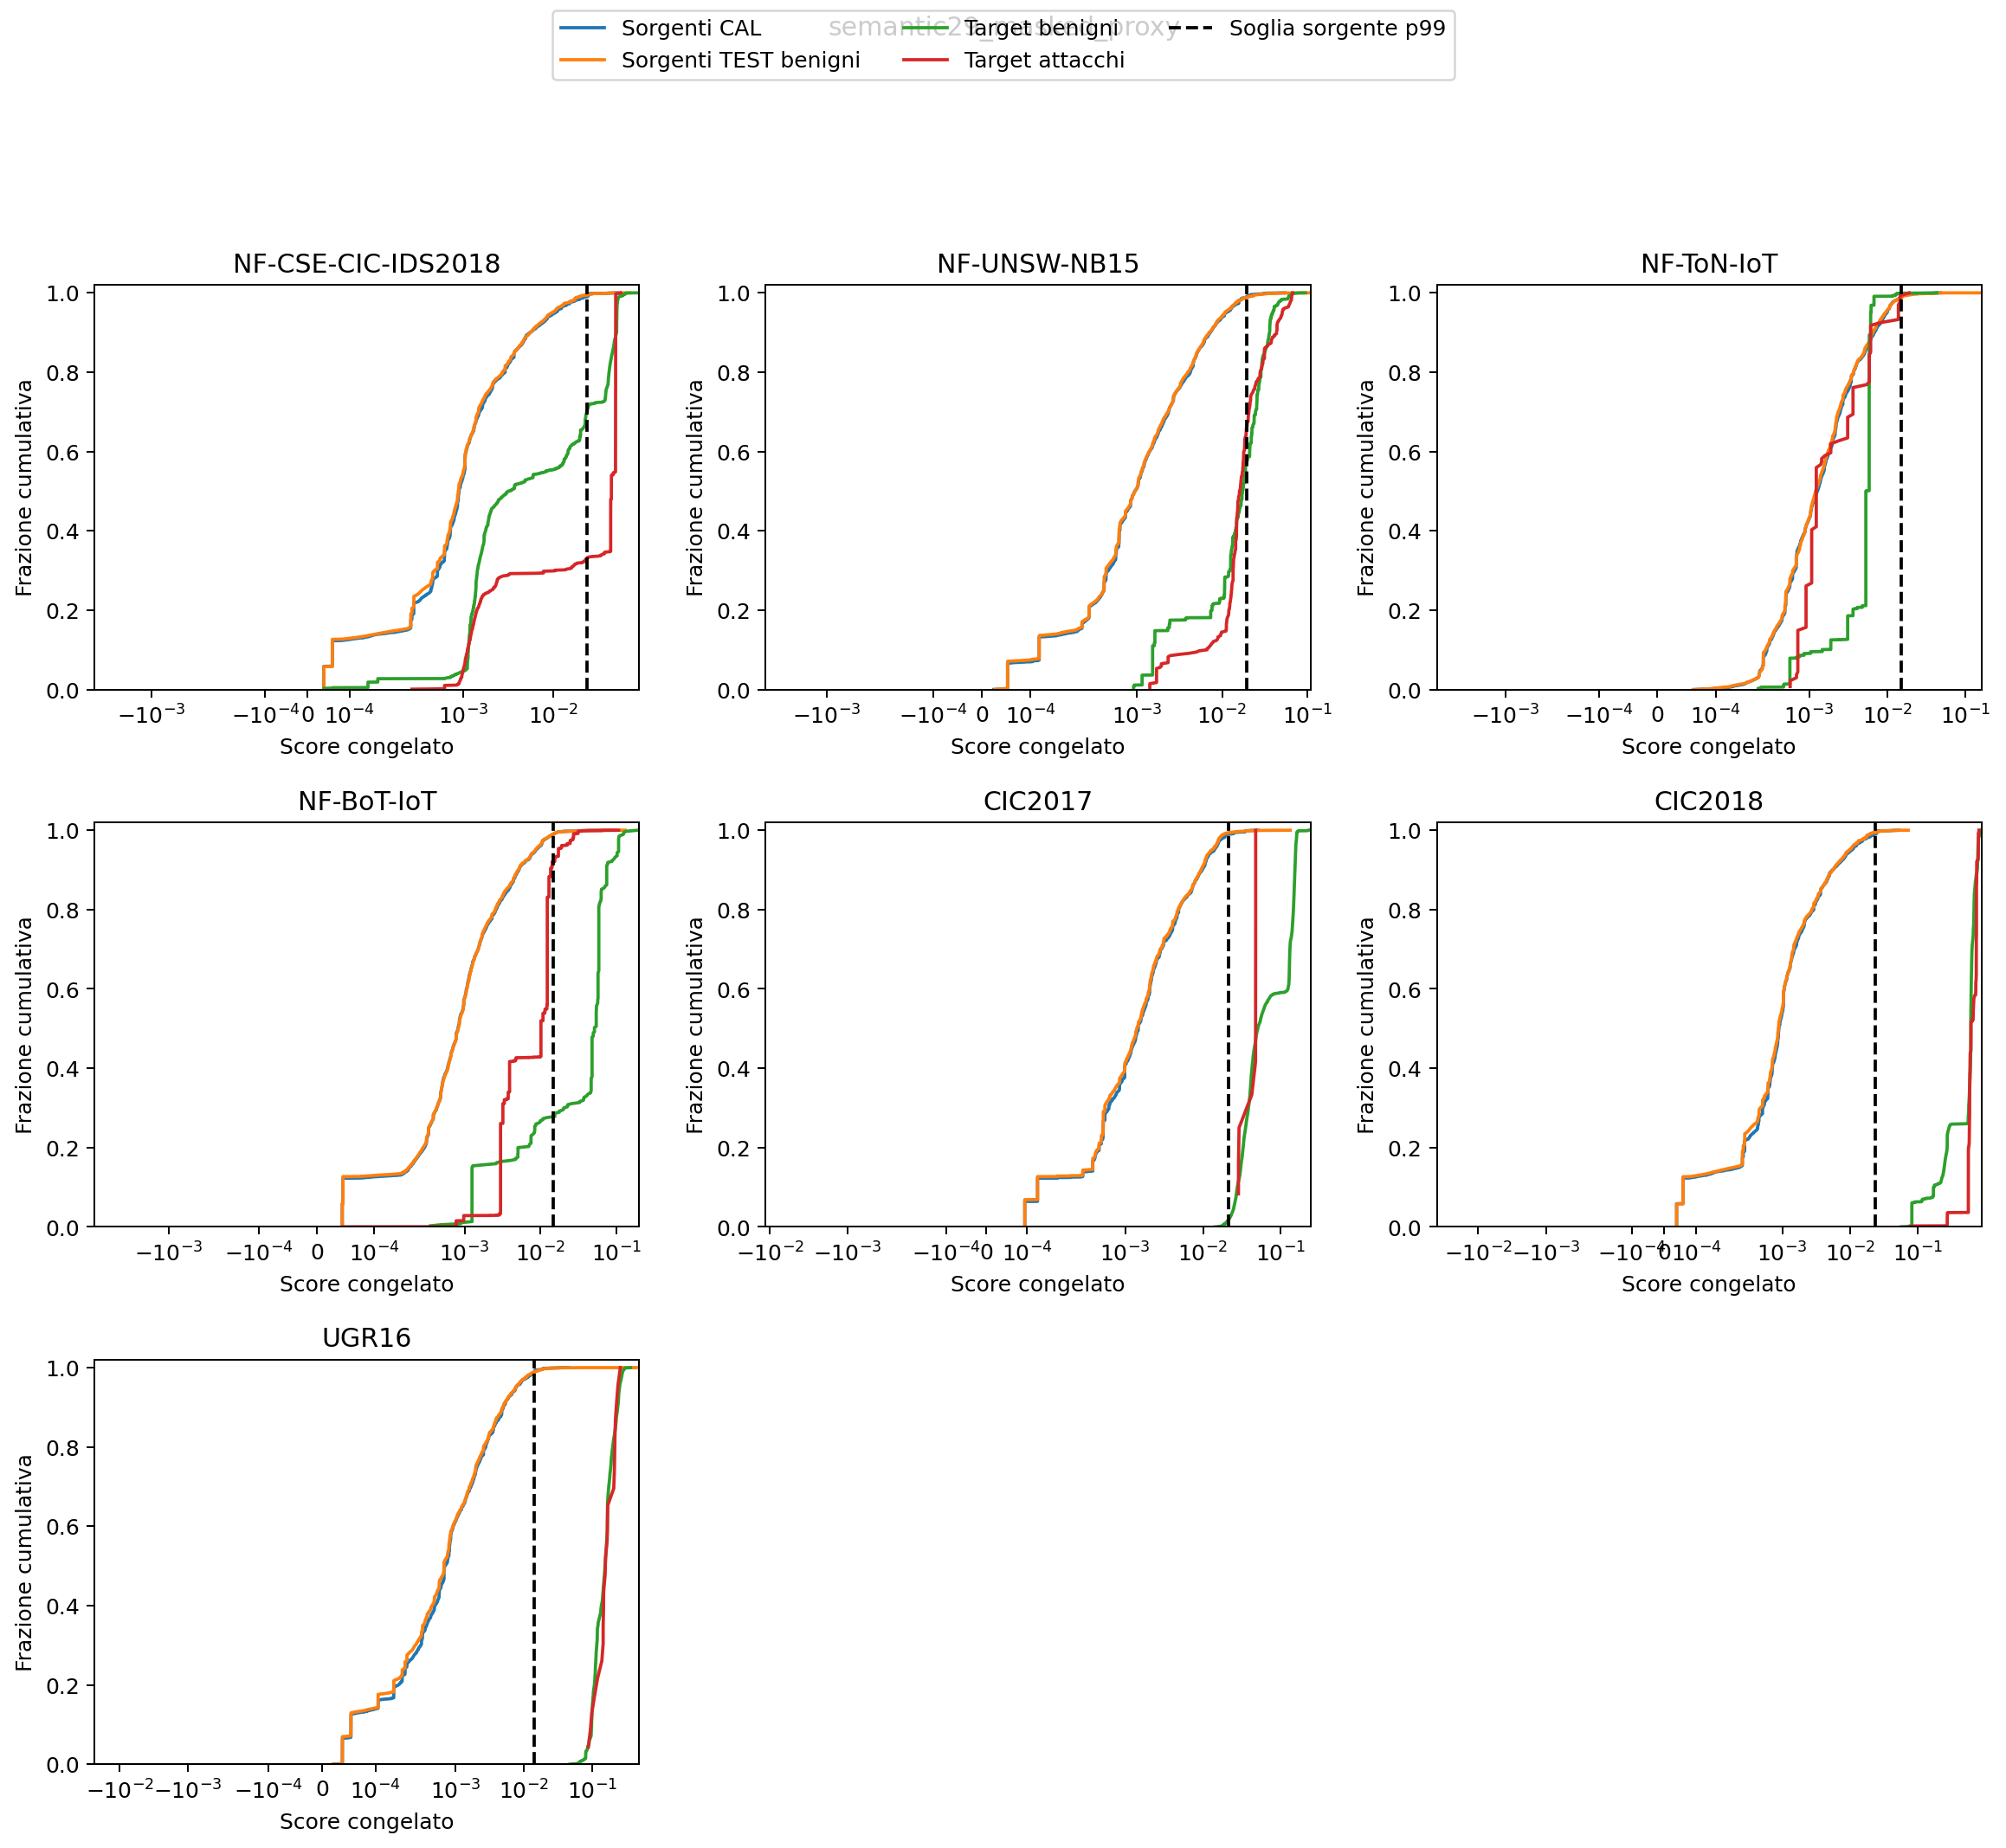

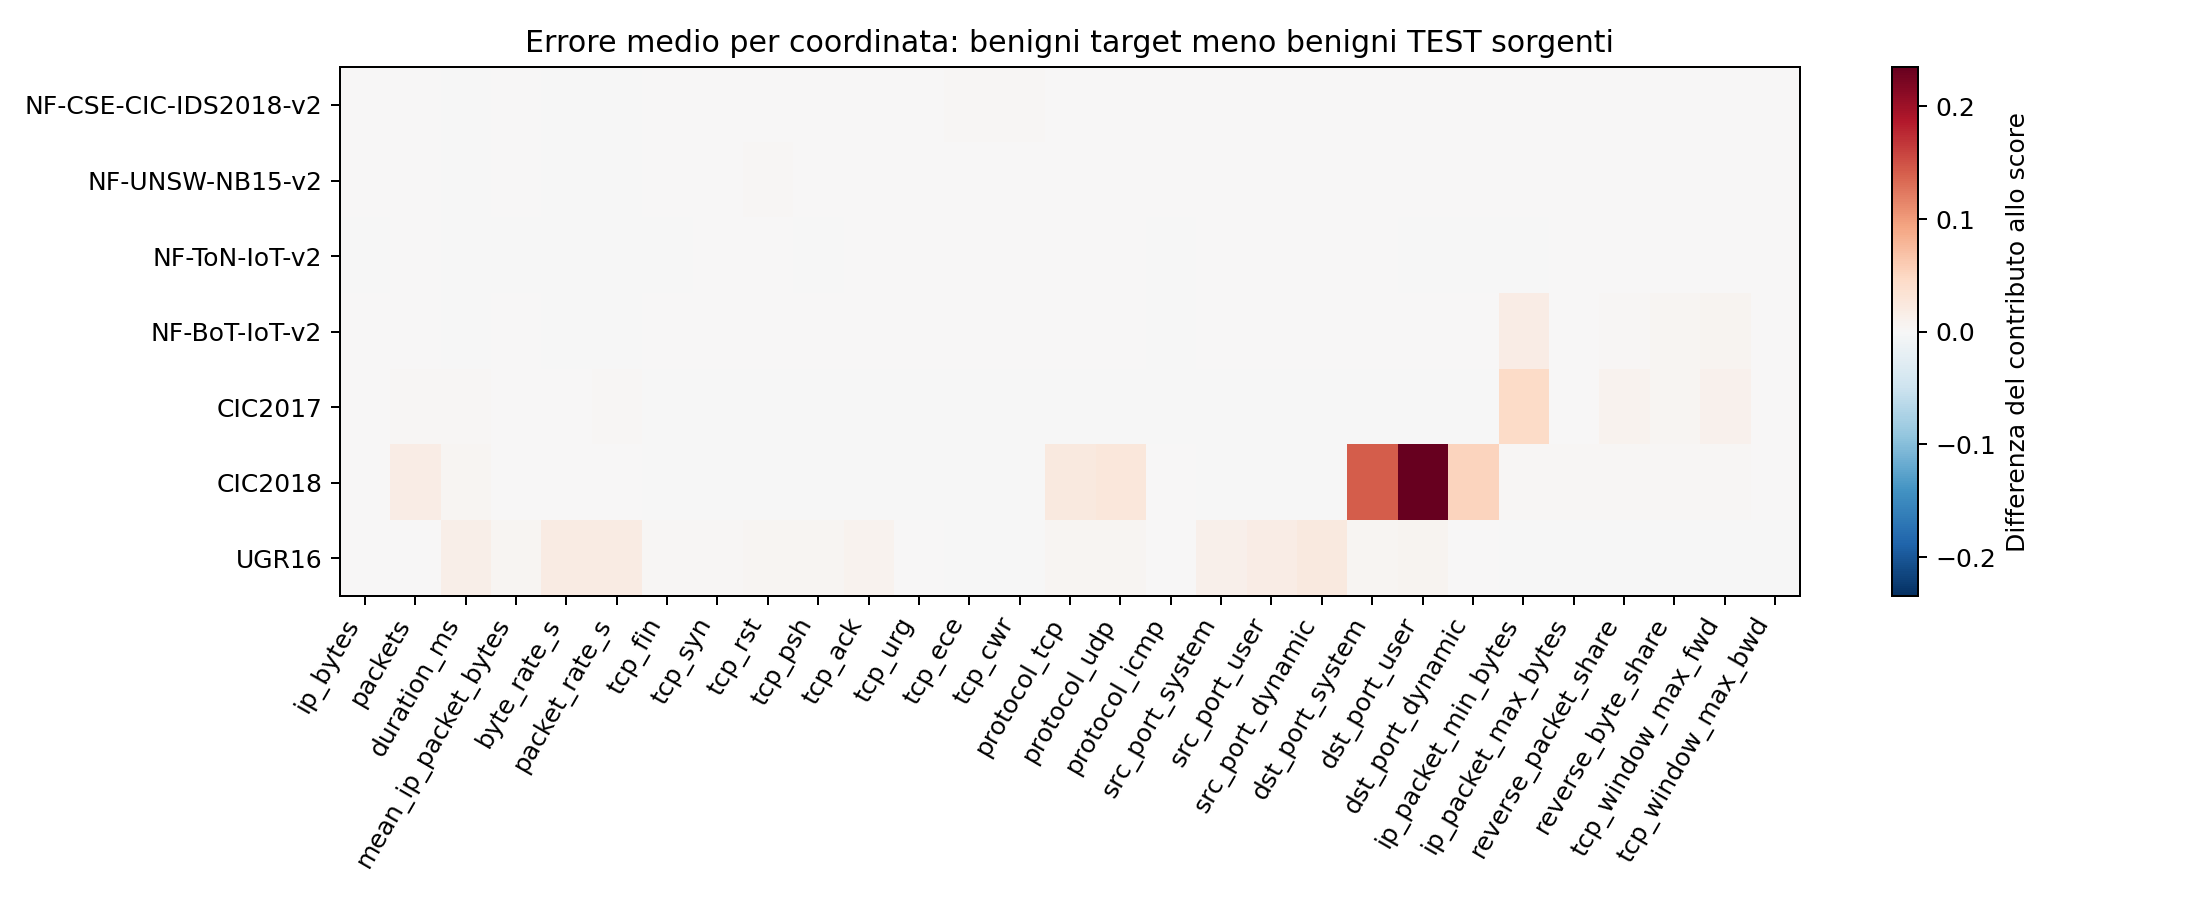

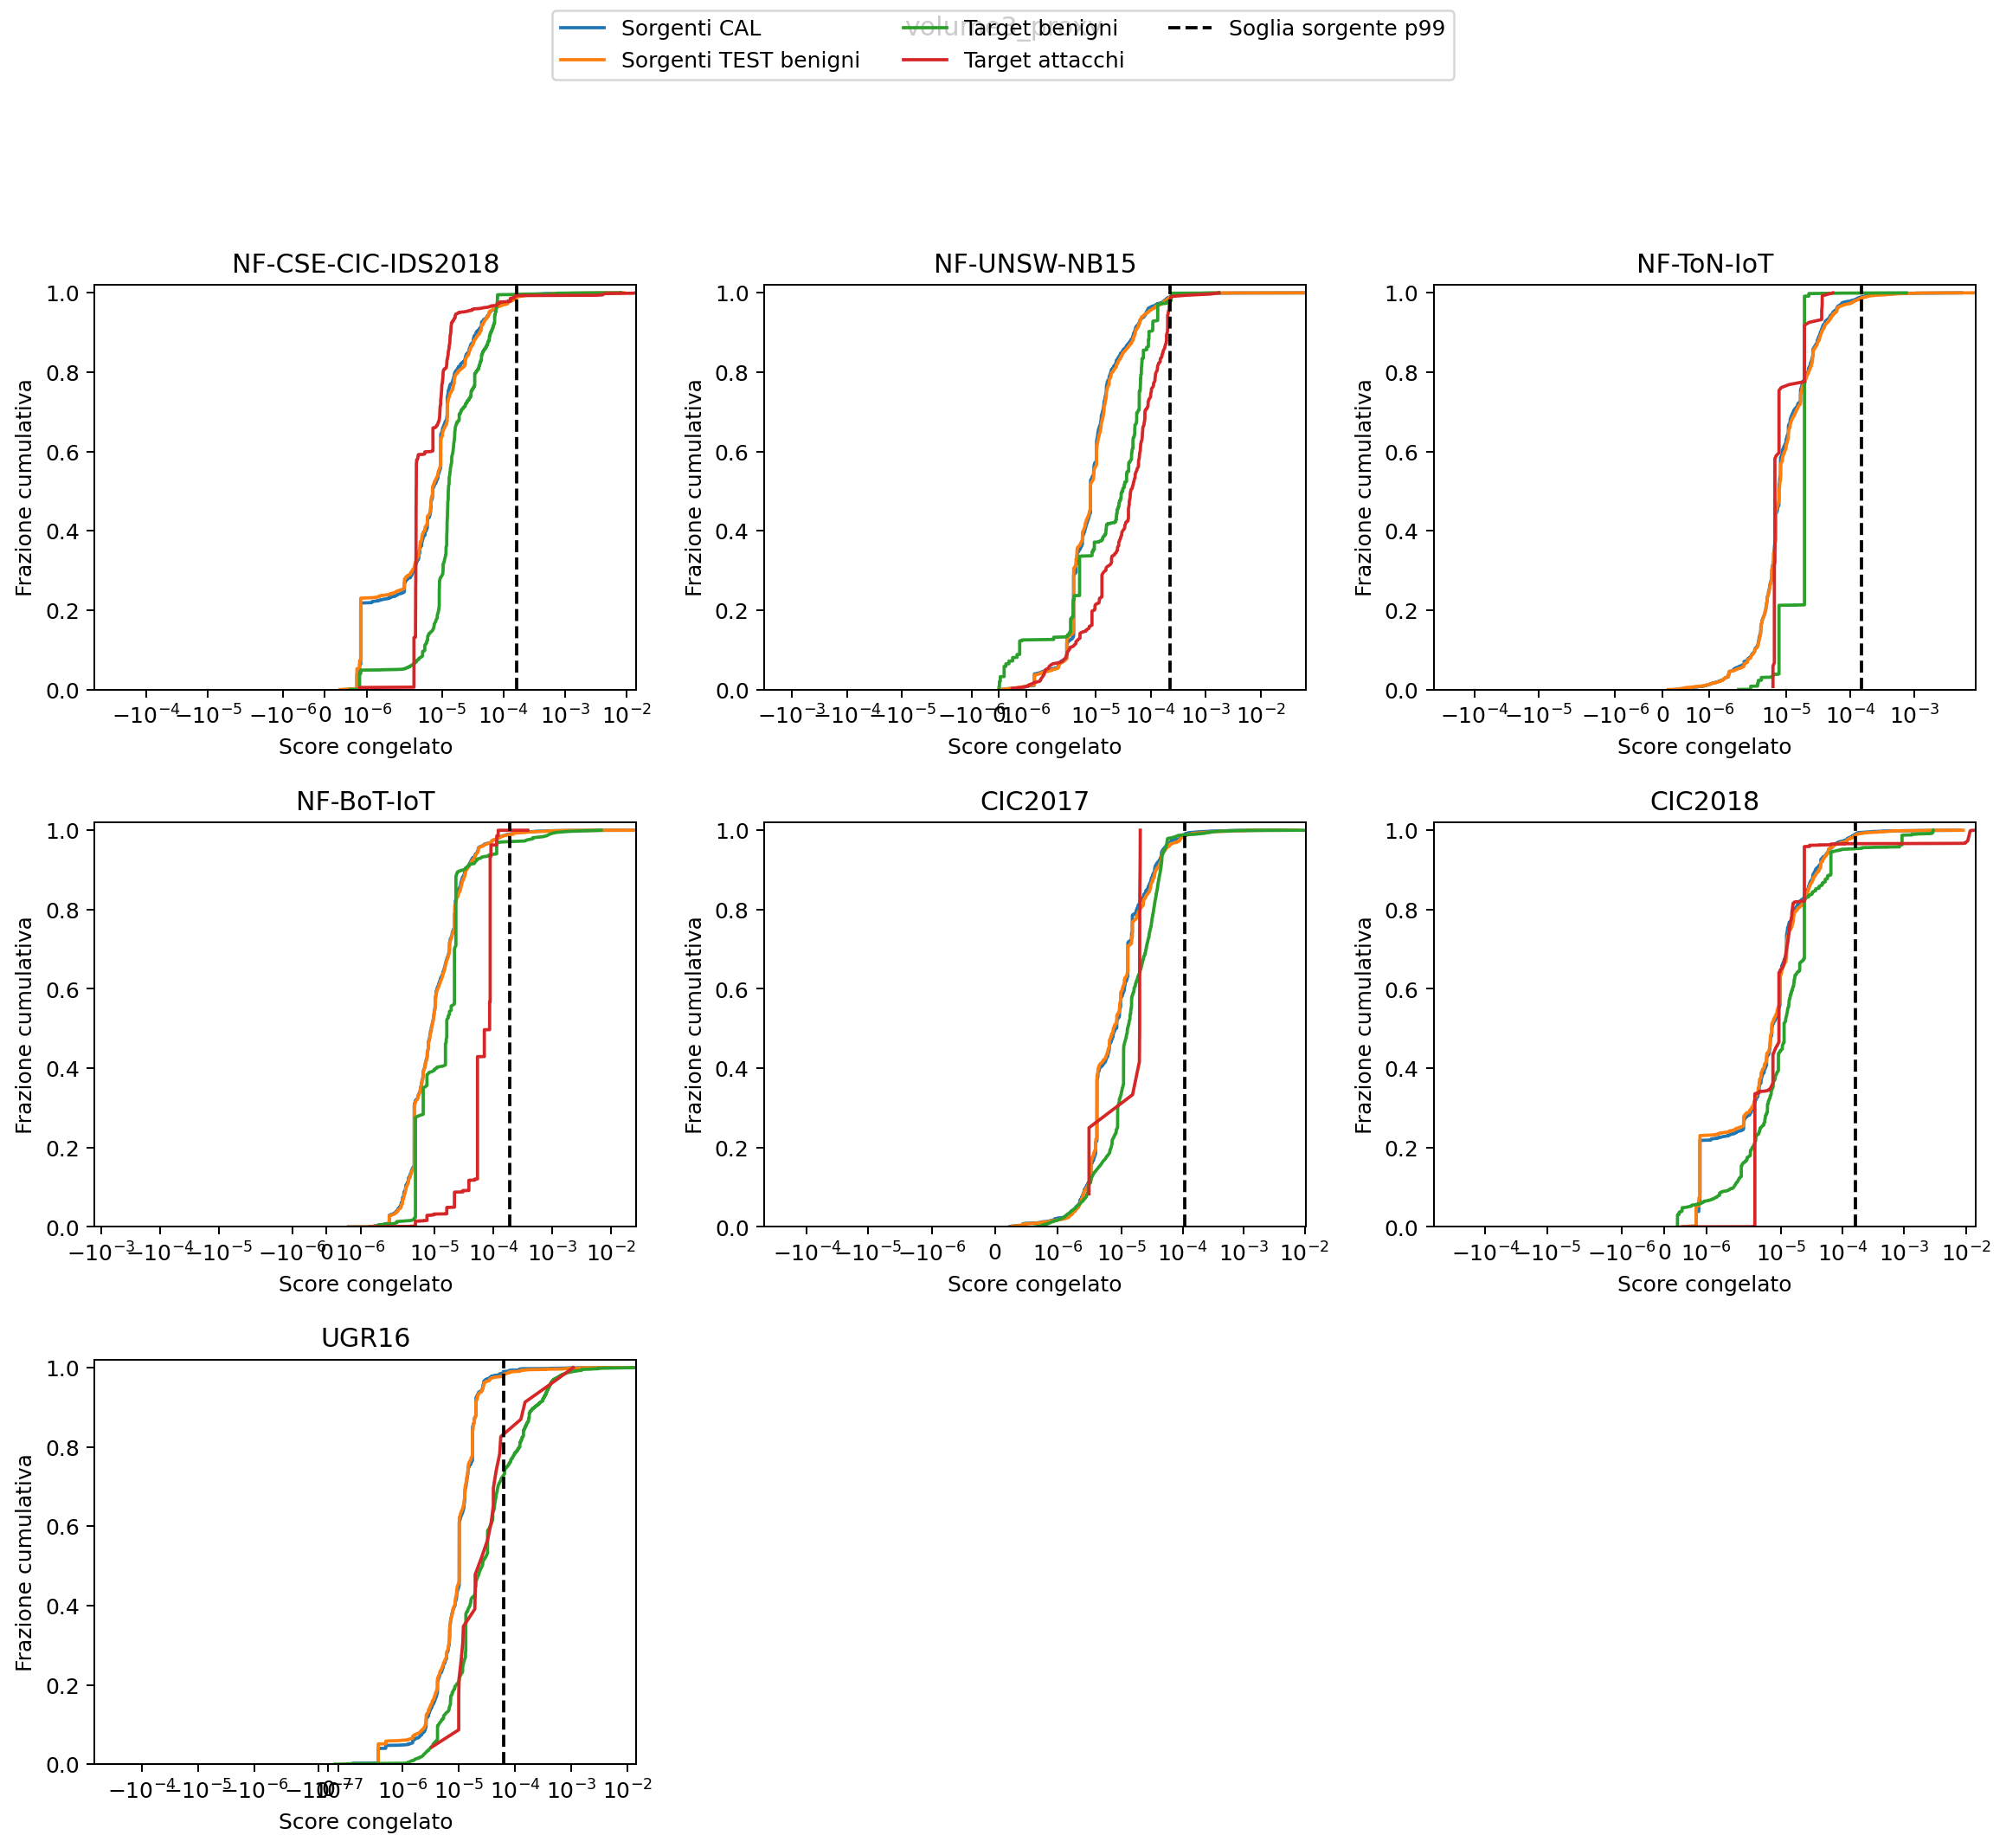

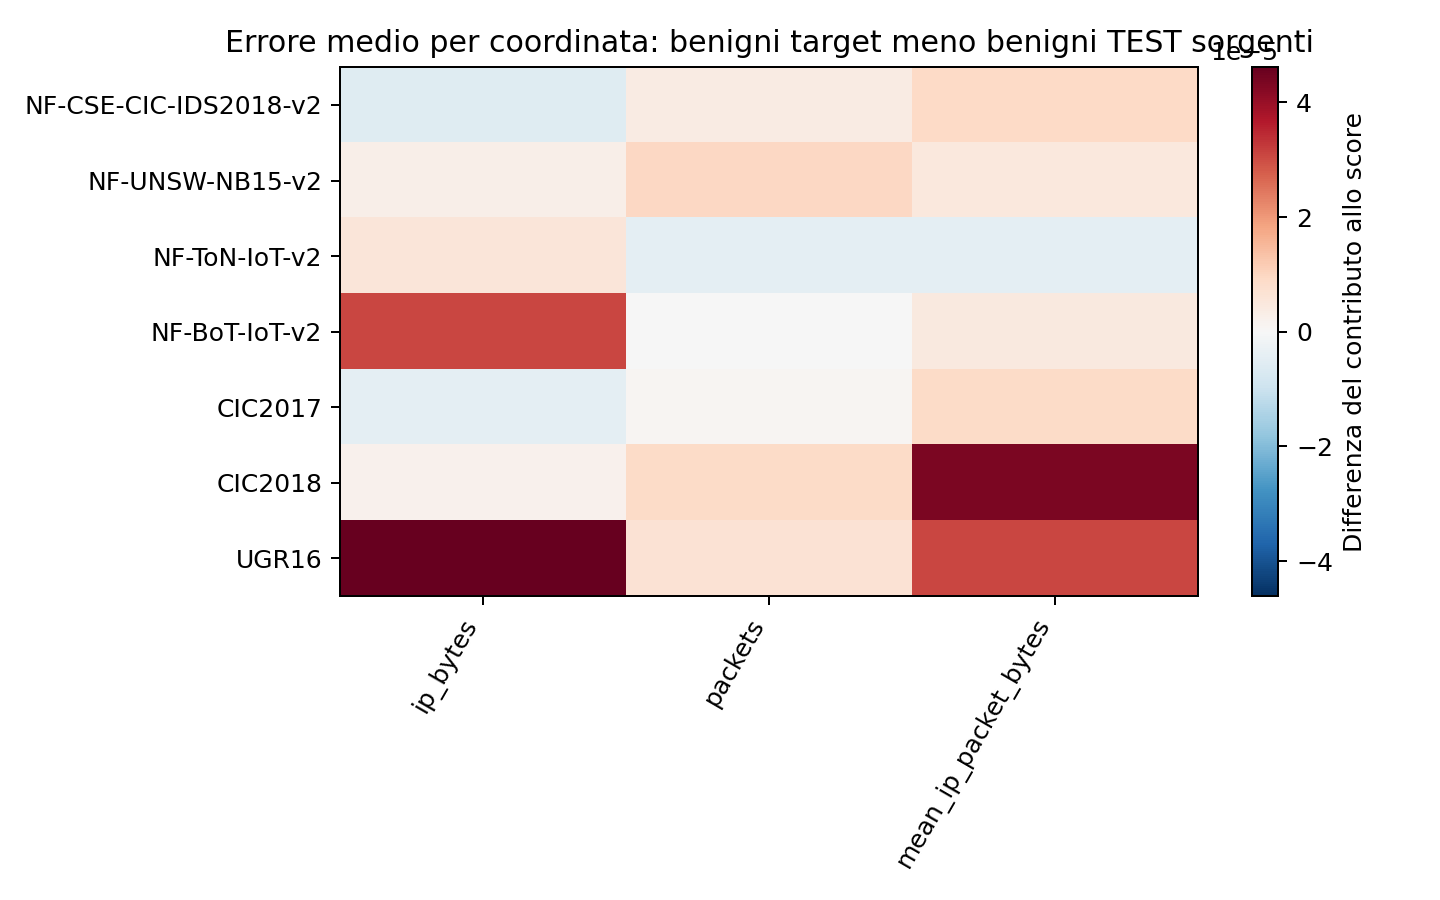
